In [ ]:
from pathlib import Path

DATASET_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

print("Dataset path:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())

Dataset path: /content/drive/MyDrive/Journal/Buet/Original Image
Dataset exists: True


# Data Preparation

In [ ]:
# ============================================================
# STEP 1: DATASET STRUCTURE + IMAGE COUNT
# ============================================================

from pathlib import Path
from collections import Counter

# Dataset path
DATASET_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

# Supported image extensions
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

print("=" * 70)
print("GASTROENDONET DATASET INSPECTION")
print("=" * 70)

print("\nDataset directory:")
print(DATASET_DIR)

print("\nDataset exists:")
print(DATASET_DIR.exists())


# ------------------------------------------------------------
# Check immediate folders
# ------------------------------------------------------------

class_dirs = sorted([
    folder
    for folder in DATASET_DIR.iterdir()
    if folder.is_dir()
])

print("\nDetected class folders:")
print("-" * 70)

for folder in class_dirs:
    print(folder.name)


# ------------------------------------------------------------
# Count images class-wise
# ------------------------------------------------------------

class_counts = {}

for class_dir in class_dirs:

    images = [
        file
        for file in class_dir.rglob("*")
        if file.is_file()
        and file.suffix.lower() in IMAGE_EXTENSIONS
    ]

    class_counts[class_dir.name] = len(images)


# ------------------------------------------------------------
# Display class distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

total_images = 0

for class_name, count in class_counts.items():

    print(f"{class_name:<30} : {count:>6}")

    total_images += count


print("-" * 70)
print(f"{'TOTAL':<30} : {total_images:>6}")
print("=" * 70)


# ------------------------------------------------------------
# Dataset sanity information
# ------------------------------------------------------------

print("\nNumber of classes:", len(class_counts))
print("Total original images:", total_images)

GASTROENDONET DATASET INSPECTION

Dataset directory:
/content/drive/MyDrive/Journal/Buet/Original Image

Dataset exists:
True

Detected class folders:
----------------------------------------------------------------------
Gerd
Gerd Normal
Polyp
Polyp Normal

CLASS DISTRIBUTION
Gerd                           :    974
Gerd Normal                    :   1103
Polyp                          :    779
Polyp Normal                   :   1150
----------------------------------------------------------------------
TOTAL                          :   4006

Number of classes: 4
Total original images: 4006


Image integrity, resolution, and channel audit

In [ ]:
# ============================================================
# STEP 2: IMAGE INTEGRITY + RESOLUTION + CHANNEL AUDIT
# ============================================================

from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict
import pandas as pd

DATASET_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

records = []
corrupted_files = []

print("=" * 75)
print("IMAGE INTEGRITY AND TECHNICAL AUDIT")
print("=" * 75)

# ------------------------------------------------------------
# Scan every image
# ------------------------------------------------------------

for class_dir in sorted(DATASET_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    class_name = class_dir.name

    image_files = [
        p for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    print(f"\nChecking {class_name}: {len(image_files)} images")

    for image_path in image_files:

        try:
            with Image.open(image_path) as img:

                width, height = img.size
                mode = img.mode

                records.append({
                    "class": class_name,
                    "filename": image_path.name,
                    "path": str(image_path),
                    "width": width,
                    "height": height,
                    "mode": mode,
                    "aspect_ratio": round(width / height, 4)
                })

        except Exception as e:

            corrupted_files.append({
                "class": class_name,
                "filename": image_path.name,
                "path": str(image_path),
                "error": str(e)
            })


# ------------------------------------------------------------
# Convert to dataframe
# ------------------------------------------------------------

df_audit = pd.DataFrame(records)

print("\n" + "=" * 75)
print("AUDIT SUMMARY")
print("=" * 75)

print(f"\nSuccessfully readable images : {len(df_audit)}")
print(f"Corrupted/unreadable images  : {len(corrupted_files)}")


# ------------------------------------------------------------
# Class-wise count
# ------------------------------------------------------------

print("\nClass-wise readable images:")
print("-" * 75)

print(df_audit["class"].value_counts().sort_index())


# ------------------------------------------------------------
# Image modes
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("IMAGE COLOR MODES")
print("=" * 75)

print(df_audit["mode"].value_counts())


# ------------------------------------------------------------
# Resolution statistics
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("IMAGE RESOLUTION STATISTICS")
print("=" * 75)

print(
    df_audit[
        ["width", "height", "aspect_ratio"]
    ].describe().round(3)
)


# ------------------------------------------------------------
# Unique resolutions
# ------------------------------------------------------------

resolution_counts = (
    df_audit
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
)

print("\nNumber of unique resolutions:",
      len(resolution_counts))

print("\nTop 10 most common resolutions:")
print("-" * 75)

print(resolution_counts.head(10))


# ------------------------------------------------------------
# Per-class resolution summary
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PER-CLASS RESOLUTION SUMMARY")
print("=" * 75)

class_resolution_summary = (
    df_audit
    .groupby("class")
    .agg(
        images=("filename", "count"),
        min_width=("width", "min"),
        max_width=("width", "max"),
        min_height=("height", "min"),
        max_height=("height", "max"),
        mean_width=("width", "mean"),
        mean_height=("height", "mean")
    )
    .round(2)
)

print(class_resolution_summary)


# ------------------------------------------------------------
# Corrupted images
# ------------------------------------------------------------

if len(corrupted_files) > 0:

    print("\n" + "=" * 75)
    print("WARNING: CORRUPTED FILES FOUND")
    print("=" * 75)

    corrupted_df = pd.DataFrame(corrupted_files)
    print(corrupted_df)

else:

    print("\n✓ No corrupted images detected.")


print("\n" + "=" * 75)
print("STEP 2 COMPLETED")
print("=" * 75)

IMAGE INTEGRITY AND TECHNICAL AUDIT

Checking Gerd: 974 images

Checking Gerd Normal: 1103 images

Checking Polyp: 779 images

Checking Polyp Normal: 1150 images

AUDIT SUMMARY

Successfully readable images : 4006
Corrupted/unreadable images  : 0

Class-wise readable images:
---------------------------------------------------------------------------
class
Gerd             974
Gerd Normal     1103
Polyp            779
Polyp Normal    1150
Name: count, dtype: int64

IMAGE COLOR MODES
mode
RGB    4006
Name: count, dtype: int64

IMAGE RESOLUTION STATISTICS
          width    height  aspect_ratio
count  4006.000  4006.000      4006.000
mean    552.927   510.967         1.082
std       9.572     6.563         0.025
min     549.000   498.000         1.065
25%     549.000   510.000         1.076
50%     549.000   510.000         1.076
75%     549.000   510.000         1.076
max     720.000   576.000         1.250

Number of unique resolutions: 4

Top 10 most common resolutions:
---------------

Create and permanently save the locked split

In [ ]:
# ============================================================
# STEP 3: CREATE LOCKED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import json

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

DATASET_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

SPLIT_DIR = PROJECT_DIR / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff", ".webp"
}

# Fixed class mapping
CLASS_TO_ID = {
    "Gerd": 0,
    "Gerd Normal": 1,
    "Polyp": 2,
    "Polyp Normal": 3
}

print("=" * 75)
print("CREATING LOCKED DATA SPLIT")
print("=" * 75)


# ============================================================
# 1. COLLECT ALL ORIGINAL IMAGES
# ============================================================

records = []

for class_name, class_id in CLASS_TO_ID.items():

    class_dir = DATASET_DIR / class_name

    image_files = sorted([
        p for p in class_dir.rglob("*")
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    for image_path in image_files:

        records.append({
            "filepath": str(image_path),
            "filename": image_path.name,
            "class_name": class_name,
            "class_id": class_id
        })


df = pd.DataFrame(records)

print("\nTotal images collected:", len(df))

print("\nOriginal class distribution:")
print(
    df["class_name"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 2. FIRST SPLIT
#    80% development
#    20% locked test
# ============================================================

development_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=df["class_name"]
)


# ============================================================
# 3. DEVELOPMENT SPLIT
#
# From the remaining 80%:
#
# 87.5% -> train
# 12.5% -> validation
#
# Overall:
# 70% train
# 10% validation
# 20% test
# ============================================================

train_df, val_df = train_test_split(
    development_df,
    test_size=0.125,
    random_state=RANDOM_SEED,
    stratify=development_df["class_name"]
)


# ============================================================
# 4. ADD SPLIT LABEL
# ============================================================

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"


# ============================================================
# 5. COMBINE INTO ONE MASTER MANIFEST
# ============================================================

locked_split_df = pd.concat(
    [
        train_df,
        val_df,
        test_df
    ],
    ignore_index=True
)

# Sort only for clean storage
locked_split_df = locked_split_df.sort_values(
    ["split", "class_id", "filename"]
).reset_index(drop=True)


# ============================================================
# 6. SAFETY CHECKS
# ============================================================

assert len(locked_split_df) == 4006

assert (
    locked_split_df["filepath"].nunique()
    == len(locked_split_df)
)

assert set(
    locked_split_df["split"].unique()
) == {"train", "val", "test"}

print("\n✓ Split integrity checks passed.")


# ============================================================
# 7. DISPLAY SPLIT SIZE
# ============================================================

print("\n" + "=" * 75)
print("SPLIT SIZE")
print("=" * 75)

split_counts = (
    locked_split_df["split"]
    .value_counts()
    .reindex(["train", "val", "test"])
)

print(split_counts)

print("\nPercentages:")

for split_name in ["train", "val", "test"]:

    count = split_counts[split_name]
    percentage = 100 * count / len(locked_split_df)

    print(
        f"{split_name:<10}: "
        f"{count:>4} images "
        f"({percentage:.2f}%)"
    )


# ============================================================
# 8. CLASS DISTRIBUTION PER SPLIT
# ============================================================

print("\n" + "=" * 75)
print("CLASS DISTRIBUTION PER SPLIT")
print("=" * 75)

distribution = pd.crosstab(
    locked_split_df["class_name"],
    locked_split_df["split"]
)

distribution = distribution[
    ["train", "val", "test"]
]

distribution["Total"] = (
    distribution["train"]
    + distribution["val"]
    + distribution["test"]
)

print(distribution)


# ============================================================
# 9. SAVE INDIVIDUAL CSV FILES
# ============================================================

train_df.to_csv(
    SPLIT_DIR / "train.csv",
    index=False
)

val_df.to_csv(
    SPLIT_DIR / "val.csv",
    index=False
)

test_df.to_csv(
    SPLIT_DIR / "test.csv",
    index=False
)

locked_split_df.to_csv(
    SPLIT_DIR / "locked_split.csv",
    index=False
)


# ============================================================
# 10. SAVE EXPERIMENT METADATA
# ============================================================

metadata = {

    "dataset": "GastroEndoNet Version 3",

    "total_original_images": 4006,

    "random_seed": RANDOM_SEED,

    "split_strategy": {
        "train": 0.70,
        "validation": 0.10,
        "test": 0.20
    },

    "image_size": [
        384,
        384
    ],

    "class_mapping": CLASS_TO_ID,

    "important_rule":
        "Test set contains only original real images "
        "and remains locked for experiments E0-E8."
}


with open(
    SPLIT_DIR / "split_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# ============================================================
# 11. FINAL OUTPUT
# ============================================================

print("\n" + "=" * 75)
print("FILES SAVED")
print("=" * 75)

print(SPLIT_DIR / "train.csv")
print(SPLIT_DIR / "val.csv")
print(SPLIT_DIR / "test.csv")
print(SPLIT_DIR / "locked_split.csv")
print(SPLIT_DIR / "split_metadata.json")

print("\n✓ LOCKED SPLIT CREATED SUCCESSFULLY")
print("✓ DO NOT regenerate this split for later experiments.")
print("✓ E0-E8 must use these same validation/test images.")

CREATING LOCKED DATA SPLIT

Total images collected: 4006

Original class distribution:
class_name
Gerd             974
Gerd Normal     1103
Polyp            779
Polyp Normal    1150
Name: count, dtype: int64

✓ Split integrity checks passed.

SPLIT SIZE
split
train    2803
val       401
test      802
Name: count, dtype: int64

Percentages:
train     : 2803 images (69.97%)
val       :  401 images (10.01%)
test      :  802 images (20.02%)

CLASS DISTRIBUTION PER SPLIT
split         train  val  test  Total
class_name                           
Gerd            681   98   195    974
Gerd Normal     772  110   221   1103
Polyp           545   78   156    779
Polyp Normal    805  115   230   1150

FILES SAVED
/content/drive/MyDrive/Journal/Buet/GI_SAFE/splits/train.csv
/content/drive/MyDrive/Journal/Buet/GI_SAFE/splits/val.csv
/content/drive/MyDrive/Journal/Buet/GI_SAFE/splits/test.csv
/content/drive/MyDrive/Journal/Buet/GI_SAFE/splits/locked_split.csv
/content/drive/MyDrive/Journal/Buet/GI_S

# E0: Real Images Only.

Build E0 data pipeline

In [ ]:
# ============================================================
# STEP 4 — E0 DATA PIPELINE
# REAL IMAGES ONLY — NO AUGMENTATION
# ============================================================

import random
import numpy as np
import pandas as pd
import torch

from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF


# ============================================================
# 1. CONFIGURATION
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

SPLIT_DIR = PROJECT_DIR / "splits"

TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV   = SPLIT_DIR / "val.csv"
TEST_CSV  = SPLIT_DIR / "test.csv"

IMAGE_SIZE = 384
BATCH_SIZE = 16
NUM_WORKERS = 2
SEED = 42


CLASS_NAMES = [
    "Gerd",
    "Gerd Normal",
    "Polyp",
    "Polyp Normal"
]

NUM_CLASSES = len(CLASS_NAMES)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print("Random seed:", SEED)


# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 4. LOAD LOCKED SPLITS
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("\nLocked dataset sizes:")
print("Train :", len(train_df))
print("Val   :", len(val_df))
print("Test  :", len(test_df))


# ============================================================
# 5. ASPECT-RATIO PRESERVING RESIZE + PADDING
# ============================================================

class ResizeWithPadding:

    def __init__(self, size=384):

        self.size = size

    def __call__(self, image):

        width, height = image.size

        # Scale longest side to target size
        scale = self.size / max(width, height)

        new_width = int(round(width * scale))
        new_height = int(round(height * scale))

        image = image.resize(
            (new_width, new_height),
            Image.Resampling.BILINEAR
        )

        # Calculate padding
        pad_left = (self.size - new_width) // 2
        pad_right = self.size - new_width - pad_left

        pad_top = (self.size - new_height) // 2
        pad_bottom = self.size - new_height - pad_top

        image = TF.pad(
            image,
            [
                pad_left,
                pad_top,
                pad_right,
                pad_bottom
            ],
            fill=0
        )

        return image


# ============================================================
# 6. E0 TRANSFORM
#
# IMPORTANT:
# No random rotation
# No flip
# No crop
# No brightness modification
# No MixUp
# No CutMix
#
# This is REAL-ONLY baseline.
# ============================================================

e0_transform = transforms.Compose([

    ResizeWithPadding(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 7. CUSTOM DATASET
# ============================================================

class GastroEndoDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row["filepath"]
        label = int(row["class_id"])

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:

            image = self.transform(image)

        return image, label


# ============================================================
# 8. CREATE DATASETS
# ============================================================

train_dataset = GastroEndoDataset(
    train_df,
    transform=e0_transform
)

val_dataset = GastroEndoDataset(
    val_df,
    transform=e0_transform
)

test_dataset = GastroEndoDataset(
    test_df,
    transform=e0_transform
)


print("\nDataset objects:")
print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))


# ============================================================
# 9. CREATE DATA LOADERS
# ============================================================

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# 10. CLASS WEIGHTS
#
# Computed using TRAINING SET ONLY.
# Same weighting strategy should remain fixed for comparisons.
# ============================================================

class_counts = (
    train_df["class_id"]
    .value_counts()
    .sort_index()
    .values
)

total_train = len(train_df)

class_weights = (
    total_train /
    (NUM_CLASSES * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


print("\nTraining class counts:")

for i, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name:<15}: "
        f"{class_counts[i]:>4}"
    )


print("\nClass weights:")

for i, class_name in enumerate(CLASS_NAMES):

    print(
        f"{class_name:<15}: "
        f"{class_weights[i].item():.4f}"
    )


# ============================================================
# 11. BATCH SANITY CHECK
# ============================================================

images, labels = next(iter(train_loader))

print("\n" + "=" * 70)
print("BATCH SANITY CHECK")
print("=" * 70)

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

print(
    "Image dtype       :",
    images.dtype
)

print(
    "Label dtype       :",
    labels.dtype
)

print(
    "Labels in batch   :",
    labels.tolist()
)

print(
    "Minimum pixel     :",
    round(images.min().item(), 4)
)

print(
    "Maximum pixel     :",
    round(images.max().item(), 4)
)


# ============================================================
# 12. FINAL CHECKS
# ============================================================

assert images.shape[1] == 3
assert images.shape[2] == IMAGE_SIZE
assert images.shape[3] == IMAGE_SIZE

assert labels.min() >= 0
assert labels.max() < NUM_CLASSES

assert len(train_dataset) == 2803
assert len(val_dataset) == 401
assert len(test_dataset) == 802


print("\n✓ E0 DATA PIPELINE READY")
print("✓ Input resolution: 384 × 384")
print("✓ Aspect ratio preserved")
print("✓ Padding applied")
print("✓ ImageNet normalization applied")
print("✓ NO data augmentation")
print("✓ Locked validation/test sets loaded")

Random seed: 42
Device: cuda
GPU: NVIDIA A100-SXM4-40GB

Locked dataset sizes:
Train : 2803
Val   : 401
Test  : 802

Dataset objects:
Train : 2803
Val   : 401
Test  : 802

Training class counts:
Gerd           :  681
Gerd Normal    :  772
Polyp          :  545
Polyp Normal   :  805

Class weights:
Gerd           : 1.0290
Gerd Normal    : 0.9077
Polyp          : 1.2858
Polyp Normal   : 0.8705

BATCH SANITY CHECK
Image batch shape : torch.Size([16, 3, 384, 384])
Label batch shape : torch.Size([16])
Image dtype       : torch.float32
Label dtype       : torch.int64
Labels in batch   : [0, 3, 3, 0, 2, 0, 3, 3, 1, 3, 0, 3, 2, 2, 0, 3]
Minimum pixel     : -2.1179
Maximum pixel     : 2.64

✓ E0 DATA PIPELINE READY
✓ Input resolution: 384 × 384
✓ Aspect ratio preserved
✓ Padding applied
✓ ImageNet normalization applied
✓ NO data augmentation
✓ Locked validation/test sets loaded


ImageNet pretrained ResNet-50 → full fine-tuning → weighted CrossEntropy → AdamW → validation-based LR reduction.

In [ ]:
# ============================================================
# STEP 5 — E0 RESNET-50 MODEL SETUP
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models

from pathlib import Path


# ============================================================
# 1. EXPERIMENT CONFIGURATION
# ============================================================

EXPERIMENT_NAME = "E0_ResNet50_RealOnly"

E0_DIR = PROJECT_DIR / "experiments" / EXPERIMENT_NAME
CHECKPOINT_DIR = E0_DIR / "checkpoints"
RESULT_DIR = E0_DIR / "results"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)


NUM_EPOCHS = 30

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

PATIENCE = 7


print("=" * 75)
print("E0 — RESNET-50 REAL-ONLY BASELINE")
print("=" * 75)

print("\nExperiment:", EXPERIMENT_NAME)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Early stopping patience:", PATIENCE)


# ============================================================
# 2. LOAD IMAGENET-PRETRAINED RESNET-50
# ============================================================

weights = models.ResNet50_Weights.IMAGENET1K_V2

model = models.resnet50(
    weights=weights
)


# ============================================================
# 3. REPLACE CLASSIFICATION HEAD
# ============================================================

in_features = model.fc.in_features

model.fc = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(device)


print("\nModel:")
print("ResNet-50")

print(
    "Original FC features:",
    in_features
)

print(
    "Number of output classes:",
    NUM_CLASSES
)


# ============================================================
# 4. FULL FINE-TUNING
#
# Every layer remains trainable.
# ============================================================

for param in model.parameters():
    param.requires_grad = True


# ============================================================
# 5. LOSS FUNCTION
#
# Weighted CrossEntropy compensates for the moderate
# class imbalance.
#
# NO label smoothing for E0.
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# 6. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 7. LEARNING-RATE SCHEDULER
#
# Reduce LR if validation Macro-F1 stops improving.
# ============================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-7
)


# ============================================================
# 8. PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\n" + "=" * 75)
print("MODEL COMPLEXITY")
print("=" * 75)

print(
    f"Total parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)


# ============================================================
# 9. CHECK MODEL OUTPUT
# ============================================================

model.eval()

with torch.no_grad():

    sample_images, _ = next(iter(train_loader))

    sample_images = sample_images.to(device)

    sample_output = model(sample_images[:2])


print("\n" + "=" * 75)
print("FORWARD-PASS CHECK")
print("=" * 75)

print(
    "Input shape :",
    sample_images[:2].shape
)

print(
    "Output shape:",
    sample_output.shape
)

assert sample_output.shape == (
    2,
    NUM_CLASSES
)


# ============================================================
# 10. MIXED PRECISION
#
# A100 supports AMP very efficiently.
# ============================================================

AMP_ENABLED = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)


print(
    "\nMixed precision:",
    AMP_ENABLED
)


# ============================================================
# 11. CHECKPOINT PATH
# ============================================================

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e0.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_resnet50_e0.pth"
)


print("\nBest model will be saved to:")
print(BEST_MODEL_PATH)

print("\nLast model will be saved to:")
print(LAST_MODEL_PATH)


# ============================================================
# 12. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("E0 MODEL CONFIGURATION READY")
print("=" * 75)

print("Backbone          : ResNet-50")
print("Initialization    : ImageNet-1K V2")
print("Input             : 384 × 384")
print("Classes           : 4")
print("Training strategy : Full fine-tuning")
print("Loss              : Weighted CrossEntropy")
print("Optimizer         : AdamW")
print("Initial LR        :", LEARNING_RATE)
print("Weight decay      :", WEIGHT_DECAY)
print("Scheduler         : ReduceLROnPlateau")
print("Monitor           : Validation Macro-F1")
print("Epochs            :", NUM_EPOCHS)
print("Early stopping    :", PATIENCE)
print("AMP               :", AMP_ENABLED)

print("\n✓ STEP 5 COMPLETED")
print("✓ E0 ResNet-50 is ready for training")

E0 — RESNET-50 REAL-ONLY BASELINE

Experiment: E0_ResNet50_RealOnly
Epochs: 30
Learning rate: 0.0001
Weight decay: 0.0001
Early stopping patience: 7
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]



Model:
ResNet-50
Original FC features: 2048
Number of output classes: 4

MODEL COMPLEXITY
Total parameters     : 23,516,228
Trainable parameters : 23,516,228

FORWARD-PASS CHECK
Input shape : torch.Size([2, 3, 384, 384])
Output shape: torch.Size([2, 4])

Mixed precision: True

Best model will be saved to:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResNet50_RealOnly/checkpoints/best_resnet50_e0.pth

Last model will be saved to:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResNet50_RealOnly/checkpoints/last_resnet50_e0.pth

E0 MODEL CONFIGURATION READY
Backbone          : ResNet-50
Initialization    : ImageNet-1K V2
Input             : 384 × 384
Classes           : 4
Training strategy : Full fine-tuning
Loss              : Weighted CrossEntropy
Optimizer         : AdamW
Initial LR        : 0.0001
Weight decay      : 0.0001
Scheduler         : ReduceLROnPlateau
Monitor           : Validation Macro-F1
Epochs            : 30
Early stopping    : 7
AMP          

Train E0 ResNet-50

In [ ]:
# ============================================================
# STEP 6 — E0 RESNET-50 TRAINING ENGINE
# REAL IMAGES ONLY
# ============================================================

import time
import json
import copy
import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. EXPECTED CALIBRATION ERROR
# ============================================================

def expected_calibration_error(
    y_true,
    probabilities,
    n_bins=15
):
    """
    Multiclass ECE using maximum predicted probability.
    """

    confidences = np.max(probabilities, axis=1)
    predictions = np.argmax(probabilities, axis=1)

    correctness = (predictions == y_true).astype(float)

    bin_edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    ece = 0.0

    for i in range(n_bins):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:
            mask = (
                (confidences >= lower) &
                (confidences <= upper)
            )
        else:
            mask = (
                (confidences > lower) &
                (confidences <= upper)
            )

        if np.any(mask):

            bin_accuracy = np.mean(
                correctness[mask]
            )

            bin_confidence = np.mean(
                confidences[mask]
            )

            bin_fraction = np.mean(mask)

            ece += (
                bin_fraction *
                abs(
                    bin_accuracy -
                    bin_confidence
                )
            )

    return float(ece)


# ============================================================
# 2. MULTICLASS BRIER SCORE
# ============================================================

def multiclass_brier_score(
    y_true,
    probabilities,
    num_classes
):
    """
    Multiclass Brier score:
    mean(sum((p_k - y_k)^2))
    """

    y_onehot = np.eye(
        num_classes
    )[y_true]

    score = np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1
        )
    )

    return float(score)


# ============================================================
# 3. FULL METRIC CALCULATION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred,
    probabilities,
    num_classes
):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    probabilities = np.asarray(probabilities)

    # --------------------------------------------------------
    # Standard metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    macro_precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )


    # --------------------------------------------------------
    # One-hot labels for AUROC / AUPRC
    # --------------------------------------------------------

    y_binary = label_binarize(
        y_true,
        classes=np.arange(num_classes)
    )


    # --------------------------------------------------------
    # Macro AUROC
    # --------------------------------------------------------

    try:

        macro_auc = roc_auc_score(
            y_binary,
            probabilities,
            average="macro",
            multi_class="ovr"
        )

    except ValueError:

        macro_auc = np.nan


    # --------------------------------------------------------
    # Macro AUPRC
    # --------------------------------------------------------

    try:

        macro_auprc = average_precision_score(
            y_binary,
            probabilities,
            average="macro"
        )

    except ValueError:

        macro_auprc = np.nan


    # --------------------------------------------------------
    # Calibration metrics
    # --------------------------------------------------------

    brier = multiclass_brier_score(
        y_true,
        probabilities,
        num_classes
    )

    ece = expected_calibration_error(
        y_true,
        probabilities,
        n_bins=15
    )

    nll = log_loss(
        y_true,
        probabilities,
        labels=np.arange(num_classes)
    )


    return {

        "accuracy":
            float(accuracy),

        "balanced_accuracy":
            float(balanced_acc),

        "macro_precision":
            float(macro_precision),

        "macro_recall":
            float(macro_recall),

        "macro_f1":
            float(macro_f1),

        "weighted_f1":
            float(weighted_f1),

        "mcc":
            float(mcc),

        "kappa":
            float(kappa),

        "macro_auroc":
            float(macro_auc),

        "macro_auprc":
            float(macro_auprc),

        "brier":
            float(brier),

        "ece":
            float(ece),

        "nll":
            float(nll)
    }


# ============================================================
# 4. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    all_targets = []
    all_predictions = []
    all_probabilities = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Mixed precision
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type="cuda",
            enabled=AMP_ENABLED
        ):

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        running_loss += (
            loss.item() *
            images.size(0)
        )


        # ----------------------------------------------------
        # Predictions
        # ----------------------------------------------------

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        all_targets.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

        all_probabilities.extend(
            probabilities.detach()
            .cpu()
            .numpy()
        )


    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )


    metrics = calculate_metrics(
        all_targets,
        all_predictions,
        all_probabilities,
        NUM_CLASSES
    )

    metrics["loss"] = float(
        epoch_loss
    )

    return metrics


# ============================================================
# 5. VALIDATION
# ============================================================

@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_predictions = []
    all_probabilities = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=AMP_ENABLED
        ):

            logits = model(images)

            loss = criterion(
                logits,
                labels
            )


        running_loss += (
            loss.item() *
            images.size(0)
        )


        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )


    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )


    metrics = calculate_metrics(
        all_targets,
        all_predictions,
        all_probabilities,
        NUM_CLASSES
    )

    metrics["loss"] = float(
        epoch_loss
    )


    return metrics


# ============================================================
# 6. TRAINING INITIALIZATION
# ============================================================

history = []

best_val_f1 = -1.0
best_epoch = 0

epochs_without_improvement = 0

training_start_time = time.perf_counter()


# Reset memory statistics
if torch.cuda.is_available():

    torch.cuda.reset_peak_memory_stats()


print("\n" + "=" * 110)
print("STARTING E0 RESNET-50 TRAINING")
print("=" * 110)

print(
    f"{'Epoch':<8}"
    f"{'Train Loss':<13}"
    f"{'Val Loss':<12}"
    f"{'Val Acc':<11}"
    f"{'Bal Acc':<11}"
    f"{'Macro F1':<11}"
    f"{'MCC':<10}"
    f"{'AUROC':<10}"
    f"{'AUPRC':<10}"
    f"{'Brier':<10}"
    f"{'ECE':<10}"
    f"{'Time':<10}"
)

print("-" * 110)


# ============================================================
# 7. MAIN TRAINING LOOP
# ============================================================

for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start_time = time.perf_counter()


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step(
        val_metrics["macro_f1"]
    )


    # --------------------------------------------------------
    # Epoch time
    # --------------------------------------------------------

    epoch_time = (
        time.perf_counter() -
        epoch_start_time
    )


    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    epoch_record = {

        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_balanced_accuracy":
            train_metrics["balanced_accuracy"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],

        "val_macro_precision":
            val_metrics["macro_precision"],

        "val_macro_recall":
            val_metrics["macro_recall"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_weighted_f1":
            val_metrics["weighted_f1"],

        "val_mcc":
            val_metrics["mcc"],

        "val_kappa":
            val_metrics["kappa"],

        "val_macro_auroc":
            val_metrics["macro_auroc"],

        "val_macro_auprc":
            val_metrics["macro_auprc"],

        "val_brier":
            val_metrics["brier"],

        "val_ece":
            val_metrics["ece"],

        "val_nll":
            val_metrics["nll"],

        "learning_rate":
            current_lr,

        "epoch_time_seconds":
            epoch_time
    }


    history.append(
        epoch_record
    )


    # --------------------------------------------------------
    # Print progress
    # --------------------------------------------------------

    print(
        f"{epoch:<8}"
        f"{train_metrics['loss']:<13.4f}"
        f"{val_metrics['loss']:<12.4f}"
        f"{val_metrics['accuracy']:<11.4f}"
        f"{val_metrics['balanced_accuracy']:<11.4f}"
        f"{val_metrics['macro_f1']:<11.4f}"
        f"{val_metrics['mcc']:<10.4f}"
        f"{val_metrics['macro_auroc']:<10.4f}"
        f"{val_metrics['macro_auprc']:<10.4f}"
        f"{val_metrics['brier']:<10.4f}"
        f"{val_metrics['ece']:<10.4f}"
        f"{epoch_time:<10.1f}"
    )


    # ========================================================
    # 8. SAVE BEST MODEL USING VALIDATION MACRO-F1
    # ========================================================

    if val_metrics["macro_f1"] > best_val_f1:

        best_val_f1 = (
            val_metrics["macro_f1"]
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        checkpoint = {

            "experiment":
                EXPERIMENT_NAME,

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "best_val_macro_f1":
                best_val_f1,

            "val_metrics":
                val_metrics,

            "class_names":
                CLASS_NAMES,

            "image_size":
                IMAGE_SIZE,

            "seed":
                SEED
        }


        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )


        print(
            f"   ✓ New best model saved "
            f"(Macro-F1 = {best_val_f1:.4f})"
        )


    else:

        epochs_without_improvement += 1


    # ========================================================
    # 9. SAVE CURRENT HISTORY AFTER EVERY EPOCH
    # ========================================================

    history_df = pd.DataFrame(
        history
    )

    history_df.to_csv(
        RESULT_DIR /
        "training_history.csv",
        index=False
    )


    # ========================================================
    # 10. EARLY STOPPING
    # ========================================================

    if epochs_without_improvement >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        print(
            f"No Macro-F1 improvement "
            f"for {PATIENCE} epochs."
        )

        break


# ============================================================
# 11. TOTAL TRAINING TIME
# ============================================================

total_training_time = (
    time.perf_counter() -
    training_start_time
)

total_training_minutes = (
    total_training_time / 60
)


# ============================================================
# 12. GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    peak_gpu_memory_gb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 3)
    )

else:

    peak_gpu_memory_gb = 0.0


# ============================================================
# 13. SAVE LAST MODEL
# ============================================================

torch.save(

    {
        "experiment":
            EXPERIMENT_NAME,

        "epoch":
            history[-1]["epoch"],

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "best_epoch":
            best_epoch,

        "best_val_macro_f1":
            best_val_f1,

        "class_names":
            CLASS_NAMES
    },

    LAST_MODEL_PATH
)


# ============================================================
# 14. SAVE TRAINING SUMMARY
# ============================================================

training_summary = {

    "experiment":
        EXPERIMENT_NAME,

    "model":
        "ResNet50",

    "training_strategy":
        "Real images only",

    "input_size":
        IMAGE_SIZE,

    "train_images":
        len(train_dataset),

    "validation_images":
        len(val_dataset),

    "test_images":
        len(test_dataset),

    "epochs_planned":
        NUM_EPOCHS,

    "epochs_completed":
        len(history),

    "best_epoch":
        best_epoch,

    "best_val_macro_f1":
        float(best_val_f1),

    "total_training_seconds":
        float(total_training_time),

    "total_training_minutes":
        float(total_training_minutes),

    "peak_gpu_memory_gb":
        float(peak_gpu_memory_gb),

    "random_seed":
        SEED
}


with open(
    RESULT_DIR /
    "training_summary.json",
    "w"
) as f:

    json.dump(
        training_summary,
        f,
        indent=4
    )


# ============================================================
# 15. BEST EPOCH INFORMATION
# ============================================================

history_df = pd.DataFrame(
    history
)

best_row = history_df.loc[
    history_df["val_macro_f1"].idxmax()
]


print("\n" + "=" * 75)
print("E0 TRAINING COMPLETED")
print("=" * 75)

print(
    f"Best epoch              : "
    f"{int(best_row['epoch'])}"
)

print(
    f"Best validation Macro-F1: "
    f"{best_row['val_macro_f1']:.4f}"
)

print(
    f"Validation Accuracy     : "
    f"{best_row['val_accuracy']:.4f}"
)

print(
    f"Balanced Accuracy       : "
    f"{best_row['val_balanced_accuracy']:.4f}"
)

print(
    f"MCC                     : "
    f"{best_row['val_mcc']:.4f}"
)

print(
    f"Macro AUROC             : "
    f"{best_row['val_macro_auroc']:.4f}"
)

print(
    f"Macro AUPRC             : "
    f"{best_row['val_macro_auprc']:.4f}"
)

print(
    f"Brier Score             : "
    f"{best_row['val_brier']:.4f}"
)

print(
    f"ECE                     : "
    f"{best_row['val_ece']:.4f}"
)

print(
    f"NLL                     : "
    f"{best_row['val_nll']:.4f}"
)

print(
    f"\nTotal training time     : "
    f"{total_training_minutes:.2f} minutes"
)

print(
    f"Peak GPU memory         : "
    f"{peak_gpu_memory_gb:.2f} GB"
)

print("\nBest checkpoint:")
print(BEST_MODEL_PATH)

print("\nTraining history:")
print(
    RESULT_DIR /
    "training_history.csv"
)

print("\n✓ BEST MODEL SELECTED USING VALIDATION MACRO-F1")
print("✓ LOCKED TEST SET HAS NOT BEEN USED")


STARTING E0 RESNET-50 TRAINING
Epoch   Train Loss   Val Loss    Val Acc    Bal Acc    Macro F1   MCC       AUROC     AUPRC     Brier     ECE       Time      
--------------------------------------------------------------------------------------------------------------
1       0.8442       0.6194      0.7406     0.7284     0.7288     0.6622    0.9384    0.8473    0.3532    0.0387    38.1      
   ✓ New best model saved (Macro-F1 = 0.7288)
2       0.4749       0.4973      0.8005     0.7904     0.7960     0.7328    0.9577    0.8885    0.2671    0.0539    19.7      
   ✓ New best model saved (Macro-F1 = 0.7960)
3       0.2480       0.5045      0.7955     0.8005     0.7954     0.7295    0.9586    0.8965    0.2802    0.0558    25.0      
4       0.1308       0.5408      0.8105     0.8146     0.8086     0.7488    0.9570    0.8897    0.2864    0.0795    19.7      
   ✓ New best model saved (Macro-F1 = 0.8086)
5       0.1072       0.5797      0.8204     0.8106     0.8175     0.7599    0.9571  

E0 locked test evaluation

E0 — FINAL LOCKED TEST EVALUATION

Loaded checkpoint:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResNet50_RealOnly/checkpoints/best_resnet50_e0.pth
Best validation epoch: 9
Best validation Macro-F1: 0.8546

Test images evaluated: 802

E0 — RESNET-50 LOCKED TEST PERFORMANCE

Accuracy              : 0.8092
Balanced Accuracy     : 0.8006
Macro Precision       : 0.8182
Macro Recall          : 0.8006
Macro F1              : 0.8061
Weighted F1           : 0.8083
MCC                   : 0.7445
Cohen's Kappa         : 0.7426
Macro AUROC           : 0.9486
Macro AUPRC           : 0.8769
Brier Score           : 0.3071
ECE                   : 0.1131
NLL                   : 0.6610

PER-CLASS PERFORMANCE
       Class  Sensitivity  Specificity    PPV    NPV     F1  AUROC  AUPRC
        Gerd       0.7282       0.9522 0.8304 0.9160 0.7760 0.9418 0.8680
 Gerd Normal       0.8371       0.8881 0.7400 0.9348 0.7856 0.9382 0.8319
       Polyp       0.7372       0.9737 0.8712 0.9388 0.7986 0

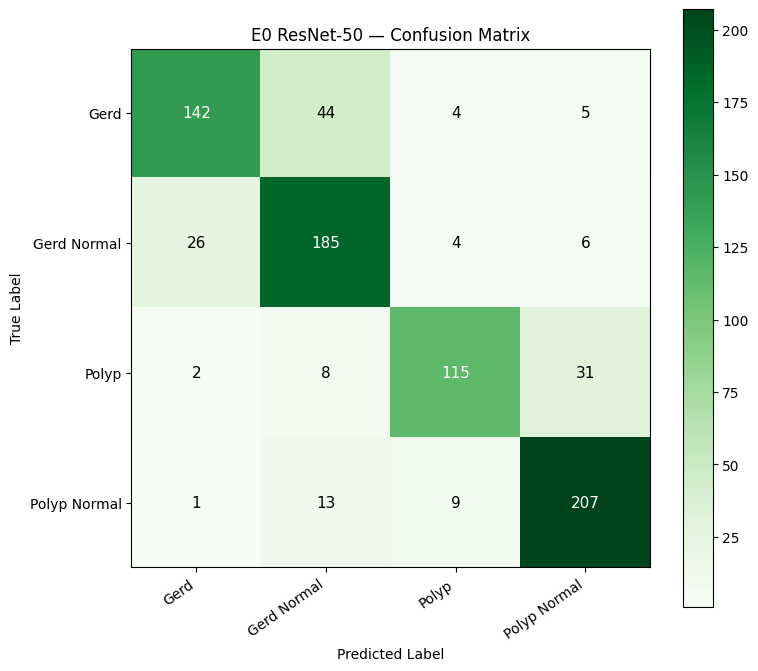

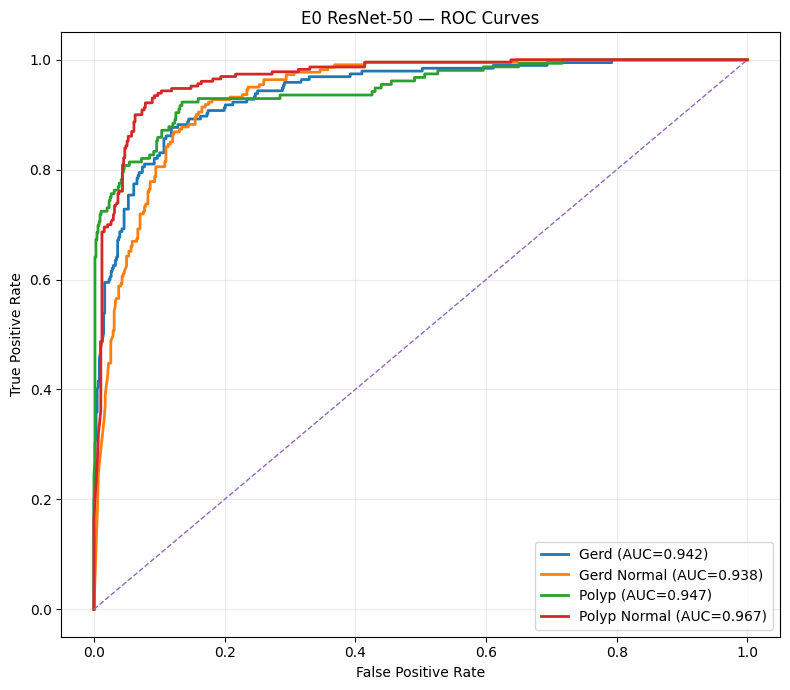

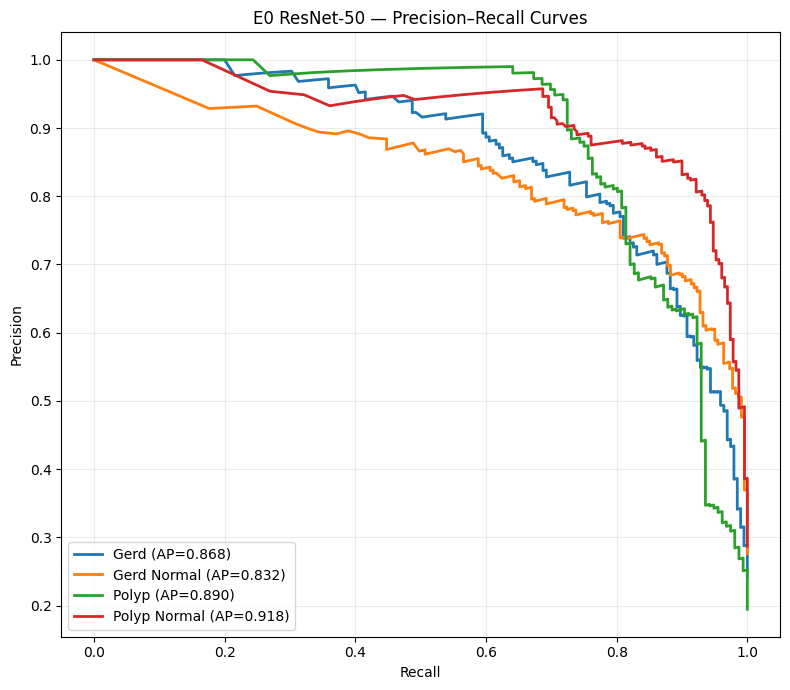

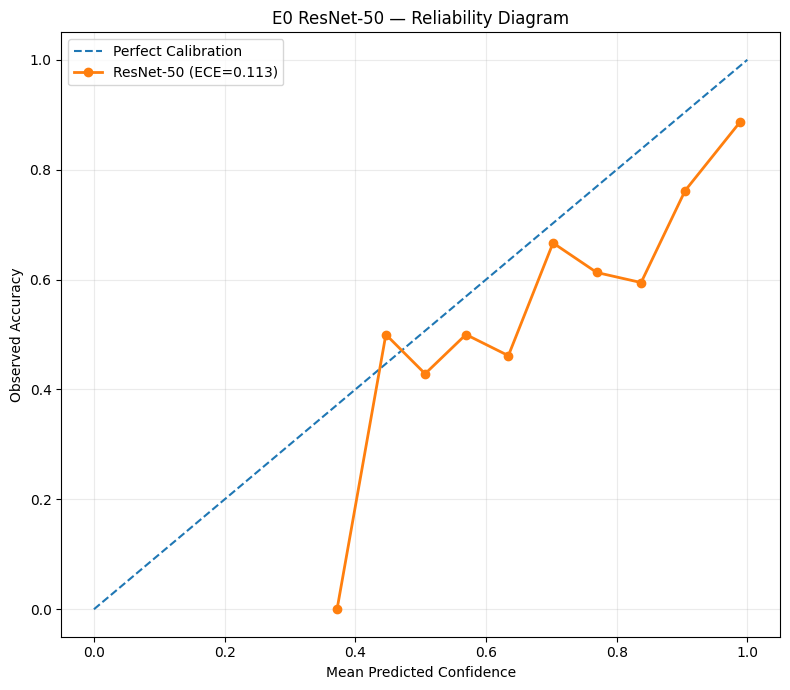


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Gerd     0.8304    0.7282    0.7760       195
 Gerd Normal     0.7400    0.8371    0.7856       221
       Polyp     0.8712    0.7372    0.7986       156
Polyp Normal     0.8313    0.9000    0.8643       230

    accuracy                         0.8092       802
   macro avg     0.8182    0.8006    0.8061       802
weighted avg     0.8137    0.8092    0.8083       802


E0 FINAL EVALUATION COMPLETED

Saved:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResNet50_RealOnly/results/E0_final_test_metrics.json
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResNet50_RealOnly/results/E0_per_class_metrics.csv
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResNet50_RealOnly/results/E0_test_predictions.csv
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResNet50_RealOnly/results/E0_confusion_matrix.png
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResN

In [ ]:
# ============================================================
# STEP 7 — E0 FINAL LOCKED TEST EVALUATION
# ============================================================

import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. LOAD BEST E0 CHECKPOINT
# ============================================================

print("=" * 80)
print("E0 — FINAL LOCKED TEST EVALUATION")
print("=" * 80)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("\nLoaded checkpoint:")
print(BEST_MODEL_PATH)

print(
    "Best validation epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Macro-F1:",
    round(
        checkpoint["best_val_macro_f1"],
        4
    )
)


# ============================================================
# 2. TEST INFERENCE
# ============================================================

all_targets = []
all_predictions = []
all_probabilities = []
all_filenames = []

total_inference_time = 0.0

if torch.cuda.is_available():
    torch.cuda.synchronize()


with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        # ----------------------------------------------------
        # Accurate GPU timing
        # ----------------------------------------------------

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.perf_counter()


        with torch.amp.autocast(
            device_type="cuda",
            enabled=AMP_ENABLED
        ):

            logits = model(images)


        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.perf_counter()


        total_inference_time += (
            end_time - start_time
        )


        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )


# Convert to arrays
y_true = np.array(all_targets)
y_pred = np.array(all_predictions)
y_prob = np.array(all_probabilities)


print("\nTest images evaluated:", len(y_true))

assert len(y_true) == 802


# ============================================================
# 3. OVERALL CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)


# ============================================================
# 4. AUROC + AUPRC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

macro_auroc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = average_precision_score(
    y_true_bin,
    y_prob,
    average="macro"
)


# ============================================================
# 5. CALIBRATION METRICS
# ============================================================

brier = multiclass_brier_score(
    y_true,
    y_prob,
    NUM_CLASSES
)

ece = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
)

nll = log_loss(
    y_true,
    y_prob,
    labels=np.arange(NUM_CLASSES)
)


# ============================================================
# 6. PER-CLASS METRICS
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

per_class_results = []

for class_idx, class_name in enumerate(CLASS_NAMES):

    TP = cm[class_idx, class_idx]

    FN = (
        cm[class_idx, :].sum()
        - TP
    )

    FP = (
        cm[:, class_idx].sum()
        - TP
    )

    TN = (
        cm.sum()
        - TP
        - FN
        - FP
    )


    sensitivity = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    ppv = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else 0
    )

    npv = (
        TN / (TN + FN)
        if (TN + FN) > 0
        else 0
    )


    class_f1 = f1_score(
        (y_true == class_idx).astype(int),
        (y_pred == class_idx).astype(int),
        zero_division=0
    )


    class_auc = roc_auc_score(
        y_true_bin[:, class_idx],
        y_prob[:, class_idx]
    )


    class_auprc = average_precision_score(
        y_true_bin[:, class_idx],
        y_prob[:, class_idx]
    )


    per_class_results.append({

        "Class":
            class_name,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "PPV":
            ppv,

        "NPV":
            npv,

        "F1":
            class_f1,

        "AUROC":
            class_auc,

        "AUPRC":
            class_auprc
    })


per_class_df = pd.DataFrame(
    per_class_results
)


# ============================================================
# 7. INFERENCE EFFICIENCY
# ============================================================

num_test_images = len(y_true)

latency_ms = (
    total_inference_time
    / num_test_images
    * 1000
)

throughput = (
    num_test_images
    / total_inference_time
)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


# ============================================================
# 8. DISPLAY FINAL RESULTS
# ============================================================

print("\n" + "=" * 80)
print("E0 — RESNET-50 LOCKED TEST PERFORMANCE")
print("=" * 80)

print(
    f"\nAccuracy              : {accuracy:.4f}"
)

print(
    f"Balanced Accuracy     : {balanced_acc:.4f}"
)

print(
    f"Macro Precision       : {macro_precision:.4f}"
)

print(
    f"Macro Recall          : {macro_recall:.4f}"
)

print(
    f"Macro F1              : {macro_f1:.4f}"
)

print(
    f"Weighted F1           : {weighted_f1:.4f}"
)

print(
    f"MCC                   : {mcc:.4f}"
)

print(
    f"Cohen's Kappa         : {kappa:.4f}"
)

print(
    f"Macro AUROC           : {macro_auroc:.4f}"
)

print(
    f"Macro AUPRC           : {macro_auprc:.4f}"
)

print(
    f"Brier Score           : {brier:.4f}"
)

print(
    f"ECE                   : {ece:.4f}"
)

print(
    f"NLL                   : {nll:.4f}"
)


print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE")
print("=" * 80)

print(
    per_class_df.round(4).to_string(index=False)
)


print("\n" + "=" * 80)
print("EFFICIENCY")
print("=" * 80)

print(
    f"Parameters             : "
    f"{total_params / 1e6:.2f} M"
)

print(
    f"Trainable Parameters   : "
    f"{trainable_params / 1e6:.2f} M"
)

print(
    f"Inference Latency      : "
    f"{latency_ms:.3f} ms/image"
)

print(
    f"Throughput             : "
    f"{throughput:.2f} images/sec"
)

print(
    f"Total Test Time        : "
    f"{total_inference_time:.3f} sec"
)


# ============================================================
# 9. CONFUSION MATRIX
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Greens"
)

plt.title(
    "E0 ResNet-50 — Confusion Matrix"
)

plt.colorbar()

tick_marks = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    tick_marks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    tick_marks,
    CLASS_NAMES
)

threshold = (
    cm.max() / 2
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            verticalalignment="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            ),
            fontsize=11
        )


plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E0_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={class_roc_auc:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "E0 ResNet-50 — ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E0_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. PRECISION–RECALL CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)

for i, class_name in enumerate(CLASS_NAMES):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true_bin[:, i],
            y_prob[:, i]
        )
    )

    class_ap = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP={class_ap:.3f})"
        )
    )


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "E0 ResNet-50 — Precision–Recall Curves"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E0_PR_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. CALIBRATION / RELIABILITY DIAGRAM
# ============================================================

confidences = np.max(
    y_prob,
    axis=1
)

correctness = (
    y_pred == y_true
).astype(float)

n_bins = 15

bin_edges = np.linspace(
    0,
    1,
    n_bins + 1
)

bin_centers = (
    bin_edges[:-1]
    + bin_edges[1:]
) / 2

bin_accuracy = []
bin_confidence = []
bin_counts = []


for i in range(n_bins):

    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    mask = (
        (confidences > lower)
        &
        (confidences <= upper)
    )

    if np.sum(mask) > 0:

        bin_accuracy.append(
            np.mean(correctness[mask])
        )

        bin_confidence.append(
            np.mean(confidences[mask])
        )

        bin_counts.append(
            np.sum(mask)
        )

    else:

        bin_accuracy.append(
            np.nan
        )

        bin_confidence.append(
            np.nan
        )

        bin_counts.append(0)


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

valid_bins = ~np.isnan(
    bin_accuracy
)

plt.plot(
    np.array(bin_confidence)[valid_bins],
    np.array(bin_accuracy)[valid_bins],
    marker="o",
    linewidth=2,
    label=f"ResNet-50 (ECE={ece:.3f})"
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "E0 ResNet-50 — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E0_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. SAVE TEST PREDICTIONS
# ============================================================

prediction_df = test_df.copy()

prediction_df["true_label"] = y_true
prediction_df["predicted_label"] = y_pred

prediction_df["true_class"] = [
    CLASS_NAMES[i]
    for i in y_true
]

prediction_df["predicted_class"] = [
    CLASS_NAMES[i]
    for i in y_pred
]

prediction_df["correct"] = (
    y_true == y_pred
)

prediction_df["confidence"] = np.max(
    y_prob,
    axis=1
)


for class_idx, class_name in enumerate(CLASS_NAMES):

    clean_name = (
        class_name
        .lower()
        .replace(" ", "_")
    )

    prediction_df[
        f"prob_{clean_name}"
    ] = y_prob[:, class_idx]


prediction_df.to_csv(
    RESULT_DIR /
    "E0_test_predictions.csv",
    index=False
)


# ============================================================
# 14. SAVE PER-CLASS RESULTS
# ============================================================

per_class_df.to_csv(
    RESULT_DIR /
    "E0_per_class_metrics.csv",
    index=False
)


# ============================================================
# 15. SAVE FINAL METRICS
# ============================================================

final_metrics = {

    "experiment":
        "E0_ResNet50_RealOnly",

    "test_images":
        int(num_test_images),

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_acc),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_f1":
        float(macro_f1),

    "weighted_f1":
        float(weighted_f1),

    "mcc":
        float(mcc),

    "cohen_kappa":
        float(kappa),

    "macro_auroc":
        float(macro_auroc),

    "macro_auprc":
        float(macro_auprc),

    "brier_score":
        float(brier),

    "ece":
        float(ece),

    "nll":
        float(nll),

    "parameters":
        int(total_params),

    "trainable_parameters":
        int(trainable_params),

    "inference_latency_ms_per_image":
        float(latency_ms),

    "throughput_images_per_second":
        float(throughput),

    "total_inference_seconds":
        float(total_inference_time),

    "best_epoch":
        int(checkpoint["epoch"]),

    "best_validation_macro_f1":
        float(
            checkpoint["best_val_macro_f1"]
        )
}


with open(
    RESULT_DIR /
    "E0_final_test_metrics.json",
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )


# ============================================================
# 16. CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(report)


# ============================================================
# 17. FINAL SAVED FILES
# ============================================================

print("\n" + "=" * 80)
print("E0 FINAL EVALUATION COMPLETED")
print("=" * 80)

print("\nSaved:")

print(
    RESULT_DIR /
    "E0_final_test_metrics.json"
)

print(
    RESULT_DIR /
    "E0_per_class_metrics.csv"
)

print(
    RESULT_DIR /
    "E0_test_predictions.csv"
)

print(
    RESULT_DIR /
    "E0_confusion_matrix.png"
)

print(
    RESULT_DIR /
    "E0_ROC_curves.png"
)

print(
    RESULT_DIR /
    "E0_PR_curves.png"
)

print(
    RESULT_DIR /
    "E0_calibration_curve.png"
)

print("\n✓ E0 LOCKED TEST EVALUATION FINISHED")

In [ ]:
# ============================================================
# STEP 8 — E0 MODEL COMPLEXITY + SPEED PROFILING
# ============================================================

import os
import time
import json
import torch
from pathlib import Path


# ============================================================
# 1. INSTALL / IMPORT FVCORE
# ============================================================

try:
    from fvcore.nn import FlopCountAnalysis
except ImportError:

    print("Installing fvcore...")

    !pip install fvcore -q

    from fvcore.nn import FlopCountAnalysis


# ============================================================
# 2. LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()


# ============================================================
# 3. PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

params_million = total_params / 1e6


# ============================================================
# 4. FLOPs
#
# FLOPs measured for ONE image:
# 1 × 3 × 384 × 384
# ============================================================

dummy_cpu = torch.randn(
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

model_cpu = model.cpu()

flop_analyzer = FlopCountAnalysis(
    model_cpu,
    dummy_cpu
)

total_flops = flop_analyzer.total()

gflops = total_flops / 1e9


# Move model back to GPU
model = model.to(device)
model.eval()


# ============================================================
# 5. MODEL CHECKPOINT SIZE
# ============================================================

checkpoint_size_mb = (
    os.path.getsize(BEST_MODEL_PATH)
    / (1024 ** 2)
)


# ============================================================
# 6. GPU LATENCY BENCHMARK
#
# Use batch size = 1 so latency means true ms/image.
# Warm-up iterations are excluded.
# ============================================================

dummy_gpu = torch.randn(
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=device
)

WARMUP_RUNS = 50
TIMED_RUNS = 200


if torch.cuda.is_available():

    # --------------------------------------------------------
    # Warm-up
    # --------------------------------------------------------

    with torch.no_grad():

        for _ in range(WARMUP_RUNS):

            with torch.amp.autocast(
                device_type="cuda",
                enabled=True
            ):
                _ = model(dummy_gpu)

    torch.cuda.synchronize()


    # --------------------------------------------------------
    # Timing
    # --------------------------------------------------------

    start = time.perf_counter()

    with torch.no_grad():

        for _ in range(TIMED_RUNS):

            with torch.amp.autocast(
                device_type="cuda",
                enabled=True
            ):
                _ = model(dummy_gpu)

    torch.cuda.synchronize()

    end = time.perf_counter()


    total_time = end - start

    latency_ms = (
        total_time
        / TIMED_RUNS
        * 1000
    )

    throughput_single = (
        1000 / latency_ms
    )

else:

    latency_ms = None
    throughput_single = None


# ============================================================
# 7. REAL TEST-LOADER THROUGHPUT
#
# This represents practical batched inference.
# ============================================================

model.eval()

num_images = 0

if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.perf_counter()


with torch.no_grad():

    for images, _ in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            _ = model(images)

        num_images += images.size(0)


if torch.cuda.is_available():
    torch.cuda.synchronize()

end = time.perf_counter()


test_inference_time = end - start

batch_throughput = (
    num_images / test_inference_time
)

batch_latency_ms_image = (
    test_inference_time
    / num_images
    * 1000
)


# ============================================================
# 8. GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    torch.cuda.reset_peak_memory_stats()

    sample = torch.randn(
        BATCH_SIZE,
        3,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device
    )

    with torch.no_grad():

        with torch.amp.autocast(
            device_type="cuda",
            enabled=True
        ):

            _ = model(sample)

    torch.cuda.synchronize()

    peak_memory_gb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 3)
    )

else:

    peak_memory_gb = 0.0


# ============================================================
# 9. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 75)
print("E0 — RESNET-50 COMPLEXITY PROFILE")
print("=" * 75)

print(
    f"Input resolution            : "
    f"{IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    f"Total parameters            : "
    f"{total_params:,}"
)

print(
    f"Parameters (M)              : "
    f"{params_million:.3f} M"
)

print(
    f"Trainable parameters        : "
    f"{trainable_params:,}"
)

print(
    f"GFLOPs / image              : "
    f"{gflops:.3f}"
)

print(
    f"Checkpoint size             : "
    f"{checkpoint_size_mb:.2f} MB"
)


if latency_ms is not None:

    print(
        f"Batch-1 GPU latency         : "
        f"{latency_ms:.3f} ms/image"
    )

    print(
        f"Batch-1 theoretical rate    : "
        f"{throughput_single:.2f} images/sec"
    )


print(
    f"Test-loader latency         : "
    f"{batch_latency_ms_image:.3f} ms/image"
)

print(
    f"Test-loader throughput      : "
    f"{batch_throughput:.2f} images/sec"
)

print(
    f"Peak GPU memory (batch={BATCH_SIZE}) : "
    f"{peak_memory_gb:.3f} GB"
)


# ============================================================
# 10. SAVE COMPLEXITY RESULTS
# ============================================================

complexity_results = {

    "experiment":
        EXPERIMENT_NAME,

    "model":
        "ResNet50",

    "input_resolution":
        IMAGE_SIZE,

    "parameters":
        int(total_params),

    "parameters_million":
        float(params_million),

    "trainable_parameters":
        int(trainable_params),

    "gflops_per_image":
        float(gflops),

    "checkpoint_size_mb":
        float(checkpoint_size_mb),

    "batch1_latency_ms":
        (
            float(latency_ms)
            if latency_ms is not None
            else None
        ),

    "batch1_images_per_second":
        (
            float(throughput_single)
            if throughput_single is not None
            else None
        ),

    "test_loader_latency_ms_per_image":
        float(batch_latency_ms_image),

    "test_loader_throughput_images_per_sec":
        float(batch_throughput),

    "peak_gpu_memory_gb":
        float(peak_memory_gb),

    "gpu":
        (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else "CPU"
        )
}


with open(
    RESULT_DIR /
    "E0_complexity_metrics.json",
    "w"
) as f:

    json.dump(
        complexity_results,
        f,
        indent=4
    )


print("\nSaved:")
print(
    RESULT_DIR /
    "E0_complexity_metrics.json"
)

print("\n✓ E0 COMPLEXITY PROFILING COMPLETED")

Installing fvcore...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.9 MB/s eta 0:00:00



E0 — RESNET-50 COMPLEXITY PROFILE
Input resolution            : 384 × 384
Total parameters            : 23,516,228
Parameters (M)              : 23.516 M
Trainable parameters        : 23,516,228
GFLOPs / image              : 12.077
Checkpoint size             : 269.56 MB
Batch-1 GPU latency         : 8.838 ms/image
Batch-1 theoretical rate    : 113.14 images/sec
Test-loader latency         : 6.035 ms/image
Test-loader throughput      : 165.69 images/sec
Peak GPU memory (batch=16) : 0.954 GB

Saved:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E0_ResNet50_RealOnly/results/E0_complexity_metrics.json

✓ E0 COMPLEXITY PROFILING COMPLETED


# E1 — Real images + conventional medically plausible augmentation

E1 augmentation + model setup

In [ ]:
# ============================================================
# STEP 9 — E1: CONVENTIONAL AUGMENTATION
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models

from torchvision import transforms


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

set_seed(SEED)

print("=" * 80)
print("E1 — REAL + CONVENTIONAL AUGMENTATION")
print("=" * 80)


# ============================================================
# 2. TRAINING AUGMENTATION
#
# Mild transformations only.
# Designed to preserve clinically relevant morphology.
# ============================================================

e1_train_transform = transforms.Compose([

    # Same base geometric normalization as E0
    ResizeWithPadding(IMAGE_SIZE),

    # --------------------------------------------------------
    # Conventional augmentation
    # --------------------------------------------------------

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomRotation(
        degrees=12,
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.RandomApply(
        [
            transforms.GaussianBlur(
                kernel_size=3,
                sigma=(0.1, 1.0)
            )
        ],
        p=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 3. VALIDATION AND TEST TRANSFORMS
#
# IMPORTANT:
# These remain IDENTICAL to E0.
# ============================================================

e1_eval_transform = e0_transform


# ============================================================
# 4. CREATE E1 DATASETS
# ============================================================

e1_train_dataset = GastroEndoDataset(
    train_df,
    transform=e1_train_transform
)

e1_val_dataset = GastroEndoDataset(
    val_df,
    transform=e1_eval_transform
)

e1_test_dataset = GastroEndoDataset(
    test_df,
    transform=e1_eval_transform
)


print("\nDataset sizes:")
print("Train :", len(e1_train_dataset))
print("Val   :", len(e1_val_dataset))
print("Test  :", len(e1_test_dataset))


# ============================================================
# 5. CREATE E1 DATA LOADERS
# ============================================================

e1_generator = torch.Generator()
e1_generator.manual_seed(SEED)


e1_train_loader = DataLoader(
    e1_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=e1_generator
)


e1_val_loader = DataLoader(
    e1_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


e1_test_loader = DataLoader(
    e1_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# 6. EXPERIMENT DIRECTORIES
# ============================================================

EXPERIMENT_NAME = "E1_ResNet50_ConventionalAug"

E1_DIR = (
    PROJECT_DIR /
    "experiments" /
    EXPERIMENT_NAME
)

CHECKPOINT_DIR = (
    E1_DIR /
    "checkpoints"
)

RESULT_DIR = (
    E1_DIR /
    "results"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e1.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_resnet50_e1.pth"
)


# ============================================================
# 7. RESET MODEL
#
# CRITICAL:
# E1 starts again from ImageNet weights.
# We DO NOT continue training the E0 checkpoint.
# ============================================================

weights = (
    models.ResNet50_Weights.IMAGENET1K_V2
)

model = models.resnet50(
    weights=weights
)

in_features = model.fc.in_features

model.fc = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(device)


# ============================================================
# 8. FULL FINE-TUNING
# ============================================================

for parameter in model.parameters():

    parameter.requires_grad = True


# ============================================================
# 9. LOSS
#
# Same class weights as E0.
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# 10. OPTIMIZER
#
# Identical to E0.
# ============================================================

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 30
PATIENCE = 7


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 11. SCHEDULER
# ============================================================

scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
)


# ============================================================
# 12. MIXED PRECISION
# ============================================================

AMP_ENABLED = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)


# ============================================================
# 13. SANITY CHECK
# ============================================================

images, labels = next(
    iter(e1_train_loader)
)

print("\nBatch check:")
print("Images :", images.shape)
print("Labels :", labels.shape)

assert images.shape == (
    BATCH_SIZE,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)


# ============================================================
# 14. MODEL INFORMATION
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("\n" + "=" * 80)
print("E1 CONFIGURATION")
print("=" * 80)

print("Model                  : ResNet-50")
print("Initialization         : ImageNet-1K V2")
print("Input                  : 384 × 384")

print(
    "Training images        :",
    len(e1_train_dataset)
)

print(
    "Validation images      :",
    len(e1_val_dataset)
)

print(
    "Locked test images     :",
    len(e1_test_dataset)
)

print(
    f"Parameters             : "
    f"{total_params / 1e6:.3f} M"
)

print(
    "Learning rate          :",
    LEARNING_RATE
)

print(
    "Weight decay           :",
    WEIGHT_DECAY
)

print(
    "Epochs                 :",
    NUM_EPOCHS
)

print(
    "Early stopping         :",
    PATIENCE
)

print(
    "Selection metric       : Validation Macro-F1"
)

print("\nE1 TRAINING AUGMENTATION:")
print("✓ Horizontal flip p=0.50")
print("✓ Rotation ±12°")
print("✓ Translation ±3%")
print("✓ Scale 0.95–1.05")
print("✓ Mild brightness change")
print("✓ Mild contrast change")
print("✓ Mild saturation change")
print("✓ Very mild hue variation")
print("✓ Gaussian blur p=0.15")

print("\nNOT INCLUDED:")
print("✗ MixUp")
print("✗ CutMix")
print("✗ GAN")
print("✗ Diffusion")
print("✗ Synthetic images")

print("\nCheckpoint:")
print(BEST_MODEL_PATH)

print("\n✓ E1 PIPELINE READY")

E1 — REAL + CONVENTIONAL AUGMENTATION

Dataset sizes:
Train : 2803
Val   : 401
Test  : 802

Batch check:
Images : torch.Size([16, 3, 384, 384])
Labels : torch.Size([16])

E1 CONFIGURATION
Model                  : ResNet-50
Initialization         : ImageNet-1K V2
Input                  : 384 × 384
Training images        : 2803
Validation images      : 401
Locked test images     : 802
Parameters             : 23.516 M
Learning rate          : 0.0001
Weight decay           : 0.0001
Epochs                 : 30
Early stopping         : 7
Selection metric       : Validation Macro-F1

E1 TRAINING AUGMENTATION:
✓ Horizontal flip p=0.50
✓ Rotation ±12°
✓ Translation ±3%
✓ Scale 0.95–1.05
✓ Mild brightness change
✓ Mild contrast change
✓ Mild saturation change
✓ Very mild hue variation
✓ Gaussian blur p=0.15

NOT INCLUDED:
✗ MixUp
✗ CutMix
✗ GAN
✗ Diffusion
✗ Synthetic images

Checkpoint:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E1_ResNet50_ConventionalAug/checkpoints/best_resnet5

In [ ]:
# ============================================================
# STEP 10 — E1 RESNET-50 TRAINING
# REAL + CONVENTIONAL AUGMENTATION
# ============================================================

import time
import json
import pandas as pd
import torch


# ============================================================
# 1. INITIALIZE TRAINING
# ============================================================

history = []

best_val_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.perf_counter()


if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()


print("\n" + "=" * 115)
print("STARTING E1 — RESNET-50 + CONVENTIONAL AUGMENTATION")
print("=" * 115)

print(
    f"{'Epoch':<7}"
    f"{'Train Loss':<12}"
    f"{'Val Loss':<11}"
    f"{'Val Acc':<10}"
    f"{'Bal Acc':<10}"
    f"{'Macro F1':<10}"
    f"{'MCC':<9}"
    f"{'AUROC':<9}"
    f"{'AUPRC':<9}"
    f"{'Brier':<9}"
    f"{'ECE':<9}"
    f"{'Time':<8}"
)

print("-" * 115)


# ============================================================
# 2. TRAINING LOOP
# ============================================================

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start = time.perf_counter()


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    train_metrics = train_one_epoch(
        model=model,
        loader=e1_train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    val_metrics = validate_one_epoch(
        model=model,
        loader=e1_val_loader,
        criterion=criterion,
        device=device
    )


    # --------------------------------------------------------
    # SCHEDULER
    # --------------------------------------------------------

    scheduler.step(
        val_metrics["macro_f1"]
    )


    # --------------------------------------------------------
    # TIMING
    # --------------------------------------------------------

    epoch_time = (
        time.perf_counter()
        - epoch_start
    )

    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    epoch_record = {

        "epoch": epoch,

        "train_loss":
            train_metrics["loss"],

        "train_accuracy":
            train_metrics["accuracy"],

        "train_balanced_accuracy":
            train_metrics["balanced_accuracy"],

        "train_macro_precision":
            train_metrics["macro_precision"],

        "train_macro_recall":
            train_metrics["macro_recall"],

        "train_macro_f1":
            train_metrics["macro_f1"],

        "train_weighted_f1":
            train_metrics["weighted_f1"],

        "train_mcc":
            train_metrics["mcc"],

        "train_macro_auroc":
            train_metrics["macro_auroc"],

        "train_macro_auprc":
            train_metrics["macro_auprc"],

        "train_brier":
            train_metrics["brier"],

        "train_ece":
            train_metrics["ece"],

        "train_nll":
            train_metrics["nll"],


        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],

        "val_macro_precision":
            val_metrics["macro_precision"],

        "val_macro_recall":
            val_metrics["macro_recall"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_weighted_f1":
            val_metrics["weighted_f1"],

        "val_mcc":
            val_metrics["mcc"],

        "val_kappa":
            val_metrics["kappa"],

        "val_macro_auroc":
            val_metrics["macro_auroc"],

        "val_macro_auprc":
            val_metrics["macro_auprc"],

        "val_brier":
            val_metrics["brier"],

        "val_ece":
            val_metrics["ece"],

        "val_nll":
            val_metrics["nll"],

        "learning_rate":
            current_lr,

        "epoch_time_seconds":
            epoch_time
    }


    history.append(epoch_record)


    # --------------------------------------------------------
    # PRINT EPOCH RESULT
    # --------------------------------------------------------

    print(
        f"{epoch:<7}"
        f"{train_metrics['loss']:<12.4f}"
        f"{val_metrics['loss']:<11.4f}"
        f"{val_metrics['accuracy']:<10.4f}"
        f"{val_metrics['balanced_accuracy']:<10.4f}"
        f"{val_metrics['macro_f1']:<10.4f}"
        f"{val_metrics['mcc']:<9.4f}"
        f"{val_metrics['macro_auroc']:<9.4f}"
        f"{val_metrics['macro_auprc']:<9.4f}"
        f"{val_metrics['brier']:<9.4f}"
        f"{val_metrics['ece']:<9.4f}"
        f"{epoch_time:<8.1f}"
    )


    # ========================================================
    # 3. BEST CHECKPOINT — MACRO F1
    # ========================================================

    if val_metrics["macro_f1"] > best_val_f1:

        best_val_f1 = val_metrics["macro_f1"]
        best_epoch = epoch

        epochs_without_improvement = 0


        checkpoint = {

            "experiment":
                EXPERIMENT_NAME,

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "best_val_macro_f1":
                best_val_f1,

            "val_metrics":
                val_metrics,

            "class_names":
                CLASS_NAMES,

            "image_size":
                IMAGE_SIZE,

            "seed":
                SEED,

            "augmentation":
                "Conventional medically plausible augmentation"
        }


        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )


        print(
            f"   ✓ New best E1 model saved "
            f"(Macro-F1 = {best_val_f1:.4f})"
        )


    else:

        epochs_without_improvement += 1


    # ========================================================
    # 4. SAVE HISTORY EVERY EPOCH
    # ========================================================

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        RESULT_DIR /
        "E1_training_history.csv",
        index=False
    )


    # ========================================================
    # 5. EARLY STOPPING
    # ========================================================

    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")

        print(
            f"No validation Macro-F1 improvement "
            f"for {PATIENCE} epochs."
        )

        break


# ============================================================
# 6. TOTAL TRAINING TIME
# ============================================================

total_training_time = (
    time.perf_counter()
    - training_start_time
)

total_training_minutes = (
    total_training_time / 60
)


# ============================================================
# 7. PEAK GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    peak_gpu_memory_gb = (
        torch.cuda.max_memory_allocated()
        / (1024 ** 3)
    )

else:

    peak_gpu_memory_gb = 0.0


# ============================================================
# 8. SAVE LAST MODEL
# ============================================================

torch.save(

    {
        "experiment":
            EXPERIMENT_NAME,

        "epoch":
            history[-1]["epoch"],

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "best_epoch":
            best_epoch,

        "best_val_macro_f1":
            best_val_f1,

        "class_names":
            CLASS_NAMES
    },

    LAST_MODEL_PATH
)


# ============================================================
# 9. SAVE TRAINING SUMMARY
# ============================================================

training_summary = {

    "experiment":
        EXPERIMENT_NAME,

    "model":
        "ResNet50",

    "strategy":
        "Real + conventional augmentation",

    "train_images":
        len(e1_train_dataset),

    "validation_images":
        len(e1_val_dataset),

    "locked_test_images":
        len(e1_test_dataset),

    "input_resolution":
        IMAGE_SIZE,

    "epochs_planned":
        NUM_EPOCHS,

    "epochs_completed":
        len(history),

    "best_epoch":
        best_epoch,

    "best_val_macro_f1":
        float(best_val_f1),

    "training_time_seconds":
        float(total_training_time),

    "training_time_minutes":
        float(total_training_minutes),

    "peak_gpu_memory_gb":
        float(peak_gpu_memory_gb),

    "seed":
        SEED
}


with open(
    RESULT_DIR /
    "E1_training_summary.json",
    "w"
) as f:

    json.dump(
        training_summary,
        f,
        indent=4
    )


# ============================================================
# 10. BEST EPOCH SUMMARY
# ============================================================

history_df = pd.DataFrame(history)

best_row = history_df.loc[
    history_df["val_macro_f1"].idxmax()
]


print("\n" + "=" * 80)
print("E1 TRAINING COMPLETED")
print("=" * 80)

print(
    f"Best epoch               : "
    f"{int(best_row['epoch'])}"
)

print(
    f"Best Validation Macro-F1 : "
    f"{best_row['val_macro_f1']:.4f}"
)

print(
    f"Validation Accuracy      : "
    f"{best_row['val_accuracy']:.4f}"
)

print(
    f"Balanced Accuracy        : "
    f"{best_row['val_balanced_accuracy']:.4f}"
)

print(
    f"Macro Precision          : "
    f"{best_row['val_macro_precision']:.4f}"
)

print(
    f"Macro Recall             : "
    f"{best_row['val_macro_recall']:.4f}"
)

print(
    f"MCC                      : "
    f"{best_row['val_mcc']:.4f}"
)

print(
    f"Macro AUROC              : "
    f"{best_row['val_macro_auroc']:.4f}"
)

print(
    f"Macro AUPRC              : "
    f"{best_row['val_macro_auprc']:.4f}"
)

print(
    f"Brier Score              : "
    f"{best_row['val_brier']:.4f}"
)

print(
    f"ECE                      : "
    f"{best_row['val_ece']:.4f}"
)

print(
    f"NLL                      : "
    f"{best_row['val_nll']:.4f}"
)

print(
    f"\nTotal training time      : "
    f"{total_training_minutes:.2f} minutes"
)

print(
    f"Peak GPU memory          : "
    f"{peak_gpu_memory_gb:.2f} GB"
)

print("\nBest checkpoint:")
print(BEST_MODEL_PATH)

print("\n✓ E1 TRAINING FINISHED")
print("✓ MODEL SELECTED USING VALIDATION MACRO-F1")
print("✓ LOCKED TEST SET STILL UNTOUCHED")


STARTING E1 — RESNET-50 + CONVENTIONAL AUGMENTATION
Epoch  Train Loss  Val Loss   Val Acc   Bal Acc   Macro F1  MCC      AUROC    AUPRC    Brier    ECE      Time    
-------------------------------------------------------------------------------------------------------------------
1      0.9278      0.6692     0.7307    0.7326    0.7284    0.6430   0.9266   0.8084   0.3884   0.0761   54.3    
   ✓ New best E1 model saved (Macro-F1 = 0.7284)
2      0.5972      0.5976     0.7756    0.7666    0.7685    0.6992   0.9356   0.8279   0.3211   0.0667   54.3    
   ✓ New best E1 model saved (Macro-F1 = 0.7685)
3      0.4813      0.5041     0.7905    0.7955    0.7895    0.7218   0.9559   0.8868   0.2956   0.0419   60.1    
   ✓ New best E1 model saved (Macro-F1 = 0.7895)
4      0.3865      0.4299     0.8080    0.8142    0.8075    0.7457   0.9676   0.9159   0.2526   0.0413   60.9    
   ✓ New best E1 model saved (Macro-F1 = 0.8075)
5      0.3070      0.4929     0.7980    0.8067    0.7985    0.734

E1 — LOCKED TEST EVALUATION

Best epoch: 23
Best validation Macro-F1: 0.8623

Locked test images: 802

E1 — RESNET-50 LOCKED TEST PERFORMANCE
Accuracy             : 0.8217
Balanced Accuracy    : 0.8233
Macro Precision      : 0.8238
Macro Recall         : 0.8233
Macro F1             : 0.8220
Weighted F1          : 0.8220
MCC                  : 0.7619
Cohen's Kappa        : 0.7609
Macro AUROC          : 0.9581
Macro AUPRC          : 0.8947
Brier Score          : 0.2886
ECE                  : 0.1209
NLL                  : 0.6616
Inference latency    : 0.846 ms/image
Throughput           : 1181.72 images/sec

PER-CLASS PERFORMANCE
       Class  Sensitivity  Specificity    PPV    NPV     F1  AUROC  AUPRC
        Gerd       0.7641       0.9506 0.8324 0.9262 0.7968 0.9479 0.8589
 Gerd Normal       0.8462       0.9002 0.7633 0.9390 0.8026 0.9406 0.8555
       Polyp       0.8654       0.9505 0.8084 0.9669 0.8359 0.9744 0.9211
Polyp Normal       0.8174       0.9598 0.8910 0.9289 0.8526 0.9698 0.

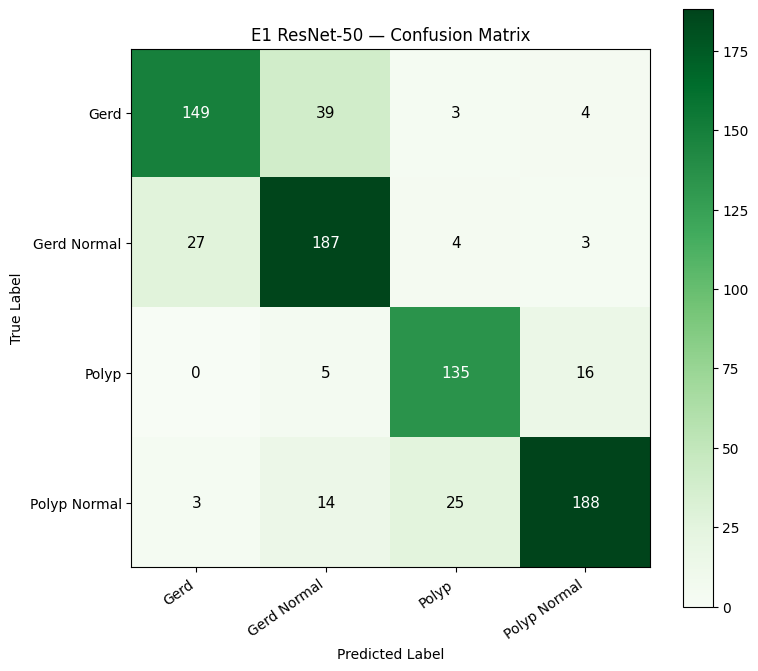

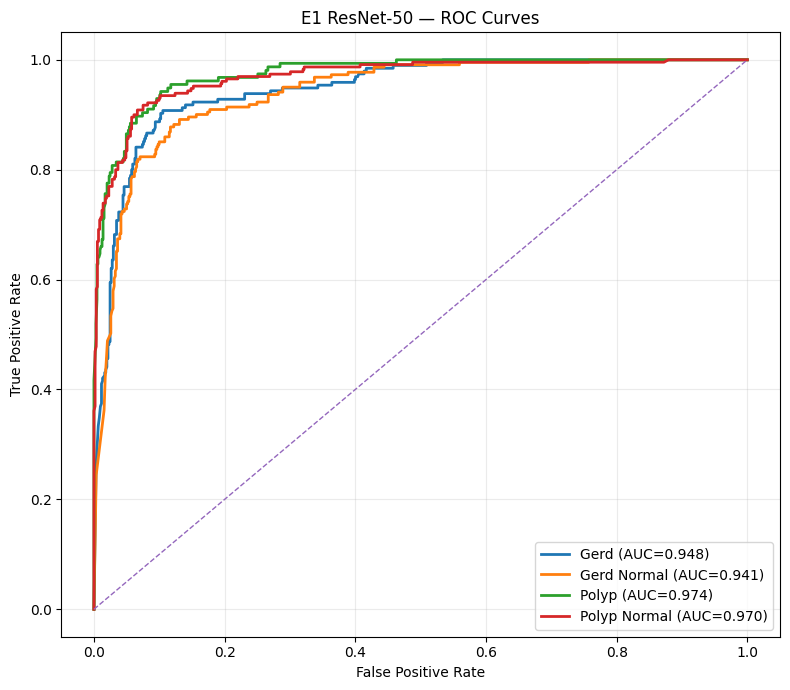

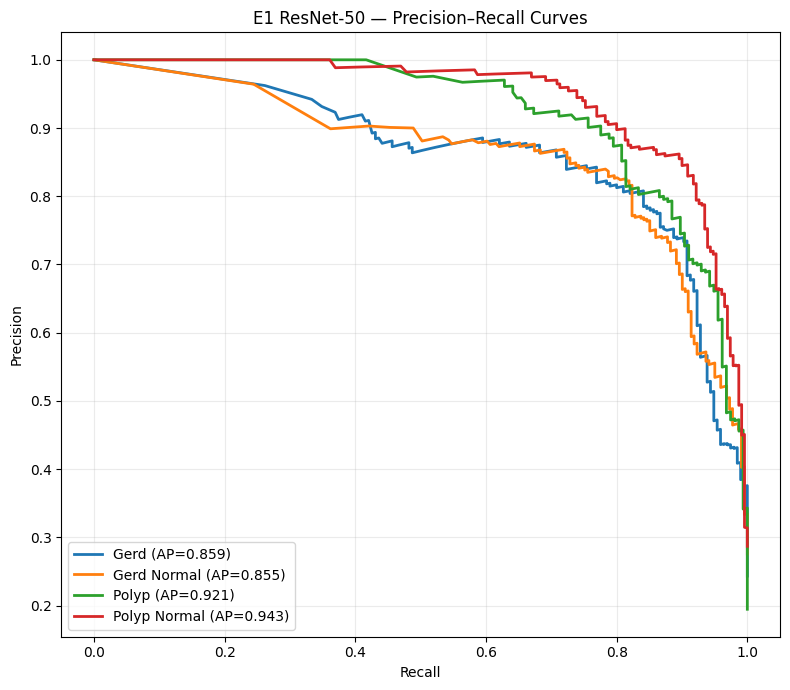

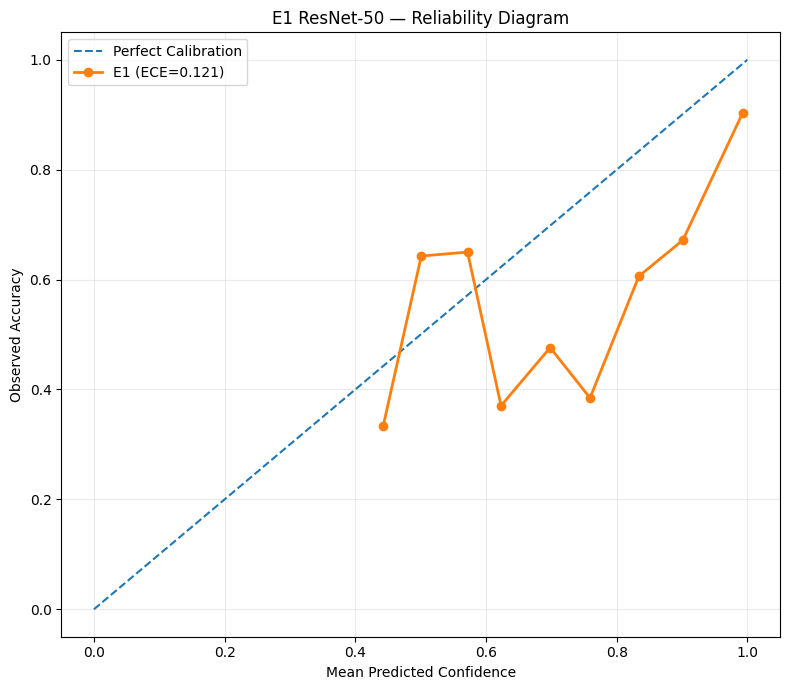


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Gerd     0.8324    0.7641    0.7968       195
 Gerd Normal     0.7633    0.8462    0.8026       221
       Polyp     0.8084    0.8654    0.8359       156
Polyp Normal     0.8910    0.8174    0.8526       230

    accuracy                         0.8217       802
   macro avg     0.8238    0.8233    0.8220       802
weighted avg     0.8255    0.8217    0.8220       802


E0 vs E1 — LOCKED TEST COMPARISON
           Metric  E0 Real Only  E1 Conventional Aug  Difference
         Accuracy        0.8092               0.8217      0.0125
Balanced Accuracy        0.8006               0.8233      0.0226
  Macro Precision        0.8182               0.8238      0.0055
     Macro Recall        0.8006               0.8233      0.0226
         Macro F1        0.8061               0.8220      0.0159
              MCC        0.7445               0.7619      0.0174
      Macro AUROC        0.9486               0.9581

In [ ]:
# ============================================================
# STEP 11 — E1 LOCKED TEST EVALUATION
# + E0 vs E1 COMPARISON
# ============================================================

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. LOAD BEST E1 MODEL
# ============================================================

print("=" * 80)
print("E1 — LOCKED TEST EVALUATION")
print("=" * 80)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("\nBest epoch:", checkpoint["epoch"])
print(
    "Best validation Macro-F1:",
    f"{checkpoint['best_val_macro_f1']:.4f}"
)


# ============================================================
# 2. RUN LOCKED TEST SET
# ============================================================

all_targets = []
all_predictions = []
all_probabilities = []

total_inference_time = 0.0

with torch.no_grad():

    for images, labels in e1_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        with torch.amp.autocast(
            device_type="cuda",
            enabled=AMP_ENABLED
        ):

            logits = model(images)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        total_inference_time += (
            time.perf_counter() - start
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )


y_true = np.asarray(all_targets)
y_pred = np.asarray(all_predictions)
y_prob = np.asarray(all_probabilities)

assert len(y_true) == 802

print("\nLocked test images:", len(y_true))


# ============================================================
# 3. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)


# ============================================================
# 4. AUROC / AUPRC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

macro_auroc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = average_precision_score(
    y_true_bin,
    y_prob,
    average="macro"
)


# ============================================================
# 5. CALIBRATION
# ============================================================

brier = multiclass_brier_score(
    y_true,
    y_prob,
    NUM_CLASSES
)

ece = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
)

nll = log_loss(
    y_true,
    y_prob,
    labels=np.arange(NUM_CLASSES)
)


# ============================================================
# 6. CONFUSION MATRIX + PER-CLASS METRICS
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

per_class_results = []

for i, class_name in enumerate(CLASS_NAMES):

    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    sensitivity = TP / (TP + FN) if TP + FN else 0
    specificity = TN / (TN + FP) if TN + FP else 0
    ppv = TP / (TP + FP) if TP + FP else 0
    npv = TN / (TN + FN) if TN + FN else 0

    class_f1 = f1_score(
        (y_true == i).astype(int),
        (y_pred == i).astype(int),
        zero_division=0
    )

    class_auc = roc_auc_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_auprc = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    per_class_results.append({

        "Class": class_name,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "F1": class_f1,
        "AUROC": class_auc,
        "AUPRC": class_auprc
    })


per_class_df = pd.DataFrame(
    per_class_results
)


# ============================================================
# 7. INFERENCE SPEED
# ============================================================

latency_ms = (
    total_inference_time /
    len(y_true) *
    1000
)

throughput = (
    len(y_true) /
    total_inference_time
)


# ============================================================
# 8. PRINT FINAL E1 RESULTS
# ============================================================

print("\n" + "=" * 80)
print("E1 — RESNET-50 LOCKED TEST PERFORMANCE")
print("=" * 80)

print(f"Accuracy             : {accuracy:.4f}")
print(f"Balanced Accuracy    : {balanced_acc:.4f}")

print(f"Macro Precision      : {macro_precision:.4f}")
print(f"Macro Recall         : {macro_recall:.4f}")
print(f"Macro F1             : {macro_f1:.4f}")
print(f"Weighted F1          : {weighted_f1:.4f}")

print(f"MCC                  : {mcc:.4f}")
print(f"Cohen's Kappa        : {kappa:.4f}")

print(f"Macro AUROC          : {macro_auroc:.4f}")
print(f"Macro AUPRC          : {macro_auprc:.4f}")

print(f"Brier Score          : {brier:.4f}")
print(f"ECE                  : {ece:.4f}")
print(f"NLL                  : {nll:.4f}")

print(f"Inference latency    : {latency_ms:.3f} ms/image")
print(f"Throughput           : {throughput:.2f} images/sec")


print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE")
print("=" * 80)

print(
    per_class_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 9. SAVE E1 FINAL METRICS
# ============================================================

e1_metrics = {

    "experiment":
        "E1_ResNet50_ConventionalAug",

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_acc),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_f1":
        float(macro_f1),

    "weighted_f1":
        float(weighted_f1),

    "mcc":
        float(mcc),

    "cohen_kappa":
        float(kappa),

    "macro_auroc":
        float(macro_auroc),

    "macro_auprc":
        float(macro_auprc),

    "brier_score":
        float(brier),

    "ece":
        float(ece),

    "nll":
        float(nll),

    "latency_ms_per_image":
        float(latency_ms),

    "throughput_images_per_second":
        float(throughput),

    "best_epoch":
        int(checkpoint["epoch"]),

    "best_validation_macro_f1":
        float(
            checkpoint["best_val_macro_f1"]
        )
}


with open(
    RESULT_DIR /
    "E1_final_test_metrics.json",
    "w"
) as f:

    json.dump(
        e1_metrics,
        f,
        indent=4
    )


per_class_df.to_csv(
    RESULT_DIR /
    "E1_per_class_metrics.csv",
    index=False
)


# ============================================================
# 10. SAVE ALL TEST PREDICTIONS
# ============================================================

prediction_df = test_df.copy()

prediction_df["true_id"] = y_true
prediction_df["predicted_id"] = y_pred

prediction_df["true_class"] = [
    CLASS_NAMES[i]
    for i in y_true
]

prediction_df["predicted_class"] = [
    CLASS_NAMES[i]
    for i in y_pred
]

prediction_df["correct"] = (
    y_true == y_pred
)

prediction_df["confidence"] = np.max(
    y_prob,
    axis=1
)


for i, class_name in enumerate(CLASS_NAMES):

    clean_name = (
        class_name.lower()
        .replace(" ", "_")
    )

    prediction_df[
        f"prob_{clean_name}"
    ] = y_prob[:, i]


prediction_df.to_csv(
    RESULT_DIR /
    "E1_test_predictions.csv",
    index=False
)


# ============================================================
# 11. CONFUSION MATRIX — GREENS
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    cmap="Greens",
    interpolation="nearest"
)

plt.title(
    "E1 ResNet-50 — Confusion Matrix"
)

plt.colorbar()

ticks = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    ticks,
    CLASS_NAMES
)

threshold = cm.max() / 2

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            ),
            fontsize=11
        )


plt.ylabel("True Label")
plt.xlabel("Predicted Label")

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E1_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)

for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={roc_auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "E1 ResNet-50 — ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E1_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)

for i, class_name in enumerate(CLASS_NAMES):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true_bin[:, i],
            y_prob[:, i]
        )
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP={ap:.3f})"
        )
    )


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "E1 ResNet-50 — Precision–Recall Curves"
)

plt.legend(
    loc="lower left"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E1_PR_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. RELIABILITY DIAGRAM
# ============================================================

confidences = np.max(
    y_prob,
    axis=1
)

correctness = (
    y_pred == y_true
).astype(float)

bin_edges = np.linspace(
    0,
    1,
    16
)

bin_acc = []
bin_conf = []

for i in range(15):

    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    mask = (
        (confidences > lower)
        &
        (confidences <= upper)
    )

    if mask.sum() > 0:

        bin_acc.append(
            correctness[mask].mean()
        )

        bin_conf.append(
            confidences[mask].mean()
        )


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_conf,
    bin_acc,
    marker="o",
    linewidth=2,
    label=f"E1 (ECE={ece:.3f})"
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "E1 ResNet-50 — Reliability Diagram"
)

plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E1_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 16. AUTOMATIC E0 vs E1 COMPARISON
# ============================================================

E0_METRIC_PATH = (
    PROJECT_DIR /
    "experiments" /
    "E0_ResNet50_RealOnly" /
    "results" /
    "E0_final_test_metrics.json"
)


if E0_METRIC_PATH.exists():

    with open(
        E0_METRIC_PATH,
        "r"
    ) as f:

        e0 = json.load(f)


    comparison = pd.DataFrame({

        "Metric": [
            "Accuracy",
            "Balanced Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "MCC",
            "Macro AUROC",
            "Macro AUPRC",
            "Brier Score",
            "ECE",
            "NLL"
        ],

        "E0 Real Only": [
            e0["accuracy"],
            e0["balanced_accuracy"],
            e0["macro_precision"],
            e0["macro_recall"],
            e0["macro_f1"],
            e0["mcc"],
            e0["macro_auroc"],
            e0["macro_auprc"],
            e0["brier_score"],
            e0["ece"],
            e0["nll"]
        ],

        "E1 Conventional Aug": [
            accuracy,
            balanced_acc,
            macro_precision,
            macro_recall,
            macro_f1,
            mcc,
            macro_auroc,
            macro_auprc,
            brier,
            ece,
            nll
        ]
    })


    comparison["Difference"] = (
        comparison["E1 Conventional Aug"]
        -
        comparison["E0 Real Only"]
    )


    comparison.to_csv(
        RESULT_DIR /
        "E0_vs_E1_test_comparison.csv",
        index=False
    )


    print("\n" + "=" * 80)
    print("E0 vs E1 — LOCKED TEST COMPARISON")
    print("=" * 80)

    print(
        comparison
        .round(4)
        .to_string(index=False)
    )

else:

    print(
        "\nE0 final metrics file not found."
    )


print("\n" + "=" * 80)
print("E1 FINAL EVALUATION COMPLETE")
print("=" * 80)

print("✓ Locked test evaluated")
print("✓ Overall metrics saved")
print("✓ Per-class metrics saved")
print("✓ Test predictions saved")
print("✓ Green confusion matrix saved")
print("✓ ROC curves saved")
print("✓ PR curves saved")
print("✓ Reliability diagram saved")
print("✓ E0 vs E1 comparison saved")

# E2 MixUp/CutMix setup

In [ ]:
# ============================================================
# STEP 12 — E2: REAL + MIXUP / CUTMIX
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from torch.utils.data import DataLoader


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

set_seed(SEED)

print("=" * 80)
print("E2 — REAL + MIXUP / CUTMIX")
print("=" * 80)


# ============================================================
# 2. DATA TRANSFORMS
#
# E2 keeps E1's conventional training augmentation.
#
# MixUp/CutMix will be applied AFTER images are loaded
# into a training batch.
#
# Validation/test remain identical to E0/E1.
# ============================================================

e2_train_transform = e1_train_transform
e2_eval_transform  = e0_transform


# ============================================================
# 3. DATASETS
# ============================================================

e2_train_dataset = GastroEndoDataset(
    train_df,
    transform=e2_train_transform
)

e2_val_dataset = GastroEndoDataset(
    val_df,
    transform=e2_eval_transform
)

e2_test_dataset = GastroEndoDataset(
    test_df,
    transform=e2_eval_transform
)


print("\nDataset sizes:")
print("Train :", len(e2_train_dataset))
print("Val   :", len(e2_val_dataset))
print("Test  :", len(e2_test_dataset))


# ============================================================
# 4. DATA LOADERS
# ============================================================

e2_generator = torch.Generator()
e2_generator.manual_seed(SEED)


e2_train_loader = DataLoader(
    e2_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    generator=e2_generator
)


e2_val_loader = DataLoader(
    e2_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


e2_test_loader = DataLoader(
    e2_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# 5. EXPERIMENT DIRECTORY
# ============================================================

EXPERIMENT_NAME = "E2_ResNet50_MixUpCutMix"

E2_DIR = (
    PROJECT_DIR /
    "experiments" /
    EXPERIMENT_NAME
)

CHECKPOINT_DIR = (
    E2_DIR /
    "checkpoints"
)

RESULT_DIR = (
    E2_DIR /
    "results"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e2.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_resnet50_e2.pth"
)


# ============================================================
# 6. MIXUP / CUTMIX CONFIGURATION
# ============================================================

MIXUP_ALPHA = 0.4
CUTMIX_ALPHA = 1.0

MIXUP_PROB = 0.40
CUTMIX_PROB = 0.40

# Remaining 20% of batches remain normal.
PLAIN_PROB = 0.20


assert abs(
    MIXUP_PROB +
    CUTMIX_PROB +
    PLAIN_PROB - 1.0
) < 1e-8


print("\nMixing strategy:")
print(f"MixUp probability : {MIXUP_PROB:.2f}")
print(f"CutMix probability: {CUTMIX_PROB:.2f}")
print(f"Plain probability : {PLAIN_PROB:.2f}")

print(f"MixUp alpha       : {MIXUP_ALPHA}")
print(f"CutMix alpha      : {CUTMIX_ALPHA}")


# ============================================================
# 7. ONE-HOT LABELS
# ============================================================

def labels_to_onehot(
    labels,
    num_classes
):

    return F.one_hot(
        labels,
        num_classes=num_classes
    ).float()


# ============================================================
# 8. MIXUP
# ============================================================

def apply_mixup(
    images,
    labels,
    alpha=0.4
):

    batch_size = images.size(0)

    lam = np.random.beta(
        alpha,
        alpha
    )

    permutation = torch.randperm(
        batch_size,
        device=images.device
    )

    mixed_images = (
        lam * images +
        (1.0 - lam) *
        images[permutation]
    )


    targets_a = labels_to_onehot(
        labels,
        NUM_CLASSES
    )

    targets_b = labels_to_onehot(
        labels[permutation],
        NUM_CLASSES
    )


    mixed_targets = (
        lam * targets_a +
        (1.0 - lam) * targets_b
    )


    return (
        mixed_images,
        mixed_targets,
        float(lam)
    )


# ============================================================
# 9. CUTMIX
# ============================================================

def apply_cutmix(
    images,
    labels,
    alpha=1.0
):

    batch_size = images.size(0)

    _, _, height, width = images.shape


    lam = np.random.beta(
        alpha,
        alpha
    )


    permutation = torch.randperm(
        batch_size,
        device=images.device
    )


    # --------------------------------------------------------
    # Calculate patch size
    # --------------------------------------------------------

    cut_ratio = np.sqrt(
        1.0 - lam
    )

    cut_width = int(
        width * cut_ratio
    )

    cut_height = int(
        height * cut_ratio
    )


    # --------------------------------------------------------
    # Random patch center
    # --------------------------------------------------------

    center_x = np.random.randint(
        0,
        width
    )

    center_y = np.random.randint(
        0,
        height
    )


    x1 = np.clip(
        center_x - cut_width // 2,
        0,
        width
    )

    x2 = np.clip(
        center_x + cut_width // 2,
        0,
        width
    )

    y1 = np.clip(
        center_y - cut_height // 2,
        0,
        height
    )

    y2 = np.clip(
        center_y + cut_height // 2,
        0,
        height
    )


    mixed_images = images.clone()


    mixed_images[
        :,
        :,
        y1:y2,
        x1:x2
    ] = images[
        permutation,
        :,
        y1:y2,
        x1:x2
    ]


    # --------------------------------------------------------
    # Recalculate lambda using ACTUAL patch area
    # --------------------------------------------------------

    patch_area = (
        (x2 - x1) *
        (y2 - y1)
    )

    total_area = (
        width *
        height
    )


    adjusted_lam = (
        1.0 -
        patch_area /
        total_area
    )


    targets_a = labels_to_onehot(
        labels,
        NUM_CLASSES
    )

    targets_b = labels_to_onehot(
        labels[permutation],
        NUM_CLASSES
    )


    mixed_targets = (
        adjusted_lam *
        targets_a +
        (1.0 - adjusted_lam) *
        targets_b
    )


    return (
        mixed_images,
        mixed_targets,
        float(adjusted_lam)
    )


# ============================================================
# 10. RANDOM MIXING POLICY
# ============================================================

def apply_e2_batch_augmentation(
    images,
    labels
):

    probability = np.random.rand()


    # --------------------------------------------------------
    # MixUp
    # --------------------------------------------------------

    if probability < MIXUP_PROB:

        mixed_images, mixed_targets, lam = (
            apply_mixup(
                images,
                labels,
                MIXUP_ALPHA
            )
        )

        mode = "mixup"


    # --------------------------------------------------------
    # CutMix
    # --------------------------------------------------------

    elif probability < (
        MIXUP_PROB +
        CUTMIX_PROB
    ):

        mixed_images, mixed_targets, lam = (
            apply_cutmix(
                images,
                labels,
                CUTMIX_ALPHA
            )
        )

        mode = "cutmix"


    # --------------------------------------------------------
    # Plain batch
    # --------------------------------------------------------

    else:

        mixed_images = images

        mixed_targets = labels_to_onehot(
            labels,
            NUM_CLASSES
        )

        lam = 1.0
        mode = "plain"


    return (
        mixed_images,
        mixed_targets,
        mode,
        lam
    )


# ============================================================
# 11. WEIGHTED SOFT CROSS-ENTROPY
#
# Needed because MixUp/CutMix generate SOFT labels.
#
# We preserve E0/E1 class weighting.
# ============================================================

def weighted_soft_cross_entropy(
    logits,
    soft_targets,
    class_weights
):

    log_probabilities = F.log_softmax(
        logits,
        dim=1
    )


    weights = class_weights.unsqueeze(
        0
    )


    weighted_targets = (
        soft_targets *
        weights
    )


    numerator = -(
        weighted_targets *
        log_probabilities
    ).sum()


    denominator = (
        weighted_targets.sum()
    )


    loss = (
        numerator /
        denominator
    )


    return loss


# ============================================================
# 12. RESET RESNET-50
#
# IMPORTANT:
# Start again from ImageNet weights.
# Do NOT continue from E1.
# ============================================================

weights = (
    models.ResNet50_Weights.IMAGENET1K_V2
)

model = models.resnet50(
    weights=weights
)

in_features = model.fc.in_features

model.fc = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(device)


for parameter in model.parameters():

    parameter.requires_grad = True


# ============================================================
# 13. VALIDATION LOSS
#
# Validation/test labels are hard labels,
# so normal weighted CE is retained.
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# 14. OPTIMIZER — SAME AS E0/E1
# ============================================================

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

NUM_EPOCHS = 30
PATIENCE = 7


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
)


# ============================================================
# 15. AMP
# ============================================================

AMP_ENABLED = torch.cuda.is_available()

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)


# ============================================================
# 16. MIXUP/CUTMIX SANITY CHECK
# ============================================================

sample_images, sample_labels = next(
    iter(e2_train_loader)
)

sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)


mixed_images, mixed_targets, mode, lam = (
    apply_e2_batch_augmentation(
        sample_images,
        sample_labels
    )
)


print("\n" + "=" * 80)
print("E2 BATCH SANITY CHECK")
print("=" * 80)

print(
    "Original image batch :",
    sample_images.shape
)

print(
    "Mixed image batch    :",
    mixed_images.shape
)

print(
    "Soft target shape    :",
    mixed_targets.shape
)

print(
    "Selected mode        :",
    mode
)

print(
    "Lambda               :",
    round(lam, 4)
)

print(
    "First soft target    :",
    mixed_targets[0].detach().cpu().numpy()
)

print(
    "Target sum           :",
    mixed_targets[0].sum().item()
)


# ============================================================
# 17. LOSS SANITY CHECK
# ============================================================

model.eval()

with torch.no_grad():

    with torch.amp.autocast(
        device_type="cuda",
        enabled=AMP_ENABLED
    ):

        sample_logits = model(
            mixed_images[:4]
        )

        sample_loss = (
            weighted_soft_cross_entropy(
                sample_logits,
                mixed_targets[:4],
                class_weights
            )
        )


print(
    "\nSoft-label loss check:",
    round(sample_loss.item(), 4)
)


assert mixed_images.shape == sample_images.shape

assert mixed_targets.shape == (
    BATCH_SIZE,
    NUM_CLASSES
)

assert torch.allclose(
    mixed_targets.sum(dim=1),
    torch.ones(
        BATCH_SIZE,
        device=device
    ),
    atol=1e-5
)


# ============================================================
# 18. FINAL CONFIGURATION
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)


print("\n" + "=" * 80)
print("E2 CONFIGURATION READY")
print("=" * 80)

print("Model                 : ResNet-50")
print("Initialization        : ImageNet-1K V2")
print("Input                 : 384 × 384")

print(
    "Training images       :",
    len(e2_train_dataset)
)

print(
    "Validation images     :",
    len(e2_val_dataset)
)

print(
    "Locked test images    :",
    len(e2_test_dataset)
)

print(
    f"Parameters            : "
    f"{total_params / 1e6:.3f} M"
)

print("Base augmentation     : E1 conventional")
print("MixUp alpha           :", MIXUP_ALPHA)
print("CutMix alpha          :", CUTMIX_ALPHA)

print(
    "MixUp / CutMix / Plain:",
    f"{MIXUP_PROB:.0%} / "
    f"{CUTMIX_PROB:.0%} / "
    f"{PLAIN_PROB:.0%}"
)

print("Optimizer             : AdamW")
print("Learning rate         :", LEARNING_RATE)
print("Weight decay          :", WEIGHT_DECAY)
print("Best-model criterion  : Validation Macro-F1")

print("\nNOT INCLUDED:")
print("✗ GAN")
print("✗ Diffusion")
print("✗ Synthetic images")

print("\nBest checkpoint:")
print(BEST_MODEL_PATH)

print("\n✓ E2 PIPELINE READY")

E2 — REAL + MIXUP / CUTMIX

Dataset sizes:
Train : 2803
Val   : 401
Test  : 802

Mixing strategy:
MixUp probability : 0.40
CutMix probability: 0.40
Plain probability : 0.20
MixUp alpha       : 0.4
CutMix alpha      : 1.0

E2 BATCH SANITY CHECK
Original image batch : torch.Size([16, 3, 384, 384])
Mixed image batch    : torch.Size([16, 3, 384, 384])
Soft target shape    : torch.Size([16, 4])
Selected mode        : mixup
Lambda               : 0.9665
First soft target    : [0.9664888  0.         0.         0.03351122]
Target sum           : 1.0

Soft-label loss check: 1.4752

E2 CONFIGURATION READY
Model                 : ResNet-50
Initialization        : ImageNet-1K V2
Input                 : 384 × 384
Training images       : 2803
Validation images     : 401
Locked test images    : 802
Parameters            : 23.516 M
Base augmentation     : E1 conventional
MixUp alpha           : 0.4
CutMix alpha          : 1.0
MixUp / CutMix / Plain: 40% / 40% / 20%
Optimizer             : AdamW
Learni

In [ ]:
# ============================================================
# STEP 13 — E2 RESNET-50 TRAINING
# CONVENTIONAL AUGMENTATION + MIXUP / CUTMIX
# ============================================================

import time
import json
import numpy as np
import pandas as pd
import torch


# ============================================================
# 1. E2 TRAINING FUNCTION
# ============================================================

def train_one_epoch_e2(
    model,
    loader,
    optimizer,
    scaler,
    device,
    class_weights
):

    model.train()

    running_loss = 0.0
    total_samples = 0

    mode_counts = {
        "mixup": 0,
        "cutmix": 0,
        "plain": 0
    }

    lambda_values = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )


        # ----------------------------------------------------
        # Apply MixUp / CutMix / Plain policy
        # ----------------------------------------------------

        mixed_images, soft_targets, mode, lam = (
            apply_e2_batch_augmentation(
                images,
                labels
            )
        )

        mode_counts[mode] += 1
        lambda_values.append(lam)


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type="cuda",
            enabled=AMP_ENABLED
        ):

            logits = model(
                mixed_images
            )

            loss = weighted_soft_cross_entropy(
                logits,
                soft_targets,
                class_weights
            )


        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()


        # ----------------------------------------------------
        # Running loss
        # ----------------------------------------------------

        batch_size_current = images.size(0)

        running_loss += (
            loss.item()
            * batch_size_current
        )

        total_samples += (
            batch_size_current
        )


    epoch_loss = (
        running_loss /
        total_samples
    )


    return {

        "loss":
            float(epoch_loss),

        "mixup_batches":
            int(mode_counts["mixup"]),

        "cutmix_batches":
            int(mode_counts["cutmix"]),

        "plain_batches":
            int(mode_counts["plain"]),

        "mean_lambda":
            float(np.mean(lambda_values))
    }


# ============================================================
# 2. TRAINING INITIALIZATION
# ============================================================

history = []

best_val_f1 = -1.0
best_epoch = 0

epochs_without_improvement = 0

training_start_time = time.perf_counter()


if torch.cuda.is_available():

    torch.cuda.reset_peak_memory_stats()


print("\n" + "=" * 118)
print("STARTING E2 — RESNET-50 + MIXUP / CUTMIX")
print("=" * 118)

print(
    f"{'Epoch':<7}"
    f"{'TrainLoss':<12}"
    f"{'ValLoss':<11}"
    f"{'ValAcc':<10}"
    f"{'BalAcc':<10}"
    f"{'MacroF1':<10}"
    f"{'MCC':<9}"
    f"{'AUROC':<9}"
    f"{'AUPRC':<9}"
    f"{'Brier':<9}"
    f"{'ECE':<9}"
    f"{'Mix/Cut/P':<14}"
    f"{'Time':<8}"
)

print("-" * 118)


# ============================================================
# 3. MAIN TRAINING LOOP
# ============================================================

for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = time.perf_counter()


    # --------------------------------------------------------
    # TRAIN — SOFT LABELS
    # --------------------------------------------------------

    train_metrics = train_one_epoch_e2(

        model=model,

        loader=e2_train_loader,

        optimizer=optimizer,

        scaler=scaler,

        device=device,

        class_weights=class_weights
    )


    # --------------------------------------------------------
    # VALIDATION — REAL IMAGES / HARD LABELS
    #
    # Uses the same validation function as E0/E1.
    # --------------------------------------------------------

    val_metrics = validate_one_epoch(

        model=model,

        loader=e2_val_loader,

        criterion=criterion,

        device=device
    )


    # --------------------------------------------------------
    # LR Scheduler
    # --------------------------------------------------------

    scheduler.step(
        val_metrics["macro_f1"]
    )


    # --------------------------------------------------------
    # Timing
    # --------------------------------------------------------

    epoch_time = (
        time.perf_counter()
        - epoch_start
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------

    epoch_record = {

        "epoch":
            epoch,

        # Training
        "train_loss":
            train_metrics["loss"],

        "mixup_batches":
            train_metrics["mixup_batches"],

        "cutmix_batches":
            train_metrics["cutmix_batches"],

        "plain_batches":
            train_metrics["plain_batches"],

        "mean_lambda":
            train_metrics["mean_lambda"],


        # Validation
        "val_loss":
            val_metrics["loss"],

        "val_accuracy":
            val_metrics["accuracy"],

        "val_balanced_accuracy":
            val_metrics["balanced_accuracy"],

        "val_macro_precision":
            val_metrics["macro_precision"],

        "val_macro_recall":
            val_metrics["macro_recall"],

        "val_macro_f1":
            val_metrics["macro_f1"],

        "val_weighted_f1":
            val_metrics["weighted_f1"],

        "val_mcc":
            val_metrics["mcc"],

        "val_kappa":
            val_metrics["kappa"],

        "val_macro_auroc":
            val_metrics["macro_auroc"],

        "val_macro_auprc":
            val_metrics["macro_auprc"],

        "val_brier":
            val_metrics["brier"],

        "val_ece":
            val_metrics["ece"],

        "val_nll":
            val_metrics["nll"],


        # Optimization
        "learning_rate":
            current_lr,

        "epoch_time_seconds":
            epoch_time
    }


    history.append(
        epoch_record
    )


    # --------------------------------------------------------
    # Progress display
    # --------------------------------------------------------

    mix_string = (
        f"{train_metrics['mixup_batches']}/"
        f"{train_metrics['cutmix_batches']}/"
        f"{train_metrics['plain_batches']}"
    )


    print(
        f"{epoch:<7}"
        f"{train_metrics['loss']:<12.4f}"
        f"{val_metrics['loss']:<11.4f}"
        f"{val_metrics['accuracy']:<10.4f}"
        f"{val_metrics['balanced_accuracy']:<10.4f}"
        f"{val_metrics['macro_f1']:<10.4f}"
        f"{val_metrics['mcc']:<9.4f}"
        f"{val_metrics['macro_auroc']:<9.4f}"
        f"{val_metrics['macro_auprc']:<9.4f}"
        f"{val_metrics['brier']:<9.4f}"
        f"{val_metrics['ece']:<9.4f}"
        f"{mix_string:<14}"
        f"{epoch_time:<8.1f}"
    )


    # ========================================================
    # 4. SAVE BEST MODEL
    # ========================================================

    if (
        val_metrics["macro_f1"]
        >
        best_val_f1
    ):

        best_val_f1 = (
            val_metrics["macro_f1"]
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        checkpoint = {

            "experiment":
                EXPERIMENT_NAME,

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "best_val_macro_f1":
                float(best_val_f1),

            "val_metrics":
                val_metrics,

            "class_names":
                CLASS_NAMES,

            "image_size":
                IMAGE_SIZE,

            "seed":
                SEED,

            "mixup_alpha":
                MIXUP_ALPHA,

            "cutmix_alpha":
                CUTMIX_ALPHA,

            "mixup_probability":
                MIXUP_PROB,

            "cutmix_probability":
                CUTMIX_PROB,

            "plain_probability":
                PLAIN_PROB
        }


        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )


        print(
            f"   ✓ New best E2 checkpoint "
            f"(Macro-F1 = {best_val_f1:.4f})"
        )


    else:

        epochs_without_improvement += 1


    # ========================================================
    # 5. SAVE HISTORY EVERY EPOCH
    # ========================================================

    history_df = pd.DataFrame(
        history
    )


    history_df.to_csv(

        RESULT_DIR /
        "E2_training_history.csv",

        index=False
    )


    # ========================================================
    # 6. EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement
        >=
        PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        print(
            f"No validation Macro-F1 improvement "
            f"for {PATIENCE} epochs."
        )

        break


# ============================================================
# 7. TOTAL TRAINING TIME
# ============================================================

total_training_time = (
    time.perf_counter()
    -
    training_start_time
)

total_training_minutes = (
    total_training_time / 60
)


# ============================================================
# 8. PEAK GPU MEMORY
# ============================================================

if torch.cuda.is_available():

    peak_gpu_memory_gb = (
        torch.cuda.max_memory_allocated()
        /
        (1024 ** 3)
    )

else:

    peak_gpu_memory_gb = 0.0


# ============================================================
# 9. SAVE LAST MODEL
# ============================================================

torch.save(

    {

        "experiment":
            EXPERIMENT_NAME,

        "epoch":
            history[-1]["epoch"],

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "best_epoch":
            best_epoch,

        "best_val_macro_f1":
            float(best_val_f1),

        "class_names":
            CLASS_NAMES
    },

    LAST_MODEL_PATH
)


# ============================================================
# 10. SAVE SUMMARY
# ============================================================

training_summary = {

    "experiment":
        EXPERIMENT_NAME,

    "model":
        "ResNet50",

    "strategy":
        "Conventional augmentation + MixUp/CutMix",

    "train_images":
        len(e2_train_dataset),

    "validation_images":
        len(e2_val_dataset),

    "locked_test_images":
        len(e2_test_dataset),

    "input_resolution":
        IMAGE_SIZE,

    "mixup_alpha":
        MIXUP_ALPHA,

    "cutmix_alpha":
        CUTMIX_ALPHA,

    "mixup_probability":
        MIXUP_PROB,

    "cutmix_probability":
        CUTMIX_PROB,

    "plain_probability":
        PLAIN_PROB,

    "epochs_planned":
        NUM_EPOCHS,

    "epochs_completed":
        len(history),

    "best_epoch":
        best_epoch,

    "best_val_macro_f1":
        float(best_val_f1),

    "training_time_seconds":
        float(total_training_time),

    "training_time_minutes":
        float(total_training_minutes),

    "peak_gpu_memory_gb":
        float(peak_gpu_memory_gb),

    "seed":
        SEED
}


with open(

    RESULT_DIR /
    "E2_training_summary.json",

    "w"

) as f:

    json.dump(
        training_summary,
        f,
        indent=4
    )


# ============================================================
# 11. BEST EPOCH SUMMARY
# ============================================================

history_df = pd.DataFrame(
    history
)

best_row = history_df.loc[
    history_df[
        "val_macro_f1"
    ].idxmax()
]


print("\n" + "=" * 80)
print("E2 TRAINING COMPLETED")
print("=" * 80)

print(
    f"Best epoch               : "
    f"{int(best_row['epoch'])}"
)

print(
    f"Best Validation Macro-F1 : "
    f"{best_row['val_macro_f1']:.4f}"
)

print(
    f"Validation Accuracy      : "
    f"{best_row['val_accuracy']:.4f}"
)

print(
    f"Balanced Accuracy        : "
    f"{best_row['val_balanced_accuracy']:.4f}"
)

print(
    f"Macro Precision          : "
    f"{best_row['val_macro_precision']:.4f}"
)

print(
    f"Macro Recall             : "
    f"{best_row['val_macro_recall']:.4f}"
)

print(
    f"MCC                      : "
    f"{best_row['val_mcc']:.4f}"
)

print(
    f"Cohen's Kappa            : "
    f"{best_row['val_kappa']:.4f}"
)

print(
    f"Macro AUROC              : "
    f"{best_row['val_macro_auroc']:.4f}"
)

print(
    f"Macro AUPRC              : "
    f"{best_row['val_macro_auprc']:.4f}"
)

print(
    f"Brier Score              : "
    f"{best_row['val_brier']:.4f}"
)

print(
    f"ECE                      : "
    f"{best_row['val_ece']:.4f}"
)

print(
    f"NLL                      : "
    f"{best_row['val_nll']:.4f}"
)

print(
    f"\nTotal training time      : "
    f"{total_training_minutes:.2f} minutes"
)

print(
    f"Peak GPU memory          : "
    f"{peak_gpu_memory_gb:.2f} GB"
)


print("\nBest checkpoint:")
print(BEST_MODEL_PATH)

print("\n✓ E2 TRAINING FINISHED")
print("✓ BEST MODEL SELECTED BY VALIDATION MACRO-F1")
print("✓ LOCKED TEST SET STILL UNTOUCHED")


STARTING E2 — RESNET-50 + MIXUP / CUTMIX
Epoch  TrainLoss   ValLoss    ValAcc    BalAcc    MacroF1   MCC      AUROC    AUPRC    Brier    ECE      Mix/Cut/P     Time    
----------------------------------------------------------------------------------------------------------------------
1      1.0984      0.7619     0.6833    0.6809    0.6683    0.5943   0.9177   0.7903   0.4289   0.0606   73/70/33      55.0    
   ✓ New best E2 checkpoint (Macro-F1 = 0.6683)
2      0.8734      0.6259     0.7955    0.7808    0.7882    0.7267   0.9390   0.8472   0.3227   0.0934   59/80/37      55.4    
   ✓ New best E2 checkpoint (Macro-F1 = 0.7882)
3      0.8122      0.6100     0.7232    0.7442    0.7163    0.6556   0.9525   0.8751   0.3654   0.0544   78/67/31      61.4    
4      0.7425      0.5491     0.7606    0.7713    0.7601    0.6873   0.9540   0.8768   0.3146   0.0484   76/64/36      55.8    
5      0.6738      0.5125     0.8180    0.8275    0.8187    0.7611   0.9613   0.9016   0.2845   0.0886 

E2 — LOCKED TEST EVALUATION

Best epoch: 11
Best validation Macro-F1: 0.8649

Locked test images: 802

E2 — RESNET-50 LOCKED TEST PERFORMANCE
Accuracy              : 0.8279
Balanced Accuracy     : 0.8257
Macro Precision       : 0.8285
Macro Recall          : 0.8257
Macro F1              : 0.8267
Weighted F1           : 0.8281
MCC                   : 0.7692
Cohen's Kappa         : 0.7689
Macro AUROC           : 0.9591
Macro AUPRC           : 0.8976
Brier Score           : 0.2570
ECE                   : 0.0200
NLL                   : 0.4823
Inference latency     : 0.812 ms/image
Throughput            : 1232.10 images/sec

PER-CLASS PERFORMANCE
       Class  Sensitivity  Specificity    PPV    NPV     F1  AUROC  AUPRC
        Gerd       0.8051       0.9440 0.8220 0.9378 0.8135 0.9473 0.8792
 Gerd Normal       0.8507       0.9139 0.7899 0.9415 0.8192 0.9471 0.8592
       Polyp       0.8077       0.9598 0.8289 0.9538 0.8182 0.9722 0.9186
Polyp Normal       0.8391       0.9510 0.8733 0.9363 0

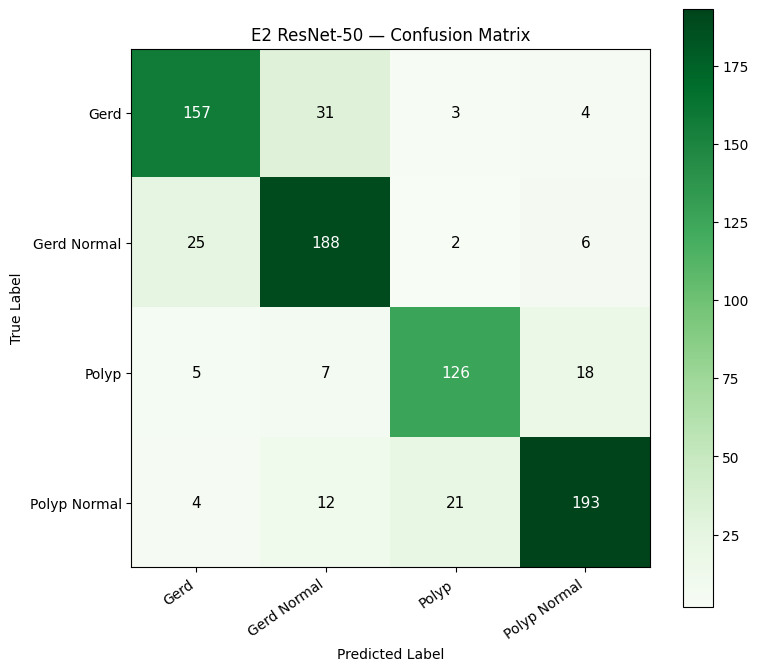

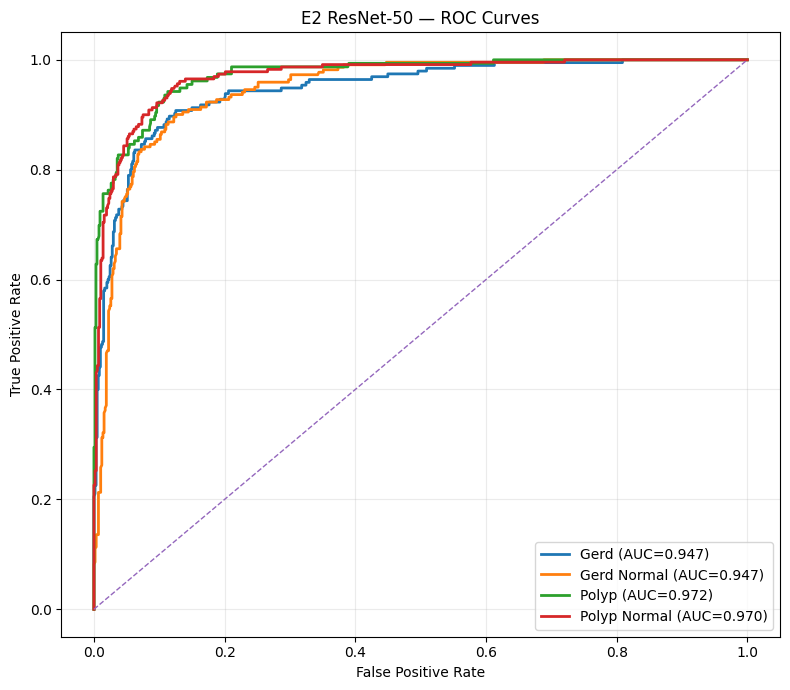

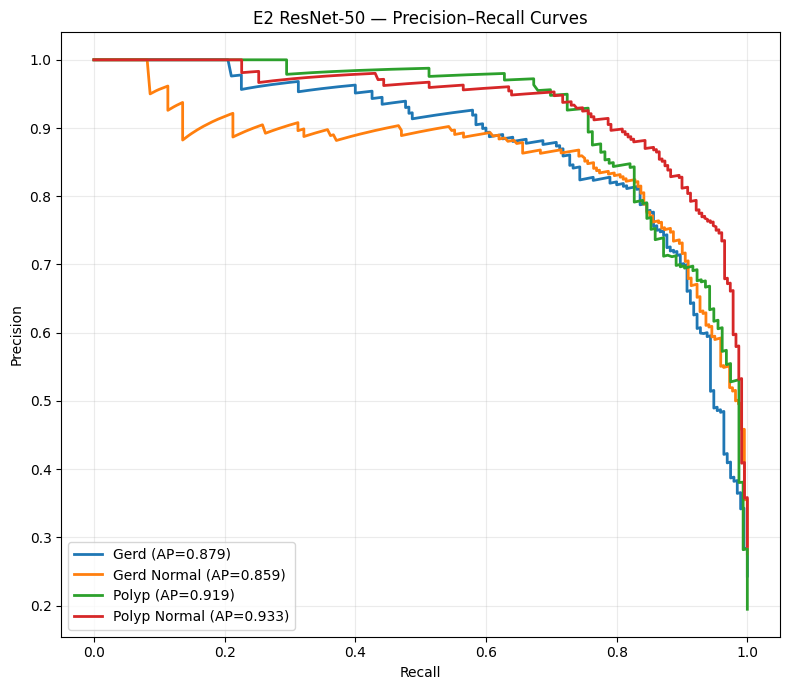

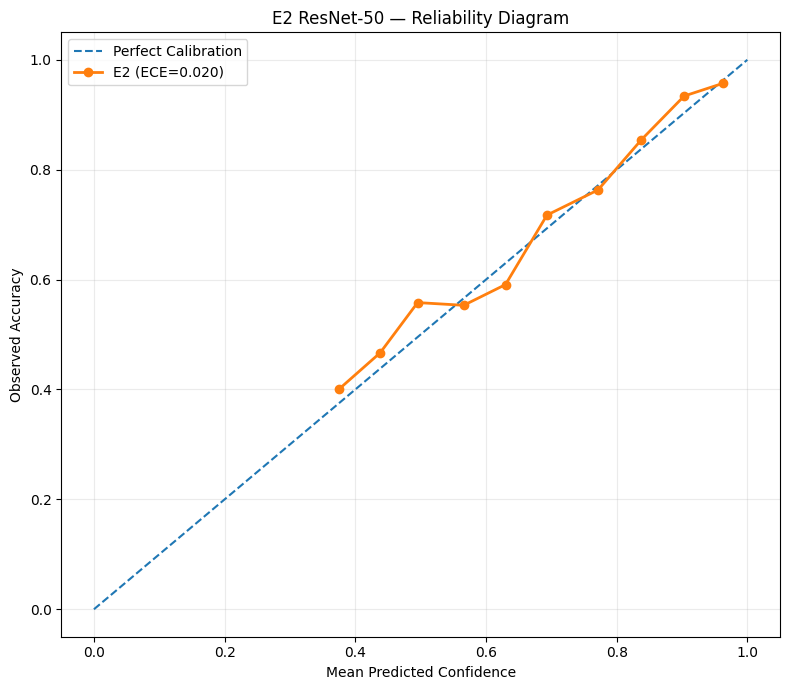


E2 CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Gerd     0.8220    0.8051    0.8135       195
 Gerd Normal     0.7899    0.8507    0.8192       221
       Polyp     0.8289    0.8077    0.8182       156
Polyp Normal     0.8733    0.8391    0.8559       230

    accuracy                         0.8279       802
   macro avg     0.8285    0.8257    0.8267       802
weighted avg     0.8292    0.8279    0.8281       802


E0 / E1 / E2 — MASTER LOCKED TEST COMPARISON
         Experiment  Accuracy  Balanced Accuracy  Macro Precision  Macro Recall  Macro F1    MCC  Macro AUROC  Macro AUPRC  Brier Score    ECE    NLL
       E0 Real Only    0.8092             0.8006           0.8182        0.8006    0.8061 0.7445       0.9486       0.8769       0.3071 0.1131 0.6610
E1 Conventional Aug    0.8217             0.8233           0.8238        0.8233    0.8220 0.7619       0.9581       0.8947       0.2886 0.1209 0.6616
  E2 MixUp + CutMix    0.8279             0

In [ ]:
# ============================================================
# STEP 14 — E2 LOCKED TEST EVALUATION
# + E0 / E1 / E2 MASTER COMPARISON
# ============================================================

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. LOAD BEST E2 MODEL
# ============================================================

print("=" * 80)
print("E2 — LOCKED TEST EVALUATION")
print("=" * 80)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("\nBest epoch:", checkpoint["epoch"])

print(
    "Best validation Macro-F1:",
    f"{checkpoint['best_val_macro_f1']:.4f}"
)


# ============================================================
# 2. RUN TEST INFERENCE
# ============================================================

all_targets = []
all_predictions = []
all_probabilities = []

total_inference_time = 0.0


with torch.no_grad():

    for images, labels in e2_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.perf_counter()


        with torch.amp.autocast(
            device_type="cuda",
            enabled=AMP_ENABLED
        ):

            logits = model(images)


        if torch.cuda.is_available():
            torch.cuda.synchronize()


        total_inference_time += (
            time.perf_counter()
            - start_time
        )


        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )


        all_targets.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )


y_true = np.asarray(all_targets)
y_pred = np.asarray(all_predictions)
y_prob = np.asarray(all_probabilities)


assert len(y_true) == 802

print("\nLocked test images:", len(y_true))


# ============================================================
# 3. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)


# ============================================================
# 4. AUROC + AUPRC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

macro_auroc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = average_precision_score(
    y_true_bin,
    y_prob,
    average="macro"
)


# ============================================================
# 5. CALIBRATION METRICS
# ============================================================

brier = multiclass_brier_score(
    y_true,
    y_prob,
    NUM_CLASSES
)

ece = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
)

nll = log_loss(
    y_true,
    y_prob,
    labels=np.arange(NUM_CLASSES)
)


# ============================================================
# 6. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)


# ============================================================
# 7. PER-CLASS METRICS
# ============================================================

per_class_results = []


for i, class_name in enumerate(CLASS_NAMES):

    TP = cm[i, i]

    FN = (
        cm[i, :].sum()
        - TP
    )

    FP = (
        cm[:, i].sum()
        - TP
    )

    TN = (
        cm.sum()
        - TP
        - FN
        - FP
    )


    sensitivity = (
        TP / (TP + FN)
        if TP + FN > 0
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP > 0
        else 0
    )

    ppv = (
        TP / (TP + FP)
        if TP + FP > 0
        else 0
    )

    npv = (
        TN / (TN + FN)
        if TN + FN > 0
        else 0
    )


    class_f1 = f1_score(
        (y_true == i).astype(int),
        (y_pred == i).astype(int),
        zero_division=0
    )


    class_auc = roc_auc_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )


    class_auprc = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )


    per_class_results.append({

        "Class":
            class_name,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "PPV":
            ppv,

        "NPV":
            npv,

        "F1":
            class_f1,

        "AUROC":
            class_auc,

        "AUPRC":
            class_auprc
    })


per_class_df = pd.DataFrame(
    per_class_results
)


# ============================================================
# 8. SPEED
# ============================================================

latency_ms = (
    total_inference_time
    / len(y_true)
    * 1000
)

throughput = (
    len(y_true)
    / total_inference_time
)


# ============================================================
# 9. PRINT E2 RESULTS
# ============================================================

print("\n" + "=" * 80)
print("E2 — RESNET-50 LOCKED TEST PERFORMANCE")
print("=" * 80)

print(f"Accuracy              : {accuracy:.4f}")
print(f"Balanced Accuracy     : {balanced_acc:.4f}")

print(f"Macro Precision       : {macro_precision:.4f}")
print(f"Macro Recall          : {macro_recall:.4f}")
print(f"Macro F1              : {macro_f1:.4f}")
print(f"Weighted F1           : {weighted_f1:.4f}")

print(f"MCC                   : {mcc:.4f}")
print(f"Cohen's Kappa         : {kappa:.4f}")

print(f"Macro AUROC           : {macro_auroc:.4f}")
print(f"Macro AUPRC           : {macro_auprc:.4f}")

print(f"Brier Score           : {brier:.4f}")
print(f"ECE                   : {ece:.4f}")
print(f"NLL                   : {nll:.4f}")

print(f"Inference latency     : {latency_ms:.3f} ms/image")
print(f"Throughput            : {throughput:.2f} images/sec")


print("\n" + "=" * 80)
print("PER-CLASS PERFORMANCE")
print("=" * 80)

print(
    per_class_df
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 10. SAVE FINAL E2 METRICS
# ============================================================

e2_metrics = {

    "experiment":
        "E2_ResNet50_MixUpCutMix",

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_acc),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_f1":
        float(macro_f1),

    "weighted_f1":
        float(weighted_f1),

    "mcc":
        float(mcc),

    "cohen_kappa":
        float(kappa),

    "macro_auroc":
        float(macro_auroc),

    "macro_auprc":
        float(macro_auprc),

    "brier_score":
        float(brier),

    "ece":
        float(ece),

    "nll":
        float(nll),

    "latency_ms_per_image":
        float(latency_ms),

    "throughput_images_per_second":
        float(throughput),

    "best_epoch":
        int(checkpoint["epoch"]),

    "best_validation_macro_f1":
        float(
            checkpoint["best_val_macro_f1"]
        )
}


with open(
    RESULT_DIR /
    "E2_final_test_metrics.json",
    "w"
) as f:

    json.dump(
        e2_metrics,
        f,
        indent=4
    )


# ============================================================
# 11. SAVE PER-CLASS METRICS
# ============================================================

per_class_df.to_csv(
    RESULT_DIR /
    "E2_per_class_metrics.csv",
    index=False
)


# ============================================================
# 12. SAVE TEST PREDICTIONS
# ============================================================

prediction_df = test_df.copy()

prediction_df["true_id"] = y_true
prediction_df["predicted_id"] = y_pred

prediction_df["true_class"] = [
    CLASS_NAMES[i]
    for i in y_true
]

prediction_df["predicted_class"] = [
    CLASS_NAMES[i]
    for i in y_pred
]

prediction_df["correct"] = (
    y_true == y_pred
)

prediction_df["confidence"] = np.max(
    y_prob,
    axis=1
)


for i, class_name in enumerate(CLASS_NAMES):

    clean_name = (
        class_name
        .lower()
        .replace(" ", "_")
    )

    prediction_df[
        f"prob_{clean_name}"
    ] = y_prob[:, i]


prediction_df.to_csv(
    RESULT_DIR /
    "E2_test_predictions.csv",
    index=False
)


# ============================================================
# 13. CONFUSION MATRIX — GREENS
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    cmap="Greens",
    interpolation="nearest"
)

plt.title(
    "E2 ResNet-50 — Confusion Matrix"
)

plt.colorbar()

ticks = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    ticks,
    CLASS_NAMES
)


threshold = cm.max() / 2


for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            ),
            fontsize=11
        )


plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E2_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(CLASS_NAMES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={roc_auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "E2 ResNet-50 — ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E2_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. PRECISION–RECALL CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(CLASS_NAMES):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true_bin[:, i],
            y_prob[:, i]
        )
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP={ap:.3f})"
        )
    )


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "E2 ResNet-50 — Precision–Recall Curves"
)

plt.legend(
    loc="lower left"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E2_PR_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. RELIABILITY DIAGRAM
# ============================================================

confidences = np.max(
    y_prob,
    axis=1
)

correctness = (
    y_pred == y_true
).astype(float)


bin_edges = np.linspace(
    0,
    1,
    16
)

bin_conf = []
bin_acc = []


for i in range(15):

    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    mask = (
        (confidences > lower)
        &
        (confidences <= upper)
    )

    if mask.sum() > 0:

        bin_conf.append(
            confidences[mask].mean()
        )

        bin_acc.append(
            correctness[mask].mean()
        )


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_conf,
    bin_acc,
    marker="o",
    linewidth=2,
    label=f"E2 (ECE={ece:.3f})"
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "E2 ResNet-50 — Reliability Diagram"
)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E2_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 80)
print("E2 CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 18. LOAD E0 + E1 METRICS
# ============================================================

E0_PATH = (
    PROJECT_DIR /
    "experiments" /
    "E0_ResNet50_RealOnly" /
    "results" /
    "E0_final_test_metrics.json"
)


E1_PATH = (
    PROJECT_DIR /
    "experiments" /
    "E1_ResNet50_ConventionalAug" /
    "results" /
    "E1_final_test_metrics.json"
)


with open(E0_PATH, "r") as f:
    e0 = json.load(f)


with open(E1_PATH, "r") as f:
    e1 = json.load(f)


# ============================================================
# 19. MASTER E0 / E1 / E2 TABLE
# ============================================================

master_comparison = pd.DataFrame({

    "Experiment": [
        "E0 Real Only",
        "E1 Conventional Aug",
        "E2 MixUp + CutMix"
    ],

    "Accuracy": [
        e0["accuracy"],
        e1["accuracy"],
        accuracy
    ],

    "Balanced Accuracy": [
        e0["balanced_accuracy"],
        e1["balanced_accuracy"],
        balanced_acc
    ],

    "Macro Precision": [
        e0["macro_precision"],
        e1["macro_precision"],
        macro_precision
    ],

    "Macro Recall": [
        e0["macro_recall"],
        e1["macro_recall"],
        macro_recall
    ],

    "Macro F1": [
        e0["macro_f1"],
        e1["macro_f1"],
        macro_f1
    ],

    "MCC": [
        e0["mcc"],
        e1["mcc"],
        mcc
    ],

    "Macro AUROC": [
        e0["macro_auroc"],
        e1["macro_auroc"],
        macro_auroc
    ],

    "Macro AUPRC": [
        e0["macro_auprc"],
        e1["macro_auprc"],
        macro_auprc
    ],

    "Brier Score": [
        e0["brier_score"],
        e1["brier_score"],
        brier
    ],

    "ECE": [
        e0["ece"],
        e1["ece"],
        ece
    ],

    "NLL": [
        e0["nll"],
        e1["nll"],
        nll
    ]
})


master_comparison.to_csv(
    RESULT_DIR /
    "E0_E1_E2_master_comparison.csv",
    index=False
)


print("\n" + "=" * 110)
print("E0 / E1 / E2 — MASTER LOCKED TEST COMPARISON")
print("=" * 110)

print(
    master_comparison
    .round(4)
    .to_string(index=False)
)


# ============================================================
# 20. DIFFERENCE VS E1
# ============================================================

print("\n" + "=" * 80)
print("E2 CHANGE RELATIVE TO E1")
print("=" * 80)


metrics_for_delta = {

    "Accuracy":
        accuracy - e1["accuracy"],

    "Balanced Accuracy":
        balanced_acc - e1["balanced_accuracy"],

    "Macro F1":
        macro_f1 - e1["macro_f1"],

    "MCC":
        mcc - e1["mcc"],

    "Macro AUROC":
        macro_auroc - e1["macro_auroc"],

    "Macro AUPRC":
        macro_auprc - e1["macro_auprc"],

    # Negative is improvement for these
    "Brier Score":
        brier - e1["brier_score"],

    "ECE":
        ece - e1["ece"],

    "NLL":
        nll - e1["nll"]
}


for metric, delta in metrics_for_delta.items():

    print(
        f"{metric:<22}: "
        f"{delta:+.4f}"
    )


# ============================================================
# 21. FINAL
# ============================================================

print("\n" + "=" * 80)
print("E2 FINAL EVALUATION COMPLETE")
print("=" * 80)

print("✓ E2 final metrics saved")
print("✓ E2 per-class results saved")
print("✓ E2 predictions saved")
print("✓ Green confusion matrix saved")
print("✓ ROC curves saved")
print("✓ PR curves saved")
print("✓ Reliability curve saved")
print("✓ E0/E1/E2 comparison saved")

# E3 — Real + Unfiltered Diffusion Synthetic

In [ ]:
# ============================================================
# E3 — DIFFUSION ENVIRONMENT + MODEL INITIALIZATION
# ============================================================

!pip -q install -U diffusers transformers accelerate safetensors

import os
import torch
import diffusers
import transformers
from pathlib import Path
from diffusers import AutoPipelineForImage2Image

# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Buet/GI_SAFE")
SPLIT_ROOT   = PROJECT_ROOT / "splits"

E3_DIR = PROJECT_ROOT / "experiments" / "E3_Diffusion_Unfiltered"

E3_SYNTH_DIR      = E3_DIR / "synthetic"
E3_RESULTS_DIR    = E3_DIR / "results"
E3_FIGURES_DIR    = E3_DIR / "figures"
E3_MANIFEST_DIR   = E3_DIR / "manifests"
E3_CHECKPOINT_DIR = E3_DIR / "checkpoints"

for d in [
    E3_DIR,
    E3_SYNTH_DIR,
    E3_RESULTS_DIR,
    E3_FIGURES_DIR,
    E3_MANIFEST_DIR,
    E3_CHECKPOINT_DIR
]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. RUNTIME CHECK
# ============================================================

print("=" * 85)
print("E3 — DIFFUSION RUNTIME")
print("=" * 85)

print("PyTorch      :", torch.__version__)
print("Diffusers    :", diffusers.__version__)
print("Transformers :", transformers.__version__)
print("CUDA         :", torch.cuda.is_available())

if torch.cuda.is_available():

    DEVICE = "cuda"

    print("GPU          :", torch.cuda.get_device_name(0))

    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU memory   : {total_mem:.2f} GB")

else:
    raise RuntimeError(
        "GPU is not enabled. In Colab select Runtime > Change runtime type > GPU."
    )

# ============================================================
# 3. MODEL
# ============================================================

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-v1-5"

print("\n" + "=" * 85)
print("LOADING DIFFUSION MODEL")
print("=" * 85)

print("Model:", MODEL_ID)

# float16 for GPU inference
dtype = torch.float16

pipe = AutoPipelineForImage2Image.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    variant="fp16",
    use_safetensors=True
)

# Move directly to GPU
pipe = pipe.to(DEVICE)

# Disable progress-bar spam during bulk generation later
pipe.set_progress_bar_config(disable=False)

# ============================================================
# 4. MEMORY OPTIMIZATION
# ============================================================

# VAE slicing is safe and helps reduce memory use
try:
    pipe.enable_vae_slicing()
    print("✓ VAE slicing enabled")
except Exception as e:
    print("VAE slicing not enabled:", e)

# Attention slicing usually unnecessary on large GPUs,
# but harmless if supported.
try:
    pipe.enable_attention_slicing()
    print("✓ Attention slicing enabled")
except Exception as e:
    print("Attention slicing not enabled:", e)

# ============================================================
# 5. E3 GENERATION PARAMETERS
# ============================================================

IMAGE_SIZE = 512

E3_STRENGTH = 0.35
E3_GUIDANCE_SCALE = 7.0
E3_STEPS = 30

SYNTHETIC_PER_REAL = 1

print("\n" + "=" * 85)
print("E3 GENERATION CONFIGURATION")
print("=" * 85)

print(f"Image size          : {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Img2Img strength    : {E3_STRENGTH}")
print(f"Guidance scale      : {E3_GUIDANCE_SCALE}")
print(f"Inference steps     : {E3_STEPS}")
print(f"Synthetic / real    : {SYNTHETIC_PER_REAL}:1")
print("Post-generation filter: NONE")

# ============================================================
# 6. NEGATIVE PROMPT
# ============================================================

NEGATIVE_PROMPT = (
    "cartoon, illustration, drawing, painting, "
    "text, watermark, logo, artificial borders, "
    "distorted anatomy, unrealistic anatomy, "
    "duplicate structures, malformed tissue"
)

print("\nNegative prompt:")
print(NEGATIVE_PROMPT)

# ============================================================
# 7. TEST PIPELINE OBJECT
# ============================================================

print("\n" + "=" * 85)
print("PIPELINE STATUS")
print("=" * 85)

print("Pipeline :", type(pipe).__name__)
print("Device   :", pipe.device)

print("\n✓ E3 diffusion model loaded successfully.")
print("✓ No synthetic images generated yet.")
print("✓ Ready for one-image smoke test.")
print("=" * 85)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 87.6 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


E3 — DIFFUSION RUNTIME
PyTorch      : 2.11.0+cu128
Diffusers    : 0.39.0
Transformers : 5.15.0
CUDA         : True
GPU          : NVIDIA A100-SXM4-40GB
GPU memory   : 39.49 GB

LOADING DIFFUSION MODEL
Model: stable-diffusion-v1-5/stable-diffusion-v1-5


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✓ VAE slicing enabled
✓ Attention slicing enabled

E3 GENERATION CONFIGURATION
Image size          : 512 × 512
Img2Img strength    : 0.35
Guidance scale      : 7.0
Inference steps     : 30
Synthetic / real    : 1:1
Post-generation filter: NONE

Negative prompt:
cartoon, illustration, drawing, painting, text, watermark, logo, artificial borders, distorted anatomy, unrealistic anatomy, duplicate structures, malformed tissue

PIPELINE STATUS
Pipeline : StableDiffusionImg2ImgPipeline
Device   : cuda:0

✓ E3 diffusion model loaded successfully.
✓ No synthetic images generated yet.
✓ Ready for one-image smoke test.


/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2273: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionImg2ImgPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


E3 — ONE IMAGE SMOKE TEST
Train samples : 2803
Columns       : ['filepath', 'filename', 'class_name', 'class_id', 'split']

PATH_COL : filepath
LABEL_COL: class_name

Selected source:
Path : /content/drive/MyDrive/Journal/Buet/Original Image/Polyp Normal/normal polyp image  (336).jpg
Class: Polyp Normal

Original size: (549, 510)

Prompt:
realistic clinical gastrointestinal endoscopy photograph showing Polyp Normal, real human gastrointestinal mucosal tissue, natural endoscopic illumination, realistic vascular and mucosal texture, high-detail medical endoscopic imaging

GENERATING...


  0%|          | 0/10 [00:00<?, ?it/s]

✓ Generation complete


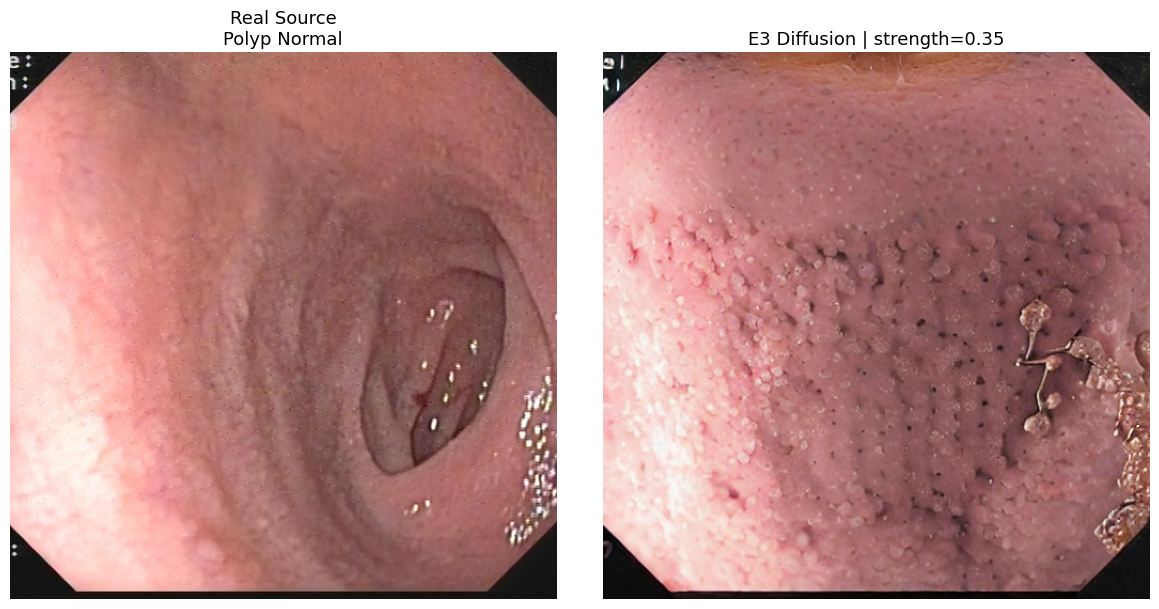


SMOKE TEST COMPLETE
Class        : Polyp Normal
Seed         : 2026
Strength     : 0.35
Guidance     : 7.0
Steps        : 30

Saved:
Real       : /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/smoke_test/source_real.png
Synthetic  : /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/smoke_test/synthetic_diffusion.png
Comparison : /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/smoke_test/real_vs_diffusion.png

IMPORTANT:
✓ This smoke-test image is NOT part of E3 training data.
✓ No fidelity filtering was applied.
✓ Locked validation/test sets remain untouched.


In [ ]:
# ============================================================
# E3 — ONE-IMAGE DIFFUSION SMOKE TEST
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
import matplotlib.pyplot as plt
import torch
import json
import shutil

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Buet/GI_SAFE")
ORIGINAL_ROOT = Path("/content/drive/MyDrive/Journal/Buet/Original Image")

TRAIN_CSV = PROJECT_ROOT / "splits" / "train.csv"

E3_DIR = PROJECT_ROOT / "experiments" / "E3_Diffusion_Unfiltered"

# IMPORTANT:
# Smoke-test outputs are kept separate from real E3 synthetic images.
SMOKE_DIR = E3_DIR / "smoke_test"
SMOKE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. RELOAD LOCKED TRAIN SPLIT
# ------------------------------------------------------------

train_df = pd.read_csv(TRAIN_CSV)

print("=" * 85)
print("E3 — ONE IMAGE SMOKE TEST")
print("=" * 85)

print("Train samples :", len(train_df))
print("Columns       :", list(train_df.columns))

# ------------------------------------------------------------
# 3. DETECT PATH + LABEL COLUMNS
# ------------------------------------------------------------

path_candidates = [
    "filepath", "file_path", "path", "image_path",
    "image", "filename", "file", "relative_path"
]

label_candidates = [
    "label", "class", "class_name",
    "category", "target", "diagnosis"
]

PATH_COL = None
LABEL_COL = None

for candidate in path_candidates:
    for col in train_df.columns:
        if col.lower() == candidate:
            PATH_COL = col
            break
    if PATH_COL:
        break

for candidate in label_candidates:
    for col in train_df.columns:
        if col.lower() == candidate:
            LABEL_COL = col
            break
    if LABEL_COL:
        break

# Fallback: detect path-like column
if PATH_COL is None:
    for col in train_df.columns:

        values = train_df[col].dropna().astype(str)

        if len(values) == 0:
            continue

        sample = values.iloc[0].lower()

        if any(
            ext in sample
            for ext in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"]
        ):
            PATH_COL = col
            break

print("\nPATH_COL :", PATH_COL)
print("LABEL_COL:", LABEL_COL)

if PATH_COL is None:
    raise RuntimeError("Image path column could not be detected.")

# ------------------------------------------------------------
# 4. PATH RESOLVER
# ------------------------------------------------------------

def resolve_image_path(raw_path):

    raw_path = str(raw_path).strip()
    p = Path(raw_path)

    # Existing absolute path
    if p.is_absolute() and p.exists():
        return p

    # Relative path
    candidate = ORIGINAL_ROOT / raw_path

    if candidate.exists():
        return candidate

    # Recover path after "Original Image"
    parts = Path(raw_path).parts

    if "Original Image" in parts:
        idx = parts.index("Original Image")

        relative = Path(*parts[idx + 1:])
        candidate = ORIGINAL_ROOT / relative

        if candidate.exists():
            return candidate

    return None

# ------------------------------------------------------------
# 5. FIND FIRST VALID TRAIN IMAGE
# ------------------------------------------------------------

selected_row = None
SOURCE_PATH = None

for _, row in train_df.iterrows():

    candidate = resolve_image_path(row[PATH_COL])

    if candidate is not None:
        selected_row = row
        SOURCE_PATH = candidate
        break

if SOURCE_PATH is None:
    raise FileNotFoundError(
        "No valid training image could be resolved."
    )

if LABEL_COL is not None:
    CLASS_NAME = str(selected_row[LABEL_COL])
else:
    CLASS_NAME = SOURCE_PATH.parent.name

print("\nSelected source:")
print("Path :", SOURCE_PATH)
print("Class:", CLASS_NAME)

# ------------------------------------------------------------
# 6. LOAD + PREPARE SOURCE IMAGE
# ------------------------------------------------------------

source_original = Image.open(SOURCE_PATH).convert("RGB")

print("\nOriginal size:", source_original.size)

# Center-fit to diffusion resolution
source_512 = ImageOps.fit(
    source_original,
    (512, 512),
    method=Image.Resampling.LANCZOS
)

# ------------------------------------------------------------
# 7. CLASS-CONDITIONED PROMPT
# ------------------------------------------------------------

PROMPT = (
    f"realistic clinical gastrointestinal endoscopy photograph showing {CLASS_NAME}, "
    f"real human gastrointestinal mucosal tissue, "
    f"natural endoscopic illumination, realistic vascular and mucosal texture, "
    f"high-detail medical endoscopic imaging"
)

NEGATIVE_PROMPT = (
    "cartoon, illustration, drawing, painting, CGI, "
    "text, watermark, logo, synthetic-looking tissue, "
    "distorted anatomy, malformed anatomy, duplicate structures, "
    "unrealistic colors, blurry image"
)

print("\nPrompt:")
print(PROMPT)

# ------------------------------------------------------------
# 8. FIXED RANDOM SEED
# ------------------------------------------------------------

SEED = 2026

generator = torch.Generator(
    device="cuda"
).manual_seed(SEED)

# ------------------------------------------------------------
# 9. GENERATE ONE SYNTHETIC IMAGE
# ------------------------------------------------------------

print("\n" + "=" * 85)
print("GENERATING...")
print("=" * 85)

with torch.inference_mode():

    output = pipe(
        prompt=PROMPT,
        negative_prompt=NEGATIVE_PROMPT,
        image=source_512,
        strength=E3_STRENGTH,
        guidance_scale=E3_GUIDANCE_SCALE,
        num_inference_steps=E3_STEPS,
        generator=generator
    )

synthetic_img = output.images[0]

print("✓ Generation complete")

# ------------------------------------------------------------
# 10. SAVE SMOKE TEST ONLY
# ------------------------------------------------------------

source_save = SMOKE_DIR / "source_real.png"
synthetic_save = SMOKE_DIR / "synthetic_diffusion.png"

source_512.save(source_save)
synthetic_img.save(synthetic_save)

metadata = {
    "experiment": "E3_Diffusion_Unfiltered",
    "purpose": "pipeline_smoke_test_only",
    "included_in_training": False,
    "source_image": str(SOURCE_PATH),
    "class": CLASS_NAME,
    "seed": SEED,
    "strength": E3_STRENGTH,
    "guidance_scale": E3_GUIDANCE_SCALE,
    "num_inference_steps": E3_STEPS,
    "prompt": PROMPT,
    "negative_prompt": NEGATIVE_PROMPT
}

with open(SMOKE_DIR / "smoke_test_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# ------------------------------------------------------------
# 11. DISPLAY REAL VS DIFFUSION
# ------------------------------------------------------------

fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(source_512)
ax1.set_title(
    f"Real Source\n{CLASS_NAME}",
    fontsize=13
)
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(synthetic_img)
ax2.set_title(
    f"E3 Diffusion | strength={E3_STRENGTH}",
    fontsize=13
)
ax2.axis("off")

plt.tight_layout()

comparison_path = SMOKE_DIR / "real_vs_diffusion.png"
plt.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 12. SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 85)
print("SMOKE TEST COMPLETE")
print("=" * 85)

print("Class        :", CLASS_NAME)
print("Seed         :", SEED)
print("Strength     :", E3_STRENGTH)
print("Guidance     :", E3_GUIDANCE_SCALE)
print("Steps        :", E3_STEPS)

print("\nSaved:")
print("Real       :", source_save)
print("Synthetic  :", synthetic_save)
print("Comparison :", comparison_path)

print("\nIMPORTANT:")
print("✓ This smoke-test image is NOT part of E3 training data.")
print("✓ No fidelity filtering was applied.")
print("✓ Locked validation/test sets remain untouched.")

print("=" * 85)

E3 — CLASS-WISE DIFFUSION SMOKE TEST
Train samples: 2803
Columns: ['filepath', 'filename', 'class_name', 'class_id', 'split']

PATH_COL : filepath
LABEL_COL: class_name

TRAIN CLASS DISTRIBUTION
class_name
Gerd            681
Gerd Normal     772
Polyp           545
Polyp Normal    805
Name: count, dtype: int64

Number of classes: 4
✓ Gerd                           → gerd image  (378).jpg
✓ Gerd Normal                    → normal z line  (427).jpg
✓ Polyp                          → polyp image (594).jpg
✓ Polyp Normal                   → normal polyp image  (336).jpg

GENERATING CLASS-WISE SYNTHETIC IMAGES

[1/4] Gerd


  0%|          | 0/10 [00:00<?, ?it/s]

✓ Generated

[2/4] Gerd Normal


  0%|          | 0/10 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


✓ Generated

[3/4] Polyp


  0%|          | 0/10 [00:00<?, ?it/s]

✓ Generated

[4/4] Polyp Normal


  0%|          | 0/10 [00:00<?, ?it/s]

✓ Generated


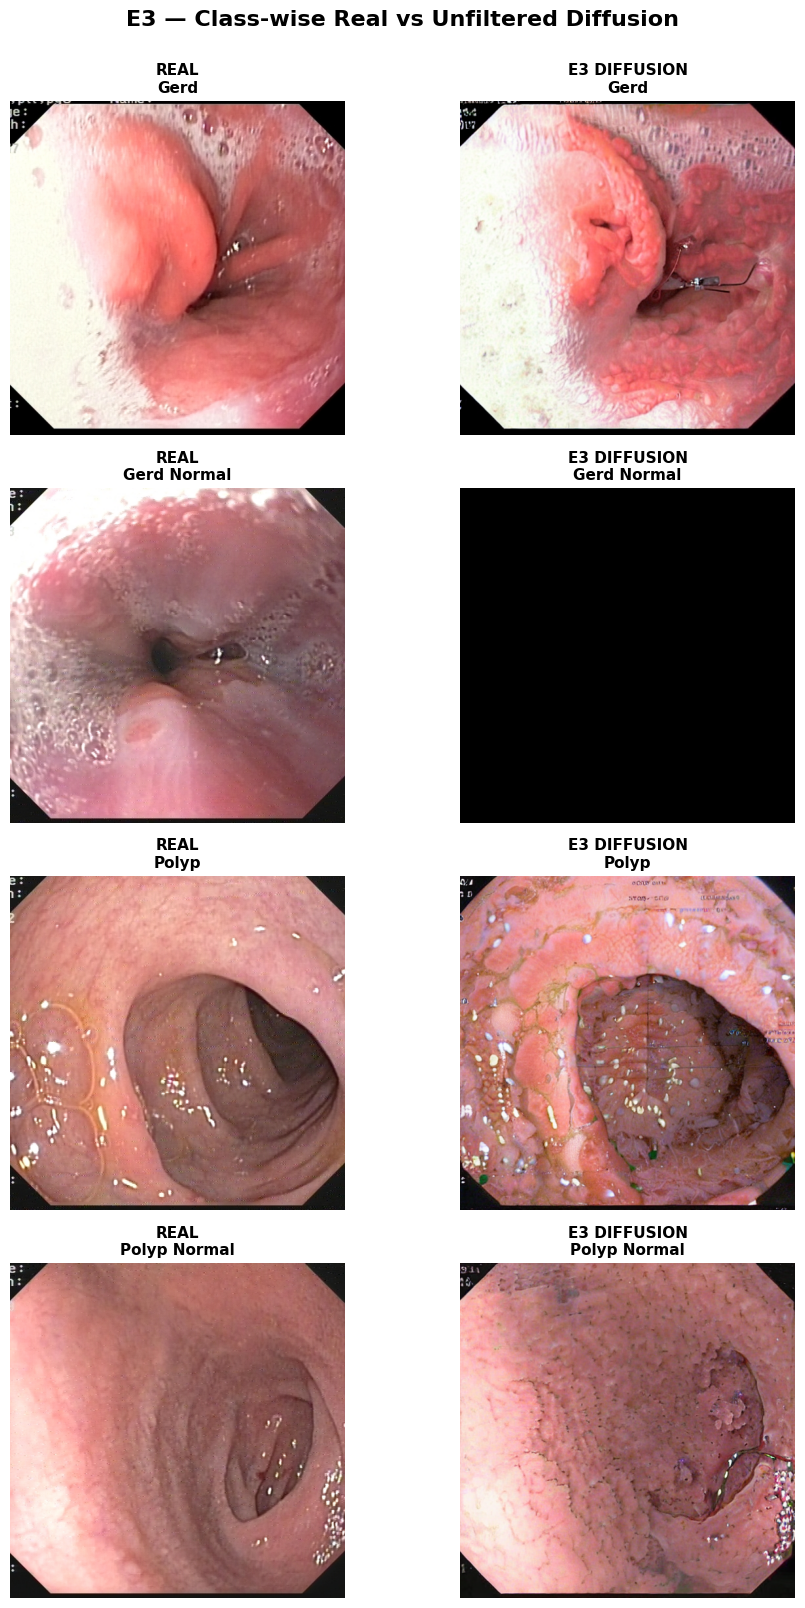


CLASS-WISE SMOKE TEST COMPLETE
Classes tested : 4
Strength       : 0.35
Guidance       : 7.0
Steps          : 30

Montage saved  : /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/class_smoke_test/E3_all_classes_real_vs_diffusion.png

✓ These images are TEST-ONLY.
✓ They are NOT inside the E3 training synthetic folder.
✓ No synthetic filtering was performed.
✓ Validation and test data remain untouched.


In [ ]:
# ============================================================
# E3 — ONE DIFFUSION SAMPLE FROM EVERY CLASS
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
import matplotlib.pyplot as plt
import torch
import json
import math

# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Buet/GI_SAFE")
ORIGINAL_ROOT = Path("/content/drive/MyDrive/Journal/Buet/Original Image")

TRAIN_CSV = PROJECT_ROOT / "splits" / "train.csv"

E3_DIR = PROJECT_ROOT / "experiments" / "E3_Diffusion_Unfiltered"

CLASS_TEST_DIR = E3_DIR / "class_smoke_test"
CLASS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. LOAD LOCKED TRAIN SPLIT
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)

print("=" * 90)
print("E3 — CLASS-WISE DIFFUSION SMOKE TEST")
print("=" * 90)

print("Train samples:", len(train_df))
print("Columns:", list(train_df.columns))

# ============================================================
# 3. DETECT PATH AND LABEL COLUMNS
# ============================================================

path_candidates = [
    "filepath",
    "file_path",
    "path",
    "image_path",
    "image",
    "filename",
    "file",
    "relative_path"
]

label_candidates = [
    "label",
    "class",
    "class_name",
    "category",
    "target",
    "diagnosis"
]

PATH_COL = None
LABEL_COL = None

for candidate in path_candidates:
    for col in train_df.columns:
        if col.lower() == candidate:
            PATH_COL = col
            break
    if PATH_COL:
        break

for candidate in label_candidates:
    for col in train_df.columns:
        if col.lower() == candidate:
            LABEL_COL = col
            break
    if LABEL_COL:
        break

# fallback path detection
if PATH_COL is None:

    for col in train_df.columns:

        values = train_df[col].dropna().astype(str)

        if len(values) == 0:
            continue

        sample = values.iloc[0].lower()

        if any(
            ext in sample
            for ext in [
                ".jpg",
                ".jpeg",
                ".png",
                ".bmp",
                ".tif",
                ".tiff",
                ".webp"
            ]
        ):
            PATH_COL = col
            break

if PATH_COL is None:
    raise RuntimeError("Could not detect image path column.")

if LABEL_COL is None:
    raise RuntimeError("Could not detect class label column.")

print("\nPATH_COL :", PATH_COL)
print("LABEL_COL:", LABEL_COL)

# ============================================================
# 4. RESOLVE IMAGE PATH
# ============================================================

def resolve_image_path(raw_path):

    raw_path = str(raw_path).strip()

    p = Path(raw_path)

    # already correct
    if p.is_absolute() and p.exists():
        return p

    # relative to original root
    candidate = ORIGINAL_ROOT / raw_path

    if candidate.exists():
        return candidate

    # recover path after "Original Image"
    parts = Path(raw_path).parts

    if "Original Image" in parts:

        idx = parts.index("Original Image")

        relative = Path(*parts[idx + 1:])

        candidate = ORIGINAL_ROOT / relative

        if candidate.exists():
            return candidate

    return None

# ============================================================
# 5. SHOW CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 90)
print("TRAIN CLASS DISTRIBUTION")
print("=" * 90)

class_counts = (
    train_df[LABEL_COL]
    .astype(str)
    .value_counts()
    .sort_index()
)

print(class_counts)

classes = sorted(
    train_df[LABEL_COL]
    .astype(str)
    .unique()
)

print("\nNumber of classes:", len(classes))

# ============================================================
# 6. SELECT ONE VALID IMAGE PER CLASS
# ============================================================

selected_samples = []

for class_name in classes:

    class_df = train_df[
        train_df[LABEL_COL].astype(str) == class_name
    ]

    selected = None

    for _, row in class_df.iterrows():

        path = resolve_image_path(row[PATH_COL])

        if path is not None:

            selected = {
                "class": class_name,
                "path": path
            }

            break

    if selected is None:

        print(f"⚠ No valid image found for: {class_name}")

    else:

        selected_samples.append(selected)

        print(
            f"✓ {class_name:<30} → {selected['path'].name}"
        )

# ============================================================
# 7. GENERATION SETTINGS
# ============================================================

STRENGTH = 0.35
GUIDANCE = 7.0
STEPS = 30

BASE_SEED = 2026

NEGATIVE_PROMPT = (
    "cartoon, illustration, drawing, painting, CGI, "
    "text, watermark, logo, synthetic-looking tissue, "
    "distorted anatomy, malformed anatomy, "
    "duplicate structures, unrealistic colors, "
    "blurry, low quality"
)

# ============================================================
# 8. GENERATE ONE IMAGE PER CLASS
# ============================================================

results = []

print("\n" + "=" * 90)
print("GENERATING CLASS-WISE SYNTHETIC IMAGES")
print("=" * 90)

for idx, sample in enumerate(selected_samples):

    class_name = sample["class"]
    source_path = sample["path"]

    print(
        f"\n[{idx + 1}/{len(selected_samples)}] "
        f"{class_name}"
    )

    # -----------------------------
    # LOAD SOURCE
    # -----------------------------

    real_image = Image.open(
        source_path
    ).convert("RGB")

    real_512 = ImageOps.fit(
        real_image,
        (512, 512),
        method=Image.Resampling.LANCZOS
    )

    # -----------------------------
    # PROMPT
    # -----------------------------

    prompt = (
        f"realistic clinical gastrointestinal endoscopy photograph "
        f"showing {class_name}, "
        f"real human gastrointestinal mucosal tissue, "
        f"natural endoscopic illumination, "
        f"realistic mucosal texture and vascular structures, "
        f"clinical medical endoscopic imaging"
    )

    # -----------------------------
    # UNIQUE REPRODUCIBLE SEED
    # -----------------------------

    seed = BASE_SEED + idx

    generator = torch.Generator(
        device="cuda"
    ).manual_seed(seed)

    # -----------------------------
    # GENERATE
    # -----------------------------

    with torch.inference_mode():

        output = pipe(
            prompt=prompt,
            negative_prompt=NEGATIVE_PROMPT,
            image=real_512,
            strength=STRENGTH,
            guidance_scale=GUIDANCE,
            num_inference_steps=STEPS,
            generator=generator
        )

    synthetic = output.images[0]

    # -----------------------------
    # SAFE CLASS FOLDER NAME
    # -----------------------------

    safe_class = (
        class_name
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
    )

    class_dir = CLASS_TEST_DIR / safe_class
    class_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    real_path = class_dir / "real.png"
    synth_path = class_dir / "synthetic.png"

    real_512.save(real_path)
    synthetic.save(synth_path)

    # -----------------------------
    # SAVE RESULT
    # -----------------------------

    results.append({

        "class": class_name,

        "source_path":
            str(source_path),

        "real_image":
            real_512,

        "synthetic_image":
            synthetic,

        "seed":
            seed,

        "prompt":
            prompt,

        "real_saved":
            str(real_path),

        "synthetic_saved":
            str(synth_path)
    })

    print("✓ Generated")

# ============================================================
# 9. CREATE REAL VS SYNTHETIC MONTAGE
# ============================================================

n_classes = len(results)

fig, axes = plt.subplots(
    n_classes,
    2,
    figsize=(10, 4 * n_classes)
)

if n_classes == 1:
    axes = [axes]

for i, result in enumerate(results):

    # REAL
    axes[i][0].imshow(
        result["real_image"]
    )

    axes[i][0].set_title(
        f"REAL\n{result['class']}",
        fontsize=11,
        fontweight="bold"
    )

    axes[i][0].axis("off")

    # SYNTHETIC
    axes[i][1].imshow(
        result["synthetic_image"]
    )

    axes[i][1].set_title(
        f"E3 DIFFUSION\n{result['class']}",
        fontsize=11,
        fontweight="bold"
    )

    axes[i][1].axis("off")

plt.suptitle(
    "E3 — Class-wise Real vs Unfiltered Diffusion",
    fontsize=16,
    fontweight="bold",
    y=1.002
)

plt.tight_layout()

montage_path = (
    CLASS_TEST_DIR /
    "E3_all_classes_real_vs_diffusion.png"
)

plt.savefig(
    montage_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 10. SAVE METADATA
# ============================================================

metadata = []

for result in results:

    metadata.append({

        "class":
            result["class"],

        "source_path":
            result["source_path"],

        "seed":
            result["seed"],

        "strength":
            STRENGTH,

        "guidance_scale":
            GUIDANCE,

        "num_steps":
            STEPS,

        "prompt":
            result["prompt"],

        "included_in_training":
            False
    })

metadata_path = (
    CLASS_TEST_DIR /
    "class_smoke_test_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )

# ============================================================
# 11. FINAL REPORT
# ============================================================

print("\n" + "=" * 90)
print("CLASS-WISE SMOKE TEST COMPLETE")
print("=" * 90)

print(
    "Classes tested :",
    len(results)
)

print(
    "Strength       :",
    STRENGTH
)

print(
    "Guidance       :",
    GUIDANCE
)

print(
    "Steps          :",
    STEPS
)

print(
    "\nMontage saved  :",
    montage_path
)

print(
    "\n✓ These images are TEST-ONLY."
)

print(
    "✓ They are NOT inside the E3 training synthetic folder."
)

print(
    "✓ No synthetic filtering was performed."
)

print(
    "✓ Validation and test data remain untouched."
)

print("=" * 90)

In [ ]:
# ============================================================
# E3 — FIXED CLASS-WISE PARAMETER TUNING
# Robust filename resolution + fair strength comparison
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
import matplotlib.pyplot as plt
import torch
from collections import defaultdict
import re

# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

TRAIN_CSV = PROJECT_ROOT / "splits" / "train.csv"

E3_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E3_Diffusion_Unfiltered"
)

TUNING_DIR = E3_DIR / "parameter_tuning"
TUNING_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. SAFETY CHECKER
# ============================================================

# Remove only the checker itself.
# Do NOT access deprecated requires_safety_checker attribute.
if hasattr(pipe, "safety_checker"):
    pipe.safety_checker = None

print("✓ Safety checker disabled for medical-image generation")

# ============================================================
# 3. LOAD LOCKED TRAIN SPLIT
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)

PATH_COL = "filename"
LABEL_COL = "class_name"

print("\n" + "=" * 90)
print("LOCKED TRAIN SPLIT")
print("=" * 90)

print("Rows    :", len(train_df))
print("Columns :", list(train_df.columns))

print("\nFirst rows:")
print(
    train_df[
        [PATH_COL, LABEL_COL]
    ].head().to_string(index=False)
)

print("\nClass distribution:")
print(
    train_df[LABEL_COL]
    .value_counts()
    .sort_index()
)

# ============================================================
# 4. INDEX ALL ORIGINAL IMAGES
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

print("\n" + "=" * 90)
print("INDEXING ORIGINAL DATASET")
print("=" * 90)

all_images = [
    p
    for p in ORIGINAL_ROOT.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMG_EXTS
]

print("Total original images indexed:", len(all_images))

if len(all_images) == 0:
    raise RuntimeError(
        f"No images found inside:\n{ORIGINAL_ROOT}"
    )

# basename -> possible full paths
filename_index = defaultdict(list)

for p in all_images:
    filename_index[p.name].append(p)

print("Unique filenames:", len(filename_index))

# ============================================================
# 5. NORMALIZATION HELPER
# ============================================================

def normalize_text(x):

    x = str(x).lower().strip()

    # remove spaces, underscores, hyphens etc.
    return re.sub(r"[^a-z0-9]", "", x)

# ============================================================
# 6. CLASS-AWARE FILE RESOLVER
# ============================================================

def resolve_from_filename(filename, class_name):

    filename = Path(str(filename)).name

    candidates = filename_index.get(
        filename,
        []
    )

    if len(candidates) == 0:
        return None

    # --------------------------------------------
    # Exact unique filename
    # --------------------------------------------

    if len(candidates) == 1:
        return candidates[0]

    # --------------------------------------------
    # Multiple files with same basename:
    # prefer path containing class name
    # --------------------------------------------

    normalized_class = normalize_text(
        class_name
    )

    class_matches = []

    for p in candidates:

        parent_parts = [
            normalize_text(part)
            for part in p.parts
        ]

        if normalized_class in parent_parts:
            class_matches.append(p)

    if len(class_matches) == 1:
        return class_matches[0]

    # --------------------------------------------
    # Flexible class matching
    # --------------------------------------------

    if len(class_matches) == 0:

        for p in candidates:

            path_text = normalize_text(
                str(p.parent)
            )

            if normalized_class in path_text:
                class_matches.append(p)

    if len(class_matches) == 1:
        return class_matches[0]

    # Ambiguous — don't guess
    return None

# ============================================================
# 7. RESOLVE EVERY TRAIN IMAGE
# ============================================================

train_df["resolved_path"] = train_df.apply(
    lambda r: resolve_from_filename(
        r[PATH_COL],
        r[LABEL_COL]
    ),
    axis=1
)

resolved_count = (
    train_df["resolved_path"]
    .notna()
    .sum()
)

missing_count = (
    len(train_df)
    - resolved_count
)

print("\n" + "=" * 90)
print("PATH RESOLUTION")
print("=" * 90)

print("Train rows :", len(train_df))
print("Resolved   :", resolved_count)
print("Missing    :", missing_count)

# Show unresolved examples if any
if missing_count > 0:

    print("\nFirst unresolved examples:")

    print(
        train_df[
            train_df["resolved_path"].isna()
        ][
            [PATH_COL, LABEL_COL]
        ]
        .head(15)
        .to_string(index=False)
    )

# We should resolve essentially everything
if resolved_count == 0:
    raise RuntimeError(
        "Still unable to resolve any training images."
    )

# ============================================================
# 8. SELECT ONE VALID SOURCE PER CLASS
# ============================================================

classes = sorted(
    train_df[LABEL_COL]
    .astype(str)
    .unique()
)

samples = []

print("\n" + "=" * 90)
print("SELECTED CLASS SAMPLES")
print("=" * 90)

for class_name in classes:

    subset = train_df[
        (
            train_df[LABEL_COL]
            .astype(str)
            == class_name
        )
        &
        (
            train_df["resolved_path"]
            .notna()
        )
    ]

    if len(subset) == 0:

        print(
            f"✗ No valid source for: {class_name}"
        )

        continue

    row = subset.iloc[0]

    path = Path(
        row["resolved_path"]
    )

    samples.append(
        {
            "class": class_name,
            "path": path
        }
    )

    print(
        f"✓ {class_name:<25} "
        f"→ {path}"
    )

print(
    "\nClasses successfully selected:",
    len(samples),
    "/",
    len(classes)
)

if len(samples) == 0:
    raise RuntimeError(
        "No class samples available."
    )

# ============================================================
# 9. PARAMETER SETTINGS
# ============================================================

STRENGTHS = [
    0.15,
    0.20,
    0.25
]

GUIDANCE_SCALE = 4.0

NUM_STEPS = 40

BASE_SEED = 2026

NEGATIVE_PROMPT = (
    "text, letters, numbers, watermark, caption, logo, "
    "cartoon, illustration, drawing, painting, CGI, "
    "new lesion, additional lesion, missing lesion, "
    "changed lesion, changed anatomy, distorted anatomy, "
    "duplicate anatomy, artificial structure, "
    "medical instrument, unrealistic tissue, "
    "unrealistic mucosa, severe color distortion"
)

def make_prompt():

    return (
        "realistic clinical gastrointestinal endoscopy image, "
        "preserve the same anatomical structure and diagnostic appearance "
        "as the source image, "
        "preserve lesion morphology and lesion location when present, "
        "preserve lumen and mucosal structures, "
        "subtle realistic variation in illumination, "
        "mucosal color and fine texture, "
        "natural high-quality medical endoscopic photograph"
    )

# ============================================================
# 10. GENERATE
#
# IMPORTANT:
# SAME SEED across strengths for each class
# ============================================================

results = []

print("\n" + "=" * 90)
print("STARTING FAIR STRENGTH COMPARISON")
print("=" * 90)

for class_idx, sample in enumerate(samples):

    class_name = sample["class"]
    source_path = sample["path"]

    print(
        f"\n[{class_idx + 1}/{len(samples)}] "
        f"{class_name}"
    )

    # ----------------------------------------
    # Load
    # ----------------------------------------

    real = Image.open(
        source_path
    ).convert("RGB")

    real = ImageOps.fit(
        real,
        (512, 512),
        method=Image.Resampling.LANCZOS
    )

    prompt = make_prompt()

    # ONE seed for this source
    class_seed = (
        BASE_SEED
        + class_idx
    )

    row_result = {
        "class": class_name,
        "real": real,
        "synthetics": {},
        "seed": class_seed
    }

    # ----------------------------------------
    # Different strengths, SAME seed
    # ----------------------------------------

    for strength in STRENGTHS:

        generator = torch.Generator(
            device="cuda"
        ).manual_seed(
            class_seed
        )

        print(
            f"   strength={strength:.2f}",
            end=" ... "
        )

        with torch.inference_mode():

            output = pipe(
                prompt=prompt,
                negative_prompt=NEGATIVE_PROMPT,
                image=real,
                strength=strength,
                guidance_scale=GUIDANCE_SCALE,
                num_inference_steps=NUM_STEPS,
                generator=generator
            )

        synthetic = output.images[0]

        row_result[
            "synthetics"
        ][strength] = synthetic

        print("✓")

    results.append(
        row_result
    )

# ============================================================
# 11. MONTAGE
# ============================================================

n_classes = len(results)

print(
    "\nCreating montage for",
    n_classes,
    "classes..."
)

fig, axes = plt.subplots(
    nrows=n_classes,
    ncols=4,
    figsize=(
        16,
        max(4, 4 * n_classes)
    ),
    squeeze=False
)

for i, result in enumerate(results):

    # REAL
    axes[i, 0].imshow(
        result["real"]
    )

    axes[i, 0].set_title(
        f"REAL\n{result['class']}",
        fontweight="bold"
    )

    axes[i, 0].axis("off")

    # SYNTHETIC
    for j, strength in enumerate(
        STRENGTHS
    ):

        axes[
            i,
            j + 1
        ].imshow(
            result[
                "synthetics"
            ][strength]
        )

        axes[
            i,
            j + 1
        ].set_title(
            f"Strength = {strength:.2f}\n"
            f"Seed = {result['seed']}",
            fontweight="bold"
        )

        axes[
            i,
            j + 1
        ].axis("off")

plt.suptitle(
    "E3 Diffusion Strength Selection\n"
    "Same source + same random seed for fair comparison",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

figure_path = (
    TUNING_DIR /
    "E3_strength_comparison_fixed.png"
)

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 12. FINAL STATUS
# ============================================================

print("\n" + "=" * 90)
print("E3 PARAMETER TEST COMPLETE")
print("=" * 90)

print("Classes tested :", len(results))
print("Strengths      :", STRENGTHS)
print("Guidance       :", GUIDANCE_SCALE)
print("Steps          :", NUM_STEPS)

print(
    "\nFigure:",
    figure_path
)

print("\nIMPORTANT:")
print("✓ Same source image used within each row")
print("✓ Same seed used across the 3 strengths")
print("✓ Only diffusion strength changes")
print("✓ These tuning images are NOT training data")
print("✓ No fidelity filtering performed")

print("=" * 90)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# E3 — FULL UNFILTERED DIFFUSION GENERATION
# Real train → 1 synthetic image per real train image
#
# FINAL PARAMETERS:
# strength = 0.20
# guidance = 4.0
# steps    = 40
#
# IMPORTANT:
# - TRAIN images only
# - NO fidelity filtering
# - NO synthetic val/test
# - Resume-safe
# ============================================================

from pathlib import Path
from PIL import Image, ImageOps
import pandas as pd
import torch
import hashlib
import json
import time
import re
from collections import defaultdict
from tqdm.auto import tqdm

# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

TRAIN_CSV = PROJECT_ROOT / "splits" / "train.csv"

E3_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E3_Diffusion_Unfiltered"
)

SYNTH_ROOT = E3_DIR / "synthetic"
MANIFEST_DIR = E3_DIR / "manifests"

SYNTH_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MANIFEST_CSV = (
    MANIFEST_DIR /
    "E3_generation_manifest.csv"
)

ERROR_CSV = (
    MANIFEST_DIR /
    "E3_generation_errors.csv"
)

CONFIG_JSON = (
    MANIFEST_DIR /
    "E3_generation_config.json"
)

# ============================================================
# 2. FINAL FROZEN E3 PARAMETERS
# ============================================================

IMAGE_SIZE = 512

STRENGTH = 0.20
GUIDANCE_SCALE = 4.0
NUM_STEPS = 40

SYNTHETIC_PER_REAL = 1

BASE_SEED = 202600

print("=" * 90)
print("E3 — FULL UNFILTERED DIFFUSION GENERATION")
print("=" * 90)

print(f"Strength       : {STRENGTH}")
print(f"Guidance       : {GUIDANCE_SCALE}")
print(f"Steps          : {NUM_STEPS}")
print(f"Resolution     : {IMAGE_SIZE} × {IMAGE_SIZE}")
print(f"Synthetic/real : {SYNTHETIC_PER_REAL}:1")
print("Filtering      : NONE")

# ============================================================
# 3. CHECK PIPELINE
# ============================================================

if "pipe" not in globals():

    raise RuntimeError(
        "Diffusion pipeline 'pipe' is not loaded. "
        "Run the E3 model-loading cell first."
    )

print("\nPipeline:", type(pipe).__name__)
print("Device  :", pipe.device)

# Safety checker off for medical images
if hasattr(pipe, "safety_checker"):

    pipe.safety_checker = None

# Disable progress bar inside diffusion call
# because tqdm below already tracks total generation
pipe.set_progress_bar_config(
    disable=True
)

# ============================================================
# 4. LOAD LOCKED TRAIN SPLIT
# ============================================================

train_df = pd.read_csv(
    TRAIN_CSV
).reset_index(drop=True)

PATH_COL = "filename"
LABEL_COL = "class_name"

if PATH_COL not in train_df.columns:

    raise RuntimeError(
        f"{PATH_COL} not found in train.csv"
    )

if LABEL_COL not in train_df.columns:

    raise RuntimeError(
        f"{LABEL_COL} not found in train.csv"
    )

print(
    "\nLocked training samples:",
    len(train_df)
)

print(
    "Classes:",
    train_df[LABEL_COL].nunique()
)

print("\nClass distribution:")

print(
    train_df[
        LABEL_COL
    ].value_counts().sort_index()
)

# ============================================================
# 5. INDEX ORIGINAL DATASET
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

print("\nIndexing original images...")

all_images = [
    p
    for p in ORIGINAL_ROOT.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMG_EXTS
]

filename_index = defaultdict(list)

for p in all_images:

    filename_index[
        p.name
    ].append(p)

print(
    "Original images indexed:",
    len(all_images)
)

# ============================================================
# 6. HELPERS
# ============================================================

def normalize_text(x):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower().strip()
    )


def safe_name(x):

    x = str(x).strip()

    x = re.sub(
        r'[<>:"/\\|?*]',
        "_",
        x
    )

    return x


def resolve_source(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = filename_index.get(
        filename,
        []
    )

    # no file
    if len(candidates) == 0:
        return None

    # unique basename
    if len(candidates) == 1:
        return candidates[0]

    # class-aware resolution
    class_norm = normalize_text(
        class_name
    )

    matches = []

    for p in candidates:

        parent_norm = normalize_text(
            str(p.parent)
        )

        if class_norm in parent_norm:
            matches.append(p)

    if len(matches) == 1:
        return matches[0]

    # Never guess ambiguous paths
    return None


def create_output_name(
    row_id,
    source_path,
    class_name
):

    source_string = (
        f"{row_id}|"
        f"{class_name}|"
        f"{source_path}"
    )

    short_hash = hashlib.sha1(
        source_string.encode()
    ).hexdigest()[:10]

    stem = safe_name(
        source_path.stem
    )

    return (
        f"E3_{row_id:05d}_"
        f"{stem}_"
        f"{short_hash}.png"
    )


def make_prompt(class_name):

    return (
        f"realistic clinical gastrointestinal endoscopy image, "
        f"diagnostic category {class_name}, "
        f"preserve the same anatomical structure and diagnostic "
        f"appearance as the source image, "
        f"preserve lesion morphology and lesion location when present, "
        f"preserve gastrointestinal lumen and mucosal structures, "
        f"subtle realistic variation in illumination, mucosal color "
        f"and fine texture, "
        f"natural high-quality medical endoscopic photograph"
    )


NEGATIVE_PROMPT = (
    "text, letters, numbers, watermark, caption, logo, "
    "cartoon, illustration, drawing, painting, CGI, "
    "new lesion, additional lesion, missing lesion, "
    "changed lesion, changed anatomy, distorted anatomy, "
    "duplicate anatomy, artificial structure, "
    "medical instrument, unrealistic tissue, "
    "unrealistic mucosa, severe color distortion"
)

# ============================================================
# 7. RESOLVE ALL TRAIN SOURCES
# ============================================================

print("\nResolving locked training paths...")

train_df["resolved_path"] = train_df.apply(

    lambda row: resolve_source(
        row[PATH_COL],
        row[LABEL_COL]
    ),

    axis=1
)

resolved = (
    train_df["resolved_path"]
    .notna()
    .sum()
)

missing = (
    len(train_df)
    - resolved
)

print(
    "Resolved:",
    resolved
)

print(
    "Missing :",
    missing
)

if missing > 0:

    print("\nUnresolved examples:")

    print(
        train_df[
            train_df["resolved_path"].isna()
        ][
            [PATH_COL, LABEL_COL]
        ]
        .head(20)
        .to_string(index=False)
    )

if resolved == 0:

    raise RuntimeError(
        "No training images resolved."
    )

# ============================================================
# 8. CREATE CLASS OUTPUT DIRECTORIES
# ============================================================

classes = sorted(
    train_df[LABEL_COL]
    .astype(str)
    .unique()
)

for cls in classes:

    (
        SYNTH_ROOT /
        safe_name(cls)
    ).mkdir(
        parents=True,
        exist_ok=True
    )

# ============================================================
# 9. LOAD EXISTING MANIFEST FOR RESUME
# ============================================================

if MANIFEST_CSV.exists():

    existing_manifest = pd.read_csv(
        MANIFEST_CSV
    )

    completed_ids = set(
        existing_manifest[
            "row_id"
        ].astype(int)
    )

    print(
        "\nResume detected."
    )

    print(
        "Already completed:",
        len(completed_ids)
    )

else:

    existing_manifest = pd.DataFrame()

    completed_ids = set()

    print(
        "\nFresh E3 generation."
    )

# ============================================================
# 10. SAVE FROZEN CONFIG
# ============================================================

generation_config = {

    "experiment":
        "E3_Diffusion_Unfiltered",

    "source_split":
        str(TRAIN_CSV),

    "image_size":
        IMAGE_SIZE,

    "strength":
        STRENGTH,

    "guidance_scale":
        GUIDANCE_SCALE,

    "num_inference_steps":
        NUM_STEPS,

    "synthetic_per_real":
        SYNTHETIC_PER_REAL,

    "base_seed":
        BASE_SEED,

    "filtering":
        "none",

    "validation_synthetic":
        False,

    "test_synthetic":
        False,

    "notes":
        (
            "One img2img synthetic sample generated "
            "for each resolved locked training image. "
            "No post-generation fidelity or quality filtering."
        )
}

with open(
    CONFIG_JSON,
    "w"
) as f:

    json.dump(
        generation_config,
        f,
        indent=2
    )

# ============================================================
# 11. GENERATION
# ============================================================

manifest_buffer = []
error_buffer = []

generated_now = 0
skipped_now = 0

start_time = time.time()

print("\n" + "=" * 90)
print("STARTING FULL E3 GENERATION")
print("=" * 90)

for row_id, row in tqdm(
    train_df.iterrows(),
    total=len(train_df),
    desc="E3 diffusion"
):

    # --------------------------------------------------------
    # Resume skip
    # --------------------------------------------------------

    if row_id in completed_ids:

        skipped_now += 1
        continue

    source_path = row[
        "resolved_path"
    ]

    class_name = str(
        row[LABEL_COL]
    )

    # --------------------------------------------------------
    # Missing source
    # --------------------------------------------------------

    if pd.isna(source_path):

        error_buffer.append({

            "row_id":
                row_id,

            "filename":
                row[PATH_COL],

            "class_name":
                class_name,

            "error":
                "source_not_resolved"
        })

        continue

    source_path = Path(
        source_path
    )

    # --------------------------------------------------------
    # Output
    # --------------------------------------------------------

    class_dir = (
        SYNTH_ROOT /
        safe_name(class_name)
    )

    output_name = create_output_name(
        row_id,
        source_path,
        class_name
    )

    output_path = (
        class_dir /
        output_name
    )

    # --------------------------------------------------------
    # Deterministic seed
    # --------------------------------------------------------

    seed = (
        BASE_SEED
        + row_id
    )

    # --------------------------------------------------------
    # Prompt
    # --------------------------------------------------------

    prompt = make_prompt(
        class_name
    )

    try:

        # ----------------------------------------------------
        # Load real source
        # ----------------------------------------------------

        real_image = Image.open(
            source_path
        ).convert("RGB")

        real_512 = ImageOps.fit(
            real_image,
            (
                IMAGE_SIZE,
                IMAGE_SIZE
            ),
            method=Image.Resampling.LANCZOS
        )

        # ----------------------------------------------------
        # Generator
        # ----------------------------------------------------

        generator = torch.Generator(
            device="cuda"
        ).manual_seed(
            seed
        )

        # ----------------------------------------------------
        # Diffusion
        # ----------------------------------------------------

        with torch.inference_mode():

            synthetic = pipe(

                prompt=prompt,

                negative_prompt=
                    NEGATIVE_PROMPT,

                image=real_512,

                strength=
                    STRENGTH,

                guidance_scale=
                    GUIDANCE_SCALE,

                num_inference_steps=
                    NUM_STEPS,

                generator=
                    generator

            ).images[0]

        # ----------------------------------------------------
        # Save immediately
        # ----------------------------------------------------

        synthetic.save(
            output_path,
            format="PNG"
        )

        # ----------------------------------------------------
        # Basic file-integrity check ONLY
        #
        # This is NOT fidelity filtering.
        # ----------------------------------------------------

        with Image.open(
            output_path
        ) as check_img:

            check_img.verify()

        # ----------------------------------------------------
        # Manifest
        # ----------------------------------------------------

        manifest_buffer.append({

            "row_id":
                row_id,

            "source_filename":
                row[PATH_COL],

            "source_path":
                str(source_path),

            "class_name":
                class_name,

            "synthetic_filename":
                output_name,

            "synthetic_path":
                str(output_path),

            "seed":
                seed,

            "strength":
                STRENGTH,

            "guidance_scale":
                GUIDANCE_SCALE,

            "num_steps":
                NUM_STEPS,

            "image_size":
                IMAGE_SIZE,

            "filtering":
                "none"
        })

        generated_now += 1

        # ----------------------------------------------------
        # Save manifest every 25 generations
        # ----------------------------------------------------

        if len(
            manifest_buffer
        ) >= 25:

            new_df = pd.DataFrame(
                manifest_buffer
            )

            if MANIFEST_CSV.exists():

                new_df.to_csv(
                    MANIFEST_CSV,
                    mode="a",
                    header=False,
                    index=False
                )

            else:

                new_df.to_csv(
                    MANIFEST_CSV,
                    index=False
                )

            manifest_buffer = []

    except Exception as e:

        error_buffer.append({

            "row_id":
                row_id,

            "filename":
                row[PATH_COL],

            "class_name":
                class_name,

            "source_path":
                str(source_path),

            "error":
                str(e)
        })

        # free memory after failure
        if torch.cuda.is_available():

            torch.cuda.empty_cache()

# ============================================================
# 12. FLUSH REMAINING MANIFEST
# ============================================================

if len(
    manifest_buffer
) > 0:

    new_df = pd.DataFrame(
        manifest_buffer
    )

    if MANIFEST_CSV.exists():

        new_df.to_csv(
            MANIFEST_CSV,
            mode="a",
            header=False,
            index=False
        )

    else:

        new_df.to_csv(
            MANIFEST_CSV,
            index=False
        )

# ============================================================
# 13. SAVE ERRORS
# ============================================================

if len(
    error_buffer
) > 0:

    error_df = pd.DataFrame(
        error_buffer
    )

    error_df.to_csv(
        ERROR_CSV,
        index=False
    )

# ============================================================
# 14. FINAL VALIDATION
# ============================================================

manifest_df = pd.read_csv(
    MANIFEST_CSV
)

synthetic_files = list(
    SYNTH_ROOT.rglob("*.png")
)

elapsed = (
    time.time()
    - start_time
)

print("\n" + "=" * 90)
print("E3 GENERATION COMPLETE / CHECKPOINTED")
print("=" * 90)

print(
    "Locked train rows       :",
    len(train_df)
)

print(
    "Resolved real sources   :",
    resolved
)

print(
    "Generated this run      :",
    generated_now
)

print(
    "Skipped from resume     :",
    skipped_now
)

print(
    "Manifest total          :",
    len(manifest_df)
)

print(
    "Synthetic files on disk :",
    len(synthetic_files)
)

print(
    "Errors                  :",
    len(error_buffer)
)

print(
    f"Runtime                 : "
    f"{elapsed / 60:.2f} minutes"
)

print(
    "\nManifest:",
    MANIFEST_CSV
)

if len(error_buffer) > 0:

    print(
        "Errors  :",
        ERROR_CSV
    )

print("\n" + "=" * 90)
print("E3 EXPERIMENT DEFINITION")
print("=" * 90)

print(
    "Real training data      + "
    "UNFILTERED diffusion synthetic data"
)

print(
    "Validation              = real only"
)

print(
    "Test                    = real only"
)

print(
    "Synthetic filtering     = NONE"
)

print("=" * 90)

E3 — FULL UNFILTERED DIFFUSION GENERATION
Strength       : 0.2
Guidance       : 4.0
Steps          : 40
Resolution     : 512 × 512
Synthetic/real : 1:1
Filtering      : NONE

Pipeline: StableDiffusionImg2ImgPipeline
Device  : cuda:0

Locked training samples: 2803
Classes: 4

Class distribution:
class_name
Gerd            681
Gerd Normal     772
Polyp           545
Polyp Normal    805
Name: count, dtype: int64

Indexing original images...
Original images indexed: 4006

Resolving locked training paths...
Resolved: 2803
Missing : 0

Fresh E3 generation.

STARTING FULL E3 GENERATION


E3 diffusion:   0%|          | 0/2803 [00:00<?, ?it/s]


E3 GENERATION COMPLETE / CHECKPOINTED
Locked train rows       : 2803
Resolved real sources   : 2803
Generated this run      : 2803
Skipped from resume     : 0
Manifest total          : 2803
Synthetic files on disk : 2803
Errors                  : 0
Runtime                 : 36.95 minutes

Manifest: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/manifests/E3_generation_manifest.csv

E3 EXPERIMENT DEFINITION
Real training data      + UNFILTERED diffusion synthetic data
Validation              = real only
Test                    = real only
Synthetic filtering     = NONE


In [ ]:
# ============================================================
# E3 — COMPLETE SYNTHETIC DATASET AUDIT
#
# Checks:
# 1. Locked real train count
# 2. Synthetic count
# 3. Per-class balance
# 4. Manifest consistency
# 5. Missing/corrupt files
# 6. Image dimensions
# 7. Exact synthetic duplicates
# 8. Exact synthetic-vs-real copies
# 9. Near-black diagnostic
# 10. Random class-wise montage
#
# IMPORTANT:
# This is AUDIT ONLY.
# Nothing is removed or filtered.
# ============================================================

from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import json
import random
from collections import Counter
from tqdm.auto import tqdm

# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

TRAIN_CSV = (
    PROJECT_ROOT /
    "splits" /
    "train.csv"
)

E3_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E3_Diffusion_Unfiltered"
)

SYNTH_ROOT = (
    E3_DIR /
    "synthetic"
)

MANIFEST_CSV = (
    E3_DIR /
    "manifests" /
    "E3_generation_manifest.csv"
)

AUDIT_DIR = (
    E3_DIR /
    "audit"
)

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

AUDIT_CSV = (
    AUDIT_DIR /
    "E3_synthetic_audit.csv"
)

CLASS_SUMMARY_CSV = (
    AUDIT_DIR /
    "E3_class_distribution.csv"
)

AUDIT_JSON = (
    AUDIT_DIR /
    "E3_audit_summary.json"
)

MONTAGE_PATH = (
    AUDIT_DIR /
    "E3_random_synthetic_montage.png"
)

# ============================================================
# 2. LOAD LOCKED REAL TRAIN + MANIFEST
# ============================================================

print("=" * 95)
print("E3 — SYNTHETIC DATASET AUDIT")
print("=" * 95)

if not TRAIN_CSV.exists():
    raise FileNotFoundError(
        f"Missing train.csv:\n{TRAIN_CSV}"
    )

if not MANIFEST_CSV.exists():
    raise FileNotFoundError(
        f"Missing E3 manifest:\n{MANIFEST_CSV}"
    )

train_df = pd.read_csv(
    TRAIN_CSV
)

manifest_df = pd.read_csv(
    MANIFEST_CSV
)

print("\nLocked real train :", len(train_df))
print("Manifest rows     :", len(manifest_df))

# ============================================================
# 3. BASIC MANIFEST CLEANUP CHECK
# ============================================================

required_columns = [
    "row_id",
    "source_filename",
    "source_path",
    "class_name",
    "synthetic_filename",
    "synthetic_path",
    "seed",
    "strength",
    "guidance_scale",
    "num_steps"
]

missing_columns = [
    c
    for c in required_columns
    if c not in manifest_df.columns
]

if missing_columns:
    raise RuntimeError(
        f"Manifest missing columns: {missing_columns}"
    )

# Duplicate manifest row IDs
duplicate_row_ids = (
    manifest_df["row_id"]
    .duplicated()
    .sum()
)

duplicate_synthetic_paths = (
    manifest_df["synthetic_path"]
    .duplicated()
    .sum()
)

print("\nManifest duplicate row IDs    :", duplicate_row_ids)
print("Manifest duplicate synth paths:", duplicate_synthetic_paths)

# ============================================================
# 4. REAL VS SYNTHETIC CLASS DISTRIBUTION
# ============================================================

real_counts = (
    train_df["class_name"]
    .astype(str)
    .value_counts()
    .sort_index()
)

synthetic_counts = (
    manifest_df["class_name"]
    .astype(str)
    .value_counts()
    .sort_index()
)

all_classes = sorted(
    set(real_counts.index)
    |
    set(synthetic_counts.index)
)

class_summary = []

for cls in all_classes:

    real_n = int(
        real_counts.get(
            cls,
            0
        )
    )

    synth_n = int(
        synthetic_counts.get(
            cls,
            0
        )
    )

    class_summary.append(
        {
            "class_name": cls,
            "real_train": real_n,
            "synthetic": synth_n,
            "expected_ratio": 1.0,
            "actual_ratio":
                synth_n / real_n
                if real_n > 0
                else np.nan,
            "difference":
                synth_n - real_n
        }
    )

class_summary_df = pd.DataFrame(
    class_summary
)

class_summary_df.to_csv(
    CLASS_SUMMARY_CSV,
    index=False
)

print("\n" + "=" * 95)
print("REAL VS SYNTHETIC CLASS DISTRIBUTION")
print("=" * 95)

print(
    class_summary_df.to_string(
        index=False
    )
)

# ============================================================
# 5. CHECK EVERY SYNTHETIC FILE
# ============================================================

audit_rows = []

print("\n" + "=" * 95)
print("CHECKING SYNTHETIC FILE INTEGRITY")
print("=" * 95)

for _, row in tqdm(
    manifest_df.iterrows(),
    total=len(manifest_df),
    desc="Auditing E3"
):

    synth_path = Path(
        row["synthetic_path"]
    )

    exists = synth_path.exists()

    readable = False
    width = None
    height = None
    mode = None

    mean_intensity = None
    std_intensity = None

    near_black = False
    near_white = False

    file_size_kb = None
    sha256 = None

    error = None

    if exists:

        try:

            file_size_kb = (
                synth_path.stat().st_size
                / 1024
            )

            # -----------------------------------------
            # HASH
            # -----------------------------------------

            h = hashlib.sha256()

            with open(
                synth_path,
                "rb"
            ) as f:

                for chunk in iter(
                    lambda: f.read(1024 * 1024),
                    b""
                ):
                    h.update(chunk)

            sha256 = h.hexdigest()

            # -----------------------------------------
            # IMAGE CHECK
            # -----------------------------------------

            with Image.open(
                synth_path
            ) as img:

                img.load()

                readable = True

                width, height = img.size
                mode = img.mode

                rgb = img.convert(
                    "RGB"
                )

                # Resize for fast statistics
                small = rgb.resize(
                    (64, 64)
                )

                arr = np.asarray(
                    small,
                    dtype=np.float32
                )

                mean_intensity = float(
                    arr.mean()
                )

                std_intensity = float(
                    arr.std()
                )

                # Diagnostic flags only
                near_black = (
                    mean_intensity < 5
                )

                near_white = (
                    mean_intensity > 250
                )

        except Exception as e:

            error = str(e)

    else:

        error = "file_missing"

    audit_rows.append(
        {
            "row_id":
                int(row["row_id"]),

            "class_name":
                str(row["class_name"]),

            "source_filename":
                row["source_filename"],

            "source_path":
                row["source_path"],

            "synthetic_filename":
                row["synthetic_filename"],

            "synthetic_path":
                row["synthetic_path"],

            "exists":
                exists,

            "readable":
                readable,

            "width":
                width,

            "height":
                height,

            "mode":
                mode,

            "file_size_kb":
                file_size_kb,

            "mean_intensity":
                mean_intensity,

            "std_intensity":
                std_intensity,

            "near_black":
                near_black,

            "near_white":
                near_white,

            "sha256":
                sha256,

            "error":
                error
        }
    )

audit_df = pd.DataFrame(
    audit_rows
)

audit_df.to_csv(
    AUDIT_CSV,
    index=False
)

# ============================================================
# 6. FILE STATUS
# ============================================================

missing_files = int(
    (~audit_df["exists"]).sum()
)

unreadable_files = int(
    (
        audit_df["exists"]
        &
        ~audit_df["readable"]
    ).sum()
)

wrong_size = int(
    (
        audit_df["readable"]
        &
        (
            (audit_df["width"] != 512)
            |
            (audit_df["height"] != 512)
        )
    ).sum()
)

near_black_count = int(
    audit_df["near_black"].sum()
)

near_white_count = int(
    audit_df["near_white"].sum()
)

print("\n" + "=" * 95)
print("FILE INTEGRITY")
print("=" * 95)

print("Missing files    :", missing_files)
print("Unreadable files :", unreadable_files)
print("Not 512×512      :", wrong_size)

print("\nDiagnostic only:")
print("Near-black       :", near_black_count)
print("Near-white       :", near_white_count)

# ============================================================
# 7. EXACT SYNTHETIC DUPLICATES
# ============================================================

valid_hashes = (
    audit_df[
        audit_df["sha256"].notna()
    ]
)

hash_counts = (
    valid_hashes["sha256"]
    .value_counts()
)

duplicate_hash_groups = (
    hash_counts[
        hash_counts > 1
    ]
)

duplicate_synthetic_files = int(
    sum(
        duplicate_hash_groups.values
    )
)

print("\n" + "=" * 95)
print("EXACT SYNTHETIC DUPLICATE CHECK")
print("=" * 95)

print(
    "Duplicate hash groups :",
    len(duplicate_hash_groups)
)

print(
    "Files in dup groups   :",
    duplicate_synthetic_files
)

# ============================================================
# 8. EXACT SYNTHETIC-vs-REAL CHECK
#
# Hash ORIGINAL source files and compare with synthetic.
# Exact equality is unlikely because synthetic is PNG and
# generated content differs, but this is useful documentation.
# ============================================================

print("\n" + "=" * 95)
print("EXACT SYNTHETIC-vs-SOURCE CHECK")
print("=" * 95)

source_hash_cache = {}

exact_source_matches = []

for _, row in tqdm(
    audit_df.iterrows(),
    total=len(audit_df),
    desc="Source comparison"
):

    if not row["readable"]:
        continue

    source_path = Path(
        row["source_path"]
    )

    if not source_path.exists():
        continue

    source_key = str(
        source_path
    )

    if source_key not in source_hash_cache:

        h = hashlib.sha256()

        try:

            with open(
                source_path,
                "rb"
            ) as f:

                for chunk in iter(
                    lambda: f.read(1024 * 1024),
                    b""
                ):
                    h.update(chunk)

            source_hash_cache[
                source_key
            ] = h.hexdigest()

        except Exception:

            source_hash_cache[
                source_key
            ] = None

    source_hash = (
        source_hash_cache[
            source_key
        ]
    )

    if (
        source_hash is not None
        and source_hash == row["sha256"]
    ):

        exact_source_matches.append(
            int(row["row_id"])
        )

print(
    "Exact synthetic/source file matches:",
    len(exact_source_matches)
)

# ============================================================
# 9. RANDOM CLASS-WISE SYNTHETIC MONTAGE
# ============================================================

print("\n" + "=" * 95)
print("CREATING RANDOM SYNTHETIC MONTAGE")
print("=" * 95)

random.seed(
    2026
)

valid_df = audit_df[
    audit_df["readable"]
].copy()

classes = sorted(
    valid_df["class_name"]
    .astype(str)
    .unique()
)

# Up to 5 random synthetic images/class
SAMPLES_PER_CLASS = 5

selected_rows = []

for cls in classes:

    cls_df = valid_df[
        valid_df["class_name"]
        .astype(str)
        == cls
    ]

    n = min(
        SAMPLES_PER_CLASS,
        len(cls_df)
    )

    if n > 0:

        sampled = cls_df.sample(
            n=n,
            random_state=
                2026
                + classes.index(cls)
        )

        selected_rows.append(
            sampled
        )

if selected_rows:

    montage_df = pd.concat(
        selected_rows,
        ignore_index=True
    )

else:

    montage_df = pd.DataFrame()

if len(montage_df) > 0:

    n_cols = SAMPLES_PER_CLASS
    n_rows = len(classes)

    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(
            15,
            3.2 * n_rows
        ),
        squeeze=False
    )

    for row_idx, cls in enumerate(
        classes
    ):

        class_examples = (
            montage_df[
                montage_df["class_name"]
                .astype(str)
                == cls
            ]
            .reset_index(
                drop=True
            )
        )

        for col_idx in range(
            n_cols
        ):

            ax = axes[
                row_idx,
                col_idx
            ]

            ax.axis(
                "off"
            )

            if col_idx >= len(
                class_examples
            ):
                continue

            example = (
                class_examples.iloc[
                    col_idx
                ]
            )

            img = Image.open(
                example[
                    "synthetic_path"
                ]
            ).convert(
                "RGB"
            )

            ax.imshow(
                img
            )

            ax.set_title(
                f"{cls}\n"
                f"ID {int(example['row_id'])}",
                fontsize=9
            )

    plt.suptitle(
        "E3 — Random Unfiltered Diffusion Samples",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.97
        ]
    )

    plt.savefig(
        MONTAGE_PATH,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 10. FINAL E3 AUDIT SUMMARY
# ============================================================

real_total = len(
    train_df
)

synthetic_total = len(
    manifest_df
)

expected_complete = (
    real_total
    == synthetic_total
)

class_balance_complete = bool(
    (
        class_summary_df[
            "difference"
        ] == 0
    ).all()
)

integrity_pass = (
    missing_files == 0
    and unreadable_files == 0
    and wrong_size == 0
)

audit_summary = {

    "experiment":
        "E3_Diffusion_Unfiltered",

    "real_train_images":
        int(real_total),

    "manifest_synthetic_images":
        int(synthetic_total),

    "real_to_synthetic_ratio":
        (
            synthetic_total
            / real_total
            if real_total > 0
            else None
        ),

    "count_match":
        bool(expected_complete),

    "class_balance_match":
        bool(class_balance_complete),

    "missing_files":
        missing_files,

    "unreadable_files":
        unreadable_files,

    "wrong_resolution_files":
        wrong_size,

    "near_black_diagnostic":
        near_black_count,

    "near_white_diagnostic":
        near_white_count,

    "duplicate_manifest_row_ids":
        int(duplicate_row_ids),

    "duplicate_manifest_paths":
        int(duplicate_synthetic_paths),

    "exact_synthetic_duplicate_groups":
        int(
            len(
                duplicate_hash_groups
            )
        ),

    "files_in_exact_duplicate_groups":
        duplicate_synthetic_files,

    "exact_synthetic_source_matches":
        len(
            exact_source_matches
        ),

    "integrity_pass":
        bool(
            integrity_pass
        ),

    "filtering_applied":
        False
}

with open(
    AUDIT_JSON,
    "w"
) as f:

    json.dump(
        audit_summary,
        f,
        indent=2
    )

# ============================================================
# 11. PRINT FINAL REPORT
# ============================================================

print("\n" + "=" * 95)
print("E3 DATASET AUDIT SUMMARY")
print("=" * 95)

print(
    f"Real training images       : {real_total}"
)

print(
    f"Synthetic images           : {synthetic_total}"
)

print(
    f"Real:Synthetic             : "
    f"1:{synthetic_total / real_total:.3f}"
)

print(
    f"Overall count match        : "
    f"{'✓' if expected_complete else '✗'}"
)

print(
    f"Per-class count match      : "
    f"{'✓' if class_balance_complete else '✗'}"
)

print(
    f"Missing synthetic files    : {missing_files}"
)

print(
    f"Unreadable synthetic files : {unreadable_files}"
)

print(
    f"Wrong resolution           : {wrong_size}"
)

print(
    f"Near-black diagnostic      : {near_black_count}"
)

print(
    f"Exact duplicate groups     : "
    f"{len(duplicate_hash_groups)}"
)

print(
    f"Exact source copies        : "
    f"{len(exact_source_matches)}"
)

print(
    "\nDataset integrity:",
    "✓ PASS"
    if integrity_pass
    else "⚠ REVIEW REQUIRED"
)

print("\nSaved:")
print("Audit CSV     :", AUDIT_CSV)
print("Class summary :", CLASS_SUMMARY_CSV)
print("Audit JSON    :", AUDIT_JSON)
print("Montage       :", MONTAGE_PATH)

print("\nIMPORTANT:")
print("✓ No images were removed.")
print("✓ No fidelity filtering was applied.")
print("✓ This remains the UNFILTERED E3 condition.")

print("=" * 95)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# E3 — BUILD REAL + SYNTHETIC TRAINING MANIFEST
# + RECONNECT E0 TRAINING PROTOCOL
# ============================================================

from pathlib import Path
import pandas as pd
import json
import re
from collections import defaultdict

# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

SPLIT_ROOT = (
    PROJECT_ROOT /
    "splits"
)

E0_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E0_ResNet50_RealOnly"
)

E3_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E3_Diffusion_Unfiltered"
)

E3_MANIFEST_DIR = (
    E3_DIR /
    "manifests"
)

E3_RESULTS_DIR = (
    E3_DIR /
    "results"
)

E3_CHECKPOINT_DIR = (
    E3_DIR /
    "checkpoints"
)

E3_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

E3_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Locked splits
TRAIN_CSV = SPLIT_ROOT / "train.csv"
VAL_CSV   = SPLIT_ROOT / "val.csv"
TEST_CSV  = SPLIT_ROOT / "test.csv"

# Generated synthetic manifest
SYNTH_MANIFEST = (
    E3_MANIFEST_DIR /
    "E3_generation_manifest.csv"
)

# New combined manifest
E3_TRAIN_MANIFEST = (
    E3_MANIFEST_DIR /
    "E3_real_plus_synthetic_train.csv"
)

# E0 saved summary
E0_SUMMARY = (
    E0_DIR /
    "results" /
    "training_summary.json"
)

# ============================================================
# 2. LOAD LOCKED SPLITS
# ============================================================

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

synth_df = pd.read_csv(
    SYNTH_MANIFEST
)

print("=" * 95)
print("E3 — TRAINING DATASET PREPARATION")
print("=" * 95)

print("\nLocked splits:")
print("Real train :", len(train_df))
print("Real val   :", len(val_df))
print("Real test  :", len(test_df))

print(
    "Synthetic  :",
    len(synth_df)
)

# ============================================================
# 3. INDEX ORIGINAL REAL IMAGES
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

print("\nIndexing real dataset...")

all_real_images = [
    p
    for p in ORIGINAL_ROOT.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMG_EXTS
]

filename_index = defaultdict(
    list
)

for p in all_real_images:

    filename_index[
        p.name
    ].append(p)

print(
    "Original images indexed:",
    len(all_real_images)
)

# ============================================================
# 4. HELPERS
# ============================================================

def normalize_text(x):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower().strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = filename_index.get(
        filename,
        []
    )

    if len(candidates) == 0:
        return None

    if len(candidates) == 1:
        return str(
            candidates[0]
        )

    class_norm = normalize_text(
        class_name
    )

    matches = []

    for p in candidates:

        parent_norm = normalize_text(
            str(p.parent)
        )

        if class_norm in parent_norm:
            matches.append(p)

    if len(matches) == 1:
        return str(
            matches[0]
        )

    return None

# ============================================================
# 5. RESOLVE REAL TRAIN PATHS
# ============================================================

real_train = train_df.copy()

real_train[
    "image_path"
] = real_train.apply(

    lambda row: resolve_real_image(
        row["filename"],
        row["class_name"]
    ),

    axis=1
)

real_missing = (
    real_train[
        "image_path"
    ].isna().sum()
)

print(
    "\nUnresolved real train:",
    real_missing
)

if real_missing > 0:

    print(
        real_train[
            real_train[
                "image_path"
            ].isna()
        ][
            [
                "filename",
                "class_name"
            ]
        ]
        .head(20)
        .to_string(
            index=False
        )
    )

    raise RuntimeError(
        "Some real E3 training images could not be resolved."
    )

# ============================================================
# 6. STANDARDIZE REAL MANIFEST
# ============================================================

real_manifest = pd.DataFrame({

    "image_path":
        real_train[
            "image_path"
        ],

    "class_name":
        real_train[
            "class_name"
        ].astype(str),

    "source_type":
        "real",

    "source_filename":
        real_train[
            "filename"
        ],

    "source_row_id":
        range(
            len(real_train)
        )
})

# ============================================================
# 7. STANDARDIZE SYNTHETIC MANIFEST
# ============================================================

synthetic_manifest = pd.DataFrame({

    "image_path":
        synth_df[
            "synthetic_path"
        ],

    "class_name":
        synth_df[
            "class_name"
        ].astype(str),

    "source_type":
        "synthetic",

    "source_filename":
        synth_df[
            "source_filename"
        ],

    "source_row_id":
        synth_df[
            "row_id"
        ]
})

# ============================================================
# 8. VERIFY SYNTHETIC FILES EXIST
# ============================================================

synthetic_exists = (
    synthetic_manifest[
        "image_path"
    ]
    .apply(
        lambda x:
        Path(x).exists()
    )
)

missing_synthetic = int(
    (~synthetic_exists).sum()
)

print(
    "Missing synthetic files:",
    missing_synthetic
)

if missing_synthetic > 0:

    raise RuntimeError(
        "Synthetic dataset is incomplete."
    )

# ============================================================
# 9. COMBINE REAL + SYNTHETIC
# ============================================================

e3_train_df = pd.concat(

    [
        real_manifest,
        synthetic_manifest
    ],

    ignore_index=True
)

# Deterministic shuffle
e3_train_df = e3_train_df.sample(
    frac=1,
    random_state=42
).reset_index(
    drop=True
)

# ============================================================
# 10. SAVE
# ============================================================

e3_train_df.to_csv(
    E3_TRAIN_MANIFEST,
    index=False
)

# ============================================================
# 11. VALIDATE COUNTS
# ============================================================

print("\n" + "=" * 95)
print("E3 COMBINED TRAINING SET")
print("=" * 95)

print(
    "Real       :",
    (
        e3_train_df[
            "source_type"
        ] == "real"
    ).sum()
)

print(
    "Synthetic  :",
    (
        e3_train_df[
            "source_type"
        ] == "synthetic"
    ).sum()
)

print(
    "Total      :",
    len(e3_train_df)
)

# ============================================================
# 12. CLASS-WISE COUNTS
# ============================================================

class_table = (

    e3_train_df.groupby(
        [
            "class_name",
            "source_type"
        ]
    )

    .size()

    .unstack(
        fill_value=0
    )

    .sort_index()
)

class_table[
    "total"
] = class_table.sum(
    axis=1
)

print("\n" + "=" * 95)
print("E3 CLASS DISTRIBUTION")
print("=" * 95)

print(
    class_table.to_string()
)

# ============================================================
# 13. VERIFY 1:1 WITHIN EVERY CLASS
# ============================================================

if (
    "real" in class_table.columns
    and
    "synthetic" in class_table.columns
):

    class_1to1 = bool(
        (
            class_table["real"]
            ==
            class_table["synthetic"]
        ).all()
    )

else:

    class_1to1 = False

print(
    "\nPer-class Real:Synthetic 1:1:",
    "✓"
    if class_1to1
    else "✗"
)

# ============================================================
# 14. VAL/TEST REMAIN REAL ONLY
# ============================================================

print("\n" + "=" * 95)
print("E3 EVALUATION SET POLICY")
print("=" * 95)

print(
    f"Training   : {len(e3_train_df)} "
    f"(real + diffusion)"
)

print(
    f"Validation : {len(val_df)} "
    f"(REAL ONLY)"
)

print(
    f"Test       : {len(test_df)} "
    f"(REAL ONLY)"
)

# ============================================================
# 15. READ EXACT E0 TRAINING SUMMARY
# ============================================================

print("\n" + "=" * 95)
print("RECONNECTING E0 TRAINING PROTOCOL")
print("=" * 95)

if E0_SUMMARY.exists():

    with open(
        E0_SUMMARY,
        "r"
    ) as f:

        e0_summary = json.load(
            f
        )

    print(
        json.dumps(
            e0_summary,
            indent=2
        )
    )

else:

    print(
        "⚠ E0 training_summary.json not found."
    )

    e0_summary = None

# ============================================================
# 16. CHECK E0 CHECKPOINTS
# ============================================================

E0_BEST = (
    E0_DIR /
    "checkpoints" /
    "best_resnet50_e0.pth"
)

E0_LAST = (
    E0_DIR /
    "checkpoints" /
    "last_resnet50_e0.pth"
)

print("\nE0 checkpoints:")

print(
    "Best:",
    "✓"
    if E0_BEST.exists()
    else "✗",
    E0_BEST
)

print(
    "Last:",
    "✓"
    if E0_LAST.exists()
    else "✗",
    E0_LAST
)

# ============================================================
# 17. SAVE E3 DATA CONFIG
# ============================================================

e3_data_config = {

    "experiment":
        "E3_Diffusion_Unfiltered",

    "training_manifest":
        str(
            E3_TRAIN_MANIFEST
        ),

    "real_training_images":
        int(
            len(
                real_manifest
            )
        ),

    "synthetic_training_images":
        int(
            len(
                synthetic_manifest
            )
        ),

    "combined_training_images":
        int(
            len(
                e3_train_df
            )
        ),

    "validation_images":
        int(
            len(
                val_df
            )
        ),

    "test_images":
        int(
            len(
                test_df
            )
        ),

    "synthetic_filtering":
        False,

    "per_class_real_synthetic_1to1":
        class_1to1,

    "evaluation_policy":
        "locked real validation and test only"
}

with open(
    E3_MANIFEST_DIR /
    "E3_training_data_config.json",
    "w"
) as f:

    json.dump(
        e3_data_config,
        f,
        indent=2
    )

# ============================================================
# 18. FINAL
# ============================================================

print("\n" + "=" * 95)
print("E3 TRAINING MANIFEST READY")
print("=" * 95)

print(
    "Saved:",
    E3_TRAIN_MANIFEST
)

print("\nExpected:")
print("Real train       : 2803")
print("Synthetic train  : 2803")
print("Combined train   : 5606")

print(
    "\n✓ No synthetic data in validation."
)

print(
    "✓ No synthetic data in test."
)

print(
    "✓ E3 remains the unfiltered diffusion experiment."
)

print("=" * 95)

E3 — TRAINING DATASET PREPARATION

Locked splits:
Real train : 2803
Real val   : 401
Real test  : 802
Synthetic  : 2803

Indexing real dataset...
Original images indexed: 4006

Unresolved real train: 0
Missing synthetic files: 0

E3 COMBINED TRAINING SET
Real       : 2803
Synthetic  : 2803
Total      : 5606

E3 CLASS DISTRIBUTION
source_type   real  synthetic  total
class_name                          
Gerd           681        681   1362
Gerd Normal    772        772   1544
Polyp          545        545   1090
Polyp Normal   805        805   1610

Per-class Real:Synthetic 1:1: ✓

E3 EVALUATION SET POLICY
Training   : 5606 (real + diffusion)
Validation : 401 (REAL ONLY)
Test       : 802 (REAL ONLY)

RECONNECTING E0 TRAINING PROTOCOL
{
  "experiment": "E0_ResNet50_RealOnly",
  "model": "ResNet50",
  "training_strategy": "Real images only",
  "input_size": 384,
  "train_images": 2803,
  "validation_images": 401,
  "test_images": 802,
  "epochs_planned": 30,
  "epochs_completed": 16,
  "b

In [ ]:
# ============================================================
# E3 — RECOVER EXACT E0 TRAINING PROTOCOL
# ============================================================

from pathlib import Path
import pandas as pd
import json
import torch

PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Buet/GI_SAFE")

E0_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E0_ResNet50_RealOnly"
)

SUMMARY_JSON = (
    E0_DIR /
    "results" /
    "training_summary.json"
)

HISTORY_CSV = (
    E0_DIR /
    "results" /
    "training_history.csv"
)

BEST_CKPT = (
    E0_DIR /
    "checkpoints" /
    "best_resnet50_e0.pth"
)

print("=" * 90)
print("E0 — EXACT TRAINING PROTOCOL RECOVERY")
print("=" * 90)

# ============================================================
# 1. TRAINING SUMMARY
# ============================================================

print("\nTRAINING SUMMARY")
print("-" * 90)

if SUMMARY_JSON.exists():

    with open(SUMMARY_JSON, "r") as f:
        summary = json.load(f)

    print(
        json.dumps(
            summary,
            indent=2
        )
    )

else:
    print("training_summary.json NOT FOUND")

# ============================================================
# 2. TRAINING HISTORY
# ============================================================

print("\n" + "=" * 90)
print("TRAINING HISTORY")
print("=" * 90)

if HISTORY_CSV.exists():

    history = pd.read_csv(HISTORY_CSV)

    print("Columns:")
    print(list(history.columns))

    print("\nFirst 3 epochs:")
    print(
        history.head(3).to_string(
            index=False
        )
    )

    print("\nLast 5 epochs:")
    print(
        history.tail(5).to_string(
            index=False
        )
    )

    print(
        "\nEpochs actually trained:",
        len(history)
    )

else:
    print("training_history.csv NOT FOUND")

# ============================================================
# 3. CHECKPOINT STRUCTURE
# ============================================================

print("\n" + "=" * 90)
print("E0 BEST CHECKPOINT")
print("=" * 90)

if BEST_CKPT.exists():

    ckpt = torch.load(
        BEST_CKPT,
        map_location="cpu",
        weights_only=False
    )

    print("Checkpoint type:", type(ckpt))

    if isinstance(ckpt, dict):

        print("\nCheckpoint keys:")

        for key in ckpt.keys():
            print(" •", key)

        # Print useful scalar/config values
        print("\nStored configuration/scalars:")

        for key, value in ckpt.items():

            if isinstance(
                value,
                (str, int, float, bool)
            ):
                print(
                    f"{key:<30}: {value}"
                )

            elif isinstance(
                value,
                dict
            ) and key.lower() in [
                "config",
                "args",
                "params",
                "hyperparameters",
                "hparams"
            ]:

                print(
                    f"\n{key}:"
                )

                for k, v in value.items():
                    print(
                        f"  {k:<28}: {v}"
                    )

else:
    print("Best checkpoint NOT FOUND")

print("\n" + "=" * 90)
print("READY TO REPLICATE E0 → E3")
print("=" * 90)

E0 — EXACT TRAINING PROTOCOL RECOVERY

TRAINING SUMMARY
------------------------------------------------------------------------------------------
{
  "experiment": "E0_ResNet50_RealOnly",
  "model": "ResNet50",
  "training_strategy": "Real images only",
  "input_size": 384,
  "train_images": 2803,
  "validation_images": 401,
  "test_images": 802,
  "epochs_planned": 30,
  "epochs_completed": 16,
  "best_epoch": 9,
  "best_val_macro_f1": 0.8546118478184326,
  "total_training_seconds": 369.60418726700004,
  "total_training_minutes": 6.160069787783334,
  "peak_gpu_memory_gb": 2.327974796295166,
  "random_seed": 42
}

TRAINING HISTORY
Columns:
['epoch', 'train_loss', 'train_accuracy', 'train_balanced_accuracy', 'train_macro_f1', 'val_loss', 'val_accuracy', 'val_balanced_accuracy', 'val_macro_precision', 'val_macro_recall', 'val_macro_f1', 'val_weighted_f1', 'val_mcc', 'val_kappa', 'val_macro_auroc', 'val_macro_auprc', 'val_brier', 'val_ece', 'val_nll', 'learning_rate', 'epoch_time_seconds

In [ ]:
# ============================================================
# E0 — FINAL HYPERPARAMETER RECOVERY
# Only extract what we still need for E3
# ============================================================

from pathlib import Path
import pandas as pd
import torch
import json

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

E0_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E0_ResNet50_RealOnly"
)

BEST_CKPT = (
    E0_DIR /
    "checkpoints" /
    "best_resnet50_e0.pth"
)

LAST_CKPT = (
    E0_DIR /
    "checkpoints" /
    "last_resnet50_e0.pth"
)

HISTORY_CSV = (
    E0_DIR /
    "results" /
    "training_history.csv"
)

print("=" * 90)
print("E0 — FINAL HYPERPARAMETER RECOVERY")
print("=" * 90)

# ============================================================
# 1. LOAD CHECKPOINTS
# ============================================================

best_ckpt = torch.load(
    BEST_CKPT,
    map_location="cpu",
    weights_only=False
)

last_ckpt = torch.load(
    LAST_CKPT,
    map_location="cpu",
    weights_only=False
)

# ============================================================
# 2. OPTIMIZER PARAM GROUP
# ============================================================

opt = best_ckpt.get(
    "optimizer_state_dict",
    {}
)

groups = opt.get(
    "param_groups",
    []
)

print("\nOPTIMIZER PARAMETER GROUP")
print("-" * 90)

if len(groups) > 0:

    g = groups[0]

    keys_to_show = [
        "lr",
        "initial_lr",
        "weight_decay",
        "momentum",
        "dampening",
        "nesterov",
        "betas",
        "eps",
        "amsgrad",
        "maximize"
    ]

    for key in keys_to_show:

        if key in g:
            print(
                f"{key:<20}: {g[key]}"
            )

else:

    print("No optimizer param group found.")

# ============================================================
# 3. IDENTIFY OPTIMIZER FAMILY
# ============================================================

print("\nOPTIMIZER STATE SIGNATURE")
print("-" * 90)

state = opt.get(
    "state",
    {}
)

if len(state) > 0:

    first_state = next(
        iter(
            state.values()
        )
    )

    print(
        "State keys:",
        list(first_state.keys())
    )

    state_keys = set(
        first_state.keys()
    )

    if (
        "exp_avg" in state_keys
        and
        "exp_avg_sq" in state_keys
    ):

        print(
            "Optimizer family: Adam / AdamW"
        )

    elif (
        "momentum_buffer"
        in state_keys
    ):

        print(
            "Optimizer family: SGD with momentum"
        )

    else:

        print(
            "Optimizer family could not be identified automatically."
        )

# ============================================================
# 4. HISTORY + LR
# ============================================================

history = pd.read_csv(
    HISTORY_CSV
)

print("\n" + "=" * 90)
print("TRAINING HISTORY")
print("=" * 90)

print(
    "Columns:",
    list(history.columns)
)

# Find LR-like column
lr_cols = [
    c
    for c in history.columns
    if (
        "lr" in c.lower()
        or
        "learning_rate" in c.lower()
    )
]

if lr_cols:

    print("\nLEARNING RATE HISTORY")

    for col in lr_cols:

        print(
            f"\n{col}:"
        )

        print(
            history[
                ["epoch", col]
            ].to_string(
                index=False
            )
            if "epoch" in history.columns
            else
            history[
                [col]
            ].to_string(
                index=False
            )
        )

else:

    print(
        "\nNo LR column stored in training_history.csv"
    )

# ============================================================
# 5. BEST AND LAST EPOCH DETAILS
# ============================================================

print("\n" + "=" * 90)
print("CHECKPOINT EPOCH INFORMATION")
print("=" * 90)

print(
    "Best checkpoint epoch:",
    best_ckpt.get(
        "epoch",
        "N/A"
    )
)

print(
    "Last checkpoint epoch:",
    last_ckpt.get(
        "epoch",
        "N/A"
    )
)

print(
    "Best val Macro-F1:",
    best_ckpt.get(
        "best_val_macro_f1",
        "N/A"
    )
)

# ============================================================
# 6. TRY TO RECOVER LR FROM LAST CHECKPOINT TOO
# ============================================================

last_opt = last_ckpt.get(
    "optimizer_state_dict",
    {}
)

last_groups = last_opt.get(
    "param_groups",
    []
)

if groups:

    print(
        "\nLR at best checkpoint:",
        groups[0].get(
            "lr",
            "N/A"
        )
    )

if last_groups:

    print(
        "LR at final epoch     :",
        last_groups[0].get(
            "lr",
            "N/A"
        )
    )

# ============================================================
# 7. EARLY STOPPING CLUE
# ============================================================

best_epoch = best_ckpt.get(
    "epoch",
    None
)

last_epoch = last_ckpt.get(
    "epoch",
    None
)

print("\n" + "=" * 90)
print("EARLY STOPPING")
print("=" * 90)

if (
    best_epoch is not None
    and
    last_epoch is not None
):

    print(
        "Epochs after best checkpoint:",
        last_epoch - best_epoch
    )

    print(
        "This helps recover the original patience."
    )

# ============================================================
# 8. KNOWN FIXED VALUES
# ============================================================

print("\n" + "=" * 90)
print("KNOWN E0 VALUES")
print("=" * 90)

print("Model              : ResNet50")
print("Image size         : 384")
print("Seed               : 42")
print("Planned epochs     : 30")
print("Completed epochs   : 16")
print("Best epoch         : 9")
print("Best Val Macro-F1  : 0.8546118478143426")
print("Train              : 2803")
print("Validation         : 401")
print("Test               : 802")

print("=" * 90)

E0 — FINAL HYPERPARAMETER RECOVERY

OPTIMIZER PARAMETER GROUP
------------------------------------------------------------------------------------------
lr                  : 0.0001
weight_decay        : 0.0001
betas               : (0.9, 0.999)
eps                 : 1e-08
amsgrad             : False
maximize            : False

OPTIMIZER STATE SIGNATURE
------------------------------------------------------------------------------------------
State keys: ['step', 'exp_avg', 'exp_avg_sq']
Optimizer family: Adam / AdamW

TRAINING HISTORY
Columns: ['epoch', 'train_loss', 'train_accuracy', 'train_balanced_accuracy', 'train_macro_f1', 'val_loss', 'val_accuracy', 'val_balanced_accuracy', 'val_macro_precision', 'val_macro_recall', 'val_macro_f1', 'val_weighted_f1', 'val_mcc', 'val_kappa', 'val_macro_auroc', 'val_macro_auprc', 'val_brier', 'val_ece', 'val_nll', 'learning_rate', 'epoch_time_seconds']

LEARNING RATE HISTORY

learning_rate:
 epoch  learning_rate
     1       0.000100
     2     

In [ ]:
# ============================================================
# FINAL E0 SEARCH — BATCH SIZE + OPTIMIZER ONLY
# ============================================================

from pathlib import Path
import torch
import json
import re

PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Buet/GI_SAFE")

E0_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E0_ResNet50_RealOnly"
)

BEST_CKPT = (
    E0_DIR /
    "checkpoints" /
    "best_resnet50_e0.pth"
)

print("=" * 90)
print("E0 — FINAL MISSING SETTINGS")
print("=" * 90)

# ============================================================
# 1. OPTIMIZER FROM CHECKPOINT
# ============================================================

ckpt = torch.load(
    BEST_CKPT,
    map_location="cpu",
    weights_only=False
)

opt = ckpt.get("optimizer_state_dict", {})

groups = opt.get("param_groups", [])
states = opt.get("state", {})

print("\nOPTIMIZER")
print("-" * 90)

if groups:
    g = groups[0]

    print("Stored parameter-group values:")

    for key in [
        "lr",
        "initial_lr",
        "weight_decay",
        "betas",
        "eps",
        "amsgrad",
        "momentum",
        "nesterov"
    ]:
        if key in g:
            print(f"{key:<20}: {g[key]}")

if states:

    first_state = next(iter(states.values()))
    state_keys = set(first_state.keys())

    print("\nOptimizer state keys:", list(state_keys))

    if {"exp_avg", "exp_avg_sq"}.issubset(state_keys):

        if groups and groups[0].get("weight_decay", 0) > 0:
            print("Likely optimizer family : Adam / AdamW")
        else:
            print("Likely optimizer family : Adam")

    elif "momentum_buffer" in state_keys:
        print("Likely optimizer family : SGD + momentum")

# ============================================================
# 2. SEARCH PROJECT FILES FOR BATCH_SIZE / OPTIMIZER
# ============================================================

print("\n" + "=" * 90)
print("SEARCHING PROJECT SOURCE FILES")
print("=" * 90)

extensions = {
    ".py",
    ".ipynb",
    ".json",
    ".txt",
    ".yaml",
    ".yml"
}

patterns = [
    r"batch[_\s-]*size",
    r"batch_size",
    r"optimizer",
    r"AdamW",
    r"Adam\(",
    r"SGD\(",
    r"weight[_\s-]*decay",
    r"ReduceLROnPlateau",
    r"patience"
]

matches = []

for p in PROJECT_ROOT.rglob("*"):

    if not p.is_file():
        continue

    if p.suffix.lower() not in extensions:
        continue

    # Ignore huge generated folders where possible
    if "synthetic" in str(p).lower():
        continue

    try:
        text = p.read_text(
            encoding="utf-8",
            errors="ignore"
        )
    except:
        continue

    lines = text.splitlines()

    for line_no, line in enumerate(lines, 1):

        if any(
            re.search(pattern, line, flags=re.I)
            for pattern in patterns
        ):
            matches.append(
                (p, line_no, line.strip())
            )

# ============================================================
# 3. PRINT USEFUL MATCHES
# ============================================================

if matches:

    print(f"\nFound {len(matches)} possible matches.\n")

    for p, line_no, line in matches[:150]:

        print(
            f"{p}\n"
            f"  line {line_no}: {line}\n"
        )

else:
    print("No source/config matches found.")

print("=" * 90)
print("DONE")
print("=" * 90)

E0 — FINAL MISSING SETTINGS

OPTIMIZER
------------------------------------------------------------------------------------------
Stored parameter-group values:
lr                  : 0.0001
weight_decay        : 0.0001
betas               : (0.9, 0.999)
eps                 : 1e-08
amsgrad             : False

Optimizer state keys: ['exp_avg', 'step', 'exp_avg_sq']
Likely optimizer family : Adam / AdamW

SEARCHING PROJECT SOURCE FILES

Found 6 possible matches.

/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_StyleGAN2_ADA/smoke_test/00000-gastro_train_512-cond-auto1-kimg1-ada-target0.6/training_options.json
  line 69: "batch_size": 8,

/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_StyleGAN2_ADA/smoke_test/00001-gastro_train_512-cond-auto1-kimg1-ada-target0.6/training_options.json
  line 69: "batch_size": 8,

/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_StyleGAN2_ADA/smoke_test/00002-gastro_train_512-cond-auto1-kimg1-ada-target0.6/training_options.j

In [ ]:
# ============================================================
# GI-SAFE E3 — RESNET50
# REAL + UNFILTERED DIFFUSION
#
# EXACT E0 TRAINING PROTOCOL
# ============================================================

import os
import gc
import json
import time
import random
import re
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score
)

from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 0. FREE DIFFUSION MODEL MEMORY
# ============================================================

if "pipe" in globals():
    try:
        del pipe
    except:
        pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 95)
print("GI-SAFE E3 — RESNET50 TRAINING")
print("REAL + UNFILTERED DIFFUSION")
print("=" * 95)


# ============================================================
# 1. REPRODUCIBILITY — SAME AS E0
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

SPLIT_ROOT = PROJECT_ROOT / "splits"

E3_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E3_Diffusion_Unfiltered"
)

MANIFEST_DIR = E3_DIR / "manifests"
RESULTS_DIR = E3_DIR / "results"
CHECKPOINT_DIR = E3_DIR / "checkpoints"

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

E3_TRAIN_CSV = (
    MANIFEST_DIR /
    "E3_real_plus_synthetic_train.csv"
)

VAL_CSV = (
    SPLIT_ROOT /
    "val.csv"
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e3.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_resnet50_e3.pth"
)

HISTORY_PATH = (
    RESULTS_DIR /
    "E3_training_history.csv"
)

SUMMARY_PATH = (
    RESULTS_DIR /
    "E3_training_summary.json"
)


# ============================================================
# 4. LOCKED E0 TRAINING PROTOCOL
# ============================================================

IMAGE_SIZE = 384

BATCH_SIZE = 16
NUM_EPOCHS = 30

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


print("\n" + "=" * 95)
print("LOCKED E0 → E3 PROTOCOL")
print("=" * 95)

print("Architecture            : ResNet50")
print("Pretraining             : ImageNet")
print("Image size              : 384 × 384")
print("Batch size              : 16")
print("Optimizer               : AdamW")
print("Initial LR              : 1e-4")
print("Weight decay            : 1e-4")
print("Loss                    : Weighted CrossEntropy")
print("LR scheduler            : ReduceLROnPlateau")
print("Scheduler factor        : 0.5")
print("Scheduler patience      : 2")
print("Early stopping patience : 7")
print("Maximum epochs          : 30")
print("Random seed             : 42")
print("Additional augmentation : NONE")


# ============================================================
# 5. LOAD TRAIN + VALIDATION DATA
# ============================================================

train_df = pd.read_csv(
    E3_TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

print("\nTraining rows  :", len(train_df))
print("Validation rows:", len(val_df))

print("\nTraining source composition:")

print(
    train_df[
        "source_type"
    ].value_counts()
)


# ============================================================
# 6. INDEX ORIGINAL IMAGES FOR VAL PATH RESOLUTION
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

print("\nIndexing original real images...")

all_real_images = [
    p
    for p in ORIGINAL_ROOT.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMG_EXTS
]

filename_index = defaultdict(list)

for p in all_real_images:
    filename_index[p.name].append(p)


def normalize_text(x):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower().strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = filename_index.get(
        filename,
        []
    )

    if len(candidates) == 0:
        return None

    if len(candidates) == 1:
        return str(
            candidates[0]
        )

    class_norm = normalize_text(
        class_name
    )

    matches = []

    for p in candidates:

        parent_norm = normalize_text(
            str(p.parent)
        )

        if class_norm in parent_norm:
            matches.append(p)

    if len(matches) == 1:
        return str(
            matches[0]
        )

    return None


# Resolve validation
val_df["image_path"] = val_df.apply(

    lambda row: resolve_real_image(
        row["filename"],
        row["class_name"]
    ),

    axis=1
)

val_missing = int(
    val_df[
        "image_path"
    ].isna().sum()
)

print(
    "Unresolved validation images:",
    val_missing
)

if val_missing > 0:
    raise RuntimeError(
        "Validation path resolution failed."
    )


# ============================================================
# 7. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(
    train_df[
        "class_name"
    ].astype(str).unique()
)

NUM_CLASSES = len(
    CLASS_NAMES
)

CLASS_TO_IDX = {
    cls: idx
    for idx, cls in enumerate(CLASS_NAMES)
}

IDX_TO_CLASS = {
    idx: cls
    for cls, idx in CLASS_TO_IDX.items()
}

print("\n" + "=" * 95)
print("CLASS MAPPING")
print("=" * 95)

for cls, idx in CLASS_TO_IDX.items():
    print(
        f"{idx:02d} → {cls}"
    )

print(
    "\nNumber of classes:",
    NUM_CLASSES
)


# ============================================================
# 8. VERIFY ALL TRAIN FILES
# ============================================================

train_missing = int(
    (~train_df["image_path"]
     .apply(lambda p: Path(p).exists()))
    .sum()
)

print(
    "\nMissing training files:",
    train_missing
)

if train_missing > 0:
    raise RuntimeError(
        "Training manifest contains missing files."
    )


# ============================================================
# 9. E0 PREPROCESSING
#
# NO TRAINING AUGMENTATION.
#
# Aspect-ratio preserving square pad
# → Resize 384
# → Tensor
# → ImageNet normalization
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):
        self.fill = fill

    def __call__(
        self,
        image
    ):

        width, height = image.size

        max_side = max(
            width,
            height
        )

        pad_left = (
            max_side - width
        ) // 2

        pad_right = (
            max_side - width
            - pad_left
        )

        pad_top = (
            max_side - height
        ) // 2

        pad_bottom = (
            max_side - height
            - pad_top
        )

        return ImageOps.expand(
            image,
            border=(
                pad_left,
                pad_top,
                pad_right,
                pad_bottom
            ),
            fill=self.fill
        )


E0_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 10. DATASET
# ============================================================

class GISafeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

        self.class_to_idx = (
            class_to_idx
        )


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]

        image_path = Path(
            row["image_path"]
        )

        image = Image.open(
            image_path
        ).convert(
            "RGB"
        )

        if self.transform:
            image = self.transform(
                image
            )

        label_name = str(
            row["class_name"]
        )

        label = self.class_to_idx[
            label_name
        ]

        return (
            image,
            label
        )


# ============================================================
# 11. DATASETS
# ============================================================

train_dataset = GISafeDataset(
    train_df,
    E0_TRANSFORM,
    CLASS_TO_IDX
)

val_dataset = GISafeDataset(
    val_df,
    E0_TRANSFORM,
    CLASS_TO_IDX
)


# ============================================================
# 12. DATALOADERS
# ============================================================

generator = torch.Generator()

generator.manual_seed(
    SEED
)

train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=True,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False,

    generator=
        generator
)

val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False
)

print("\nDataLoader:")
print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches  :",
    len(val_loader)
)


# ============================================================
# 13. CLASS WEIGHTS
#
# SAME E0 FORMULA:
#
# total_train /
# (NUM_CLASSES * class_count)
#
# Because synthetic is exactly 1:1 per class,
# E3 proportions remain identical to E0.
# ============================================================

train_labels = (
    train_df[
        "class_name"
    ]
    .astype(str)
    .map(CLASS_TO_IDX)
    .values
)

class_counts = np.bincount(
    train_labels,
    minlength=NUM_CLASSES
)

class_weights = (
    len(train_labels)
    /
    (
        NUM_CLASSES
        *
        class_counts
    )
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("\n" + "=" * 95)
print("CLASS WEIGHTS")
print("=" * 95)

for idx, cls in enumerate(
    CLASS_NAMES
):

    print(
        f"{cls:<25} "
        f"count={class_counts[idx]:4d} "
        f"weight={class_weights[idx]:.6f}"
    )


# ============================================================
# 14. MODEL
# ============================================================

weights = (
    ResNet50_Weights.IMAGENET1K_V2
)

model = models.resnet50(
    weights=weights
)

in_features = (
    model.fc.in_features
)

model.fc = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(
    DEVICE
)

print("\nModel initialized:")
print(
    "ResNet50 ImageNet →",
    NUM_CLASSES,
    "classes"
)


# ============================================================
# 15. LOSS / OPTIMIZER / SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=
        class_weights_tensor
)

optimizer = optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,

    betas=
        (0.9, 0.999),

    eps=
        1e-8
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=
        SCHEDULER_FACTOR,

    patience=
        SCHEDULER_PATIENCE
)


# ============================================================
# 16. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader
):

    model.train()

    running_loss = 0.0

    all_targets = []
    all_predictions = []

    for images, targets in tqdm(
        loader,
        leave=False,
        desc="Train"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        targets = targets.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        all_targets.extend(
            targets.detach()
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

    epoch_loss = (
        running_loss
        /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    balanced_acc = (
        balanced_accuracy_score(
            all_targets,
            all_predictions
        )
    )

    return (
        epoch_loss,
        accuracy,
        balanced_acc,
        macro_f1
    )


# ============================================================
# 17. VALIDATE
# ============================================================

@torch.no_grad()
def validate(
    model,
    loader
):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_predictions = []

    for images, targets in tqdm(
        loader,
        leave=False,
        desc="Val"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        targets = targets.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            targets
        )

        running_loss += (
            loss.item()
            *
            images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        all_targets.extend(
            targets.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

    epoch_loss = (
        running_loss
        /
        len(loader.dataset)
    )

    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    balanced_acc = (
        balanced_accuracy_score(
            all_targets,
            all_predictions
        )
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            all_targets,
            all_predictions,
            average="macro",
            zero_division=0
        )
    )

    return (
        epoch_loss,
        accuracy,
        balanced_acc,
        precision,
        recall,
        macro_f1
    )


# ============================================================
# 18. TRAINING LOOP
# ============================================================

history = []

best_val_macro_f1 = -np.inf
best_epoch = 0

epochs_without_improvement = 0

training_start = time.time()

print("\n" + "=" * 95)
print("STARTING E3 TRAINING")
print("=" * 95)


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    (
        train_loss,
        train_acc,
        train_bal_acc,
        train_macro_f1
    ) = train_one_epoch(
        model,
        train_loader
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    (
        val_loss,
        val_acc,
        val_bal_acc,
        val_precision,
        val_recall,
        val_macro_f1
    ) = validate(
        model,
        val_loader
    )

    # --------------------------------------------------------
    # SCHEDULER — MONITOR VAL MACRO F1
    # --------------------------------------------------------

    scheduler.step(
        val_macro_f1
    )

    epoch_seconds = (
        time.time()
        - epoch_start
    )

    # --------------------------------------------------------
    # HISTORY
    # --------------------------------------------------------

    history.append({

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_loss,

        "train_accuracy":
            train_acc,

        "train_balanced_accuracy":
            train_bal_acc,

        "train_macro_f1":
            train_macro_f1,

        "val_loss":
            val_loss,

        "val_accuracy":
            val_acc,

        "val_balanced_accuracy":
            val_bal_acc,

        "val_precision_macro":
            val_precision,

        "val_recall_macro":
            val_recall,

        "val_macro_f1":
            val_macro_f1,

        "epoch_seconds":
            epoch_seconds
    })

    # Save history after every epoch
    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )

    # --------------------------------------------------------
    # BEST CHECKPOINT
    # --------------------------------------------------------

    improved = (
        val_macro_f1
        >
        best_val_macro_f1
    )

    if improved:

        best_val_macro_f1 = (
            val_macro_f1
        )

        best_epoch = epoch

        epochs_without_improvement = 0

        torch.save(

            {
                "experiment":
                    "E3_ResNet50_UnfilteredDiffusion",

                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_val_macro_f1":
                    best_val_macro_f1,

                "val_metrics":
                    {
                        "loss":
                            val_loss,

                        "accuracy":
                            val_acc,

                        "balanced_accuracy":
                            val_bal_acc,

                        "precision_macro":
                            val_precision,

                        "recall_macro":
                            val_recall,

                        "macro_f1":
                            val_macro_f1
                    },

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE,

                "batch_size":
                    BATCH_SIZE,

                "seed":
                    SEED,

                "optimizer":
                    "AdamW",

                "initial_lr":
                    LEARNING_RATE,

                "weight_decay":
                    WEIGHT_DECAY
            },

            BEST_MODEL_PATH
        )

    else:

        epochs_without_improvement += 1

    # --------------------------------------------------------
    # LAST CHECKPOINT
    # --------------------------------------------------------

    torch.save(

        {
            "experiment":
                "E3_ResNet50_UnfilteredDiffusion",

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "best_val_macro_f1":
                best_val_macro_f1,

            "class_names":
                CLASS_NAMES,

            "class_to_idx":
                CLASS_TO_IDX,

            "image_size":
                IMAGE_SIZE,

            "batch_size":
                BATCH_SIZE,

            "seed":
                SEED
        },

        LAST_MODEL_PATH
    )

    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    new_lr = (
        optimizer.param_groups[0]["lr"]
    )

    print(
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}"
    )

    print(
        f"Train | "
        f"Loss {train_loss:.4f} | "
        f"Acc {train_acc:.4f} | "
        f"BalAcc {train_bal_acc:.4f} | "
        f"Macro-F1 {train_macro_f1:.4f}"
    )

    print(
        f"Val   | "
        f"Loss {val_loss:.4f} | "
        f"Acc {val_acc:.4f} | "
        f"BalAcc {val_bal_acc:.4f} | "
        f"Macro-F1 {val_macro_f1:.4f}"
    )

    print(
        f"LR    | "
        f"{current_lr:.2e} → "
        f"{new_lr:.2e}"
    )

    print(
        f"Best  | "
        f"Epoch {best_epoch} | "
        f"Macro-F1 "
        f"{best_val_macro_f1:.6f}"
    )

    print(
        f"Early stop counter: "
        f"{epochs_without_improvement}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )

    print(
        f"Time  : "
        f"{epoch_seconds:.1f} sec"
    )

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print(
            "\n✓ Early stopping triggered."
        )

        break


# ============================================================
# 19. TRAINING SUMMARY
# ============================================================

total_training_seconds = (
    time.time()
    -
    training_start
)

epochs_completed = len(
    history
)

peak_gpu_memory_gb = None

if torch.cuda.is_available():

    peak_gpu_memory_gb = (
        torch.cuda.max_memory_allocated()
        /
        1024**3
    )


training_summary = {

    "experiment":
        "E3_ResNet50_UnfilteredDiffusion",

    "model":
        "ResNet50",

    "training_strategy":
        (
            "Real images + "
            "unfiltered diffusion synthetic images"
        ),

    "input_size":
        IMAGE_SIZE,

    "real_train_images":
        int(
            (
                train_df["source_type"]
                == "real"
            ).sum()
        ),

    "synthetic_train_images":
        int(
            (
                train_df["source_type"]
                == "synthetic"
            ).sum()
        ),

    "total_train_images":
        len(train_df),

    "validation_images":
        len(val_df),

    "epochs_planned":
        NUM_EPOCHS,

    "epochs_completed":
        epochs_completed,

    "best_epoch":
        best_epoch,

    "best_val_macro_f1":
        float(
            best_val_macro_f1
        ),

    "batch_size":
        BATCH_SIZE,

    "optimizer":
        "AdamW",

    "initial_learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "ReduceLROnPlateau",

    "scheduler_factor":
        SCHEDULER_FACTOR,

    "scheduler_patience":
        SCHEDULER_PATIENCE,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "random_seed":
        SEED,

    "synthetic_filtering":
        False,

    "total_training_seconds":
        total_training_seconds,

    "total_training_minutes":
        total_training_seconds / 60,

    "peak_gpu_memory_gb":
        peak_gpu_memory_gb
}

with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        training_summary,
        f,
        indent=2
    )


# ============================================================
# 20. FINAL
# ============================================================

print("\n" + "=" * 95)
print("E3 TRAINING COMPLETE")
print("=" * 95)

print(
    "Epochs completed      :",
    epochs_completed
)

print(
    "Best epoch            :",
    best_epoch
)

print(
    "Best Val Macro-F1     :",
    f"{best_val_macro_f1:.6f}"
)

print(
    "Training time         :",
    f"{total_training_seconds / 60:.2f} min"
)

if peak_gpu_memory_gb is not None:

    print(
        "Peak GPU memory       :",
        f"{peak_gpu_memory_gb:.2f} GB"
    )

print(
    "\nBest checkpoint:",
    BEST_MODEL_PATH
)

print(
    "Last checkpoint:",
    LAST_MODEL_PATH
)

print(
    "History        :",
    HISTORY_PATH
)

print(
    "Summary        :",
    SUMMARY_PATH
)

print("\nDataset:")
print("Real      :", 2803)
print("Synthetic :", 2803)
print("Total     :", 5606)

print("\n✓ Validation = locked REAL data only")
print("✓ No conventional augmentation added")
print("✓ No diffusion filtering applied")
print("✓ Same ResNet50 protocol as E0")

print("=" * 95)

GI-SAFE E3 — RESNET50 TRAINING
REAL + UNFILTERED DIFFUSION
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB

LOCKED E0 → E3 PROTOCOL
Architecture            : ResNet50
Pretraining             : ImageNet
Image size              : 384 × 384
Batch size              : 16
Optimizer               : AdamW
Initial LR              : 1e-4
Weight decay            : 1e-4
Loss                    : Weighted CrossEntropy
LR scheduler            : ReduceLROnPlateau
Scheduler factor        : 0.5
Scheduler patience      : 2
Early stopping patience : 7
Maximum epochs          : 30
Random seed             : 42
Additional augmentation : NONE

Training rows  : 5606
Validation rows: 401

Training source composition:
source_type
real         2803
synthetic    2803
Name: count, dtype: int64

Indexing original real images...
Unresolved validation images: 0

CLASS MAPPING
00 → Gerd
01 → Gerd Normal
02 → Polyp
03 → Polyp Normal

Number of classes: 4

Missing training files: 0

DataLoader:
Train batches: 351
Val batch

Train:   0%|          | 0/351 [00:00<?, ?it/s]

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 01/30
Train | Loss 0.8146 | Acc 0.6586 | BalAcc 0.6517 | Macro-F1 0.6521
Val   | Loss 0.6035 | Acc 0.7556 | BalAcc 0.7572 | Macro-F1 0.7511
LR    | 1.00e-04 → 1.00e-04
Best  | Epoch 1 | Macro-F1 0.751066
Early stop counter: 0/7
Time  : 49.7 sec


Train:   0%|          | 0/351 [00:00<?, ?it/s]

...

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 21/30
Train | Loss 0.0030 | Acc 0.9989 | BalAcc 0.9990 | Macro-F1 0.9990
Val   | Loss 0.8244 | Acc 0.8254 | BalAcc 0.8199 | Macro-F1 0.8237
LR    | 2.50e-05 → 1.25e-05
Best  | Epoch 15 | Macro-F1 0.836260
Early stop counter: 6/7
Time  : 48.7 sec


Train:   0%|          | 0/351 [00:00<?, ?it/s]

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 22/30
Train | Loss 0.0031 | Acc 0.9991 | BalAcc 0.9992 | Macro-F1 0.9992
Val   | Loss 0.8187 | Acc 0.8279 | BalAcc 0.8218 | Macro-F1 0.8262
LR    | 1.25e-05 → 1.25e-05
Best  | Epoch 15 | Macro-F1 0.836260
Early stop counter: 7/7
Time  : 53.9 sec

✓ Early stopping triggered.

E3 TRAINING COMPLETE
Epochs completed      : 22
Best epoch            : 15
Best Val Macro-F1     : 0.836260
Training time         : 24.52 min
Peak GPU memory       : 4.10 GB

Best checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/checkpoints/best_resnet50_e3.pth
Last checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/checkpoints/last_resnet50_e3.pth
History        : /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/results/E3_training_history.csv
Summary        : /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/results/E3_training_summary.json

Dataset:
Real      : 2

In [ ]:
# ============================================================
# E3 — BUILD LOCKED REAL TEST DATALOADER
# ============================================================

from pathlib import Path
from collections import defaultdict
import pandas as pd
import re
import torch

from torch.utils.data import DataLoader

# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

TEST_CSV = (
    PROJECT_DIR /
    "splits" /
    "test.csv"
)

print("=" * 85)
print("E3 — LOCKED REAL TEST LOADER")
print("=" * 85)

# ============================================================
# 2. LOAD LOCKED TEST SPLIT
# ============================================================

test_df = pd.read_csv(
    TEST_CSV
)

print("Locked test rows:", len(test_df))
print("Columns:", list(test_df.columns))

assert len(test_df) == 802, (
    f"Expected 802 locked test images, "
    f"found {len(test_df)}"
)

# ============================================================
# 3. INDEX ORIGINAL IMAGES
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

all_real_images = [
    p
    for p in ORIGINAL_ROOT.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMG_EXTS
]

filename_index = defaultdict(list)

for p in all_real_images:
    filename_index[p.name].append(p)

print(
    "Original images indexed:",
    len(all_real_images)
)

# ============================================================
# 4. PATH RESOLUTION HELPERS
# ============================================================

def normalize_text(x):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower().strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = filename_index.get(
        filename,
        []
    )

    # Unique filename
    if len(candidates) == 1:

        return str(
            candidates[0]
        )

    # No candidate
    if len(candidates) == 0:

        return None

    # Class-aware matching
    class_norm = normalize_text(
        class_name
    )

    matches = []

    for p in candidates:

        parent_norm = normalize_text(
            str(p.parent)
        )

        if class_norm in parent_norm:

            matches.append(
                p
            )

    if len(matches) == 1:

        return str(
            matches[0]
        )

    return None

# ============================================================
# 5. RESOLVE LOCKED TEST PATHS
# ============================================================

test_df[
    "image_path"
] = test_df.apply(

    lambda row: resolve_real_image(
        row["filename"],
        row["class_name"]
    ),

    axis=1
)

missing_test = int(
    test_df[
        "image_path"
    ].isna().sum()
)

print(
    "\nUnresolved test images:",
    missing_test
)

if missing_test > 0:

    print(
        test_df[
            test_df[
                "image_path"
            ].isna()
        ][
            [
                "filename",
                "class_name"
            ]
        ]
        .head(20)
        .to_string(
            index=False
        )
    )

    raise RuntimeError(
        "Some locked test images could not be resolved."
    )

# ============================================================
# 6. VERIFY CLASS MAPPING
# ============================================================

print("\nClass mapping:")

for cls, idx in CLASS_TO_IDX.items():

    print(
        f"{idx:02d} → {cls}"
    )

unknown_classes = set(
    test_df[
        "class_name"
    ].astype(str)
) - set(
    CLASS_TO_IDX.keys()
)

if unknown_classes:

    raise RuntimeError(
        f"Unknown test classes: {unknown_classes}"
    )

# ============================================================
# 7. BUILD TEST DATASET
#
# Uses SAME preprocessing as E0/E3 validation.
# NO augmentation.
# ============================================================

e3_test_dataset = GISafeDataset(
    dataframe=test_df,
    transform=E0_TRANSFORM,
    class_to_idx=CLASS_TO_IDX
)

# ============================================================
# 8. BUILD TEST LOADER
# ============================================================

e3_test_loader = DataLoader(

    e3_test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    drop_last=False
)

# ============================================================
# 9. VALIDATION
# ============================================================

print("\n" + "=" * 85)
print("E3 TEST LOADER READY")
print("=" * 85)

print(
    "Test images :",
    len(e3_test_dataset)
)

print(
    "Test batches:",
    len(e3_test_loader)
)

print(
    "Batch size  :",
    BATCH_SIZE
)

print(
    "Shuffle     : False"
)

print(
    "Data type   : REAL ONLY"
)

assert len(
    e3_test_dataset
) == 802

print("\n✓ Locked 802-image test set connected.")
print("✓ No synthetic images in test set.")
print("✓ No augmentation in test set.")
print("✓ e3_test_loader is ready.")
print("=" * 85)

E3 — LOCKED REAL TEST LOADER
Locked test rows: 802
Columns: ['filepath', 'filename', 'class_name', 'class_id', 'split']
Original images indexed: 4006

Unresolved test images: 0

Class mapping:
00 → Gerd
01 → Gerd Normal
02 → Polyp
03 → Polyp Normal

E3 TEST LOADER READY
Test images : 802
Test batches: 51
Batch size  : 16
Shuffle     : False
Data type   : REAL ONLY

✓ Locked 802-image test set connected.
✓ No synthetic images in test set.
✓ No augmentation in test set.
✓ e3_test_loader is ready.


E3 — LOCKED TEST EVALUATION
REAL + UNFILTERED DIFFUSION

Checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E3_Diffusion_Unfiltered/checkpoints/best_resnet50_e3.pth
Device: cuda
AMP enabled: True

Checkpoint keys:
['experiment', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'best_val_macro_f1', 'val_metrics', 'class_names', 'class_to_idx', 'image_size', 'batch_size', 'seed', 'optimizer', 'initial_lr', 'weight_decay']

Best epoch: 15
Best validation Macro-F1: 0.8363

RUNNING LOCKED REAL TEST SET

Locked test images: 802
✓ Locked test count confirmed: 802

E3 — RESNET-50 LOCKED TEST PERFORMANCE
Accuracy             : 0.8117
Balanced Accuracy    : 0.8097
Macro Precision      : 0.8113
Macro Recall         : 0.8097
Macro F1             : 0.8103
Weighted F1          : 0.8118
MCC                  : 0.7473
Cohen's Kappa        : 0.7471
Macro AUROC          : 0.9563
Macro AUPRC          : 0.8853
Brier Score          : 0.3001
ECE                  : 0.1331
NLL             

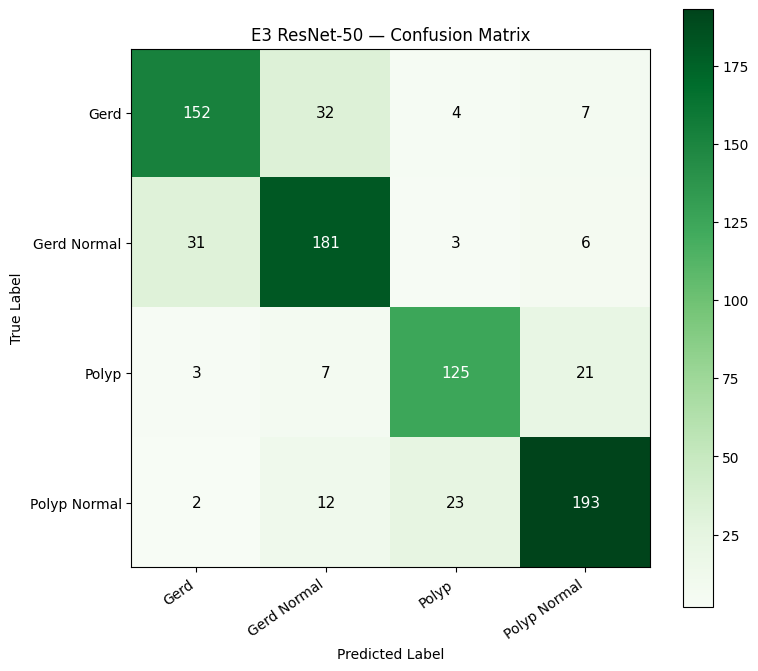

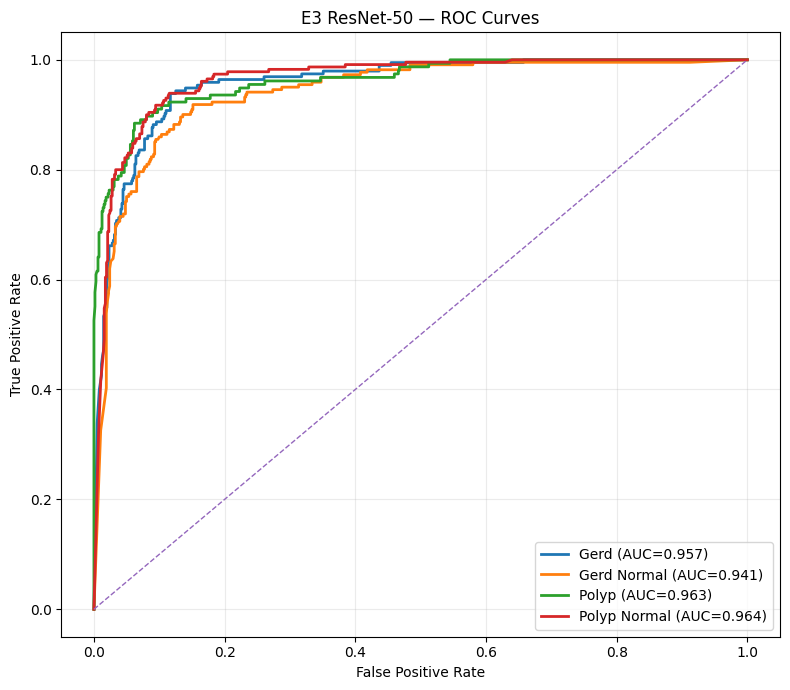

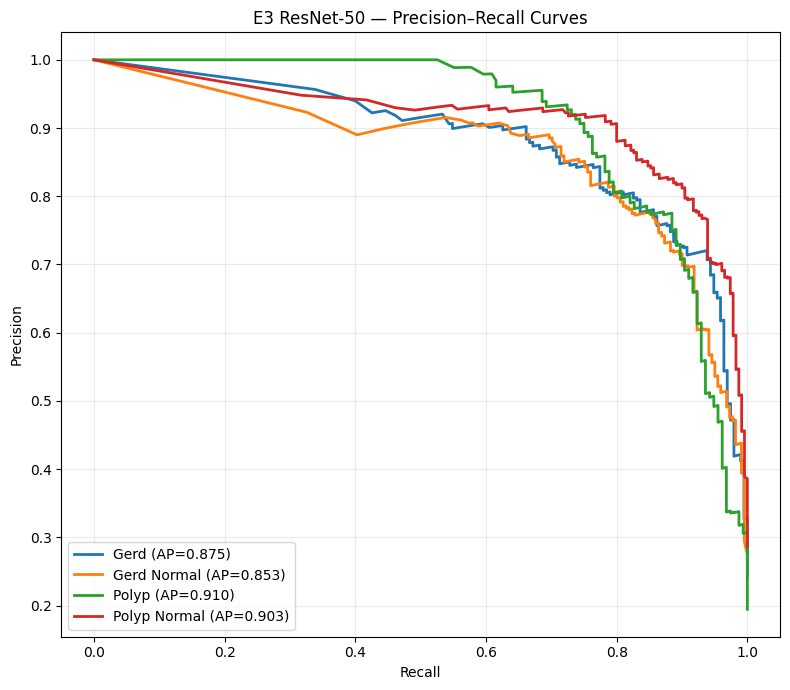

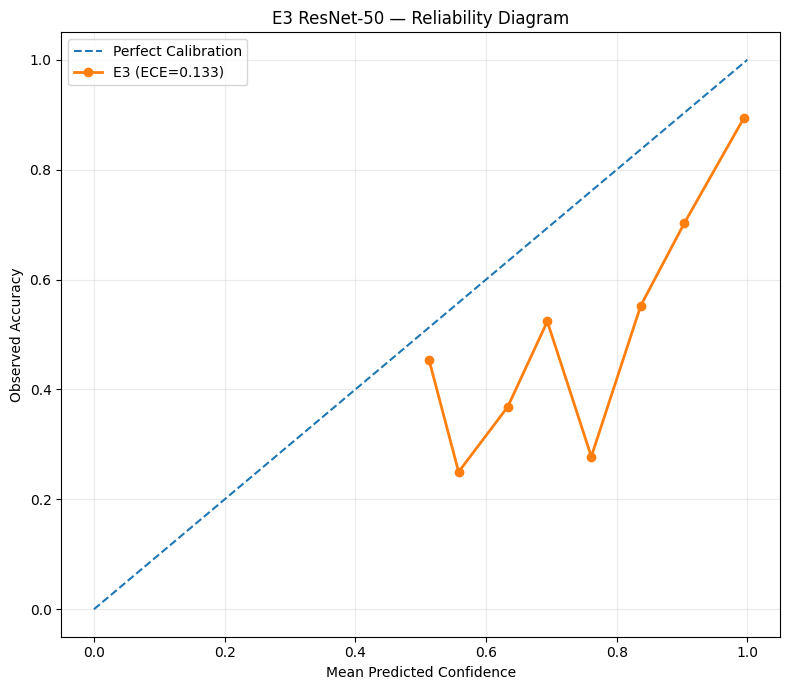


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Gerd     0.8085    0.7795    0.7937       195
 Gerd Normal     0.7802    0.8190    0.7991       221
       Polyp     0.8065    0.8013    0.8039       156
Polyp Normal     0.8502    0.8391    0.8446       230

    accuracy                         0.8117       802
   macro avg     0.8113    0.8097    0.8103       802
weighted avg     0.8123    0.8117    0.8118       802


BUILDING E0 / E1 / E2 / E3 MASTER COMPARISON
✓ E0 Real Only
✓ E1 Conventional Aug
✓ E2 MixUp/CutMix
✓ E3 Unfiltered Diffusion

E0 / E1 / E2 / E3 — LOCKED TEST COMPARISON
           Metric  E0 Real Only  E1 Conventional Aug  E2 MixUp/CutMix  E3 Unfiltered Diffusion  E3 - E0
         Accuracy        0.8092               0.8217           0.8279                   0.8117   0.0025
Balanced Accuracy        0.8006               0.8233           0.8257                   0.8097   0.0091
  Macro Precision        0.8182               0.8238       

In [ ]:
# ============================================================
# STEP 11 — E3 LOCKED TEST EVALUATION
# + E0 / E1 / E2 / E3 MASTER COMPARISON
#
# E3 = REAL + UNFILTERED DIFFUSION
# ============================================================

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 0. E3 PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

E3_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E3_Diffusion_Unfiltered"
)

RESULT_DIR = (
    E3_DIR /
    "results"
)

CHECKPOINT_DIR = (
    E3_DIR /
    "checkpoints"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e3.pth"
)

print("=" * 85)
print("E3 — LOCKED TEST EVALUATION")
print("REAL + UNFILTERED DIFFUSION")
print("=" * 85)

print(
    "\nCheckpoint:",
    BEST_MODEL_PATH
)

if not BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        f"E3 best checkpoint not found:\n"
        f"{BEST_MODEL_PATH}"
    )


# ============================================================
# 1. DEVICE VARIABLE COMPATIBILITY
# ============================================================

# Previous experiments may have used "device"
# while newer cells may use "DEVICE".

if "device" not in globals():

    if "DEVICE" in globals():
        device = DEVICE

    else:
        device = torch.device(
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

print(
    "Device:",
    device
)


# ============================================================
# 2. AMP VARIABLE COMPATIBILITY
# ============================================================

# Use previous experiment setting if already defined.

if "AMP_ENABLED" not in globals():

    AMP_ENABLED = (
        torch.cuda.is_available()
    )

print(
    "AMP enabled:",
    AMP_ENABLED
)


# ============================================================
# 3. TEST LOADER COMPATIBILITY
# ============================================================

# If training cell created e3_test_loader, use it.
# Otherwise accept test_loader.

if "e3_test_loader" in globals():

    test_loader_for_e3 = (
        e3_test_loader
    )

elif "test_loader" in globals():

    test_loader_for_e3 = (
        test_loader
    )

else:

    raise RuntimeError(
        "No E3 test DataLoader found. "
        "Expected e3_test_loader or test_loader."
    )


# ============================================================
# 4. CHECK REQUIRED GLOBAL OBJECTS
# ============================================================

required_globals = [
    "model",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "test_df"
]

missing_globals = [
    x
    for x in required_globals
    if x not in globals()
]

if missing_globals:

    raise RuntimeError(
        "Missing required objects: "
        + ", ".join(missing_globals)
    )


# ============================================================
# 5. CALIBRATION FUNCTIONS
# ============================================================

# Re-create them if runtime restart removed them.

def multiclass_brier_score(
    y_true,
    y_prob,
    n_classes
):

    y_onehot = np.eye(
        n_classes
    )[y_true]

    return np.mean(
        np.sum(
            (
                y_prob
                -
                y_onehot
            ) ** 2,
            axis=1
        )
    )


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
):

    confidences = np.max(
        y_prob,
        axis=1
    )

    predictions = np.argmax(
        y_prob,
        axis=1
    )

    correctness = (
        predictions
        ==
        y_true
    ).astype(float)

    bin_edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece_value = 0.0

    for i in range(
        n_bins
    ):

        lower = bin_edges[i]
        upper = bin_edges[i + 1]

        if i == 0:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences > lower)
                &
                (confidences <= upper)
            )

        if mask.sum() == 0:
            continue

        bin_accuracy = (
            correctness[
                mask
            ].mean()
        )

        bin_confidence = (
            confidences[
                mask
            ].mean()
        )

        bin_weight = (
            mask.sum()
            /
            len(y_true)
        )

        ece_value += (
            bin_weight
            *
            abs(
                bin_accuracy
                -
                bin_confidence
            )
        )

    return float(
        ece_value
    )


# ============================================================
# 6. LOAD BEST E3 MODEL
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

print("\nCheckpoint keys:")

if isinstance(
    checkpoint,
    dict
):

    print(
        list(
            checkpoint.keys()
        )
    )


if (
    isinstance(
        checkpoint,
        dict
    )
    and
    "model_state_dict"
    in checkpoint
):

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

else:

    # fallback if checkpoint is raw state_dict
    model.load_state_dict(
        checkpoint
    )


model = model.to(
    device
)

model.eval()


best_epoch = (
    checkpoint.get(
        "epoch",
        None
    )
    if isinstance(
        checkpoint,
        dict
    )
    else None
)

best_val_macro_f1 = (
    checkpoint.get(
        "best_val_macro_f1",
        None
    )
    if isinstance(
        checkpoint,
        dict
    )
    else None
)

print(
    "\nBest epoch:",
    best_epoch
)

if best_val_macro_f1 is not None:

    print(
        "Best validation Macro-F1:",
        f"{best_val_macro_f1:.4f}"
    )


# ============================================================
# 7. RUN LOCKED REAL TEST SET
# ============================================================

all_targets = []
all_predictions = []
all_probabilities = []

total_inference_time = 0.0


print("\n" + "=" * 85)
print("RUNNING LOCKED REAL TEST SET")
print("=" * 85)


with torch.no_grad():

    for images, labels in test_loader_for_e3:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        # ----------------------------------------------------
        # SAME AMP-BASED INFERENCE STRUCTURE
        # AS EARLIER EXPERIMENTS
        # ----------------------------------------------------

        with torch.amp.autocast(
            device_type=(
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            ),
            enabled=(
                AMP_ENABLED
                and
                torch.cuda.is_available()
            )
        ):

            logits = model(
                images
            )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        total_inference_time += (
            time.perf_counter()
            -
            start
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_targets.extend(
            labels
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
            .cpu()
            .numpy()
        )

        all_probabilities.extend(
            probabilities
            .cpu()
            .numpy()
        )


y_true = np.asarray(
    all_targets
)

y_pred = np.asarray(
    all_predictions
)

y_prob = np.asarray(
    all_probabilities
)


print(
    "\nLocked test images:",
    len(y_true)
)


# ============================================================
# 8. STRICT LOCKED TEST CHECK
# ============================================================

EXPECTED_TEST_IMAGES = 802

if len(y_true) != EXPECTED_TEST_IMAGES:

    raise RuntimeError(
        f"Locked test mismatch. "
        f"Expected {EXPECTED_TEST_IMAGES}, "
        f"but received {len(y_true)}."
    )

print(
    "✓ Locked test count confirmed:",
    EXPECTED_TEST_IMAGES
)


# ============================================================
# 9. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)


# ============================================================
# 10. AUROC / AUPRC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(
        NUM_CLASSES
    )
)

macro_auroc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = (
    average_precision_score(
        y_true_bin,
        y_prob,
        average="macro"
    )
)


# ============================================================
# 11. CALIBRATION
# ============================================================

brier = multiclass_brier_score(
    y_true,
    y_prob,
    NUM_CLASSES
)

ece = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
)

nll = log_loss(
    y_true,
    y_prob,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 13. PER-CLASS METRICS
# ============================================================

per_class_results = []

for i, class_name in enumerate(
    CLASS_NAMES
):

    TP = cm[i, i]

    FN = (
        cm[i, :].sum()
        -
        TP
    )

    FP = (
        cm[:, i].sum()
        -
        TP
    )

    TN = (
        cm.sum()
        -
        TP
        -
        FN
        -
        FP
    )

    sensitivity = (
        TP / (TP + FN)
        if TP + FN
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP
        else 0
    )

    ppv = (
        TP / (TP + FP)
        if TP + FP
        else 0
    )

    npv = (
        TN / (TN + FN)
        if TN + FN
        else 0
    )

    class_f1 = f1_score(
        (
            y_true == i
        ).astype(int),

        (
            y_pred == i
        ).astype(int),

        zero_division=0
    )

    class_auc = roc_auc_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_auprc = (
        average_precision_score(
            y_true_bin[:, i],
            y_prob[:, i]
        )
    )

    per_class_results.append({

        "Class":
            class_name,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "PPV":
            ppv,

        "NPV":
            npv,

        "F1":
            class_f1,

        "AUROC":
            class_auc,

        "AUPRC":
            class_auprc
    })


per_class_df = pd.DataFrame(
    per_class_results
)


# ============================================================
# 14. INFERENCE SPEED
# ============================================================

latency_ms = (
    total_inference_time
    /
    len(y_true)
    *
    1000
)

throughput = (
    len(y_true)
    /
    total_inference_time
)


# ============================================================
# 15. PRINT FINAL E3 PERFORMANCE
# ============================================================

print("\n" + "=" * 85)
print("E3 — RESNET-50 LOCKED TEST PERFORMANCE")
print("=" * 85)

print(
    f"Accuracy             : "
    f"{accuracy:.4f}"
)

print(
    f"Balanced Accuracy    : "
    f"{balanced_acc:.4f}"
)

print(
    f"Macro Precision      : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall         : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1             : "
    f"{macro_f1:.4f}"
)

print(
    f"Weighted F1          : "
    f"{weighted_f1:.4f}"
)

print(
    f"MCC                  : "
    f"{mcc:.4f}"
)

print(
    f"Cohen's Kappa        : "
    f"{kappa:.4f}"
)

print(
    f"Macro AUROC          : "
    f"{macro_auroc:.4f}"
)

print(
    f"Macro AUPRC          : "
    f"{macro_auprc:.4f}"
)

print(
    f"Brier Score          : "
    f"{brier:.4f}"
)

print(
    f"ECE                  : "
    f"{ece:.4f}"
)

print(
    f"NLL                  : "
    f"{nll:.4f}"
)

print(
    f"Inference latency    : "
    f"{latency_ms:.3f} ms/image"
)

print(
    f"Throughput           : "
    f"{throughput:.2f} images/sec"
)


print("\n" + "=" * 85)
print("PER-CLASS PERFORMANCE")
print("=" * 85)

print(
    per_class_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 16. SAVE E3 FINAL METRICS
# ============================================================

e3_metrics = {

    "experiment":
        "E3_ResNet50_DiffusionUnfiltered",

    "training_strategy":
        (
            "Real + unfiltered "
            "diffusion synthetic"
        ),

    "real_train_images":
        2803,

    "synthetic_train_images":
        2803,

    "total_train_images":
        5606,

    "test_images":
        int(
            len(y_true)
        ),

    "accuracy":
        float(
            accuracy
        ),

    "balanced_accuracy":
        float(
            balanced_acc
        ),

    "macro_precision":
        float(
            macro_precision
        ),

    "macro_recall":
        float(
            macro_recall
        ),

    "macro_f1":
        float(
            macro_f1
        ),

    "weighted_f1":
        float(
            weighted_f1
        ),

    "mcc":
        float(
            mcc
        ),

    "cohen_kappa":
        float(
            kappa
        ),

    "macro_auroc":
        float(
            macro_auroc
        ),

    "macro_auprc":
        float(
            macro_auprc
        ),

    "brier_score":
        float(
            brier
        ),

    "ece":
        float(
            ece
        ),

    "nll":
        float(
            nll
        ),

    "latency_ms_per_image":
        float(
            latency_ms
        ),

    "throughput_images_per_second":
        float(
            throughput
        ),

    "best_epoch":
        (
            int(
                best_epoch
            )
            if best_epoch is not None
            else None
        ),

    "best_validation_macro_f1":
        (
            float(
                best_val_macro_f1
            )
            if best_val_macro_f1
            is not None
            else None
        ),

    "synthetic_filtering":
        False
}


E3_METRIC_PATH = (
    RESULT_DIR /
    "E3_final_test_metrics.json"
)


with open(
    E3_METRIC_PATH,
    "w"
) as f:

    json.dump(
        e3_metrics,
        f,
        indent=4
    )


per_class_df.to_csv(
    RESULT_DIR /
    "E3_per_class_metrics.csv",
    index=False
)


# ============================================================
# 17. SAVE ALL TEST PREDICTIONS
# ============================================================

prediction_df = (
    test_df.copy()
    .reset_index(
        drop=True
    )
)

if len(
    prediction_df
) != len(
    y_true
):

    raise RuntimeError(
        "test_df order/count does not match "
        "the test DataLoader output."
    )


prediction_df[
    "true_id"
] = y_true

prediction_df[
    "predicted_id"
] = y_pred


prediction_df[
    "true_class"
] = [

    CLASS_NAMES[i]
    for i in y_true
]


prediction_df[
    "predicted_class"
] = [

    CLASS_NAMES[i]
    for i in y_pred
]


prediction_df[
    "correct"
] = (
    y_true
    ==
    y_pred
)


prediction_df[
    "confidence"
] = np.max(
    y_prob,
    axis=1
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    clean_name = (
        class_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )

    prediction_df[
        f"prob_{clean_name}"
    ] = (
        y_prob[:, i]
    )


prediction_df.to_csv(
    RESULT_DIR /
    "E3_test_predictions.csv",
    index=False
)


# ============================================================
# 18. CONFUSION MATRIX — GREENS
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    cmap="Greens",
    interpolation="nearest"
)

plt.title(
    "E3 ResNet-50 — Confusion Matrix"
)

plt.colorbar()


ticks = np.arange(
    len(
        CLASS_NAMES
    )
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    ticks,
    CLASS_NAMES
)


threshold = (
    cm.max()
    /
    2
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            str(
                cm[i, j]
            ),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j]
                >
                threshold
                else
                "black"
            ),
            fontsize=11
        )


plt.ylabel(
    "True Label"
)

plt.xlabel(
    "Predicted Label"
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E3_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={roc_auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "E3 ResNet-50 — ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E3_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    (
        precision_curve,
        recall_curve,
        _
    ) = precision_recall_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP={ap:.3f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "E3 ResNet-50 — Precision–Recall Curves"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E3_PR_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. RELIABILITY DIAGRAM
# ============================================================

confidences = np.max(
    y_prob,
    axis=1
)

correctness = (
    y_pred
    ==
    y_true
).astype(float)


bin_edges = np.linspace(
    0,
    1,
    16
)

bin_acc = []
bin_conf = []


for i in range(
    15
):

    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    mask = (
        (confidences > lower)
        &
        (confidences <= upper)
    )

    if mask.sum() > 0:

        bin_acc.append(
            correctness[
                mask
            ].mean()
        )

        bin_conf.append(
            confidences[
                mask
            ].mean()
        )


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_conf,
    bin_acc,
    marker="o",
    linewidth=2,
    label=(
        f"E3 "
        f"(ECE={ece:.3f})"
    )
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "E3 ResNet-50 — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E3_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 85)
print("CLASSIFICATION REPORT")
print("=" * 85)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=
            CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 23. E0 / E1 / E2 / E3 MASTER COMPARISON
# ============================================================

print("\n" + "=" * 95)
print("BUILDING E0 / E1 / E2 / E3 MASTER COMPARISON")
print("=" * 95)


experiment_metric_paths = {

    "E0 Real Only":

        PROJECT_DIR /
        "experiments" /
        "E0_ResNet50_RealOnly" /
        "results" /
        "E0_final_test_metrics.json",

    "E1 Conventional Aug":

        PROJECT_DIR /
        "experiments" /
        "E1_ResNet50_ConventionalAug" /
        "results" /
        "E1_final_test_metrics.json",

    "E2 MixUp/CutMix":

        PROJECT_DIR /
        "experiments" /
        "E2_ResNet50_MixUpCutMix" /
        "results" /
        "E2_final_test_metrics.json",

    "E3 Unfiltered Diffusion":

        E3_METRIC_PATH
}


metrics_to_compare = {

    "Accuracy":
        "accuracy",

    "Balanced Accuracy":
        "balanced_accuracy",

    "Macro Precision":
        "macro_precision",

    "Macro Recall":
        "macro_recall",

    "Macro F1":
        "macro_f1",

    "Weighted F1":
        "weighted_f1",

    "MCC":
        "mcc",

    "Cohen's Kappa":
        "cohen_kappa",

    "Macro AUROC":
        "macro_auroc",

    "Macro AUPRC":
        "macro_auprc",

    "Brier Score":
        "brier_score",

    "ECE":
        "ece",

    "NLL":
        "nll"
}


loaded_experiments = {}


for experiment_name, path in (
    experiment_metric_paths.items()
):

    if path.exists():

        with open(
            path,
            "r"
        ) as f:

            loaded_experiments[
                experiment_name
            ] = json.load(
                f
            )

        print(
            f"✓ {experiment_name}"
        )

    else:

        print(
            f"✗ Missing: "
            f"{experiment_name}"
        )


# ============================================================
# 24. CREATE COMPARISON TABLE
# ============================================================

comparison_rows = []


for display_metric, json_key in (
    metrics_to_compare.items()
):

    row = {

        "Metric":
            display_metric
    }

    for experiment_name in (
        experiment_metric_paths.keys()
    ):

        data = loaded_experiments.get(
            experiment_name
        )

        if (
            data is not None
            and
            json_key in data
        ):

            row[
                experiment_name
            ] = data[
                json_key
            ]

        else:

            row[
                experiment_name
            ] = np.nan

    comparison_rows.append(
        row
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 25. ADD E3 - E0 DIFFERENCE
# ============================================================

if (
    "E0 Real Only"
    in comparison_df.columns
    and
    "E3 Unfiltered Diffusion"
    in comparison_df.columns
):

    comparison_df[
        "E3 - E0"
    ] = (
        comparison_df[
            "E3 Unfiltered Diffusion"
        ]
        -
        comparison_df[
            "E0 Real Only"
        ]
    )


# ============================================================
# 26. SAVE MASTER COMPARISON
# ============================================================

MASTER_COMPARISON_PATH = (
    RESULT_DIR /
    "E0_E1_E2_E3_master_comparison.csv"
)

comparison_df.to_csv(
    MASTER_COMPARISON_PATH,
    index=False
)


print("\n" + "=" * 95)
print("E0 / E1 / E2 / E3 — LOCKED TEST COMPARISON")
print("=" * 95)

print(
    comparison_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 27. E3 vs E0 SUMMARY
# ============================================================

if (
    "E0 Real Only"
    in loaded_experiments
):

    e0 = loaded_experiments[
        "E0 Real Only"
    ]

    print("\n" + "=" * 95)
    print("E3 IMPROVEMENT OVER E0")
    print("=" * 95)

    higher_is_better = [
        (
            "Accuracy",
            "accuracy"
        ),

        (
            "Balanced Accuracy",
            "balanced_accuracy"
        ),

        (
            "Macro F1",
            "macro_f1"
        ),

        (
            "MCC",
            "mcc"
        ),

        (
            "Macro AUROC",
            "macro_auroc"
        ),

        (
            "Macro AUPRC",
            "macro_auprc"
        )
    ]

    for name, key in higher_is_better:

        if key in e0:

            difference = (
                e3_metrics[key]
                -
                e0[key]
            )

            print(
                f"{name:<20}: "
                f"{e0[key]:.4f} "
                f"→ "
                f"{e3_metrics[key]:.4f} "
                f"({difference:+.4f})"
            )


    lower_is_better = [

        (
            "Brier Score",
            "brier_score"
        ),

        (
            "ECE",
            "ece"
        ),

        (
            "NLL",
            "nll"
        )
    ]


    print(
        "\nCalibration / error "
        "(lower is better):"
    )


    for name, key in lower_is_better:

        if key in e0:

            difference = (
                e3_metrics[key]
                -
                e0[key]
            )

            print(
                f"{name:<20}: "
                f"{e0[key]:.4f} "
                f"→ "
                f"{e3_metrics[key]:.4f} "
                f"({difference:+.4f})"
            )


# ============================================================
# 28. FINAL STATUS
# ============================================================

print("\n" + "=" * 95)
print("E3 FINAL EVALUATION COMPLETE")
print("=" * 95)

print("✓ Best E3 checkpoint loaded")
print("✓ Locked 802-image REAL test evaluated")
print("✓ Overall metrics saved")
print("✓ Per-class metrics saved")
print("✓ Individual test predictions saved")
print("✓ Green confusion matrix saved")
print("✓ ROC curves saved")
print("✓ Precision–Recall curves saved")
print("✓ Reliability diagram saved")
print("✓ E0 / E1 / E2 / E3 comparison saved")

print("\nFiles:")

print(
    "Metrics     :",
    RESULT_DIR /
    "E3_final_test_metrics.json"
)

print(
    "Per-class   :",
    RESULT_DIR /
    "E3_per_class_metrics.csv"
)

print(
    "Predictions :",
    RESULT_DIR /
    "E3_test_predictions.csv"
)

print(
    "Comparison  :",
    MASTER_COMPARISON_PATH
)

print("=" * 95)

# E4: Real + fidelity-filtered diffusion images.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 122.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cucim-cu12 26.2.0 requires scikit-image<0.26.0,>=0.19.0, but you have scikit-image 0.26.0 which is incompatible.
E4 — FIDELITY SCORING
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB

E3 synthetic pairs: 2803
Missing real      : 0
Missing synthetic : 0

LOADING LPIPS
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 198MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
✓ LPIPS-Alex loaded

LOADING DINOV2
Model: facebook/dinov2-small


...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

✓ DINOv2 loaded

Fresh E4 scoring run.

Pairs remaining: 2803

STARTING E4 FIDELITY SCORING


E4 fidelity:   0%|          | 0/176 [00:00<?, ?it/s]


E4 SCORE COMPLETENESS
Expected: 2803
Scored  : 2803
✓ All E3 real/synthetic pairs scored.

GLOBAL FIDELITY DISTRIBUTION
            ssim      lpips  dino_cosine       psnr
count  2803.0000  2803.0000    2803.0000  2803.0000
mean      0.5498     0.2926       0.6923    18.9032
std       0.1002     0.0466       0.1069     1.5252
min       0.2179     0.1731       0.2278    12.5303
5%        0.3801     0.2280       0.5047    16.3151
10%       0.4137     0.2390       0.5516    16.8128
25%       0.4829     0.2605       0.6211    17.8911
50%       0.5528     0.2861       0.7012    19.0254
75%       0.6211     0.3188       0.7717    19.9289
90%       0.6797     0.3538       0.8215    20.7549
95%       0.7109     0.3766       0.8481    21.2336
max       0.7982     0.5491       0.9280    29.9813

CLASS-WISE MEAN FIDELITY
                ssim   lpips  dino_cosine     psnr
class_name                                        
Gerd          0.5673  0.3028       0.6912  18.9243
Gerd Normal   0.6014  0.

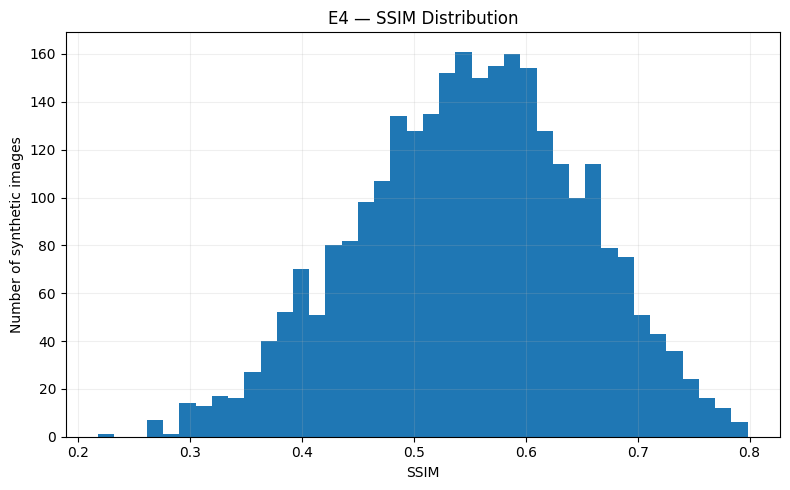

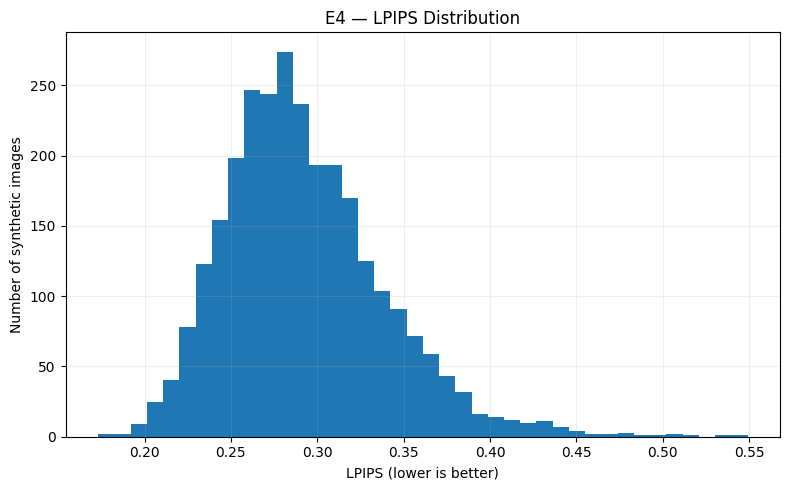

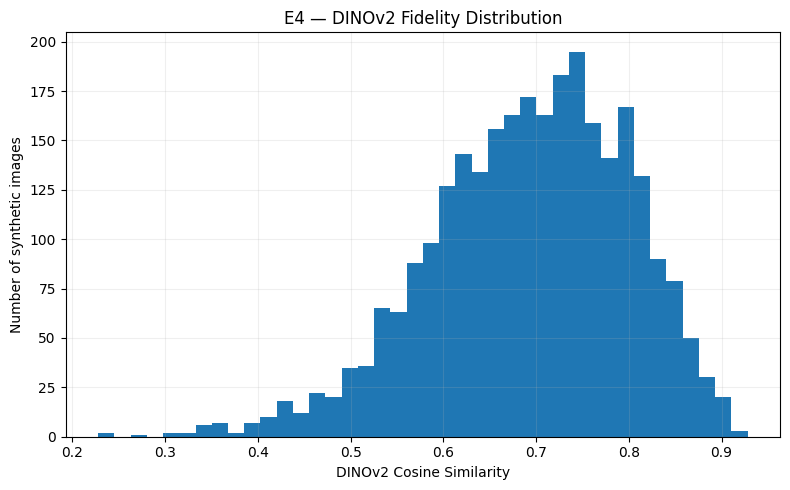


SPEARMAN CORRELATION BETWEEN FIDELITY METRICS
               ssim   lpips  dino_cosine    psnr
ssim         1.0000 -0.1910       0.1586  0.1795
lpips       -0.1910  1.0000      -0.4803  0.1973
dino_cosine  0.1586 -0.4803       1.0000 -0.2849
psnr         0.1795  0.1973      -0.2849  1.0000

E4 FIDELITY SCORING COMPLETE
Pairs scored : 2803
Mean SSIM    : 0.5498
Mean LPIPS   : 0.2926
Mean DINO    : 0.6923
Mean PSNR    : 18.90 dB

Score CSV: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E4_Diffusion_FidelityFiltered/fidelity_scores/E4_all_fidelity_scores.csv
Class summary: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E4_Diffusion_FidelityFiltered/fidelity_scores/E4_classwise_fidelity_summary.csv

IMPORTANT:
✓ Same 2,803 E3 synthetic images reused.
✓ No synthetic image removed yet.
✓ No threshold chosen yet.
✓ No classifier confidence used.
✓ E4 is still in fidelity-analysis stage.


In [ ]:
# ============================================================
# E4 — STEP 1
# FIDELITY SCORING OF ALL E3 REAL ↔ SYNTHETIC PAIRS
#
# Metrics:
#   1. SSIM        → higher = better
#   2. LPIPS       → lower  = better
#   3. DINOv2 Cos  → higher = better
#
# IMPORTANT:
# - Reuses exact E3 synthetic pool
# - No new diffusion generation
# - No filtering yet
# - No classifier confidence used
# ============================================================

!pip -q install -U lpips scikit-image transformers accelerate safetensors

import gc
import json
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFile

import torch
import torch.nn.functional as F
from torchvision import transforms

import lpips

from skimage.metrics import (
    structural_similarity,
    peak_signal_noise_ratio
)

from transformers import (
    AutoImageProcessor,
    AutoModel
)

from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 0. CLEAR PREVIOUS LARGE MODELS
# ============================================================

for var_name in [
    "pipe",
    "model"
]:
    if var_name in globals():

        try:
            del globals()[var_name]
        except:
            pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

E3_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E3_Diffusion_Unfiltered"
)

E4_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E4_Diffusion_FidelityFiltered"
)

E4_SCORE_DIR = (
    E4_DIR /
    "fidelity_scores"
)

E4_FIGURE_DIR = (
    E4_DIR /
    "figures"
)

E4_MANIFEST_DIR = (
    E4_DIR /
    "manifests"
)

for d in [
    E4_DIR,
    E4_SCORE_DIR,
    E4_FIGURE_DIR,
    E4_MANIFEST_DIR
]:

    d.mkdir(
        parents=True,
        exist_ok=True
    )


E3_MANIFEST = (
    E3_DIR /
    "manifests" /
    "E3_generation_manifest.csv"
)

E4_SCORE_CSV = (
    E4_SCORE_DIR /
    "E4_all_fidelity_scores.csv"
)

E4_CONFIG_JSON = (
    E4_SCORE_DIR /
    "E4_fidelity_scoring_config.json"
)


# ============================================================
# 2. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 95)
print("E4 — FIDELITY SCORING")
print("=" * 95)

print("Device :", DEVICE)

if torch.cuda.is_available():

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. LOAD E3 GENERATION MANIFEST
# ============================================================

if not E3_MANIFEST.exists():

    raise FileNotFoundError(
        f"E3 manifest not found:\n{E3_MANIFEST}"
    )


manifest_df = pd.read_csv(
    E3_MANIFEST
)

print(
    "\nE3 synthetic pairs:",
    len(manifest_df)
)

required_cols = [
    "row_id",
    "source_filename",
    "source_path",
    "class_name",
    "synthetic_filename",
    "synthetic_path"
]

missing_cols = [
    c
    for c in required_cols
    if c not in manifest_df.columns
]

if missing_cols:

    raise RuntimeError(
        f"Missing manifest columns: {missing_cols}"
    )


# ============================================================
# 4. VERIFY PAIR FILES
# ============================================================

manifest_df[
    "real_exists"
] = manifest_df[
    "source_path"
].apply(
    lambda x:
        Path(str(x)).exists()
)

manifest_df[
    "synthetic_exists"
] = manifest_df[
    "synthetic_path"
].apply(
    lambda x:
        Path(str(x)).exists()
)

print(
    "Missing real      :",
    int(
        (~manifest_df["real_exists"]).sum()
    )
)

print(
    "Missing synthetic :",
    int(
        (~manifest_df["synthetic_exists"]).sum()
    )
)

if (
    (~manifest_df["real_exists"]).any()
    or
    (~manifest_df["synthetic_exists"]).any()
):

    raise RuntimeError(
        "Some E3 real/synthetic pairs are missing."
    )


# ============================================================
# 5. LOAD LPIPS
# ============================================================

print("\n" + "=" * 95)
print("LOADING LPIPS")
print("=" * 95)

lpips_model = lpips.LPIPS(
    net="alex"
)

lpips_model = lpips_model.to(
    DEVICE
)

lpips_model.eval()

for p in lpips_model.parameters():
    p.requires_grad = False

print("✓ LPIPS-Alex loaded")


# ============================================================
# 6. LOAD DINOV2
# ============================================================

DINO_MODEL_ID = (
    "facebook/dinov2-small"
)

print("\n" + "=" * 95)
print("LOADING DINOV2")
print("=" * 95)

print(
    "Model:",
    DINO_MODEL_ID
)

dino_processor = (
    AutoImageProcessor.from_pretrained(
        DINO_MODEL_ID
    )
)

dino_model = AutoModel.from_pretrained(
    DINO_MODEL_ID
)

dino_model = dino_model.to(
    DEVICE
)

dino_model.eval()

for p in dino_model.parameters():
    p.requires_grad = False

print("✓ DINOv2 loaded")


# ============================================================
# 7. LPIPS PREPROCESSING
# ============================================================

LPIPS_SIZE = 256

lpips_transform = transforms.Compose([

    transforms.Resize(
        (
            LPIPS_SIZE,
            LPIPS_SIZE
        )
    ),

    transforms.ToTensor(),

    # LPIPS expects approximately [-1, 1]
    transforms.Normalize(
        mean=[
            0.5,
            0.5,
            0.5
        ],
        std=[
            0.5,
            0.5,
            0.5
        ]
    )
])


# ============================================================
# 8. PAIRWISE SSIM / PSNR
# ============================================================

def compute_ssim_psnr(
    real_image,
    synth_image
):

    # Same dimensions for pixel metrics
    real = real_image.resize(
        (512, 512),
        Image.Resampling.LANCZOS
    )

    synth = synth_image.resize(
        (512, 512),
        Image.Resampling.LANCZOS
    )

    real_np = np.asarray(
        real,
        dtype=np.uint8
    )

    synth_np = np.asarray(
        synth,
        dtype=np.uint8
    )

    ssim_value = (
        structural_similarity(
            real_np,
            synth_np,
            channel_axis=2,
            data_range=255
        )
    )

    psnr_value = (
        peak_signal_noise_ratio(
            real_np,
            synth_np,
            data_range=255
        )
    )

    return (
        float(ssim_value),
        float(psnr_value)
    )


# ============================================================
# 9. LPIPS BATCH FUNCTION
# ============================================================

@torch.no_grad()
def compute_lpips_batch(
    real_images,
    synth_images
):

    real_batch = torch.stack(
        [
            lpips_transform(img)
            for img in real_images
        ]
    ).to(
        DEVICE
    )

    synth_batch = torch.stack(
        [
            lpips_transform(img)
            for img in synth_images
        ]
    ).to(
        DEVICE
    )

    distances = lpips_model(
        real_batch,
        synth_batch
    )

    distances = (
        distances
        .reshape(-1)
        .detach()
        .cpu()
        .numpy()
    )

    return distances


# ============================================================
# 10. DINO FEATURE EXTRACTION
# ============================================================

@torch.no_grad()
def extract_dino_features(
    images
):

    inputs = dino_processor(
        images=images,
        return_tensors="pt"
    )

    inputs = {
        key:
            value.to(DEVICE)
        for key, value
        in inputs.items()
    }

    outputs = dino_model(
        **inputs
    )

    # CLS token embedding
    features = (
        outputs
        .last_hidden_state[
            :,
            0,
            :
        ]
    )

    features = F.normalize(
        features,
        p=2,
        dim=1
    )

    return (
        features
        .detach()
        .cpu()
    )


# ============================================================
# 11. RESUME SUPPORT
# ============================================================

if E4_SCORE_CSV.exists():

    previous_df = pd.read_csv(
        E4_SCORE_CSV
    )

    completed_ids = set(
        previous_df[
            "row_id"
        ].astype(int)
    )

    print(
        "\nResume detected."
    )

    print(
        "Previously scored:",
        len(completed_ids)
    )

else:

    previous_df = pd.DataFrame()

    completed_ids = set()

    print(
        "\nFresh E4 scoring run."
    )


# ============================================================
# 12. SCORING CONFIG
# ============================================================

BATCH_SIZE = 16

config = {

    "experiment":
        "E4_Diffusion_FidelityFiltered",

    "source_pool":
        str(E3_MANIFEST),

    "synthetic_pool_size":
        int(len(manifest_df)),

    "fidelity_metrics": {

        "ssim":
            "higher_is_better",

        "lpips_alex":
            "lower_is_better",

        "dinov2_cosine_similarity":
            "higher_is_better",

        "psnr":
            "auxiliary_higher_is_better"
    },

    "dino_model":
        DINO_MODEL_ID,

    "lpips_network":
        "alex",

    "filtering_applied":
        False,

    "note":
        (
            "This stage computes fidelity scores only. "
            "No synthetic image is accepted or rejected yet."
        )
}

with open(
    E4_CONFIG_JSON,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )


# ============================================================
# 13. SELECT UNSCORED ROWS
# ============================================================

pending_df = manifest_df[
    ~manifest_df[
        "row_id"
    ].astype(int).isin(
        completed_ids
    )
].copy()

pending_df = pending_df.reset_index(
    drop=True
)

print(
    "\nPairs remaining:",
    len(pending_df)
)


# ============================================================
# 14. SCORE ALL PAIRS
# ============================================================

buffer = []

start_time = time.time()

print("\n" + "=" * 95)
print("STARTING E4 FIDELITY SCORING")
print("=" * 95)


for start_idx in tqdm(
    range(
        0,
        len(pending_df),
        BATCH_SIZE
    ),
    desc="E4 fidelity"
):

    batch_df = pending_df.iloc[
        start_idx:
        start_idx + BATCH_SIZE
    ]

    real_images = []
    synth_images = []

    ssim_values = []
    psnr_values = []

    # --------------------------------------------------------
    # LOAD PAIRS + SSIM/PSNR
    # --------------------------------------------------------

    for _, row in batch_df.iterrows():

        real_img = Image.open(
            row["source_path"]
        ).convert(
            "RGB"
        )

        synth_img = Image.open(
            row["synthetic_path"]
        ).convert(
            "RGB"
        )

        real_images.append(
            real_img
        )

        synth_images.append(
            synth_img
        )

        ssim_value, psnr_value = (
            compute_ssim_psnr(
                real_img,
                synth_img
            )
        )

        ssim_values.append(
            ssim_value
        )

        psnr_values.append(
            psnr_value
        )

    # --------------------------------------------------------
    # LPIPS
    # --------------------------------------------------------

    lpips_values = compute_lpips_batch(
        real_images,
        synth_images
    )

    # --------------------------------------------------------
    # DINO REAL FEATURES
    # --------------------------------------------------------

    real_features = extract_dino_features(
        real_images
    )

    # --------------------------------------------------------
    # DINO SYNTH FEATURES
    # --------------------------------------------------------

    synth_features = extract_dino_features(
        synth_images
    )

    dino_cosine = torch.sum(
        real_features
        *
        synth_features,
        dim=1
    ).numpy()

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    for local_idx, (_, row) in enumerate(
        batch_df.iterrows()
    ):

        buffer.append({

            "row_id":
                int(row["row_id"]),

            "class_name":
                str(row["class_name"]),

            "source_filename":
                row["source_filename"],

            "source_path":
                row["source_path"],

            "synthetic_filename":
                row["synthetic_filename"],

            "synthetic_path":
                row["synthetic_path"],

            "ssim":
                float(
                    ssim_values[
                        local_idx
                    ]
                ),

            "psnr":
                float(
                    psnr_values[
                        local_idx
                    ]
                ),

            "lpips":
                float(
                    lpips_values[
                        local_idx
                    ]
                ),

            "dino_cosine":
                float(
                    dino_cosine[
                        local_idx
                    ]
                )
        })

    # --------------------------------------------------------
    # CRASH-SAFE SAVE EVERY ~100 PAIRS
    # --------------------------------------------------------

    if len(buffer) >= 100:

        new_scores = pd.DataFrame(
            buffer
        )

        if E4_SCORE_CSV.exists():

            new_scores.to_csv(
                E4_SCORE_CSV,
                mode="a",
                header=False,
                index=False
            )

        else:

            new_scores.to_csv(
                E4_SCORE_CSV,
                index=False
            )

        buffer = []


# ============================================================
# 15. FLUSH LAST BUFFER
# ============================================================

if len(buffer) > 0:

    new_scores = pd.DataFrame(
        buffer
    )

    if E4_SCORE_CSV.exists():

        new_scores.to_csv(
            E4_SCORE_CSV,
            mode="a",
            header=False,
            index=False
        )

    else:

        new_scores.to_csv(
            E4_SCORE_CSV,
            index=False
        )


# ============================================================
# 16. LOAD COMPLETE SCORE TABLE
# ============================================================

scores_df = pd.read_csv(
    E4_SCORE_CSV
)

# Protect against accidental duplicate resume rows
scores_df = (
    scores_df
    .drop_duplicates(
        subset=[
            "row_id"
        ],
        keep="last"
    )
    .sort_values(
        "row_id"
    )
    .reset_index(
        drop=True
    )
)

scores_df.to_csv(
    E4_SCORE_CSV,
    index=False
)


# ============================================================
# 17. VERIFY COMPLETENESS
# ============================================================

print("\n" + "=" * 95)
print("E4 SCORE COMPLETENESS")
print("=" * 95)

print(
    "Expected:",
    len(manifest_df)
)

print(
    "Scored  :",
    len(scores_df)
)

if len(scores_df) != len(
    manifest_df
):

    print(
        "⚠ Some pairs remain unscored."
    )

else:

    print(
        "✓ All E3 real/synthetic pairs scored."
    )


# ============================================================
# 18. GLOBAL DESCRIPTIVE STATISTICS
# ============================================================

metric_cols = [
    "ssim",
    "lpips",
    "dino_cosine",
    "psnr"
]

print("\n" + "=" * 95)
print("GLOBAL FIDELITY DISTRIBUTION")
print("=" * 95)

print(
    scores_df[
        metric_cols
    ]
    .describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
    .round(4)
    .to_string()
)


# ============================================================
# 19. CLASS-WISE SUMMARY
# ============================================================

class_summary = (
    scores_df
    .groupby(
        "class_name"
    )[
        metric_cols
    ]
    .agg(
        [
            "count",
            "mean",
            "std",
            "median",
            "min",
            "max"
        ]
    )
)

CLASS_SUMMARY_PATH = (
    E4_SCORE_DIR /
    "E4_classwise_fidelity_summary.csv"
)

class_summary.to_csv(
    CLASS_SUMMARY_PATH
)

print("\n" + "=" * 95)
print("CLASS-WISE MEAN FIDELITY")
print("=" * 95)

class_means = (
    scores_df
    .groupby(
        "class_name"
    )[
        metric_cols
    ]
    .mean()
    .round(4)
)

print(
    class_means.to_string()
)


# ============================================================
# 20. DISTRIBUTION FIGURES
# ============================================================

# SSIM
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    scores_df["ssim"],
    bins=40
)

plt.xlabel(
    "SSIM"
)

plt.ylabel(
    "Number of synthetic images"
)

plt.title(
    "E4 — SSIM Distribution"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    E4_FIGURE_DIR /
    "E4_SSIM_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# LPIPS
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    scores_df["lpips"],
    bins=40
)

plt.xlabel(
    "LPIPS (lower is better)"
)

plt.ylabel(
    "Number of synthetic images"
)

plt.title(
    "E4 — LPIPS Distribution"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    E4_FIGURE_DIR /
    "E4_LPIPS_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# DINO
plt.figure(
    figsize=(8, 5)
)

plt.hist(
    scores_df["dino_cosine"],
    bins=40
)

plt.xlabel(
    "DINOv2 Cosine Similarity"
)

plt.ylabel(
    "Number of synthetic images"
)

plt.title(
    "E4 — DINOv2 Fidelity Distribution"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    E4_FIGURE_DIR /
    "E4_DINO_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. METRIC CORRELATION
# ============================================================

correlation = (
    scores_df[
        metric_cols
    ]
    .corr(
        method="spearman"
    )
)

print("\n" + "=" * 95)
print("SPEARMAN CORRELATION BETWEEN FIDELITY METRICS")
print("=" * 95)

print(
    correlation
    .round(4)
    .to_string()
)

correlation.to_csv(
    E4_SCORE_DIR /
    "E4_metric_correlations.csv"
)


# ============================================================
# 22. SAVE SUMMARY JSON
# ============================================================

elapsed = (
    time.time()
    -
    start_time
)

summary = {

    "experiment":
        "E4_Diffusion_FidelityFiltered",

    "total_pairs":
        int(
            len(scores_df)
        ),

    "mean_ssim":
        float(
            scores_df[
                "ssim"
            ].mean()
        ),

    "median_ssim":
        float(
            scores_df[
                "ssim"
            ].median()
        ),

    "mean_lpips":
        float(
            scores_df[
                "lpips"
            ].mean()
        ),

    "median_lpips":
        float(
            scores_df[
                "lpips"
            ].median()
        ),

    "mean_dino_cosine":
        float(
            scores_df[
                "dino_cosine"
            ].mean()
        ),

    "median_dino_cosine":
        float(
            scores_df[
                "dino_cosine"
            ].median()
        ),

    "mean_psnr":
        float(
            scores_df[
                "psnr"
            ].mean()
        ),

    "runtime_minutes":
        float(
            elapsed / 60
        ),

    "filtering_applied":
        False
}

with open(
    E4_SCORE_DIR /
    "E4_fidelity_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================
# 23. FINAL
# ============================================================

print("\n" + "=" * 95)
print("E4 FIDELITY SCORING COMPLETE")
print("=" * 95)

print(
    "Pairs scored :",
    len(scores_df)
)

print(
    f"Mean SSIM    : "
    f"{scores_df['ssim'].mean():.4f}"
)

print(
    f"Mean LPIPS   : "
    f"{scores_df['lpips'].mean():.4f}"
)

print(
    f"Mean DINO    : "
    f"{scores_df['dino_cosine'].mean():.4f}"
)

print(
    f"Mean PSNR    : "
    f"{scores_df['psnr'].mean():.2f} dB"
)

print(
    "\nScore CSV:",
    E4_SCORE_CSV
)

print(
    "Class summary:",
    CLASS_SUMMARY_PATH
)

print("\nIMPORTANT:")
print("✓ Same 2,803 E3 synthetic images reused.")
print("✓ No synthetic image removed yet.")
print("✓ No threshold chosen yet.")
print("✓ No classifier confidence used.")
print("✓ E4 is still in fidelity-analysis stage.")

print("=" * 95)

In [ ]:
# ============================================================
# E4 — STEP 2
# CLASS-AWARE COMPOSITE FIDELITY FILTER
#
# Metrics used:
#   SSIM         ↑ higher = better
#   LPIPS        ↓ lower  = better
#   DINO cosine  ↑ higher = better
#
# Strategy:
#   1. Convert each metric to within-class percentile rank
#   2. Reverse LPIPS percentile
#   3. Equal-weight composite fidelity score
#   4. Remove bottom 25% within EACH class
#
# IMPORTANT:
#   - Same E3 synthetic pool
#   - No new synthetic generation
#   - No classifier/test information
#   - PSNR retained for reporting only
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import math
from PIL import Image

# ============================================================
# 1. PATHS
# ============================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

E3_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E3_Diffusion_Unfiltered"
)

E4_DIR = (
    PROJECT_ROOT /
    "experiments" /
    "E4_Diffusion_FidelityFiltered"
)

SCORE_DIR = (
    E4_DIR /
    "fidelity_scores"
)

MANIFEST_DIR = (
    E4_DIR /
    "manifests"
)

FIGURE_DIR = (
    E4_DIR /
    "figures"
)

RESULT_DIR = (
    E4_DIR /
    "results"
)

CHECKPOINT_DIR = (
    E4_DIR /
    "checkpoints"
)

for d in [
    MANIFEST_DIR,
    FIGURE_DIR,
    RESULT_DIR,
    CHECKPOINT_DIR
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )

SCORE_CSV = (
    SCORE_DIR /
    "E4_all_fidelity_scores.csv"
)

FILTERED_SYNTH_CSV = (
    MANIFEST_DIR /
    "E4_filtered_synthetic_manifest.csv"
)

REJECTED_SYNTH_CSV = (
    MANIFEST_DIR /
    "E4_rejected_synthetic_manifest.csv"
)

FULL_SCORING_CSV = (
    MANIFEST_DIR /
    "E4_scored_synthetic_manifest.csv"
)

FILTER_CONFIG_JSON = (
    MANIFEST_DIR /
    "E4_filter_config.json"
)

# ============================================================
# 2. LOAD SCORES
# ============================================================

scores_df = pd.read_csv(
    SCORE_CSV
)

print("=" * 95)
print("E4 — CLASS-AWARE FIDELITY FILTER")
print("=" * 95)

print(
    "Total synthetic images:",
    len(scores_df)
)

print(
    "Classes:",
    scores_df["class_name"].nunique()
)

required = [
    "row_id",
    "class_name",
    "source_path",
    "synthetic_path",
    "ssim",
    "lpips",
    "dino_cosine"
]

missing = [
    col
    for col in required
    if col not in scores_df.columns
]

if missing:
    raise RuntimeError(
        f"Missing columns: {missing}"
    )

# ============================================================
# 3. CHECK FOR INVALID METRIC VALUES
# ============================================================

metric_cols = [
    "ssim",
    "lpips",
    "dino_cosine"
]

invalid_rows = (
    scores_df[
        metric_cols
    ]
    .isna()
    .any(axis=1)
)

print(
    "Rows with missing fidelity scores:",
    int(invalid_rows.sum())
)

if invalid_rows.any():
    raise RuntimeError(
        "Some fidelity scores are missing."
    )

# ============================================================
# 4. CLASS-WISE PERCENTILE RANKS
# ============================================================
#
# Why class-wise?
#
# Different GI classes can naturally have different:
# - texture
# - illumination
# - lesion morphology
# - structural complexity
#
# So raw global thresholds could unfairly reject one class.
# ============================================================

scores_df[
    "ssim_percentile"
] = (
    scores_df
    .groupby("class_name")["ssim"]
    .rank(
        method="average",
        pct=True,
        ascending=True
    )
)

# LPIPS lower = better
# rank ascending=False means SMALL LPIPS receives HIGH percentile
scores_df[
    "lpips_fidelity_percentile"
] = (
    scores_df
    .groupby("class_name")["lpips"]
    .rank(
        method="average",
        pct=True,
        ascending=False
    )
)

scores_df[
    "dino_percentile"
] = (
    scores_df
    .groupby("class_name")["dino_cosine"]
    .rank(
        method="average",
        pct=True,
        ascending=True
    )
)

# ============================================================
# 5. COMPOSITE FIDELITY SCORE
# ============================================================
#
# Equal weighting:
#
# 1/3 SSIM
# 1/3 inverse-LPIPS
# 1/3 DINOv2
#
# No PSNR in filtering.
# ============================================================

scores_df[
    "composite_fidelity"
] = (

    scores_df[
        "ssim_percentile"
    ]

    +

    scores_df[
        "lpips_fidelity_percentile"
    ]

    +

    scores_df[
        "dino_percentile"
    ]

) / 3.0

print("\nComposite fidelity:")
print(
    scores_df[
        "composite_fidelity"
    ]
    .describe(
        percentiles=[
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95
        ]
    )
    .round(4)
    .to_string()
)

# ============================================================
# 6. FILTER POLICY
# ============================================================
#
# Retain top 75% PER CLASS.
#
# Therefore:
# lowest 25% of composite fidelity in each class
# are excluded from E4.
# ============================================================

RETAIN_FRACTION = 0.75

scores_df[
    "class_composite_percentile"
] = (
    scores_df
    .groupby(
        "class_name"
    )[
        "composite_fidelity"
    ]
    .rank(
        method="first",
        pct=True,
        ascending=True
    )
)

scores_df[
    "e4_keep"
] = (
    scores_df[
        "class_composite_percentile"
    ]
    >
    (
        1.0
        -
        RETAIN_FRACTION
    )
)

# ============================================================
# 7. SPLIT ACCEPTED / REJECTED
# ============================================================

accepted_df = (
    scores_df[
        scores_df[
            "e4_keep"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

rejected_df = (
    scores_df[
        ~scores_df[
            "e4_keep"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

print("\n" + "=" * 95)
print("E4 FILTER RESULT")
print("=" * 95)

print(
    "Original E3 synthetic :",
    len(scores_df)
)

print(
    "Accepted for E4       :",
    len(accepted_df)
)

print(
    "Rejected from E4       :",
    len(rejected_df)
)

print(
    "Retention rate         :",
    f"{len(accepted_df) / len(scores_df):.2%}"
)

# ============================================================
# 8. CLASS-WISE FILTER TABLE
# ============================================================

original_counts = (
    scores_df[
        "class_name"
    ]
    .value_counts()
    .sort_index()
)

accepted_counts = (
    accepted_df[
        "class_name"
    ]
    .value_counts()
    .sort_index()
)

rejected_counts = (
    rejected_df[
        "class_name"
    ]
    .value_counts()
    .sort_index()
)

class_filter_summary = pd.DataFrame({

    "original_synthetic":
        original_counts,

    "accepted":
        accepted_counts,

    "rejected":
        rejected_counts
}).fillna(
    0
).astype(
    int
)

class_filter_summary[
    "retention_rate"
] = (

    class_filter_summary[
        "accepted"
    ]

    /

    class_filter_summary[
        "original_synthetic"
    ]
)

print("\n" + "=" * 95)
print("CLASS-WISE RETENTION")
print("=" * 95)

print(
    class_filter_summary
    .round(4)
    .to_string()
)

# ============================================================
# 9. COMPARE ACCEPTED VS REJECTED FIDELITY
# ============================================================

comparison = pd.DataFrame({

    "All": [
        scores_df["ssim"].mean(),
        scores_df["lpips"].mean(),
        scores_df["dino_cosine"].mean(),
        scores_df["psnr"].mean(),
        scores_df["composite_fidelity"].mean()
    ],

    "Accepted": [
        accepted_df["ssim"].mean(),
        accepted_df["lpips"].mean(),
        accepted_df["dino_cosine"].mean(),
        accepted_df["psnr"].mean(),
        accepted_df["composite_fidelity"].mean()
    ],

    "Rejected": [
        rejected_df["ssim"].mean(),
        rejected_df["lpips"].mean(),
        rejected_df["dino_cosine"].mean(),
        rejected_df["psnr"].mean(),
        rejected_df["composite_fidelity"].mean()
    ]

}, index=[
    "SSIM ↑",
    "LPIPS ↓",
    "DINO cosine ↑",
    "PSNR ↑",
    "Composite ↑"
])

print("\n" + "=" * 95)
print("FIDELITY — ACCEPTED VS REJECTED")
print("=" * 95)

print(
    comparison
    .round(4)
    .to_string()
)

# ============================================================
# 10. SAVE FULL SCORED TABLE
# ============================================================

scores_df.to_csv(
    FULL_SCORING_CSV,
    index=False
)

accepted_df.to_csv(
    FILTERED_SYNTH_CSV,
    index=False
)

rejected_df.to_csv(
    REJECTED_SYNTH_CSV,
    index=False
)

# ============================================================
# 11. SAVE CLASS FILTER SUMMARY
# ============================================================

class_filter_summary.to_csv(
    MANIFEST_DIR /
    "E4_classwise_filter_summary.csv"
)

# ============================================================
# 12. SAVE FILTER CONFIG
# ============================================================

filter_config = {

    "experiment":
        "E4_Diffusion_FidelityFiltered",

    "source_experiment":
        "E3_Diffusion_Unfiltered",

    "source_synthetic_images":
        int(
            len(scores_df)
        ),

    "fidelity_metrics_used": [
        "SSIM",
        "LPIPS",
        "DINOv2 cosine similarity"
    ],

    "auxiliary_metric_not_used_for_filtering":
        "PSNR",

    "normalization":
        "within-class percentile ranking",

    "composite_formula":
        (
            "(SSIM percentile + "
            "inverse-LPIPS percentile + "
            "DINO percentile) / 3"
        ),

    "metric_weights": {
        "SSIM": 1/3,
        "LPIPS": 1/3,
        "DINOv2": 1/3
    },

    "retention_policy":
        "top 75 percent composite fidelity within each class",

    "retention_fraction":
        RETAIN_FRACTION,

    "accepted_synthetic_images":
        int(
            len(accepted_df)
        ),

    "rejected_synthetic_images":
        int(
            len(rejected_df)
        ),

    "classifier_confidence_used":
        False,

    "test_information_used":
        False,

    "new_synthetic_generation":
        False
}

with open(
    FILTER_CONFIG_JSON,
    "w"
) as f:

    json.dump(
        filter_config,
        f,
        indent=2
    )

# ============================================================
# 13. COMPOSITE SCORE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    scores_df[
        "composite_fidelity"
    ],
    bins=40
)

plt.xlabel(
    "Composite Fidelity Score"
)

plt.ylabel(
    "Synthetic Images"
)

plt.title(
    "E4 — Composite Fidelity Distribution"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "E4_composite_fidelity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 14. ACCEPTED VS REJECTED MONTAGE
# ============================================================

N_SHOW = min(
    12,
    len(rejected_df),
    len(accepted_df)
)

if N_SHOW > 0:

    # Highest fidelity accepted
    best_examples = (
        accepted_df
        .sort_values(
            "composite_fidelity",
            ascending=False
        )
        .head(N_SHOW)
        .reset_index(drop=True)
    )

    # Lowest fidelity rejected
    worst_examples = (
        rejected_df
        .sort_values(
            "composite_fidelity",
            ascending=True
        )
        .head(N_SHOW)
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # BEST / ACCEPTED
    # --------------------------------------------------------

    cols = 4

    rows = math.ceil(
        N_SHOW / cols
    )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            14,
            3.6 * rows
        ),
        squeeze=False
    )

    for ax in axes.flat:
        ax.axis("off")

    for i in range(N_SHOW):

        row = best_examples.iloc[i]

        image = Image.open(
            row["synthetic_path"]
        ).convert("RGB")

        axes.flat[i].imshow(
            image
        )

        axes.flat[i].set_title(
            f"{row['class_name']}\n"
            f"F={row['composite_fidelity']:.3f}",
            fontsize=9
        )

        axes.flat[i].axis("off")

    plt.suptitle(
        "E4 — Highest-Fidelity Accepted Synthetic Images",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )

    plt.savefig(
        FIGURE_DIR /
        "E4_best_accepted_examples.png",
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # WORST / REJECTED
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            14,
            3.6 * rows
        ),
        squeeze=False
    )

    for ax in axes.flat:
        ax.axis("off")

    for i in range(N_SHOW):

        row = worst_examples.iloc[i]

        image = Image.open(
            row["synthetic_path"]
        ).convert("RGB")

        axes.flat[i].imshow(
            image
        )

        axes.flat[i].set_title(
            f"{row['class_name']}\n"
            f"F={row['composite_fidelity']:.3f}",
            fontsize=9
        )

        axes.flat[i].axis("off")

    plt.suptitle(
        "E4 — Lowest-Fidelity Rejected Synthetic Images",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.96
        ]
    )

    plt.savefig(
        FIGURE_DIR /
        "E4_worst_rejected_examples.png",
        dpi=250,
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# 15. FINAL STATUS
# ============================================================

print("\n" + "=" * 95)
print("E4 FIDELITY FILTERING COMPLETE")
print("=" * 95)

print(
    "E3 synthetic pool       :",
    len(scores_df)
)

print(
    "E4 accepted synthetic   :",
    len(accepted_df)
)

print(
    "E4 rejected synthetic   :",
    len(rejected_df)
)

print(
    "Retention percentage    :",
    f"{len(accepted_df)/len(scores_df)*100:.2f}%"
)

print("\nSaved:")
print(
    "Accepted manifest:",
    FILTERED_SYNTH_CSV
)

print(
    "Rejected manifest:",
    REJECTED_SYNTH_CSV
)

print(
    "Filter config     :",
    FILTER_CONFIG_JSON
)

print("\n✓ Same E3 synthetic pool reused.")
print("✓ Filtering is class-aware.")
print("✓ No test-set performance used.")
print("✓ No classifier confidence used.")
print("✓ No new diffusion images generated.")
print("✓ E4 fidelity-filtered synthetic pool is now frozen.")

print("=" * 95)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# GI-SAFE — E4 RESNET50 TRAINING
# REAL + FIDELITY-FILTERED DIFFUSION
#
# E3 → E4 CHANGE:
# ONLY synthetic selection changes.
#
# E3: all 2803 synthetic
# E4: accepted 2103 fidelity-filtered synthetic
#
# Validation/Test remain REAL ONLY.
# ============================================================

import os
import gc
import json
import time
import random
import re

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import (
    models,
    transforms
)

from torchvision.models import (
    ResNet50_Weights
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score
)

from tqdm.auto import tqdm


ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 0. CLEAN MEMORY
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

DEVICE = device

print("=" * 95)
print("GI-SAFE E4 — RESNET50")
print("REAL + FIDELITY-FILTERED DIFFUSION")
print("=" * 95)

print(
    "Device:",
    device
)

if torch.cuda.is_available():

    print(
        "GPU   :",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

SPLIT_DIR = (
    PROJECT_DIR /
    "splits"
)

E4_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E4_Diffusion_FidelityFiltered"
)

MANIFEST_DIR = (
    E4_DIR /
    "manifests"
)

RESULT_DIR = (
    E4_DIR /
    "results"
)

CHECKPOINT_DIR = (
    E4_DIR /
    "checkpoints"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


TRAIN_CSV = (
    SPLIT_DIR /
    "train.csv"
)

VAL_CSV = (
    SPLIT_DIR /
    "val.csv"
)

TEST_CSV = (
    SPLIT_DIR /
    "test.csv"
)


FILTERED_SYNTH_CSV = (
    MANIFEST_DIR /
    "E4_filtered_synthetic_manifest.csv"
)


E4_COMBINED_MANIFEST = (
    MANIFEST_DIR /
    "E4_real_plus_filtered_synthetic_train.csv"
)


BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e4.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_resnet50_e4.pth"
)

HISTORY_PATH = (
    RESULT_DIR /
    "E4_training_history.csv"
)

SUMMARY_PATH = (
    RESULT_DIR /
    "E4_training_summary.json"
)


# ============================================================
# 4. SAME CLASSIFIER PROTOCOL AS E3
# ============================================================

IMAGE_SIZE = 384

BATCH_SIZE = 16

NUM_EPOCHS = 30

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


print("\n" + "=" * 95)
print("LOCKED E3 → E4 CLASSIFIER PROTOCOL")
print("=" * 95)

print("Model                   : ResNet50")
print("Initialization          : ImageNet")
print("Image size              : 384")
print("Batch size              : 16")
print("Optimizer               : AdamW")
print("Initial LR              : 1e-4")
print("Weight decay            : 1e-4")
print("Scheduler               : ReduceLROnPlateau")
print("Scheduler factor        : 0.5")
print("Scheduler patience      : 2")
print("Early stopping patience : 7")
print("Maximum epochs          : 30")
print("Seed                    : 42")

print("\nIMPORTANT:")
print("✓ E4 starts from ImageNet weights.")
print("✓ E3 checkpoint is NOT used.")


# ============================================================
# 5. LOAD DATA TABLES
# ============================================================

real_train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

filtered_df = pd.read_csv(
    FILTERED_SYNTH_CSV
)


print("\n" + "=" * 95)
print("LOCKED DATA")
print("=" * 95)

print(
    "Real train          :",
    len(real_train_df)
)

print(
    "E4 accepted synth   :",
    len(filtered_df)
)

print(
    "Validation real     :",
    len(val_df)
)

print(
    "Test real           :",
    len(test_df)
)


assert len(real_train_df) == 2803
assert len(filtered_df) == 2103
assert len(val_df) == 401
assert len(test_df) == 802


# ============================================================
# 6. INDEX ORIGINAL REAL DATASET
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

print(
    "\nIndexing original images..."
)

all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower() in IMG_EXTS
    )
]

filename_index = defaultdict(
    list
)

for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


print(
    "Original images indexed:",
    len(all_real_images)
)


# ============================================================
# 7. REAL PATH RESOLUTION
# ============================================================

def normalize_text(x):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x)
        .lower()
        .strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = (
        filename_index.get(
            filename,
            []
        )
    )

    # unique filename
    if len(candidates) == 1:

        return str(
            candidates[0]
        )

    if len(candidates) == 0:

        return None

    class_norm = normalize_text(
        class_name
    )

    matches = []

    for p in candidates:

        parent_norm = normalize_text(
            str(
                p.parent
            )
        )

        if class_norm in parent_norm:

            matches.append(
                p
            )

    if len(matches) == 1:

        return str(
            matches[0]
        )

    return None


# ============================================================
# 8. RESOLVE REAL TRAIN / VAL / TEST
# ============================================================

for df in [
    real_train_df,
    val_df,
    test_df
]:

    df[
        "image_path"
    ] = df.apply(

        lambda row:
            resolve_real_image(
                row["filename"],
                row["class_name"]
            ),

        axis=1
    )


print("\nResolved paths:")

print(
    "Train missing:",
    real_train_df[
        "image_path"
    ].isna().sum()
)

print(
    "Val missing  :",
    val_df[
        "image_path"
    ].isna().sum()
)

print(
    "Test missing :",
    test_df[
        "image_path"
    ].isna().sum()
)


if (
    real_train_df["image_path"].isna().any()
    or
    val_df["image_path"].isna().any()
    or
    test_df["image_path"].isna().any()
):

    raise RuntimeError(
        "One or more REAL paths could not be resolved."
    )


# ============================================================
# 9. STANDARDIZE REAL TRAIN MANIFEST
# ============================================================

real_manifest = pd.DataFrame({

    "image_path":
        real_train_df[
            "image_path"
        ],

    "class_name":
        real_train_df[
            "class_name"
        ].astype(str),

    "source_type":
        "real",

    "source_filename":
        real_train_df[
            "filename"
        ],

    "source_row_id":
        np.arange(
            len(
                real_train_df
            )
        )
})


# ============================================================
# 10. STANDARDIZE FILTERED SYNTHETIC MANIFEST
# ============================================================

synthetic_manifest = pd.DataFrame({

    "image_path":
        filtered_df[
            "synthetic_path"
        ],

    "class_name":
        filtered_df[
            "class_name"
        ].astype(str),

    "source_type":
        "synthetic_filtered",

    "source_filename":
        filtered_df[
            "source_filename"
        ],

    "source_row_id":
        filtered_df[
            "row_id"
        ],

    "composite_fidelity":
        filtered_df[
            "composite_fidelity"
        ]
})


# ============================================================
# 11. VERIFY FILTERED SYNTHETIC FILES
# ============================================================

missing_synth = int(

    (~synthetic_manifest[
        "image_path"
    ].apply(
        lambda x:
            Path(
                str(x)
            ).exists()
    )).sum()

)

print(
    "\nMissing filtered synthetic:",
    missing_synth
)

if missing_synth > 0:

    raise RuntimeError(
        "Filtered synthetic files are missing."
    )


# ============================================================
# 12. BUILD E4 TRAINING SET
# ============================================================

e4_train_df = pd.concat(

    [
        real_manifest,
        synthetic_manifest
    ],

    ignore_index=True
)


# deterministic shuffle
e4_train_df = e4_train_df.sample(

    frac=1.0,

    random_state=SEED

).reset_index(
    drop=True
)


e4_train_df.to_csv(
    E4_COMBINED_MANIFEST,
    index=False
)


print("\n" + "=" * 95)
print("E4 COMBINED TRAINING SET")
print("=" * 95)

print(
    "Real       :",
    (
        e4_train_df[
            "source_type"
        ]
        ==
        "real"
    ).sum()
)

print(
    "Synthetic  :",
    (
        e4_train_df[
            "source_type"
        ]
        ==
        "synthetic_filtered"
    ).sum()
)

print(
    "TOTAL      :",
    len(
        e4_train_df
    )
)


assert len(e4_train_df) == 4906


# ============================================================
# 13. CLASS DISTRIBUTION
# ============================================================

class_table = (

    e4_train_df

    .groupby(
        [
            "class_name",
            "source_type"
        ]
    )

    .size()

    .unstack(
        fill_value=0
    )

    .sort_index()
)

class_table[
    "total"
] = class_table.sum(
    axis=1
)


print("\n" + "=" * 95)
print("E4 CLASS DISTRIBUTION")
print("=" * 95)

print(
    class_table.to_string()
)


# ============================================================
# 14. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(

    real_train_df[
        "class_name"
    ]
    .astype(str)
    .unique()
)

NUM_CLASSES = len(
    CLASS_NAMES
)

CLASS_TO_IDX = {

    cls: idx

    for idx, cls
    in enumerate(
        CLASS_NAMES
    )
}


print("\nClass mapping:")

for cls, idx in CLASS_TO_IDX.items():

    print(
        f"{idx:02d} → {cls}"
    )


# ============================================================
# 15. PREPROCESSING
#
# SAME AS E3 CLASSIFIER
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        width, height = (
            image.size
        )

        max_side = max(
            width,
            height
        )

        left = (
            max_side - width
        ) // 2

        right = (
            max_side
            -
            width
            -
            left
        )

        top = (
            max_side - height
        ) // 2

        bottom = (
            max_side
            -
            height
            -
            top
        )

        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=
                self.fill
        )


E0_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 16. DATASET
# ============================================================

class GISafeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.transform = (
            transform
        )

        self.class_to_idx = (
            class_to_idx
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]

        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )

        if self.transform:

            image = (
                self.transform(
                    image
                )
            )

        class_name = str(
            row[
                "class_name"
            ]
        )

        label = (
            self.class_to_idx[
                class_name
            ]
        )

        return (
            image,
            label
        )


# ============================================================
# 17. DATASETS
# ============================================================

e4_train_dataset = GISafeDataset(
    e4_train_df,
    E0_TRANSFORM,
    CLASS_TO_IDX
)

e4_val_dataset = GISafeDataset(
    val_df,
    E0_TRANSFORM,
    CLASS_TO_IDX
)

e4_test_dataset = GISafeDataset(
    test_df,
    E0_TRANSFORM,
    CLASS_TO_IDX
)


# ============================================================
# 18. DATALOADERS
# ============================================================

loader_generator = (
    torch.Generator()
)

loader_generator.manual_seed(
    SEED
)


e4_train_loader = DataLoader(

    e4_train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=True,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False,

    generator=
        loader_generator
)


e4_val_loader = DataLoader(

    e4_val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False
)


# Build test loader NOW so we do not repeat E3 issue
e4_test_loader = DataLoader(

    e4_test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False
)


print("\nLoaders:")

print(
    "Train:",
    len(
        e4_train_dataset
    )
)

print(
    "Val  :",
    len(
        e4_val_dataset
    )
)

print(
    "Test :",
    len(
        e4_test_dataset
    )
)


# ============================================================
# 19. CLASS WEIGHTS
# ============================================================

train_labels = (

    e4_train_df[
        "class_name"
    ]

    .astype(str)

    .map(
        CLASS_TO_IDX
    )

    .values
)


class_counts = np.bincount(

    train_labels,

    minlength=
        NUM_CLASSES
)


class_weights = (

    len(
        train_labels
    )

    /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


class_weights_tensor = (
    torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=device
    )
)


print("\n" + "=" * 95)
print("CLASS WEIGHTS")
print("=" * 95)

for idx, cls in enumerate(
    CLASS_NAMES
):

    print(
        f"{cls:<25} "
        f"N={class_counts[idx]:4d} "
        f"Weight={class_weights[idx]:.6f}"
    )


# ============================================================
# 20. NEW RESNET50
#
# IMPORTANT:
# Do NOT load E3 checkpoint.
# ============================================================

weights = (
    ResNet50_Weights.IMAGENET1K_V2
)

model = models.resnet50(
    weights=weights
)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model = model.to(
    device
)


print("\n✓ Fresh ImageNet ResNet50 initialized.")


# ============================================================
# 21. LOSS / OPTIMIZER / SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=
        class_weights_tensor
)


optimizer = optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,

    betas=
        (0.9, 0.999),

    eps=
        1e-8
)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=
            SCHEDULER_FACTOR,

        patience=
            SCHEDULER_PATIENCE
    )
)


# ============================================================
# 22. TRAIN FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader
):

    model.train()

    total_loss = 0.0

    y_true = []
    y_pred = []

    for images, labels in tqdm(
        loader,
        desc="Train",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(
            images
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            *
            images.size(0)
        )

        predictions = (
            logits.argmax(
                dim=1
            )
        )

        y_true.extend(
            labels
            .detach()
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )


    loss_value = (
        total_loss
        /
        len(
            loader.dataset
        )
    )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return (
        loss_value,
        accuracy,
        balanced_acc,
        macro_f1
    )


# ============================================================
# 23. VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def evaluate_validation(
    model,
    loader
):

    model.eval()

    total_loss = 0.0

    y_true = []
    y_pred = []

    for images, labels in tqdm(
        loader,
        desc="Val",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        logits = model(
            images
        )

        loss = criterion(
            logits,
            labels
        )

        total_loss += (
            loss.item()
            *
            images.size(0)
        )

        predictions = (
            logits.argmax(
                dim=1
            )
        )

        y_true.extend(
            labels
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions
            .cpu()
            .numpy()
        )


    loss_value = (
        total_loss
        /
        len(
            loader.dataset
        )
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    balanced_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )


    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(

            y_true,
            y_pred,

            average=
                "macro",

            zero_division=0
        )
    )


    return (
        loss_value,
        accuracy,
        balanced_acc,
        precision,
        recall,
        macro_f1
    )


# ============================================================
# 24. TRAINING LOOP
# ============================================================

history = []

best_val_macro_f1 = (
    -np.inf
)

best_epoch = 0

epochs_without_improvement = 0

training_start = (
    time.time()
)


print("\n" + "=" * 95)
print("STARTING E4 TRAINING")
print("=" * 95)


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )

    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    (
        train_loss,
        train_acc,
        train_bal_acc,
        train_macro_f1
    ) = train_one_epoch(
        model,
        e4_train_loader
    )


    (
        val_loss,
        val_acc,
        val_bal_acc,
        val_precision,
        val_recall,
        val_macro_f1
    ) = evaluate_validation(
        model,
        e4_val_loader
    )


    scheduler.step(
        val_macro_f1
    )


    epoch_seconds = (
        time.time()
        -
        epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "lr":
            current_lr,

        "train_loss":
            train_loss,

        "train_accuracy":
            train_acc,

        "train_balanced_accuracy":
            train_bal_acc,

        "train_macro_f1":
            train_macro_f1,

        "val_loss":
            val_loss,

        "val_accuracy":
            val_acc,

        "val_balanced_accuracy":
            val_bal_acc,

        "val_precision_macro":
            val_precision,

        "val_recall_macro":
            val_recall,

        "val_macro_f1":
            val_macro_f1,

        "epoch_seconds":
            epoch_seconds
    })


    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )


    # ========================================================
    # BEST CHECKPOINT
    # ========================================================

    if (
        val_macro_f1
        >
        best_val_macro_f1
    ):

        best_val_macro_f1 = (
            val_macro_f1
        )

        best_epoch = (
            epoch
        )

        epochs_without_improvement = (
            0
        )


        torch.save(

            {
                "experiment":
                    "E4_ResNet50_FidelityFiltered",

                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_val_macro_f1":
                    best_val_macro_f1,

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE,

                "batch_size":
                    BATCH_SIZE,

                "seed":
                    SEED,

                "real_train_images":
                    2803,

                "filtered_synthetic_images":
                    2103,

                "total_train_images":
                    4906,

                "synthetic_filtering":
                    True,

                "retention_rate":
                    2103 / 2803
            },

            BEST_MODEL_PATH
        )


    else:

        epochs_without_improvement += (
            1
        )


    # ========================================================
    # LAST CHECKPOINT
    # ========================================================

    torch.save(

        {
            "experiment":
                "E4_ResNet50_FidelityFiltered",

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "best_val_macro_f1":
                best_val_macro_f1,

            "class_names":
                CLASS_NAMES,

            "class_to_idx":
                CLASS_TO_IDX,

            "image_size":
                IMAGE_SIZE,

            "batch_size":
                BATCH_SIZE,

            "seed":
                SEED
        },

        LAST_MODEL_PATH
    )


    # ========================================================
    # PRINT
    # ========================================================

    new_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    print(
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}"
    )


    print(
        f"Train | "
        f"Loss {train_loss:.4f} | "
        f"Acc {train_acc:.4f} | "
        f"BalAcc {train_bal_acc:.4f} | "
        f"Macro-F1 {train_macro_f1:.4f}"
    )


    print(
        f"Val   | "
        f"Loss {val_loss:.4f} | "
        f"Acc {val_acc:.4f} | "
        f"BalAcc {val_bal_acc:.4f} | "
        f"Macro-F1 {val_macro_f1:.4f}"
    )


    print(
        f"LR    | "
        f"{current_lr:.2e} "
        f"→ {new_lr:.2e}"
    )


    print(
        f"Best  | "
        f"Epoch {best_epoch} | "
        f"Macro-F1 "
        f"{best_val_macro_f1:.6f}"
    )


    print(
        "Early stop counter:",
        f"{epochs_without_improvement}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )


    print(
        f"Time  : "
        f"{epoch_seconds:.1f} sec"
    )


    # ========================================================
    # EARLY STOP
    # ========================================================

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print(
            "\n✓ Early stopping triggered."
        )

        break


# ============================================================
# 25. TRAINING SUMMARY
# ============================================================

total_training_seconds = (

    time.time()
    -
    training_start
)


epochs_completed = (
    len(history)
)


peak_gpu_memory_gb = None

if torch.cuda.is_available():

    peak_gpu_memory_gb = (

        torch.cuda
        .max_memory_allocated()

        /
        1024**3
    )


training_summary = {

    "experiment":
        "E4_ResNet50_FidelityFiltered",

    "training_strategy":
        (
            "Real + fidelity-filtered "
            "diffusion synthetic"
        ),

    "filtering_strategy":
        (
            "Class-aware composite fidelity; "
            "top 75% retained"
        ),

    "input_size":
        IMAGE_SIZE,

    "real_train_images":
        2803,

    "source_synthetic_images":
        2803,

    "accepted_synthetic_images":
        2103,

    "rejected_synthetic_images":
        700,

    "total_train_images":
        4906,

    "validation_images":
        401,

    "test_images":
        802,

    "epochs_planned":
        NUM_EPOCHS,

    "epochs_completed":
        epochs_completed,

    "best_epoch":
        best_epoch,

    "best_val_macro_f1":
        float(
            best_val_macro_f1
        ),

    "batch_size":
        BATCH_SIZE,

    "initial_learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "random_seed":
        SEED,

    "synthetic_filtering":
        True,

    "synthetic_retention_rate":
        2103 / 2803,

    "total_training_seconds":
        total_training_seconds,

    "total_training_minutes":
        total_training_seconds / 60,

    "peak_gpu_memory_gb":
        peak_gpu_memory_gb
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        training_summary,
        f,
        indent=2
    )


# ============================================================
# 26. FINAL
# ============================================================

print("\n" + "=" * 95)
print("E4 TRAINING COMPLETE")
print("=" * 95)

print(
    "Real train          : 2803"
)

print(
    "Filtered synthetic  : 2103"
)

print(
    "Total training      : 4906"
)

print(
    "Validation          : 401 REAL ONLY"
)

print(
    "Test loader         : 802 REAL ONLY"
)

print(
    "\nEpochs completed    :",
    epochs_completed
)

print(
    "Best epoch          :",
    best_epoch
)

print(
    "Best Val Macro-F1   :",
    f"{best_val_macro_f1:.6f}"
)

print(
    "Training time       :",
    f"{total_training_seconds/60:.2f} min"
)

print(
    "\nBest checkpoint:",
    BEST_MODEL_PATH
)

print(
    "History:",
    HISTORY_PATH
)

print(
    "Summary:",
    SUMMARY_PATH
)

print(
    "\n✓ e4_test_loader has also been prepared."
)

print(
    "✓ No E3 checkpoint was used."
)

print(
    "✓ E4 differs from E3 only by synthetic fidelity filtering."
)

print("=" * 95)

GI-SAFE E4 — RESNET50
REAL + FIDELITY-FILTERED DIFFUSION
Device: cuda
GPU   : NVIDIA A100-SXM4-40GB

LOCKED E3 → E4 CLASSIFIER PROTOCOL
Model                   : ResNet50
Initialization          : ImageNet
Image size              : 384
Batch size              : 16
Optimizer               : AdamW
Initial LR              : 1e-4
Weight decay            : 1e-4
Scheduler               : ReduceLROnPlateau
Scheduler factor        : 0.5
Scheduler patience      : 2
Early stopping patience : 7
Maximum epochs          : 30
Seed                    : 42

IMPORTANT:
✓ E4 starts from ImageNet weights.
✓ E3 checkpoint is NOT used.

LOCKED DATA
Real train          : 2803
E4 accepted synth   : 2103
Validation real     : 401
Test real           : 802

Indexing original images...
Original images indexed: 4006

Resolved paths:
Train missing: 0
Val missing  : 0
Test missing : 0

Missing filtered synthetic: 0

E4 COMBINED TRAINING SET
Real       : 2803
Synthetic  : 2103
TOTAL      : 4906

E4 CLASS DISTRIBUTI

Train:   0%|          | 0/307 [00:00<?, ?it/s]

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 01/30
Train | Loss 0.8175 | Acc 0.6590 | BalAcc 0.6508 | Macro-F1 0.6527
Val   | Loss 0.5937 | Acc 0.7855 | BalAcc 0.7872 | Macro-F1 0.7826
LR    | 1.00e-04 → 1.00e-04
Best  | Epoch 1 | Macro-F1 0.782579
Early stop counter: 0/7
Time  : 42.8 sec


Train:   0%|          | 0/307 [00:00<?, ?it/s]

...

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 15/30
Train | Loss 0.0087 | Acc 0.9976 | BalAcc 0.9977 | Macro-F1 0.9976
Val   | Loss 0.6842 | Acc 0.8454 | BalAcc 0.8419 | Macro-F1 0.8431
LR    | 2.50e-05 → 1.25e-05
Best  | Epoch 9 | Macro-F1 0.873395
Early stop counter: 6/7
Time  : 47.6 sec


Train:   0%|          | 0/307 [00:00<?, ?it/s]

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 16/30
Train | Loss 0.0060 | Acc 0.9988 | BalAcc 0.9988 | Macro-F1 0.9988
Val   | Loss 0.6383 | Acc 0.8603 | BalAcc 0.8528 | Macro-F1 0.8574
LR    | 1.25e-05 → 1.25e-05
Best  | Epoch 9 | Macro-F1 0.873395
Early stop counter: 7/7
Time  : 42.3 sec

✓ Early stopping triggered.

E4 TRAINING COMPLETE
Real train          : 2803
Filtered synthetic  : 2103
Total training      : 4906
Validation          : 401 REAL ONLY
Test loader         : 802 REAL ONLY

Epochs completed    : 16
Best epoch          : 9
Best Val Macro-F1   : 0.873395
Training time       : 15.96 min

Best checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E4_Diffusion_FidelityFiltered/checkpoints/best_resnet50_e4.pth
History: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E4_Diffusion_FidelityFiltered/results/E4_training_history.csv
Summary: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E4_Diffusion_FidelityFiltered/results/E4_training_summary.json

✓ e4_test_loader has also been prepare

E4 — LOCKED TEST EVALUATION
REAL + FIDELITY-FILTERED DIFFUSION

Checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E4_Diffusion_FidelityFiltered/checkpoints/best_resnet50_e4.pth
Device: cuda
AMP enabled: True

Best epoch: 9
Best validation Macro-F1: 0.8734

RUNNING LOCKED 802-IMAGE REAL TEST SET

✓ Locked test images: 802

E4 — RESNET50 LOCKED TEST PERFORMANCE
Accuracy             : 0.8180
Balanced Accuracy    : 0.8164
Macro Precision      : 0.8223
Macro Recall         : 0.8164
Macro F1             : 0.8187
Weighted F1          : 0.8185
MCC                  : 0.7557
Cohen's Kappa        : 0.7553
Macro AUROC          : 0.9513
Macro AUPRC          : 0.8762
Brier Score          : 0.3036
ECE                  : 0.1264
NLL                  : 0.6931
Inference latency    : 0.852 ms/image
Throughput           : 1174.25 images/sec

PER-CLASS PERFORMANCE
       Class  Sensitivity  Specificity    PPV    NPV     F1  AUROC  AUPRC
        Gerd       0.8308       0.9292 0.7902 0.9447 

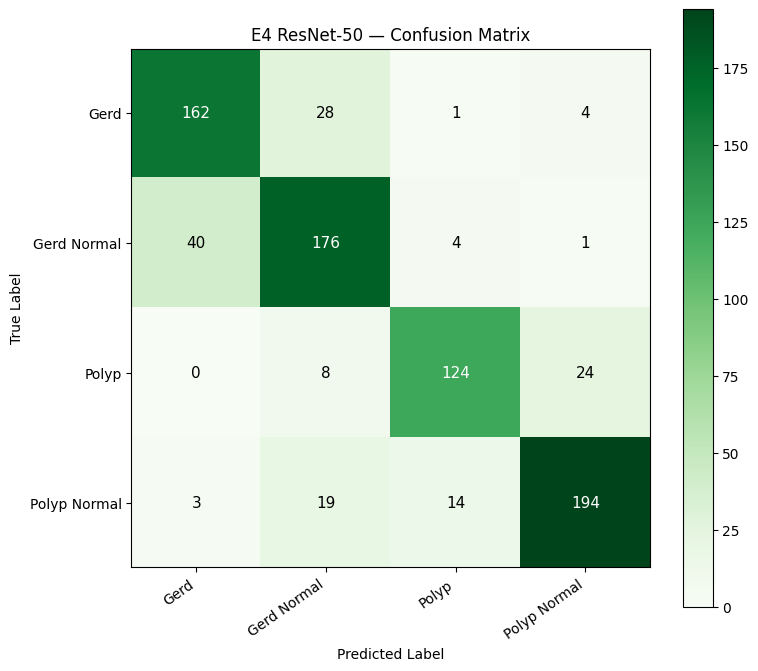

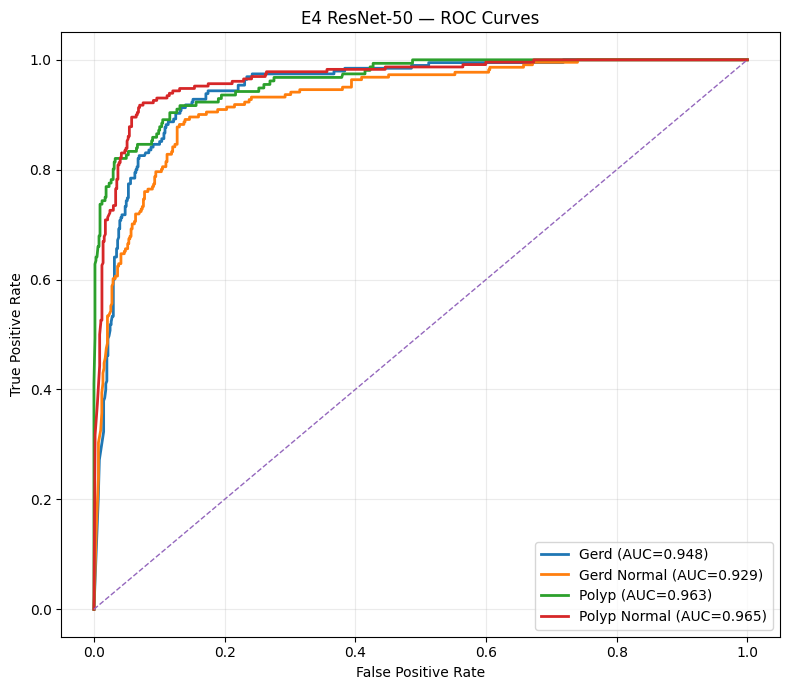

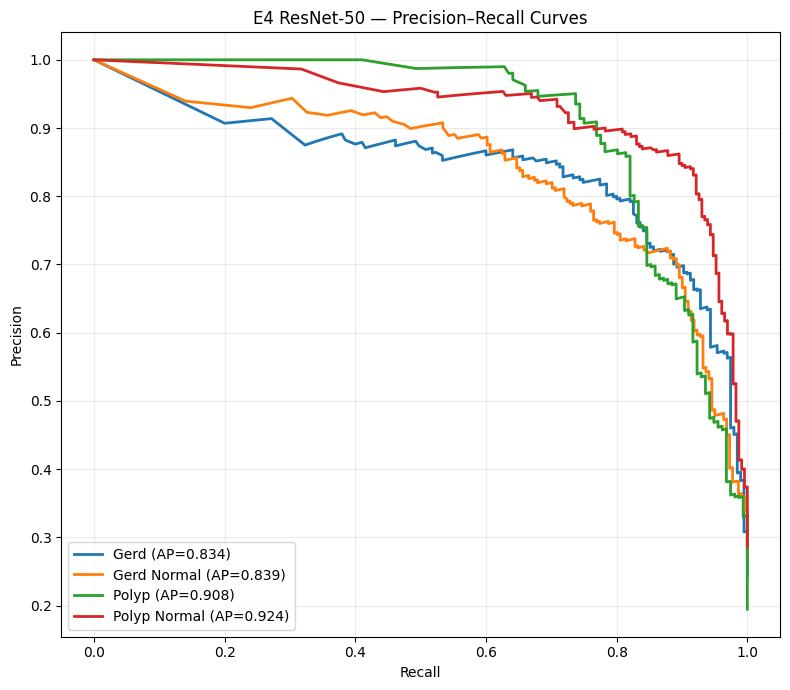

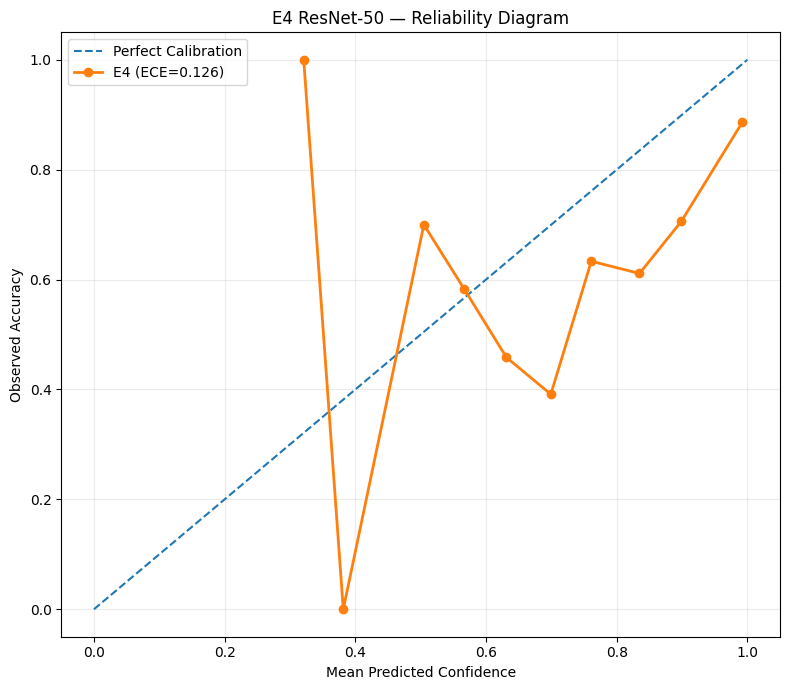


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Gerd     0.7902    0.8308    0.8100       195
 Gerd Normal     0.7619    0.7964    0.7788       221
       Polyp     0.8671    0.7949    0.8294       156
Polyp Normal     0.8700    0.8435    0.8565       230

    accuracy                         0.8180       802
   macro avg     0.8223    0.8164    0.8187       802
weighted avg     0.8203    0.8180    0.8185       802


LOADING E0–E4 RESULTS
✓ E0 Real Only
✓ E1 Conventional Aug
✓ E2 MixUp/CutMix
✓ E3 Unfiltered Diffusion
✓ E4 Fidelity Filtered

E0 / E1 / E2 / E3 / E4 — LOCKED TEST COMPARISON
           Metric  E0 Real Only  E1 Conventional Aug  E2 MixUp/CutMix  E3 Unfiltered Diffusion  E4 Fidelity Filtered  E4 - E0  E4 - E3
         Accuracy        0.8092               0.8217           0.8279                   0.8117                0.8180   0.0087   0.0062
Balanced Accuracy        0.8006               0.8233           0.8257                   0.8097  

In [ ]:
# ============================================================
# E4 — LOCKED TEST EVALUATION
# + E0 / E1 / E2 / E3 / E4 MASTER COMPARISON
#
# E4 = REAL + FIDELITY-FILTERED DIFFUSION
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

E4_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E4_Diffusion_FidelityFiltered"
)

RESULT_DIR = E4_DIR / "results"

CHECKPOINT_DIR = E4_DIR / "checkpoints"

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e4.pth"
)

E4_METRIC_PATH = (
    RESULT_DIR /
    "E4_final_test_metrics.json"
)

print("=" * 90)
print("E4 — LOCKED TEST EVALUATION")
print("REAL + FIDELITY-FILTERED DIFFUSION")
print("=" * 90)

print(
    "\nCheckpoint:",
    BEST_MODEL_PATH
)

if not BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        f"E4 checkpoint not found:\n"
        f"{BEST_MODEL_PATH}"
    )


# ============================================================
# 2. DEVICE
# ============================================================

if "device" not in globals():

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

print(
    "Device:",
    device
)


# ============================================================
# 3. AMP
# ============================================================

if "AMP_ENABLED" not in globals():

    AMP_ENABLED = (
        torch.cuda.is_available()
    )

print(
    "AMP enabled:",
    AMP_ENABLED
)


# ============================================================
# 4. CHECK TEST LOADER
# ============================================================

if "e4_test_loader" not in globals():

    raise RuntimeError(
        "e4_test_loader is missing. "
        "Run the E4 training/setup cell first."
    )


required_objects = [
    "model",
    "CLASS_NAMES",
    "NUM_CLASSES",
    "test_df"
]

missing_objects = [
    x
    for x in required_objects
    if x not in globals()
]

if missing_objects:

    raise RuntimeError(
        "Missing objects: "
        + ", ".join(missing_objects)
    )


# ============================================================
# 5. CALIBRATION FUNCTIONS
# ============================================================

def multiclass_brier_score(
    y_true,
    y_prob,
    n_classes
):

    one_hot = np.eye(
        n_classes
    )[y_true]

    return float(
        np.mean(
            np.sum(
                (
                    y_prob
                    -
                    one_hot
                ) ** 2,
                axis=1
            )
        )
    )


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
):

    confidences = np.max(
        y_prob,
        axis=1
    )

    predictions = np.argmax(
        y_prob,
        axis=1
    )

    correctness = (
        predictions
        ==
        y_true
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece_value = 0.0

    for i in range(n_bins):

        lower = edges[i]
        upper = edges[i + 1]

        if i == 0:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences > lower)
                &
                (confidences <= upper)
            )

        if mask.sum() == 0:
            continue

        bin_accuracy = (
            correctness[
                mask
            ].mean()
        )

        bin_confidence = (
            confidences[
                mask
            ].mean()
        )

        weight = (
            mask.sum()
            /
            len(y_true)
        )

        ece_value += (
            weight
            *
            abs(
                bin_accuracy
                -
                bin_confidence
            )
        )

    return float(
        ece_value
    )


# ============================================================
# 6. LOAD BEST E4 CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model = model.to(
    device
)

model.eval()


best_epoch = checkpoint.get(
    "epoch",
    None
)

best_val_macro_f1 = checkpoint.get(
    "best_val_macro_f1",
    None
)


print(
    "\nBest epoch:",
    best_epoch
)

if best_val_macro_f1 is not None:

    print(
        "Best validation Macro-F1:",
        f"{best_val_macro_f1:.4f}"
    )


# ============================================================
# 7. LOCKED TEST INFERENCE
# ============================================================

all_targets = []
all_predictions = []
all_probabilities = []

total_inference_time = 0.0


print("\n" + "=" * 90)
print("RUNNING LOCKED 802-IMAGE REAL TEST SET")
print("=" * 90)


with torch.no_grad():

    for images, labels in e4_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        with torch.amp.autocast(
            device_type=(
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            ),
            enabled=(
                AMP_ENABLED
                and
                torch.cuda.is_available()
            )
        ):

            logits = model(
                images
            )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        total_inference_time += (
            time.perf_counter()
            -
            start
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_targets.extend(
            labels
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
            .cpu()
            .numpy()
        )

        all_probabilities.extend(
            probabilities
            .cpu()
            .numpy()
        )


y_true = np.asarray(
    all_targets
)

y_pred = np.asarray(
    all_predictions
)

y_prob = np.asarray(
    all_probabilities
)


# ============================================================
# 8. STRICT TEST CHECK
# ============================================================

assert len(y_true) == 802, (
    f"Expected 802 locked test images, "
    f"got {len(y_true)}."
)

print(
    "\n✓ Locked test images:",
    len(y_true)
)


# ============================================================
# 9. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)


# ============================================================
# 10. AUROC / AUPRC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(
        NUM_CLASSES
    )
)

macro_auroc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = (
    average_precision_score(
        y_true_bin,
        y_prob,
        average="macro"
    )
)


# ============================================================
# 11. CALIBRATION
# ============================================================

brier = multiclass_brier_score(
    y_true,
    y_prob,
    NUM_CLASSES
)

ece = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
)

nll = log_loss(
    y_true,
    y_prob,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 13. PER-CLASS PERFORMANCE
# ============================================================

per_class_results = []


for i, class_name in enumerate(
    CLASS_NAMES
):

    TP = cm[i, i]

    FN = (
        cm[i, :].sum()
        -
        TP
    )

    FP = (
        cm[:, i].sum()
        -
        TP
    )

    TN = (
        cm.sum()
        -
        TP
        -
        FN
        -
        FP
    )

    sensitivity = (
        TP / (TP + FN)
        if TP + FN
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP
        else 0
    )

    ppv = (
        TP / (TP + FP)
        if TP + FP
        else 0
    )

    npv = (
        TN / (TN + FN)
        if TN + FN
        else 0
    )

    class_f1 = f1_score(

        (
            y_true == i
        ).astype(int),

        (
            y_pred == i
        ).astype(int),

        zero_division=0
    )

    class_auc = roc_auc_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_auprc = (
        average_precision_score(
            y_true_bin[:, i],
            y_prob[:, i]
        )
    )

    per_class_results.append({

        "Class":
            class_name,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "PPV":
            ppv,

        "NPV":
            npv,

        "F1":
            class_f1,

        "AUROC":
            class_auc,

        "AUPRC":
            class_auprc
    })


per_class_df = pd.DataFrame(
    per_class_results
)


# ============================================================
# 14. INFERENCE SPEED
# ============================================================

latency_ms = (
    total_inference_time
    /
    len(y_true)
    *
    1000
)

throughput = (
    len(y_true)
    /
    total_inference_time
)


# ============================================================
# 15. PRINT E4 RESULTS
# ============================================================

print("\n" + "=" * 90)
print("E4 — RESNET50 LOCKED TEST PERFORMANCE")
print("=" * 90)

print(
    f"Accuracy             : {accuracy:.4f}"
)

print(
    f"Balanced Accuracy    : {balanced_acc:.4f}"
)

print(
    f"Macro Precision      : {macro_precision:.4f}"
)

print(
    f"Macro Recall         : {macro_recall:.4f}"
)

print(
    f"Macro F1             : {macro_f1:.4f}"
)

print(
    f"Weighted F1          : {weighted_f1:.4f}"
)

print(
    f"MCC                  : {mcc:.4f}"
)

print(
    f"Cohen's Kappa        : {kappa:.4f}"
)

print(
    f"Macro AUROC          : {macro_auroc:.4f}"
)

print(
    f"Macro AUPRC          : {macro_auprc:.4f}"
)

print(
    f"Brier Score          : {brier:.4f}"
)

print(
    f"ECE                  : {ece:.4f}"
)

print(
    f"NLL                  : {nll:.4f}"
)

print(
    f"Inference latency    : {latency_ms:.3f} ms/image"
)

print(
    f"Throughput           : {throughput:.2f} images/sec"
)


print("\n" + "=" * 90)
print("PER-CLASS PERFORMANCE")
print("=" * 90)

print(
    per_class_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 16. SAVE E4 METRICS
# ============================================================

e4_metrics = {

    "experiment":
        "E4_ResNet50_FidelityFiltered",

    "training_strategy":
        (
            "Real + fidelity-filtered "
            "diffusion synthetic"
        ),

    "real_train_images":
        2803,

    "source_synthetic_images":
        2803,

    "accepted_synthetic_images":
        2103,

    "rejected_synthetic_images":
        700,

    "total_train_images":
        4906,

    "synthetic_retention_rate":
        2103 / 2803,

    "test_images":
        802,

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_acc),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_f1":
        float(macro_f1),

    "weighted_f1":
        float(weighted_f1),

    "mcc":
        float(mcc),

    "cohen_kappa":
        float(kappa),

    "macro_auroc":
        float(macro_auroc),

    "macro_auprc":
        float(macro_auprc),

    "brier_score":
        float(brier),

    "ece":
        float(ece),

    "nll":
        float(nll),

    "latency_ms_per_image":
        float(latency_ms),

    "throughput_images_per_second":
        float(throughput),

    "best_epoch":
        int(best_epoch),

    "best_validation_macro_f1":
        float(best_val_macro_f1),

    "synthetic_filtering":
        True
}


with open(
    E4_METRIC_PATH,
    "w"
) as f:

    json.dump(
        e4_metrics,
        f,
        indent=4
    )


per_class_df.to_csv(
    RESULT_DIR /
    "E4_per_class_metrics.csv",
    index=False
)


# ============================================================
# 17. SAVE TEST PREDICTIONS
# ============================================================

prediction_df = (
    test_df
    .copy()
    .reset_index(
        drop=True
    )
)

assert len(
    prediction_df
) == len(
    y_true
)


prediction_df[
    "true_id"
] = y_true

prediction_df[
    "predicted_id"
] = y_pred


prediction_df[
    "true_class"
] = [
    CLASS_NAMES[i]
    for i in y_true
]

prediction_df[
    "predicted_class"
] = [
    CLASS_NAMES[i]
    for i in y_pred
]

prediction_df[
    "correct"
] = (
    y_true
    ==
    y_pred
)

prediction_df[
    "confidence"
] = np.max(
    y_prob,
    axis=1
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    clean_name = (
        class_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )

    prediction_df[
        f"prob_{clean_name}"
    ] = y_prob[:, i]


prediction_df.to_csv(
    RESULT_DIR /
    "E4_test_predictions.csv",
    index=False
)


# ============================================================
# 18. CONFUSION MATRIX — GREENS
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    cmap="Greens",
    interpolation="nearest"
)

plt.title(
    "E4 ResNet-50 — Confusion Matrix"
)

plt.colorbar()


ticks = np.arange(
    len(
        CLASS_NAMES
    )
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    ticks,
    CLASS_NAMES
)


threshold = (
    cm.max()
    /
    2
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            str(
                cm[i, j]
            ),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j]
                >
                threshold
                else
                "black"
            ),
            fontsize=11
        )


plt.ylabel(
    "True Label"
)

plt.xlabel(
    "Predicted Label"
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E4_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={roc_auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "E4 ResNet-50 — ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E4_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true_bin[:, i],
            y_prob[:, i]
        )
    )

    ap_value = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP={ap_value:.3f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "E4 ResNet-50 — Precision–Recall Curves"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E4_PR_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. RELIABILITY DIAGRAM
# ============================================================

confidences = np.max(
    y_prob,
    axis=1
)

correctness = (
    y_pred
    ==
    y_true
).astype(float)


bin_edges = np.linspace(
    0,
    1,
    16
)

bin_acc = []
bin_conf = []


for i in range(
    15
):

    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    mask = (
        (confidences > lower)
        &
        (confidences <= upper)
    )

    if mask.sum() > 0:

        bin_acc.append(
            correctness[
                mask
            ].mean()
        )

        bin_conf.append(
            confidences[
                mask
            ].mean()
        )


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_conf,
    bin_acc,
    marker="o",
    linewidth=2,
    label=(
        f"E4 "
        f"(ECE={ece:.3f})"
    )
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "E4 ResNet-50 — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    RESULT_DIR /
    "E4_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 90)
print("CLASSIFICATION REPORT")
print("=" * 90)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=
            CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 23. LOAD E0–E4 METRICS
# ============================================================

metric_paths = {

    "E0 Real Only":

        PROJECT_DIR /
        "experiments" /
        "E0_ResNet50_RealOnly" /
        "results" /
        "E0_final_test_metrics.json",

    "E1 Conventional Aug":

        PROJECT_DIR /
        "experiments" /
        "E1_ResNet50_ConventionalAug" /
        "results" /
        "E1_final_test_metrics.json",

    "E2 MixUp/CutMix":

        PROJECT_DIR /
        "experiments" /
        "E2_ResNet50_MixUpCutMix" /
        "results" /
        "E2_final_test_metrics.json",

    "E3 Unfiltered Diffusion":

        PROJECT_DIR /
        "experiments" /
        "E3_Diffusion_Unfiltered" /
        "results" /
        "E3_final_test_metrics.json",

    "E4 Fidelity Filtered":

        E4_METRIC_PATH
}


loaded = {}


print("\n" + "=" * 95)
print("LOADING E0–E4 RESULTS")
print("=" * 95)


for name, path in metric_paths.items():

    if path.exists():

        with open(
            path,
            "r"
        ) as f:

            loaded[
                name
            ] = json.load(
                f
            )

        print(
            "✓",
            name
        )

    else:

        print(
            "✗ Missing:",
            name
        )


# ============================================================
# 24. MASTER COMPARISON
# ============================================================

metrics_to_compare = {

    "Accuracy":
        "accuracy",

    "Balanced Accuracy":
        "balanced_accuracy",

    "Macro Precision":
        "macro_precision",

    "Macro Recall":
        "macro_recall",

    "Macro F1":
        "macro_f1",

    "Weighted F1":
        "weighted_f1",

    "MCC":
        "mcc",

    "Cohen's Kappa":
        "cohen_kappa",

    "Macro AUROC":
        "macro_auroc",

    "Macro AUPRC":
        "macro_auprc",

    "Brier Score":
        "brier_score",

    "ECE":
        "ece",

    "NLL":
        "nll"
}


comparison_rows = []


for metric_name, key in (
    metrics_to_compare.items()
):

    row = {
        "Metric":
            metric_name
    }

    for experiment_name in metric_paths:

        data = loaded.get(
            experiment_name
        )

        if (
            data is not None
            and
            key in data
        ):

            row[
                experiment_name
            ] = data[key]

        else:

            row[
                experiment_name
            ] = np.nan

    comparison_rows.append(
        row
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 25. DIFFERENCE COLUMNS
# ============================================================

comparison_df[
    "E4 - E0"
] = (
    comparison_df[
        "E4 Fidelity Filtered"
    ]
    -
    comparison_df[
        "E0 Real Only"
    ]
)


comparison_df[
    "E4 - E3"
] = (
    comparison_df[
        "E4 Fidelity Filtered"
    ]
    -
    comparison_df[
        "E3 Unfiltered Diffusion"
    ]
)


MASTER_PATH = (
    RESULT_DIR /
    "E0_E1_E2_E3_E4_master_comparison.csv"
)


comparison_df.to_csv(
    MASTER_PATH,
    index=False
)


print("\n" + "=" * 110)
print("E0 / E1 / E2 / E3 / E4 — LOCKED TEST COMPARISON")
print("=" * 110)

print(
    comparison_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 26. DIRECT E3 → E4 ANALYSIS
# ============================================================

if (
    "E3 Unfiltered Diffusion"
    in loaded
):

    e3 = loaded[
        "E3 Unfiltered Diffusion"
    ]

    print("\n" + "=" * 90)
    print("E3 → E4 EFFECT OF FIDELITY FILTERING")
    print("=" * 90)

    higher_better = [

        ("Accuracy", "accuracy"),
        ("Balanced Accuracy", "balanced_accuracy"),
        ("Macro Precision", "macro_precision"),
        ("Macro Recall", "macro_recall"),
        ("Macro F1", "macro_f1"),
        ("MCC", "mcc"),
        ("Macro AUROC", "macro_auroc"),
        ("Macro AUPRC", "macro_auprc")
    ]

    for name, key in higher_better:

        delta = (
            e4_metrics[key]
            -
            e3[key]
        )

        print(
            f"{name:<22}: "
            f"{e3[key]:.4f} "
            f"→ "
            f"{e4_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


    print(
        "\nCalibration / error "
        "(lower is better)"
    )

    lower_better = [

        ("Brier Score", "brier_score"),
        ("ECE", "ece"),
        ("NLL", "nll")
    ]

    for name, key in lower_better:

        delta = (
            e4_metrics[key]
            -
            e3[key]
        )

        print(
            f"{name:<22}: "
            f"{e3[key]:.4f} "
            f"→ "
            f"{e4_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


# ============================================================
# 27. FINAL
# ============================================================

print("\n" + "=" * 95)
print("E4 FINAL EVALUATION COMPLETE")
print("=" * 95)

print("✓ Locked 802-image REAL test evaluated")
print("✓ Overall metrics saved")
print("✓ Per-class metrics saved")
print("✓ Test predictions saved")
print("✓ Green confusion matrix saved")
print("✓ ROC curves saved")
print("✓ PR curves saved")
print("✓ Reliability diagram saved")
print("✓ E0–E4 master comparison saved")
print("✓ Direct E3 → E4 filtering effect calculated")

print("\nSaved:")

print(
    "Metrics:",
    E4_METRIC_PATH
)

print(
    "Per-class:",
    RESULT_DIR /
    "E4_per_class_metrics.csv"
)

print(
    "Predictions:",
    RESULT_DIR /
    "E4_test_predictions.csv"
)

print(
    "Master comparison:",
    MASTER_PATH
)

print("=" * 95)

# E5 fidelity-guided curriculum

In [ ]:
# ============================================================
# GI-SAFE — E5
# PROPOSED FIDELITY-GUIDED SYNTHETIC CURRICULUM
#
# E4:
#   Real + all fidelity-filtered synthetic from epoch 1
#
# E5:
#   Real always available
#   Synthetic introduced from highest fidelity → lower fidelity
#
# Stage 1 | Epoch 1-3  : percentile > 0.75
# Stage 2 | Epoch 4-6  : percentile > 0.50
# Stage 3 | Epoch 7+   : percentile > 0.25 = all E4 accepted
#
# No test information used.
# Fresh ImageNet ResNet50.
# ============================================================

import gc
import json
import time
import random
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score
)

from tqdm.auto import tqdm


ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 0. MEMORY CLEANUP
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

DEVICE = device

print("=" * 100)
print("GI-SAFE E5 — FIDELITY-GUIDED SYNTHETIC CURRICULUM")
print("=" * 100)

print("Device :", device)

if torch.cuda.is_available():

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

SPLIT_DIR = PROJECT_DIR / "splits"

E4_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E4_Diffusion_FidelityFiltered"
)

E5_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E5_FilteredSyntheticCurriculum"
)

MANIFEST_DIR = E5_DIR / "manifests"
RESULT_DIR = E5_DIR / "results"
CHECKPOINT_DIR = E5_DIR / "checkpoints"

for folder in [
    E5_DIR,
    MANIFEST_DIR,
    RESULT_DIR,
    CHECKPOINT_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV = SPLIT_DIR / "val.csv"
TEST_CSV = SPLIT_DIR / "test.csv"


E4_FILTERED_CSV = (
    E4_DIR /
    "manifests" /
    "E4_filtered_synthetic_manifest.csv"
)


CURRICULUM_SYNTH_CSV = (
    MANIFEST_DIR /
    "E5_curriculum_synthetic_manifest.csv"
)

FINAL_TRAIN_CSV = (
    MANIFEST_DIR /
    "E5_final_train_manifest.csv"
)

CURRICULUM_CONFIG = (
    MANIFEST_DIR /
    "E5_curriculum_config.json"
)


BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e5.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_resnet50_e5.pth"
)

HISTORY_PATH = (
    RESULT_DIR /
    "E5_training_history.csv"
)

SUMMARY_PATH = (
    RESULT_DIR /
    "E5_training_summary.json"
)


# ============================================================
# 4. SAME CLASSIFIER PROTOCOL
# ============================================================

IMAGE_SIZE = 384

BATCH_SIZE = 16

NUM_EPOCHS = 30

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


# ============================================================
# 5. CURRICULUM DEFINITION
# ============================================================

STAGE_1_END = 3
STAGE_2_END = 6

STAGE_1_THRESHOLD = 0.75
STAGE_2_THRESHOLD = 0.50
STAGE_3_THRESHOLD = 0.25


print("\n" + "=" * 100)
print("E5 CURRICULUM POLICY")
print("=" * 100)

print(
    "Stage 1 | Epoch 1–3  | "
    "Real + highest-fidelity synthetic (>0.75)"
)

print(
    "Stage 2 | Epoch 4–6  | "
    "Real + high/medium synthetic (>0.50)"
)

print(
    "Stage 3 | Epoch 7–30 | "
    "Real + all E4 accepted synthetic (>0.25)"
)

print("\nReal images remain present at EVERY epoch.")

print(
    "Synthetic order:",
    "High fidelity → Medium fidelity → Full filtered pool"
)


# ============================================================
# 6. LOAD TABLES
# ============================================================

real_train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

synthetic_df = pd.read_csv(
    E4_FILTERED_CSV
)


print("\n" + "=" * 100)
print("DATA SOURCE")
print("=" * 100)

print(
    "Real train             :",
    len(real_train_df)
)

print(
    "E4 filtered synthetic  :",
    len(synthetic_df)
)

print(
    "Validation             :",
    len(val_df)
)

print(
    "Test                   :",
    len(test_df)
)


assert len(real_train_df) == 2803
assert len(synthetic_df) == 2103
assert len(val_df) == 401
assert len(test_df) == 802


# ============================================================
# 7. CHECK REQUIRED FIDELITY FIELD
# ============================================================

if (
    "class_composite_percentile"
    not in synthetic_df.columns
):

    raise RuntimeError(
        "class_composite_percentile is missing from "
        "the E4 filtered manifest."
    )


# ============================================================
# 8. ASSIGN CURRICULUM TIER
# ============================================================

def assign_curriculum_tier(
    percentile
):

    if percentile > 0.75:

        return "high_fidelity"

    elif percentile > 0.50:

        return "medium_fidelity"

    else:

        return "lower_filtered_fidelity"


synthetic_df[
    "curriculum_tier"
] = synthetic_df[
    "class_composite_percentile"
].apply(
    assign_curriculum_tier
)


print("\n" + "=" * 100)
print("SYNTHETIC CURRICULUM TIERS")
print("=" * 100)

print(
    synthetic_df[
        "curriculum_tier"
    ]
    .value_counts()
    .to_string()
)


synthetic_df.to_csv(
    CURRICULUM_SYNTH_CSV,
    index=False
)


# ============================================================
# 9. INDEX ORIGINAL REAL DATA
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("\nIndexing original real images...")


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower() in IMG_EXTS
    )
]


filename_index = defaultdict(list)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


print(
    "Original images indexed:",
    len(all_real_images)
)


# ============================================================
# 10. PATH RESOLUTION
# ============================================================

def normalize_text(x):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower().strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = filename_index.get(
        filename,
        []
    )

    if len(candidates) == 1:

        return str(
            candidates[0]
        )

    if len(candidates) == 0:

        return None

    class_norm = normalize_text(
        class_name
    )

    matches = []

    for p in candidates:

        parent_norm = normalize_text(
            str(p.parent)
        )

        if class_norm in parent_norm:

            matches.append(
                p
            )

    if len(matches) == 1:

        return str(
            matches[0]
        )

    return None


# ============================================================
# 11. RESOLVE REAL TRAIN / VAL / TEST
# ============================================================

for df in [
    real_train_df,
    val_df,
    test_df
]:

    df[
        "image_path"
    ] = df.apply(

        lambda row:
            resolve_real_image(
                row["filename"],
                row["class_name"]
            ),

        axis=1
    )


print("\nPath resolution:")

print(
    "Train missing:",
    real_train_df[
        "image_path"
    ].isna().sum()
)

print(
    "Val missing  :",
    val_df[
        "image_path"
    ].isna().sum()
)

print(
    "Test missing :",
    test_df[
        "image_path"
    ].isna().sum()
)


if (
    real_train_df["image_path"].isna().any()
    or
    val_df["image_path"].isna().any()
    or
    test_df["image_path"].isna().any()
):

    raise RuntimeError(
        "Some real-image paths could not be resolved."
    )


# ============================================================
# 12. STANDARDIZE REAL MANIFEST
# ============================================================

real_manifest = pd.DataFrame({

    "image_path":
        real_train_df[
            "image_path"
        ],

    "class_name":
        real_train_df[
            "class_name"
        ].astype(str),

    "source_type":
        "real",

    "source_filename":
        real_train_df[
            "filename"
        ],

    "source_row_id":
        np.arange(
            len(real_train_df)
        ),

    "class_composite_percentile":
        1.0,

    "curriculum_tier":
        "real"
})


# ============================================================
# 13. STANDARDIZE SYNTHETIC MANIFEST
# ============================================================

synthetic_manifest = pd.DataFrame({

    "image_path":
        synthetic_df[
            "synthetic_path"
        ],

    "class_name":
        synthetic_df[
            "class_name"
        ].astype(str),

    "source_type":
        "synthetic_filtered",

    "source_filename":
        synthetic_df[
            "source_filename"
        ],

    "source_row_id":
        synthetic_df[
            "row_id"
        ],

    "class_composite_percentile":
        synthetic_df[
            "class_composite_percentile"
        ],

    "curriculum_tier":
        synthetic_df[
            "curriculum_tier"
        ]
})


# ============================================================
# 14. VERIFY SYNTHETIC FILES
# ============================================================

missing_synthetic = int(

    (
        ~synthetic_manifest[
            "image_path"
        ].apply(
            lambda x:
                Path(
                    str(x)
                ).exists()
        )
    ).sum()
)


print(
    "\nMissing synthetic files:",
    missing_synthetic
)


if missing_synthetic > 0:

    raise RuntimeError(
        "Some E5 synthetic files are missing."
    )


# ============================================================
# 15. FINAL E5 DATASET
# ============================================================

final_train_df = pd.concat(

    [
        real_manifest,
        synthetic_manifest
    ],

    ignore_index=True
)


final_train_df.to_csv(
    FINAL_TRAIN_CSV,
    index=False
)


print("\n" + "=" * 100)
print("FINAL E5 TRAINING POOL")
print("=" * 100)

print("Real      :", len(real_manifest))
print("Synthetic :", len(synthetic_manifest))
print("Total     :", len(final_train_df))


assert len(final_train_df) == 4906


# ============================================================
# 16. CREATE THREE CURRICULUM STAGES
# ============================================================

stage1_synth = synthetic_manifest[

    synthetic_manifest[
        "class_composite_percentile"
    ] > STAGE_1_THRESHOLD

].copy()


stage2_synth = synthetic_manifest[

    synthetic_manifest[
        "class_composite_percentile"
    ] > STAGE_2_THRESHOLD

].copy()


stage3_synth = synthetic_manifest.copy()


stage1_df = pd.concat(
    [
        real_manifest,
        stage1_synth
    ],
    ignore_index=True
)


stage2_df = pd.concat(
    [
        real_manifest,
        stage2_synth
    ],
    ignore_index=True
)


stage3_df = pd.concat(
    [
        real_manifest,
        stage3_synth
    ],
    ignore_index=True
)


print("\n" + "=" * 100)
print("CURRICULUM STAGE SIZES")
print("=" * 100)

print(
    f"Stage 1 | real {len(real_manifest)} "
    f"+ synth {len(stage1_synth)} "
    f"= {len(stage1_df)}"
)

print(
    f"Stage 2 | real {len(real_manifest)} "
    f"+ synth {len(stage2_synth)} "
    f"= {len(stage2_df)}"
)

print(
    f"Stage 3 | real {len(real_manifest)} "
    f"+ synth {len(stage3_synth)} "
    f"= {len(stage3_df)}"
)


# ============================================================
# 17. SAVE CURRICULUM CONFIG
# ============================================================

curriculum_config = {

    "experiment":
        "E5_FilteredSyntheticCurriculum",

    "real_images":
        int(
            len(real_manifest)
        ),

    "filtered_synthetic_images":
        int(
            len(synthetic_manifest)
        ),

    "stage_1": {

        "epochs":
            "1-3",

        "minimum_class_percentile":
            0.75,

        "synthetic_images":
            int(
                len(stage1_synth)
            ),

        "total_training_images":
            int(
                len(stage1_df)
            )
    },

    "stage_2": {

        "epochs":
            "4-6",

        "minimum_class_percentile":
            0.50,

        "synthetic_images":
            int(
                len(stage2_synth)
            ),

        "total_training_images":
            int(
                len(stage2_df)
            )
    },

    "stage_3": {

        "epochs":
            "7-30",

        "minimum_class_percentile":
            0.25,

        "synthetic_images":
            int(
                len(stage3_synth)
            ),

        "total_training_images":
            int(
                len(stage3_df)
            )
    },

    "curriculum_direction":
        "high fidelity to progressively lower accepted fidelity",

    "real_images_present_at_all_epochs":
        True,

    "test_information_used":
        False
}


with open(
    CURRICULUM_CONFIG,
    "w"
) as f:

    json.dump(
        curriculum_config,
        f,
        indent=2
    )


# ============================================================
# 18. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(

    real_train_df[
        "class_name"
    ]
    .astype(str)
    .unique()
)


NUM_CLASSES = len(
    CLASS_NAMES
)


CLASS_TO_IDX = {

    cls: idx

    for idx, cls
    in enumerate(
        CLASS_NAMES
    )
}


print("\nClass mapping:")


for cls, idx in CLASS_TO_IDX.items():

    print(
        f"{idx:02d} → {cls}"
    )


# ============================================================
# 19. PREPROCESSING
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        width, height = image.size

        max_side = max(
            width,
            height
        )

        left = (
            max_side - width
        ) // 2

        right = (
            max_side
            -
            width
            -
            left
        )

        top = (
            max_side - height
        ) // 2

        bottom = (
            max_side
            -
            height
            -
            top
        )

        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


E0_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 20. DATASET
# ============================================================

class GISafeDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.transform = transform

        self.class_to_idx = (
            class_to_idx
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]

        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )

        if self.transform:

            image = self.transform(
                image
            )

        class_name = str(
            row[
                "class_name"
            ]
        )

        label = self.class_to_idx[
            class_name
        ]

        return (
            image,
            label
        )


# ============================================================
# 21. VAL / TEST DATASETS
# ============================================================

e5_val_dataset = GISafeDataset(
    val_df,
    E0_TRANSFORM,
    CLASS_TO_IDX
)

e5_test_dataset = GISafeDataset(
    test_df,
    E0_TRANSFORM,
    CLASS_TO_IDX
)


e5_val_loader = DataLoader(

    e5_val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False
)


e5_test_loader = DataLoader(

    e5_test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False
)


# ============================================================
# 22. FIXED CLASS WEIGHTS
#
# IMPORTANT:
# Use FINAL 4906-sample E5 distribution for all stages.
# This prevents class-weight changes from becoming a confounder.
# ============================================================

final_labels = (

    final_train_df[
        "class_name"
    ]

    .astype(str)

    .map(
        CLASS_TO_IDX
    )

    .values
)


class_counts = np.bincount(

    final_labels,

    minlength=
        NUM_CLASSES
)


class_weights = (

    len(final_labels)

    /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


class_weights_tensor = torch.tensor(

    class_weights,

    dtype=torch.float32,

    device=device
)


print("\n" + "=" * 100)
print("FIXED E5 CLASS WEIGHTS")
print("=" * 100)


for i, cls in enumerate(
    CLASS_NAMES
):

    print(
        f"{cls:<25} "
        f"N={class_counts[i]:4d} "
        f"Weight={class_weights[i]:.6f}"
    )


# ============================================================
# 23. TRAIN LOADER CREATOR
# ============================================================

def build_stage_loader(
    dataframe,
    stage_seed
):

    dataset = GISafeDataset(
        dataframe,
        E0_TRANSFORM,
        CLASS_TO_IDX
    )

    generator = (
        torch.Generator()
    )

    generator.manual_seed(
        stage_seed
    )

    loader = DataLoader(

        dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=True,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False,

        generator=
            generator
    )

    return loader


# Create one loader per curriculum stage

stage1_loader = build_stage_loader(
    stage1_df,
    SEED + 101
)

stage2_loader = build_stage_loader(
    stage2_df,
    SEED + 102
)

stage3_loader = build_stage_loader(
    stage3_df,
    SEED + 103
)


# ============================================================
# 24. FRESH RESNET50
# ============================================================

weights = (
    ResNet50_Weights.IMAGENET1K_V2
)


model = models.resnet50(
    weights=weights
)


model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)


model = model.to(
    device
)


print(
    "\n✓ Fresh ImageNet ResNet50 initialized."
)


# ============================================================
# 25. LOSS / OPTIMIZER / SCHEDULER
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=
        class_weights_tensor
)


optimizer = optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,

    betas=
        (0.9, 0.999),

    eps=
        1e-8
)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=
        SCHEDULER_FACTOR,

    patience=
        SCHEDULER_PATIENCE
)


# ============================================================
# 26. TRAIN FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader
):

    model.train()

    total_loss = 0.0

    y_true = []
    y_pred = []


    for images, labels in tqdm(
        loader,
        desc="Train",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            images
        )


        loss = criterion(
            logits,
            labels
        )


        loss.backward()

        optimizer.step()


        total_loss += (
            loss.item()
            *
            images.size(0)
        )


        predictions = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels
            .detach()
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )


    loss_value = (
        total_loss
        /
        len(loader.dataset)
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    balanced_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )


    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )


    return (
        loss_value,
        accuracy,
        balanced_acc,
        macro_f1
    )


# ============================================================
# 27. VALIDATION
# ============================================================

@torch.no_grad()
def validate(
    model,
    loader
):

    model.eval()

    total_loss = 0.0

    y_true = []
    y_pred = []


    for images, labels in tqdm(
        loader,
        desc="Val",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        loss = criterion(
            logits,
            labels
        )


        total_loss += (
            loss.item()
            *
            images.size(0)
        )


        predictions = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )


    loss_value = (
        total_loss
        /
        len(loader.dataset)
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    balanced_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )


    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(

            y_true,
            y_pred,

            average="macro",

            zero_division=0
        )
    )


    return (
        loss_value,
        accuracy,
        balanced_acc,
        precision,
        recall,
        macro_f1
    )


# ============================================================
# 28. CURRICULUM HELPER
# ============================================================

def get_curriculum_stage(
    epoch
):

    if epoch <= STAGE_1_END:

        return (
            "Stage-1 High Fidelity",
            stage1_loader,
            len(stage1_synth)
        )

    elif epoch <= STAGE_2_END:

        return (
            "Stage-2 High+Medium",
            stage2_loader,
            len(stage2_synth)
        )

    else:

        return (
            "Stage-3 Full Filtered",
            stage3_loader,
            len(stage3_synth)
        )


# ============================================================
# 29. TRAINING
# ============================================================

history = []

best_val_macro_f1 = -np.inf

best_epoch = 0

epochs_without_improvement = 0

training_start = time.time()


print("\n" + "=" * 100)
print("STARTING E5 CURRICULUM TRAINING")
print("=" * 100)


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = time.time()


    (
        stage_name,
        train_loader,
        current_synthetic_count
    ) = get_curriculum_stage(
        epoch
    )


    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    (
        train_loss,
        train_acc,
        train_bal_acc,
        train_macro_f1
    ) = train_one_epoch(
        model,
        train_loader
    )


    (
        val_loss,
        val_acc,
        val_bal_acc,
        val_precision,
        val_recall,
        val_macro_f1
    ) = validate(
        model,
        e5_val_loader
    )


    scheduler.step(
        val_macro_f1
    )


    epoch_seconds = (
        time.time()
        -
        epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "curriculum_stage":
            stage_name,

        "real_images":
            2803,

        "synthetic_images_available":
            current_synthetic_count,

        "training_pool_size":
            len(
                train_loader.dataset
            ),

        "lr":
            current_lr,

        "train_loss":
            train_loss,

        "train_accuracy":
            train_acc,

        "train_balanced_accuracy":
            train_bal_acc,

        "train_macro_f1":
            train_macro_f1,

        "val_loss":
            val_loss,

        "val_accuracy":
            val_acc,

        "val_balanced_accuracy":
            val_bal_acc,

        "val_precision_macro":
            val_precision,

        "val_recall_macro":
            val_recall,

        "val_macro_f1":
            val_macro_f1,

        "epoch_seconds":
            epoch_seconds
    })


    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )


    # ========================================================
    # BEST MODEL
    # ========================================================

    if (
        val_macro_f1
        >
        best_val_macro_f1
    ):

        best_val_macro_f1 = (
            val_macro_f1
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(

            {

                "experiment":
                    "E5_ResNet50_FilteredSyntheticCurriculum",

                "epoch":
                    epoch,

                "curriculum_stage":
                    stage_name,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_val_macro_f1":
                    best_val_macro_f1,

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE,

                "batch_size":
                    BATCH_SIZE,

                "seed":
                    SEED,

                "real_train_images":
                    2803,

                "filtered_synthetic_images":
                    2103,

                "curriculum":
                    True
            },

            BEST_MODEL_PATH
        )


    else:

        epochs_without_improvement += 1


    # ========================================================
    # LAST MODEL
    # ========================================================

    torch.save(

        {

            "experiment":
                "E5_ResNet50_FilteredSyntheticCurriculum",

            "epoch":
                epoch,

            "curriculum_stage":
                stage_name,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "best_val_macro_f1":
                best_val_macro_f1,

            "class_names":
                CLASS_NAMES,

            "class_to_idx":
                CLASS_TO_IDX,

            "image_size":
                IMAGE_SIZE,

            "batch_size":
                BATCH_SIZE,

            "seed":
                SEED
        },

        LAST_MODEL_PATH
    )


    new_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ========================================================
    # STATUS
    # ========================================================

    print(
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}"
    )

    print(
        f"Curriculum : {stage_name}"
    )

    print(
        f"Training   : "
        f"2803 real + "
        f"{current_synthetic_count} synthetic "
        f"= {len(train_loader.dataset)}"
    )

    print(
        f"Train | "
        f"Loss {train_loss:.4f} | "
        f"Acc {train_acc:.4f} | "
        f"BalAcc {train_bal_acc:.4f} | "
        f"Macro-F1 {train_macro_f1:.4f}"
    )

    print(
        f"Val   | "
        f"Loss {val_loss:.4f} | "
        f"Acc {val_acc:.4f} | "
        f"BalAcc {val_bal_acc:.4f} | "
        f"Macro-F1 {val_macro_f1:.4f}"
    )

    print(
        f"LR    | "
        f"{current_lr:.2e} "
        f"→ {new_lr:.2e}"
    )

    print(
        f"Best  | "
        f"Epoch {best_epoch} | "
        f"Macro-F1 "
        f"{best_val_macro_f1:.6f}"
    )

    print(
        f"Early stop counter: "
        f"{epochs_without_improvement}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )

    print(
        f"Time  : "
        f"{epoch_seconds:.1f} sec"
    )


    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print(
            "\n✓ Early stopping triggered."
        )

        break


# ============================================================
# 30. SUMMARY
# ============================================================

total_training_seconds = (
    time.time()
    -
    training_start
)


epochs_completed = len(
    history
)


peak_gpu_memory_gb = None


if torch.cuda.is_available():

    peak_gpu_memory_gb = (
        torch.cuda
        .max_memory_allocated()
        /
        1024**3
    )


training_summary = {

    "experiment":
        "E5_ResNet50_FilteredSyntheticCurriculum",

    "training_strategy":
        "Fidelity-guided progressive synthetic curriculum",

    "real_train_images":
        2803,

    "filtered_synthetic_pool":
        2103,

    "final_training_pool":
        4906,

    "stage_1_epochs":
        "1-3",

    "stage_1_synthetic":
        int(
            len(stage1_synth)
        ),

    "stage_2_epochs":
        "4-6",

    "stage_2_synthetic":
        int(
            len(stage2_synth)
        ),

    "stage_3_epochs":
        "7+",

    "stage_3_synthetic":
        int(
            len(stage3_synth)
        ),

    "validation_images":
        401,

    "test_images":
        802,

    "epochs_planned":
        NUM_EPOCHS,

    "epochs_completed":
        epochs_completed,

    "best_epoch":
        best_epoch,

    "best_val_macro_f1":
        float(
            best_val_macro_f1
        ),

    "batch_size":
        BATCH_SIZE,

    "initial_learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "random_seed":
        SEED,

    "curriculum":
        True,

    "test_information_used":
        False,

    "total_training_minutes":
        total_training_seconds / 60,

    "peak_gpu_memory_gb":
        peak_gpu_memory_gb
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        training_summary,
        f,
        indent=2
    )


# ============================================================
# 31. FINAL STATUS
# ============================================================

print("\n" + "=" * 100)
print("E5 CURRICULUM TRAINING COMPLETE")
print("=" * 100)

print(
    "Real training images      : 2803"
)

print(
    "Filtered synthetic pool   : 2103"
)

print(
    "Final training pool       : 4906"
)

print(
    "\nStage 1 synthetic         :",
    len(stage1_synth)
)

print(
    "Stage 2 synthetic         :",
    len(stage2_synth)
)

print(
    "Stage 3 synthetic         :",
    len(stage3_synth)
)

print(
    "\nEpochs completed          :",
    epochs_completed
)

print(
    "Best epoch                :",
    best_epoch
)

print(
    "Best validation Macro-F1 :",
    f"{best_val_macro_f1:.6f}"
)

print(
    "Training time             :",
    f"{total_training_seconds / 60:.2f} min"
)

print(
    "\nBest checkpoint:",
    BEST_MODEL_PATH
)

print(
    "History:",
    HISTORY_PATH
)

print(
    "Summary:",
    SUMMARY_PATH
)

print(
    "\n✓ e5_test_loader already prepared."
)

print(
    "✓ Fresh ImageNet initialization."
)

print(
    "✓ Same 2103 E4 filtered synthetic images."
)

print(
    "✓ Only synthetic presentation schedule changed."
)

print(
    "✓ No validation/test information used for curriculum."
)

print("=" * 100)

GI-SAFE E5 — FIDELITY-GUIDED SYNTHETIC CURRICULUM
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB

E5 CURRICULUM POLICY
Stage 1 | Epoch 1–3  | Real + highest-fidelity synthetic (>0.75)
Stage 2 | Epoch 4–6  | Real + high/medium synthetic (>0.50)
Stage 3 | Epoch 7–30 | Real + all E4 accepted synthetic (>0.25)

Real images remain present at EVERY epoch.
Synthetic order: High fidelity → Medium fidelity → Full filtered pool

DATA SOURCE
Real train             : 2803
E4 filtered synthetic  : 2103
Validation             : 401
Test                   : 802

SYNTHETIC CURRICULUM TIERS
curriculum_tier
high_fidelity              703
lower_filtered_fidelity    700
medium_fidelity            700

Indexing original real images...
Original images indexed: 4006

Path resolution:
Train missing: 0
Val missing  : 0
Test missing : 0

Missing synthetic files: 0

FINAL E5 TRAINING POOL
Real      : 2803
Synthetic : 2103
Total     : 4906

CURRICULUM STAGE SIZES
Stage 1 | real 2803 + synth 703 = 3506
Stage 2 | rea

Train:   0%|          | 0/220 [00:00<?, ?it/s]

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 01/30
Curriculum : Stage-1 High Fidelity
Training   : 2803 real + 703 synthetic = 3506
Train | Loss 0.8391 | Acc 0.6623 | BalAcc 0.6537 | Macro-F1 0.6556
Val   | Loss 0.6262 | Acc 0.7382 | BalAcc 0.7427 | Macro-F1 0.7366
LR    | 1.00e-04 → 1.00e-04
Best  | Epoch 1 | Macro-F1 0.736580
Early stop counter: 0/7
Time  : 39.7 sec


Train:   0%|          | 0/220 [00:00<?, ?it/s]

...

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 19/30
Curriculum : Stage-3 Full Filtered
Training   : 2803 real + 2103 synthetic = 4906
Train | Loss 0.0046 | Acc 0.9986 | BalAcc 0.9986 | Macro-F1 0.9986
Val   | Loss 0.7434 | Acc 0.8554 | BalAcc 0.8518 | Macro-F1 0.8543
LR    | 2.50e-05 → 1.25e-05
Best  | Epoch 13 | Macro-F1 0.857928
Early stop counter: 6/7
Time  : 42.1 sec


Train:   0%|          | 0/307 [00:00<?, ?it/s]

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 20/30
Curriculum : Stage-3 Full Filtered
Training   : 2803 real + 2103 synthetic = 4906
Train | Loss 0.0037 | Acc 0.9994 | BalAcc 0.9994 | Macro-F1 0.9994
Val   | Loss 0.6989 | Acc 0.8479 | BalAcc 0.8425 | Macro-F1 0.8470
LR    | 1.25e-05 → 1.25e-05
Best  | Epoch 13 | Macro-F1 0.857928
Early stop counter: 7/7
Time  : 47.8 sec

✓ Early stopping triggered.

E5 CURRICULUM TRAINING COMPLETE
Real training images      : 2803
Filtered synthetic pool   : 2103
Final training pool       : 4906

Stage 1 synthetic         : 703
Stage 2 synthetic         : 1403
Stage 3 synthetic         : 2103

Epochs completed          : 20
Best epoch                : 13
Best validation Macro-F1 : 0.857928
Training time             : 19.42 min

Best checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E5_FilteredSyntheticCurriculum/checkpoints/best_resnet50_e5.pth
History: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E5_FilteredSyntheticCurriculum/results/E5_training_history.csv
Su

E5 — LOCKED TEST EVALUATION
PROPOSED FIDELITY-GUIDED SYNTHETIC CURRICULUM

Checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E5_FilteredSyntheticCurriculum/checkpoints/best_resnet50_e5.pth
Device: cuda
AMP enabled: True

Best epoch: 13
Best validation Macro-F1: 0.857928

RUNNING LOCKED 802-IMAGE REAL TEST SET

✓ Locked test images: 802

E5 — LOCKED TEST PERFORMANCE
Accuracy             : 0.8155
Balanced Accuracy    : 0.8137
Macro Precision      : 0.8192
Macro Recall         : 0.8137
Macro F1             : 0.8157
Weighted F1          : 0.8161
MCC                  : 0.7526
Cohen's Kappa        : 0.7520
Macro AUROC          : 0.9524
Macro AUPRC          : 0.8780
Brier Score          : 0.3140
ECE                  : 0.1327
NLL                  : 0.7327
Inference latency    : 0.821 ms/image
Throughput           : 1217.76 images/sec

PER-CLASS PERFORMANCE
       Class  Sensitivity  Specificity    PPV    NPV     F1  AUROC  AUPRC
        Gerd       0.7949       0.9423 0.8158 0

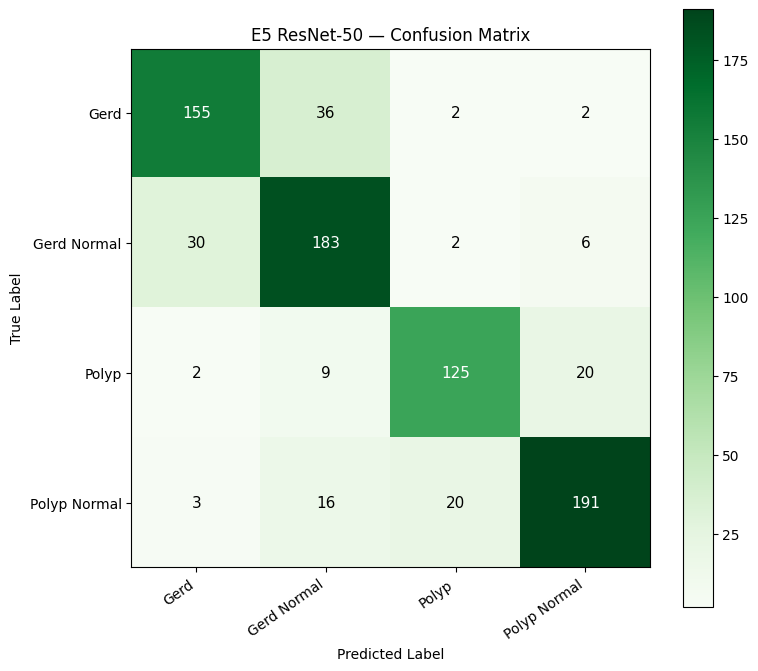

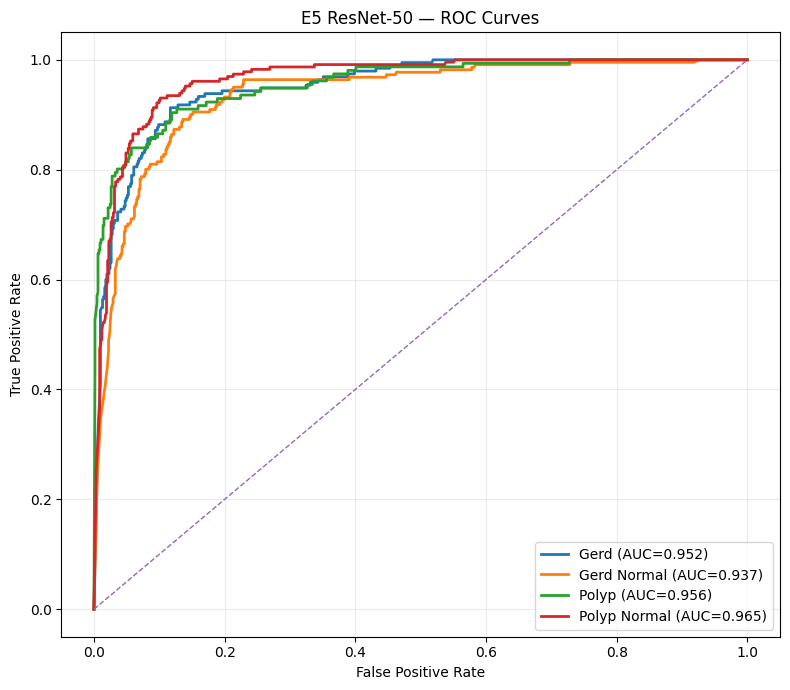

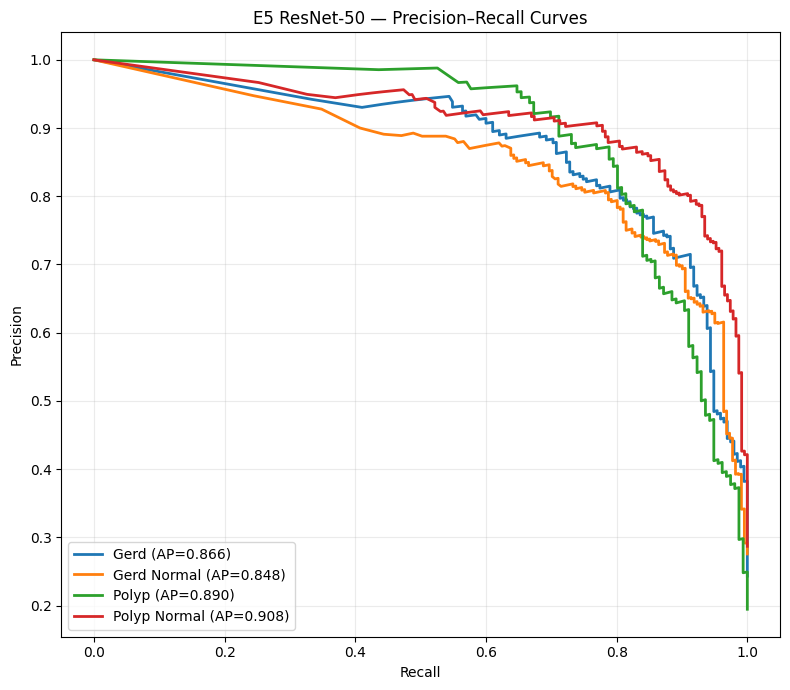

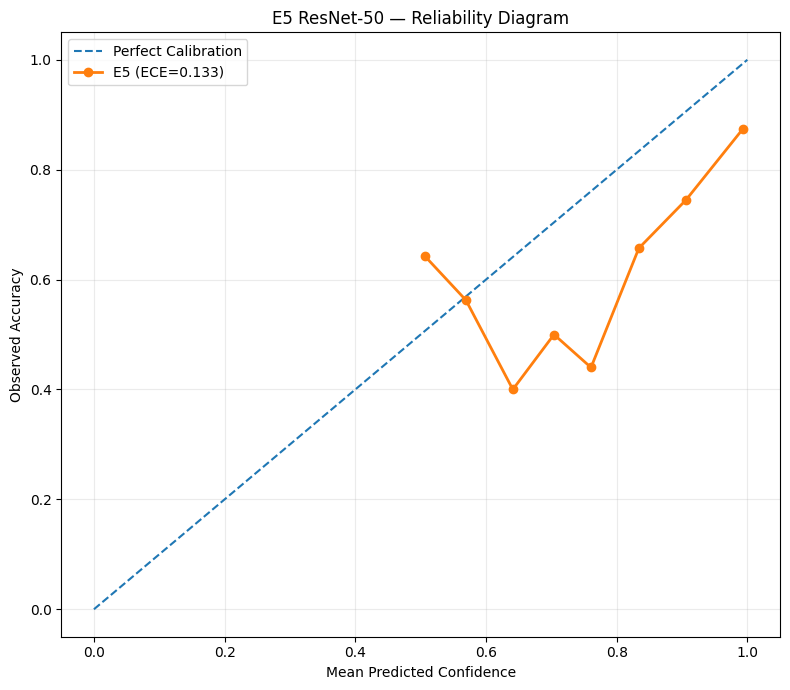


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Gerd     0.8158    0.7949    0.8052       195
 Gerd Normal     0.7500    0.8281    0.7871       221
       Polyp     0.8389    0.8013    0.8197       156
Polyp Normal     0.8721    0.8304    0.8508       230

    accuracy                         0.8155       802
   macro avg     0.8192    0.8137    0.8157       802
weighted avg     0.8183    0.8155    0.8161       802


LOADING E0 → E5 RESULTS
✓ E0 Real Only
✓ E1 Conventional Aug
✓ E2 MixUp/CutMix
✓ E3 Unfiltered Diffusion
✓ E4 Fidelity Filtered
✓ E5 Proposed Curriculum

E0 / E1 / E2 / E3 / E4 / E5 — LOCKED TEST COMPARISON
           Metric  E0 Real Only  E1 Conventional Aug  E2 MixUp/CutMix  E3 Unfiltered Diffusion  E4 Fidelity Filtered  E5 Proposed Curriculum  E5 - E0  E5 - E4  E5 - E2
         Accuracy        0.8092               0.8217           0.8279                   0.8117                0.8180                  0.8155   0.0062  -0.0025  -0.012

In [ ]:
# ============================================================
# E5 — LOCKED TEST EVALUATION
# + E0 / E1 / E2 / E3 / E4 / E5 MASTER COMPARISON
#
# E5 = PROPOSED FIDELITY-GUIDED SYNTHETIC CURRICULUM
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

E5_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E5_FilteredSyntheticCurriculum"
)

RESULT_DIR = (
    E5_DIR /
    "results"
)

CHECKPOINT_DIR = (
    E5_DIR /
    "checkpoints"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e5.pth"
)

E5_METRIC_PATH = (
    RESULT_DIR /
    "E5_final_test_metrics.json"
)


print("=" * 95)
print("E5 — LOCKED TEST EVALUATION")
print("PROPOSED FIDELITY-GUIDED SYNTHETIC CURRICULUM")
print("=" * 95)

print(
    "\nCheckpoint:",
    BEST_MODEL_PATH
)

if not BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        f"E5 best checkpoint not found:\n"
        f"{BEST_MODEL_PATH}"
    )


# ============================================================
# 2. DEVICE
# ============================================================

if "device" not in globals():

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

print(
    "Device:",
    device
)


# ============================================================
# 3. AMP
# ============================================================

if "AMP_ENABLED" not in globals():

    AMP_ENABLED = (
        torch.cuda.is_available()
    )

print(
    "AMP enabled:",
    AMP_ENABLED
)


# ============================================================
# 4. CHECK TEST LOADER
# ============================================================

if "e5_test_loader" not in globals():

    raise RuntimeError(
        "e5_test_loader not found. "
        "Run the E5 training/setup cell first."
    )


# ============================================================
# 5. CALIBRATION FUNCTIONS
# ============================================================

def multiclass_brier_score(
    y_true,
    y_prob,
    n_classes
):

    y_onehot = np.eye(
        n_classes
    )[y_true]

    return float(
        np.mean(
            np.sum(
                (
                    y_prob -
                    y_onehot
                ) ** 2,
                axis=1
            )
        )
    )


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
):

    confidences = np.max(
        y_prob,
        axis=1
    )

    predictions = np.argmax(
        y_prob,
        axis=1
    )

    correctness = (
        predictions == y_true
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece_value = 0.0

    for i in range(n_bins):

        lower = edges[i]
        upper = edges[i + 1]

        if i == 0:

            mask = (
                (confidences >= lower)
                &
                (confidences <= upper)
            )

        else:

            mask = (
                (confidences > lower)
                &
                (confidences <= upper)
            )

        if mask.sum() == 0:
            continue

        bin_acc = (
            correctness[
                mask
            ].mean()
        )

        bin_conf = (
            confidences[
                mask
            ].mean()
        )

        weight = (
            mask.sum()
            /
            len(y_true)
        )

        ece_value += (
            weight
            *
            abs(
                bin_acc -
                bin_conf
            )
        )

    return float(
        ece_value
    )


# ============================================================
# 6. LOAD BEST E5 MODEL
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model = model.to(
    device
)

model.eval()


best_epoch = checkpoint.get(
    "epoch",
    None
)

best_val_macro_f1 = checkpoint.get(
    "best_val_macro_f1",
    None
)


print(
    "\nBest epoch:",
    best_epoch
)

print(
    "Best validation Macro-F1:",
    f"{best_val_macro_f1:.6f}"
)


# ============================================================
# 7. LOCKED TEST INFERENCE
# ============================================================

all_targets = []
all_predictions = []
all_probabilities = []

total_inference_time = 0.0


print("\n" + "=" * 95)
print("RUNNING LOCKED 802-IMAGE REAL TEST SET")
print("=" * 95)


with torch.no_grad():

    for images, labels in e5_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        with torch.amp.autocast(
            device_type=(
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            ),
            enabled=(
                AMP_ENABLED
                and
                torch.cuda.is_available()
            )
        ):

            logits = model(
                images
            )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        total_inference_time += (
            time.perf_counter()
            -
            start
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_targets.extend(
            labels
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
            .cpu()
            .numpy()
        )

        all_probabilities.extend(
            probabilities
            .cpu()
            .numpy()
        )


y_true = np.asarray(
    all_targets
)

y_pred = np.asarray(
    all_predictions
)

y_prob = np.asarray(
    all_probabilities
)


assert len(y_true) == 802, (
    f"Expected 802 test images, "
    f"got {len(y_true)}"
)

print(
    "\n✓ Locked test images:",
    len(y_true)
)


# ============================================================
# 8. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)


# ============================================================
# 9. AUROC / AUPRC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(
        NUM_CLASSES
    )
)

macro_auroc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = average_precision_score(
    y_true_bin,
    y_prob,
    average="macro"
)


# ============================================================
# 10. CALIBRATION
# ============================================================

brier = multiclass_brier_score(
    y_true,
    y_prob,
    NUM_CLASSES
)

ece = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
)

nll = log_loss(
    y_true,
    y_prob,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 12. PER-CLASS METRICS
# ============================================================

per_class_results = []


for i, class_name in enumerate(
    CLASS_NAMES
):

    TP = cm[i, i]

    FN = (
        cm[i, :].sum()
        -
        TP
    )

    FP = (
        cm[:, i].sum()
        -
        TP
    )

    TN = (
        cm.sum()
        -
        TP
        -
        FN
        -
        FP
    )

    sensitivity = (
        TP / (TP + FN)
        if TP + FN
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP
        else 0
    )

    ppv = (
        TP / (TP + FP)
        if TP + FP
        else 0
    )

    npv = (
        TN / (TN + FN)
        if TN + FN
        else 0
    )

    class_f1 = f1_score(

        (
            y_true == i
        ).astype(int),

        (
            y_pred == i
        ).astype(int),

        zero_division=0
    )

    class_auc = roc_auc_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    class_auprc = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    per_class_results.append({

        "Class":
            class_name,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "PPV":
            ppv,

        "NPV":
            npv,

        "F1":
            class_f1,

        "AUROC":
            class_auc,

        "AUPRC":
            class_auprc
    })


per_class_df = pd.DataFrame(
    per_class_results
)


# ============================================================
# 13. INFERENCE SPEED
# ============================================================

latency_ms = (
    total_inference_time
    /
    len(y_true)
    *
    1000
)

throughput = (
    len(y_true)
    /
    total_inference_time
)


# ============================================================
# 14. PRINT FINAL E5 PERFORMANCE
# ============================================================

print("\n" + "=" * 95)
print("E5 — LOCKED TEST PERFORMANCE")
print("=" * 95)

print(f"Accuracy             : {accuracy:.4f}")
print(f"Balanced Accuracy    : {balanced_acc:.4f}")

print(f"Macro Precision      : {macro_precision:.4f}")
print(f"Macro Recall         : {macro_recall:.4f}")
print(f"Macro F1             : {macro_f1:.4f}")
print(f"Weighted F1          : {weighted_f1:.4f}")

print(f"MCC                  : {mcc:.4f}")
print(f"Cohen's Kappa        : {kappa:.4f}")

print(f"Macro AUROC          : {macro_auroc:.4f}")
print(f"Macro AUPRC          : {macro_auprc:.4f}")

print(f"Brier Score          : {brier:.4f}")
print(f"ECE                  : {ece:.4f}")
print(f"NLL                  : {nll:.4f}")

print(f"Inference latency    : {latency_ms:.3f} ms/image")
print(f"Throughput           : {throughput:.2f} images/sec")


print("\n" + "=" * 95)
print("PER-CLASS PERFORMANCE")
print("=" * 95)

print(
    per_class_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 15. SAVE FINAL METRICS
# ============================================================

e5_metrics = {

    "experiment":
        "E5_FilteredSyntheticCurriculum",

    "training_strategy":
        "Fidelity-guided progressive synthetic curriculum",

    "real_train_images":
        2803,

    "filtered_synthetic_images":
        2103,

    "final_training_pool":
        4906,

    "stage_1_synthetic":
        703,

    "stage_2_synthetic":
        1403,

    "stage_3_synthetic":
        2103,

    "test_images":
        802,

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_acc),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_f1":
        float(macro_f1),

    "weighted_f1":
        float(weighted_f1),

    "mcc":
        float(mcc),

    "cohen_kappa":
        float(kappa),

    "macro_auroc":
        float(macro_auroc),

    "macro_auprc":
        float(macro_auprc),

    "brier_score":
        float(brier),

    "ece":
        float(ece),

    "nll":
        float(nll),

    "latency_ms_per_image":
        float(latency_ms),

    "throughput_images_per_second":
        float(throughput),

    "best_epoch":
        int(best_epoch),

    "best_validation_macro_f1":
        float(best_val_macro_f1),

    "curriculum":
        True
}


with open(
    E5_METRIC_PATH,
    "w"
) as f:

    json.dump(
        e5_metrics,
        f,
        indent=4
    )


per_class_df.to_csv(
    RESULT_DIR /
    "E5_per_class_metrics.csv",
    index=False
)


# ============================================================
# 16. SAVE TEST PREDICTIONS
# ============================================================

prediction_df = (
    test_df
    .copy()
    .reset_index(
        drop=True
    )
)


assert len(
    prediction_df
) == len(
    y_true
)


prediction_df[
    "true_id"
] = y_true

prediction_df[
    "predicted_id"
] = y_pred


prediction_df[
    "true_class"
] = [
    CLASS_NAMES[i]
    for i in y_true
]


prediction_df[
    "predicted_class"
] = [
    CLASS_NAMES[i]
    for i in y_pred
]


prediction_df[
    "correct"
] = (
    y_true == y_pred
)


prediction_df[
    "confidence"
] = np.max(
    y_prob,
    axis=1
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    clean_name = (
        class_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )

    prediction_df[
        f"prob_{clean_name}"
    ] = y_prob[:, i]


prediction_df.to_csv(
    RESULT_DIR /
    "E5_test_predictions.csv",
    index=False
)


# ============================================================
# 17. CONFUSION MATRIX — GREENS
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    cmap="Greens",
    interpolation="nearest"
)

plt.title(
    "E5 ResNet-50 — Confusion Matrix"
)

plt.colorbar()


ticks = np.arange(
    len(CLASS_NAMES)
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    ticks,
    CLASS_NAMES
)


threshold = (
    cm.max() / 2
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            str(
                cm[i, j]
            ),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            ),
            fontsize=11
        )


plt.ylabel(
    "True Label"
)

plt.xlabel(
    "Predicted Label"
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E5_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 18. ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "E5 ResNet-50 — ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E5_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 19. PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    (
        precision_curve,
        recall_curve,
        _
    ) = precision_recall_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    ap_value = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP={ap_value:.3f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "E5 ResNet-50 — Precision–Recall Curves"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E5_PR_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. RELIABILITY DIAGRAM
# ============================================================

confidences = np.max(
    y_prob,
    axis=1
)

correctness = (
    y_pred == y_true
).astype(float)

bin_edges = np.linspace(
    0,
    1,
    16
)

bin_acc = []
bin_conf = []


for i in range(15):

    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    mask = (
        (confidences > lower)
        &
        (confidences <= upper)
    )

    if mask.sum() > 0:

        bin_acc.append(
            correctness[
                mask
            ].mean()
        )

        bin_conf.append(
            confidences[
                mask
            ].mean()
        )


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_conf,
    bin_acc,
    marker="o",
    linewidth=2,
    label=(
        f"E5 "
        f"(ECE={ece:.3f})"
    )
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "E5 ResNet-50 — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E5_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 95)
print("CLASSIFICATION REPORT")
print("=" * 95)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=
            CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 22. LOAD E0 → E5 METRICS
# ============================================================

metric_paths = {

    "E0 Real Only":

        PROJECT_DIR /
        "experiments" /
        "E0_ResNet50_RealOnly" /
        "results" /
        "E0_final_test_metrics.json",

    "E1 Conventional Aug":

        PROJECT_DIR /
        "experiments" /
        "E1_ResNet50_ConventionalAug" /
        "results" /
        "E1_final_test_metrics.json",

    "E2 MixUp/CutMix":

        PROJECT_DIR /
        "experiments" /
        "E2_ResNet50_MixUpCutMix" /
        "results" /
        "E2_final_test_metrics.json",

    "E3 Unfiltered Diffusion":

        PROJECT_DIR /
        "experiments" /
        "E3_Diffusion_Unfiltered" /
        "results" /
        "E3_final_test_metrics.json",

    "E4 Fidelity Filtered":

        PROJECT_DIR /
        "experiments" /
        "E4_Diffusion_FidelityFiltered" /
        "results" /
        "E4_final_test_metrics.json",

    "E5 Proposed Curriculum":

        E5_METRIC_PATH
}


loaded = {}


print("\n" + "=" * 100)
print("LOADING E0 → E5 RESULTS")
print("=" * 100)


for name, path in metric_paths.items():

    if path.exists():

        with open(
            path,
            "r"
        ) as f:

            loaded[
                name
            ] = json.load(
                f
            )

        print(
            "✓",
            name
        )

    else:

        print(
            "✗ Missing:",
            name
        )


# ============================================================
# 23. MASTER COMPARISON
# ============================================================

metrics_to_compare = {

    "Accuracy":
        "accuracy",

    "Balanced Accuracy":
        "balanced_accuracy",

    "Macro Precision":
        "macro_precision",

    "Macro Recall":
        "macro_recall",

    "Macro F1":
        "macro_f1",

    "Weighted F1":
        "weighted_f1",

    "MCC":
        "mcc",

    "Cohen's Kappa":
        "cohen_kappa",

    "Macro AUROC":
        "macro_auroc",

    "Macro AUPRC":
        "macro_auprc",

    "Brier Score":
        "brier_score",

    "ECE":
        "ece",

    "NLL":
        "nll"
}


rows = []


for metric_name, key in (
    metrics_to_compare.items()
):

    row = {
        "Metric":
            metric_name
    }

    for experiment_name in (
        metric_paths.keys()
    ):

        data = loaded.get(
            experiment_name
        )

        if (
            data is not None
            and
            key in data
        ):

            row[
                experiment_name
            ] = data[
                key
            ]

        else:

            row[
                experiment_name
            ] = np.nan

    rows.append(
        row
    )


comparison_df = pd.DataFrame(
    rows
)


# ============================================================
# 24. DIFFERENCE COLUMNS
# ============================================================

comparison_df[
    "E5 - E0"
] = (

    comparison_df[
        "E5 Proposed Curriculum"
    ]

    -

    comparison_df[
        "E0 Real Only"
    ]
)


comparison_df[
    "E5 - E4"
] = (

    comparison_df[
        "E5 Proposed Curriculum"
    ]

    -

    comparison_df[
        "E4 Fidelity Filtered"
    ]
)


comparison_df[
    "E5 - E2"
] = (

    comparison_df[
        "E5 Proposed Curriculum"
    ]

    -

    comparison_df[
        "E2 MixUp/CutMix"
    ]
)


MASTER_PATH = (
    RESULT_DIR /
    "E0_E1_E2_E3_E4_E5_master_comparison.csv"
)


comparison_df.to_csv(
    MASTER_PATH,
    index=False
)


print("\n" + "=" * 130)
print("E0 / E1 / E2 / E3 / E4 / E5 — LOCKED TEST COMPARISON")
print("=" * 130)

print(
    comparison_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 25. DIRECT E4 → E5 EFFECT
# ============================================================

if (
    "E4 Fidelity Filtered"
    in loaded
):

    e4 = loaded[
        "E4 Fidelity Filtered"
    ]

    print("\n" + "=" * 95)
    print("E4 → E5 EFFECT OF THE PROPOSED CURRICULUM")
    print("=" * 95)

    higher_is_better = [

        ("Accuracy", "accuracy"),
        ("Balanced Accuracy", "balanced_accuracy"),
        ("Macro Precision", "macro_precision"),
        ("Macro Recall", "macro_recall"),
        ("Macro F1", "macro_f1"),
        ("Weighted F1", "weighted_f1"),
        ("MCC", "mcc"),
        ("Macro AUROC", "macro_auroc"),
        ("Macro AUPRC", "macro_auprc")
    ]


    for name, key in higher_is_better:

        delta = (
            e5_metrics[key]
            -
            e4[key]
        )

        print(
            f"{name:<22}: "
            f"{e4[key]:.4f} "
            f"→ "
            f"{e5_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


    print(
        "\nCalibration / error "
        "(lower is better)"
    )


    lower_is_better = [

        ("Brier Score", "brier_score"),
        ("ECE", "ece"),
        ("NLL", "nll")
    ]


    for name, key in lower_is_better:

        delta = (
            e5_metrics[key]
            -
            e4[key]
        )

        print(
            f"{name:<22}: "
            f"{e4[key]:.4f} "
            f"→ "
            f"{e5_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


# ============================================================
# 26. E2 vs E5 — IMPORTANT BASELINE COMPARISON
# ============================================================

if (
    "E2 MixUp/CutMix"
    in loaded
):

    e2 = loaded[
        "E2 MixUp/CutMix"
    ]

    print("\n" + "=" * 95)
    print("E2 BASELINE vs E5 PROPOSED METHOD")
    print("=" * 95)

    for name, key in [

        ("Accuracy", "accuracy"),
        ("Balanced Accuracy", "balanced_accuracy"),
        ("Macro F1", "macro_f1"),
        ("MCC", "mcc"),
        ("Macro AUROC", "macro_auroc"),
        ("Macro AUPRC", "macro_auprc")

    ]:

        delta = (
            e5_metrics[key]
            -
            e2[key]
        )

        print(
            f"{name:<22}: "
            f"{e2[key]:.4f} "
            f"→ "
            f"{e5_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


# ============================================================
# 27. FINAL STATUS
# ============================================================

print("\n" + "=" * 100)
print("E5 FINAL EVALUATION COMPLETE")
print("=" * 100)

print("✓ Best E5 checkpoint loaded")
print("✓ Locked 802-image REAL test evaluated")
print("✓ Overall metrics saved")
print("✓ Per-class metrics saved")
print("✓ Test predictions saved")

print("✓ Green confusion matrix saved")
print("✓ ROC curves saved")
print("✓ PR curves saved")
print("✓ Reliability diagram saved")

print("✓ E0 → E5 master comparison saved")
print("✓ E4 → E5 curriculum effect calculated")
print("✓ E2 baseline → E5 proposed comparison calculated")


print("\nSaved:")

print(
    "Metrics:",
    E5_METRIC_PATH
)

print(
    "Per-class:",
    RESULT_DIR /
    "E5_per_class_metrics.csv"
)

print(
    "Predictions:",
    RESULT_DIR /
    "E5_test_predictions.csv"
)

print(
    "Master comparison:",
    MASTER_PATH
)

print("=" * 100)

# E5-v2 as the final proposed E5

In [2]:
# ============================================================
# GI-SAFE — E5 FINAL PROPOSED METHOD
#
# CONTINUOUS FIDELITY-WEIGHTED SYNTHETIC CURRICULUM
# + MIXUP / CUTMIX
#
# Previous hard-stage E5 is preserved separately.
#
# Proposed E5:
#   ✓ 2803 real images always present
#   ✓ same 2103 E4-filtered synthetic images
#   ✓ continuous fidelity weighting
#   ✓ gradual epoch-wise synthetic ramp
#   ✓ MixUp / CutMix batch regularization
#   ✓ fresh ImageNet ResNet50
#   ✓ locked REAL validation/test
# ============================================================

import gc
import json
import time
import random
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score
)

from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 0. MEMORY
# ============================================================

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


# ============================================================
# 1. RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

DEVICE = device

print("=" * 105)
print("GI-SAFE E5 — PROPOSED FIDELITY-WEIGHTED MIXUP/CUTMIX CURRICULUM")
print("=" * 105)

print("Device :", device)

if torch.cuda.is_available():

    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

SPLIT_DIR = (
    PROJECT_DIR /
    "splits"
)

E4_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E4_Diffusion_FidelityFiltered"
)

# IMPORTANT:
# New folder. Old staged E5 remains untouched.
E5_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E5_ProposedFidelityWeightedMix"
)

MANIFEST_DIR = (
    E5_DIR /
    "manifests"
)

RESULT_DIR = (
    E5_DIR /
    "results"
)

CHECKPOINT_DIR = (
    E5_DIR /
    "checkpoints"
)

for folder in [
    MANIFEST_DIR,
    RESULT_DIR,
    CHECKPOINT_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


TRAIN_CSV = (
    SPLIT_DIR /
    "train.csv"
)

VAL_CSV = (
    SPLIT_DIR /
    "val.csv"
)

TEST_CSV = (
    SPLIT_DIR /
    "test.csv"
)


E4_FILTERED_CSV = (
    E4_DIR /
    "manifests" /
    "E4_filtered_synthetic_manifest.csv"
)


TRAIN_MANIFEST_PATH = (
    MANIFEST_DIR /
    "E5_weighted_training_manifest.csv"
)

CONFIG_PATH = (
    MANIFEST_DIR /
    "E5_proposed_config.json"
)


BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e5_proposed.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_resnet50_e5_proposed.pth"
)

HISTORY_PATH = (
    RESULT_DIR /
    "E5_training_history.csv"
)

SUMMARY_PATH = (
    RESULT_DIR /
    "E5_training_summary.json"
)


# ============================================================
# 4. LOCKED CLASSIFIER SETTINGS
# ============================================================

IMAGE_SIZE = 384

BATCH_SIZE = 16

NUM_EPOCHS = 30

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


# ============================================================
# 5. E2 MIXUP / CUTMIX POLICY
# ============================================================

MIXUP_ALPHA = 0.4

CUTMIX_ALPHA = 1.0

MIXUP_PROB = 0.40

CUTMIX_PROB = 0.40

PLAIN_PROB = 0.20


assert abs(
    MIXUP_PROB
    +
    CUTMIX_PROB
    +
    PLAIN_PROB
    -
    1.0
) < 1e-8


# ============================================================
# 6. CONTINUOUS SYNTHETIC CURRICULUM
# ============================================================
#
# Global synthetic influence:
#
# epoch 1 → 0.20
# epoch 2 → 0.314...
# ...
# epoch 8 → 1.00
# epoch 8+ → 1.00
#
# Individual synthetic fidelity:
#
# weight = 0.50 + 0.50 * fidelity percentile
#
# Since E4 retained only top 75%:
# fidelity percentile ≈ 0.25 → 1.0
#
# base synthetic weight ≈ 0.625 → 1.0
# ============================================================

RAMP_START = 0.20
RAMP_END = 1.00
RAMP_EPOCHS = 8

SYNTH_MIN_FIDELITY_WEIGHT = 0.50
SYNTH_MAX_FIDELITY_WEIGHT = 1.00


def synthetic_epoch_lambda(
    epoch
):

    if epoch >= RAMP_EPOCHS:

        return RAMP_END

    progress = (
        (epoch - 1)
        /
        (RAMP_EPOCHS - 1)
    )

    return (
        RAMP_START
        +
        progress
        *
        (
            RAMP_END
            -
            RAMP_START
        )
    )


# ============================================================
# 7. PRINT METHOD
# ============================================================

print("\n" + "=" * 105)
print("PROPOSED E5 SETTINGS")
print("=" * 105)

print("Model                : ResNet50")
print("Initialization       : ImageNet")
print("Input size           : 384 × 384")

print("\nSynthetic curriculum:")
print("Filtered pool        : 2103")
print("Ramp epochs          : 1 → 8")
print("Initial synth λ      : 0.20")
print("Final synth λ        : 1.00")
print("Fidelity weight      : 0.50 + 0.50 × percentile")

print("\nBatch regularization:")
print("MixUp alpha          : 0.4")
print("CutMix alpha         : 1.0")
print("MixUp probability    : 0.40")
print("CutMix probability   : 0.40")
print("Plain probability    : 0.20")

print("\nOptimization:")
print("Optimizer            : AdamW")
print("LR                   : 1e-4")
print("Weight decay         : 1e-4")
print("Max epochs           : 30")
print("Early stopping       : 7")


# ============================================================
# 8. LOAD LOCKED DATA
# ============================================================

real_train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)

synthetic_df = pd.read_csv(
    E4_FILTERED_CSV
)


assert len(real_train_df) == 2803
assert len(val_df) == 401
assert len(test_df) == 802
assert len(synthetic_df) == 2103


print("\n" + "=" * 105)
print("DATA")
print("=" * 105)

print(
    "Real train       :",
    len(real_train_df)
)

print(
    "Filtered synth   :",
    len(synthetic_df)
)

print(
    "Combined train   :",
    len(real_train_df)
    +
    len(synthetic_df)
)

print(
    "Validation real  :",
    len(val_df)
)

print(
    "Test real        :",
    len(test_df)
)


# ============================================================
# 9. REQUIRED FIDELITY COLUMN
# ============================================================

FIDELITY_COL = (
    "class_composite_percentile"
)


if FIDELITY_COL not in synthetic_df.columns:

    raise RuntimeError(
        f"{FIDELITY_COL} missing from E4 manifest."
    )


print(
    "\nSynthetic fidelity range:",
    f"{synthetic_df[FIDELITY_COL].min():.4f}",
    "→",
    f"{synthetic_df[FIDELITY_COL].max():.4f}"
)


# ============================================================
# 10. INDEX ORIGINAL REAL IMAGES
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("\nIndexing original images...")


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower() in IMG_EXTS
    )
]


filename_index = defaultdict(
    list
)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


print(
    "Original images indexed:",
    len(all_real_images)
)


# ============================================================
# 11. REAL PATH RESOLVER
# ============================================================

def normalize_text(
    x
):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x)
        .lower()
        .strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = (
        filename_index.get(
            filename,
            []
        )
    )

    if len(candidates) == 1:

        return str(
            candidates[0]
        )

    if len(candidates) == 0:

        return None


    class_norm = normalize_text(
        class_name
    )


    matches = [

        p

        for p in candidates

        if class_norm in normalize_text(
            str(
                p.parent
            )
        )
    ]


    if len(matches) == 1:

        return str(
            matches[0]
        )

    return None


# ============================================================
# 12. RESOLVE REAL SPLITS
# ============================================================

for df in [

    real_train_df,
    val_df,
    test_df

]:

    df[
        "image_path"
    ] = df.apply(

        lambda row:
            resolve_real_image(
                row["filename"],
                row["class_name"]
            ),

        axis=1
    )


for name, df in [

    ("Train", real_train_df),
    ("Val", val_df),
    ("Test", test_df)

]:

    missing = int(
        df[
            "image_path"
        ].isna().sum()
    )

    print(
        f"{name} missing paths:",
        missing
    )

    if missing > 0:

        raise RuntimeError(
            f"{name} path resolution failed."
        )


# ============================================================
# 13. STANDARDIZE REAL
# ============================================================

real_manifest = pd.DataFrame({

    "image_path":
        real_train_df[
            "image_path"
        ],

    "class_name":
        real_train_df[
            "class_name"
        ].astype(str),

    "source_type":
        "real",

    "fidelity_percentile":
        1.0
})


# ============================================================
# 14. STANDARDIZE SYNTHETIC
# ============================================================

synthetic_manifest = pd.DataFrame({

    "image_path":
        synthetic_df[
            "synthetic_path"
        ],

    "class_name":
        synthetic_df[
            "class_name"
        ].astype(str),

    "source_type":
        "synthetic",

    "fidelity_percentile":
        synthetic_df[
            FIDELITY_COL
        ].astype(float)
})


# ============================================================
# 15. VERIFY SYNTHETIC FILES
# ============================================================

missing_synth = int(

    (
        ~synthetic_manifest[
            "image_path"
        ].apply(
            lambda x:
                Path(
                    str(x)
                ).exists()
        )
    ).sum()
)


print(
    "Missing synthetic:",
    missing_synth
)


if missing_synth > 0:

    raise RuntimeError(
        "Synthetic files are missing."
    )


# ============================================================
# 16. COMBINED TRAINING POOL
# ============================================================

train_df = pd.concat(

    [
        real_manifest,
        synthetic_manifest
    ],

    ignore_index=True
)


train_df = train_df.sample(

    frac=1,

    random_state=SEED

).reset_index(
    drop=True
)


train_df.to_csv(
    TRAIN_MANIFEST_PATH,
    index=False
)


print("\nCombined training pool:", len(train_df))


# ============================================================
# 17. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(

    real_train_df[
        "class_name"
    ]
    .astype(str)
    .unique()
)


NUM_CLASSES = len(
    CLASS_NAMES
)


CLASS_TO_IDX = {

    cls: idx

    for idx, cls in enumerate(
        CLASS_NAMES
    )
}


print("\nClass mapping:")

for cls, idx in CLASS_TO_IDX.items():

    print(
        f"{idx:02d} → {cls}"
    )


# ============================================================
# 18. PREPROCESSING
#
# Keep image-level preprocessing identical to E4.
# MixUp/CutMix occurs at batch level.
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side
            -
            w
            -
            left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side
            -
            h
            -
            top
        )

        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


BASE_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 19. DATASET
#
# Returns:
# image
# label
# source_type flag
# fidelity percentile
# ============================================================

class WeightedGISafeDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

        self.class_to_idx = (
            class_to_idx
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = self.transform(
            image
        )


        label = self.class_to_idx[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        is_synthetic = (

            1.0

            if row[
                "source_type"
            ] == "synthetic"

            else 0.0
        )


        fidelity = float(
            row[
                "fidelity_percentile"
            ]
        )


        return (

            image,

            label,

            torch.tensor(
                is_synthetic,
                dtype=torch.float32
            ),

            torch.tensor(
                fidelity,
                dtype=torch.float32
            )
        )


# ============================================================
# 20. TRAIN DATASET / LOADER
# ============================================================

train_dataset = WeightedGISafeDataset(

    train_df,

    BASE_TRANSFORM,

    CLASS_TO_IDX
)


loader_generator = (
    torch.Generator()
)

loader_generator.manual_seed(
    SEED
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=True,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False,

    generator=
        loader_generator
)


# ============================================================
# 21. VAL / TEST DATASET
# ============================================================

class EvalGISafeDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform,
        class_to_idx
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

        self.class_to_idx = (
            class_to_idx
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]

        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )

        image = self.transform(
            image
        )

        label = self.class_to_idx[
            str(
                row[
                    "class_name"
                ]
            )
        ]

        return (
            image,
            label
        )


val_dataset = EvalGISafeDataset(

    val_df,

    BASE_TRANSFORM,

    CLASS_TO_IDX
)


test_dataset = EvalGISafeDataset(

    test_df,

    BASE_TRANSFORM,

    CLASS_TO_IDX
)


e5_test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True
)


# ============================================================
# 22. FIXED CLASS WEIGHTS
# ============================================================

labels_for_weights = (

    train_df[
        "class_name"
    ]

    .astype(str)

    .map(
        CLASS_TO_IDX
    )

    .values
)


class_counts = np.bincount(

    labels_for_weights,

    minlength=
        NUM_CLASSES
)


class_weights = (

    len(
        labels_for_weights
    )

    /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


class_weights_tensor = torch.tensor(

    class_weights,

    dtype=torch.float32,

    device=device
)


# ============================================================
# 23. FRESH RESNET50
# ============================================================

weights = (
    ResNet50_Weights.IMAGENET1K_V2
)


model = models.resnet50(
    weights=weights
)


model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)


model = model.to(
    device
)


print(
    "\n✓ Fresh ImageNet ResNet50 initialized."
)


# ============================================================
# 24. OPTIMIZER / SCHEDULER
# ============================================================

optimizer = optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,

    betas=
        (0.9, 0.999),

    eps=
        1e-8
)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=
            SCHEDULER_FACTOR,

        patience=
            SCHEDULER_PATIENCE
    )
)


# ============================================================
# 25. PER-SAMPLE CROSS ENTROPY
# ============================================================

def per_sample_ce(
    logits,
    targets
):

    return F.cross_entropy(

        logits,

        targets,

        weight=
            class_weights_tensor,

        reduction="none"
    )


# ============================================================
# 26. SYNTHETIC SAMPLE WEIGHTS
# ============================================================

def get_sample_weights(
    is_synthetic,
    fidelity,
    epoch
):

    epoch_lambda = synthetic_epoch_lambda(
        epoch
    )


    base_fidelity_weight = (

        SYNTH_MIN_FIDELITY_WEIGHT

        +

        fidelity
        *
        (
            SYNTH_MAX_FIDELITY_WEIGHT
            -
            SYNTH_MIN_FIDELITY_WEIGHT
        )
    )


    synthetic_weight = (

        epoch_lambda
        *
        base_fidelity_weight
    )


    # Real = 1
    # Synthetic = curriculum weight
    weights = torch.where(

        is_synthetic > 0.5,

        synthetic_weight,

        torch.ones_like(
            synthetic_weight
        )
    )


    return weights


# ============================================================
# 27. CUTMIX BBOX
# ============================================================

def rand_bbox(
    size,
    lam
):

    W = size[3]
    H = size[2]

    cut_ratio = np.sqrt(
        1.0 - lam
    )

    cut_w = int(
        W * cut_ratio
    )

    cut_h = int(
        H * cut_ratio
    )

    cx = np.random.randint(
        W
    )

    cy = np.random.randint(
        H
    )

    x1 = np.clip(
        cx - cut_w // 2,
        0,
        W
    )

    x2 = np.clip(
        cx + cut_w // 2,
        0,
        W
    )

    y1 = np.clip(
        cy - cut_h // 2,
        0,
        H
    )

    y2 = np.clip(
        cy + cut_h // 2,
        0,
        H
    )

    return (
        x1,
        y1,
        x2,
        y2
    )


# ============================================================
# 28. TRAIN ONE EPOCH
#
# Weighted MixUp / CutMix loss:
#
# lam * wi * CE(yi)
# +
# (1-lam) * wj * CE(yj)
#
# Normalize by total effective sample weight.
# ============================================================

def train_one_epoch(
    epoch
):

    model.train()

    running_loss = 0.0

    all_true = []
    all_pred = []

    mixup_batches = 0
    cutmix_batches = 0
    plain_batches = 0


    current_synth_lambda = (
        synthetic_epoch_lambda(
            epoch
        )
    )


    for (
        images,
        labels,
        is_synthetic,
        fidelity
    ) in tqdm(

        train_loader,

        desc="Train",

        leave=False
    ):


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        is_synthetic = is_synthetic.to(
            device,
            non_blocking=True
        )

        fidelity = fidelity.to(
            device,
            non_blocking=True
        )


        sample_weights = (
            get_sample_weights(

                is_synthetic,

                fidelity,

                epoch
            )
        )


        batch_size_actual = (
            images.size(0)
        )


        permutation = torch.randperm(

            batch_size_actual,

            device=device
        )


        random_value = random.random()


        optimizer.zero_grad(
            set_to_none=True
        )


        # ====================================================
        # MIXUP
        # ====================================================

        if (
            random_value
            <
            MIXUP_PROB
        ):

            mixup_batches += 1


            lam = np.random.beta(
                MIXUP_ALPHA,
                MIXUP_ALPHA
            )


            mixed_images = (

                lam
                *
                images

                +

                (
                    1.0
                    -
                    lam
                )
                *
                images[
                    permutation
                ]
            )


            logits = model(
                mixed_images
            )


            loss_a = per_sample_ce(
                logits,
                labels
            )


            loss_b = per_sample_ce(
                logits,
                labels[
                    permutation
                ]
            )


            weight_a = (
                sample_weights
            )

            weight_b = (
                sample_weights[
                    permutation
                ]
            )


            numerator = (

                lam
                *
                weight_a
                *
                loss_a

                +

                (
                    1.0
                    -
                    lam
                )
                *
                weight_b
                *
                loss_b
            ).sum()


            denominator = (

                lam
                *
                weight_a

                +

                (
                    1.0
                    -
                    lam
                )
                *
                weight_b
            ).sum()


            loss = (
                numerator
                /
                denominator.clamp_min(
                    1e-8
                )
            )


            metric_labels = labels


        # ====================================================
        # CUTMIX
        # ====================================================

        elif (
            random_value
            <
            MIXUP_PROB
            +
            CUTMIX_PROB
        ):

            cutmix_batches += 1


            lam = np.random.beta(
                CUTMIX_ALPHA,
                CUTMIX_ALPHA
            )


            (
                x1,
                y1,
                x2,
                y2
            ) = rand_bbox(
                images.size(),
                lam
            )


            mixed_images = (
                images.clone()
            )


            mixed_images[
                :,
                :,
                y1:y2,
                x1:x2
            ] = images[
                permutation,
                :,
                y1:y2,
                x1:x2
            ]


            # Correct lambda from actual area
            lam_adjusted = (

                1.0

                -

                (
                    (x2 - x1)
                    *
                    (y2 - y1)
                )

                /

                (
                    images.size(2)
                    *
                    images.size(3)
                )
            )


            logits = model(
                mixed_images
            )


            loss_a = per_sample_ce(
                logits,
                labels
            )


            loss_b = per_sample_ce(
                logits,
                labels[
                    permutation
                ]
            )


            weight_a = (
                sample_weights
            )

            weight_b = (
                sample_weights[
                    permutation
                ]
            )


            numerator = (

                lam_adjusted
                *
                weight_a
                *
                loss_a

                +

                (
                    1.0
                    -
                    lam_adjusted
                )
                *
                weight_b
                *
                loss_b
            ).sum()


            denominator = (

                lam_adjusted
                *
                weight_a

                +

                (
                    1.0
                    -
                    lam_adjusted
                )
                *
                weight_b
            ).sum()


            loss = (

                numerator

                /

                denominator.clamp_min(
                    1e-8
                )
            )


            metric_labels = labels


        # ====================================================
        # PLAIN
        # ====================================================

        else:

            plain_batches += 1


            logits = model(
                images
            )


            losses = per_sample_ce(
                logits,
                labels
            )


            loss = (

                (
                    losses
                    *
                    sample_weights
                ).sum()

                /

                sample_weights
                .sum()
                .clamp_min(
                    1e-8
                )
            )


            metric_labels = labels


        # ====================================================
        # BACKPROP
        # ====================================================

        loss.backward()

        optimizer.step()


        running_loss += (

            loss.item()
            *
            batch_size_actual
        )


        # These train metrics are approximate under MixUp/CutMix.
        predictions = logits.argmax(
            dim=1
        )


        all_true.extend(
            metric_labels
            .detach()
            .cpu()
            .numpy()
        )

        all_pred.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )


    epoch_loss = (

        running_loss

        /

        len(
            train_loader.dataset
        )
    )


    train_accuracy = accuracy_score(
        all_true,
        all_pred
    )


    train_bal_acc = (
        balanced_accuracy_score(
            all_true,
            all_pred
        )
    )


    train_macro_f1 = f1_score(

        all_true,

        all_pred,

        average="macro",

        zero_division=0
    )


    return (

        epoch_loss,

        train_accuracy,

        train_bal_acc,

        train_macro_f1,

        current_synth_lambda,

        mixup_batches,

        cutmix_batches,

        plain_batches
    )


# ============================================================
# 29. VALIDATION
# ============================================================

@torch.no_grad()
def validate():

    model.eval()

    total_loss = 0.0

    y_true = []
    y_pred = []


    for images, labels in tqdm(

        val_loader,

        desc="Val",

        leave=False
    ):


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        loss = F.cross_entropy(

            logits,

            labels,

            weight=
                class_weights_tensor
        )


        total_loss += (

            loss.item()

            *
            images.size(0)
        )


        predictions = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions
            .cpu()
            .numpy()
        )


    val_loss = (

        total_loss

        /

        len(
            val_loader.dataset
        )
    )


    val_accuracy = accuracy_score(
        y_true,
        y_pred
    )


    val_bal_acc = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )


    (
        val_precision,
        val_recall,
        val_macro_f1,
        _
    ) = precision_recall_fscore_support(

        y_true,

        y_pred,

        average="macro",

        zero_division=0
    )


    return (

        val_loss,

        val_accuracy,

        val_bal_acc,

        val_precision,

        val_recall,

        val_macro_f1
    )


# ============================================================
# 30. SAVE PROPOSED CONFIG
# ============================================================

config = {

    "experiment":
        "E5_ProposedFidelityWeightedMix",

    "real_train":
        2803,

    "filtered_synthetic":
        2103,

    "total_train":
        4906,

    "continuous_curriculum": {

        "formula":
            "lambda(epoch) * (0.5 + 0.5 * class_fidelity_percentile)",

        "lambda_start":
            RAMP_START,

        "lambda_end":
            RAMP_END,

        "ramp_epochs":
            RAMP_EPOCHS
    },

    "mixup_cutmix": {

        "mixup_alpha":
            MIXUP_ALPHA,

        "cutmix_alpha":
            CUTMIX_ALPHA,

        "mixup_probability":
            MIXUP_PROB,

        "cutmix_probability":
            CUTMIX_PROB,

        "plain_probability":
            PLAIN_PROB
    },

    "test_information_used_for_training":
        False,

    "fresh_imagenet_initialization":
        True
}


with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=2
    )


# ============================================================
# 31. TRAINING LOOP
# ============================================================

history = []

best_val_macro_f1 = (
    -np.inf
)

best_epoch = 0

epochs_without_improvement = 0

training_start = time.time()


print("\n" + "=" * 105)
print("STARTING PROPOSED E5 TRAINING")
print("=" * 105)


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    (
        train_loss,
        train_acc,
        train_bal_acc,
        train_macro_f1,
        synth_lambda,
        mixup_batches,
        cutmix_batches,
        plain_batches
    ) = train_one_epoch(
        epoch
    )


    (
        val_loss,
        val_acc,
        val_bal_acc,
        val_precision,
        val_recall,
        val_macro_f1
    ) = validate()


    scheduler.step(
        val_macro_f1
    )


    epoch_seconds = (
        time.time()
        -
        epoch_start
    )


    history.append({

        "epoch":
            epoch,

        "synthetic_lambda":
            synth_lambda,

        "lr":
            current_lr,

        "mixup_batches":
            mixup_batches,

        "cutmix_batches":
            cutmix_batches,

        "plain_batches":
            plain_batches,

        "train_loss":
            train_loss,

        "train_accuracy_approx":
            train_acc,

        "train_balanced_accuracy_approx":
            train_bal_acc,

        "train_macro_f1_approx":
            train_macro_f1,

        "val_loss":
            val_loss,

        "val_accuracy":
            val_acc,

        "val_balanced_accuracy":
            val_bal_acc,

        "val_precision_macro":
            val_precision,

        "val_recall_macro":
            val_recall,

        "val_macro_f1":
            val_macro_f1,

        "epoch_seconds":
            epoch_seconds
    })


    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )


    # ========================================================
    # BEST
    # ========================================================

    if (
        val_macro_f1
        >
        best_val_macro_f1
    ):

        best_val_macro_f1 = (
            val_macro_f1
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(

            {
                "experiment":
                    "E5_ProposedFidelityWeightedMix",

                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_macro_f1":
                    best_val_macro_f1,

                "best_epoch":
                    best_epoch,

                "epochs_without_improvement":
                    epochs_without_improvement,

                "synthetic_lambda":
                    synth_lambda,

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE,

                "batch_size":
                    BATCH_SIZE,

                "seed":
                    SEED
            },

            BEST_MODEL_PATH
        )


    else:

        epochs_without_improvement += 1


    # ========================================================
    # LAST
    # ========================================================

    torch.save(

        {
            "experiment":
                "E5_ProposedFidelityWeightedMix",

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_val_macro_f1":
                best_val_macro_f1,

            "best_epoch":
                best_epoch,

            "epochs_without_improvement":
                epochs_without_improvement,

            "synthetic_lambda":
                synth_lambda,

            "class_names":
                CLASS_NAMES,

            "class_to_idx":
                CLASS_TO_IDX,

            "image_size":
                IMAGE_SIZE,

            "batch_size":
                BATCH_SIZE,

            "seed":
                SEED
        },

        LAST_MODEL_PATH
    )


    new_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}"
    )


    print(
        f"Synthetic λ : "
        f"{synth_lambda:.3f}"
    )


    print(
        f"Batch modes : "
        f"MixUp={mixup_batches} | "
        f"CutMix={cutmix_batches} | "
        f"Plain={plain_batches}"
    )


    print(
        f"Train | "
        f"Loss {train_loss:.4f} | "
        f"Approx F1 {train_macro_f1:.4f}"
    )


    print(
        f"Val   | "
        f"Loss {val_loss:.4f} | "
        f"Acc {val_acc:.4f} | "
        f"BalAcc {val_bal_acc:.4f} | "
        f"Macro-F1 {val_macro_f1:.4f}"
    )


    print(
        f"LR    | "
        f"{current_lr:.2e} "
        f"→ {new_lr:.2e}"
    )


    print(
        f"Best  | "
        f"Epoch {best_epoch} | "
        f"Macro-F1 "
        f"{best_val_macro_f1:.6f}"
    )


    print(
        f"Early stop counter: "
        f"{epochs_without_improvement}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )


    print(
        f"Time  : "
        f"{epoch_seconds:.1f} sec"
    )


    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print(
            "\n✓ Early stopping triggered."
        )

        break


# ============================================================
# 32. TRAINING SUMMARY
# ============================================================

total_training_seconds = (
    time.time()
    -
    training_start
)


peak_gpu_memory_gb = None


if torch.cuda.is_available():

    peak_gpu_memory_gb = (

        torch.cuda
        .max_memory_allocated()

        /
        1024**3
    )


summary = {

    "experiment":
        "E5_ProposedFidelityWeightedMix",

    "model":
        "ResNet50",

    "training_strategy":
        (
            "Continuous fidelity-weighted synthetic "
            "curriculum + MixUp/CutMix"
        ),

    "real_train_images":
        2803,

    "filtered_synthetic_images":
        2103,

    "total_train_images":
        4906,

    "validation_images":
        401,

    "test_images":
        802,

    "epochs_completed":
        len(history),

    "best_epoch":
        int(
            best_epoch
        ),

    "best_val_macro_f1":
        float(
            best_val_macro_f1
        ),

    "mixup_alpha":
        MIXUP_ALPHA,

    "cutmix_alpha":
        CUTMIX_ALPHA,

    "mixup_probability":
        MIXUP_PROB,

    "cutmix_probability":
        CUTMIX_PROB,

    "plain_probability":
        PLAIN_PROB,

    "synthetic_lambda_start":
        RAMP_START,

    "synthetic_lambda_end":
        RAMP_END,

    "synthetic_ramp_epochs":
        RAMP_EPOCHS,

    "fidelity_weight_formula":
        "0.5 + 0.5 * class_composite_percentile",

    "seed":
        SEED,

    "total_training_minutes":
        float(
            total_training_seconds
            /
            60
        ),

    "peak_gpu_memory_gb":
        peak_gpu_memory_gb
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================
# 33. FINAL
# ============================================================

print("\n" + "=" * 105)
print("PROPOSED E5 TRAINING COMPLETE")
print("=" * 105)

print("Real images              : 2803")
print("Filtered synthetic       : 2103")
print("Training pool            : 4906")

print(
    "\nEpochs completed        :",
    len(history)
)

print(
    "Best epoch              :",
    best_epoch
)

print(
    "Best validation Macro-F1:",
    f"{best_val_macro_f1:.6f}"
)

print(
    "Training time           :",
    f"{total_training_seconds/60:.2f} min"
)

print(
    "\nBest checkpoint:",
    BEST_MODEL_PATH
)

print(
    "Last checkpoint:",
    LAST_MODEL_PATH
)

print(
    "\n✓ Previous staged E5 is preserved."
)

print(
    "✓ e5_test_loader is ready."
)

print(
    "✓ All 2103 filtered synthetic images were retained."
)

print(
    "✓ Synthetic influence increased continuously."
)

print(
    "✓ Fidelity controlled per-sample contribution."
)

print(
    "✓ MixUp/CutMix added at batch level."
)

print(
    "✓ Locked validation/test remained REAL ONLY."
)

print("=" * 105)

GI-SAFE E5 — PROPOSED FIDELITY-WEIGHTED MIXUP/CUTMIX CURRICULUM
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB

PROPOSED E5 SETTINGS
Model                : ResNet50
Initialization       : ImageNet
Input size           : 384 × 384

Synthetic curriculum:
Filtered pool        : 2103
Ramp epochs          : 1 → 8
Initial synth λ      : 0.20
Final synth λ        : 1.00
Fidelity weight      : 0.50 + 0.50 × percentile

Batch regularization:
MixUp alpha          : 0.4
CutMix alpha         : 1.0
MixUp probability    : 0.40
CutMix probability   : 0.40
Plain probability    : 0.20

Optimization:
Optimizer            : AdamW
LR                   : 1e-4
Weight decay         : 1e-4
Max epochs           : 30
Early stopping       : 7

DATA
Real train       : 2803
Filtered synth   : 2103
Combined train   : 4906
Validation real  : 401
Test real        : 802

Synthetic fidelity range: 0.2509 → 1.0000

Indexing original images...
Original images indexed: 4006
Train missing paths: 0
Val missing paths: 0
Test m

100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]



✓ Fresh ImageNet ResNet50 initialized.

STARTING PROPOSED E5 TRAINING


Train:   0%|          | 0/307 [00:00<?, ?it/s]

KeyboardInterrupt: 

E5 PROPOSED — LOCKED TEST EVALUATION
FIDELITY-WEIGHTED SYNTHETIC CURRICULUM + MIXUP/CUTMIX

Checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E5_ProposedFidelityWeightedMix/checkpoints/best_resnet50_e5_proposed.pth
Device: cuda
AMP enabled: True

Best checkpoint:
Epoch                 : 18
Validation Macro-F1   : 0.878169
✓ Proposed E5 model restored.

Indexing original images...
Unresolved test images: 0

✓ Locked REAL test set: 802

RUNNING LOCKED 802-IMAGE TEST

E5 PROPOSED — LOCKED TEST PERFORMANCE
Accuracy             : 0.8292
Balanced Accuracy    : 0.8261
Macro Precision      : 0.8345
Macro Recall         : 0.8261
Macro F1             : 0.8286
Weighted F1          : 0.8297
MCC                  : 0.7717
Cohen's Kappa        : 0.7703
Macro AUROC          : 0.9575
Macro AUPRC          : 0.8875
Brier Score          : 0.2592
ECE                  : 0.0464
NLL                  : 0.4850
Inference latency    : 0.880 ms/image
Throughput           : 1136.47 images/sec

PER

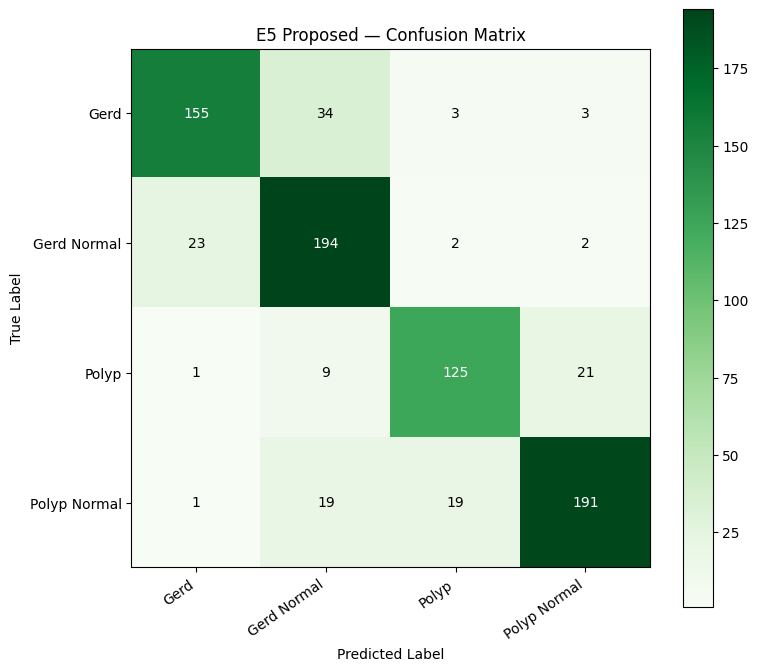

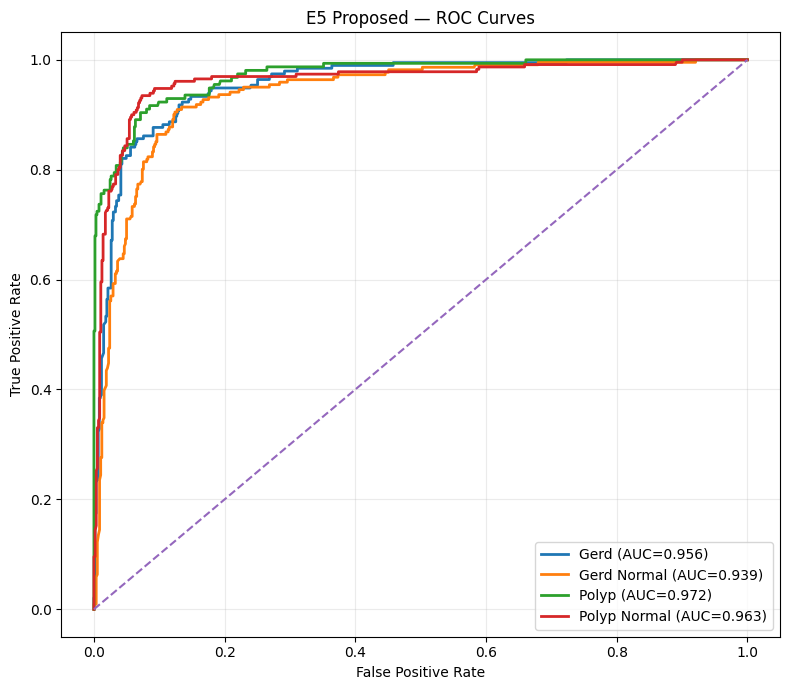

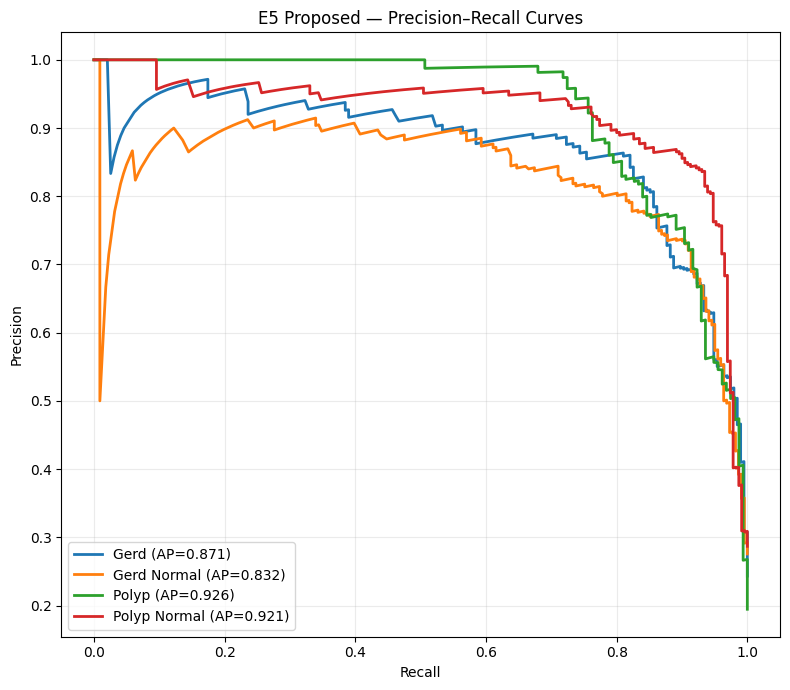

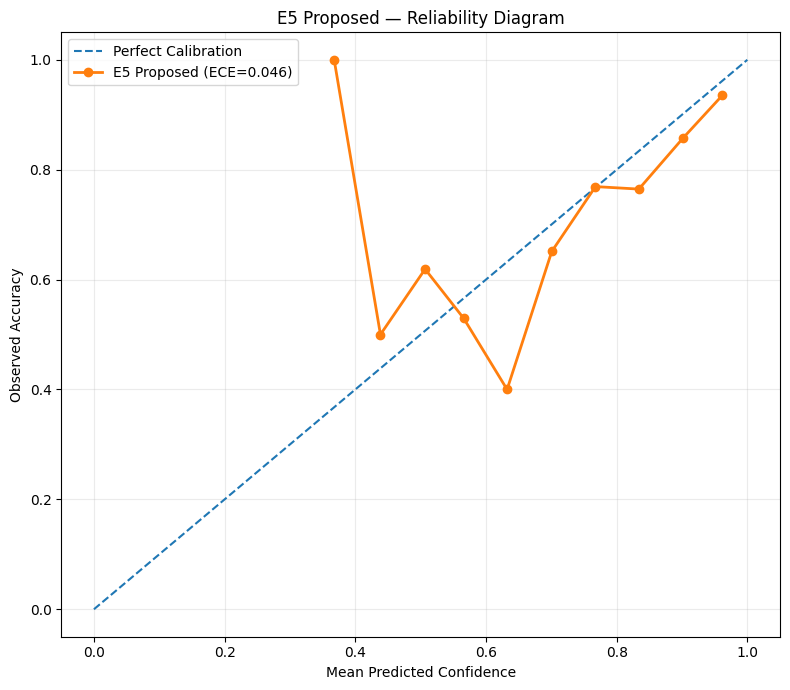


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Gerd     0.8611    0.7949    0.8267       195
 Gerd Normal     0.7578    0.8778    0.8134       221
       Polyp     0.8389    0.8013    0.8197       156
Polyp Normal     0.8802    0.8304    0.8546       230

    accuracy                         0.8292       802
   macro avg     0.8345    0.8261    0.8286       802
weighted avg     0.8338    0.8292    0.8297       802


LOADING E0 → E5 RESULTS
✓ E0 Real Only
✓ E1 Conventional Aug
✓ E2 MixUp/CutMix
✓ E3 Unfiltered Diffusion
✓ E4 Fidelity Filtered
✓ E5a Hard Curriculum
✓ E5 Proposed Weighted Mix

E0 / E1 / E2 / E3 / E4 / E5a / E5 — LOCKED TEST COMPARISON
           Metric  E0 Real Only  E1 Conventional Aug  E2 MixUp/CutMix  E3 Unfiltered Diffusion  E4 Fidelity Filtered  E5a Hard Curriculum  E5 Proposed Weighted Mix  E5 - E0  E5 - E2  E5 - E4  E5 - E5a
         Accuracy        0.8092               0.8217           0.8279                   0.8117         

In [ ]:
# ============================================================
# E5 FINAL PROPOSED METHOD — LOCKED TEST EVALUATION
#
# Proposed E5:
# Continuous Fidelity-Weighted Synthetic Curriculum
# + MixUp / CutMix
#
# ALSO CREATES:
# E0 / E1 / E2 / E3 / E4 / E5a / E5 master comparison
# ============================================================

import json
import time
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

E5_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E5_ProposedFidelityWeightedMix"
)

RESULT_DIR = E5_DIR / "results"

CHECKPOINT_DIR = E5_DIR / "checkpoints"

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_resnet50_e5_proposed.pth"
)

E5_METRIC_PATH = (
    RESULT_DIR /
    "E5_final_test_metrics.json"
)

TEST_CSV = (
    PROJECT_DIR /
    "splits" /
    "test.csv"
)


print("=" * 105)
print("E5 PROPOSED — LOCKED TEST EVALUATION")
print("FIDELITY-WEIGHTED SYNTHETIC CURRICULUM + MIXUP/CUTMIX")
print("=" * 105)

print(
    "\nCheckpoint:",
    BEST_MODEL_PATH
)

if not BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        f"Best E5 proposed checkpoint missing:\n"
        f"{BEST_MODEL_PATH}"
    )


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

AMP_ENABLED = (
    torch.cuda.is_available()
)

print(
    "Device:",
    device
)

print(
    "AMP enabled:",
    AMP_ENABLED
)


# ============================================================
# 3. LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

CLASS_NAMES = checkpoint[
    "class_names"
]

CLASS_TO_IDX = checkpoint.get(
    "class_to_idx",
    {
        cls: i
        for i, cls
        in enumerate(CLASS_NAMES)
    }
)

NUM_CLASSES = len(
    CLASS_NAMES
)

IMAGE_SIZE = int(
    checkpoint.get(
        "image_size",
        384
    )
)

BATCH_SIZE = int(
    checkpoint.get(
        "batch_size",
        16
    )
)

best_epoch = checkpoint.get(
    "epoch",
    None
)

best_val_macro_f1 = checkpoint.get(
    "best_val_macro_f1",
    None
)


print("\nBest checkpoint:")
print(
    "Epoch                 :",
    best_epoch
)

print(
    "Validation Macro-F1   :",
    f"{best_val_macro_f1:.6f}"
)


# ============================================================
# 4. REBUILD MODEL FROM CHECKPOINT
# ============================================================

model = models.resnet50(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model = model.to(
    device
)

model.eval()

print(
    "✓ Proposed E5 model restored."
)


# ============================================================
# 5. REBUILD LOCKED TEST SET
# ============================================================

test_df = pd.read_csv(
    TEST_CSV
)

assert len(test_df) == 802, (
    f"Expected 802 test images, "
    f"found {len(test_df)}."
)


# ============================================================
# 6. INDEX ORIGINAL REAL IMAGES
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}

print(
    "\nIndexing original images..."
)

all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower() in IMG_EXTS
    )
]

filename_index = defaultdict(list)

for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


def normalize_text(x):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower().strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = filename_index.get(
        filename,
        []
    )

    if len(candidates) == 1:

        return str(
            candidates[0]
        )

    if len(candidates) == 0:

        return None

    class_norm = normalize_text(
        class_name
    )

    matches = [

        p

        for p in candidates

        if class_norm in normalize_text(
            str(p.parent)
        )
    ]

    if len(matches) == 1:

        return str(
            matches[0]
        )

    return None


test_df[
    "image_path"
] = test_df.apply(

    lambda row:
        resolve_real_image(
            row["filename"],
            row["class_name"]
        ),

    axis=1
)


missing_test = int(
    test_df[
        "image_path"
    ].isna().sum()
)

print(
    "Unresolved test images:",
    missing_test
)

if missing_test > 0:

    raise RuntimeError(
        "Locked test path resolution failed."
    )


# ============================================================
# 7. TEST TRANSFORM
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h - top
        )

        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


TEST_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 8. TEST DATASET
# ============================================================

class TestDataset(Dataset):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]

        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )

        image = TEST_TRANSFORM(
            image
        )

        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]

        return (
            image,
            label
        )


e5_test_dataset = TestDataset(
    test_df
)


e5_test_loader = DataLoader(

    e5_test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    drop_last=False
)


print(
    "\n✓ Locked REAL test set:",
    len(e5_test_dataset)
)


# ============================================================
# 9. CALIBRATION FUNCTIONS
# ============================================================

def multiclass_brier_score(
    y_true,
    y_prob,
    n_classes
):

    one_hot = np.eye(
        n_classes
    )[y_true]

    return float(
        np.mean(
            np.sum(
                (
                    y_prob
                    -
                    one_hot
                ) ** 2,
                axis=1
            )
        )
    )


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
):

    confidence = np.max(
        y_prob,
        axis=1
    )

    prediction = np.argmax(
        y_prob,
        axis=1
    )

    correct = (
        prediction
        ==
        y_true
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0


    for i in range(
        n_bins
    ):

        lower = edges[i]
        upper = edges[i + 1]

        if i == 0:

            mask = (
                (confidence >= lower)
                &
                (confidence <= upper)
            )

        else:

            mask = (
                (confidence > lower)
                &
                (confidence <= upper)
            )

        if mask.sum() == 0:

            continue

        accuracy_bin = (
            correct[
                mask
            ].mean()
        )

        confidence_bin = (
            confidence[
                mask
            ].mean()
        )

        weight = (
            mask.sum()
            /
            len(y_true)
        )

        ece += (

            weight

            *

            abs(
                accuracy_bin
                -
                confidence_bin
            )
        )


    return float(
        ece
    )


# ============================================================
# 10. LOCKED TEST INFERENCE
# ============================================================

all_targets = []
all_predictions = []
all_probabilities = []

total_inference_time = 0.0


print("\n" + "=" * 105)
print("RUNNING LOCKED 802-IMAGE TEST")
print("=" * 105)


with torch.no_grad():

    for images, labels in e5_test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        if torch.cuda.is_available():
            torch.cuda.synchronize()


        start = time.perf_counter()


        with torch.amp.autocast(

            device_type=(
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            ),

            enabled=(
                AMP_ENABLED
                and
                torch.cuda.is_available()
            )
        ):

            logits = model(
                images
            )


        if torch.cuda.is_available():
            torch.cuda.synchronize()


        total_inference_time += (
            time.perf_counter()
            -
            start
        )


        probabilities = torch.softmax(
            logits,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )


        all_targets.extend(
            labels
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            predictions
            .cpu()
            .numpy()
        )

        all_probabilities.extend(
            probabilities
            .cpu()
            .numpy()
        )


y_true = np.asarray(
    all_targets
)

y_pred = np.asarray(
    all_predictions
)

y_prob = np.asarray(
    all_probabilities
)


assert len(y_true) == 802


# ============================================================
# 11. OVERALL METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)


# ============================================================
# 12. AUROC / AUPRC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(
        NUM_CLASSES
    )
)

macro_auroc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = average_precision_score(
    y_true_bin,
    y_prob,
    average="macro"
)


# ============================================================
# 13. CALIBRATION
# ============================================================

brier = multiclass_brier_score(
    y_true,
    y_prob,
    NUM_CLASSES
)

ece = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
)

nll = log_loss(
    y_true,
    y_prob,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 15. PER-CLASS METRICS
# ============================================================

per_class_results = []


for i, class_name in enumerate(
    CLASS_NAMES
):

    TP = cm[i, i]

    FN = (
        cm[i, :].sum()
        -
        TP
    )

    FP = (
        cm[:, i].sum()
        -
        TP
    )

    TN = (
        cm.sum()
        -
        TP
        -
        FN
        -
        FP
    )

    sensitivity = (
        TP / (TP + FN)
        if TP + FN
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP
        else 0
    )

    ppv = (
        TP / (TP + FP)
        if TP + FP
        else 0
    )

    npv = (
        TN / (TN + FN)
        if TN + FN
        else 0
    )


    class_f1 = f1_score(

        (
            y_true == i
        ).astype(int),

        (
            y_pred == i
        ).astype(int),

        zero_division=0
    )


    class_auc = roc_auc_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )


    class_auprc = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )


    per_class_results.append({

        "Class":
            class_name,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "PPV":
            ppv,

        "NPV":
            npv,

        "F1":
            class_f1,

        "AUROC":
            class_auc,

        "AUPRC":
            class_auprc
    })


per_class_df = pd.DataFrame(
    per_class_results
)


# ============================================================
# 16. INFERENCE SPEED
# ============================================================

latency_ms = (
    total_inference_time
    /
    len(y_true)
    *
    1000
)

throughput = (
    len(y_true)
    /
    total_inference_time
)


# ============================================================
# 17. PRINT RESULTS
# ============================================================

print("\n" + "=" * 105)
print("E5 PROPOSED — LOCKED TEST PERFORMANCE")
print("=" * 105)

print(f"Accuracy             : {accuracy:.4f}")
print(f"Balanced Accuracy    : {balanced_acc:.4f}")

print(f"Macro Precision      : {macro_precision:.4f}")
print(f"Macro Recall         : {macro_recall:.4f}")
print(f"Macro F1             : {macro_f1:.4f}")
print(f"Weighted F1          : {weighted_f1:.4f}")

print(f"MCC                  : {mcc:.4f}")
print(f"Cohen's Kappa        : {kappa:.4f}")

print(f"Macro AUROC          : {macro_auroc:.4f}")
print(f"Macro AUPRC          : {macro_auprc:.4f}")

print(f"Brier Score          : {brier:.4f}")
print(f"ECE                  : {ece:.4f}")
print(f"NLL                  : {nll:.4f}")

print(f"Inference latency    : {latency_ms:.3f} ms/image")
print(f"Throughput           : {throughput:.2f} images/sec")


print("\n" + "=" * 105)
print("PER-CLASS RESULTS")
print("=" * 105)

print(
    per_class_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 18. SAVE FINAL METRICS
# ============================================================

e5_metrics = {

    "experiment":
        "E5_ProposedFidelityWeightedMix",

    "training_strategy":
        (
            "Continuous fidelity-weighted synthetic "
            "curriculum + MixUp/CutMix"
        ),

    "real_train_images":
        2803,

    "filtered_synthetic_images":
        2103,

    "total_train_images":
        4906,

    "test_images":
        802,

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_acc),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_f1":
        float(macro_f1),

    "weighted_f1":
        float(weighted_f1),

    "mcc":
        float(mcc),

    "cohen_kappa":
        float(kappa),

    "macro_auroc":
        float(macro_auroc),

    "macro_auprc":
        float(macro_auprc),

    "brier_score":
        float(brier),

    "ece":
        float(ece),

    "nll":
        float(nll),

    "latency_ms_per_image":
        float(latency_ms),

    "throughput_images_per_second":
        float(throughput),

    "best_epoch":
        int(best_epoch),

    "best_validation_macro_f1":
        float(best_val_macro_f1),

    "fidelity_weighted":
        True,

    "mixup_cutmix":
        True
}


with open(
    E5_METRIC_PATH,
    "w"
) as f:

    json.dump(
        e5_metrics,
        f,
        indent=4
    )


per_class_df.to_csv(
    RESULT_DIR /
    "E5_per_class_metrics.csv",
    index=False
)


# ============================================================
# 19. SAVE TEST PREDICTIONS
# ============================================================

prediction_df = (
    test_df
    .copy()
    .reset_index(
        drop=True
    )
)


prediction_df[
    "true_id"
] = y_true

prediction_df[
    "predicted_id"
] = y_pred


prediction_df[
    "true_class"
] = [
    CLASS_NAMES[i]
    for i in y_true
]


prediction_df[
    "predicted_class"
] = [
    CLASS_NAMES[i]
    for i in y_pred
]


prediction_df[
    "correct"
] = (
    y_true
    ==
    y_pred
)


prediction_df[
    "confidence"
] = np.max(
    y_prob,
    axis=1
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    safe_name = (
        class_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )

    prediction_df[
        f"prob_{safe_name}"
    ] = y_prob[:, i]


prediction_df.to_csv(
    RESULT_DIR /
    "E5_test_predictions.csv",
    index=False
)


# ============================================================
# 20. CONFUSION MATRIX — GREENS
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    cmap="Greens",
    interpolation="nearest"
)

plt.title(
    "E5 Proposed — Confusion Matrix"
)

plt.colorbar()


ticks = np.arange(
    NUM_CLASSES
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    ticks,
    CLASS_NAMES
)


threshold = (
    cm.max()
    /
    2
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            str(
                cm[i, j]
            ),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


plt.ylabel(
    "True Label"
)

plt.xlabel(
    "Predicted Label"
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E5_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. ROC
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={roc_auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "E5 Proposed — ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E5_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. PRECISION–RECALL
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_true_bin[:, i],
            y_prob[:, i]
        )
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP={ap:.3f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "E5 Proposed — Precision–Recall Curves"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E5_PR_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 23. RELIABILITY DIAGRAM
# ============================================================

confidence = np.max(
    y_prob,
    axis=1
)

correctness = (
    y_pred == y_true
).astype(float)

edges = np.linspace(
    0,
    1,
    16
)

bin_acc = []
bin_conf = []


for i in range(15):

    lower = edges[i]
    upper = edges[i + 1]

    mask = (
        (confidence > lower)
        &
        (confidence <= upper)
    )

    if mask.sum() > 0:

        bin_acc.append(
            correctness[
                mask
            ].mean()
        )

        bin_conf.append(
            confidence[
                mask
            ].mean()
        )


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_conf,
    bin_acc,
    marker="o",
    linewidth=2,
    label=(
        f"E5 Proposed "
        f"(ECE={ece:.3f})"
    )
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "E5 Proposed — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(
    RESULT_DIR /
    "E5_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 105)
print("CLASSIFICATION REPORT")
print("=" * 105)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=
            CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 25. LOAD ALL EXPERIMENT RESULTS
# ============================================================

metric_paths = {

    "E0 Real Only":

        PROJECT_DIR /
        "experiments" /
        "E0_ResNet50_RealOnly" /
        "results" /
        "E0_final_test_metrics.json",

    "E1 Conventional Aug":

        PROJECT_DIR /
        "experiments" /
        "E1_ResNet50_ConventionalAug" /
        "results" /
        "E1_final_test_metrics.json",

    "E2 MixUp/CutMix":

        PROJECT_DIR /
        "experiments" /
        "E2_ResNet50_MixUpCutMix" /
        "results" /
        "E2_final_test_metrics.json",

    "E3 Unfiltered Diffusion":

        PROJECT_DIR /
        "experiments" /
        "E3_Diffusion_Unfiltered" /
        "results" /
        "E3_final_test_metrics.json",

    "E4 Fidelity Filtered":

        PROJECT_DIR /
        "experiments" /
        "E4_Diffusion_FidelityFiltered" /
        "results" /
        "E4_final_test_metrics.json",

    # Previous staged curriculum = ablation
    "E5a Hard Curriculum":

        PROJECT_DIR /
        "experiments" /
        "E5_FilteredSyntheticCurriculum" /
        "results" /
        "E5_final_test_metrics.json",

    # Final proposed E5
    "E5 Proposed Weighted Mix":

        E5_METRIC_PATH
}


loaded = {}


print("\n" + "=" * 110)
print("LOADING E0 → E5 RESULTS")
print("=" * 110)


for name, path in metric_paths.items():

    if path.exists():

        with open(
            path,
            "r"
        ) as f:

            loaded[
                name
            ] = json.load(
                f
            )

        print(
            "✓",
            name
        )

    else:

        print(
            "✗ Missing:",
            name
        )


# ============================================================
# 26. MASTER TABLE
# ============================================================

metrics_to_compare = {

    "Accuracy":
        "accuracy",

    "Balanced Accuracy":
        "balanced_accuracy",

    "Macro Precision":
        "macro_precision",

    "Macro Recall":
        "macro_recall",

    "Macro F1":
        "macro_f1",

    "Weighted F1":
        "weighted_f1",

    "MCC":
        "mcc",

    "Cohen's Kappa":
        "cohen_kappa",

    "Macro AUROC":
        "macro_auroc",

    "Macro AUPRC":
        "macro_auprc",

    "Brier Score":
        "brier_score",

    "ECE":
        "ece",

    "NLL":
        "nll"
}


comparison_rows = []


for metric_name, key in (
    metrics_to_compare.items()
):

    row = {
        "Metric":
            metric_name
    }

    for experiment_name in (
        metric_paths.keys()
    ):

        data = loaded.get(
            experiment_name
        )

        row[
            experiment_name
        ] = (
            data.get(
                key,
                np.nan
            )
            if data
            else np.nan
        )

    comparison_rows.append(
        row
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


# ============================================================
# 27. IMPORTANT DIFFERENCES
# ============================================================

comparison_df[
    "E5 - E0"
] = (

    comparison_df[
        "E5 Proposed Weighted Mix"
    ]

    -

    comparison_df[
        "E0 Real Only"
    ]
)


comparison_df[
    "E5 - E2"
] = (

    comparison_df[
        "E5 Proposed Weighted Mix"
    ]

    -

    comparison_df[
        "E2 MixUp/CutMix"
    ]
)


comparison_df[
    "E5 - E4"
] = (

    comparison_df[
        "E5 Proposed Weighted Mix"
    ]

    -

    comparison_df[
        "E4 Fidelity Filtered"
    ]
)


comparison_df[
    "E5 - E5a"
] = (

    comparison_df[
        "E5 Proposed Weighted Mix"
    ]

    -

    comparison_df[
        "E5a Hard Curriculum"
    ]
)


MASTER_PATH = (
    RESULT_DIR /
    "E0_E1_E2_E3_E4_E5a_E5_master_comparison.csv"
)


comparison_df.to_csv(
    MASTER_PATH,
    index=False
)


print("\n" + "=" * 150)
print("E0 / E1 / E2 / E3 / E4 / E5a / E5 — LOCKED TEST COMPARISON")
print("=" * 150)

print(
    comparison_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 28. PROPOSED E5 vs E2
# ============================================================

if (
    "E2 MixUp/CutMix"
    in loaded
):

    e2 = loaded[
        "E2 MixUp/CutMix"
    ]

    print("\n" + "=" * 100)
    print("E2 STRONG BASELINE → PROPOSED E5")
    print("=" * 100)


    for name, key in [

        ("Accuracy", "accuracy"),
        ("Balanced Accuracy", "balanced_accuracy"),
        ("Macro F1", "macro_f1"),
        ("Weighted F1", "weighted_f1"),
        ("MCC", "mcc"),
        ("Macro AUROC", "macro_auroc"),
        ("Macro AUPRC", "macro_auprc")

    ]:

        delta = (
            e5_metrics[key]
            -
            e2[key]
        )

        print(
            f"{name:<22}: "
            f"{e2[key]:.4f} "
            f"→ "
            f"{e5_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


    print(
        "\nCalibration/error — lower is better"
    )

    for name, key in [

        ("Brier Score", "brier_score"),
        ("ECE", "ece"),
        ("NLL", "nll")

    ]:

        delta = (
            e5_metrics[key]
            -
            e2[key]
        )

        print(
            f"{name:<22}: "
            f"{e2[key]:.4f} "
            f"→ "
            f"{e5_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


# ============================================================
# 29. PROPOSED E5 vs E4
# ============================================================

if (
    "E4 Fidelity Filtered"
    in loaded
):

    e4 = loaded[
        "E4 Fidelity Filtered"
    ]

    print("\n" + "=" * 100)
    print("E4 → PROPOSED E5 EFFECT")
    print("=" * 100)


    for name, key in [

        ("Accuracy", "accuracy"),
        ("Balanced Accuracy", "balanced_accuracy"),
        ("Macro F1", "macro_f1"),
        ("MCC", "mcc"),
        ("Macro AUROC", "macro_auroc"),
        ("Macro AUPRC", "macro_auprc")

    ]:

        delta = (
            e5_metrics[key]
            -
            e4[key]
        )

        print(
            f"{name:<22}: "
            f"{e4[key]:.4f} "
            f"→ "
            f"{e5_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


# ============================================================
# 30. HARD CURRICULUM ABLATION vs PROPOSED
# ============================================================

if (
    "E5a Hard Curriculum"
    in loaded
):

    e5a = loaded[
        "E5a Hard Curriculum"
    ]

    print("\n" + "=" * 100)
    print("E5a HARD-STAGE ABLATION → FINAL PROPOSED E5")
    print("=" * 100)


    for name, key in [

        ("Accuracy", "accuracy"),
        ("Balanced Accuracy", "balanced_accuracy"),
        ("Macro F1", "macro_f1"),
        ("MCC", "mcc"),
        ("Macro AUROC", "macro_auroc"),
        ("Macro AUPRC", "macro_auprc")

    ]:

        delta = (
            e5_metrics[key]
            -
            e5a[key]
        )

        print(
            f"{name:<22}: "
            f"{e5a[key]:.4f} "
            f"→ "
            f"{e5_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


# ============================================================
# 31. FINAL
# ============================================================

print("\n" + "=" * 105)
print("FINAL PROPOSED E5 EVALUATION COMPLETE")
print("=" * 105)

print("✓ Locked 802-image REAL test evaluated")
print("✓ Green confusion matrix saved")
print("✓ ROC curves saved")
print("✓ PR curves saved")
print("✓ Reliability diagram saved")
print("✓ Per-class metrics saved")
print("✓ Test predictions saved")

print("✓ Previous hard-stage E5 retained as ablation")
print("✓ E0 → final E5 master comparison created")

print("\nSaved:")
print(
    "Metrics:",
    E5_METRIC_PATH
)

print(
    "Master:",
    MASTER_PATH
)

print("=" * 105)

# E6 = E5 + anatomy-conditioned dual experts

In [3]:
# ============================================================
# GI-SAFE — E6
# ANATOMY-CONDITIONED DUAL EXPERTS
#
# E6 = E5 Proposed +
#      Upper-GI / Lower-GI anatomy-conditioned experts
#
# EVERYTHING FROM E5 IS FROZEN:
#   ✓ 2803 real
#   ✓ 2103 fidelity-filtered synthetic
#   ✓ continuous fidelity weighting
#   ✓ synthetic ramp 0.20 → 1.00
#   ✓ MixUp 0.40 / CutMix 0.40 / Plain 0.20
#   ✓ same optimizer / LR / scheduler
#   ✓ same 401 REAL validation
#   ✓ same 802 REAL test
#
# ONLY MAJOR CHANGE:
#   ResNet50 classifier →
#   shared ResNet50 + anatomy router + dual experts
# ============================================================

import gc
import copy
import json
import time
import random
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score
)

from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 0. MEMORY CLEANUP
# ============================================================

if "model" in globals():
    try:
        del model
    except:
        pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

DEVICE = device

print("=" * 105)
print("GI-SAFE E6 — ANATOMY-CONDITIONED DUAL EXPERTS")
print("=" * 105)

print("Device :", device)

if torch.cuda.is_available():
    print(
        "GPU    :",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# 3. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

SPLIT_DIR = (
    PROJECT_DIR /
    "splits"
)

# Exact training pool used by FINAL E5
E5_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E5_ProposedFidelityWeightedMix"
)

E5_TRAIN_MANIFEST = (
    E5_DIR /
    "manifests" /
    "E5_weighted_training_manifest.csv"
)

# E6
E6_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E6_AnatomyDualExperts"
)

MANIFEST_DIR = (
    E6_DIR /
    "manifests"
)

RESULT_DIR = (
    E6_DIR /
    "results"
)

CHECKPOINT_DIR = (
    E6_DIR /
    "checkpoints"
)

for folder in [
    MANIFEST_DIR,
    RESULT_DIR,
    CHECKPOINT_DIR
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


VAL_CSV = (
    SPLIT_DIR /
    "val.csv"
)

TEST_CSV = (
    SPLIT_DIR /
    "test.csv"
)


BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_anatomy_dual_expert_e6.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_anatomy_dual_expert_e6.pth"
)

HISTORY_PATH = (
    RESULT_DIR /
    "E6_training_history.csv"
)

SUMMARY_PATH = (
    RESULT_DIR /
    "E6_training_summary.json"
)

CONFIG_PATH = (
    MANIFEST_DIR /
    "E6_architecture_config.json"
)


# ============================================================
# 4. LOCKED E5 TRAINING SETTINGS
# ============================================================

IMAGE_SIZE = 384
BATCH_SIZE = 16

NUM_EPOCHS = 30

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


# E5 synthetic curriculum
RAMP_START = 0.20
RAMP_END = 1.00
RAMP_EPOCHS = 8

SYNTH_MIN_FIDELITY_WEIGHT = 0.50
SYNTH_MAX_FIDELITY_WEIGHT = 1.00


# E5 MixUp / CutMix
MIXUP_ALPHA = 0.4
CUTMIX_ALPHA = 1.0

MIXUP_PROB = 0.40
CUTMIX_PROB = 0.40
PLAIN_PROB = 0.20


# ============================================================
# 5. E6-SPECIFIC LOSS WEIGHTS
# ============================================================
#
# Total:
#
# L =
#   L_fused_classification
#   + α L_anatomy_router
#   + β L_expert_specialization
#
# Moderate auxiliary weights so classification remains primary.
# ============================================================

ROUTER_LOSS_WEIGHT = 0.25
EXPERT_LOSS_WEIGHT = 0.25

ROUTER_DROPOUT = 0.20
EXPERT_DROPOUT = 0.20


# ============================================================
# 6. LOAD EXACT E5 TRAINING POOL
# ============================================================

if not E5_TRAIN_MANIFEST.exists():

    raise FileNotFoundError(
        f"E5 training manifest missing:\n"
        f"{E5_TRAIN_MANIFEST}"
    )


train_df = pd.read_csv(
    E5_TRAIN_MANIFEST
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)


print("\n" + "=" * 105)
print("E6 DATA")
print("=" * 105)

print(
    "Training pool:",
    len(train_df)
)

print(
    train_df[
        "source_type"
    ].value_counts()
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test      :",
    len(test_df)
)


assert len(train_df) == 4906
assert len(val_df) == 401
assert len(test_df) == 802


required_train_cols = [
    "image_path",
    "class_name",
    "source_type",
    "fidelity_percentile"
]

missing_cols = [
    c
    for c in required_train_cols
    if c not in train_df.columns
]

if missing_cols:

    raise RuntimeError(
        f"E5 manifest missing columns: {missing_cols}"
    )


# ============================================================
# 7. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(
    train_df[
        "class_name"
    ]
    .astype(str)
    .unique()
)

NUM_CLASSES = len(
    CLASS_NAMES
)

CLASS_TO_IDX = {
    cls: idx
    for idx, cls
    in enumerate(CLASS_NAMES)
}


print("\n" + "=" * 105)
print("CLASS MAPPING")
print("=" * 105)

for cls, idx in CLASS_TO_IDX.items():

    print(
        f"{idx:02d} → {cls}"
    )


# ============================================================
# 8. ANATOMY MAPPING
#
# 0 = Upper GI
# 1 = Lower GI
# ============================================================

UPPER_GI = 0
LOWER_GI = 1

ANATOMY_NAMES = [
    "Upper-GI",
    "Lower-GI"
]


def class_to_anatomy(
    class_name
):

    name = str(
        class_name
    ).lower()

    if "gerd" in name:

        return UPPER_GI

    if "polyp" in name:

        return LOWER_GI

    raise ValueError(
        f"Cannot assign anatomy for class: {class_name}"
    )


CLASS_TO_ANATOMY = {

    CLASS_TO_IDX[
        cls
    ]:
        class_to_anatomy(
            cls
        )

    for cls in CLASS_NAMES
}


print("\n" + "=" * 105)
print("ANATOMY SUPERVISION")
print("=" * 105)

for cls in CLASS_NAMES:

    class_idx = CLASS_TO_IDX[
        cls
    ]

    anatomy_idx = CLASS_TO_ANATOMY[
        class_idx
    ]

    print(
        f"{cls:<25} → "
        f"{ANATOMY_NAMES[anatomy_idx]}"
    )


# Tensor lookup:
# class ID → anatomy ID

CLASS_ID_TO_ANATOMY = torch.tensor(
    [
        CLASS_TO_ANATOMY[i]
        for i in range(
            NUM_CLASSES
        )
    ],
    dtype=torch.long,
    device=device
)


# ============================================================
# 9. INDEX ORIGINAL REAL DATA
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("\nIndexing original images...")


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower() in IMG_EXTS
    )
]


filename_index = defaultdict(list)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


def normalize_text(
    x
):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower().strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = filename_index.get(
        filename,
        []
    )

    if len(candidates) == 1:

        return str(
            candidates[0]
        )

    if len(candidates) == 0:

        return None

    class_norm = normalize_text(
        class_name
    )

    matches = [

        p

        for p in candidates

        if class_norm in normalize_text(
            str(p.parent)
        )
    ]

    if len(matches) == 1:

        return str(
            matches[0]
        )

    return None


# ============================================================
# 10. RESOLVE VAL / TEST PATHS
# ============================================================

for df in [
    val_df,
    test_df
]:

    df[
        "image_path"
    ] = df.apply(

        lambda row:
            resolve_real_image(
                row["filename"],
                row["class_name"]
            ),

        axis=1
    )


print(
    "\nValidation missing:",
    val_df[
        "image_path"
    ].isna().sum()
)

print(
    "Test missing      :",
    test_df[
        "image_path"
    ].isna().sum()
)


if (
    val_df["image_path"].isna().any()
    or
    test_df["image_path"].isna().any()
):

    raise RuntimeError(
        "Validation/test path resolution failed."
    )


# ============================================================
# 11. VERIFY TRAIN FILES
# ============================================================

missing_train = int(

    (
        ~train_df[
            "image_path"
        ].apply(
            lambda x:
                Path(
                    str(x)
                ).exists()
        )
    ).sum()
)


print(
    "Training missing  :",
    missing_train
)


if missing_train > 0:

    raise RuntimeError(
        "E5 training pool contains missing files."
    )


# ============================================================
# 12. PREPROCESSING
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h - top
        )

        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


BASE_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 13. TRAIN DATASET
# ============================================================

class E6TrainDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        class_id = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy_id = CLASS_TO_ANATOMY[
            class_id
        ]


        is_synthetic = (

            1.0

            if str(
                row[
                    "source_type"
                ]
            ) == "synthetic"

            else 0.0
        )


        fidelity = float(
            row[
                "fidelity_percentile"
            ]
        )


        return (

            image,

            class_id,

            anatomy_id,

            torch.tensor(
                is_synthetic,
                dtype=torch.float32
            ),

            torch.tensor(
                fidelity,
                dtype=torch.float32
            )
        )


# ============================================================
# 14. EVAL DATASET
# ============================================================

class E6EvalDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        class_id = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy_id = CLASS_TO_ANATOMY[
            class_id
        ]


        return (
            image,
            class_id,
            anatomy_id
        )


# ============================================================
# 15. DATA LOADERS
# ============================================================

train_dataset = E6TrainDataset(
    train_df
)

val_dataset = E6EvalDataset(
    val_df
)

test_dataset = E6EvalDataset(
    test_df
)


loader_generator = (
    torch.Generator()
)

loader_generator.manual_seed(
    SEED
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=True,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False,

    generator=
        loader_generator
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False
)


# Prepared now for E6 final evaluation
e6_test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=
        NUM_WORKERS,

    pin_memory=True,

    drop_last=False
)


print("\nLoaders:")
print(
    "Train:",
    len(train_dataset)
)

print(
    "Val  :",
    len(val_dataset)
)

print(
    "Test :",
    len(test_dataset)
)


# ============================================================
# 16. CLASS WEIGHTS — SAME E5 POOL
# ============================================================

train_class_ids = (

    train_df[
        "class_name"
    ]

    .astype(str)

    .map(
        CLASS_TO_IDX
    )

    .values
)


class_counts = np.bincount(

    train_class_ids,

    minlength=
        NUM_CLASSES
)


class_weights = (

    len(
        train_class_ids
    )

    /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


class_weights_tensor = torch.tensor(

    class_weights,

    dtype=torch.float32,

    device=device
)


print("\nClass weights:")

for i, cls in enumerate(
    CLASS_NAMES
):

    print(
        f"{cls:<25} "
        f"N={class_counts[i]:4d} "
        f"Weight={class_weights[i]:.6f}"
    )


# ============================================================
# 17. ANATOMY-CONDITIONED DUAL EXPERT MODEL
# ============================================================

class AnatomyDualExpertResNet50(
    nn.Module
):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()


        # ----------------------------------------------------
        # PRETRAINED RESNET50
        # ----------------------------------------------------

        base = models.resnet50(
            weights=
                ResNet50_Weights.IMAGENET1K_V2
        )


        # ----------------------------------------------------
        # SHARED REPRESENTATION
        #
        # Stem + layer1 + layer2 + layer3
        #
        # Output channels = 1024
        # ----------------------------------------------------

        self.shared = nn.Sequential(

            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,

            base.layer1,
            base.layer2,
            base.layer3
        )


        # ----------------------------------------------------
        # DUAL ANATOMICAL EXPERTS
        #
        # Each starts from identical pretrained layer4.
        # They then specialize independently.
        #
        # Output channels = 2048
        # ----------------------------------------------------

        self.upper_expert = copy.deepcopy(
            base.layer4
        )

        self.lower_expert = copy.deepcopy(
            base.layer4
        )


        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        # ----------------------------------------------------
        # ANATOMY ROUTER
        #
        # Uses shared layer3 representation.
        # ----------------------------------------------------

        self.router = nn.Sequential(

            nn.Linear(
                1024,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                ROUTER_DROPOUT
            ),

            nn.Linear(
                256,
                2
            )
        )


        # ----------------------------------------------------
        # EXPERT CLASSIFIERS
        #
        # Both predict all 4 classes.
        # Gating determines their contribution.
        # ----------------------------------------------------

        self.upper_classifier = nn.Sequential(

            nn.Dropout(
                EXPERT_DROPOUT
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


        self.lower_classifier = nn.Sequential(

            nn.Dropout(
                EXPERT_DROPOUT
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        # Shared representation
        shared_map = self.shared(
            x
        )


        # Router features
        shared_vec = self.pool(
            shared_map
        )

        shared_vec = torch.flatten(
            shared_vec,
            1
        )


        router_logits = self.router(
            shared_vec
        )


        gates = torch.softmax(
            router_logits,
            dim=1
        )


        # Upper expert
        upper_map = self.upper_expert(
            shared_map
        )

        upper_vec = self.pool(
            upper_map
        )

        upper_vec = torch.flatten(
            upper_vec,
            1
        )

        upper_logits = self.upper_classifier(
            upper_vec
        )


        # Lower expert
        lower_map = self.lower_expert(
            shared_map
        )

        lower_vec = self.pool(
            lower_map
        )

        lower_vec = torch.flatten(
            lower_vec,
            1
        )

        lower_logits = self.lower_classifier(
            lower_vec
        )


        # ----------------------------------------------------
        # SOFT ROUTER-WEIGHTED FUSION
        # ----------------------------------------------------

        fused_logits = (

            gates[:, 0:1]
            *
            upper_logits

            +

            gates[:, 1:2]
            *
            lower_logits
        )


        return {

            "logits":
                fused_logits,

            "router_logits":
                router_logits,

            "gates":
                gates,

            "upper_logits":
                upper_logits,

            "lower_logits":
                lower_logits
        }


# ============================================================
# 18. INITIALIZE MODEL
# ============================================================

model = AnatomyDualExpertResNet50(
    NUM_CLASSES
)

model = model.to(
    device
)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\n" + "=" * 105)
print("E6 MODEL")
print("=" * 105)

print(
    "Architecture        : Shared ResNet50 + Dual Layer4 Experts"
)

print(
    "Shared encoder      : Stem → Layer3"
)

print(
    "Expert 1            : Upper-GI Layer4"
)

print(
    "Expert 2            : Lower-GI Layer4"
)

print(
    "Router              : 1024 → 256 → 2"
)

print(
    "Fusion              : Soft anatomy-gated logits"
)

print(
    f"Parameters          : {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)


# ============================================================
# 19. OPTIMIZER / SCHEDULER
# ============================================================

optimizer = optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY,

    betas=
        (0.9, 0.999),

    eps=
        1e-8
)


scheduler = (
    optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=
            SCHEDULER_FACTOR,

        patience=
            SCHEDULER_PATIENCE
    )
)


# ============================================================
# 20. E5 SYNTHETIC CURRICULUM
# ============================================================

def synthetic_epoch_lambda(
    epoch
):

    if epoch >= RAMP_EPOCHS:

        return RAMP_END


    progress = (

        (epoch - 1)

        /

        (RAMP_EPOCHS - 1)
    )


    return (

        RAMP_START

        +

        progress
        *
        (
            RAMP_END
            -
            RAMP_START
        )
    )


def get_sample_weights(
    is_synthetic,
    fidelity,
    epoch
):

    epoch_lambda = (
        synthetic_epoch_lambda(
            epoch
        )
    )


    fidelity_weight = (

        SYNTH_MIN_FIDELITY_WEIGHT

        +

        fidelity
        *
        (
            SYNTH_MAX_FIDELITY_WEIGHT
            -
            SYNTH_MIN_FIDELITY_WEIGHT
        )
    )


    synthetic_weight = (

        epoch_lambda
        *
        fidelity_weight
    )


    weights = torch.where(

        is_synthetic > 0.5,

        synthetic_weight,

        torch.ones_like(
            synthetic_weight
        )
    )


    return weights


# ============================================================
# 21. LOSS HELPERS
# ============================================================

def class_ce_per_sample(
    logits,
    labels
):

    return F.cross_entropy(

        logits,

        labels,

        weight=
            class_weights_tensor,

        reduction="none"
    )


def anatomy_ce_per_sample(
    router_logits,
    anatomy_labels
):

    return F.cross_entropy(

        router_logits,

        anatomy_labels,

        reduction="none"
    )


# ============================================================
# 22. CUTMIX BOUNDING BOX
# ============================================================

def rand_bbox(
    size,
    lam
):

    W = size[3]
    H = size[2]

    cut_ratio = np.sqrt(
        1.0 - lam
    )

    cut_w = int(
        W * cut_ratio
    )

    cut_h = int(
        H * cut_ratio
    )

    cx = np.random.randint(
        W
    )

    cy = np.random.randint(
        H
    )

    x1 = np.clip(
        cx - cut_w // 2,
        0,
        W
    )

    x2 = np.clip(
        cx + cut_w // 2,
        0,
        W
    )

    y1 = np.clip(
        cy - cut_h // 2,
        0,
        H
    )

    y2 = np.clip(
        cy + cut_h // 2,
        0,
        H
    )

    return (
        x1,
        y1,
        x2,
        y2
    )


# ============================================================
# 23. WEIGHTED MIXED LOSS
# ============================================================

def weighted_pair_loss(
    loss_a,
    loss_b,
    weight_a,
    weight_b,
    lam
):

    numerator = (

        lam
        *
        weight_a
        *
        loss_a

        +

        (
            1.0 - lam
        )
        *
        weight_b
        *
        loss_b
    ).sum()


    denominator = (

        lam
        *
        weight_a

        +

        (
            1.0 - lam
        )
        *
        weight_b
    ).sum()


    return (

        numerator

        /

        denominator.clamp_min(
            1e-8
        )
    )


# ============================================================
# 24. EXPERT SPECIALIZATION LOSS
# ============================================================

def specialization_pair_loss(

    upper_logits,
    lower_logits,

    labels_a,
    labels_b,

    anatomy_a,
    anatomy_b,

    weight_a,
    weight_b,

    lam
):

    upper_a = class_ce_per_sample(
        upper_logits,
        labels_a
    )

    upper_b = class_ce_per_sample(
        upper_logits,
        labels_b
    )

    lower_a = class_ce_per_sample(
        lower_logits,
        labels_a
    )

    lower_b = class_ce_per_sample(
        lower_logits,
        labels_b
    )


    upper_mask_a = (
        anatomy_a
        ==
        UPPER_GI
    ).float()

    upper_mask_b = (
        anatomy_b
        ==
        UPPER_GI
    ).float()


    lower_mask_a = (
        anatomy_a
        ==
        LOWER_GI
    ).float()

    lower_mask_b = (
        anatomy_b
        ==
        LOWER_GI
    ).float()


    numerator = (

        lam
        *
        weight_a
        *
        (
            upper_mask_a
            *
            upper_a

            +

            lower_mask_a
            *
            lower_a
        )

        +

        (
            1.0
            -
            lam
        )
        *
        weight_b
        *
        (
            upper_mask_b
            *
            upper_b

            +

            lower_mask_b
            *
            lower_b
        )
    ).sum()


    denominator = (

        lam
        *
        weight_a

        +

        (
            1.0
            -
            lam
        )
        *
        weight_b
    ).sum()


    return (

        numerator

        /

        denominator.clamp_min(
            1e-8
        )
    )


# ============================================================
# 25. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    epoch
):

    model.train()


    running_total_loss = 0.0
    running_cls_loss = 0.0
    running_router_loss = 0.0
    running_expert_loss = 0.0


    all_true = []
    all_pred = []


    mixup_batches = 0
    cutmix_batches = 0
    plain_batches = 0


    current_synth_lambda = (
        synthetic_epoch_lambda(
            epoch
        )
    )


    for (
        images,
        labels,
        anatomy,
        is_synthetic,
        fidelity
    ) in tqdm(

        train_loader,

        desc="Train",

        leave=False
    ):


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        anatomy = anatomy.to(
            device,
            non_blocking=True
        )

        is_synthetic = is_synthetic.to(
            device,
            non_blocking=True
        )

        fidelity = fidelity.to(
            device,
            non_blocking=True
        )


        sample_weights = (
            get_sample_weights(
                is_synthetic,
                fidelity,
                epoch
            )
        )


        batch_n = (
            images.size(0)
        )


        permutation = torch.randperm(
            batch_n,
            device=device
        )


        labels_b = labels[
            permutation
        ]

        anatomy_b = anatomy[
            permutation
        ]

        weights_b = sample_weights[
            permutation
        ]


        random_value = random.random()


        optimizer.zero_grad(
            set_to_none=True
        )


        # ====================================================
        # MIXUP
        # ====================================================

        if random_value < MIXUP_PROB:

            mixup_batches += 1


            lam = float(
                np.random.beta(
                    MIXUP_ALPHA,
                    MIXUP_ALPHA
                )
            )


            mixed_images = (

                lam
                *
                images

                +

                (
                    1.0 - lam
                )
                *
                images[
                    permutation
                ]
            )


        # ====================================================
        # CUTMIX
        # ====================================================

        elif (
            random_value
            <
            MIXUP_PROB
            +
            CUTMIX_PROB
        ):

            cutmix_batches += 1


            initial_lam = float(
                np.random.beta(
                    CUTMIX_ALPHA,
                    CUTMIX_ALPHA
                )
            )


            (
                x1,
                y1,
                x2,
                y2
            ) = rand_bbox(
                images.size(),
                initial_lam
            )


            mixed_images = images.clone()


            mixed_images[
                :,
                :,
                y1:y2,
                x1:x2
            ] = images[
                permutation,
                :,
                y1:y2,
                x1:x2
            ]


            lam = (

                1.0

                -

                (
                    (x2 - x1)
                    *
                    (y2 - y1)
                )

                /

                (
                    images.size(2)
                    *
                    images.size(3)
                )
            )


        # ====================================================
        # PLAIN
        # ====================================================

        else:

            plain_batches += 1

            lam = 1.0

            mixed_images = images


            labels_b = labels
            anatomy_b = anatomy
            weights_b = sample_weights


        # ====================================================
        # FORWARD
        # ====================================================

        outputs = model(
            mixed_images
        )


        fused_logits = outputs[
            "logits"
        ]

        router_logits = outputs[
            "router_logits"
        ]

        upper_logits = outputs[
            "upper_logits"
        ]

        lower_logits = outputs[
            "lower_logits"
        ]


        # ====================================================
        # 1. FUSED 4-CLASS LOSS
        # ====================================================

        fused_loss_a = class_ce_per_sample(
            fused_logits,
            labels
        )

        fused_loss_b = class_ce_per_sample(
            fused_logits,
            labels_b
        )


        classification_loss = (
            weighted_pair_loss(

                fused_loss_a,
                fused_loss_b,

                sample_weights,
                weights_b,

                lam
            )
        )


        # ====================================================
        # 2. ANATOMY ROUTER LOSS
        # ====================================================

        router_loss_a = anatomy_ce_per_sample(
            router_logits,
            anatomy
        )

        router_loss_b = anatomy_ce_per_sample(
            router_logits,
            anatomy_b
        )


        router_loss = (
            weighted_pair_loss(

                router_loss_a,
                router_loss_b,

                sample_weights,
                weights_b,

                lam
            )
        )


        # ====================================================
        # 3. EXPERT SPECIALIZATION LOSS
        # ====================================================

        expert_loss = (
            specialization_pair_loss(

                upper_logits,
                lower_logits,

                labels,
                labels_b,

                anatomy,
                anatomy_b,

                sample_weights,
                weights_b,

                lam
            )
        )


        # ====================================================
        # TOTAL
        # ====================================================

        total_loss = (

            classification_loss

            +

            ROUTER_LOSS_WEIGHT
            *
            router_loss

            +

            EXPERT_LOSS_WEIGHT
            *
            expert_loss
        )


        total_loss.backward()

        optimizer.step()


        running_total_loss += (
            total_loss.item()
            *
            batch_n
        )

        running_cls_loss += (
            classification_loss.item()
            *
            batch_n
        )

        running_router_loss += (
            router_loss.item()
            *
            batch_n
        )

        running_expert_loss += (
            expert_loss.item()
            *
            batch_n
        )


        predictions = fused_logits.argmax(
            dim=1
        )


        # approximate train metrics under mixing
        all_true.extend(
            labels
            .detach()
            .cpu()
            .numpy()
        )

        all_pred.extend(
            predictions
            .detach()
            .cpu()
            .numpy()
        )


    N = len(
        train_loader.dataset
    )


    return {

        "total_loss":
            running_total_loss / N,

        "classification_loss":
            running_cls_loss / N,

        "router_loss":
            running_router_loss / N,

        "expert_loss":
            running_expert_loss / N,

        "accuracy_approx":
            accuracy_score(
                all_true,
                all_pred
            ),

        "balanced_accuracy_approx":
            balanced_accuracy_score(
                all_true,
                all_pred
            ),

        "macro_f1_approx":
            f1_score(
                all_true,
                all_pred,
                average="macro",
                zero_division=0
            ),

        "synthetic_lambda":
            current_synth_lambda,

        "mixup_batches":
            mixup_batches,

        "cutmix_batches":
            cutmix_batches,

        "plain_batches":
            plain_batches
    }


# ============================================================
# 26. VALIDATION
# ============================================================

@torch.no_grad()
def validate():

    model.eval()


    total_loss = 0.0


    y_true = []
    y_pred = []

    anatomy_true = []
    anatomy_pred = []

    correct_gate_prob = []


    for (
        images,
        labels,
        anatomy
    ) in tqdm(

        val_loader,

        desc="Val",

        leave=False
    ):


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        anatomy = anatomy.to(
            device,
            non_blocking=True
        )


        outputs = model(
            images
        )


        logits = outputs[
            "logits"
        ]

        router_logits = outputs[
            "router_logits"
        ]

        gates = outputs[
            "gates"
        ]


        loss = F.cross_entropy(

            logits,

            labels,

            weight=
                class_weights_tensor
        )


        total_loss += (
            loss.item()
            *
            images.size(0)
        )


        prediction = logits.argmax(
            dim=1
        )

        router_prediction = (
            router_logits.argmax(
                dim=1
            )
        )


        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            prediction.cpu().numpy()
        )


        anatomy_true.extend(
            anatomy.cpu().numpy()
        )

        anatomy_pred.extend(
            router_prediction.cpu().numpy()
        )


        batch_gate_prob = gates[
            torch.arange(
                gates.size(0),
                device=device
            ),
            anatomy
        ]


        correct_gate_prob.extend(
            batch_gate_prob
            .cpu()
            .numpy()
        )


    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(

            y_true,
            y_pred,

            average="macro",

            zero_division=0
        )
    )


    return {

        "loss":
            total_loss
            /
            len(
                val_loader.dataset
            ),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "precision_macro":
            precision,

        "recall_macro":
            recall,

        "macro_f1":
            macro_f1,

        "router_accuracy":
            accuracy_score(
                anatomy_true,
                anatomy_pred
            ),

        "mean_correct_gate_probability":
            float(
                np.mean(
                    correct_gate_prob
                )
            )
    }


# ============================================================
# 27. SAVE CONFIG
# ============================================================

e6_config = {

    "experiment":
        "E6_AnatomyDualExperts",

    "parent_experiment":
        "E5_ProposedFidelityWeightedMix",

    "training_pool":
        str(
            E5_TRAIN_MANIFEST
        ),

    "real_images":
        2803,

    "filtered_synthetic_images":
        2103,

    "total_training_images":
        4906,

    "architecture": {

        "shared_encoder":
            "ResNet50 stem through layer3",

        "upper_gi_expert":
            "independent pretrained ResNet50 layer4",

        "lower_gi_expert":
            "independent pretrained ResNet50 layer4",

        "router":
            "shared pooled feature -> 256 -> 2",

        "fusion":
            "soft anatomy-gated expert logits"
    },

    "anatomy_mapping": {

        "Upper-GI":
            [
                cls
                for cls in CLASS_NAMES
                if class_to_anatomy(cls)
                ==
                UPPER_GI
            ],

        "Lower-GI":
            [
                cls
                for cls in CLASS_NAMES
                if class_to_anatomy(cls)
                ==
                LOWER_GI
            ]
    },

    "router_loss_weight":
        ROUTER_LOSS_WEIGHT,

    "expert_specialization_loss_weight":
        EXPERT_LOSS_WEIGHT,

    "synthetic_curriculum":
        "identical to E5",

    "mixup_cutmix":
        "identical to E5",

    "validation":
        "401 locked real images",

    "test":
        "802 locked real images",

    "test_information_used_for_training":
        False
}


with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        e6_config,
        f,
        indent=2
    )


# ============================================================
# 28. TRAINING LOOP
# ============================================================

history = []

best_val_macro_f1 = -np.inf

best_epoch = 0

epochs_without_improvement = 0


training_start = time.time()


print("\n" + "=" * 105)
print("STARTING E6 TRAINING")
print("=" * 105)


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    epoch_start = (
        time.time()
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    train_metrics = train_one_epoch(
        epoch
    )


    val_metrics = validate()


    scheduler.step(
        val_metrics[
            "macro_f1"
        ]
    )


    epoch_seconds = (
        time.time()
        -
        epoch_start
    )


    record = {

        "epoch":
            epoch,

        "lr":
            current_lr,

        "synthetic_lambda":
            train_metrics[
                "synthetic_lambda"
            ],

        "mixup_batches":
            train_metrics[
                "mixup_batches"
            ],

        "cutmix_batches":
            train_metrics[
                "cutmix_batches"
            ],

        "plain_batches":
            train_metrics[
                "plain_batches"
            ],

        "train_total_loss":
            train_metrics[
                "total_loss"
            ],

        "train_classification_loss":
            train_metrics[
                "classification_loss"
            ],

        "train_router_loss":
            train_metrics[
                "router_loss"
            ],

        "train_expert_loss":
            train_metrics[
                "expert_loss"
            ],

        "train_accuracy_approx":
            train_metrics[
                "accuracy_approx"
            ],

        "train_balanced_accuracy_approx":
            train_metrics[
                "balanced_accuracy_approx"
            ],

        "train_macro_f1_approx":
            train_metrics[
                "macro_f1_approx"
            ],

        "val_loss":
            val_metrics[
                "loss"
            ],

        "val_accuracy":
            val_metrics[
                "accuracy"
            ],

        "val_balanced_accuracy":
            val_metrics[
                "balanced_accuracy"
            ],

        "val_precision_macro":
            val_metrics[
                "precision_macro"
            ],

        "val_recall_macro":
            val_metrics[
                "recall_macro"
            ],

        "val_macro_f1":
            val_metrics[
                "macro_f1"
            ],

        "val_router_accuracy":
            val_metrics[
                "router_accuracy"
            ],

        "val_correct_gate_probability":
            val_metrics[
                "mean_correct_gate_probability"
            ],

        "epoch_seconds":
            epoch_seconds
    }


    history.append(
        record
    )


    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )


    # ========================================================
    # BEST CHECKPOINT
    # ========================================================

    if (
        val_metrics[
            "macro_f1"
        ]
        >
        best_val_macro_f1
    ):

        best_val_macro_f1 = (
            val_metrics[
                "macro_f1"
            ]
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(

            {

                "experiment":
                    "E6_AnatomyDualExperts",

                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "best_val_macro_f1":
                    best_val_macro_f1,

                "best_epoch":
                    best_epoch,

                "epochs_without_improvement":
                    epochs_without_improvement,

                "val_metrics":
                    val_metrics,

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "class_to_anatomy":
                    CLASS_TO_ANATOMY,

                "anatomy_names":
                    ANATOMY_NAMES,

                "image_size":
                    IMAGE_SIZE,

                "batch_size":
                    BATCH_SIZE,

                "seed":
                    SEED,

                "router_loss_weight":
                    ROUTER_LOSS_WEIGHT,

                "expert_loss_weight":
                    EXPERT_LOSS_WEIGHT
            },

            BEST_MODEL_PATH
        )


    else:

        epochs_without_improvement += 1


    # ========================================================
    # LAST CHECKPOINT
    # ========================================================

    torch.save(

        {

            "experiment":
                "E6_AnatomyDualExperts",

            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_val_macro_f1":
                best_val_macro_f1,

            "best_epoch":
                best_epoch,

            "epochs_without_improvement":
                epochs_without_improvement,

            "class_names":
                CLASS_NAMES,

            "class_to_idx":
                CLASS_TO_IDX,

            "class_to_anatomy":
                CLASS_TO_ANATOMY,

            "anatomy_names":
                ANATOMY_NAMES,

            "image_size":
                IMAGE_SIZE,

            "batch_size":
                BATCH_SIZE,

            "seed":
                SEED

        },

        LAST_MODEL_PATH
    )


    new_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    # ========================================================
    # STATUS
    # ========================================================

    print(
        f"\nEpoch {epoch:02d}/{NUM_EPOCHS}"
    )


    print(
        f"Synthetic λ : "
        f"{train_metrics['synthetic_lambda']:.3f}"
    )


    print(
        f"Train Loss  : "
        f"Total={train_metrics['total_loss']:.4f} | "
        f"Cls={train_metrics['classification_loss']:.4f} | "
        f"Router={train_metrics['router_loss']:.4f} | "
        f"Expert={train_metrics['expert_loss']:.4f}"
    )


    print(
        f"Val         : "
        f"Acc={val_metrics['accuracy']:.4f} | "
        f"BalAcc={val_metrics['balanced_accuracy']:.4f} | "
        f"Macro-F1={val_metrics['macro_f1']:.4f}"
    )


    print(
        f"Router      : "
        f"Accuracy={val_metrics['router_accuracy']:.4f} | "
        f"Correct-gate prob="
        f"{val_metrics['mean_correct_gate_probability']:.4f}"
    )


    print(
        f"LR          : "
        f"{current_lr:.2e} "
        f"→ {new_lr:.2e}"
    )


    print(
        f"Best        : "
        f"Epoch {best_epoch} | "
        f"Macro-F1 "
        f"{best_val_macro_f1:.6f}"
    )


    print(
        f"Early stop  : "
        f"{epochs_without_improvement}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )


    print(
        f"Time        : "
        f"{epoch_seconds:.1f} sec"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print(
            "\n✓ Early stopping triggered."
        )

        break


# ============================================================
# 29. TRAINING SUMMARY
# ============================================================

total_training_seconds = (
    time.time()
    -
    training_start
)


peak_gpu_memory_gb = None

if torch.cuda.is_available():

    peak_gpu_memory_gb = (

        torch.cuda
        .max_memory_allocated()

        /
        1024**3
    )


best_history_row = (

    pd.DataFrame(
        history
    )

    .iloc[
        best_epoch - 1
    ]
)


summary = {

    "experiment":
        "E6_AnatomyDualExperts",

    "parent":
        "E5_ProposedFidelityWeightedMix",

    "model":
        "AnatomyConditionedDualExpertResNet50",

    "real_train_images":
        2803,

    "filtered_synthetic_images":
        2103,

    "total_train_images":
        4906,

    "validation_images":
        401,

    "test_images":
        802,

    "epochs_completed":
        len(history),

    "best_epoch":
        int(
            best_epoch
        ),

    "best_val_macro_f1":
        float(
            best_val_macro_f1
        ),

    "best_val_router_accuracy":
        float(
            best_history_row[
                "val_router_accuracy"
            ]
        ),

    "best_val_correct_gate_probability":
        float(
            best_history_row[
                "val_correct_gate_probability"
            ]
        ),

    "router_loss_weight":
        ROUTER_LOSS_WEIGHT,

    "expert_loss_weight":
        EXPERT_LOSS_WEIGHT,

    "total_parameters":
        int(
            total_params
        ),

    "trainable_parameters":
        int(
            trainable_params
        ),

    "total_training_minutes":
        float(
            total_training_seconds
            /
            60
        ),

    "peak_gpu_memory_gb":
        peak_gpu_memory_gb,

    "seed":
        SEED
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ============================================================
# 30. FINAL STATUS
# ============================================================

print("\n" + "=" * 105)
print("E6 ANATOMY-DUAL-EXPERT TRAINING COMPLETE")
print("=" * 105)

print(
    "Training images            : 4906"
)

print(
    "Real                       : 2803"
)

print(
    "Filtered synthetic         : 2103"
)

print(
    "\nEpochs completed          :",
    len(history)
)

print(
    "Best epoch                :",
    best_epoch
)

print(
    "Best validation Macro-F1 :",
    f"{best_val_macro_f1:.6f}"
)

print(
    "Best router accuracy     :",
    f"{best_history_row['val_router_accuracy']:.6f}"
)

print(
    "Best correct gate prob   :",
    f"{best_history_row['val_correct_gate_probability']:.6f}"
)

print(
    "\nParameters               :",
    f"{total_params:,}"
)

print(
    "Training time            :",
    f"{total_training_seconds/60:.2f} min"
)

print(
    "\nBest checkpoint:",
    BEST_MODEL_PATH
)

print(
    "Last checkpoint:",
    LAST_MODEL_PATH
)

print(
    "History:",
    HISTORY_PATH
)

print(
    "Summary:",
    SUMMARY_PATH
)

print(
    "\n✓ E5 data strategy unchanged."
)

print(
    "✓ E5 fidelity weighting unchanged."
)

print(
    "✓ E5 MixUp/CutMix unchanged."
)

print(
    "✓ Only anatomy-conditioned dual-expert architecture added."
)

print(
    "✓ e6_test_loader already prepared."
)

print("=" * 105)

GI-SAFE E6 — ANATOMY-CONDITIONED DUAL EXPERTS
Device : cuda
GPU    : NVIDIA A100-SXM4-40GB

E6 DATA
Training pool: 4906
source_type
real         2803
synthetic    2103
Name: count, dtype: int64
Validation: 401
Test      : 802

CLASS MAPPING
00 → Gerd
01 → Gerd Normal
02 → Polyp
03 → Polyp Normal

ANATOMY SUPERVISION
Gerd                      → Upper-GI
Gerd Normal               → Upper-GI
Polyp                     → Lower-GI
Polyp Normal              → Lower-GI

Indexing original images...

Validation missing: 0
Test missing      : 0
Training missing  : 0

Loaders:
Train: 4906
Val  : 401
Test : 802

Class weights:
Gerd                      N=1192 Weight=1.028943
Gerd Normal               N=1351 Weight=0.907846
Polyp                     N= 954 Weight=1.285639
Polyp Normal              N=1409 Weight=0.870476

E6 MODEL
Architecture        : Shared ResNet50 + Dual Layer4 Experts
Shared encoder      : Stem → Layer3
Expert 1            : Upper-GI Layer4
Expert 2            : Lower-GI Layer4


Train:   0%|          | 0/307 [00:00<?, ?it/s]

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 01/30
Synthetic λ : 0.200
Train Loss  : Total=1.3245 | Cls=1.0181 | Router=0.5032 | Expert=0.7224
Val         : Acc=0.7556 | BalAcc=0.7531 | Macro-F1=0.7546
Router      : Accuracy=0.9252 | Correct-gate prob=0.7606
LR          : 1.00e-04 → 1.00e-04
Best        : Epoch 1 | Macro-F1 0.754631
Early stop  : 0/7
Time        : 1156.5 sec


Train:   0%|          | 0/307 [00:00<?, ?it/s]

...

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 29/30
Synthetic λ : 1.000
Train Loss  : Total=0.4515 | Cls=0.3491 | Router=0.2331 | Expert=0.1766
Val         : Acc=0.8803 | BalAcc=0.8744 | Macro-F1=0.8794
Router      : Accuracy=0.9501 | Correct-gate prob=0.8977
LR          : 6.25e-06 → 6.25e-06
Best        : Epoch 25 | Macro-F1 0.884149
Early stop  : 4/7
Time        : 51.5 sec


Train:   0%|          | 0/307 [00:00<?, ?it/s]

Val:   0%|          | 0/26 [00:00<?, ?it/s]


Epoch 30/30
Synthetic λ : 1.000
Train Loss  : Total=0.4652 | Cls=0.3614 | Router=0.2372 | Expert=0.1782
Val         : Acc=0.8753 | BalAcc=0.8711 | Macro-F1=0.8747
Router      : Accuracy=0.9476 | Correct-gate prob=0.8912
LR          : 6.25e-06 → 6.25e-06
Best        : Epoch 25 | Macro-F1 0.884149
Early stop  : 5/7
Time        : 41.5 sec

E6 ANATOMY-DUAL-EXPERT TRAINING COMPLETE
Training images            : 4906
Real                       : 2803
Filtered synthetic         : 2103

Epochs completed          : 30
Best epoch                : 25
Best validation Macro-F1 : 0.884149
Best router accuracy     : 0.945137
Best correct gate prob   : 0.876432

Parameters               : 38,752,074
Training time            : 52.66 min

Best checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E6_AnatomyDualExperts/checkpoints/best_anatomy_dual_expert_e6.pth
Last checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E6_AnatomyDualExperts/checkpoints/last_anatomy_dual_exper

E6 — LOCKED TEST EVALUATION
ANATOMY-CONDITIONED DUAL EXPERTS

Checkpoint: /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E6_AnatomyDualExperts/checkpoints/best_anatomy_dual_expert_e6.pth
Device: cuda
AMP enabled: True

Best checkpoint:
Epoch               : 25
Best Val Macro-F1   : 0.884149

Anatomy mapping:
Gerd                      → Upper-GI
Gerd Normal               → Upper-GI
Polyp                     → Lower-GI
Polyp Normal              → Lower-GI

✓ E6 model restored.
Parameters: 38,752,074

Indexing original dataset...
Unresolved test images: 0

✓ Locked REAL test images: 802

RUNNING E6 LOCKED TEST

E6 — LOCKED TEST PERFORMANCE
Accuracy             : 0.8292
Balanced Accuracy    : 0.8265
Macro Precision      : 0.8340
Macro Recall         : 0.8265
Macro F1             : 0.8293
Weighted F1          : 0.8294
MCC                  : 0.7706
Cohen's Kappa        : 0.7703
Macro AUROC          : 0.9579
Macro AUPRC          : 0.8942
Brier Score          : 0.2552
ECE             

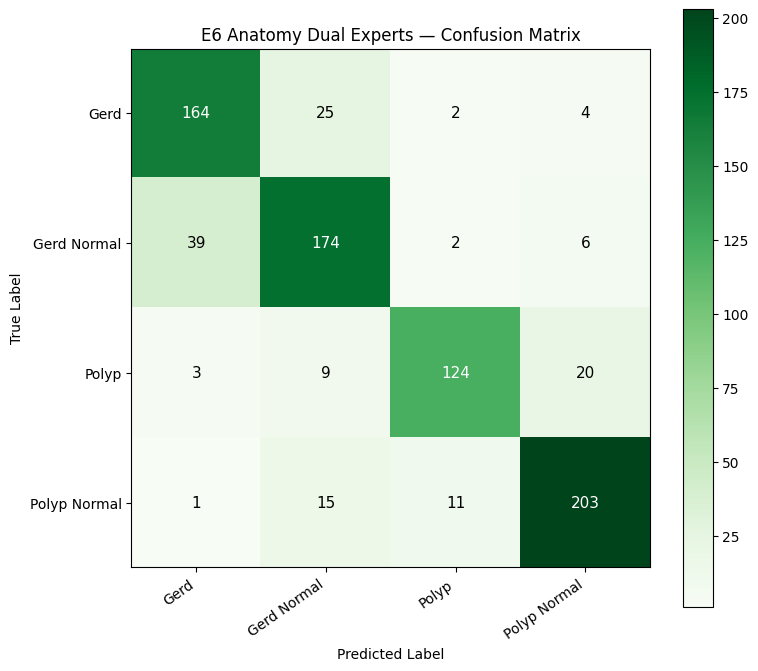

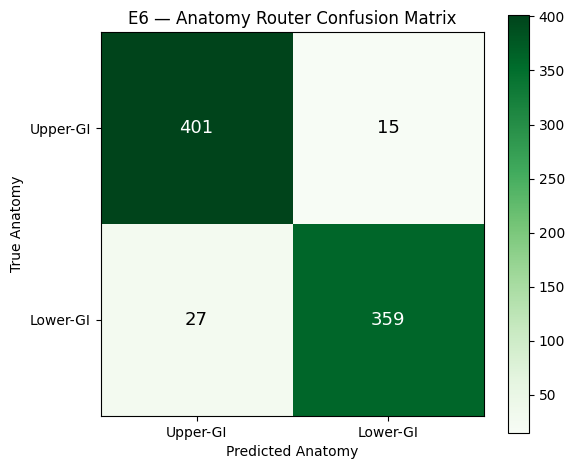


MEAN ANATOMY GATE BY CLASS
       Class  Mean Upper-GI Gate  Mean Lower-GI Gate
        Gerd              0.8762              0.1238
 Gerd Normal              0.8721              0.1279
       Polyp              0.1131              0.8869
Polyp Normal              0.1180              0.8820


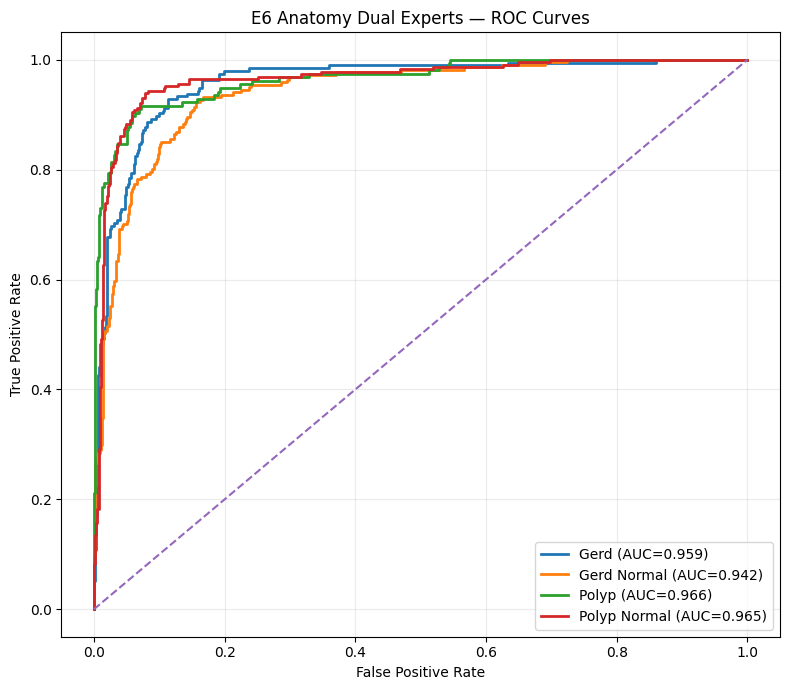

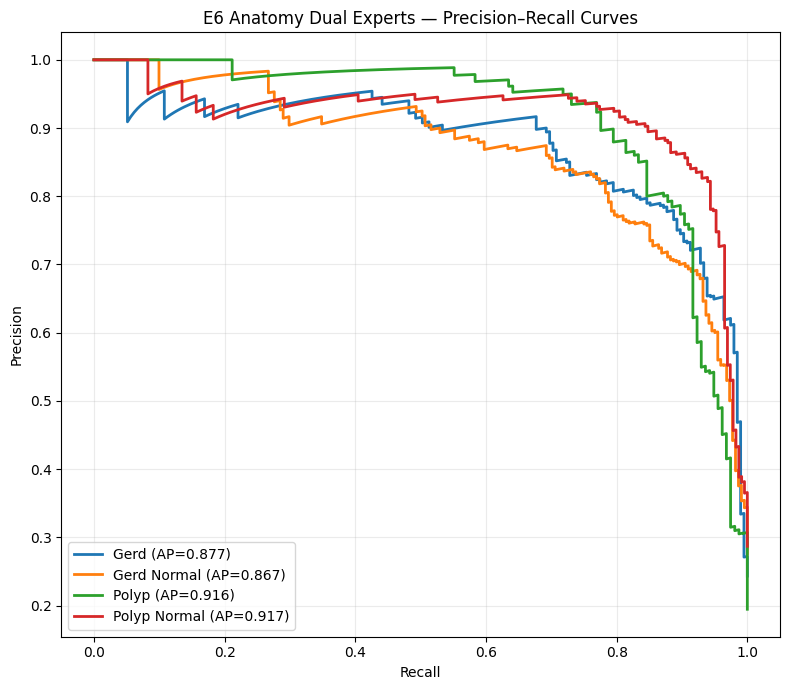

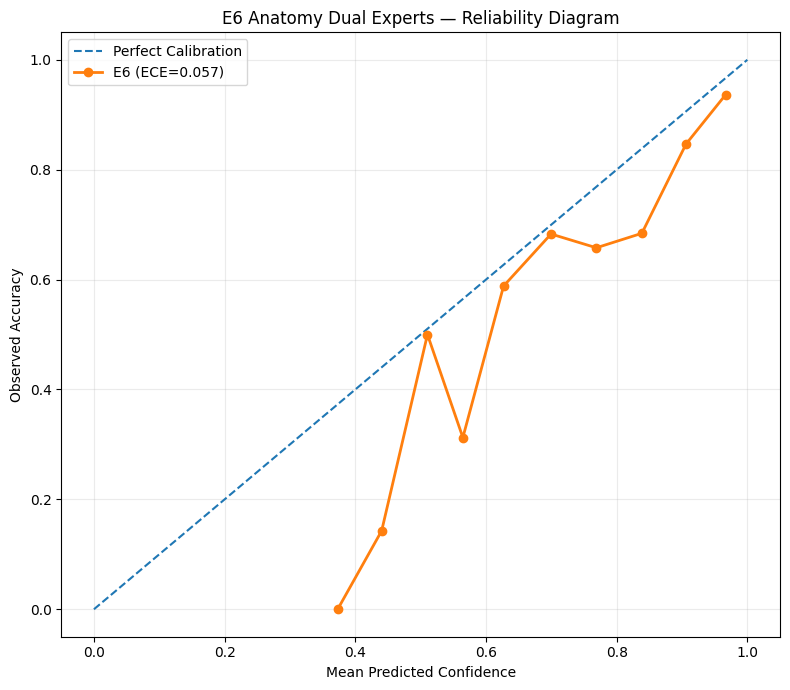


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Gerd     0.7923    0.8410    0.8159       195
 Gerd Normal     0.7803    0.7873    0.7838       221
       Polyp     0.8921    0.7949    0.8407       156
Polyp Normal     0.8712    0.8826    0.8769       230

    accuracy                         0.8292       802
   macro avg     0.8340    0.8265    0.8293       802
weighted avg     0.8310    0.8292    0.8294       802


LOADING E0 → E6 RESULTS
✓ E0 Real Only
✓ E1 Conventional Aug
✓ E2 MixUp/CutMix
✓ E3 Unfiltered Diffusion
✓ E4 Fidelity Filtered
✓ E5 Proposed Weighted Mix
✓ E6 Anatomy Dual Experts

E0 / E1 / E2 / E3 / E4 / E5 / E6 — LOCKED TEST COMPARISON
           Metric  E0 Real Only  E1 Conventional Aug  E2 MixUp/CutMix  E3 Unfiltered Diffusion  E4 Fidelity Filtered  E5 Proposed Weighted Mix  E6 Anatomy Dual Experts  E6 - E0  E6 - E2  E6 - E5
         Accuracy        0.8092               0.8217           0.8279                   0.8117            

In [4]:
# ============================================================
# GI-SAFE — E6 LOCKED TEST EVALUATION
# ANATOMY-CONDITIONED DUAL EXPERTS
#
# E6 = E5 Proposed +
#      Anatomy Router +
#      Upper-GI / Lower-GI Experts
#
# Evaluation:
#   ✓ Locked 802-image REAL test
#   ✓ Standard classification metrics
#   ✓ Calibration metrics
#   ✓ Per-class metrics
#   ✓ Anatomy routing analysis
#   ✓ Expert analysis
#   ✓ Green confusion matrices
#   ✓ E0 → E6 master comparison
# ============================================================

import copy
import json
import time
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

E6_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E6_AnatomyDualExperts"
)

RESULT_DIR = (
    E6_DIR /
    "results"
)

CHECKPOINT_DIR = (
    E6_DIR /
    "checkpoints"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_anatomy_dual_expert_e6.pth"
)

E6_METRIC_PATH = (
    RESULT_DIR /
    "E6_final_test_metrics.json"
)

TEST_CSV = (
    PROJECT_DIR /
    "splits" /
    "test.csv"
)


print("=" * 105)
print("E6 — LOCKED TEST EVALUATION")
print("ANATOMY-CONDITIONED DUAL EXPERTS")
print("=" * 105)

print(
    "\nCheckpoint:",
    BEST_MODEL_PATH
)

if not BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        f"E6 best checkpoint missing:\n"
        f"{BEST_MODEL_PATH}"
    )


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

AMP_ENABLED = torch.cuda.is_available()

print(
    "Device:",
    device
)

print(
    "AMP enabled:",
    AMP_ENABLED
)


# ============================================================
# 3. LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

CLASS_NAMES = checkpoint[
    "class_names"
]

CLASS_TO_IDX = checkpoint.get(
    "class_to_idx",
    {
        cls: idx
        for idx, cls
        in enumerate(CLASS_NAMES)
    }
)

NUM_CLASSES = len(
    CLASS_NAMES
)

IMAGE_SIZE = int(
    checkpoint.get(
        "image_size",
        384
    )
)

BATCH_SIZE = int(
    checkpoint.get(
        "batch_size",
        16
    )
)

best_epoch = checkpoint.get(
    "epoch",
    None
)

best_val_macro_f1 = checkpoint.get(
    "best_val_macro_f1",
    None
)


print("\nBest checkpoint:")
print(
    "Epoch               :",
    best_epoch
)

print(
    "Best Val Macro-F1   :",
    f"{best_val_macro_f1:.6f}"
)


# ============================================================
# 4. ANATOMY CONFIGURATION
# ============================================================

UPPER_GI = 0
LOWER_GI = 1

ANATOMY_NAMES = checkpoint.get(
    "anatomy_names",
    [
        "Upper-GI",
        "Lower-GI"
    ]
)


def infer_anatomy(
    class_name
):

    name = str(
        class_name
    ).lower()

    if "gerd" in name:

        return UPPER_GI

    elif "polyp" in name:

        return LOWER_GI

    else:

        raise ValueError(
            f"Unknown anatomy for class: {class_name}"
        )


CLASS_TO_ANATOMY = {

    CLASS_TO_IDX[cls]:
        infer_anatomy(cls)

    for cls in CLASS_NAMES
}


print("\nAnatomy mapping:")

for cls in CLASS_NAMES:

    cid = CLASS_TO_IDX[
        cls
    ]

    aid = CLASS_TO_ANATOMY[
        cid
    ]

    print(
        f"{cls:<25} → "
        f"{ANATOMY_NAMES[aid]}"
    )


# ============================================================
# 5. REBUILD E6 ARCHITECTURE
# ============================================================

ROUTER_DROPOUT = 0.20
EXPERT_DROPOUT = 0.20


class AnatomyDualExpertResNet50(
    nn.Module
):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        base = models.resnet50(
            weights=None
        )

        # Shared ResNet50 stem → layer3
        self.shared = nn.Sequential(

            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,

            base.layer1,
            base.layer2,
            base.layer3
        )

        # Independent layer4 experts
        self.upper_expert = copy.deepcopy(
            base.layer4
        )

        self.lower_expert = copy.deepcopy(
            base.layer4
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        # Anatomy router
        self.router = nn.Sequential(

            nn.Linear(
                1024,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                ROUTER_DROPOUT
            ),

            nn.Linear(
                256,
                2
            )
        )

        # Expert classifiers
        self.upper_classifier = nn.Sequential(

            nn.Dropout(
                EXPERT_DROPOUT
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )

        self.lower_classifier = nn.Sequential(

            nn.Dropout(
                EXPERT_DROPOUT
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        shared_map = self.shared(
            x
        )

        shared_vec = self.pool(
            shared_map
        )

        shared_vec = torch.flatten(
            shared_vec,
            1
        )

        router_logits = self.router(
            shared_vec
        )

        gates = torch.softmax(
            router_logits,
            dim=1
        )

        # Upper expert
        upper_map = self.upper_expert(
            shared_map
        )

        upper_vec = self.pool(
            upper_map
        )

        upper_vec = torch.flatten(
            upper_vec,
            1
        )

        upper_logits = self.upper_classifier(
            upper_vec
        )

        # Lower expert
        lower_map = self.lower_expert(
            shared_map
        )

        lower_vec = self.pool(
            lower_map
        )

        lower_vec = torch.flatten(
            lower_vec,
            1
        )

        lower_logits = self.lower_classifier(
            lower_vec
        )

        # Soft anatomy-gated fusion
        fused_logits = (

            gates[:, 0:1]
            *
            upper_logits

            +

            gates[:, 1:2]
            *
            lower_logits
        )

        return {

            "logits":
                fused_logits,

            "router_logits":
                router_logits,

            "gates":
                gates,

            "upper_logits":
                upper_logits,

            "lower_logits":
                lower_logits
        }


# ============================================================
# 6. LOAD MODEL
# ============================================================

model = AnatomyDualExpertResNet50(
    NUM_CLASSES
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model = model.to(
    device
)

model.eval()


total_params = sum(
    p.numel()
    for p in model.parameters()
)


print(
    "\n✓ E6 model restored."
)

print(
    "Parameters:",
    f"{total_params:,}"
)


# ============================================================
# 7. LOAD LOCKED TEST SPLIT
# ============================================================

test_df = pd.read_csv(
    TEST_CSV
)

assert len(test_df) == 802


# ============================================================
# 8. INDEX ORIGINAL REAL IMAGES
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print(
    "\nIndexing original dataset..."
)


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower()
        in IMG_EXTS
    )
]


filename_index = defaultdict(
    list
)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


def normalize_text(
    x
):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x)
        .lower()
        .strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name

    candidates = filename_index.get(
        filename,
        []
    )

    if len(candidates) == 1:

        return str(
            candidates[0]
        )

    if len(candidates) == 0:

        return None

    class_norm = normalize_text(
        class_name
    )

    matches = [

        p

        for p in candidates

        if class_norm
        in normalize_text(
            str(p.parent)
        )
    ]

    if len(matches) == 1:

        return str(
            matches[0]
        )

    return None


test_df[
    "image_path"
] = test_df.apply(

    lambda row:
        resolve_real_image(
            row[
                "filename"
            ],
            row[
                "class_name"
            ]
        ),

    axis=1
)


missing_test = int(
    test_df[
        "image_path"
    ].isna().sum()
)


print(
    "Unresolved test images:",
    missing_test
)


if missing_test > 0:

    raise RuntimeError(
        "Locked test path resolution failed."
    )


# ============================================================
# 9. TEST PREPROCESSING
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h - top
        )

        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


TEST_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 10. TEST DATASET
# ============================================================

class E6TestDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]

        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )

        image = TEST_TRANSFORM(
            image
        )

        class_id = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]

        anatomy_id = CLASS_TO_ANATOMY[
            class_id
        ]

        return (
            image,
            class_id,
            anatomy_id
        )


e6_test_dataset = E6TestDataset(
    test_df
)


e6_test_loader = DataLoader(

    e6_test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    drop_last=False
)


print(
    "\n✓ Locked REAL test images:",
    len(e6_test_dataset)
)


# ============================================================
# 11. CALIBRATION FUNCTIONS
# ============================================================

def multiclass_brier_score(
    y_true,
    y_prob,
    n_classes
):

    one_hot = np.eye(
        n_classes
    )[y_true]

    return float(
        np.mean(
            np.sum(
                (
                    y_prob
                    -
                    one_hot
                ) ** 2,
                axis=1
            )
        )
    )


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
):

    confidence = np.max(
        y_prob,
        axis=1
    )

    prediction = np.argmax(
        y_prob,
        axis=1
    )

    correct = (
        prediction
        ==
        y_true
    ).astype(float)

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )

    ece = 0.0


    for i in range(
        n_bins
    ):

        lower = edges[i]
        upper = edges[i + 1]

        if i == 0:

            mask = (
                (confidence >= lower)
                &
                (confidence <= upper)
            )

        else:

            mask = (
                (confidence > lower)
                &
                (confidence <= upper)
            )

        if mask.sum() == 0:

            continue

        bin_acc = correct[
            mask
        ].mean()

        bin_conf = confidence[
            mask
        ].mean()

        weight = (
            mask.sum()
            /
            len(y_true)
        )

        ece += (
            weight
            *
            abs(
                bin_acc
                -
                bin_conf
            )
        )

    return float(
        ece
    )


# ============================================================
# 12. RUN LOCKED TEST
# ============================================================

all_targets = []
all_predictions = []
all_probabilities = []

all_anatomy_targets = []
all_anatomy_predictions = []

all_router_probs = []

all_upper_predictions = []
all_lower_predictions = []

all_upper_probs = []
all_lower_probs = []

total_inference_time = 0.0


print("\n" + "=" * 105)
print("RUNNING E6 LOCKED TEST")
print("=" * 105)


with torch.no_grad():

    for (
        images,
        labels,
        anatomy
    ) in e6_test_loader:


        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        anatomy = anatomy.to(
            device,
            non_blocking=True
        )


        if torch.cuda.is_available():
            torch.cuda.synchronize()


        start = time.perf_counter()


        with torch.amp.autocast(

            device_type=(
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            ),

            enabled=AMP_ENABLED
        ):

            outputs = model(
                images
            )


        if torch.cuda.is_available():
            torch.cuda.synchronize()


        total_inference_time += (
            time.perf_counter()
            -
            start
        )


        fused_logits = outputs[
            "logits"
        ]

        router_logits = outputs[
            "router_logits"
        ]

        gates = outputs[
            "gates"
        ]

        upper_logits = outputs[
            "upper_logits"
        ]

        lower_logits = outputs[
            "lower_logits"
        ]


        fused_prob = torch.softmax(
            fused_logits,
            dim=1
        )

        upper_prob = torch.softmax(
            upper_logits,
            dim=1
        )

        lower_prob = torch.softmax(
            lower_logits,
            dim=1
        )


        fused_pred = fused_prob.argmax(
            dim=1
        )

        router_pred = gates.argmax(
            dim=1
        )

        upper_pred = upper_prob.argmax(
            dim=1
        )

        lower_pred = lower_prob.argmax(
            dim=1
        )


        all_targets.extend(
            labels
            .cpu()
            .numpy()
        )

        all_predictions.extend(
            fused_pred
            .cpu()
            .numpy()
        )

        all_probabilities.extend(
            fused_prob
            .cpu()
            .numpy()
        )


        all_anatomy_targets.extend(
            anatomy
            .cpu()
            .numpy()
        )

        all_anatomy_predictions.extend(
            router_pred
            .cpu()
            .numpy()
        )

        all_router_probs.extend(
            gates
            .cpu()
            .numpy()
        )


        all_upper_predictions.extend(
            upper_pred
            .cpu()
            .numpy()
        )

        all_lower_predictions.extend(
            lower_pred
            .cpu()
            .numpy()
        )

        all_upper_probs.extend(
            upper_prob
            .cpu()
            .numpy()
        )

        all_lower_probs.extend(
            lower_prob
            .cpu()
            .numpy()
        )


# ============================================================
# 13. ARRAYS
# ============================================================

y_true = np.asarray(
    all_targets
)

y_pred = np.asarray(
    all_predictions
)

y_prob = np.asarray(
    all_probabilities
)


anatomy_true = np.asarray(
    all_anatomy_targets
)

anatomy_pred = np.asarray(
    all_anatomy_predictions
)

router_prob = np.asarray(
    all_router_probs
)


upper_pred = np.asarray(
    all_upper_predictions
)

lower_pred = np.asarray(
    all_lower_predictions
)

upper_prob = np.asarray(
    all_upper_probs
)

lower_prob = np.asarray(
    all_lower_probs
)


assert len(y_true) == 802


# ============================================================
# 14. STANDARD CLASSIFICATION METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

kappa = cohen_kappa_score(
    y_true,
    y_pred
)


# ============================================================
# 15. AUROC / AUPRC
# ============================================================

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(
        NUM_CLASSES
    )
)

macro_auroc = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

macro_auprc = average_precision_score(
    y_true_bin,
    y_prob,
    average="macro"
)


# ============================================================
# 16. CALIBRATION
# ============================================================

brier = multiclass_brier_score(
    y_true,
    y_prob,
    NUM_CLASSES
)

ece = expected_calibration_error(
    y_true,
    y_prob,
    n_bins=15
)

nll = log_loss(
    y_true,
    y_prob,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 17. CLASS CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        NUM_CLASSES
    )
)


# ============================================================
# 18. ROUTER METRICS
# ============================================================

router_accuracy = accuracy_score(
    anatomy_true,
    anatomy_pred
)

router_balanced_accuracy = (
    balanced_accuracy_score(
        anatomy_true,
        anatomy_pred
    )
)

router_macro_f1 = f1_score(
    anatomy_true,
    anatomy_pred,
    average="macro",
    zero_division=0
)


router_cm = confusion_matrix(
    anatomy_true,
    anatomy_pred,
    labels=[
        UPPER_GI,
        LOWER_GI
    ]
)


# Correct-anatomy probability
correct_gate_probability = (

    router_prob[
        np.arange(
            len(
                anatomy_true
            )
        ),
        anatomy_true
    ]
)


mean_correct_gate_probability = float(
    correct_gate_probability.mean()
)


# Router confidence
router_confidence = np.max(
    router_prob,
    axis=1
)


# Router entropy
router_entropy = -np.sum(

    router_prob
    *
    np.log(
        router_prob
        +
        1e-12
    ),

    axis=1
)


mean_router_entropy = float(
    router_entropy.mean()
)


# ============================================================
# 19. EXPERT-SPECIFIC PERFORMANCE
# ============================================================

upper_mask = (
    anatomy_true
    ==
    UPPER_GI
)

lower_mask = (
    anatomy_true
    ==
    LOWER_GI
)


upper_expert_accuracy_on_upper = accuracy_score(
    y_true[
        upper_mask
    ],
    upper_pred[
        upper_mask
    ]
)


lower_expert_accuracy_on_lower = accuracy_score(
    y_true[
        lower_mask
    ],
    lower_pred[
        lower_mask
    ]
)


upper_expert_f1_on_upper = f1_score(
    y_true[
        upper_mask
    ],
    upper_pred[
        upper_mask
    ],
    average="macro",
    zero_division=0
)


lower_expert_f1_on_lower = f1_score(
    y_true[
        lower_mask
    ],
    lower_pred[
        lower_mask
    ],
    average="macro",
    zero_division=0
)


# Wrong-expert diagnostics
lower_expert_accuracy_on_upper = accuracy_score(
    y_true[
        upper_mask
    ],
    lower_pred[
        upper_mask
    ]
)


upper_expert_accuracy_on_lower = accuracy_score(
    y_true[
        lower_mask
    ],
    upper_pred[
        lower_mask
    ]
)


# ============================================================
# 20. PER-CLASS METRICS
# ============================================================

per_class_results = []


for i, class_name in enumerate(
    CLASS_NAMES
):

    TP = cm[
        i,
        i
    ]

    FN = (
        cm[
            i,
            :
        ].sum()
        -
        TP
    )

    FP = (
        cm[
            :,
            i
        ].sum()
        -
        TP
    )

    TN = (
        cm.sum()
        -
        TP
        -
        FN
        -
        FP
    )


    sensitivity = (
        TP / (TP + FN)
        if TP + FN
        else 0
    )

    specificity = (
        TN / (TN + FP)
        if TN + FP
        else 0
    )

    ppv = (
        TP / (TP + FP)
        if TP + FP
        else 0
    )

    npv = (
        TN / (TN + FN)
        if TN + FN
        else 0
    )


    class_f1 = f1_score(

        (
            y_true == i
        ).astype(int),

        (
            y_pred == i
        ).astype(int),

        zero_division=0
    )


    class_auc = roc_auc_score(
        y_true_bin[
            :,
            i
        ],
        y_prob[
            :,
            i
        ]
    )


    class_auprc = average_precision_score(
        y_true_bin[
            :,
            i
        ],
        y_prob[
            :,
            i
        ]
    )


    class_mask = (
        y_true == i
    )


    mean_correct_anatomy_gate = float(

        correct_gate_probability[
            class_mask
        ].mean()
    )


    per_class_results.append({

        "Class":
            class_name,

        "Anatomy":
            ANATOMY_NAMES[
                CLASS_TO_ANATOMY[i]
            ],

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "PPV":
            ppv,

        "NPV":
            npv,

        "F1":
            class_f1,

        "AUROC":
            class_auc,

        "AUPRC":
            class_auprc,

        "Mean_Correct_Anatomy_Gate":
            mean_correct_anatomy_gate
    })


per_class_df = pd.DataFrame(
    per_class_results
)


# ============================================================
# 21. INFERENCE SPEED
# ============================================================

latency_ms = (

    total_inference_time
    /
    len(y_true)
    *
    1000
)

throughput = (

    len(y_true)
    /
    total_inference_time
)


# ============================================================
# 22. PRINT MAIN RESULTS
# ============================================================

print("\n" + "=" * 105)
print("E6 — LOCKED TEST PERFORMANCE")
print("=" * 105)

print(f"Accuracy             : {accuracy:.4f}")
print(f"Balanced Accuracy    : {balanced_acc:.4f}")

print(f"Macro Precision      : {macro_precision:.4f}")
print(f"Macro Recall         : {macro_recall:.4f}")
print(f"Macro F1             : {macro_f1:.4f}")
print(f"Weighted F1          : {weighted_f1:.4f}")

print(f"MCC                  : {mcc:.4f}")
print(f"Cohen's Kappa        : {kappa:.4f}")

print(f"Macro AUROC          : {macro_auroc:.4f}")
print(f"Macro AUPRC          : {macro_auprc:.4f}")

print(f"Brier Score          : {brier:.4f}")
print(f"ECE                  : {ece:.4f}")
print(f"NLL                  : {nll:.4f}")

print(f"Inference latency    : {latency_ms:.3f} ms/image")
print(f"Throughput           : {throughput:.2f} images/sec")


# ============================================================
# 23. PRINT ROUTER ANALYSIS
# ============================================================

print("\n" + "=" * 105)
print("ANATOMY ROUTER PERFORMANCE")
print("=" * 105)

print(
    f"Router Accuracy             : "
    f"{router_accuracy:.4f}"
)

print(
    f"Router Balanced Accuracy    : "
    f"{router_balanced_accuracy:.4f}"
)

print(
    f"Router Macro F1             : "
    f"{router_macro_f1:.4f}"
)

print(
    f"Mean Correct-Gate Probability: "
    f"{mean_correct_gate_probability:.4f}"
)

print(
    f"Mean Router Entropy         : "
    f"{mean_router_entropy:.4f}"
)


print("\nExpert specialization:")

print(
    f"Upper expert on Upper-GI    : "
    f"Acc={upper_expert_accuracy_on_upper:.4f} | "
    f"Macro-F1={upper_expert_f1_on_upper:.4f}"
)

print(
    f"Lower expert on Lower-GI    : "
    f"Acc={lower_expert_accuracy_on_lower:.4f} | "
    f"Macro-F1={lower_expert_f1_on_lower:.4f}"
)

print(
    f"Wrong Lower expert on Upper : "
    f"{lower_expert_accuracy_on_upper:.4f}"
)

print(
    f"Wrong Upper expert on Lower : "
    f"{upper_expert_accuracy_on_lower:.4f}"
)


# ============================================================
# 24. PER-CLASS TABLE
# ============================================================

print("\n" + "=" * 105)
print("PER-CLASS PERFORMANCE")
print("=" * 105)

print(
    per_class_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 25. SAVE E6 METRICS
# ============================================================

e6_metrics = {

    "experiment":
        "E6_AnatomyDualExperts",

    "parent_experiment":
        "E5_ProposedFidelityWeightedMix",

    "test_images":
        802,

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_acc),

    "macro_precision":
        float(macro_precision),

    "macro_recall":
        float(macro_recall),

    "macro_f1":
        float(macro_f1),

    "weighted_f1":
        float(weighted_f1),

    "mcc":
        float(mcc),

    "cohen_kappa":
        float(kappa),

    "macro_auroc":
        float(macro_auroc),

    "macro_auprc":
        float(macro_auprc),

    "brier_score":
        float(brier),

    "ece":
        float(ece),

    "nll":
        float(nll),

    "latency_ms_per_image":
        float(latency_ms),

    "throughput_images_per_second":
        float(throughput),

    "best_epoch":
        int(best_epoch),

    "best_validation_macro_f1":
        float(
            best_val_macro_f1
        ),

    "router_accuracy":
        float(
            router_accuracy
        ),

    "router_balanced_accuracy":
        float(
            router_balanced_accuracy
        ),

    "router_macro_f1":
        float(
            router_macro_f1
        ),

    "mean_correct_gate_probability":
        float(
            mean_correct_gate_probability
        ),

    "mean_router_entropy":
        float(
            mean_router_entropy
        ),

    "upper_expert_accuracy_on_upper_gi":
        float(
            upper_expert_accuracy_on_upper
        ),

    "lower_expert_accuracy_on_lower_gi":
        float(
            lower_expert_accuracy_on_lower
        ),

    "upper_expert_macro_f1_on_upper_gi":
        float(
            upper_expert_f1_on_upper
        ),

    "lower_expert_macro_f1_on_lower_gi":
        float(
            lower_expert_f1_on_lower
        ),

    "model_parameters":
        int(
            total_params
        )
}


with open(
    E6_METRIC_PATH,
    "w"
) as f:

    json.dump(
        e6_metrics,
        f,
        indent=4
    )


per_class_df.to_csv(

    RESULT_DIR /
    "E6_per_class_metrics.csv",

    index=False
)


# ============================================================
# 26. SAVE TEST PREDICTIONS + ROUTER INFO
# ============================================================

prediction_df = (
    test_df
    .copy()
    .reset_index(
        drop=True
    )
)


prediction_df[
    "true_id"
] = y_true

prediction_df[
    "predicted_id"
] = y_pred


prediction_df[
    "true_class"
] = [
    CLASS_NAMES[i]
    for i in y_true
]


prediction_df[
    "predicted_class"
] = [
    CLASS_NAMES[i]
    for i in y_pred
]


prediction_df[
    "correct"
] = (
    y_true == y_pred
)


prediction_df[
    "confidence"
] = np.max(
    y_prob,
    axis=1
)


prediction_df[
    "true_anatomy"
] = [
    ANATOMY_NAMES[i]
    for i in anatomy_true
]


prediction_df[
    "predicted_anatomy"
] = [
    ANATOMY_NAMES[i]
    for i in anatomy_pred
]


prediction_df[
    "router_correct"
] = (
    anatomy_true
    ==
    anatomy_pred
)


prediction_df[
    "upper_gate_probability"
] = router_prob[
    :,
    UPPER_GI
]

prediction_df[
    "lower_gate_probability"
] = router_prob[
    :,
    LOWER_GI
]


prediction_df[
    "correct_gate_probability"
] = correct_gate_probability


prediction_df[
    "router_entropy"
] = router_entropy


prediction_df[
    "upper_expert_prediction"
] = [
    CLASS_NAMES[i]
    for i in upper_pred
]


prediction_df[
    "lower_expert_prediction"
] = [
    CLASS_NAMES[i]
    for i in lower_pred
]


for i, class_name in enumerate(
    CLASS_NAMES
):

    safe_name = (
        class_name
        .lower()
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )


    prediction_df[
        f"prob_{safe_name}"
    ] = y_prob[
        :,
        i
    ]


prediction_df.to_csv(

    RESULT_DIR /
    "E6_test_predictions.csv",

    index=False
)


# ============================================================
# 27. MAIN CONFUSION MATRIX — GREENS
# ============================================================

plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    cm,
    cmap="Greens",
    interpolation="nearest"
)

plt.title(
    "E6 Anatomy Dual Experts — Confusion Matrix"
)

plt.colorbar()


ticks = np.arange(
    NUM_CLASSES
)

plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)

plt.yticks(
    ticks,
    CLASS_NAMES
)


threshold = cm.max() / 2


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        plt.text(
            j,
            i,
            str(
                cm[i, j]
            ),
            ha="center",
            va="center",
            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            ),
            fontsize=11
        )


plt.ylabel(
    "True Label"
)

plt.xlabel(
    "Predicted Label"
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "E6_confusion_matrix.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 28. ANATOMY ROUTING CONFUSION MATRIX — GREENS
# ============================================================

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    router_cm,
    cmap="Greens",
    interpolation="nearest"
)

plt.title(
    "E6 — Anatomy Router Confusion Matrix"
)

plt.colorbar()


plt.xticks(
    [
        0,
        1
    ],
    ANATOMY_NAMES
)

plt.yticks(
    [
        0,
        1
    ],
    ANATOMY_NAMES
)


router_threshold = (
    router_cm.max()
    /
    2
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            str(
                router_cm[
                    i,
                    j
                ]
            ),
            ha="center",
            va="center",
            color=(
                "white"
                if router_cm[
                    i,
                    j
                ] > router_threshold
                else "black"
            ),
            fontsize=13
        )


plt.xlabel(
    "Predicted Anatomy"
)

plt.ylabel(
    "True Anatomy"
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "E6_anatomy_router_confusion_matrix.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 29. MEAN GATE BY CLASS
# ============================================================

gate_rows = []


for i, cls in enumerate(
    CLASS_NAMES
):

    mask = (
        y_true == i
    )

    gate_rows.append({

        "Class":
            cls,

        "Mean Upper-GI Gate":
            float(
                router_prob[
                    mask,
                    UPPER_GI
                ].mean()
            ),

        "Mean Lower-GI Gate":
            float(
                router_prob[
                    mask,
                    LOWER_GI
                ].mean()
            )
    })


gate_df = pd.DataFrame(
    gate_rows
)


print("\n" + "=" * 105)
print("MEAN ANATOMY GATE BY CLASS")
print("=" * 105)

print(
    gate_df
    .round(4)
    .to_string(
        index=False
    )
)


gate_df.to_csv(

    RESULT_DIR /
    "E6_classwise_gate_statistics.csv",

    index=False
)


# ============================================================
# 30. ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    fpr, tpr, _ = roc_curve(
        y_true_bin[
            :,
            i
        ],
        y_prob[
            :,
            i
        ]
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AUC={roc_auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "E6 Anatomy Dual Experts — ROC Curves"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "E6_ROC_curves.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 31. PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(8, 7)
)


for i, class_name in enumerate(
    CLASS_NAMES
):

    precision_curve, recall_curve, _ = (
        precision_recall_curve(

            y_true_bin[
                :,
                i
            ],

            y_prob[
                :,
                i
            ]
        )
    )


    ap_value = average_precision_score(

        y_true_bin[
            :,
            i
        ],

        y_prob[
            :,
            i
        ]
    )


    plt.plot(
        recall_curve,
        precision_curve,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP={ap_value:.3f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "E6 Anatomy Dual Experts — Precision–Recall Curves"
)

plt.legend(
    loc="lower left"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "E6_PR_curves.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 32. RELIABILITY DIAGRAM
# ============================================================

confidence = np.max(
    y_prob,
    axis=1
)

correctness = (
    y_pred == y_true
).astype(float)

edges = np.linspace(
    0,
    1,
    16
)

bin_acc = []
bin_conf = []


for i in range(15):

    lower = edges[i]
    upper = edges[i + 1]

    mask = (
        (confidence > lower)
        &
        (confidence <= upper)
    )

    if mask.sum() > 0:

        bin_acc.append(
            correctness[
                mask
            ].mean()
        )

        bin_conf.append(
            confidence[
                mask
            ].mean()
        )


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Perfect Calibration"
)

plt.plot(
    bin_conf,
    bin_acc,
    marker="o",
    linewidth=2,
    label=(
        f"E6 "
        f"(ECE={ece:.3f})"
    )
)

plt.xlabel(
    "Mean Predicted Confidence"
)

plt.ylabel(
    "Observed Accuracy"
)

plt.title(
    "E6 Anatomy Dual Experts — Reliability Diagram"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    RESULT_DIR /
    "E6_calibration_curve.png",

    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 33. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 105)
print("CLASSIFICATION REPORT")
print("=" * 105)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=
            CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 34. E0 → E6 RESULT PATHS
# ============================================================

metric_paths = {

    "E0 Real Only":

        PROJECT_DIR /
        "experiments" /
        "E0_ResNet50_RealOnly" /
        "results" /
        "E0_final_test_metrics.json",

    "E1 Conventional Aug":

        PROJECT_DIR /
        "experiments" /
        "E1_ResNet50_ConventionalAug" /
        "results" /
        "E1_final_test_metrics.json",

    "E2 MixUp/CutMix":

        PROJECT_DIR /
        "experiments" /
        "E2_ResNet50_MixUpCutMix" /
        "results" /
        "E2_final_test_metrics.json",

    "E3 Unfiltered Diffusion":

        PROJECT_DIR /
        "experiments" /
        "E3_Diffusion_Unfiltered" /
        "results" /
        "E3_final_test_metrics.json",

    "E4 Fidelity Filtered":

        PROJECT_DIR /
        "experiments" /
        "E4_Diffusion_FidelityFiltered" /
        "results" /
        "E4_final_test_metrics.json",

    "E5 Proposed Weighted Mix":

        PROJECT_DIR /
        "experiments" /
        "E5_ProposedFidelityWeightedMix" /
        "results" /
        "E5_final_test_metrics.json",

    "E6 Anatomy Dual Experts":

        E6_METRIC_PATH
}


# ============================================================
# 35. LOAD RESULTS
# ============================================================

loaded = {}


print("\n" + "=" * 110)
print("LOADING E0 → E6 RESULTS")
print("=" * 110)


for name, path in (
    metric_paths.items()
):

    if path.exists():

        with open(
            path,
            "r"
        ) as f:

            loaded[
                name
            ] = json.load(
                f
            )

        print(
            "✓",
            name
        )

    else:

        print(
            "✗ Missing:",
            name
        )


# ============================================================
# 36. MASTER COMPARISON
# ============================================================

metrics_to_compare = {

    "Accuracy":
        "accuracy",

    "Balanced Accuracy":
        "balanced_accuracy",

    "Macro Precision":
        "macro_precision",

    "Macro Recall":
        "macro_recall",

    "Macro F1":
        "macro_f1",

    "Weighted F1":
        "weighted_f1",

    "MCC":
        "mcc",

    "Cohen's Kappa":
        "cohen_kappa",

    "Macro AUROC":
        "macro_auroc",

    "Macro AUPRC":
        "macro_auprc",

    "Brier Score":
        "brier_score",

    "ECE":
        "ece",

    "NLL":
        "nll"
}


rows = []


for metric_name, key in (
    metrics_to_compare.items()
):

    row = {
        "Metric":
            metric_name
    }

    for experiment_name in (
        metric_paths.keys()
    ):

        data = loaded.get(
            experiment_name
        )

        row[
            experiment_name
        ] = (

            data.get(
                key,
                np.nan
            )

            if data is not None

            else np.nan
        )

    rows.append(
        row
    )


comparison_df = pd.DataFrame(
    rows
)


# ============================================================
# 37. DIFFERENCE COLUMNS
# ============================================================

comparison_df[
    "E6 - E0"
] = (

    comparison_df[
        "E6 Anatomy Dual Experts"
    ]

    -

    comparison_df[
        "E0 Real Only"
    ]
)


comparison_df[
    "E6 - E2"
] = (

    comparison_df[
        "E6 Anatomy Dual Experts"
    ]

    -

    comparison_df[
        "E2 MixUp/CutMix"
    ]
)


comparison_df[
    "E6 - E5"
] = (

    comparison_df[
        "E6 Anatomy Dual Experts"
    ]

    -

    comparison_df[
        "E5 Proposed Weighted Mix"
    ]
)


MASTER_PATH = (
    RESULT_DIR /
    "E0_E1_E2_E3_E4_E5_E6_master_comparison.csv"
)


comparison_df.to_csv(
    MASTER_PATH,
    index=False
)


print("\n" + "=" * 145)
print("E0 / E1 / E2 / E3 / E4 / E5 / E6 — LOCKED TEST COMPARISON")
print("=" * 145)

print(
    comparison_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 38. DIRECT E5 → E6 ARCHITECTURE EFFECT
# ============================================================

if (
    "E5 Proposed Weighted Mix"
    in loaded
):

    e5 = loaded[
        "E5 Proposed Weighted Mix"
    ]


    print("\n" + "=" * 105)
    print("E5 → E6 EFFECT OF ANATOMY-CONDITIONED DUAL EXPERTS")
    print("=" * 105)


    higher_better = [

        ("Accuracy", "accuracy"),
        ("Balanced Accuracy", "balanced_accuracy"),
        ("Macro Precision", "macro_precision"),
        ("Macro Recall", "macro_recall"),
        ("Macro F1", "macro_f1"),
        ("Weighted F1", "weighted_f1"),
        ("MCC", "mcc"),
        ("Macro AUROC", "macro_auroc"),
        ("Macro AUPRC", "macro_auprc")

    ]


    for name, key in higher_better:

        delta = (
            e6_metrics[
                key
            ]
            -
            e5[
                key
            ]
        )

        print(
            f"{name:<22}: "
            f"{e5[key]:.4f} "
            f"→ "
            f"{e6_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


    print(
        "\nCalibration / error "
        "(lower is better)"
    )


    for name, key in [

        ("Brier Score", "brier_score"),
        ("ECE", "ece"),
        ("NLL", "nll")

    ]:

        delta = (
            e6_metrics[
                key
            ]
            -
            e5[
                key
            ]
        )

        print(
            f"{name:<22}: "
            f"{e5[key]:.4f} "
            f"→ "
            f"{e6_metrics[key]:.4f} "
            f"({delta:+.4f})"
        )


# ============================================================
# 39. FINAL STATUS
# ============================================================

print("\n" + "=" * 105)
print("E6 FINAL EVALUATION COMPLETE")
print("=" * 105)

print("✓ Locked 802-image REAL test evaluated")

print("✓ Overall classification metrics saved")
print("✓ Per-class metrics saved")
print("✓ Test predictions saved")

print("✓ Green 4-class confusion matrix saved")
print("✓ Green anatomy-router confusion matrix saved")

print("✓ Anatomy routing accuracy calculated")
print("✓ Correct-gate probability calculated")
print("✓ Router entropy calculated")
print("✓ Upper/Lower expert specialization analyzed")

print("✓ ROC curves saved")
print("✓ PR curves saved")
print("✓ Reliability diagram saved")

print("✓ E0 → E6 master comparison created")
print("✓ E5 → E6 architectural effect calculated")


print("\nSaved:")

print(
    "Metrics:",
    E6_METRIC_PATH
)

print(
    "Per-class:",
    RESULT_DIR /
    "E6_per_class_metrics.csv"
)

print(
    "Predictions:",
    RESULT_DIR /
    "E6_test_predictions.csv"
)

print(
    "Gate statistics:",
    RESULT_DIR /
    "E6_classwise_gate_statistics.csv"
)

print(
    "Master comparison:",
    MASTER_PATH
)

print("=" * 105)

# E7 — calibrated uncertainty + OOD-aware rejection

In [5]:
# ============================================================
# GI-SAFE — E7 STEP 1
# CALIBRATED UNCERTAINTY + REJECTION THRESHOLD CALIBRATION
#
# Parent: E6 Anatomy-Conditioned Dual Experts
#
# IMPORTANT:
#   ✓ E6 model is frozen
#   ✓ NO E6 retraining
#   ✓ Uses 401 REAL validation images only
#   ✓ NO locked-test labels used here
#
# E7 uncertainty signals:
#   1. Calibrated class entropy
#   2. Anatomy-router entropy
#   3. Upper/Lower expert JS disagreement
#   4. Energy score
#
# Composite:
#   Equal-weight percentile-normalized uncertainty
#
# Primary operating point:
#   90% target validation coverage
# ============================================================

import gc
import copy
import json
import time
import re

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 0. MEMORY CLEANUP
# ============================================================

if "model" in globals():

    try:
        del model
    except:
        pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# 1. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 105)
print("GI-SAFE E7 — UNCERTAINTY / REJECTION CALIBRATION")
print("=" * 105)

print(
    "Device:",
    device
)


# ============================================================
# 2. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

E6_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E6_AnatomyDualExperts"
)

E7_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E7_UncertaintyOODRejection"
)

RESULT_DIR = (
    E7_DIR /
    "results"
)

CALIBRATION_DIR = (
    E7_DIR /
    "calibration"
)

FIGURE_DIR = (
    E7_DIR /
    "figures"
)

for folder in [
    E7_DIR,
    RESULT_DIR,
    CALIBRATION_DIR,
    FIGURE_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


E6_CHECKPOINT = (
    E6_DIR /
    "checkpoints" /
    "best_anatomy_dual_expert_e6.pth"
)

VAL_CSV = (
    PROJECT_DIR /
    "splits" /
    "val.csv"
)


E7_CONFIG_PATH = (
    CALIBRATION_DIR /
    "E7_uncertainty_config.json"
)

E7_REFERENCE_PATH = (
    CALIBRATION_DIR /
    "E7_validation_uncertainty_reference.npz"
)

E7_VAL_RESULTS = (
    RESULT_DIR /
    "E7_validation_selective_metrics.csv"
)


if not E6_CHECKPOINT.exists():

    raise FileNotFoundError(
        f"E6 checkpoint missing:\n"
        f"{E6_CHECKPOINT}"
    )


# ============================================================
# 3. LOAD E6 CHECKPOINT
# ============================================================

checkpoint = torch.load(
    E6_CHECKPOINT,
    map_location="cpu",
    weights_only=False
)


CLASS_NAMES = checkpoint[
    "class_names"
]

CLASS_TO_IDX = checkpoint[
    "class_to_idx"
]

NUM_CLASSES = len(
    CLASS_NAMES
)

IMAGE_SIZE = int(
    checkpoint.get(
        "image_size",
        384
    )
)

BATCH_SIZE = int(
    checkpoint.get(
        "batch_size",
        16
    )
)


print("\nParent E6:")

print(
    "Best epoch:",
    checkpoint.get(
        "epoch"
    )
)

print(
    "Best validation Macro-F1:",
    checkpoint.get(
        "best_val_macro_f1"
    )
)


# ============================================================
# 4. ANATOMY MAPPING
# ============================================================

UPPER_GI = 0
LOWER_GI = 1

ANATOMY_NAMES = [
    "Upper-GI",
    "Lower-GI"
]


def class_to_anatomy(
    class_name
):

    name = str(
        class_name
    ).lower()

    if "gerd" in name:

        return UPPER_GI

    if "polyp" in name:

        return LOWER_GI

    raise ValueError(
        f"Unknown anatomy: {class_name}"
    )


CLASS_TO_ANATOMY = {

    CLASS_TO_IDX[
        cls
    ]:
        class_to_anatomy(
            cls
        )

    for cls in CLASS_NAMES
}


# ============================================================
# 5. REBUILD E6 MODEL
# ============================================================

class AnatomyDualExpertResNet50(
    nn.Module
):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()


        base = models.resnet50(
            weights=None
        )


        self.shared = nn.Sequential(

            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,

            base.layer1,
            base.layer2,
            base.layer3
        )


        self.upper_expert = copy.deepcopy(
            base.layer4
        )

        self.lower_expert = copy.deepcopy(
            base.layer4
        )


        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        self.router = nn.Sequential(

            nn.Linear(
                1024,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                256,
                2
            )
        )


        self.upper_classifier = nn.Sequential(

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


        self.lower_classifier = nn.Sequential(

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        shared = self.shared(
            x
        )


        shared_vec = self.pool(
            shared
        )

        shared_vec = torch.flatten(
            shared_vec,
            1
        )


        router_logits = self.router(
            shared_vec
        )

        gates = torch.softmax(
            router_logits,
            dim=1
        )


        upper = self.upper_expert(
            shared
        )

        upper = self.pool(
            upper
        )

        upper = torch.flatten(
            upper,
            1
        )

        upper_logits = self.upper_classifier(
            upper
        )


        lower = self.lower_expert(
            shared
        )

        lower = self.pool(
            lower
        )

        lower = torch.flatten(
            lower,
            1
        )

        lower_logits = self.lower_classifier(
            lower
        )


        fused_logits = (

            gates[
                :,
                0:1
            ]
            *
            upper_logits

            +

            gates[
                :,
                1:2
            ]
            *
            lower_logits
        )


        return {

            "logits":
                fused_logits,

            "router_logits":
                router_logits,

            "gates":
                gates,

            "upper_logits":
                upper_logits,

            "lower_logits":
                lower_logits
        }


model = AnatomyDualExpertResNet50(
    NUM_CLASSES
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model = model.to(
    device
)

model.eval()


print(
    "\n✓ Frozen E6 model restored."
)


# ============================================================
# 6. LOAD VALIDATION SPLIT
# ============================================================

val_df = pd.read_csv(
    VAL_CSV
)


assert len(
    val_df
) == 401


print(
    "Validation images:",
    len(val_df)
)


# ============================================================
# 7. INDEX REAL DATASET
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print(
    "\nIndexing original images..."
)


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower()
        in IMG_EXTS
    )
]


filename_index = defaultdict(
    list
)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


def normalize_text(
    x
):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x)
        .lower()
        .strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name


    candidates = filename_index.get(
        filename,
        []
    )


    if len(candidates) == 1:

        return str(
            candidates[0]
        )


    if len(candidates) == 0:

        return None


    class_norm = normalize_text(
        class_name
    )


    matches = [

        p

        for p in candidates

        if class_norm
        in normalize_text(
            str(
                p.parent
            )
        )
    ]


    if len(matches) == 1:

        return str(
            matches[0]
        )


    return None


val_df[
    "image_path"
] = val_df.apply(

    lambda row:
        resolve_real_image(
            row[
                "filename"
            ],
            row[
                "class_name"
            ]
        ),

    axis=1
)


missing = int(
    val_df[
        "image_path"
    ].isna().sum()
)


print(
    "Missing validation paths:",
    missing
)


if missing > 0:

    raise RuntimeError(
        "Validation path resolution failed."
    )


# ============================================================
# 8. TRANSFORM
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        width, height = image.size

        side = max(
            width,
            height
        )


        left = (
            side - width
        ) // 2

        right = (
            side
            -
            width
            -
            left
        )


        top = (
            side - height
        ) // 2

        bottom = (
            side
            -
            height
            -
            top
        )


        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 9. VALIDATION DATASET
# ============================================================

class E7ValidationDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy = CLASS_TO_ANATOMY[
            label
        ]


        return (
            image,
            label,
            anatomy
        )


val_dataset = E7ValidationDataset(
    val_df
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    drop_last=False
)


# ============================================================
# 10. EXTRACT RAW VALIDATION LOGITS
# ============================================================

all_labels = []
all_anatomy = []

all_logits = []
all_router_logits = []

all_upper_logits = []
all_lower_logits = []


print("\n" + "=" * 105)
print("EXTRACTING E6 VALIDATION OUTPUTS")
print("=" * 105)


with torch.no_grad():

    for (
        images,
        labels,
        anatomy
    ) in val_loader:


        images = images.to(
            device,
            non_blocking=True
        )


        outputs = model(
            images
        )


        all_labels.append(
            labels.numpy()
        )

        all_anatomy.append(
            anatomy.numpy()
        )


        all_logits.append(
            outputs[
                "logits"
            ]
            .cpu()
        )


        all_router_logits.append(
            outputs[
                "router_logits"
            ]
            .cpu()
        )


        all_upper_logits.append(
            outputs[
                "upper_logits"
            ]
            .cpu()
        )


        all_lower_logits.append(
            outputs[
                "lower_logits"
            ]
            .cpu()
        )


y_val = np.concatenate(
    all_labels
)

a_val = np.concatenate(
    all_anatomy
)


val_logits = torch.cat(
    all_logits,
    dim=0
)


router_logits_val = torch.cat(
    all_router_logits,
    dim=0
)


upper_logits_val = torch.cat(
    all_upper_logits,
    dim=0
)


lower_logits_val = torch.cat(
    all_lower_logits,
    dim=0
)


assert len(
    y_val
) == 401


print(
    "✓ Validation outputs extracted."
)


# ============================================================
# 11. TEMPERATURE SCALING
# ============================================================
#
# Fit temperature using validation NLL.
# No test data used.
# ============================================================

class TemperatureScaler(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()


        self.log_temperature = nn.Parameter(
            torch.zeros(1)
        )


    def forward(
        self,
        logits
    ):

        temperature = torch.exp(
            self.log_temperature
        ).clamp(
            0.05,
            20.0
        )


        return (
            logits
            /
            temperature
        )


    def temperature(
        self
    ):

        return float(
            torch.exp(
                self.log_temperature
            )
            .detach()
            .cpu()
            .item()
        )


def fit_temperature(
    logits,
    labels,
    max_iter=100
):

    scaler = TemperatureScaler()

    logits = logits.clone()

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.long
    )


    optimizer_temp = torch.optim.LBFGS(

        scaler.parameters(),

        lr=0.1,

        max_iter=max_iter
    )


    def closure():

        optimizer_temp.zero_grad()


        scaled = scaler(
            logits
        )


        loss = F.cross_entropy(
            scaled,
            labels_tensor
        )


        loss.backward()


        return loss


    optimizer_temp.step(
        closure
    )


    return scaler.temperature()


CLASS_TEMPERATURE = fit_temperature(
    val_logits,
    y_val
)


ROUTER_TEMPERATURE = fit_temperature(
    router_logits_val,
    a_val
)


print("\n" + "=" * 105)
print("TEMPERATURE CALIBRATION")
print("=" * 105)

print(
    f"Class temperature : "
    f"{CLASS_TEMPERATURE:.4f}"
)

print(
    f"Router temperature: "
    f"{ROUTER_TEMPERATURE:.4f}"
)


# ============================================================
# 12. CALIBRATED PROBABILITIES
# ============================================================

scaled_logits = (
    val_logits
    /
    CLASS_TEMPERATURE
)


scaled_router_logits = (
    router_logits_val
    /
    ROUTER_TEMPERATURE
)


class_prob = torch.softmax(
    scaled_logits,
    dim=1
).numpy()


router_prob = torch.softmax(
    scaled_router_logits,
    dim=1
).numpy()


upper_prob = torch.softmax(
    upper_logits_val,
    dim=1
).numpy()


lower_prob = torch.softmax(
    lower_logits_val,
    dim=1
).numpy()


# ============================================================
# 13. UNCERTAINTY SIGNAL 1
# CLASS ENTROPY
# ============================================================

class_entropy = -np.sum(

    class_prob

    *

    np.log(
        class_prob
        +
        1e-12
    ),

    axis=1
)


# Normalize theoretical entropy range
class_entropy_norm = (

    class_entropy

    /

    np.log(
        NUM_CLASSES
    )
)


# ============================================================
# 14. UNCERTAINTY SIGNAL 2
# ROUTER ENTROPY
# ============================================================

router_entropy = -np.sum(

    router_prob

    *

    np.log(
        router_prob
        +
        1e-12
    ),

    axis=1
)


router_entropy_norm = (

    router_entropy

    /

    np.log(2)
)


# ============================================================
# 15. UNCERTAINTY SIGNAL 3
# EXPERT JENSEN-SHANNON DISAGREEMENT
# ============================================================

mixture_prob = (

    0.5
    *
    (
        upper_prob
        +
        lower_prob
    )
)


kl_upper = np.sum(

    upper_prob

    *

    np.log(
        (
            upper_prob
            +
            1e-12
        )
        /
        (
            mixture_prob
            +
            1e-12
        )
    ),

    axis=1
)


kl_lower = np.sum(

    lower_prob

    *

    np.log(
        (
            lower_prob
            +
            1e-12
        )
        /
        (
            mixture_prob
            +
            1e-12
        )
    ),

    axis=1
)


js_disagreement = (

    0.5
    *
    (
        kl_upper
        +
        kl_lower
    )
)


# Theoretical JS maximum is ln(2)
js_disagreement_norm = (

    js_disagreement

    /

    np.log(2)
)


# ============================================================
# 16. UNCERTAINTY SIGNAL 4
# ENERGY
#
# Higher energy = more OOD-like / uncertain
# ============================================================

scaled_logits_np = scaled_logits.numpy()


energy = (

    -CLASS_TEMPERATURE

    *

    np.log(
        np.sum(
            np.exp(
                scaled_logits_np
                /
                CLASS_TEMPERATURE
            ),
            axis=1
        )
        +
        1e-12
    )
)


# ============================================================
# 17. VALIDATION ECDF / PERCENTILE TRANSFORMATION
# ============================================================
#
# Convert metrics to percentile ranks.
# Higher percentile = more uncertain.
#
# This prevents mixing incompatible scales.
# ============================================================

def percentile_rank(
    values
):

    series = pd.Series(
        values
    )

    return (
        series
        .rank(
            method="average",
            pct=True
        )
        .values
    )


class_entropy_pct = percentile_rank(
    class_entropy_norm
)


router_entropy_pct = percentile_rank(
    router_entropy_norm
)


js_pct = percentile_rank(
    js_disagreement_norm
)


energy_pct = percentile_rank(
    energy
)


# ============================================================
# 18. COMPOSITE UNCERTAINTY
# ============================================================
#
# Equal weights = transparent,
# no test-driven hyperparameter optimization.
# ============================================================

composite_uncertainty = (

    class_entropy_pct

    +

    router_entropy_pct

    +

    js_pct

    +

    energy_pct

) / 4.0


# ============================================================
# 19. RAW VALIDATION PERFORMANCE
# ============================================================

pred_val = np.argmax(
    class_prob,
    axis=1
)


raw_accuracy = accuracy_score(
    y_val,
    pred_val
)


raw_macro_f1 = f1_score(
    y_val,
    pred_val,
    average="macro",
    zero_division=0
)


print("\n" + "=" * 105)
print("RAW VALIDATION PERFORMANCE")
print("=" * 105)

print(
    f"Accuracy : "
    f"{raw_accuracy:.4f}"
)

print(
    f"Macro-F1 : "
    f"{raw_macro_f1:.4f}"
)


# ============================================================
# 20. ERROR-DETECTION ABILITY
# ============================================================

error_label = (
    pred_val
    !=
    y_val
).astype(int)


if len(
    np.unique(
        error_label
    )
) > 1:

    error_detection_auroc = roc_auc_score(
        error_label,
        composite_uncertainty
    )


    error_detection_auprc = average_precision_score(
        error_label,
        composite_uncertainty
    )

else:

    error_detection_auroc = np.nan
    error_detection_auprc = np.nan


print("\n" + "=" * 105)
print("VALIDATION ERROR-DETECTION")
print("=" * 105)

print(
    f"AUROC : "
    f"{error_detection_auroc:.4f}"
)

print(
    f"AUPRC : "
    f"{error_detection_auprc:.4f}"
)


# ============================================================
# 21. DEFINE COVERAGE OPERATING POINTS
# ============================================================

TARGET_COVERAGES = [
    0.95,
    0.90,
    0.85,
    0.80
]


thresholds = {}


for coverage in TARGET_COVERAGES:

    threshold = float(
        np.quantile(
            composite_uncertainty,
            coverage
        )
    )

    thresholds[
        coverage
    ] = threshold


# Primary E7 operating point
PRIMARY_COVERAGE = 0.90

PRIMARY_THRESHOLD = thresholds[
    PRIMARY_COVERAGE
]


# ============================================================
# 22. SELECTIVE VALIDATION METRICS
# ============================================================

selective_rows = []


for target_coverage in TARGET_COVERAGES:


    threshold = thresholds[
        target_coverage
    ]


    accepted = (
        composite_uncertainty
        <=
        threshold
    )


    rejected = (
        ~accepted
    )


    accepted_count = int(
        accepted.sum()
    )


    rejected_count = int(
        rejected.sum()
    )


    actual_coverage = float(
        accepted.mean()
    )


    if accepted_count > 0:

        accepted_accuracy = accuracy_score(

            y_val[
                accepted
            ],

            pred_val[
                accepted
            ]
        )


        accepted_balanced_accuracy = (
            balanced_accuracy_score(

                y_val[
                    accepted
                ],

                pred_val[
                    accepted
                ]
            )
        )


        accepted_macro_f1 = f1_score(

            y_val[
                accepted
            ],

            pred_val[
                accepted
            ],

            average="macro",

            zero_division=0
        )


    else:

        accepted_accuracy = np.nan
        accepted_balanced_accuracy = np.nan
        accepted_macro_f1 = np.nan


    # Fraction of original errors rejected
    total_errors = int(
        error_label.sum()
    )


    rejected_errors = int(
        (
            rejected
            &
            (
                error_label
                ==
                1
            )
        ).sum()
    )


    error_rejection_rate = (

        rejected_errors
        /
        total_errors

        if total_errors > 0

        else np.nan
    )


    selective_rows.append({

        "Target_Coverage":
            target_coverage,

        "Threshold":
            threshold,

        "Actual_Coverage":
            actual_coverage,

        "Accepted":
            accepted_count,

        "Rejected":
            rejected_count,

        "Accepted_Accuracy":
            accepted_accuracy,

        "Accepted_Balanced_Accuracy":
            accepted_balanced_accuracy,

        "Accepted_Macro_F1":
            accepted_macro_f1,

        "Error_Rejection_Rate":
            error_rejection_rate
    })


selective_df = pd.DataFrame(
    selective_rows
)


selective_df.to_csv(
    E7_VAL_RESULTS,
    index=False
)


print("\n" + "=" * 105)
print("VALIDATION SELECTIVE PERFORMANCE")
print("=" * 105)

print(
    selective_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 23. PRIMARY OPERATING POINT
# ============================================================

primary_accept = (

    composite_uncertainty

    <=

    PRIMARY_THRESHOLD
)


primary_reject = (
    ~primary_accept
)


print("\n" + "=" * 105)
print("PRIMARY E7 OPERATING POINT")
print("=" * 105)

print(
    f"Target coverage : "
    f"{PRIMARY_COVERAGE:.0%}"
)

print(
    f"Threshold       : "
    f"{PRIMARY_THRESHOLD:.6f}"
)

print(
    f"Actual coverage : "
    f"{primary_accept.mean():.2%}"
)

print(
    "Accepted        :",
    int(
        primary_accept.sum()
    )
)

print(
    "Rejected        :",
    int(
        primary_reject.sum()
    )
)


print(
    f"Accepted Accuracy : "
    f"{accuracy_score(y_val[primary_accept], pred_val[primary_accept]):.4f}"
)

print(
    f"Accepted Macro-F1 : "
    f"{f1_score(y_val[primary_accept], pred_val[primary_accept], average='macro', zero_division=0):.4f}"
)


# ============================================================
# 24. SAVE VALIDATION REFERENCE ARRAYS
#
# These arrays define the E7 validation ECDF.
# Test/OOD samples will be mapped against these.
# ============================================================

np.savez(

    E7_REFERENCE_PATH,

    class_entropy=
        class_entropy_norm,

    router_entropy=
        router_entropy_norm,

    js_disagreement=
        js_disagreement_norm,

    energy=
        energy,

    composite_uncertainty=
        composite_uncertainty
)


# ============================================================
# 25. SAVE E7 CONFIG
# ============================================================

e7_config = {

    "experiment":
        "E7_UncertaintyOODRejection",

    "parent":
        "E6_AnatomyDualExperts",

    "training":
        "No retraining; frozen E6 checkpoint",

    "validation_images":
        401,

    "test_images_used_for_threshold_selection":
        0,

    "temperature_scaling": {

        "class_temperature":
            float(
                CLASS_TEMPERATURE
            ),

        "router_temperature":
            float(
                ROUTER_TEMPERATURE
            )
    },

    "uncertainty_components": [

        "class predictive entropy",

        "anatomy router entropy",

        "upper-lower expert Jensen-Shannon disagreement",

        "energy score"
    ],

    "normalization":
        "validation ECDF percentile",

    "component_weights": {

        "class_entropy":
            0.25,

        "router_entropy":
            0.25,

        "expert_js":
            0.25,

        "energy":
            0.25
    },

    "primary_target_coverage":
        PRIMARY_COVERAGE,

    "primary_threshold":
        float(
            PRIMARY_THRESHOLD
        ),

    "coverage_thresholds": {

        str(
            int(
                coverage * 100
            )
        ):
            float(
                threshold
            )

        for coverage, threshold
        in thresholds.items()
    },

    "validation_error_detection_auroc":
        float(
            error_detection_auroc
        ),

    "validation_error_detection_auprc":
        float(
            error_detection_auprc
        )
}


with open(
    E7_CONFIG_PATH,
    "w"
) as f:

    json.dump(
        e7_config,
        f,
        indent=2
    )


# ============================================================
# 26. SAVE VALIDATION SAMPLE TABLE
# ============================================================

validation_output_df = (
    val_df
    .copy()
    .reset_index(
        drop=True
    )
)


validation_output_df[
    "true_id"
] = y_val


validation_output_df[
    "predicted_id"
] = pred_val


validation_output_df[
    "correct"
] = (
    y_val == pred_val
)


validation_output_df[
    "class_entropy"
] = class_entropy_norm


validation_output_df[
    "router_entropy"
] = router_entropy_norm


validation_output_df[
    "expert_js"
] = js_disagreement_norm


validation_output_df[
    "energy"
] = energy


validation_output_df[
    "composite_uncertainty"
] = composite_uncertainty


validation_output_df[
    "primary_accept"
] = primary_accept


validation_output_df.to_csv(

    RESULT_DIR /
    "E7_validation_uncertainty_scores.csv",

    index=False
)


# ============================================================
# 27. FINAL
# ============================================================

print("\n" + "=" * 105)
print("E7 STEP 1 COMPLETE")
print("=" * 105)

print(
    "Class temperature        :",
    f"{CLASS_TEMPERATURE:.4f}"
)

print(
    "Router temperature       :",
    f"{ROUTER_TEMPERATURE:.4f}"
)

print(
    "Error-detection AUROC    :",
    f"{error_detection_auroc:.4f}"
)

print(
    "Error-detection AUPRC    :",
    f"{error_detection_auprc:.4f}"
)


print(
    "\nPrimary target coverage  :",
    "90%"
)

print(
    "Primary threshold        :",
    f"{PRIMARY_THRESHOLD:.6f}"
)


print(
    "\nSaved reference:",
    E7_REFERENCE_PATH
)

print(
    "Saved config   :",
    E7_CONFIG_PATH
)

print(
    "Saved metrics  :",
    E7_VAL_RESULTS
)


print("\nIMPORTANT:")

print(
    "✓ E6 checkpoint remained frozen."
)

print(
    "✓ Only 401 validation images were used."
)

print(
    "✓ No locked-test labels were used."
)

print(
    "✓ E7 rejection threshold is now frozen."
)

print(
    "✓ Next step = one-time locked test + OOD/stress evaluation."
)

print("=" * 105)

GI-SAFE E7 — UNCERTAINTY / REJECTION CALIBRATION
Device: cuda

Parent E6:
Best epoch: 25
Best validation Macro-F1: 0.8841485115182994

✓ Frozen E6 model restored.
Validation images: 401

Indexing original images...
Missing validation paths: 0

EXTRACTING E6 VALIDATION OUTPUTS
✓ Validation outputs extracted.

TEMPERATURE CALIBRATION
Class temperature : 1.0365
Router temperature: 0.5863

RAW VALIDATION PERFORMANCE
Accuracy : 0.8853
Macro-F1 : 0.8841

VALIDATION ERROR-DETECTION
AUROC : 0.7537
AUPRC : 0.2613

VALIDATION SELECTIVE PERFORMANCE
 Target_Coverage  Threshold  Actual_Coverage  Accepted  Rejected  Accepted_Accuracy  Accepted_Balanced_Accuracy  Accepted_Macro_F1  Error_Rejection_Rate
            0.95     0.8703           0.9501       381        20             0.8976                      0.8908             0.8957                0.1522
            0.90     0.8130           0.9002       361        40             0.9086                      0.9028             0.9071                0.28

In [6]:
# ============================================================
# E7 — ENERGY / UNCERTAINTY CORRECTION
#
# Fix:
# Standard energy:
#
#   E(x) = -T * logsumexp(z / T)
#
# In Step 1:
# scaled_logits = z / T was already computed,
# so temperature must NOT be applied a second time.
#
# Also use router-conditioned expert conflict:
#
#   conflict = JS(experts) * router_entropy
#
# This is more appropriate for E6 because the two experts are
# EXPECTED to disagree when the anatomy router is confident.
#
# NO TEST DATA USED.
# ============================================================

import numpy as np
import pandas as pd
import json

print("=" * 100)
print("E7 — CORRECTING VALIDATION UNCERTAINTY MODEL")
print("=" * 100)


# ============================================================
# 1. CORRECT ENERGY
# ============================================================

# scaled_logits already equals:
# raw_logits / CLASS_TEMPERATURE

scaled_logits_np = (
    scaled_logits
    .detach()
    .cpu()
    .numpy()
)


# Numerically stable logsumexp
max_logit = np.max(
    scaled_logits_np,
    axis=1,
    keepdims=True
)

logsumexp = (

    max_logit.squeeze(1)

    +

    np.log(
        np.sum(
            np.exp(
                scaled_logits_np
                -
                max_logit
            ),
            axis=1
        )
        +
        1e-12
    )
)


energy_corrected = (
    -CLASS_TEMPERATURE
    *
    logsumexp
)


# Higher / less-negative energy =
# more uncertain / more OOD-like.


# ============================================================
# 2. ROUTER-CONDITIONED EXPERT CONFLICT
# ============================================================
#
# Raw expert disagreement alone is not ideal for E6.
#
# Why?
#
# Upper and Lower experts are intentionally specialized.
# Therefore they SHOULD disagree when the router confidently
# identifies the anatomy.
#
# Concern should be highest when:
#
#   experts disagree
#           AND
#   router is uncertain
#
# ============================================================

expert_conflict = (

    js_disagreement_norm

    *

    router_entropy_norm
)


# ============================================================
# 3. VALIDATION ECDF PERCENTILES
# ============================================================

def percentile_rank(values):

    return (
        pd.Series(
            values
        )
        .rank(
            method="average",
            pct=True
        )
        .values
    )


class_entropy_pct = percentile_rank(
    class_entropy_norm
)

router_entropy_pct = percentile_rank(
    router_entropy_norm
)

expert_conflict_pct = percentile_rank(
    expert_conflict
)

energy_pct = percentile_rank(
    energy_corrected
)


# ============================================================
# 4. FINAL E7 COMPOSITE UNCERTAINTY
# ============================================================

composite_uncertainty = (

    class_entropy_pct

    +

    router_entropy_pct

    +

    expert_conflict_pct

    +

    energy_pct

) / 4.0


# ============================================================
# 5. ERROR DETECTION
# ============================================================

pred_val = np.argmax(
    class_prob,
    axis=1
)

error_label = (
    pred_val
    !=
    y_val
).astype(int)


from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)


error_detection_auroc = roc_auc_score(
    error_label,
    composite_uncertainty
)

error_detection_auprc = (
    average_precision_score(
        error_label,
        composite_uncertainty
    )
)


print("\n" + "=" * 100)
print("CORRECTED ERROR-DETECTION PERFORMANCE")
print("=" * 100)

print(
    f"AUROC : {error_detection_auroc:.4f}"
)

print(
    f"AUPRC : {error_detection_auprc:.4f}"
)


# ============================================================
# 6. FREEZE COVERAGE THRESHOLDS
# ============================================================

TARGET_COVERAGES = [
    0.95,
    0.90,
    0.85,
    0.80
]


thresholds = {

    coverage:
        float(
            np.quantile(
                composite_uncertainty,
                coverage
            )
        )

    for coverage in TARGET_COVERAGES
}


PRIMARY_COVERAGE = 0.90

PRIMARY_THRESHOLD = thresholds[
    PRIMARY_COVERAGE
]


# ============================================================
# 7. SELECTIVE METRICS
# ============================================================

rows = []


total_errors = int(
    error_label.sum()
)


for coverage in TARGET_COVERAGES:

    threshold = thresholds[
        coverage
    ]


    accepted = (
        composite_uncertainty
        <=
        threshold
    )

    rejected = (
        ~accepted
    )


    accepted_accuracy = accuracy_score(
        y_val[
            accepted
        ],
        pred_val[
            accepted
        ]
    )


    accepted_bal_acc = (
        balanced_accuracy_score(
            y_val[
                accepted
            ],
            pred_val[
                accepted
            ]
        )
    )


    accepted_macro_f1 = f1_score(
        y_val[
            accepted
        ],
        pred_val[
            accepted
        ],
        average="macro",
        zero_division=0
    )


    rejected_errors = int(
        (
            rejected
            &
            (
                error_label == 1
            )
        ).sum()
    )


    error_rejection_rate = (

        rejected_errors
        /
        total_errors

        if total_errors > 0

        else np.nan
    )


    rows.append({

        "Target_Coverage":
            coverage,

        "Threshold":
            threshold,

        "Actual_Coverage":
            float(
                accepted.mean()
            ),

        "Accepted":
            int(
                accepted.sum()
            ),

        "Rejected":
            int(
                rejected.sum()
            ),

        "Accepted_Accuracy":
            accepted_accuracy,

        "Accepted_Balanced_Accuracy":
            accepted_bal_acc,

        "Accepted_Macro_F1":
            accepted_macro_f1,

        "Error_Rejection_Rate":
            error_rejection_rate
    })


selective_df = pd.DataFrame(
    rows
)


print("\n" + "=" * 100)
print("CORRECTED VALIDATION SELECTIVE PERFORMANCE")
print("=" * 100)

print(
    selective_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 8. PRIMARY OPERATING POINT
# ============================================================

primary_accept = (
    composite_uncertainty
    <=
    PRIMARY_THRESHOLD
)


print("\n" + "=" * 100)
print("FINAL E7 PRIMARY OPERATING POINT")
print("=" * 100)

print(
    f"Target coverage   : "
    f"{PRIMARY_COVERAGE:.0%}"
)

print(
    f"Threshold         : "
    f"{PRIMARY_THRESHOLD:.6f}"
)

print(
    f"Actual coverage   : "
    f"{primary_accept.mean():.2%}"
)

print(
    "Accepted          :",
    int(
        primary_accept.sum()
    )
)

print(
    "Rejected          :",
    int(
        (~primary_accept).sum()
    )
)

print(
    f"Accepted Accuracy : "
    f"{accuracy_score(y_val[primary_accept], pred_val[primary_accept]):.4f}"
)

print(
    f"Accepted Macro-F1 : "
    f"{f1_score(y_val[primary_accept], pred_val[primary_accept], average='macro', zero_division=0):.4f}"
)


# ============================================================
# 9. OVERWRITE E7 VALIDATION REFERENCE
# ============================================================

np.savez(

    E7_REFERENCE_PATH,

    class_entropy=
        class_entropy_norm,

    router_entropy=
        router_entropy_norm,

    expert_conflict=
        expert_conflict,

    energy=
        energy_corrected,

    composite_uncertainty=
        composite_uncertainty
)


# ============================================================
# 10. SAVE UPDATED SELECTIVE TABLE
# ============================================================

selective_df.to_csv(
    E7_VAL_RESULTS,
    index=False
)


# ============================================================
# 11. UPDATE CONFIG
# ============================================================

e7_config = {

    "experiment":
        "E7_UncertaintyOODRejection",

    "parent":
        "E6_AnatomyDualExperts",

    "training":
        "Frozen E6; no classifier retraining",

    "calibration_set":
        "401 locked REAL validation images",

    "class_temperature":
        float(
            CLASS_TEMPERATURE
        ),

    "router_temperature":
        float(
            ROUTER_TEMPERATURE
        ),

    "uncertainty_components": {

        "class_entropy":
            0.25,

        "router_entropy":
            0.25,

        "router_conditioned_expert_conflict":
            0.25,

        "energy":
            0.25
    },

    "expert_conflict_formula":
        (
            "normalized Jensen-Shannon expert "
            "disagreement × normalized router entropy"
        ),

    "energy_formula":
        "-T * logsumexp(logits / T)",

    "normalization":
        "Validation empirical CDF percentile",

    "primary_target_coverage":
        0.90,

    "primary_threshold":
        float(
            PRIMARY_THRESHOLD
        ),

    "coverage_thresholds": {

        str(
            int(
                coverage * 100
            )
        ):
            float(
                threshold
            )

        for coverage, threshold
        in thresholds.items()
    },

    "validation_error_detection_auroc":
        float(
            error_detection_auroc
        ),

    "validation_error_detection_auprc":
        float(
            error_detection_auprc
        ),

    "test_information_used":
        False
}


with open(
    E7_CONFIG_PATH,
    "w"
) as f:

    json.dump(
        e7_config,
        f,
        indent=2
    )


# ============================================================
# 12. UPDATE SAMPLE TABLE
# ============================================================

validation_output_df[
    "expert_conflict"
] = expert_conflict

validation_output_df[
    "energy"
] = energy_corrected

validation_output_df[
    "composite_uncertainty"
] = composite_uncertainty

validation_output_df[
    "primary_accept"
] = primary_accept


validation_output_df.to_csv(

    RESULT_DIR /
    "E7_validation_uncertainty_scores.csv",

    index=False
)


# ============================================================
# 13. FINAL
# ============================================================

print("\n" + "=" * 100)
print("E7 VALIDATION CALIBRATION NOW FROZEN")
print("=" * 100)

print(
    "Class temperature      :",
    f"{CLASS_TEMPERATURE:.4f}"
)

print(
    "Router temperature     :",
    f"{ROUTER_TEMPERATURE:.4f}"
)

print(
    "Error-detection AUROC  :",
    f"{error_detection_auroc:.4f}"
)

print(
    "Error-detection AUPRC  :",
    f"{error_detection_auprc:.4f}"
)

print(
    "90% threshold          :",
    f"{PRIMARY_THRESHOLD:.6f}"
)

print("\n✓ Energy formula corrected.")
print("✓ Expert conflict made anatomy-aware.")
print("✓ 401 validation images only.")
print("✓ No test data used.")
print("✓ Final E7 threshold is now frozen.")
print("=" * 100)

E7 — CORRECTING VALIDATION UNCERTAINTY MODEL

CORRECTED ERROR-DETECTION PERFORMANCE
AUROC : 0.7607
AUPRC : 0.2698

CORRECTED VALIDATION SELECTIVE PERFORMANCE
 Target_Coverage  Threshold  Actual_Coverage  Accepted  Rejected  Accepted_Accuracy  Accepted_Balanced_Accuracy  Accepted_Macro_F1  Error_Rejection_Rate
            0.95     0.9302           0.9501       381        20             0.8924                      0.8864             0.8909                0.1087
            0.90     0.8516           0.9002       361        40             0.9058                      0.8999             0.9042                0.2609
            0.85     0.8061           0.8504       341        60             0.9179                      0.9132             0.9168                0.3913
            0.80     0.7344           0.8030       322        79             0.9286                      0.9254             0.9281                0.5000

FINAL E7 PRIMARY OPERATING POINT
Target coverage   : 90%
Threshold         :

E7 — FINAL LOCKED TEST SELECTIVE EVALUATION
Device: cuda

FROZEN E7 CONFIGURATION
Class temperature : 1.0365
Router temperature: 0.5863
Primary coverage  : 90%
Primary threshold : 0.851621

✓ Validation ECDF reference loaded.
✓ Frozen E6 model restored.

Indexing original images...
Missing test paths: 0

RUNNING LOCKED 802-IMAGE REAL TEST

RAW E6 PERFORMANCE — BEFORE REJECTION
Accuracy          : 0.8292
Balanced Accuracy : 0.8265
Macro F1          : 0.8293
MCC               : 0.7706

TEST ERROR-DETECTION PERFORMANCE
AUROC : 0.7339
AUPRC : 0.3958

E7 LOCKED TEST — FIXED VALIDATION-DERIVED OPERATING POINTS
 Target_Validation_Coverage  Frozen_Threshold  Test_Actual_Coverage  Accepted  Rejected  Accepted_Accuracy  Accepted_Balanced_Accuracy  Accepted_Macro_Precision  Accepted_Macro_Recall  Accepted_Macro_F1  Accepted_MCC  Rejected_Errors  Rejected_Correct  Error_Rejection_Rate  Rejection_Precision
                       0.95            0.9302                0.9638       773        29      

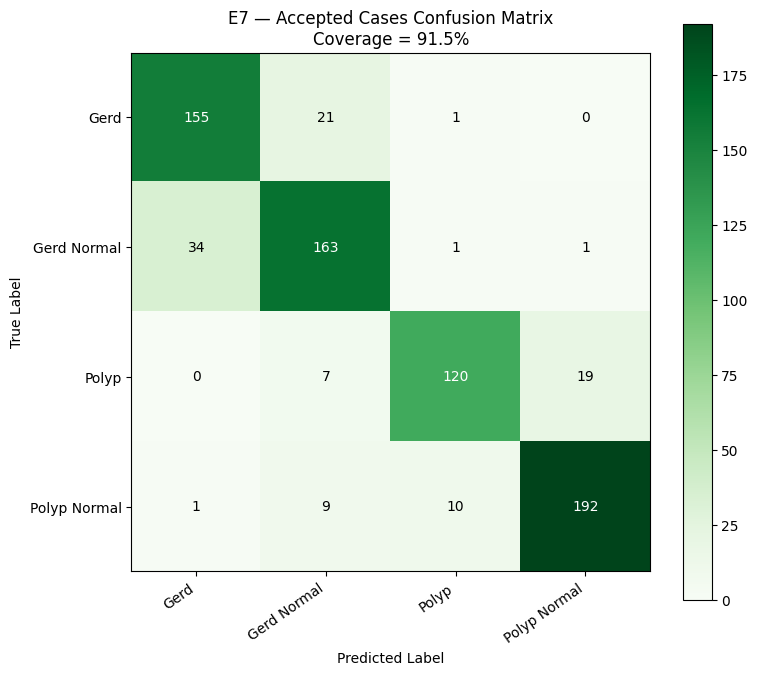

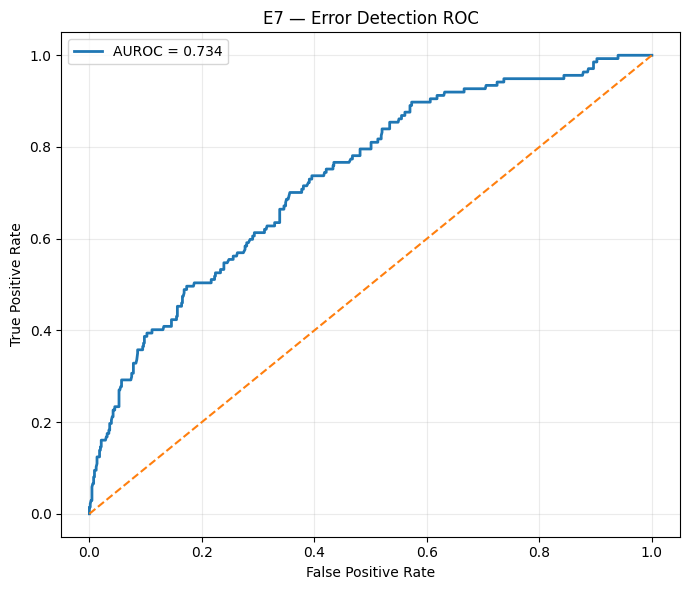

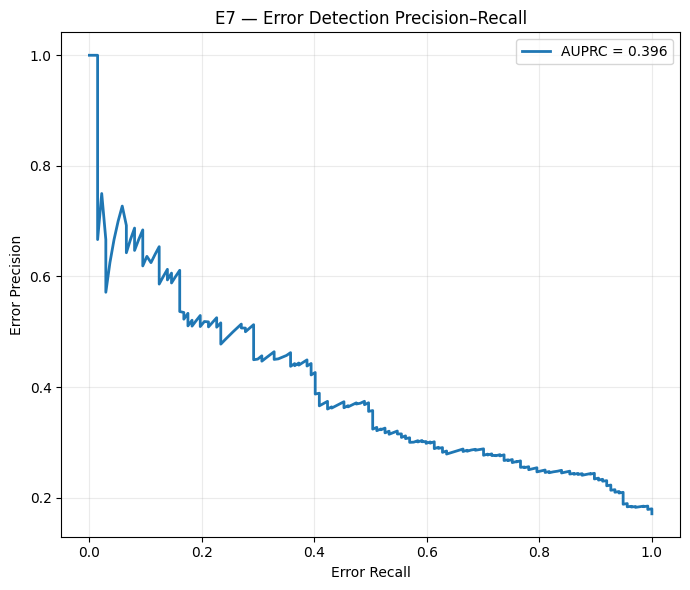

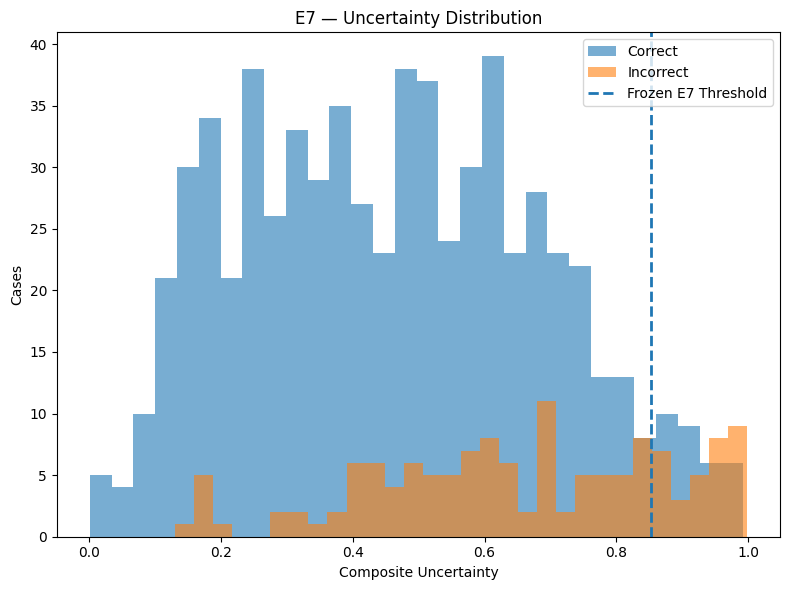

/tmp/ipykernel_1649/537187837.py:2611: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(


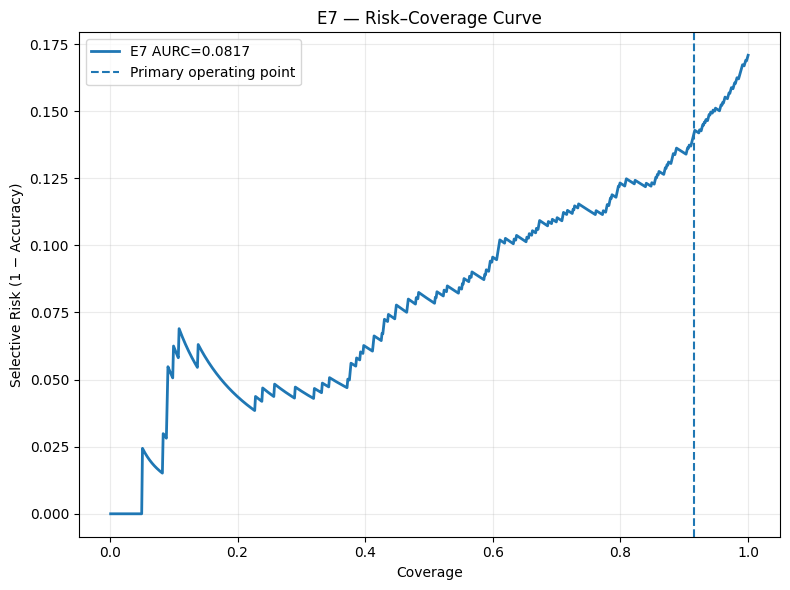


E6 RAW vs E7 SELECTIVE PERFORMANCE
           Metric  E6_Raw  E7_Primary_Accepted  Selective_Change
         Coverage  1.0000               0.9152           -0.0848
         Accuracy  0.8292               0.8583            0.0291
Balanced Accuracy  0.8265               0.8556            0.0291
  Macro Precision  0.8340               0.8614            0.0274
     Macro Recall  0.8265               0.8556            0.0291
         Macro F1  0.8293               0.8577            0.0284
      Weighted F1  0.8294               0.8585            0.0291
              MCC  0.7706               0.8101            0.0394
    Cohen's Kappa  0.7703               0.8097            0.0394

E7 LOCKED TEST EVALUATION COMPLETE
Raw E6 Macro-F1       : 0.8293
E7 accepted Macro-F1  : 0.8577
Test coverage         : 91.52%
Errors rejected       : 24.09%
Error-detection AUROC : 0.7339
Error-detection AUPRC : 0.3958
AURC                  : 0.0817

Saved:
Final metrics: /content/drive/MyDrive/Journal/Buet/GI

In [7]:
# ============================================================
# GI-SAFE — E7 STEP 2
# FINAL LOCKED TEST SELECTIVE EVALUATION
#
# Parent:
#   E6 Anatomy-Conditioned Dual Experts
#
# E7:
#   Frozen E6
#   + Temperature scaling
#   + Class entropy
#   + Router entropy
#   + Router-conditioned expert conflict
#   + Energy
#   + Validation-calibrated rejection
#
# IMPORTANT:
#   ✓ E7 threshold already frozen on 401 validation images
#   ✓ No threshold tuning in this cell
#   ✓ One-time evaluation on 802 locked REAL test images
# ============================================================

import copy
import json
import time
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

E6_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E6_AnatomyDualExperts"
)

E7_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E7_UncertaintyOODRejection"
)

RESULT_DIR = E7_DIR / "results"
FIGURE_DIR = E7_DIR / "figures"
CALIBRATION_DIR = E7_DIR / "calibration"

for d in [
    RESULT_DIR,
    FIGURE_DIR,
    CALIBRATION_DIR
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )


E6_CHECKPOINT = (
    E6_DIR /
    "checkpoints" /
    "best_anatomy_dual_expert_e6.pth"
)

E7_CONFIG_PATH = (
    CALIBRATION_DIR /
    "E7_uncertainty_config.json"
)

E7_REFERENCE_PATH = (
    CALIBRATION_DIR /
    "E7_validation_uncertainty_reference.npz"
)

TEST_CSV = (
    PROJECT_DIR /
    "splits" /
    "test.csv"
)

FINAL_METRICS_PATH = (
    RESULT_DIR /
    "E7_final_selective_test_metrics.json"
)

PREDICTION_PATH = (
    RESULT_DIR /
    "E7_test_uncertainty_predictions.csv"
)

SELECTIVE_TABLE_PATH = (
    RESULT_DIR /
    "E7_test_selective_performance.csv"
)


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

AMP_ENABLED = torch.cuda.is_available()


print("=" * 110)
print("E7 — FINAL LOCKED TEST SELECTIVE EVALUATION")
print("=" * 110)

print(
    "Device:",
    device
)


# ============================================================
# 3. LOAD FROZEN E7 CONFIG
# ============================================================

if not E7_CONFIG_PATH.exists():

    raise FileNotFoundError(
        f"E7 config missing:\n"
        f"{E7_CONFIG_PATH}"
    )


with open(
    E7_CONFIG_PATH,
    "r"
) as f:

    e7_config = json.load(
        f
    )


CLASS_TEMPERATURE = float(
    e7_config[
        "class_temperature"
    ]
)

ROUTER_TEMPERATURE = float(
    e7_config[
        "router_temperature"
    ]
)

PRIMARY_COVERAGE = float(
    e7_config[
        "primary_target_coverage"
    ]
)

PRIMARY_THRESHOLD = float(
    e7_config[
        "primary_threshold"
    ]
)


coverage_thresholds = {

    float(k) / 100.0:
        float(v)

    for k, v in
    e7_config[
        "coverage_thresholds"
    ].items()
}


print("\n" + "=" * 110)
print("FROZEN E7 CONFIGURATION")
print("=" * 110)

print(
    "Class temperature :",
    f"{CLASS_TEMPERATURE:.4f}"
)

print(
    "Router temperature:",
    f"{ROUTER_TEMPERATURE:.4f}"
)

print(
    "Primary coverage  :",
    f"{PRIMARY_COVERAGE:.0%}"
)

print(
    "Primary threshold :",
    f"{PRIMARY_THRESHOLD:.6f}"
)


# ============================================================
# 4. LOAD VALIDATION REFERENCE DISTRIBUTIONS
# ============================================================

if not E7_REFERENCE_PATH.exists():

    raise FileNotFoundError(
        f"E7 validation reference missing:\n"
        f"{E7_REFERENCE_PATH}"
    )


reference = np.load(
    E7_REFERENCE_PATH
)


ref_class_entropy = np.asarray(
    reference[
        "class_entropy"
    ]
)

ref_router_entropy = np.asarray(
    reference[
        "router_entropy"
    ]
)

ref_expert_conflict = np.asarray(
    reference[
        "expert_conflict"
    ]
)

ref_energy = np.asarray(
    reference[
        "energy"
    ]
)


assert len(
    ref_class_entropy
) == 401


print(
    "\n✓ Validation ECDF reference loaded."
)


# ============================================================
# 5. LOAD E6 CHECKPOINT
# ============================================================

checkpoint = torch.load(
    E6_CHECKPOINT,
    map_location="cpu",
    weights_only=False
)


CLASS_NAMES = checkpoint[
    "class_names"
]

CLASS_TO_IDX = checkpoint[
    "class_to_idx"
]

NUM_CLASSES = len(
    CLASS_NAMES
)

IMAGE_SIZE = int(
    checkpoint.get(
        "image_size",
        384
    )
)

BATCH_SIZE = int(
    checkpoint.get(
        "batch_size",
        16
    )
)


# ============================================================
# 6. ANATOMY
# ============================================================

UPPER_GI = 0
LOWER_GI = 1

ANATOMY_NAMES = [
    "Upper-GI",
    "Lower-GI"
]


def class_to_anatomy(
    class_name
):

    name = str(
        class_name
    ).lower()

    if "gerd" in name:

        return UPPER_GI

    if "polyp" in name:

        return LOWER_GI

    raise ValueError(
        f"Unknown anatomy: {class_name}"
    )


CLASS_TO_ANATOMY = {

    CLASS_TO_IDX[cls]:
        class_to_anatomy(cls)

    for cls in CLASS_NAMES
}


# ============================================================
# 7. E6 ARCHITECTURE
# ============================================================

class AnatomyDualExpertResNet50(
    nn.Module
):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        base = models.resnet50(
            weights=None
        )

        self.shared = nn.Sequential(

            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,

            base.layer1,
            base.layer2,
            base.layer3
        )


        self.upper_expert = copy.deepcopy(
            base.layer4
        )

        self.lower_expert = copy.deepcopy(
            base.layer4
        )


        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        self.router = nn.Sequential(

            nn.Linear(
                1024,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                256,
                2
            )
        )


        self.upper_classifier = nn.Sequential(

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


        self.lower_classifier = nn.Sequential(

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        shared = self.shared(
            x
        )


        shared_vec = self.pool(
            shared
        )

        shared_vec = torch.flatten(
            shared_vec,
            1
        )


        router_logits = self.router(
            shared_vec
        )

        gates = torch.softmax(
            router_logits,
            dim=1
        )


        upper = self.upper_expert(
            shared
        )

        upper = self.pool(
            upper
        )

        upper = torch.flatten(
            upper,
            1
        )

        upper_logits = self.upper_classifier(
            upper
        )


        lower = self.lower_expert(
            shared
        )

        lower = self.pool(
            lower
        )

        lower = torch.flatten(
            lower,
            1
        )

        lower_logits = self.lower_classifier(
            lower
        )


        fused_logits = (

            gates[:, 0:1]
            *
            upper_logits

            +

            gates[:, 1:2]
            *
            lower_logits
        )


        return {

            "logits":
                fused_logits,

            "router_logits":
                router_logits,

            "gates":
                gates,

            "upper_logits":
                upper_logits,

            "lower_logits":
                lower_logits
        }


model = AnatomyDualExpertResNet50(
    NUM_CLASSES
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model = model.to(
    device
)

model.eval()


print(
    "✓ Frozen E6 model restored."
)


# ============================================================
# 8. LOAD LOCKED TEST
# ============================================================

test_df = pd.read_csv(
    TEST_CSV
)


assert len(
    test_df
) == 802


# ============================================================
# 9. RESOLVE ORIGINAL IMAGE PATHS
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print(
    "\nIndexing original images..."
)


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower() in IMG_EXTS
    )
]


filename_index = defaultdict(
    list
)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


def normalize_text(
    x
):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower().strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name


    candidates = filename_index.get(
        filename,
        []
    )


    if len(candidates) == 1:

        return str(
            candidates[0]
        )


    if len(candidates) == 0:

        return None


    class_norm = normalize_text(
        class_name
    )


    matches = [

        p

        for p in candidates

        if class_norm in normalize_text(
            str(p.parent)
        )
    ]


    if len(matches) == 1:

        return str(
            matches[0]
        )


    return None


test_df[
    "image_path"
] = test_df.apply(

    lambda row:
        resolve_real_image(
            row[
                "filename"
            ],
            row[
                "class_name"
            ]
        ),

    axis=1
)


missing = int(
    test_df[
        "image_path"
    ].isna().sum()
)


print(
    "Missing test paths:",
    missing
)


if missing > 0:

    raise RuntimeError(
        "Locked test path resolution failed."
    )


# ============================================================
# 10. PREPROCESSING
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        width, height = image.size

        side = max(
            width,
            height
        )


        left = (
            side - width
        ) // 2

        right = (
            side
            -
            width
            -
            left
        )

        top = (
            side - height
        ) // 2

        bottom = (
            side
            -
            height
            -
            top
        )


        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 11. TEST DATASET
# ============================================================

class E7TestDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy = CLASS_TO_ANATOMY[
            label
        ]


        return (
            image,
            label,
            anatomy
        )


test_dataset = E7TestDataset(
    test_df
)


test_loader = DataLoader(

    test_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    drop_last=False
)


# ============================================================
# 12. RUN E6 ON LOCKED TEST
# ============================================================

all_labels = []
all_anatomy = []

all_logits = []
all_router_logits = []

all_upper_logits = []
all_lower_logits = []


total_inference_time = 0.0


print("\n" + "=" * 110)
print("RUNNING LOCKED 802-IMAGE REAL TEST")
print("=" * 110)


with torch.no_grad():

    for (
        images,
        labels,
        anatomy
    ) in test_loader:


        images = images.to(
            device,
            non_blocking=True
        )


        if torch.cuda.is_available():

            torch.cuda.synchronize()


        start = time.perf_counter()


        with torch.amp.autocast(

            device_type=(
                "cuda"
                if torch.cuda.is_available()
                else "cpu"
            ),

            enabled=AMP_ENABLED
        ):

            outputs = model(
                images
            )


        if torch.cuda.is_available():

            torch.cuda.synchronize()


        total_inference_time += (
            time.perf_counter()
            -
            start
        )


        all_labels.append(
            labels.numpy()
        )

        all_anatomy.append(
            anatomy.numpy()
        )


        all_logits.append(
            outputs[
                "logits"
            ]
            .cpu()
        )


        all_router_logits.append(
            outputs[
                "router_logits"
            ]
            .cpu()
        )


        all_upper_logits.append(
            outputs[
                "upper_logits"
            ]
            .cpu()
        )


        all_lower_logits.append(
            outputs[
                "lower_logits"
            ]
            .cpu()
        )


y_true = np.concatenate(
    all_labels
)

anatomy_true = np.concatenate(
    all_anatomy
)


raw_logits = torch.cat(
    all_logits,
    dim=0
)


router_logits = torch.cat(
    all_router_logits,
    dim=0
)


upper_logits = torch.cat(
    all_upper_logits,
    dim=0
)


lower_logits = torch.cat(
    all_lower_logits,
    dim=0
)


assert len(
    y_true
) == 802


# ============================================================
# 13. CALIBRATED CLASS / ROUTER PROBABILITY
# ============================================================

scaled_logits = (

    raw_logits

    /

    CLASS_TEMPERATURE
)


scaled_router_logits = (

    router_logits

    /

    ROUTER_TEMPERATURE
)


class_prob = torch.softmax(
    scaled_logits,
    dim=1
).numpy()


router_prob = torch.softmax(
    scaled_router_logits,
    dim=1
).numpy()


# Expert probabilities remain consistent
# with E7 validation calibration.
upper_prob = torch.softmax(
    upper_logits,
    dim=1
).numpy()

lower_prob = torch.softmax(
    lower_logits,
    dim=1
).numpy()


y_pred = np.argmax(
    class_prob,
    axis=1
)


# ============================================================
# 14. UNCERTAINTY COMPONENT 1
# CLASS ENTROPY
# ============================================================

class_entropy = -np.sum(

    class_prob

    *

    np.log(
        class_prob
        +
        1e-12
    ),

    axis=1
)


class_entropy_norm = (

    class_entropy

    /

    np.log(
        NUM_CLASSES
    )
)


# ============================================================
# 15. COMPONENT 2
# ROUTER ENTROPY
# ============================================================

router_entropy = -np.sum(

    router_prob

    *

    np.log(
        router_prob
        +
        1e-12
    ),

    axis=1
)


router_entropy_norm = (

    router_entropy

    /

    np.log(2)
)


# ============================================================
# 16. COMPONENT 3
# EXPERT JS DISAGREEMENT
# ============================================================

mixture = (

    upper_prob
    +
    lower_prob

) / 2.0


kl_upper = np.sum(

    upper_prob

    *

    np.log(
        (
            upper_prob
            +
            1e-12
        )
        /
        (
            mixture
            +
            1e-12
        )
    ),

    axis=1
)


kl_lower = np.sum(

    lower_prob

    *

    np.log(
        (
            lower_prob
            +
            1e-12
        )
        /
        (
            mixture
            +
            1e-12
        )
    ),

    axis=1
)


js = (

    kl_upper
    +
    kl_lower

) / 2.0


js_norm = (

    js

    /

    np.log(2)
)


# Router-conditioned expert conflict
expert_conflict = (

    js_norm

    *

    router_entropy_norm
)


# ============================================================
# 17. COMPONENT 4
# CORRECT ENERGY
#
# E(x) = -T logsumexp(z/T)
# ============================================================

scaled_logits_np = (
    scaled_logits
    .numpy()
)


max_logit = np.max(
    scaled_logits_np,
    axis=1,
    keepdims=True
)


logsumexp = (

    max_logit.squeeze(1)

    +

    np.log(
        np.sum(
            np.exp(
                scaled_logits_np
                -
                max_logit
            ),
            axis=1
        )
        +
        1e-12
    )
)


energy = (

    -CLASS_TEMPERATURE

    *

    logsumexp
)


# ============================================================
# 18. VALIDATION ECDF MAPPING
#
# CRITICAL:
# Do NOT rank within test.
# Test values are mapped against frozen validation reference.
# ============================================================

def validation_ecdf(
    value_array,
    reference_array
):

    reference_sorted = np.sort(
        np.asarray(
            reference_array
        )
    )


    values = np.asarray(
        value_array
    )


    ranks = np.searchsorted(

        reference_sorted,

        values,

        side="right"
    )


    return (

        ranks

        /

        len(
            reference_sorted
        )
    )


class_entropy_pct = validation_ecdf(

    class_entropy_norm,

    ref_class_entropy
)


router_entropy_pct = validation_ecdf(

    router_entropy_norm,

    ref_router_entropy
)


expert_conflict_pct = validation_ecdf(

    expert_conflict,

    ref_expert_conflict
)


energy_pct = validation_ecdf(

    energy,

    ref_energy
)


# ============================================================
# 19. FINAL COMPOSITE UNCERTAINTY
# ============================================================

composite_uncertainty = (

    class_entropy_pct

    +

    router_entropy_pct

    +

    expert_conflict_pct

    +

    energy_pct

) / 4.0


# ============================================================
# 20. RAW E6 PERFORMANCE
#
# Temperature scaling does not alter argmax.
# ============================================================

raw_accuracy = accuracy_score(
    y_true,
    y_pred
)


raw_balanced_accuracy = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)


raw_macro_precision = precision_score(

    y_true,
    y_pred,

    average="macro",

    zero_division=0
)


raw_macro_recall = recall_score(

    y_true,
    y_pred,

    average="macro",

    zero_division=0
)


raw_macro_f1 = f1_score(

    y_true,
    y_pred,

    average="macro",

    zero_division=0
)


raw_weighted_f1 = f1_score(

    y_true,
    y_pred,

    average="weighted",

    zero_division=0
)


raw_mcc = matthews_corrcoef(
    y_true,
    y_pred
)


raw_kappa = cohen_kappa_score(
    y_true,
    y_pred
)


print("\n" + "=" * 110)
print("RAW E6 PERFORMANCE — BEFORE REJECTION")
print("=" * 110)

print(
    f"Accuracy          : "
    f"{raw_accuracy:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{raw_balanced_accuracy:.4f}"
)

print(
    f"Macro F1          : "
    f"{raw_macro_f1:.4f}"
)

print(
    f"MCC               : "
    f"{raw_mcc:.4f}"
)


# ============================================================
# 21. TEST ERROR-DETECTION QUALITY
#
# This is evaluation only.
# No threshold is changed.
# ============================================================

error_label = (
    y_pred
    !=
    y_true
).astype(int)


error_detection_auroc = (
    roc_auc_score(
        error_label,
        composite_uncertainty
    )
)


error_detection_auprc = (
    average_precision_score(
        error_label,
        composite_uncertainty
    )
)


print("\n" + "=" * 110)
print("TEST ERROR-DETECTION PERFORMANCE")
print("=" * 110)

print(
    f"AUROC : "
    f"{error_detection_auroc:.4f}"
)

print(
    f"AUPRC : "
    f"{error_detection_auprc:.4f}"
)


# ============================================================
# 22. FIXED VALIDATION-DEFINED OPERATING POINTS
# ============================================================

selective_rows = []


total_errors = int(
    error_label.sum()
)


for target_coverage in sorted(
    coverage_thresholds.keys(),
    reverse=True
):


    threshold = coverage_thresholds[
        target_coverage
    ]


    accepted = (
        composite_uncertainty
        <=
        threshold
    )


    rejected = (
        ~accepted
    )


    accepted_n = int(
        accepted.sum()
    )


    rejected_n = int(
        rejected.sum()
    )


    actual_coverage = float(
        accepted.mean()
    )


    if accepted_n > 0:

        accepted_accuracy = accuracy_score(

            y_true[
                accepted
            ],

            y_pred[
                accepted
            ]
        )


        accepted_bal_acc = (
            balanced_accuracy_score(

                y_true[
                    accepted
                ],

                y_pred[
                    accepted
                ]
            )
        )


        accepted_precision = precision_score(

            y_true[
                accepted
            ],

            y_pred[
                accepted
            ],

            average="macro",

            zero_division=0
        )


        accepted_recall = recall_score(

            y_true[
                accepted
            ],

            y_pred[
                accepted
            ],

            average="macro",

            zero_division=0
        )


        accepted_f1 = f1_score(

            y_true[
                accepted
            ],

            y_pred[
                accepted
            ],

            average="macro",

            zero_division=0
        )


        accepted_mcc = matthews_corrcoef(

            y_true[
                accepted
            ],

            y_pred[
                accepted
            ]
        )


    else:

        accepted_accuracy = np.nan
        accepted_bal_acc = np.nan
        accepted_precision = np.nan
        accepted_recall = np.nan
        accepted_f1 = np.nan
        accepted_mcc = np.nan


    rejected_errors = int(
        (
            rejected
            &
            (
                error_label == 1
            )
        ).sum()
    )


    rejected_correct = int(
        (
            rejected
            &
            (
                error_label == 0
            )
        ).sum()
    )


    error_rejection_rate = (

        rejected_errors

        /

        total_errors

        if total_errors > 0

        else np.nan
    )


    rejection_precision = (

        rejected_errors

        /

        rejected_n

        if rejected_n > 0

        else np.nan
    )


    selective_rows.append({

        "Target_Validation_Coverage":
            target_coverage,

        "Frozen_Threshold":
            threshold,

        "Test_Actual_Coverage":
            actual_coverage,

        "Accepted":
            accepted_n,

        "Rejected":
            rejected_n,

        "Accepted_Accuracy":
            accepted_accuracy,

        "Accepted_Balanced_Accuracy":
            accepted_bal_acc,

        "Accepted_Macro_Precision":
            accepted_precision,

        "Accepted_Macro_Recall":
            accepted_recall,

        "Accepted_Macro_F1":
            accepted_f1,

        "Accepted_MCC":
            accepted_mcc,

        "Rejected_Errors":
            rejected_errors,

        "Rejected_Correct":
            rejected_correct,

        "Error_Rejection_Rate":
            error_rejection_rate,

        "Rejection_Precision":
            rejection_precision
    })


selective_df = pd.DataFrame(
    selective_rows
)


selective_df.to_csv(
    SELECTIVE_TABLE_PATH,
    index=False
)


print("\n" + "=" * 125)
print("E7 LOCKED TEST — FIXED VALIDATION-DERIVED OPERATING POINTS")
print("=" * 125)

print(
    selective_df
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 23. PRIMARY 90% OPERATING POINT
# ============================================================

primary_accept = (

    composite_uncertainty

    <=

    PRIMARY_THRESHOLD
)


primary_reject = (
    ~primary_accept
)


accepted_true = y_true[
    primary_accept
]

accepted_pred = y_pred[
    primary_accept
]


primary_accuracy = accuracy_score(
    accepted_true,
    accepted_pred
)


primary_bal_acc = (
    balanced_accuracy_score(
        accepted_true,
        accepted_pred
    )
)


primary_precision = precision_score(

    accepted_true,
    accepted_pred,

    average="macro",

    zero_division=0
)


primary_recall = recall_score(

    accepted_true,
    accepted_pred,

    average="macro",

    zero_division=0
)


primary_macro_f1 = f1_score(

    accepted_true,
    accepted_pred,

    average="macro",

    zero_division=0
)


primary_weighted_f1 = f1_score(

    accepted_true,
    accepted_pred,

    average="weighted",

    zero_division=0
)


primary_mcc = matthews_corrcoef(
    accepted_true,
    accepted_pred
)


primary_kappa = cohen_kappa_score(
    accepted_true,
    accepted_pred
)


primary_rejected_errors = int(

    (
        primary_reject

        &

        (
            error_label == 1
        )
    ).sum()
)


primary_error_rejection_rate = (

    primary_rejected_errors

    /

    total_errors
)


print("\n" + "=" * 110)
print("E7 PRIMARY SAFETY OPERATING POINT — 90% VALIDATION COVERAGE")
print("=" * 110)

print(
    "Frozen threshold       :",
    f"{PRIMARY_THRESHOLD:.6f}"
)

print(
    "Actual TEST coverage   :",
    f"{primary_accept.mean():.2%}"
)

print(
    "Accepted               :",
    int(
        primary_accept.sum()
    )
)

print(
    "Rejected               :",
    int(
        primary_reject.sum()
    )
)


print(
    f"\nAccepted Accuracy      : "
    f"{primary_accuracy:.4f}"
)

print(
    f"Accepted Balanced Acc. : "
    f"{primary_bal_acc:.4f}"
)

print(
    f"Accepted Macro Prec.   : "
    f"{primary_precision:.4f}"
)

print(
    f"Accepted Macro Recall  : "
    f"{primary_recall:.4f}"
)

print(
    f"Accepted Macro F1      : "
    f"{primary_macro_f1:.4f}"
)

print(
    f"Accepted Weighted F1   : "
    f"{primary_weighted_f1:.4f}"
)

print(
    f"Accepted MCC           : "
    f"{primary_mcc:.4f}"
)

print(
    f"Accepted Cohen Kappa   : "
    f"{primary_kappa:.4f}"
)


print(
    f"\nErrors rejected         : "
    f"{primary_rejected_errors}/{total_errors}"
)

print(
    f"Error rejection rate   : "
    f"{primary_error_rejection_rate:.2%}"
)


# ============================================================
# 24. SAVE SAMPLE-LEVEL RESULTS
# ============================================================

prediction_df = (
    test_df
    .copy()
    .reset_index(
        drop=True
    )
)


prediction_df[
    "true_id"
] = y_true


prediction_df[
    "predicted_id"
] = y_pred


prediction_df[
    "true_class"
] = [
    CLASS_NAMES[i]
    for i in y_true
]


prediction_df[
    "predicted_class"
] = [
    CLASS_NAMES[i]
    for i in y_pred
]


prediction_df[
    "correct"
] = (
    y_true
    ==
    y_pred
)


prediction_df[
    "confidence"
] = np.max(
    class_prob,
    axis=1
)


prediction_df[
    "class_entropy"
] = class_entropy_norm


prediction_df[
    "router_entropy"
] = router_entropy_norm


prediction_df[
    "expert_conflict"
] = expert_conflict


prediction_df[
    "energy"
] = energy


prediction_df[
    "class_entropy_percentile"
] = class_entropy_pct


prediction_df[
    "router_entropy_percentile"
] = router_entropy_pct


prediction_df[
    "expert_conflict_percentile"
] = expert_conflict_pct


prediction_df[
    "energy_percentile"
] = energy_pct


prediction_df[
    "composite_uncertainty"
] = composite_uncertainty


prediction_df[
    "E7_primary_accept"
] = primary_accept


prediction_df[
    "E7_action"
] = np.where(

    primary_accept,

    "ACCEPT",

    "REJECT_REVIEW"
)


prediction_df.to_csv(
    PREDICTION_PATH,
    index=False
)


# ============================================================
# 25. PRIMARY ACCEPTED CONFUSION MATRIX — GREENS
# ============================================================

accepted_cm = confusion_matrix(

    accepted_true,

    accepted_pred,

    labels=np.arange(
        NUM_CLASSES
    )
)


plt.figure(
    figsize=(8, 7)
)


plt.imshow(
    accepted_cm,
    cmap="Greens",
    interpolation="nearest"
)


plt.title(
    "E7 — Accepted Cases Confusion Matrix\n"
    f"Coverage = {primary_accept.mean():.1%}"
)


plt.colorbar()


ticks = np.arange(
    NUM_CLASSES
)


plt.xticks(
    ticks,
    CLASS_NAMES,
    rotation=35,
    ha="right"
)


plt.yticks(
    ticks,
    CLASS_NAMES
)


threshold_cm = (
    accepted_cm.max()
    /
    2
)


for i in range(
    NUM_CLASSES
):

    for j in range(
        NUM_CLASSES
    ):

        plt.text(

            j,
            i,

            str(
                accepted_cm[
                    i,
                    j
                ]
            ),

            ha="center",
            va="center",

            color=(
                "white"
                if accepted_cm[
                    i,
                    j
                ]
                >
                threshold_cm
                else
                "black"
            )
        )


plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)


plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "E7_primary_accepted_confusion_matrix.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 26. ERROR-DETECTION ROC
# ============================================================

fpr, tpr, _ = roc_curve(
    error_label,
    composite_uncertainty
)


plt.figure(
    figsize=(7, 6)
)


plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"AUROC = "
        f"{error_detection_auroc:.3f}"
    )
)


plt.plot(
    [0, 1],
    [0, 1],
    "--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "E7 — Error Detection ROC"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "E7_error_detection_ROC.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 27. ERROR-DETECTION PR
# ============================================================

precision_curve, recall_curve, _ = (
    precision_recall_curve(

        error_label,

        composite_uncertainty
    )
)


plt.figure(
    figsize=(7, 6)
)


plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=(
        f"AUPRC = "
        f"{error_detection_auprc:.3f}"
    )
)


plt.xlabel(
    "Error Recall"
)

plt.ylabel(
    "Error Precision"
)

plt.title(
    "E7 — Error Detection Precision–Recall"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "E7_error_detection_PR.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 28. UNCERTAINTY — CORRECT VS INCORRECT
# ============================================================

correct_scores = composite_uncertainty[
    error_label == 0
]


incorrect_scores = composite_uncertainty[
    error_label == 1
]


plt.figure(
    figsize=(8, 6)
)


plt.hist(
    correct_scores,
    bins=30,
    alpha=0.6,
    label="Correct"
)


plt.hist(
    incorrect_scores,
    bins=30,
    alpha=0.6,
    label="Incorrect"
)


plt.axvline(
    PRIMARY_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label="Frozen E7 Threshold"
)


plt.xlabel(
    "Composite Uncertainty"
)

plt.ylabel(
    "Cases"
)

plt.title(
    "E7 — Uncertainty Distribution"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "E7_correct_vs_error_uncertainty.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 29. RISK-COVERAGE CURVE
#
# Evaluation curve only.
# Does NOT redefine primary threshold.
# ============================================================

order = np.argsort(
    composite_uncertainty
)


sorted_correct = (
    error_label[
        order
    ]
    ==
    0
)


coverages = []
risks = []


for k in range(
    1,
    len(y_true) + 1
):

    accepted_correct = (
        sorted_correct[
            :k
        ]
    )


    coverage = (
        k
        /
        len(y_true)
    )


    risk = (
        1.0
        -
        accepted_correct.mean()
    )


    coverages.append(
        coverage
    )

    risks.append(
        risk
    )


coverages = np.asarray(
    coverages
)

risks = np.asarray(
    risks
)


aurc = float(
    np.trapz(
        risks,
        coverages
    )
)


plt.figure(
    figsize=(8, 6)
)


plt.plot(
    coverages,
    risks,
    linewidth=2,
    label=(
        f"E7 AURC={aurc:.4f}"
    )
)


plt.axvline(
    primary_accept.mean(),
    linestyle="--",
    label="Primary operating point"
)


plt.xlabel(
    "Coverage"
)

plt.ylabel(
    "Selective Risk (1 − Accuracy)"
)

plt.title(
    "E7 — Risk–Coverage Curve"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "E7_risk_coverage_curve.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 30. SAVE FINAL E7 SUMMARY
# ============================================================

final_metrics = {

    "experiment":
        "E7_UncertaintyOODRejection",

    "parent":
        "E6_AnatomyDualExperts",

    "locked_test_images":
        802,

    "raw_e6": {

        "accuracy":
            float(
                raw_accuracy
            ),

        "balanced_accuracy":
            float(
                raw_balanced_accuracy
            ),

        "macro_precision":
            float(
                raw_macro_precision
            ),

        "macro_recall":
            float(
                raw_macro_recall
            ),

        "macro_f1":
            float(
                raw_macro_f1
            ),

        "weighted_f1":
            float(
                raw_weighted_f1
            ),

        "mcc":
            float(
                raw_mcc
            ),

        "cohen_kappa":
            float(
                raw_kappa
            )
    },


    "error_detection": {

        "auroc":
            float(
                error_detection_auroc
            ),

        "auprc":
            float(
                error_detection_auprc
            )
    },


    "primary_operating_point": {

        "target_validation_coverage":
            float(
                PRIMARY_COVERAGE
            ),

        "frozen_threshold":
            float(
                PRIMARY_THRESHOLD
            ),

        "actual_test_coverage":
            float(
                primary_accept.mean()
            ),

        "accepted_cases":
            int(
                primary_accept.sum()
            ),

        "rejected_cases":
            int(
                primary_reject.sum()
            ),

        "accepted_accuracy":
            float(
                primary_accuracy
            ),

        "accepted_balanced_accuracy":
            float(
                primary_bal_acc
            ),

        "accepted_macro_precision":
            float(
                primary_precision
            ),

        "accepted_macro_recall":
            float(
                primary_recall
            ),

        "accepted_macro_f1":
            float(
                primary_macro_f1
            ),

        "accepted_weighted_f1":
            float(
                primary_weighted_f1
            ),

        "accepted_mcc":
            float(
                primary_mcc
            ),

        "accepted_cohen_kappa":
            float(
                primary_kappa
            ),

        "total_raw_errors":
            int(
                total_errors
            ),

        "errors_rejected":
            int(
                primary_rejected_errors
            ),

        "error_rejection_rate":
            float(
                primary_error_rejection_rate
            )
    },


    "aurc":
        float(
            aurc
        ),


    "class_temperature":
        float(
            CLASS_TEMPERATURE
        ),

    "router_temperature":
        float(
            ROUTER_TEMPERATURE
        ),

    "uncertainty_threshold_source":
        "401-image validation set",

    "test_threshold_tuning":
        False
}


with open(
    FINAL_METRICS_PATH,
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=4
    )


# ============================================================
# 31. RAW E6 vs SELECTIVE E7 SUMMARY
# ============================================================

summary_comparison = pd.DataFrame({

    "Metric": [

        "Coverage",
        "Accuracy",
        "Balanced Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1",
        "MCC",
        "Cohen's Kappa"

    ],


    "E6_Raw": [

        1.0,
        raw_accuracy,
        raw_balanced_accuracy,
        raw_macro_precision,
        raw_macro_recall,
        raw_macro_f1,
        raw_weighted_f1,
        raw_mcc,
        raw_kappa

    ],


    "E7_Primary_Accepted": [

        primary_accept.mean(),
        primary_accuracy,
        primary_bal_acc,
        primary_precision,
        primary_recall,
        primary_macro_f1,
        primary_weighted_f1,
        primary_mcc,
        primary_kappa

    ]
})


summary_comparison[
    "Selective_Change"
] = (

    summary_comparison[
        "E7_Primary_Accepted"
    ]

    -

    summary_comparison[
        "E6_Raw"
    ]
)


summary_comparison.to_csv(

    RESULT_DIR /
    "E6_vs_E7_selective_comparison.csv",

    index=False
)


print("\n" + "=" * 110)
print("E6 RAW vs E7 SELECTIVE PERFORMANCE")
print("=" * 110)

print(
    summary_comparison
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 32. FINAL
# ============================================================

print("\n" + "=" * 110)
print("E7 LOCKED TEST EVALUATION COMPLETE")
print("=" * 110)


print(
    "Raw E6 Macro-F1       :",
    f"{raw_macro_f1:.4f}"
)

print(
    "E7 accepted Macro-F1  :",
    f"{primary_macro_f1:.4f}"
)

print(
    "Test coverage         :",
    f"{primary_accept.mean():.2%}"
)

print(
    "Errors rejected       :",
    f"{primary_error_rejection_rate:.2%}"
)

print(
    "Error-detection AUROC :",
    f"{error_detection_auroc:.4f}"
)

print(
    "Error-detection AUPRC :",
    f"{error_detection_auprc:.4f}"
)

print(
    "AURC                  :",
    f"{aurc:.4f}"
)


print("\nSaved:")

print(
    "Final metrics:",
    FINAL_METRICS_PATH
)

print(
    "Predictions:",
    PREDICTION_PATH
)

print(
    "Selective table:",
    SELECTIVE_TABLE_PATH
)


print("\nIMPORTANT:")

print(
    "✓ Threshold came only from validation."
)

print(
    "✓ Test scores were NOT used to change E7."
)

print(
    "✓ E7 is now frozen."
)

print("=" * 110)

RUNNING E7 DISTRIBUTION-SHIFT STRESS TEST

Evaluating: Clean

Evaluating: Gaussian Noise

Evaluating: Gaussian Blur

Evaluating: Low Light

Evaluating: High Exposure

Evaluating: Rotation

Evaluating: JPEG Compression

E7 DISTRIBUTION-SHIFT / OOD-LIKE STRESS RESULTS
       Condition   N  Raw_Accuracy  Raw_Balanced_Accuracy  Raw_Macro_F1  Mean_Uncertainty  Median_Uncertainty  Coverage  Rejection_Rate  Accepted_Accuracy  Accepted_Balanced_Accuracy  Accepted_Macro_F1  Raw_Errors  Rejected_Errors  Error_Rejection_Rate
           Clean 802        0.8292                 0.8265        0.8293            0.4926              0.4900    0.9152          0.0848             0.8583                      0.8556             0.8577         137               33                0.2409
  Gaussian Noise 802        0.6970                 0.7102        0.6961            0.7958              0.8541    0.4975          0.5025             0.8145                      0.8140             0.8120         243              

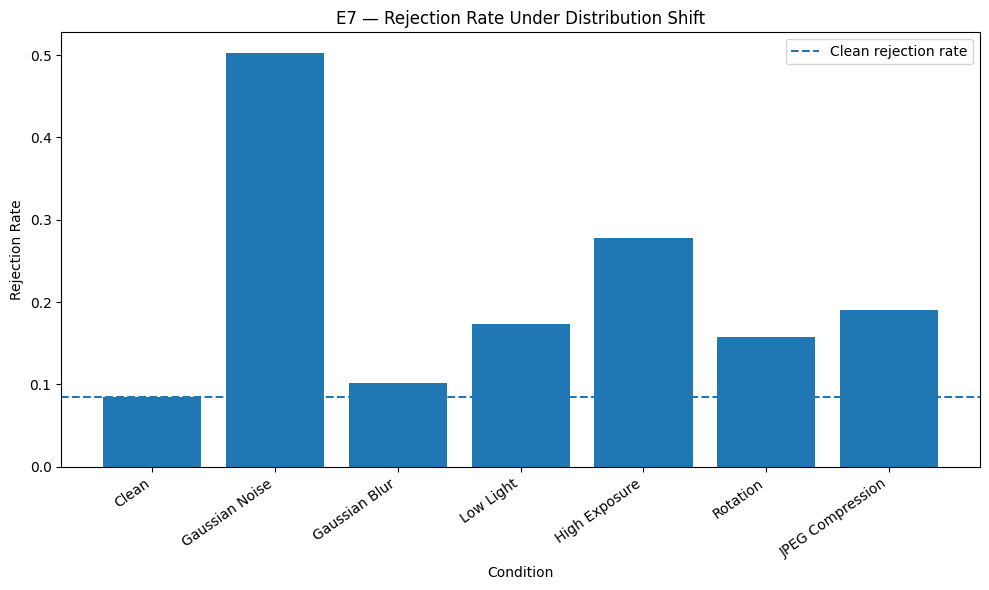

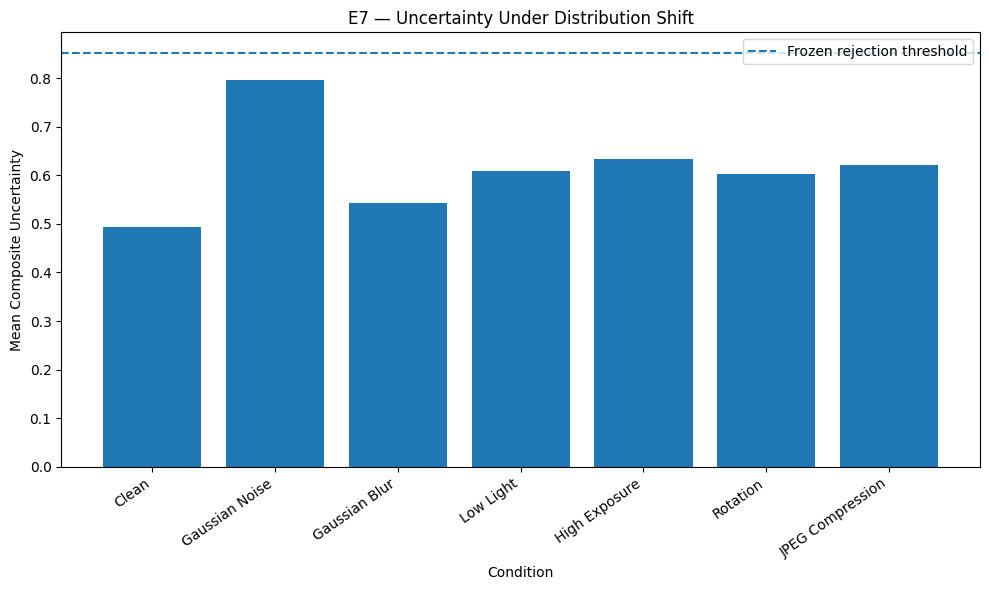

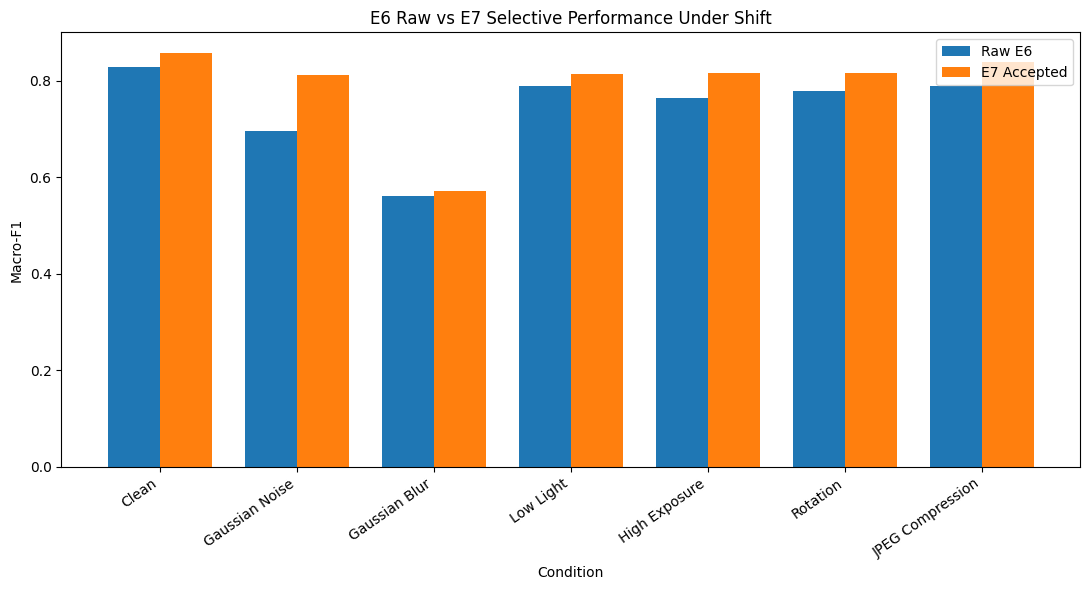


E7 DISTRIBUTION-SHIFT STRESS EVALUATION COMPLETE
Clean rejection rate       : 8.48%
Mean shifted rejection     : 23.40%
Clean mean uncertainty     : 0.4926
Mean shifted uncertainty   : 0.6338
Mean shift-detection AUROC : 0.6626

Saved:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E7_UncertaintyOODRejection/results/E7_distribution_shift_stress_results.csv
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E7_UncertaintyOODRejection/results/E7_distribution_shift_sample_scores.csv
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/E7_UncertaintyOODRejection/results/E7_distribution_shift_summary.json

✓ Frozen E7 threshold retained.
✓ No stress-test threshold tuning.
✓ E7 experimental sequence complete.


In [8]:
# ============================================================
# GI-SAFE — E7 STEP 3
# DISTRIBUTION-SHIFT / OOD-LIKE STRESS EVALUATION
#
# IMPORTANT:
#   ✓ Frozen E6 model
#   ✓ Frozen E7 temperatures
#   ✓ Frozen validation ECDF
#   ✓ Frozen E7 rejection threshold
#   ✓ NO threshold tuning
#
# Stress conditions:
#   1. Clean
#   2. Gaussian noise
#   3. Gaussian blur
#   4. Low illumination
#   5. High exposure
#   6. Rotation
#   7. JPEG degradation
#
# These are COVARIATE-SHIFT / OOD-LIKE tests,
# not a substitute for an external OOD dataset.
# ============================================================

import io
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import (
    Image,
    ImageFilter,
    ImageEnhance
)

import torch

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)


# ============================================================
# 1. CHECK REQUIRED OBJECTS FROM E7 STEP 2
# ============================================================

required_objects = [

    "model",
    "test_df",
    "CLASS_NAMES",
    "CLASS_TO_IDX",
    "CLASS_TO_ANATOMY",
    "NUM_CLASSES",

    "TRANSFORM",

    "CLASS_TEMPERATURE",
    "ROUTER_TEMPERATURE",

    "PRIMARY_THRESHOLD",

    "ref_class_entropy",
    "ref_router_entropy",
    "ref_expert_conflict",
    "ref_energy",

    "device"
]


missing_objects = [

    name

    for name in required_objects

    if name not in globals()
]


if missing_objects:

    raise RuntimeError(
        "Missing E7 runtime objects:\n"
        + "\n".join(missing_objects)
        + "\n\nRun the E7 locked-test evaluation cell first."
    )


# ============================================================
# 2. OUTPUT PATHS
# ============================================================

E7_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE/"
    "experiments/E7_UncertaintyOODRejection"
)

RESULT_DIR = (
    E7_DIR /
    "results"
)

FIGURE_DIR = (
    E7_DIR /
    "figures"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


STRESS_RESULTS_PATH = (
    RESULT_DIR /
    "E7_distribution_shift_stress_results.csv"
)

STRESS_SAMPLE_PATH = (
    RESULT_DIR /
    "E7_distribution_shift_sample_scores.csv"
)

STRESS_JSON_PATH = (
    RESULT_DIR /
    "E7_distribution_shift_summary.json"
)


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

STRESS_SEED = 2026

np.random.seed(
    STRESS_SEED
)


# ============================================================
# 4. CORRUPTION FUNCTIONS
# ============================================================

def apply_corruption(
    image,
    corruption,
    index
):

    image = image.convert(
        "RGB"
    )


    # --------------------------------------------------------
    # CLEAN
    # --------------------------------------------------------

    if corruption == "Clean":

        return image


    # --------------------------------------------------------
    # GAUSSIAN NOISE
    # sigma ≈ 0.10 on [0,1]
    # --------------------------------------------------------

    elif corruption == "Gaussian Noise":

        arr = np.asarray(
            image
        ).astype(
            np.float32
        ) / 255.0


        # deterministic per image
        rng = np.random.default_rng(
            STRESS_SEED
            +
            index
        )


        noise = rng.normal(

            loc=0.0,

            scale=0.10,

            size=arr.shape
        )


        arr = np.clip(
            arr + noise,
            0.0,
            1.0
        )


        arr = (
            arr * 255
        ).astype(
            np.uint8
        )


        return Image.fromarray(
            arr
        )


    # --------------------------------------------------------
    # BLUR
    # --------------------------------------------------------

    elif corruption == "Gaussian Blur":

        return image.filter(

            ImageFilter.GaussianBlur(
                radius=3.0
            )
        )


    # --------------------------------------------------------
    # LOW LIGHT
    # --------------------------------------------------------

    elif corruption == "Low Light":

        enhancer = ImageEnhance.Brightness(
            image
        )


        return enhancer.enhance(
            0.45
        )


    # --------------------------------------------------------
    # HIGH EXPOSURE
    # --------------------------------------------------------

    elif corruption == "High Exposure":

        enhancer = ImageEnhance.Brightness(
            image
        )


        return enhancer.enhance(
            1.65
        )


    # --------------------------------------------------------
    # ROTATION
    # --------------------------------------------------------

    elif corruption == "Rotation":

        return image.rotate(

            30,

            resample=
                Image.Resampling.BILINEAR,

            expand=False,

            fillcolor=(0, 0, 0)
        )


    # --------------------------------------------------------
    # JPEG DEGRADATION
    # --------------------------------------------------------

    elif corruption == "JPEG Compression":

        buffer = io.BytesIO()


        image.save(

            buffer,

            format="JPEG",

            quality=20
        )


        buffer.seek(0)


        degraded = Image.open(
            buffer
        ).convert(
            "RGB"
        )


        return degraded


    else:

        raise ValueError(
            f"Unknown corruption: {corruption}"
        )


# ============================================================
# 5. STRESS DATASET
# ============================================================

class StressDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        corruption
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.corruption = corruption


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = apply_corruption(

            image,

            self.corruption,

            idx
        )


        image = TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy = CLASS_TO_ANATOMY[
            label
        ]


        return (
            image,
            label,
            anatomy,
            idx
        )


# ============================================================
# 6. VALIDATION ECDF MAPPING
# ============================================================

def validation_ecdf(
    values,
    reference
):

    reference = np.sort(
        np.asarray(
            reference
        )
    )


    values = np.asarray(
        values
    )


    rank = np.searchsorted(

        reference,

        values,

        side="right"
    )


    return (
        rank
        /
        len(
            reference
        )
    )


# ============================================================
# 7. UNCERTAINTY SCORING
# ============================================================

def score_condition(
    corruption
):

    dataset = StressDataset(

        test_df,

        corruption
    )


    loader = DataLoader(

        dataset,

        batch_size=16,

        shuffle=False,

        num_workers=2,

        pin_memory=True,

        drop_last=False
    )


    labels_all = []
    index_all = []

    logits_all = []
    router_logits_all = []

    upper_logits_all = []
    lower_logits_all = []


    model.eval()


    with torch.no_grad():

        for (
            images,
            labels,
            anatomy,
            indexes
        ) in loader:


            images = images.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast(

                device_type=(
                    "cuda"
                    if torch.cuda.is_available()
                    else "cpu"
                ),

                enabled=
                    torch.cuda.is_available()
            ):

                outputs = model(
                    images
                )


            labels_all.append(
                labels.numpy()
            )


            index_all.append(
                indexes.numpy()
            )


            logits_all.append(
                outputs[
                    "logits"
                ].cpu()
            )


            router_logits_all.append(
                outputs[
                    "router_logits"
                ].cpu()
            )


            upper_logits_all.append(
                outputs[
                    "upper_logits"
                ].cpu()
            )


            lower_logits_all.append(
                outputs[
                    "lower_logits"
                ].cpu()
            )


    y_true_local = np.concatenate(
        labels_all
    )


    indexes_local = np.concatenate(
        index_all
    )


    logits = torch.cat(
        logits_all,
        dim=0
    )


    router_logits = torch.cat(
        router_logits_all,
        dim=0
    )


    upper_logits = torch.cat(
        upper_logits_all,
        dim=0
    )


    lower_logits = torch.cat(
        lower_logits_all,
        dim=0
    )


    # --------------------------------------------------------
    # TEMPERATURE CALIBRATION
    # --------------------------------------------------------

    scaled_logits = (

        logits

        /

        CLASS_TEMPERATURE
    )


    scaled_router_logits = (

        router_logits

        /

        ROUTER_TEMPERATURE
    )


    class_prob = torch.softmax(

        scaled_logits,

        dim=1
    ).numpy()


    router_prob = torch.softmax(

        scaled_router_logits,

        dim=1
    ).numpy()


    upper_prob = torch.softmax(

        upper_logits,

        dim=1
    ).numpy()


    lower_prob = torch.softmax(

        lower_logits,

        dim=1
    ).numpy()


    prediction = np.argmax(
        class_prob,
        axis=1
    )


    # --------------------------------------------------------
    # CLASS ENTROPY
    # --------------------------------------------------------

    class_entropy = -np.sum(

        class_prob

        *

        np.log(
            class_prob
            +
            1e-12
        ),

        axis=1
    )


    class_entropy /= np.log(
        NUM_CLASSES
    )


    # --------------------------------------------------------
    # ROUTER ENTROPY
    # --------------------------------------------------------

    router_entropy = -np.sum(

        router_prob

        *

        np.log(
            router_prob
            +
            1e-12
        ),

        axis=1
    )


    router_entropy /= np.log(
        2
    )


    # --------------------------------------------------------
    # EXPERT DISAGREEMENT
    # --------------------------------------------------------

    mixture = (

        upper_prob
        +
        lower_prob

    ) / 2.0


    kl_upper = np.sum(

        upper_prob

        *

        np.log(
            (
                upper_prob
                +
                1e-12
            )
            /
            (
                mixture
                +
                1e-12
            )
        ),

        axis=1
    )


    kl_lower = np.sum(

        lower_prob

        *

        np.log(
            (
                lower_prob
                +
                1e-12
            )
            /
            (
                mixture
                +
                1e-12
            )
        ),

        axis=1
    )


    js = (

        kl_upper
        +
        kl_lower

    ) / 2.0


    js /= np.log(
        2
    )


    expert_conflict = (

        js

        *

        router_entropy
    )


    # --------------------------------------------------------
    # ENERGY
    # --------------------------------------------------------

    scaled_np = (
        scaled_logits.numpy()
    )


    max_logit = np.max(

        scaled_np,

        axis=1,

        keepdims=True
    )


    logsumexp = (

        max_logit.squeeze(1)

        +

        np.log(

            np.sum(

                np.exp(
                    scaled_np
                    -
                    max_logit
                ),

                axis=1
            )

            +
            1e-12
        )
    )


    energy = (

        -CLASS_TEMPERATURE

        *

        logsumexp
    )


    # --------------------------------------------------------
    # FROZEN VALIDATION ECDF
    # --------------------------------------------------------

    class_pct = validation_ecdf(

        class_entropy,

        ref_class_entropy
    )


    router_pct = validation_ecdf(

        router_entropy,

        ref_router_entropy
    )


    conflict_pct = validation_ecdf(

        expert_conflict,

        ref_expert_conflict
    )


    energy_pct = validation_ecdf(

        energy,

        ref_energy
    )


    composite = (

        class_pct

        +

        router_pct

        +

        conflict_pct

        +

        energy_pct

    ) / 4.0


    accepted = (

        composite

        <=

        PRIMARY_THRESHOLD
    )


    return {

        "index":
            indexes_local,

        "y_true":
            y_true_local,

        "y_pred":
            prediction,

        "class_entropy":
            class_entropy,

        "router_entropy":
            router_entropy,

        "expert_conflict":
            expert_conflict,

        "energy":
            energy,

        "uncertainty":
            composite,

        "accepted":
            accepted
    }


# ============================================================
# 8. CONDITIONS
# ============================================================

CONDITIONS = [

    "Clean",

    "Gaussian Noise",

    "Gaussian Blur",

    "Low Light",

    "High Exposure",

    "Rotation",

    "JPEG Compression"
]


all_condition_results = {}

summary_rows = []

sample_rows = []


print("=" * 105)
print("RUNNING E7 DISTRIBUTION-SHIFT STRESS TEST")
print("=" * 105)


for condition in CONDITIONS:


    print(
        f"\nEvaluating: {condition}"
    )


    result = score_condition(
        condition
    )


    all_condition_results[
        condition
    ] = result


    y_true_local = result[
        "y_true"
    ]


    y_pred_local = result[
        "y_pred"
    ]


    uncertainty = result[
        "uncertainty"
    ]


    accepted = result[
        "accepted"
    ]


    rejected = (
        ~accepted
    )


    # --------------------------------------------------------
    # RAW PERFORMANCE
    # --------------------------------------------------------

    raw_acc = accuracy_score(

        y_true_local,

        y_pred_local
    )


    raw_bal_acc = (
        balanced_accuracy_score(

            y_true_local,

            y_pred_local
        )
    )


    raw_f1 = f1_score(

        y_true_local,

        y_pred_local,

        average="macro",

        zero_division=0
    )


    # --------------------------------------------------------
    # SELECTIVE PERFORMANCE
    # --------------------------------------------------------

    if accepted.sum() > 0:

        accepted_acc = accuracy_score(

            y_true_local[
                accepted
            ],

            y_pred_local[
                accepted
            ]
        )


        accepted_bal_acc = (
            balanced_accuracy_score(

                y_true_local[
                    accepted
                ],

                y_pred_local[
                    accepted
                ]
            )
        )


        accepted_f1 = f1_score(

            y_true_local[
                accepted
            ],

            y_pred_local[
                accepted
            ],

            average="macro",

            zero_division=0
        )


    else:

        accepted_acc = np.nan
        accepted_bal_acc = np.nan
        accepted_f1 = np.nan


    error_mask = (

        y_true_local

        !=

        y_pred_local
    )


    errors = int(
        error_mask.sum()
    )


    rejected_errors = int(

        (
            rejected
            &
            error_mask
        ).sum()
    )


    error_rejection_rate = (

        rejected_errors
        /
        errors

        if errors > 0

        else np.nan
    )


    summary_rows.append({

        "Condition":
            condition,

        "N":
            len(
                y_true_local
            ),

        "Raw_Accuracy":
            raw_acc,

        "Raw_Balanced_Accuracy":
            raw_bal_acc,

        "Raw_Macro_F1":
            raw_f1,

        "Mean_Uncertainty":
            float(
                uncertainty.mean()
            ),

        "Median_Uncertainty":
            float(
                np.median(
                    uncertainty
                )
            ),

        "Coverage":
            float(
                accepted.mean()
            ),

        "Rejection_Rate":
            float(
                rejected.mean()
            ),

        "Accepted_Accuracy":
            accepted_acc,

        "Accepted_Balanced_Accuracy":
            accepted_bal_acc,

        "Accepted_Macro_F1":
            accepted_f1,

        "Raw_Errors":
            errors,

        "Rejected_Errors":
            rejected_errors,

        "Error_Rejection_Rate":
            error_rejection_rate
    })


    # --------------------------------------------------------
    # SAMPLE LEVEL
    # --------------------------------------------------------

    for i in range(
        len(
            y_true_local
        )
    ):

        sample_rows.append({

            "Condition":
                condition,

            "Index":
                int(
                    result[
                        "index"
                    ][i]
                ),

            "True_Class":
                CLASS_NAMES[
                    int(
                        y_true_local[i]
                    )
                ],

            "Predicted_Class":
                CLASS_NAMES[
                    int(
                        y_pred_local[i]
                    )
                ],

            "Correct":
                bool(
                    y_true_local[i]
                    ==
                    y_pred_local[i]
                ),

            "Class_Entropy":
                float(
                    result[
                        "class_entropy"
                    ][i]
                ),

            "Router_Entropy":
                float(
                    result[
                        "router_entropy"
                    ][i]
                ),

            "Expert_Conflict":
                float(
                    result[
                        "expert_conflict"
                    ][i]
                ),

            "Energy":
                float(
                    result[
                        "energy"
                    ][i]
                ),

            "Composite_Uncertainty":
                float(
                    uncertainty[i]
                ),

            "Accepted":
                bool(
                    accepted[i]
                )
        })


# ============================================================
# 9. SUMMARY TABLE
# ============================================================

stress_df = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 140)
print("E7 DISTRIBUTION-SHIFT / OOD-LIKE STRESS RESULTS")
print("=" * 140)


print(
    stress_df
    .round(4)
    .to_string(
        index=False
    )
)


stress_df.to_csv(

    STRESS_RESULTS_PATH,

    index=False
)


pd.DataFrame(
    sample_rows
).to_csv(

    STRESS_SAMPLE_PATH,

    index=False
)


# ============================================================
# 10. SHIFT DETECTION AUROC
#
# Clean = 0
# Corruption = 1
#
# Composite uncertainty used as detector.
# ============================================================

clean_uncertainty = (
    all_condition_results[
        "Clean"
    ][
        "uncertainty"
    ]
)


shift_detection_rows = []


for condition in CONDITIONS:

    if condition == "Clean":

        continue


    shifted_uncertainty = (

        all_condition_results[
            condition
        ][
            "uncertainty"
        ]
    )


    detection_labels = np.concatenate([

        np.zeros(
            len(
                clean_uncertainty
            )
        ),

        np.ones(
            len(
                shifted_uncertainty
            )
        )
    ])


    detection_scores = np.concatenate([

        clean_uncertainty,

        shifted_uncertainty
    ])


    detection_auc = roc_auc_score(

        detection_labels,

        detection_scores
    )


    shift_detection_rows.append({

        "Shift":
            condition,

        "Detection_AUROC":
            detection_auc,

        "Clean_Mean_Uncertainty":
            float(
                clean_uncertainty.mean()
            ),

        "Shift_Mean_Uncertainty":
            float(
                shifted_uncertainty.mean()
            )
    })


shift_detection_df = pd.DataFrame(
    shift_detection_rows
)


print("\n" + "=" * 105)
print("CLEAN vs SHIFT DETECTION")
print("=" * 105)


print(
    shift_detection_df
    .round(4)
    .to_string(
        index=False
    )
)


shift_detection_df.to_csv(

    RESULT_DIR /
    "E7_clean_vs_shift_detection.csv",

    index=False
)


# ============================================================
# 11. REJECTION RATE FIGURE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.bar(

    stress_df[
        "Condition"
    ],

    stress_df[
        "Rejection_Rate"
    ]
)


plt.axhline(

    y=
        stress_df.loc[
            stress_df[
                "Condition"
            ]
            ==
            "Clean",
            "Rejection_Rate"
        ].iloc[0],

    linestyle="--",

    label="Clean rejection rate"
)


plt.ylabel(
    "Rejection Rate"
)

plt.xlabel(
    "Condition"
)

plt.title(
    "E7 — Rejection Rate Under Distribution Shift"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "E7_shift_rejection_rates.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 12. UNCERTAINTY FIGURE
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.bar(

    stress_df[
        "Condition"
    ],

    stress_df[
        "Mean_Uncertainty"
    ]
)


plt.axhline(

    PRIMARY_THRESHOLD,

    linestyle="--",

    label="Frozen rejection threshold"
)


plt.ylabel(
    "Mean Composite Uncertainty"
)

plt.xlabel(
    "Condition"
)

plt.title(
    "E7 — Uncertainty Under Distribution Shift"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "E7_shift_uncertainty.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 13. RAW vs SELECTIVE F1
# ============================================================

x = np.arange(
    len(
        stress_df
    )
)

width = 0.38


plt.figure(
    figsize=(11, 6)
)


plt.bar(

    x - width / 2,

    stress_df[
        "Raw_Macro_F1"
    ],

    width,

    label="Raw E6"
)


plt.bar(

    x + width / 2,

    stress_df[
        "Accepted_Macro_F1"
    ],

    width,

    label="E7 Accepted"
)


plt.xticks(

    x,

    stress_df[
        "Condition"
    ],

    rotation=35,

    ha="right"
)


plt.ylabel(
    "Macro-F1"
)

plt.xlabel(
    "Condition"
)

plt.title(
    "E6 Raw vs E7 Selective Performance Under Shift"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "E7_shift_raw_vs_selective_f1.png",

    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 14. FINAL SUMMARY JSON
# ============================================================

clean_row = stress_df[

    stress_df[
        "Condition"
    ]
    ==
    "Clean"

].iloc[0]


shift_rows = stress_df[

    stress_df[
        "Condition"
    ]
    !=
    "Clean"

]


stress_summary = {

    "experiment":
        "E7_DistributionShiftStress",

    "parent":
        "E7_UncertaintyOODRejection",

    "frozen_threshold":
        float(
            PRIMARY_THRESHOLD
        ),

    "test_images_per_condition":
        802,

    "conditions":
        CONDITIONS,

    "clean_rejection_rate":
        float(
            clean_row[
                "Rejection_Rate"
            ]
        ),

    "clean_mean_uncertainty":
        float(
            clean_row[
                "Mean_Uncertainty"
            ]
        ),

    "mean_shift_rejection_rate":
        float(
            shift_rows[
                "Rejection_Rate"
            ].mean()
        ),

    "mean_shift_uncertainty":
        float(
            shift_rows[
                "Mean_Uncertainty"
            ].mean()
        ),

    "mean_shift_detection_auroc":
        float(
            shift_detection_df[
                "Detection_AUROC"
            ].mean()
        ),

    "threshold_tuning_on_stress_data":
        False,

    "interpretation":
        (
            "Synthetic covariate-shift/OOD-like stress test; "
            "not a substitute for external OOD validation."
        )
}


with open(
    STRESS_JSON_PATH,
    "w"
) as f:

    json.dump(
        stress_summary,
        f,
        indent=4
    )


# ============================================================
# 15. FINAL
# ============================================================

print("\n" + "=" * 105)
print("E7 DISTRIBUTION-SHIFT STRESS EVALUATION COMPLETE")
print("=" * 105)


print(
    "Clean rejection rate       :",
    f"{clean_row['Rejection_Rate']:.2%}"
)

print(
    "Mean shifted rejection     :",
    f"{shift_rows['Rejection_Rate'].mean():.2%}"
)

print(
    "Clean mean uncertainty     :",
    f"{clean_row['Mean_Uncertainty']:.4f}"
)

print(
    "Mean shifted uncertainty   :",
    f"{shift_rows['Mean_Uncertainty'].mean():.4f}"
)

print(
    "Mean shift-detection AUROC :",
    f"{shift_detection_df['Detection_AUROC'].mean():.4f}"
)


print("\nSaved:")

print(
    STRESS_RESULTS_PATH
)

print(
    STRESS_SAMPLE_PATH
)

print(
    STRESS_JSON_PATH
)


print("\n✓ Frozen E7 threshold retained.")
print("✓ No stress-test threshold tuning.")
print("✓ E7 experimental sequence complete.")

print("=" * 105)

# XAI Step 1: expert-specific Grad-CAM++

In [11]:
# ============================================================
# GI-SAFE — XAI STEP 1
# E6 EXPERT-SPECIFIC GRAD-CAM++
# + E7 UNCERTAINTY / ACCEPT-REJECT ANNOTATION
#
# Produces:
#   ✓ Shared-encoder Grad-CAM++
#   ✓ Correct-anatomy expert Grad-CAM++
#   ✓ Opposite-expert Grad-CAM++
#   ✓ Accepted + rejected/difficult cases
#   ✓ All 4 classes
#   ✓ E7 router/confidence/uncertainty annotation
#
# NO training.
# ============================================================

import copy
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.nn as nn

from torchvision import models, transforms


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

E6_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E6_AnatomyDualExperts"
)

E7_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E7_UncertaintyOODRejection"
)

XAI_DIR = (
    PROJECT_DIR /
    "experiments" /
    "XAI_Final"
)

FIGURE_DIR = (
    XAI_DIR /
    "figures"
)

RESULT_DIR = (
    XAI_DIR /
    "results"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


E6_CHECKPOINT = (
    E6_DIR /
    "checkpoints" /
    "best_anatomy_dual_expert_e6.pth"
)

E7_CONFIG_PATH = (
    E7_DIR /
    "calibration" /
    "E7_uncertainty_config.json"
)

E7_PREDICTIONS = (
    E7_DIR /
    "results" /
    "E7_test_uncertainty_predictions.csv"
)


for path in [
    E6_CHECKPOINT,
    E7_CONFIG_PATH,
    E7_PREDICTIONS
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing required file:\n{path}"
        )


# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 105)
print("GI-SAFE XAI — E6 EXPERT-SPECIFIC GRAD-CAM++")
print("=" * 105)

print(
    "Device:",
    device
)


# ============================================================
# 3. LOAD E6 CHECKPOINT
# ============================================================

checkpoint = torch.load(
    E6_CHECKPOINT,
    map_location="cpu",
    weights_only=False
)


CLASS_NAMES = checkpoint[
    "class_names"
]

CLASS_TO_IDX = checkpoint[
    "class_to_idx"
]

NUM_CLASSES = len(
    CLASS_NAMES
)

IMAGE_SIZE = int(
    checkpoint.get(
        "image_size",
        384
    )
)


print(
    "\nClasses:",
    CLASS_NAMES
)


# ============================================================
# 4. LOAD E7 CONFIG
# ============================================================

with open(
    E7_CONFIG_PATH,
    "r"
) as f:

    e7_config = json.load(
        f
    )


CLASS_TEMPERATURE = float(
    e7_config[
        "class_temperature"
    ]
)

ROUTER_TEMPERATURE = float(
    e7_config[
        "router_temperature"
    ]
)

PRIMARY_THRESHOLD = float(
    e7_config[
        "primary_threshold"
    ]
)


print(
    "E7 threshold:",
    f"{PRIMARY_THRESHOLD:.6f}"
)


# ============================================================
# 5. ANATOMY MAPPING
# ============================================================

UPPER_GI = 0
LOWER_GI = 1

ANATOMY_NAMES = [
    "Upper-GI",
    "Lower-GI"
]


def class_to_anatomy(
    class_name
):

    name = str(
        class_name
    ).lower()

    if "gerd" in name:
        return UPPER_GI

    if "polyp" in name:
        return LOWER_GI

    raise ValueError(
        f"Unknown class: {class_name}"
    )


CLASS_TO_ANATOMY = {

    CLASS_TO_IDX[cls]:
        class_to_anatomy(
            cls
        )

    for cls in CLASS_NAMES
}


# ============================================================
# 6. REBUILD E6 MODEL
# ============================================================

class AnatomyDualExpertResNet50(
    nn.Module
):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        base = models.resnet50(
            weights=None
        )


        self.shared = nn.Sequential(

            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,

            base.layer1,
            base.layer2,
            base.layer3
        )


        self.upper_expert = copy.deepcopy(
            base.layer4
        )

        self.lower_expert = copy.deepcopy(
            base.layer4
        )


        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        self.router = nn.Sequential(

            nn.Linear(
                1024,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                256,
                2
            )
        )


        self.upper_classifier = nn.Sequential(

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


        self.lower_classifier = nn.Sequential(

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        shared_map = self.shared(
            x
        )


        shared_vec = self.pool(
            shared_map
        )

        shared_vec = torch.flatten(
            shared_vec,
            1
        )


        router_logits = self.router(
            shared_vec
        )

        gates = torch.softmax(
            router_logits,
            dim=1
        )


        upper_map = self.upper_expert(
            shared_map
        )

        upper_vec = self.pool(
            upper_map
        )

        upper_vec = torch.flatten(
            upper_vec,
            1
        )

        upper_logits = self.upper_classifier(
            upper_vec
        )


        lower_map = self.lower_expert(
            shared_map
        )

        lower_vec = self.pool(
            lower_map
        )

        lower_vec = torch.flatten(
            lower_vec,
            1
        )

        lower_logits = self.lower_classifier(
            lower_vec
        )


        fused_logits = (

            gates[:, 0:1]
            *
            upper_logits

            +

            gates[:, 1:2]
            *
            lower_logits
        )


        return {

            "logits":
                fused_logits,

            "router_logits":
                router_logits,

            "gates":
                gates,

            "upper_logits":
                upper_logits,

            "lower_logits":
                lower_logits
        }


model = AnatomyDualExpertResNet50(
    NUM_CLASSES
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model = model.to(
    device
)

model.eval()


print(
    "✓ E6 model restored."
)


# ============================================================
# 7. TARGET LAYERS FOR GRAD-CAM++
# ============================================================

# Shared encoder:
# last bottleneck conv in ResNet layer3

SHARED_TARGET_LAYER = (
    model.shared[
        6
    ][
        -1
    ].conv3
)


# Upper expert:
# last convolution of upper layer4

UPPER_TARGET_LAYER = (
    model.upper_expert[
        -1
    ].conv3
)


# Lower expert

LOWER_TARGET_LAYER = (
    model.lower_expert[
        -1
    ].conv3
)


print(
    "\n✓ XAI target layers connected."
)


# ============================================================
# 8. PREPROCESSING
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h - top
        )


        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


DISPLAY_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    )
])


MODEL_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 9. LOAD E7 SAMPLE-LEVEL RESULTS
# ============================================================

pred_df = pd.read_csv(
    E7_PREDICTIONS
)


assert len(
    pred_df
) == 802


print(
    "\nE7 predictions loaded:",
    len(pred_df)
)


# ============================================================
# 10. CHECK / RESOLVE IMAGE PATH
# ============================================================

if "image_path" not in pred_df.columns:

    print(
        "image_path missing — rebuilding paths..."
    )


    IMG_EXTS = {
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".tif",
        ".tiff",
        ".webp"
    }


    all_images = [

        p

        for p in ORIGINAL_ROOT.rglob("*")

        if (
            p.is_file()
            and
            p.suffix.lower()
            in IMG_EXTS
        )
    ]


    filename_index = defaultdict(
        list
    )


    for p in all_images:

        filename_index[
            p.name
        ].append(
            p
        )


    def normalize_text(
        x
    ):

        return re.sub(
            r"[^a-z0-9]",
            "",
            str(x).lower()
        )


    def resolve_path(
        filename,
        class_name
    ):

        candidates = filename_index.get(
            Path(
                str(filename)
            ).name,
            []
        )


        if len(candidates) == 1:

            return str(
                candidates[0]
            )


        class_norm = normalize_text(
            class_name
        )


        matches = [

            p

            for p in candidates

            if class_norm
            in normalize_text(
                str(p.parent)
            )
        ]


        if len(matches) == 1:

            return str(
                matches[0]
            )


        return None


    pred_df[
        "image_path"
    ] = pred_df.apply(

        lambda r:
            resolve_path(
                r[
                    "filename"
                ],
                r[
                    "true_class"
                ]
            ),

        axis=1
    )


missing_paths = int(
    pred_df[
        "image_path"
    ].isna().sum()
)


print(
    "Missing image paths:",
    missing_paths
)


if missing_paths > 0:

    raise RuntimeError(
        "Some XAI image paths could not be resolved."
    )


# ============================================================
# 11. SELECT XAI CASES
#
# Per class:
#
# A = correct + accepted, highest confidence
# B = rejected, highest uncertainty
#
# If no rejected sample exists for class:
# use highest uncertainty case.
# ============================================================

selected_rows = []


for class_name in CLASS_NAMES:


    class_df = pred_df[

        pred_df[
            "true_class"
        ]
        ==
        class_name

    ].copy()


    # --------------------------------------------------------
    # ACCEPTED / CORRECT
    # --------------------------------------------------------

    accepted_correct = class_df[

        (
            class_df[
                "correct"
            ]
            ==
            True
        )

        &

        (
            class_df[
                "E7_primary_accept"
            ]
            ==
            True
        )

    ].copy()


    if len(
        accepted_correct
    ) > 0:

        accepted_case = (

            accepted_correct
            .sort_values(
                "confidence",
                ascending=False
            )
            .iloc[0]
        )


        accepted_case = (
            accepted_case.copy()
        )

        accepted_case[
            "XAI_case_type"
        ] = "Accepted / Correct"

        selected_rows.append(
            accepted_case
        )


    # --------------------------------------------------------
    # REJECTED / DIFFICULT
    # --------------------------------------------------------

    rejected_cases = class_df[

        class_df[
            "E7_primary_accept"
        ]
        ==
        False

    ].copy()


    if len(
        rejected_cases
    ) > 0:

        difficult_case = (

            rejected_cases
            .sort_values(
                "composite_uncertainty",
                ascending=False
            )
            .iloc[0]
        )

    else:

        difficult_case = (

            class_df
            .sort_values(
                "composite_uncertainty",
                ascending=False
            )
            .iloc[0]
        )


    difficult_case = (
        difficult_case.copy()
    )

    difficult_case[
        "XAI_case_type"
    ] = "Rejected / Difficult"

    selected_rows.append(
        difficult_case
    )


selected_df = pd.DataFrame(
    selected_rows
).reset_index(
    drop=True
)


print("\n" + "=" * 105)
print("SELECTED XAI CASES")
print("=" * 105)


print(
    selected_df[
        [
            "true_class",
            "predicted_class",
            "XAI_case_type",
            "confidence",
            "composite_uncertainty",
            "E7_primary_accept"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


selected_df.to_csv(

    RESULT_DIR /
    "XAI_selected_cases.csv",

    index=False
)


# ============================================================
# 12. GRAD-CAM++ IMPLEMENTATION
# ============================================================

class GradCAMPlusPlus:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model

        self.target_layer = target_layer

        self.activations = None
        self.gradients = None


        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )


        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self._backward_hook
            )
        )


    def _forward_hook(
        self,
        module,
        input,
        output
    ):

        self.activations = (
            output.detach()
        )


    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = (
            grad_output[0]
            .detach()
        )


    def remove_hooks(
        self
    ):

        self.forward_handle.remove()
        self.backward_handle.remove()


    def generate(
        self,
        image_tensor,
        class_id,
        output_type="fused"
    ):

        self.model.zero_grad(
            set_to_none=True
        )


        outputs = self.model(
            image_tensor
        )


        if output_type == "fused":

            score = outputs[
                "logits"
            ][
                0,
                class_id
            ]


        elif output_type == "upper":

            score = outputs[
                "upper_logits"
            ][
                0,
                class_id
            ]


        elif output_type == "lower":

            score = outputs[
                "lower_logits"
            ][
                0,
                class_id
            ]


        else:

            raise ValueError(
                output_type
            )


        score.backward(
            retain_graph=False
        )


        A = self.activations[
            0
        ]


        G = self.gradients[
            0
        ]


        # ----------------------------------------------------
        # GRAD-CAM++ WEIGHTS
        # ----------------------------------------------------

        grad2 = G.pow(
            2
        )

        grad3 = G.pow(
            3
        )


        spatial_sum = (

            A
            *
            grad3

        ).sum(
            dim=(
                1,
                2
            ),
            keepdim=True
        )


        denominator = (

            2.0
            *
            grad2

            +

            spatial_sum

            +
            1e-8
        )


        alpha = (

            grad2

            /

            denominator
        )


        positive_grad = torch.relu(
            G
        )


        weights = (

            alpha
            *
            positive_grad

        ).sum(
            dim=(
                1,
                2
            )
        )


        cam = (

            weights[
                :,
                None,
                None
            ]

            *
            A

        ).sum(
            dim=0
        )


        cam = torch.relu(
            cam
        )


        cam = cam.detach().cpu().numpy()


        # Normalize
        cam -= cam.min()


        if cam.max() > 0:

            cam /= cam.max()


        # Resize
        cam_tensor = torch.tensor(
            cam,
            dtype=torch.float32
        )[
            None,
            None
        ]


        cam_tensor = torch.nn.functional.interpolate(

            cam_tensor,

            size=(
                IMAGE_SIZE,
                IMAGE_SIZE
            ),

            mode="bilinear",

            align_corners=False
        )


        cam = (
            cam_tensor[
                0,
                0
            ]
            .numpy()
        )


        return cam


# ============================================================
# 13. HEATMAP OVERLAY
# ============================================================

def overlay_cam(
    image_rgb,
    cam,
    alpha=0.45
):

    cmap = plt.get_cmap(
        "jet"
    )


    heatmap = cmap(
        cam
    )[
        :,
        :,
        :3
    ]


    image_float = (
        image_rgb.astype(
            np.float32
        )
        /
        255.0
    )


    overlay = (

        (
            1.0 - alpha
        )
        *
        image_float

        +

        alpha
        *
        heatmap
    )


    return np.clip(
        overlay,
        0,
        1
    )


# ============================================================
# 14. CREATE EXPLANATION FOR ONE SAMPLE
# ============================================================

def explain_sample(
    row
):

    image_path = Path(
        row[
            "image_path"
        ]
    )


    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )


    display_image = DISPLAY_TRANSFORM(
        image
    )


    display_np = np.asarray(
        display_image
    )


    tensor = MODEL_TRANSFORM(
        image
    ).unsqueeze(
        0
    ).to(
        device
    )


    # --------------------------------------------------------
    # CURRENT MODEL PREDICTION
    # --------------------------------------------------------

    with torch.no_grad():

        outputs = model(
            tensor
        )


        calibrated_prob = torch.softmax(

            outputs[
                "logits"
            ]
            /
            CLASS_TEMPERATURE,

            dim=1
        )


        router_prob = torch.softmax(

            outputs[
                "router_logits"
            ]
            /
            ROUTER_TEMPERATURE,

            dim=1
        )


        predicted_id = int(
            calibrated_prob.argmax(
                dim=1
            ).item()
        )


        confidence = float(
            calibrated_prob[
                0,
                predicted_id
            ].item()
        )


        upper_gate = float(
            router_prob[
                0,
                UPPER_GI
            ].item()
        )


        lower_gate = float(
            router_prob[
                0,
                LOWER_GI
            ].item()
        )


    # Explain model's actual prediction.
    target_class_id = predicted_id


    predicted_class = CLASS_NAMES[
        predicted_id
    ]


    predicted_anatomy = CLASS_TO_ANATOMY[
        predicted_id
    ]


    # --------------------------------------------------------
    # SHARED CAM
    # --------------------------------------------------------

    shared_cam_engine = GradCAMPlusPlus(

        model,

        SHARED_TARGET_LAYER
    )


    shared_cam = (
        shared_cam_engine.generate(

            tensor,

            target_class_id,

            output_type="fused"
        )
    )


    shared_cam_engine.remove_hooks()


    # --------------------------------------------------------
    # UPPER EXPERT CAM
    # --------------------------------------------------------

    upper_cam_engine = GradCAMPlusPlus(

        model,

        UPPER_TARGET_LAYER
    )


    upper_cam = (
        upper_cam_engine.generate(

            tensor,

            target_class_id,

            output_type="upper"
        )
    )


    upper_cam_engine.remove_hooks()


    # --------------------------------------------------------
    # LOWER EXPERT CAM
    # --------------------------------------------------------

    lower_cam_engine = GradCAMPlusPlus(

        model,

        LOWER_TARGET_LAYER
    )


    lower_cam = (
        lower_cam_engine.generate(

            tensor,

            target_class_id,

            output_type="lower"
        )
    )


    lower_cam_engine.remove_hooks()


    return {

        "original":
            display_np,

        "shared":
            overlay_cam(
                display_np,
                shared_cam
            ),

        "upper":
            overlay_cam(
                display_np,
                upper_cam
            ),

        "lower":
            overlay_cam(
                display_np,
                lower_cam
            ),

        "predicted_class":
            predicted_class,

        "confidence":
            confidence,

        "upper_gate":
            upper_gate,

        "lower_gate":
            lower_gate,

        "predicted_anatomy":
            predicted_anatomy
    }


# ============================================================
# 15. GENERATE INDIVIDUAL XAI FIGURES
# ============================================================

metadata_rows = []


print("\n" + "=" * 105)
print("GENERATING GRAD-CAM++ EXPLANATIONS")
print("=" * 105)


for idx, row in selected_df.iterrows():


    print(
        f"\n[{idx+1}/{len(selected_df)}] "
        f"{row['true_class']} — "
        f"{row['XAI_case_type']}"
    )


    explanation = explain_sample(
        row
    )


    true_class = str(
        row[
            "true_class"
        ]
    )


    true_anatomy = class_to_anatomy(
        true_class
    )


    # correct/opposite expert labels
    if true_anatomy == UPPER_GI:

        correct_expert_image = (
            explanation[
                "upper"
            ]
        )

        opposite_expert_image = (
            explanation[
                "lower"
            ]
        )

        correct_expert_name = (
            "Upper-GI Expert"
        )

        opposite_expert_name = (
            "Lower-GI Expert"
        )

    else:

        correct_expert_image = (
            explanation[
                "lower"
            ]
        )

        opposite_expert_image = (
            explanation[
                "upper"
            ]
        )

        correct_expert_name = (
            "Lower-GI Expert"
        )

        opposite_expert_name = (
            "Upper-GI Expert"
        )


    # --------------------------------------------------------
    # FIGURE
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(
            16,
            4.8
        )
    )


    axes[0].imshow(
        explanation[
            "original"
        ]
    )

    axes[0].set_title(
        "Original",
        fontweight="bold"
    )


    axes[1].imshow(
        explanation[
            "shared"
        ]
    )

    axes[1].set_title(
        "Shared Encoder\nGrad-CAM++",
        fontweight="bold"
    )


    axes[2].imshow(
        correct_expert_image
    )

    axes[2].set_title(
        f"{correct_expert_name}\nGrad-CAM++",
        fontweight="bold"
    )


    axes[3].imshow(
        opposite_expert_image
    )

    axes[3].set_title(
        f"{opposite_expert_name}\nGrad-CAM++",
        fontweight="bold"
    )


    for ax in axes:

        ax.axis(
            "off"
        )


    decision = (

        "ACCEPT"

        if bool(
            row[
                "E7_primary_accept"
            ]
        )

        else "REJECT / REVIEW"
    )


    annotation = (

        f"True: {true_class}   |   "
        f"Pred: {explanation['predicted_class']}   |   "
        f"Confidence: {explanation['confidence']:.3f}\n"

        f"Upper gate: {explanation['upper_gate']:.3f}   |   "
        f"Lower gate: {explanation['lower_gate']:.3f}   |   "
        f"E7 uncertainty: {row['composite_uncertainty']:.3f}   |   "
        f"{decision}"
    )


    fig.suptitle(

        (
            f"{true_class} — "
            f"{row['XAI_case_type']}\n"
            +
            annotation
        ),

        fontsize=12,

        fontweight="bold"
    )


    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.84
        ]
    )


    safe_class = (

        true_class
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )


    safe_case = (

        str(
            row[
                "XAI_case_type"
            ]
        )
        .replace(
            " ",
            "_"
        )
        .replace(
            "/",
            "_"
        )
    )


    save_path = (

        FIGURE_DIR /
        f"XAI_{safe_class}_{safe_case}.png"
    )


    plt.savefig(

        save_path,

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()


    metadata_rows.append({

        "True_Class":
            true_class,

        "Predicted_Class":
            explanation[
                "predicted_class"
            ],

        "Case_Type":
            row[
                "XAI_case_type"
            ],

        "Confidence":
            explanation[
                "confidence"
            ],

        "Upper_Gate":
            explanation[
                "upper_gate"
            ],

        "Lower_Gate":
            explanation[
                "lower_gate"
            ],

        "E7_Uncertainty":
            float(
                row[
                    "composite_uncertainty"
                ]
            ),

        "E7_Decision":
            decision,

        "Correct":
            bool(
                row[
                    "correct"
                ]
            ),

        "Image_Path":
            str(
                row[
                    "image_path"
                ]
            ),

        "Figure_Path":
            str(
                save_path
            )
    })


# ============================================================
# 16. SAVE METADATA
# ============================================================

xai_metadata_df = pd.DataFrame(
    metadata_rows
)


xai_metadata_df.to_csv(

    RESULT_DIR /
    "XAI_GradCAMpp_metadata.csv",

    index=False
)


# ============================================================
# 17. BUILD MASTER 8-CASE FIGURE
# ============================================================

n_cases = len(
    selected_df
)


fig, axes = plt.subplots(

    n_cases,

    4,

    figsize=(
        15,
        3.6 * n_cases
    )
)


if n_cases == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )


for row_idx, row in (
    selected_df.iterrows()
):


    explanation = explain_sample(
        row
    )


    true_class = str(
        row[
            "true_class"
        ]
    )


    true_anatomy = class_to_anatomy(
        true_class
    )


    if true_anatomy == UPPER_GI:

        correct_cam = explanation[
            "upper"
        ]

        wrong_cam = explanation[
            "lower"
        ]

        correct_name = "Upper Expert"

        wrong_name = "Lower Expert"


    else:

        correct_cam = explanation[
            "lower"
        ]

        wrong_cam = explanation[
            "upper"
        ]

        correct_name = "Lower Expert"

        wrong_name = "Upper Expert"


    images = [

        explanation[
            "original"
        ],

        explanation[
            "shared"
        ],

        correct_cam,

        wrong_cam
    ]


    titles = [

        (
            f"{true_class}\n"
            f"{row['XAI_case_type']}"
        ),

        "Shared Grad-CAM++",

        f"Correct {correct_name}",

        f"Opposite {wrong_name}"
    ]


    for col in range(4):

        axes[
            row_idx,
            col
        ].imshow(
            images[col]
        )

        axes[
            row_idx,
            col
        ].set_title(
            titles[col],
            fontsize=10,
            fontweight="bold"
        )

        axes[
            row_idx,
            col
        ].axis(
            "off"
        )


    decision = (

        "ACCEPT"

        if bool(
            row[
                "E7_primary_accept"
            ]
        )

        else "REJECT"
    )


    axes[
        row_idx,
        0
    ].set_ylabel(

        (
            f"Pred={explanation['predicted_class']}\n"
            f"Conf={explanation['confidence']:.2f}\n"
            f"U={row['composite_uncertainty']:.2f}\n"
            f"{decision}"
        ),

        fontsize=9
    )


plt.suptitle(

    (
        "E6 Anatomy-Conditioned Dual Experts: "
        "Expert-Specific Grad-CAM++ Explanations"
    ),

    fontsize=16,

    fontweight="bold"
)


plt.tight_layout(
    rect=[
        0,
        0,
        1,
        0.98
    ]
)


MASTER_FIGURE_PATH = (

    FIGURE_DIR /
    "XAI_E6_GradCAMpp_Master_8Cases.png"
)


plt.savefig(

    MASTER_FIGURE_PATH,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 18. FINAL
# ============================================================

print("\n" + "=" * 105)
print("XAI STEP 1 COMPLETE")
print("=" * 105)


print(
    "Cases analyzed:",
    len(
        selected_df
    )
)


print(
    "Classes:",
    len(
        CLASS_NAMES
    )
)


print(
    "\n✓ Correct/accepted cases included."
)

print(
    "✓ Rejected/difficult cases included."
)

print(
    "✓ Shared encoder Grad-CAM++ generated."
)

print(
    "✓ Correct anatomy expert Grad-CAM++ generated."
)

print(
    "✓ Opposite anatomy expert Grad-CAM++ generated."
)

print(
    "✓ E7 confidence/uncertainty decisions annotated."
)


print(
    "\nMaster figure:"
)

print(
    MASTER_FIGURE_PATH
)


print(
    "\nMetadata:"
)

print(
    RESULT_DIR /
    "XAI_GradCAMpp_metadata.csv"
)


print("=" * 105)

Output hidden; open in https://colab.research.google.com to view.

In [12]:
# ============================================================
# GI-SAFE — XAI STEP 2
# INTEGRATED GRADIENTS + QUANTITATIVE FAITHFULNESS
#
# Frozen:
#   ✓ E6 dual-expert model
#   ✓ E7 temperatures / decisions
#
# Explanation sources:
#   1. Fused E6 Integrated Gradients
#   2. Correct anatomy expert Integrated Gradients
#   3. Opposite anatomy expert Integrated Gradients
#
# Quantitative:
#   ✓ Deletion AUC  ↓ better
#   ✓ Insertion AUC ↑ better
#
# Evaluation target for ALL maps:
#   FINAL FUSED E6 target-class probability
#
# Quantitative subset:
#   10 random accepted+correct images per class = 40
#
# No model training.
# ============================================================

import copy
import json
import random
import re
import time

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import (
    Image,
    ImageOps,
    ImageFilter
)

import torch
import torch.nn as nn

from torchvision import (
    models,
    transforms
)

from scipy.stats import wilcoxon


# ============================================================
# 0. SETTINGS
# ============================================================

SEED = 42

N_PER_CLASS = 10

IG_STEPS = 24

IG_BATCH_STEPS = 6

PATCH_SIZE = 16

CURVE_POINTS = 11

BLUR_RADIUS = 12.0


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# 1. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

E6_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E6_AnatomyDualExperts"
)

E7_DIR = (
    PROJECT_DIR /
    "experiments" /
    "E7_UncertaintyOODRejection"
)

XAI_DIR = (
    PROJECT_DIR /
    "experiments" /
    "XAI_Final"
)

RESULT_DIR = (
    XAI_DIR /
    "results"
)

FIGURE_DIR = (
    XAI_DIR /
    "figures"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


E6_CHECKPOINT = (
    E6_DIR /
    "checkpoints" /
    "best_anatomy_dual_expert_e6.pth"
)

E7_CONFIG_PATH = (
    E7_DIR /
    "calibration" /
    "E7_uncertainty_config.json"
)

E7_PREDICTIONS = (
    E7_DIR /
    "results" /
    "E7_test_uncertainty_predictions.csv"
)

XAI_SELECTED_PATH = (
    RESULT_DIR /
    "XAI_selected_cases.csv"
)


for path in [
    E6_CHECKPOINT,
    E7_CONFIG_PATH,
    E7_PREDICTIONS
]:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing:\n{path}"
        )


# ============================================================
# 2. OUTPUT PATHS
# ============================================================

IG_METADATA_PATH = (
    RESULT_DIR /
    "XAI_IntegratedGradients_metadata.csv"
)

FAITHFULNESS_SAMPLE_PATH = (
    RESULT_DIR /
    "XAI_faithfulness_sample_metrics.csv"
)

FAITHFULNESS_SUMMARY_PATH = (
    RESULT_DIR /
    "XAI_faithfulness_summary.csv"
)

STATISTICS_PATH = (
    RESULT_DIR /
    "XAI_faithfulness_statistics.json"
)

MASTER_IG_PATH = (
    FIGURE_DIR /
    "XAI_E6_IntegratedGradients_Master_8Cases.png"
)

DELETION_FIGURE_PATH = (
    FIGURE_DIR /
    "XAI_deletion_curves.png"
)

INSERTION_FIGURE_PATH = (
    FIGURE_DIR /
    "XAI_insertion_curves.png"
)

FAITHFULNESS_BAR_PATH = (
    FIGURE_DIR /
    "XAI_deletion_insertion_summary.png"
)


# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 105)
print("XAI STEP 2 — INTEGRATED GRADIENTS + FAITHFULNESS")
print("=" * 105)

print(
    "Device:",
    device
)

print(
    "IG steps:",
    IG_STEPS
)

print(
    "Quantitative images:",
    N_PER_CLASS,
    "per class"
)


# ============================================================
# 4. LOAD E6 CHECKPOINT
# ============================================================

checkpoint = torch.load(
    E6_CHECKPOINT,
    map_location="cpu",
    weights_only=False
)


CLASS_NAMES = checkpoint[
    "class_names"
]

CLASS_TO_IDX = checkpoint[
    "class_to_idx"
]

NUM_CLASSES = len(
    CLASS_NAMES
)

IMAGE_SIZE = int(
    checkpoint.get(
        "image_size",
        384
    )
)


# ============================================================
# 5. LOAD E7 CALIBRATION
# ============================================================

with open(
    E7_CONFIG_PATH,
    "r"
) as f:

    e7_config = json.load(
        f
    )


CLASS_TEMPERATURE = float(
    e7_config[
        "class_temperature"
    ]
)


PRIMARY_THRESHOLD = float(
    e7_config[
        "primary_threshold"
    ]
)


print(
    "\nClass temperature:",
    f"{CLASS_TEMPERATURE:.4f}"
)

print(
    "E7 threshold:",
    f"{PRIMARY_THRESHOLD:.6f}"
)


# ============================================================
# 6. ANATOMY
# ============================================================

UPPER_GI = 0
LOWER_GI = 1


def class_to_anatomy(
    class_name
):

    name = str(
        class_name
    ).lower()


    if "gerd" in name:

        return UPPER_GI


    if "polyp" in name:

        return LOWER_GI


    raise ValueError(
        f"Unknown anatomy: {class_name}"
    )


# ============================================================
# 7. REBUILD E6 MODEL
# ============================================================

class AnatomyDualExpertResNet50(
    nn.Module
):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()


        base = models.resnet50(
            weights=None
        )


        self.shared = nn.Sequential(

            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,

            base.layer1,
            base.layer2,
            base.layer3
        )


        self.upper_expert = copy.deepcopy(
            base.layer4
        )

        self.lower_expert = copy.deepcopy(
            base.layer4
        )


        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        self.router = nn.Sequential(

            nn.Linear(
                1024,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                256,
                2
            )
        )


        self.upper_classifier = nn.Sequential(

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


        self.lower_classifier = nn.Sequential(

            nn.Dropout(
                0.20
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        shared_map = self.shared(
            x
        )


        shared_vec = self.pool(
            shared_map
        )

        shared_vec = torch.flatten(
            shared_vec,
            1
        )


        router_logits = self.router(
            shared_vec
        )

        gates = torch.softmax(
            router_logits,
            dim=1
        )


        upper_map = self.upper_expert(
            shared_map
        )

        upper_vec = self.pool(
            upper_map
        )

        upper_vec = torch.flatten(
            upper_vec,
            1
        )

        upper_logits = self.upper_classifier(
            upper_vec
        )


        lower_map = self.lower_expert(
            shared_map
        )

        lower_vec = self.pool(
            lower_map
        )

        lower_vec = torch.flatten(
            lower_vec,
            1
        )

        lower_logits = self.lower_classifier(
            lower_vec
        )


        fused_logits = (

            gates[:, 0:1]
            *
            upper_logits

            +

            gates[:, 1:2]
            *
            lower_logits
        )


        return {

            "logits":
                fused_logits,

            "router_logits":
                router_logits,

            "gates":
                gates,

            "upper_logits":
                upper_logits,

            "lower_logits":
                lower_logits
        }


model = AnatomyDualExpertResNet50(
    NUM_CLASSES
)


model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)


model = model.to(
    device
)

model.eval()


# Freeze model parameters.
for parameter in model.parameters():

    parameter.requires_grad_(
        False
    )


print(
    "\n✓ Frozen E6 restored."
)


# ============================================================
# 8. PREPROCESSING
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size

        side = max(
            w,
            h
        )


        left = (
            side - w
        ) // 2

        right = (
            side - w - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h - top
        )


        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


DISPLAY_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    )
])


TO_TENSOR_NORMALIZED = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 9. PREPARE IMAGE + BLURRED BASELINE
# ============================================================

def prepare_image(
    image_path
):

    original = Image.open(
        image_path
    ).convert(
        "RGB"
    )


    resized = DISPLAY_TRANSFORM(
        original
    )


    blurred = resized.filter(

        ImageFilter.GaussianBlur(
            radius=
                BLUR_RADIUS
        )
    )


    input_tensor = (
        TO_TENSOR_NORMALIZED(
            resized
        )
        .unsqueeze(0)
        .to(device)
    )


    baseline_tensor = (
        TO_TENSOR_NORMALIZED(
            blurred
        )
        .unsqueeze(0)
        .to(device)
    )


    display_np = np.asarray(
        resized
    )


    return (
        display_np,
        input_tensor,
        baseline_tensor
    )


# ============================================================
# 10. OUTPUT SELECTOR
# ============================================================

def get_branch_logits(
    outputs,
    branch
):

    if branch == "fused":

        return outputs[
            "logits"
        ]


    elif branch == "upper":

        return outputs[
            "upper_logits"
        ]


    elif branch == "lower":

        return outputs[
            "lower_logits"
        ]


    else:

        raise ValueError(
            branch
        )


# ============================================================
# 11. INTEGRATED GRADIENTS
#
# Baseline = blurred version of same image.
#
# Output is class-specific attribution.
# ============================================================

def integrated_gradients(

    input_tensor,

    baseline_tensor,

    target_class,

    branch,

    steps=
        IG_STEPS,

    batch_steps=
        IG_BATCH_STEPS
):

    difference = (

        input_tensor

        -

        baseline_tensor
    )


    alphas = torch.linspace(

        0.0,
        1.0,

        steps + 1,

        device=device

    )[1:]


    gradient_sum = torch.zeros_like(
        input_tensor
    )


    for start in range(
        0,
        steps,
        batch_steps
    ):


        alpha_chunk = alphas[
            start:
            start + batch_steps
        ]


        batch = (

            baseline_tensor

            +

            alpha_chunk[
                :,
                None,
                None,
                None
            ]
            *
            difference
        )


        batch.requires_grad_(
            True
        )


        outputs = model(
            batch
        )


        logits = get_branch_logits(
            outputs,
            branch
        )


        score = logits[
            :,
            target_class
        ].sum()


        gradients = torch.autograd.grad(

            score,

            batch,

            retain_graph=False,

            create_graph=False
        )[0]


        gradient_sum += (

            gradients.sum(
                dim=0,
                keepdim=True
            )
        )


    average_gradient = (

        gradient_sum
        /
        float(
            steps
        )
    )


    attribution = (

        difference

        *
        average_gradient
    )


    # Absolute contribution summed across RGB.
    saliency = torch.sum(

        torch.abs(
            attribution
        ),

        dim=1

    )[0]


    saliency = (
        saliency
        .detach()
        .cpu()
        .numpy()
    )


    saliency = saliency - saliency.min()


    if saliency.max() > 0:

        saliency = (

            saliency

            /
            saliency.max()
        )


    return saliency


# ============================================================
# 12. HEATMAP OVERLAY
# ============================================================

def overlay_saliency(
    image_rgb,
    saliency,
    alpha=0.45
):

    heatmap = plt.get_cmap(
        "jet"
    )(
        saliency
    )[
        :,
        :,
        :3
    ]


    image_float = (

        image_rgb.astype(
            np.float32
        )

        /
        255.0
    )


    overlay = (

        (
            1.0
            -
            alpha
        )
        *
        image_float

        +

        alpha
        *
        heatmap
    )


    return np.clip(
        overlay,
        0,
        1
    )


# ============================================================
# 13. FINAL FUSED TARGET PROBABILITY
#
# IMPORTANT:
# All deletion/insertion maps are evaluated against
# the SAME final fused E6 classifier.
# ============================================================

@torch.no_grad()
def fused_target_probability(
    images,
    target_class
):

    outputs = model(
        images
    )


    probability = torch.softmax(

        outputs[
            "logits"
        ]
        /
        CLASS_TEMPERATURE,

        dim=1
    )


    return (

        probability[
            :,
            target_class
        ]
        .detach()
        .cpu()
        .numpy()
    )


# ============================================================
# 14. PATCH RANKING
# ============================================================

def rank_saliency_patches(
    saliency,
    patch_size=
        PATCH_SIZE
):

    H, W = saliency.shape


    patch_records = []


    for y in range(
        0,
        H,
        patch_size
    ):

        for x in range(
            0,
            W,
            patch_size
        ):


            y2 = min(
                y + patch_size,
                H
            )

            x2 = min(
                x + patch_size,
                W
            )


            patch_score = float(

                saliency[
                    y:y2,
                    x:x2
                ].mean()
            )


            patch_records.append(

                (
                    patch_score,
                    y,
                    y2,
                    x,
                    x2
                )
            )


    patch_records.sort(

        key=lambda z:
            z[0],

        reverse=True
    )


    return patch_records


# ============================================================
# 15. BUILD MASK FROM TOP PATCHES
# ============================================================

def build_patch_mask(
    patch_records,
    fraction,
    H,
    W
):

    total_patches = len(
        patch_records
    )


    k = int(
        round(
            fraction
            *
            total_patches
        )
    )


    mask = torch.zeros(

        (
            1,
            1,
            H,
            W
        ),

        dtype=torch.float32,

        device=device
    )


    if k == 0:

        return mask


    for record in patch_records[
        :k
    ]:

        _, y1, y2, x1, x2 = record


        mask[
            :,
            :,
            y1:y2,
            x1:x2
        ] = 1.0


    return mask


# ============================================================
# 16. DELETION / INSERTION CURVES
# ============================================================

def faithfulness_curves(

    input_tensor,

    baseline_tensor,

    saliency,

    target_class
):

    fractions = np.linspace(

        0.0,
        1.0,

        CURVE_POINTS
    )


    H = input_tensor.shape[
        2
    ]

    W = input_tensor.shape[
        3
    ]


    patches = rank_saliency_patches(
        saliency
    )


    deletion_scores = []

    insertion_scores = []


    for fraction in fractions:


        mask = build_patch_mask(

            patches,

            fraction,

            H,

            W
        )


        # ----------------------------------------------------
        # DELETION
        #
        # Start original.
        # Replace salient regions with blurred baseline.
        # ----------------------------------------------------

        deleted = (

            input_tensor
            *
            (
                1.0
                -
                mask
            )

            +

            baseline_tensor
            *
            mask
        )


        # ----------------------------------------------------
        # INSERTION
        #
        # Start blurred.
        # Restore salient regions.
        # ----------------------------------------------------

        inserted = (

            baseline_tensor
            *
            (
                1.0
                -
                mask
            )

            +

            input_tensor
            *
            mask
        )


        deletion_probability = (
            fused_target_probability(

                deleted,

                target_class
            )[0]
        )


        insertion_probability = (
            fused_target_probability(

                inserted,

                target_class
            )[0]
        )


        deletion_scores.append(
            deletion_probability
        )


        insertion_scores.append(
            insertion_probability
        )


    deletion_scores = np.asarray(
        deletion_scores
    )


    insertion_scores = np.asarray(
        insertion_scores
    )


    deletion_auc = float(

        np.trapz(
            deletion_scores,
            fractions
        )
    )


    insertion_auc = float(

        np.trapz(
            insertion_scores,
            fractions
        )
    )


    return (

        fractions,

        deletion_scores,

        insertion_scores,

        deletion_auc,

        insertion_auc
    )


# ============================================================
# 17. LOAD E7 TEST PREDICTIONS
# ============================================================

pred_df = pd.read_csv(
    E7_PREDICTIONS
)


assert len(
    pred_df
) == 802


# Robust booleans.
correct_mask_all = (

    pred_df[
        "correct"
    ]
    .astype(str)
    .str.lower()
    .isin(
        [
            "true",
            "1"
        ]
    )
)


accept_mask_all = (

    pred_df[
        "E7_primary_accept"
    ]
    .astype(str)
    .str.lower()
    .isin(
        [
            "true",
            "1"
        ]
    )
)


# ============================================================
# 18. SELECT QUANTITATIVE XAI SUBSET
#
# Only:
#   ✓ correctly classified
#   ✓ E7 accepted
#
# Random stratified sampling.
# Not selected by confidence.
# ============================================================

quant_rows = []


for class_name in CLASS_NAMES:


    candidates = pred_df[

        (
            pred_df[
                "true_class"
            ]
            ==
            class_name
        )

        &

        correct_mask_all

        &

        accept_mask_all

    ].copy()


    print(
        f"{class_name:<20}: "
        f"{len(candidates)} eligible"
    )


    if len(
        candidates
    ) < N_PER_CLASS:

        raise RuntimeError(

            f"Not enough accepted/correct "
            f"samples for {class_name}. "
            f"Available={len(candidates)}"
        )


    sampled = candidates.sample(

        n=
            N_PER_CLASS,

        random_state=
            SEED
            +
            CLASS_TO_IDX[
                class_name
            ]
    )


    quant_rows.append(
        sampled
    )


quant_df = pd.concat(

    quant_rows,

    ignore_index=True
)


quant_df.to_csv(

    RESULT_DIR /
    "XAI_quantitative_subset.csv",

    index=False
)


print("\n" + "=" * 105)
print("QUANTITATIVE XAI SUBSET")
print("=" * 105)

print(
    "Images:",
    len(
        quant_df
    )
)

print(
    quant_df[
        "true_class"
    ]
    .value_counts()
    .to_string()
)


# ============================================================
# 19. RUN QUANTITATIVE FAITHFULNESS
# ============================================================

sample_metrics = []


deletion_curves = {

    "Fused IG":
        [],

    "Correct Expert IG":
        [],

    "Opposite Expert IG":
        []
}


insertion_curves = {

    "Fused IG":
        [],

    "Correct Expert IG":
        [],

    "Opposite Expert IG":
        []
}


curve_fractions = None


start_time = time.time()


print("\n" + "=" * 105)
print("RUNNING QUANTITATIVE XAI")
print("=" * 105)


for sample_number, (
    row_index,
    row
) in enumerate(
    quant_df.iterrows(),
    start=1
):


    true_class = str(
        row[
            "true_class"
        ]
    )


    target_id = CLASS_TO_IDX[
        true_class
    ]


    anatomy = class_to_anatomy(
        true_class
    )


    if anatomy == UPPER_GI:

        correct_branch = "upper"

        opposite_branch = "lower"

    else:

        correct_branch = "lower"

        opposite_branch = "upper"


    (
        display_np,
        input_tensor,
        baseline_tensor
    ) = prepare_image(
        row[
            "image_path"
        ]
    )


    # --------------------------------------------------------
    # IG MAPS
    # --------------------------------------------------------

    fused_ig = integrated_gradients(

        input_tensor,
        baseline_tensor,

        target_id,

        branch="fused"
    )


    correct_ig = integrated_gradients(

        input_tensor,
        baseline_tensor,

        target_id,

        branch=
            correct_branch
    )


    opposite_ig = integrated_gradients(

        input_tensor,
        baseline_tensor,

        target_id,

        branch=
            opposite_branch
    )


    explanation_maps = {

        "Fused IG":
            fused_ig,

        "Correct Expert IG":
            correct_ig,

        "Opposite Expert IG":
            opposite_ig
    }


    # --------------------------------------------------------
    # ORIGINAL TARGET CONFIDENCE
    # --------------------------------------------------------

    original_probability = float(

        fused_target_probability(

            input_tensor,

            target_id

        )[0]
    )


    # --------------------------------------------------------
    # FAITHFULNESS
    # --------------------------------------------------------

    for explanation_name, saliency in (
        explanation_maps.items()
    ):


        (
            fractions,
            deletion_scores,
            insertion_scores,
            deletion_auc,
            insertion_auc
        ) = faithfulness_curves(

            input_tensor,

            baseline_tensor,

            saliency,

            target_id
        )


        curve_fractions = fractions


        deletion_curves[
            explanation_name
        ].append(
            deletion_scores
        )


        insertion_curves[
            explanation_name
        ].append(
            insertion_scores
        )


        sample_metrics.append({

            "Sample_Index":
                int(
                    row_index
                ),

            "True_Class":
                true_class,

            "Target_Class":
                true_class,

            "Anatomy":
                (
                    "Upper-GI"
                    if anatomy == UPPER_GI
                    else "Lower-GI"
                ),

            "Explanation":
                explanation_name,

            "Original_Fused_Probability":
                original_probability,

            "Deletion_AUC":
                deletion_auc,

            "Insertion_AUC":
                insertion_auc,

            "E7_Uncertainty":
                float(
                    row[
                        "composite_uncertainty"
                    ]
                ),

            "Image_Path":
                str(
                    row[
                        "image_path"
                    ]
                )
        })


    elapsed = (
        time.time()
        -
        start_time
    )


    print(

        f"[{sample_number:02d}/"
        f"{len(quant_df)}] "

        f"{true_class:<15} | "
        f"P={original_probability:.3f} | "
        f"{elapsed/60:.1f} min"
    )


# ============================================================
# 20. SAVE SAMPLE-LEVEL METRICS
# ============================================================

faithfulness_df = pd.DataFrame(
    sample_metrics
)


faithfulness_df.to_csv(

    FAITHFULNESS_SAMPLE_PATH,

    index=False
)


# ============================================================
# 21. SUMMARY TABLE
# ============================================================

summary_rows = []


for explanation_name in [

    "Fused IG",
    "Correct Expert IG",
    "Opposite Expert IG"

]:


    subset = faithfulness_df[

        faithfulness_df[
            "Explanation"
        ]
        ==
        explanation_name
    ]


    summary_rows.append({

        "Explanation":
            explanation_name,

        "N":
            len(
                subset
            ),

        "Deletion_AUC_Mean":
            subset[
                "Deletion_AUC"
            ].mean(),

        "Deletion_AUC_STD":
            subset[
                "Deletion_AUC"
            ].std(),

        "Deletion_AUC_Median":
            subset[
                "Deletion_AUC"
            ].median(),

        "Insertion_AUC_Mean":
            subset[
                "Insertion_AUC"
            ].mean(),

        "Insertion_AUC_STD":
            subset[
                "Insertion_AUC"
            ].std(),

        "Insertion_AUC_Median":
            subset[
                "Insertion_AUC"
            ].median()
    })


summary_df = pd.DataFrame(
    summary_rows
)


summary_df.to_csv(

    FAITHFULNESS_SUMMARY_PATH,

    index=False
)


print("\n" + "=" * 105)
print("QUANTITATIVE XAI FAITHFULNESS")
print("=" * 105)

print(
    summary_df
    .round(4)
    .to_string(
        index=False
    )
)


print(
    "\nInterpretation:"
)

print(
    "Deletion AUC  ↓ lower is better"
)

print(
    "Insertion AUC ↑ higher is better"
)


# ============================================================
# 22. PAIRED STATISTICAL TEST
#
# Correct expert vs opposite expert
# Same images → paired Wilcoxon test.
# ============================================================

correct_df = (

    faithfulness_df[

        faithfulness_df[
            "Explanation"
        ]
        ==
        "Correct Expert IG"

    ]

    .sort_values(
        "Sample_Index"
    )
)


opposite_df = (

    faithfulness_df[

        faithfulness_df[
            "Explanation"
        ]
        ==
        "Opposite Expert IG"

    ]

    .sort_values(
        "Sample_Index"
    )
)


correct_deletion = correct_df[
    "Deletion_AUC"
].values


opposite_deletion = opposite_df[
    "Deletion_AUC"
].values


correct_insertion = correct_df[
    "Insertion_AUC"
].values


opposite_insertion = opposite_df[
    "Insertion_AUC"
].values


try:

    deletion_stat, deletion_p = wilcoxon(

        correct_deletion,

        opposite_deletion,

        alternative="two-sided"
    )


except Exception:

    deletion_stat = np.nan
    deletion_p = np.nan


try:

    insertion_stat, insertion_p = wilcoxon(

        correct_insertion,

        opposite_insertion,

        alternative="two-sided"
    )


except Exception:

    insertion_stat = np.nan
    insertion_p = np.nan


statistics = {

    "comparison":
        (
            "Correct anatomy expert IG "
            "vs opposite expert IG"
        ),

    "n_paired_images":
        int(
            len(
                correct_deletion
            )
        ),

    "deletion_auc": {

        "correct_mean":
            float(
                np.mean(
                    correct_deletion
                )
            ),

        "opposite_mean":
            float(
                np.mean(
                    opposite_deletion
                )
            ),

        "mean_difference_correct_minus_opposite":
            float(
                np.mean(
                    correct_deletion
                    -
                    opposite_deletion
                )
            ),

        "wilcoxon_statistic":
            float(
                deletion_stat
            ),

        "p_value":
            float(
                deletion_p
            )
    },

    "insertion_auc": {

        "correct_mean":
            float(
                np.mean(
                    correct_insertion
                )
            ),

        "opposite_mean":
            float(
                np.mean(
                    opposite_insertion
                )
            ),

        "mean_difference_correct_minus_opposite":
            float(
                np.mean(
                    correct_insertion
                    -
                    opposite_insertion
                )
            ),

        "wilcoxon_statistic":
            float(
                insertion_stat
            ),

        "p_value":
            float(
                insertion_p
            )
    }
}


with open(
    STATISTICS_PATH,
    "w"
) as f:

    json.dump(
        statistics,
        f,
        indent=4
    )


print("\n" + "=" * 105)
print("CORRECT EXPERT vs OPPOSITE EXPERT")
print("=" * 105)


print(
    "Deletion:"
)

print(
    f"  Correct  = "
    f"{np.mean(correct_deletion):.4f}"
)

print(
    f"  Opposite = "
    f"{np.mean(opposite_deletion):.4f}"
)

print(
    f"  p-value  = "
    f"{deletion_p:.6f}"
)


print(
    "\nInsertion:"
)

print(
    f"  Correct  = "
    f"{np.mean(correct_insertion):.4f}"
)

print(
    f"  Opposite = "
    f"{np.mean(opposite_insertion):.4f}"
)

print(
    f"  p-value  = "
    f"{insertion_p:.6f}"
)


# ============================================================
# 23. MEAN DELETION CURVES
# ============================================================

plt.figure(
    figsize=(8, 6)
)


for explanation_name in [

    "Fused IG",
    "Correct Expert IG",
    "Opposite Expert IG"

]:


    curves = np.asarray(
        deletion_curves[
            explanation_name
        ]
    )


    mean_curve = curves.mean(
        axis=0
    )


    std_curve = curves.std(
        axis=0
    )


    plt.plot(

        curve_fractions,

        mean_curve,

        linewidth=2,

        label=
            explanation_name
    )


    plt.fill_between(

        curve_fractions,

        mean_curve
        -
        std_curve,

        mean_curve
        +
        std_curve,

        alpha=0.12
    )


plt.xlabel(
    "Fraction of Most-Salient Regions Deleted"
)

plt.ylabel(
    "Final E6 Target-Class Probability"
)

plt.title(
    "XAI Faithfulness — Deletion Curves"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


plt.savefig(

    DELETION_FIGURE_PATH,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 24. MEAN INSERTION CURVES
# ============================================================

plt.figure(
    figsize=(8, 6)
)


for explanation_name in [

    "Fused IG",
    "Correct Expert IG",
    "Opposite Expert IG"

]:


    curves = np.asarray(
        insertion_curves[
            explanation_name
        ]
    )


    mean_curve = curves.mean(
        axis=0
    )


    std_curve = curves.std(
        axis=0
    )


    plt.plot(

        curve_fractions,

        mean_curve,

        linewidth=2,

        label=
            explanation_name
    )


    plt.fill_between(

        curve_fractions,

        mean_curve
        -
        std_curve,

        mean_curve
        +
        std_curve,

        alpha=0.12
    )


plt.xlabel(
    "Fraction of Most-Salient Regions Inserted"
)

plt.ylabel(
    "Final E6 Target-Class Probability"
)

plt.title(
    "XAI Faithfulness — Insertion Curves"
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()


plt.savefig(

    INSERTION_FIGURE_PATH,

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 25. SUMMARY BAR FIGURES
# ============================================================

labels = summary_df[
    "Explanation"
].tolist()


x = np.arange(
    len(
        labels
    )
)


# Deletion
plt.figure(
    figsize=(8, 6)
)


plt.bar(

    x,

    summary_df[
        "Deletion_AUC_Mean"
    ],

    yerr=
        summary_df[
            "Deletion_AUC_STD"
        ],

    capsize=5
)


plt.xticks(
    x,
    labels,
    rotation=20,
    ha="right"
)

plt.ylabel(
    "Deletion AUC"
)

plt.title(
    "Deletion Faithfulness — Lower is Better"
)

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "XAI_deletion_auc_summary.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# Insertion
plt.figure(
    figsize=(8, 6)
)


plt.bar(

    x,

    summary_df[
        "Insertion_AUC_Mean"
    ],

    yerr=
        summary_df[
            "Insertion_AUC_STD"
        ],

    capsize=5
)


plt.xticks(
    x,
    labels,
    rotation=20,
    ha="right"
)

plt.ylabel(
    "Insertion AUC"
)

plt.title(
    "Insertion Faithfulness — Higher is Better"
)

plt.tight_layout()


plt.savefig(

    FIGURE_DIR /
    "XAI_insertion_auc_summary.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 26. QUALITATIVE INTEGRATED GRADIENTS
#
# Reuse the exact 8 cases from Grad-CAM++ Step 1.
# ============================================================

ig_metadata_rows = []


if XAI_SELECTED_PATH.exists():


    selected_df = pd.read_csv(
        XAI_SELECTED_PATH
    )


    n_cases = len(
        selected_df
    )


    print(
        "\nGenerating 8-case IG figure..."
    )


    fig, axes = plt.subplots(

        n_cases,

        4,

        figsize=(
            15,
            3.6
            *
            n_cases
        )
    )


    if n_cases == 1:

        axes = np.expand_dims(
            axes,
            axis=0
        )


    for row_idx, row in (
        selected_df.iterrows()
    ):


        true_class = str(
            row[
                "true_class"
            ]
        )


        target_id = CLASS_TO_IDX[
            true_class
        ]


        anatomy = class_to_anatomy(
            true_class
        )


        if anatomy == UPPER_GI:

            correct_branch = "upper"

            opposite_branch = "lower"

            correct_title = (
                "Upper-GI Expert IG"
            )

            opposite_title = (
                "Opposite Lower-GI IG"
            )


        else:

            correct_branch = "lower"

            opposite_branch = "upper"

            correct_title = (
                "Lower-GI Expert IG"
            )

            opposite_title = (
                "Opposite Upper-GI IG"
            )


        (
            display_np,
            input_tensor,
            baseline_tensor
        ) = prepare_image(
            row[
                "image_path"
            ]
        )


        fused_ig = integrated_gradients(

            input_tensor,
            baseline_tensor,

            target_id,

            "fused"
        )


        correct_ig = integrated_gradients(

            input_tensor,
            baseline_tensor,

            target_id,

            correct_branch
        )


        opposite_ig = integrated_gradients(

            input_tensor,
            baseline_tensor,

            target_id,

            opposite_branch
        )


        panels = [

            display_np,

            overlay_saliency(
                display_np,
                fused_ig
            ),

            overlay_saliency(
                display_np,
                correct_ig
            ),

            overlay_saliency(
                display_np,
                opposite_ig
            )
        ]


        titles = [

            (
                f"{true_class}\n"
                f"{row['XAI_case_type']}"
            ),

            "Fused E6 IG",

            correct_title,

            opposite_title
        ]


        for col in range(
            4
        ):

            axes[
                row_idx,
                col
            ].imshow(
                panels[
                    col
                ]
            )


            axes[
                row_idx,
                col
            ].set_title(
                titles[
                    col
                ],
                fontsize=10,
                fontweight="bold"
            )


            axes[
                row_idx,
                col
            ].axis(
                "off"
            )


        ig_metadata_rows.append({

            "True_Class":
                true_class,

            "Case_Type":
                str(
                    row[
                        "XAI_case_type"
                    ]
                ),

            "E7_Uncertainty":
                float(
                    row[
                        "composite_uncertainty"
                    ]
                ),

            "Accepted":
                str(
                    row[
                        "E7_primary_accept"
                    ]
                ),

            "Image_Path":
                str(
                    row[
                        "image_path"
                    ]
                )
        })


    plt.suptitle(

        (
            "E6 Anatomy-Conditioned Dual Experts: "
            "Integrated Gradients Explanations"
        ),

        fontsize=16,

        fontweight="bold"
    )


    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.98
        ]
    )


    plt.savefig(

        MASTER_IG_PATH,

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()


    pd.DataFrame(
        ig_metadata_rows
    ).to_csv(

        IG_METADATA_PATH,

        index=False
    )


else:

    print(
        "\n⚠ XAI_selected_cases.csv not found."
    )

    print(
        "Quantitative evaluation is complete, "
        "but 8-case IG master figure was skipped."
    )


# ============================================================
# 27. FINAL
# ============================================================

total_minutes = (
    time.time()
    -
    start_time
) / 60.0


print("\n" + "=" * 105)
print("XAI STEP 2 COMPLETE")
print("=" * 105)


print(
    "Quantitative samples :",
    len(
        quant_df
    )
)

print(
    "Integrated Gradients :",
    IG_STEPS,
    "steps"
)

print(
    "Deletion/insertion   :",
    CURVE_POINTS,
    "points"
)

print(
    "Patch size           :",
    PATCH_SIZE,
    "×",
    PATCH_SIZE
)


print(
    "\nRuntime:",
    f"{total_minutes:.2f} min"
)


print("\nSaved:")

print(
    "Sample metrics:",
    FAITHFULNESS_SAMPLE_PATH
)

print(
    "Summary:",
    FAITHFULNESS_SUMMARY_PATH
)

print(
    "Statistics:",
    STATISTICS_PATH
)

print(
    "Deletion curves:",
    DELETION_FIGURE_PATH
)

print(
    "Insertion curves:",
    INSERTION_FIGURE_PATH
)

print(
    "IG master figure:",
    MASTER_IG_PATH
)


print("\nKey interpretation:")

print(
    "Deletion AUC ↓ = stronger causal localization"
)

print(
    "Insertion AUC ↑ = stronger causal localization"
)

print(
    "Correct expert should ideally outperform "
    "the opposite expert."
)


print("=" * 105)

Output hidden; open in https://colab.research.google.com to view.

In [14]:
# ============================================================
# GI-SAFE — FINAL STATISTICAL VALIDATION
#
# Tests:
#   ✓ Exact McNemar
#   ✓ Bootstrap 95% CI
#   ✓ Accuracy
#   ✓ Macro-F1
#   ✓ MCC
#   ✓ Paired bootstrap differences
#
# Comparisons:
#   E0 vs E6
#   E2 vs E5
#   E2 vs E6
#   E5 vs E6
#
# Uses locked 802-image prediction files.
# NO retraining.
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef
)

from scipy.stats import binomtest


# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42

N_BOOTSTRAP = 5000

CONFIDENCE = 0.95


rng = np.random.default_rng(
    SEED
)


# ============================================================
# 2. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

STATS_DIR = (
    PROJECT_DIR /
    "experiments" /
    "Final_Statistical_Analysis"
)

STATS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PREDICTION_PATHS = {

    "E0":
        PROJECT_DIR /
        "experiments" /
        "E0_ResNet50_RealOnly" /
        "results" /
        "E0_test_predictions.csv",

    "E1":
        PROJECT_DIR /
        "experiments" /
        "E1_ResNet50_ConventionalAug" /
        "results" /
        "E1_test_predictions.csv",

    "E2":
        PROJECT_DIR /
        "experiments" /
        "E2_ResNet50_MixUpCutMix" /
        "results" /
        "E2_test_predictions.csv",

    "E3":
        PROJECT_DIR /
        "experiments" /
        "E3_Diffusion_Unfiltered" /
        "results" /
        "E3_test_predictions.csv",

    "E4":
        PROJECT_DIR /
        "experiments" /
        "E4_Diffusion_FidelityFiltered" /
        "results" /
        "E4_test_predictions.csv",

    "E5":
        PROJECT_DIR /
        "experiments" /
        "E5_ProposedFidelityWeightedMix" /
        "results" /
        "E5_test_predictions.csv",

    "E6":
        PROJECT_DIR /
        "experiments" /
        "E6_AnatomyDualExperts" /
        "results" /
        "E6_test_predictions.csv"
}


# ============================================================
# 3. LOAD PREDICTIONS
# ============================================================

prediction_dfs = {}


print("=" * 105)
print("LOADING LOCKED TEST PREDICTIONS")
print("=" * 105)


for experiment, path in (
    PREDICTION_PATHS.items()
):

    if not path.exists():

        raise FileNotFoundError(
            f"{experiment} prediction file missing:\n{path}"
        )


    df = pd.read_csv(
        path
    )


    if len(df) != 802:

        raise RuntimeError(
            f"{experiment}: expected 802 rows, "
            f"found {len(df)}"
        )


    prediction_dfs[
        experiment
    ] = df


    print(
        f"✓ {experiment}: "
        f"{len(df)} predictions"
    )


# ============================================================
# 4. STANDARDIZE TRUE / PRED LABELS — FIXED
# ============================================================

def find_label_columns(df):

    true_candidates = [
        "true_id",
        "true_label",       # <-- your files use this
        "label",
        "y_true",
        "class_id"
    ]

    pred_candidates = [
        "predicted_id",
        "predicted_label",  # <-- FIX: your files use this
        "pred_id",
        "prediction",
        "y_pred"
    ]


    true_col = next(
        (
            c
            for c in true_candidates
            if c in df.columns
        ),
        None
    )


    pred_col = next(
        (
            c
            for c in pred_candidates
            if c in df.columns
        ),
        None
    )


    if true_col is None:

        raise RuntimeError(
            "Could not locate true label column.\n"
            f"Columns: {list(df.columns)}"
        )


    if pred_col is None:

        raise RuntimeError(
            "Could not locate predicted label column.\n"
            f"Columns: {list(df.columns)}"
        )


    return true_col, pred_col


# ============================================================
# 5. ALIGN ALL MODELS BY TEST IMAGE
#
# Important for paired McNemar/bootstrap:
# We explicitly align using filename rather than assuming
# every CSV happens to have identical row ordering.
# ============================================================

STANDARD = {}


# ------------------------------------------------------------
# 5A. DETERMINE ALIGNMENT KEY
# ------------------------------------------------------------

alignment_candidates = [
    "filename",
    "filepath",
    "image_path"
]


reference_df = prediction_dfs[
    "E0"
]


ALIGN_COL = next(
    (
        c
        for c in alignment_candidates
        if c in reference_df.columns
    ),
    None
)


if ALIGN_COL is None:

    raise RuntimeError(
        "Could not find a filename/path column "
        "for paired alignment."
    )


print(
    "\nAlignment column:",
    ALIGN_COL
)


# ------------------------------------------------------------
# 5B. BUILD REFERENCE TEST ORDER FROM E0
# ------------------------------------------------------------

reference_ids = (
    reference_df[
        ALIGN_COL
    ]
    .astype(str)
    .tolist()
)


if len(
    set(reference_ids)
) != len(
    reference_ids
):

    raise RuntimeError(
        f"E0 contains duplicate {ALIGN_COL} values. "
        "Need a composite alignment key."
    )


# ------------------------------------------------------------
# 5C. ALIGN EACH EXPERIMENT TO E0
# ------------------------------------------------------------

for experiment, df_original in (
    prediction_dfs.items()
):

    df = (
        df_original
        .copy()
    )


    if ALIGN_COL not in df.columns:

        raise RuntimeError(
            f"{experiment} does not contain "
            f"alignment column '{ALIGN_COL}'."
        )


    df[
        ALIGN_COL
    ] = df[
        ALIGN_COL
    ].astype(str)


    if df[
        ALIGN_COL
    ].duplicated().any():

        raise RuntimeError(
            f"{experiment} has duplicate "
            f"{ALIGN_COL} values."
        )


    # --------------------------------------------------------
    # Check same image set
    # --------------------------------------------------------

    experiment_ids = set(
        df[
            ALIGN_COL
        ]
    )


    reference_set = set(
        reference_ids
    )


    missing = (
        reference_set
        -
        experiment_ids
    )


    extra = (
        experiment_ids
        -
        reference_set
    )


    if missing or extra:

        raise RuntimeError(
            f"{experiment} test image set differs.\n"
            f"Missing: {len(missing)}\n"
            f"Extra: {len(extra)}"
        )


    # --------------------------------------------------------
    # Reorder to exact E0 ordering
    # --------------------------------------------------------

    df = (

        df
        .set_index(
            ALIGN_COL
        )
        .loc[
            reference_ids
        ]
        .reset_index()
    )


    true_col, pred_col = (
        find_label_columns(
            df
        )
    )


    print(
        f"{experiment}: "
        f"true='{true_col}' | "
        f"pred='{pred_col}'"
    )


    STANDARD[
        experiment
    ] = {

        "y_true":
            df[
                true_col
            ].to_numpy(),

        "y_pred":
            df[
                pred_col
            ].to_numpy(),

        "filename":
            df[
                ALIGN_COL
            ].to_numpy()
    }


# ============================================================
# 5D. VERIFY IDENTICAL LOCKED TEST LABELS
# ============================================================

reference_true = STANDARD[
    "E0"
][
    "y_true"
]


for experiment in STANDARD:

    if not np.array_equal(

        reference_true,

        STANDARD[
            experiment
        ][
            "y_true"
        ]
    ):

        raise RuntimeError(
            f"{experiment}: true labels differ "
            "after filename alignment."
        )


assert len(
    reference_true
) == 802


print("\n" + "=" * 105)
print("PAIRED TEST ALIGNMENT VERIFIED")
print("=" * 105)

print(
    "Models aligned :",
    len(
        STANDARD
    )
)

print(
    "Test images    :",
    len(
        reference_true
    )
)

print(
    "Alignment key  :",
    ALIGN_COL
)

print(
    "✓ Same 802 images."
)

print(
    "✓ Same test order."
)

print(
    "✓ Same true labels."
)

print(
    "✓ READY FOR McNEMAR + PAIRED BOOTSTRAP."
)



# ============================================================
# 6. BASIC METRIC FUNCTION
# ============================================================

def calculate_metrics(
    y_true,
    y_pred
):

    return {

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Macro_F1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                y_pred
            )
    }


# ============================================================
# 7. BOOTSTRAP CONFIDENCE INTERVAL
# ============================================================

def bootstrap_model_metrics(
    y_true,
    y_pred,
    n_bootstrap=
        N_BOOTSTRAP
):

    n = len(
        y_true
    )


    accuracy_values = []
    f1_values = []
    mcc_values = []


    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(
            0,
            n,
            size=n
        )


        yt = y_true[
            indices
        ]

        yp = y_pred[
            indices
        ]


        accuracy_values.append(
            accuracy_score(
                yt,
                yp
            )
        )


        f1_values.append(
            f1_score(
                yt,
                yp,
                average="macro",
                zero_division=0
            )
        )


        mcc_values.append(
            matthews_corrcoef(
                yt,
                yp
            )
        )


    alpha = (
        1.0
        -
        CONFIDENCE
    )


    lower_q = (
        100
        *
        alpha
        /
        2
    )


    upper_q = (
        100
        *
        (
            1
            -
            alpha / 2
        )
    )


    def summarize(
        values
    ):

        values = np.asarray(
            values
        )


        return (

            float(
                values.mean()
            ),

            float(
                np.percentile(
                    values,
                    lower_q
                )
            ),

            float(
                np.percentile(
                    values,
                    upper_q
                )
            )
        )


    return {

        "Accuracy":
            summarize(
                accuracy_values
            ),

        "Macro_F1":
            summarize(
                f1_values
            ),

        "MCC":
            summarize(
                mcc_values
            )
    }


# ============================================================
# 8. MODEL-WISE 95% CI
# ============================================================

ci_rows = []


print("\n" + "=" * 105)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 105)


for experiment in [

    "E0",
    "E1",
    "E2",
    "E3",
    "E4",
    "E5",
    "E6"

]:

    y_true = STANDARD[
        experiment
    ][
        "y_true"
    ]

    y_pred = STANDARD[
        experiment
    ][
        "y_pred"
    ]


    point = calculate_metrics(
        y_true,
        y_pred
    )


    ci = bootstrap_model_metrics(
        y_true,
        y_pred
    )


    for metric in [

        "Accuracy",
        "Macro_F1",
        "MCC"

    ]:

        mean_boot, lower, upper = (
            ci[
                metric
            ]
        )


        ci_rows.append({

            "Experiment":
                experiment,

            "Metric":
                metric,

            "Point_Estimate":
                point[
                    metric
                ],

            "Bootstrap_Mean":
                mean_boot,

            "CI_Lower_95":
                lower,

            "CI_Upper_95":
                upper
        })


ci_df = pd.DataFrame(
    ci_rows
)


print(
    ci_df
    .round(4)
    .to_string(
        index=False
    )
)


ci_df.to_csv(

    STATS_DIR /
    "bootstrap_95CI_E0_E6.csv",

    index=False
)


# ============================================================
# 9. EXACT McNEMAR TEST
# ============================================================

def exact_mcnemar(
    y_true,
    pred_a,
    pred_b
):

    correct_a = (
        pred_a
        ==
        y_true
    )

    correct_b = (
        pred_b
        ==
        y_true
    )


    # A correct, B wrong
    b = int(
        np.sum(
            correct_a
            &
            (~correct_b)
        )
    )


    # A wrong, B correct
    c = int(
        np.sum(
            (~correct_a)
            &
            correct_b
        )
    )


    discordant = (
        b + c
    )


    if discordant == 0:

        p_value = 1.0

    else:

        p_value = binomtest(

            k=min(
                b,
                c
            ),

            n=discordant,

            p=0.5,

            alternative="two-sided"

        ).pvalue


    return {

        "A_correct_B_wrong":
            b,

        "A_wrong_B_correct":
            c,

        "Discordant":
            discordant,

        "p_value":
            p_value
    }


# ============================================================
# 10. PAIRED BOOTSTRAP DIFFERENCE
# ============================================================

def paired_bootstrap_difference(

    y_true,

    pred_a,

    pred_b,

    metric_name,

    n_bootstrap=
        N_BOOTSTRAP
):

    n = len(
        y_true
    )


    differences = []


    for _ in range(
        n_bootstrap
    ):

        indices = rng.integers(
            0,
            n,
            size=n
        )


        yt = y_true[
            indices
        ]

        pa = pred_a[
            indices
        ]

        pb = pred_b[
            indices
        ]


        if metric_name == "Accuracy":

            score_a = accuracy_score(
                yt,
                pa
            )

            score_b = accuracy_score(
                yt,
                pb
            )


        elif metric_name == "Macro_F1":

            score_a = f1_score(
                yt,
                pa,
                average="macro",
                zero_division=0
            )

            score_b = f1_score(
                yt,
                pb,
                average="macro",
                zero_division=0
            )


        elif metric_name == "MCC":

            score_a = matthews_corrcoef(
                yt,
                pa
            )

            score_b = matthews_corrcoef(
                yt,
                pb
            )


        else:

            raise ValueError(
                metric_name
            )


        # B - A
        differences.append(
            score_b
            -
            score_a
        )


    differences = np.asarray(
        differences
    )


    lower = float(
        np.percentile(
            differences,
            2.5
        )
    )


    upper = float(
        np.percentile(
            differences,
            97.5
        )
    )


    return {

        "mean_difference":
            float(
                differences.mean()
            ),

        "ci_lower_95":
            lower,

        "ci_upper_95":
            upper,

        "probability_difference_gt_zero":
            float(
                np.mean(
                    differences > 0
                )
            )
    }


# ============================================================
# 11. COMPARISONS
# ============================================================

COMPARISONS = [

    (
        "E0",
        "E6"
    ),

    (
        "E2",
        "E5"
    ),

    (
        "E2",
        "E6"
    ),

    (
        "E5",
        "E6"
    )
]


comparison_rows = []


print("\n" + "=" * 105)
print("PAIRWISE STATISTICAL COMPARISONS")
print("=" * 105)


for model_a, model_b in (
    COMPARISONS
):

    y_true = STANDARD[
        model_a
    ][
        "y_true"
    ]


    pred_a = STANDARD[
        model_a
    ][
        "y_pred"
    ]


    pred_b = STANDARD[
        model_b
    ][
        "y_pred"
    ]


    mcnemar = exact_mcnemar(

        y_true,
        pred_a,
        pred_b
    )


    print(
        "\n" + "-" * 90
    )

    print(
        f"{model_a} → {model_b}"
    )

    print(
        "-" * 90
    )


    print(
        "McNemar discordant:"
    )

    print(
        f"  {model_a} correct / "
        f"{model_b} wrong : "
        f"{mcnemar['A_correct_B_wrong']}"
    )

    print(
        f"  {model_a} wrong / "
        f"{model_b} correct : "
        f"{mcnemar['A_wrong_B_correct']}"
    )

    print(
        f"  Exact p-value      : "
        f"{mcnemar['p_value']:.6f}"
    )


    for metric_name in [

        "Accuracy",
        "Macro_F1",
        "MCC"

    ]:

        diff = (
            paired_bootstrap_difference(

                y_true,

                pred_a,

                pred_b,

                metric_name
            )
        )


        print(
            f"\n{metric_name} "
            f"Δ ({model_b}-{model_a})"
        )

        print(
            f"  Mean Δ : "
            f"{diff['mean_difference']:+.5f}"
        )

        print(
            f"  95% CI : "
            f"[{diff['ci_lower_95']:+.5f}, "
            f"{diff['ci_upper_95']:+.5f}]"
        )


        comparison_rows.append({

            "Model_A":
                model_a,

            "Model_B":
                model_b,

            "Metric":
                metric_name,

            "Mean_Difference_B_minus_A":
                diff[
                    "mean_difference"
                ],

            "CI_Lower_95":
                diff[
                    "ci_lower_95"
                ],

            "CI_Upper_95":
                diff[
                    "ci_upper_95"
                ],

            "Bootstrap_P_Better":
                diff[
                    "probability_difference_gt_zero"
                ],

            "McNemar_A_correct_B_wrong":
                mcnemar[
                    "A_correct_B_wrong"
                ],

            "McNemar_A_wrong_B_correct":
                mcnemar[
                    "A_wrong_B_correct"
                ],

            "McNemar_p_value":
                mcnemar[
                    "p_value"
                ]
        })


comparison_df = pd.DataFrame(
    comparison_rows
)


comparison_df.to_csv(

    STATS_DIR /
    "paired_statistical_comparisons.csv",

    index=False
)


# ============================================================
# 12. SIGNIFICANCE SUMMARY
# ============================================================

print("\n" + "=" * 105)
print("SIGNIFICANCE SUMMARY")
print("=" * 105)


for model_a, model_b in (
    COMPARISONS
):


    subset = comparison_df[

        (
            comparison_df[
                "Model_A"
            ]
            ==
            model_a
        )

        &

        (
            comparison_df[
                "Model_B"
            ]
            ==
            model_b
        )

    ]


    p = subset[
        "McNemar_p_value"
    ].iloc[
        0
    ]


    macro_row = subset[

        subset[
            "Metric"
        ]
        ==
        "Macro_F1"

    ].iloc[
        0
    ]


    excludes_zero = (

        (
            macro_row[
                "CI_Lower_95"
            ]
            >
            0
        )

        or

        (
            macro_row[
                "CI_Upper_95"
            ]
            <
            0
        )
    )


    print(
        f"\n{model_a} → {model_b}"
    )

    print(
        f"McNemar p = "
        f"{p:.6f}"
    )

    print(
        "Macro-F1 Δ 95% CI = "
        f"["
        f"{macro_row['CI_Lower_95']:+.5f}, "
        f"{macro_row['CI_Upper_95']:+.5f}"
        f"]"
    )

    print(
        "Macro-F1 CI excludes zero:",
        excludes_zero
    )


# ============================================================
# 13. SAVE JSON SUMMARY
# ============================================================

summary = {

    "locked_test_size":
        802,

    "bootstrap_iterations":
        N_BOOTSTRAP,

    "confidence_level":
        CONFIDENCE,

    "mcnemar":
        "exact two-sided binomial McNemar",

    "bootstrap":
        "paired nonparametric bootstrap",

    "comparisons":
        COMPARISONS
}


with open(

    STATS_DIR /
    "statistical_analysis_config.json",

    "w"

) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ============================================================
# 14. FINAL
# ============================================================

print("\n" + "=" * 105)
print("FINAL STATISTICAL VALIDATION COMPLETE")
print("=" * 105)


print(
    "Saved:"
)

print(
    STATS_DIR /
    "bootstrap_95CI_E0_E6.csv"
)

print(
    STATS_DIR /
    "paired_statistical_comparisons.csv"
)

print(
    STATS_DIR /
    "statistical_analysis_config.json"
)


print("\nNext interpretation rule:")

print(
    "McNemar p < 0.05 → significant difference "
    "in paired classification errors."
)

print(
    "Bootstrap Δ CI excluding 0 → statistically "
    "supported metric improvement."
)

print("=" * 105)

LOADING LOCKED TEST PREDICTIONS
✓ E0: 802 predictions
✓ E1: 802 predictions
✓ E2: 802 predictions
✓ E3: 802 predictions
✓ E4: 802 predictions
✓ E5: 802 predictions
✓ E6: 802 predictions

Alignment column: filename
E0: true='true_label' | pred='predicted_label'
E1: true='true_id' | pred='predicted_id'
E2: true='true_id' | pred='predicted_id'
E3: true='true_id' | pred='predicted_id'
E4: true='true_id' | pred='predicted_id'
E5: true='true_id' | pred='predicted_id'
E6: true='true_id' | pred='predicted_id'

PAIRED TEST ALIGNMENT VERIFIED
Models aligned : 7
Test images    : 802
Alignment key  : filename
✓ Same 802 images.
✓ Same test order.
✓ Same true labels.
✓ READY FOR McNEMAR + PAIRED BOOTSTRAP.

BOOTSTRAP 95% CONFIDENCE INTERVALS
Experiment   Metric  Point_Estimate  Bootstrap_Mean  CI_Lower_95  CI_Upper_95
        E0 Accuracy          0.8092          0.8091       0.7818       0.8367
        E0 Macro_F1          0.8061          0.8055       0.7775       0.8332
        E0      MCC        

# bonus test

In [15]:
# ============================================================
# GI-SAFE — FIXED-PROTOCOL MULTI-SEED ANALYSIS
#
# Experiments:
#   E2 = Real + MixUp/CutMix
#   E5 = Fidelity-weighted synthetic curriculum + MixUp/CutMix
#   E6 = E5 + anatomy-conditioned dual experts
#
# Seeds:
#   42, 123, 2026, 3407, 7777
#
# IMPORTANT:
#   ✓ Fresh ImageNet initialization for every run
#   ✓ Same locked train/val/test data
#   ✓ Same optimizer / scheduler / early stopping
#   ✓ Only random seed changes
#   ✓ No seed selection
#   ✓ No test-driven tuning
#   ✓ Resumable after Colab disconnect
# ============================================================

import os
import gc
import re
import copy
import json
import time
import random
import warnings

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

from sklearn.preprocessing import label_binarize

from scipy.stats import t

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. FIXED EXPERIMENT PLAN
# ============================================================

SEEDS = [
    42,
    123,
    2026,
    3407,
    7777
]

EXPERIMENTS_TO_RUN = [
    "E2",
    "E5",
    "E6"
]


# ============================================================
# 2. GLOBAL LOCKED SETTINGS
# ============================================================

IMAGE_SIZE = 384

BATCH_SIZE = 16

MAX_EPOCHS = 30

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


# ============================================================
# 3. MIXUP / CUTMIX — EXACT FROZEN POLICY
# ============================================================

MIXUP_ALPHA = 0.4

CUTMIX_ALPHA = 1.0

MIXUP_PROB = 0.40

CUTMIX_PROB = 0.40

PLAIN_PROB = 0.20


# ============================================================
# 4. E5 / E6 SYNTHETIC CURRICULUM
# ============================================================

RAMP_START = 0.20

RAMP_END = 1.00

RAMP_EPOCHS = 8

SYNTH_MIN_FIDELITY_WEIGHT = 0.50

SYNTH_MAX_FIDELITY_WEIGHT = 1.00


# ============================================================
# 5. E6 AUXILIARY LOSSES
# ============================================================

ROUTER_LOSS_WEIGHT = 0.25

EXPERT_LOSS_WEIGHT = 0.25

ROUTER_DROPOUT = 0.20

EXPERT_DROPOUT = 0.20


# ============================================================
# 6. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

SPLIT_DIR = (
    PROJECT_DIR /
    "splits"
)

TRAIN_CSV = (
    SPLIT_DIR /
    "train.csv"
)

VAL_CSV = (
    SPLIT_DIR /
    "val.csv"
)

TEST_CSV = (
    SPLIT_DIR /
    "test.csv"
)


# Exact final E5 training manifest
E5_MANIFEST = (

    PROJECT_DIR /
    "experiments" /
    "E5_ProposedFidelityWeightedMix" /
    "manifests" /
    "E5_weighted_training_manifest.csv"
)


# New multi-seed root
MULTISEED_DIR = (

    PROJECT_DIR /
    "experiments" /
    "MultiSeed_E2_E5_E6"
)


MULTISEED_DIR.mkdir(
    parents=True,
    exist_ok=True
)


SUMMARY_DIR = (
    MULTISEED_DIR /
    "summary"
)

SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 7. DEVICE
# ============================================================

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 110)
print("GI-SAFE — FIXED-PROTOCOL MULTI-SEED ANALYSIS")
print("=" * 110)

print(
    "Device:",
    device
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


print(
    "\nExperiments:",
    EXPERIMENTS_TO_RUN
)

print(
    "Seeds:",
    SEEDS
)


# ============================================================
# 8. SEED FUNCTION
# ============================================================

def set_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


# ============================================================
# 9. LOAD LOCKED SPLITS
# ============================================================

real_train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)


assert len(
    real_train_df
) == 2803

assert len(
    val_df
) == 401

assert len(
    test_df
) == 802


print("\nLocked data:")

print(
    "Train:",
    len(real_train_df)
)

print(
    "Val  :",
    len(val_df)
)

print(
    "Test :",
    len(test_df)
)


# ============================================================
# 10. LOAD EXACT E5 TRAINING POOL
# ============================================================

if not E5_MANIFEST.exists():

    raise FileNotFoundError(
        f"E5 manifest missing:\n{E5_MANIFEST}"
    )


e5_train_df = pd.read_csv(
    E5_MANIFEST
)


assert len(
    e5_train_df
) == 4906


real_e5_count = int(

    (
        e5_train_df[
            "source_type"
        ]
        ==
        "real"
    ).sum()
)


synthetic_e5_count = int(

    (
        e5_train_df[
            "source_type"
        ]
        ==
        "synthetic"
    ).sum()
)


assert real_e5_count == 2803

assert synthetic_e5_count == 2103


print(
    "\nE5/E6 exact training pool:"
)

print(
    "Real     :",
    real_e5_count
)

print(
    "Synthetic:",
    synthetic_e5_count
)

print(
    "Total    :",
    len(
        e5_train_df
    )
)


# ============================================================
# 11. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(

    real_train_df[
        "class_name"
    ]
    .astype(str)
    .unique()
)


CLASS_TO_IDX = {

    cls: idx

    for idx, cls in enumerate(
        CLASS_NAMES
    )
}


NUM_CLASSES = len(
    CLASS_NAMES
)


print(
    "\nClass mapping:"
)

for cls, idx in CLASS_TO_IDX.items():

    print(
        idx,
        "→",
        cls
    )


# ============================================================
# 12. ANATOMY MAPPING
# ============================================================

UPPER_GI = 0

LOWER_GI = 1


def class_to_anatomy(
    class_name
):

    name = str(
        class_name
    ).lower()


    if "gerd" in name:

        return UPPER_GI


    if "polyp" in name:

        return LOWER_GI


    raise ValueError(
        f"Unknown anatomy: {class_name}"
    )


CLASS_TO_ANATOMY = {

    CLASS_TO_IDX[
        cls
    ]:
        class_to_anatomy(
            cls
        )

    for cls in CLASS_NAMES
}


# ============================================================
# 13. INDEX ORIGINAL IMAGES ONCE
# ============================================================

IMG_EXTS = {

    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print(
    "\nIndexing original image dataset..."
)


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower()
        in IMG_EXTS
    )
]


filename_index = defaultdict(
    list
)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


def normalize_text(
    x
):

    return re.sub(

        r"[^a-z0-9]",

        "",

        str(x)
        .lower()
        .strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name


    candidates = filename_index.get(
        filename,
        []
    )


    if len(candidates) == 1:

        return str(
            candidates[0]
        )


    if len(candidates) == 0:

        return None


    class_norm = normalize_text(
        class_name
    )


    matches = [

        p

        for p in candidates

        if class_norm
        in normalize_text(
            str(
                p.parent
            )
        )
    ]


    if len(matches) == 1:

        return str(
            matches[0]
        )


    return None


# ============================================================
# 14. RESOLVE REAL TRAIN / VAL / TEST ONCE
# ============================================================

for df in [

    real_train_df,
    val_df,
    test_df

]:

    df[
        "image_path"
    ] = df.apply(

        lambda row:
            resolve_real_image(

                row[
                    "filename"
                ],

                row[
                    "class_name"
                ]
            ),

        axis=1
    )


for name, df in [

    (
        "Train",
        real_train_df
    ),

    (
        "Validation",
        val_df
    ),

    (
        "Test",
        test_df
    )

]:

    missing = int(

        df[
            "image_path"
        ]
        .isna()
        .sum()
    )


    print(
        f"{name} unresolved:",
        missing
    )


    if missing > 0:

        raise RuntimeError(
            f"{name} path resolution failed."
        )


# ============================================================
# 15. BUILD E2 REAL-ONLY TRAIN MANIFEST
# ============================================================

e2_train_df = pd.DataFrame({

    "image_path":
        real_train_df[
            "image_path"
        ],

    "class_name":
        real_train_df[
            "class_name"
        ].astype(str),

    "source_type":
        "real",

    "fidelity_percentile":
        1.0
})


assert len(
    e2_train_df
) == 2803


# ============================================================
# 16. VERIFY E5 MANIFEST FILES
# ============================================================

required_cols = [

    "image_path",
    "class_name",
    "source_type",
    "fidelity_percentile"
]


missing_cols = [

    col

    for col in required_cols

    if col not in e5_train_df.columns
]


if missing_cols:

    raise RuntimeError(
        f"E5 manifest missing: {missing_cols}"
    )


missing_e5_files = int(

    (
        ~e5_train_df[
            "image_path"
        ]
        .astype(str)
        .apply(
            lambda p:
                Path(
                    p
                ).exists()
        )
    ).sum()
)


print(
    "Missing E5/E6 files:",
    missing_e5_files
)


if missing_e5_files > 0:

    raise RuntimeError(
        "E5 training files missing."
    )


# ============================================================
# 17. TRANSFORMS
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size

        side = max(
            w,
            h
        )


        left = (
            side - w
        ) // 2


        right = (
            side
            -
            w
            -
            left
        )


        top = (
            side - h
        ) // 2


        bottom = (
            side
            -
            h
            -
            top
        )


        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


BASE_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(

        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),

        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 18. DATASETS
# ============================================================

class TrainDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy = CLASS_TO_ANATOMY[
            label
        ]


        is_synthetic = (

            1.0

            if str(
                row[
                    "source_type"
                ]
            )
            ==
            "synthetic"

            else 0.0
        )


        fidelity = float(
            row[
                "fidelity_percentile"
            ]
        )


        return (

            image,

            label,

            anatomy,

            torch.tensor(
                is_synthetic,
                dtype=torch.float32
            ),

            torch.tensor(
                fidelity,
                dtype=torch.float32
            )
        )


class EvalDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy = CLASS_TO_ANATOMY[
            label
        ]


        return (

            image,

            label,

            anatomy
        )


val_dataset = EvalDataset(
    val_df
)


test_dataset = EvalDataset(
    test_df
)


# ============================================================
# 19. STANDARD RESNET50
# ============================================================

def build_resnet50():

    model = models.resnet50(

        weights=
            ResNet50_Weights.IMAGENET1K_V2
    )


    model.fc = nn.Linear(

        model.fc.in_features,

        NUM_CLASSES
    )


    return model


# ============================================================
# 20. E6 DUAL EXPERT
# ============================================================

class AnatomyDualExpertResNet50(
    nn.Module
):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()


        base = models.resnet50(

            weights=
                ResNet50_Weights.IMAGENET1K_V2
        )


        self.shared = nn.Sequential(

            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,

            base.layer1,
            base.layer2,
            base.layer3
        )


        self.upper_expert = copy.deepcopy(
            base.layer4
        )


        self.lower_expert = copy.deepcopy(
            base.layer4
        )


        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        self.router = nn.Sequential(

            nn.Linear(
                1024,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                ROUTER_DROPOUT
            ),

            nn.Linear(
                256,
                2
            )
        )


        self.upper_classifier = nn.Sequential(

            nn.Dropout(
                EXPERT_DROPOUT
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


        self.lower_classifier = nn.Sequential(

            nn.Dropout(
                EXPERT_DROPOUT
            ),

            nn.Linear(
                2048,
                num_classes
            )
        )


    def forward(
        self,
        x
    ):

        shared_map = self.shared(
            x
        )


        shared_vec = self.pool(
            shared_map
        )


        shared_vec = torch.flatten(
            shared_vec,
            1
        )


        router_logits = self.router(
            shared_vec
        )


        gates = torch.softmax(
            router_logits,
            dim=1
        )


        upper_map = self.upper_expert(
            shared_map
        )


        upper_vec = self.pool(
            upper_map
        )


        upper_vec = torch.flatten(
            upper_vec,
            1
        )


        upper_logits = self.upper_classifier(
            upper_vec
        )


        lower_map = self.lower_expert(
            shared_map
        )


        lower_vec = self.pool(
            lower_map
        )


        lower_vec = torch.flatten(
            lower_vec,
            1
        )


        lower_logits = self.lower_classifier(
            lower_vec
        )


        fused_logits = (

            gates[:, 0:1]
            *
            upper_logits

            +

            gates[:, 1:2]
            *
            lower_logits
        )


        return {

            "logits":
                fused_logits,

            "router_logits":
                router_logits,

            "gates":
                gates,

            "upper_logits":
                upper_logits,

            "lower_logits":
                lower_logits
        }


# ============================================================
# 21. SYNTHETIC CURRICULUM
# ============================================================

def synthetic_epoch_lambda(
    epoch
):

    if epoch >= RAMP_EPOCHS:

        return RAMP_END


    progress = (

        epoch - 1

    ) / (

        RAMP_EPOCHS - 1

    )


    return (

        RAMP_START

        +

        progress
        *
        (
            RAMP_END
            -
            RAMP_START
        )
    )


def get_sample_weights(

    experiment,

    is_synthetic,

    fidelity,

    epoch
):

    # E2:
    # all samples are real → all weight 1
    if experiment == "E2":

        return torch.ones_like(
            fidelity
        )


    epoch_lambda = (
        synthetic_epoch_lambda(
            epoch
        )
    )


    base_fidelity_weight = (

        SYNTH_MIN_FIDELITY_WEIGHT

        +

        fidelity
        *
        (
            SYNTH_MAX_FIDELITY_WEIGHT
            -
            SYNTH_MIN_FIDELITY_WEIGHT
        )
    )


    synthetic_weight = (

        epoch_lambda

        *

        base_fidelity_weight
    )


    return torch.where(

        is_synthetic > 0.5,

        synthetic_weight,

        torch.ones_like(
            synthetic_weight
        )
    )


# ============================================================
# 22. CLASS WEIGHTS
# ============================================================

def calculate_class_weights(
    train_dataframe
):

    ids = (

        train_dataframe[
            "class_name"
        ]
        .astype(str)
        .map(
            CLASS_TO_IDX
        )
        .values
    )


    counts = np.bincount(

        ids,

        minlength=
            NUM_CLASSES
    )


    weights = (

        len(
            ids
        )

        /

        (
            NUM_CLASSES
            *
            counts
        )
    )


    return torch.tensor(

        weights,

        dtype=torch.float32,

        device=device
    )


# ============================================================
# 23. CUTMIX BOX
# ============================================================

def rand_bbox(
    size,
    lam
):

    W = size[3]

    H = size[2]


    cut_ratio = np.sqrt(
        1.0 - lam
    )


    cut_w = int(
        W * cut_ratio
    )


    cut_h = int(
        H * cut_ratio
    )


    cx = np.random.randint(
        W
    )


    cy = np.random.randint(
        H
    )


    x1 = np.clip(
        cx - cut_w // 2,
        0,
        W
    )


    x2 = np.clip(
        cx + cut_w // 2,
        0,
        W
    )


    y1 = np.clip(
        cy - cut_h // 2,
        0,
        H
    )


    y2 = np.clip(
        cy + cut_h // 2,
        0,
        H
    )


    return (
        x1,
        y1,
        x2,
        y2
    )


# ============================================================
# 24. WEIGHTED LOSS
# ============================================================

def weighted_pair_loss(

    loss_a,
    loss_b,

    weight_a,
    weight_b,

    lam
):

    numerator = (

        lam
        *
        weight_a
        *
        loss_a

        +

        (
            1.0
            -
            lam
        )
        *
        weight_b
        *
        loss_b

    ).sum()


    denominator = (

        lam
        *
        weight_a

        +

        (
            1.0
            -
            lam
        )
        *
        weight_b

    ).sum()


    return (

        numerator

        /

        denominator.clamp_min(
            1e-8
        )
    )


# ============================================================
# 25. STANDARD E2 / E5 TRAIN EPOCH
# ============================================================

def train_epoch_standard(

    model,

    loader,

    optimizer,

    class_weights,

    experiment,

    epoch
):

    model.train()


    total_loss = 0.0


    for (

        images,
        labels,
        anatomy,
        is_synthetic,
        fidelity

    ) in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        labels = labels.to(
            device,
            non_blocking=True
        )


        is_synthetic = is_synthetic.to(
            device,
            non_blocking=True
        )


        fidelity = fidelity.to(
            device,
            non_blocking=True
        )


        sample_weights = get_sample_weights(

            experiment,

            is_synthetic,

            fidelity,

            epoch
        )


        batch_n = images.size(
            0
        )


        permutation = torch.randperm(

            batch_n,

            device=device
        )


        weights_b = sample_weights[
            permutation
        ]


        labels_b = labels[
            permutation
        ]


        r = random.random()


        optimizer.zero_grad(
            set_to_none=True
        )


        # MIXUP
        if r < MIXUP_PROB:


            lam = float(

                np.random.beta(

                    MIXUP_ALPHA,

                    MIXUP_ALPHA
                )
            )


            mixed = (

                lam * images

                +

                (
                    1.0 - lam
                )
                *
                images[
                    permutation
                ]
            )


        # CUTMIX
        elif r < (

            MIXUP_PROB
            +
            CUTMIX_PROB

        ):


            initial_lam = float(

                np.random.beta(

                    CUTMIX_ALPHA,

                    CUTMIX_ALPHA
                )
            )


            x1, y1, x2, y2 = rand_bbox(

                images.size(),

                initial_lam
            )


            mixed = images.clone()


            mixed[
                :,
                :,
                y1:y2,
                x1:x2
            ] = images[
                permutation,
                :,
                y1:y2,
                x1:x2
            ]


            lam = (

                1.0

                -

                (
                    (x2 - x1)
                    *
                    (y2 - y1)
                )

                /

                (
                    images.size(2)
                    *
                    images.size(3)
                )
            )


        # PLAIN
        else:


            lam = 1.0

            mixed = images

            labels_b = labels

            weights_b = sample_weights


        logits = model(
            mixed
        )


        loss_a = F.cross_entropy(

            logits,

            labels,

            weight=
                class_weights,

            reduction="none"
        )


        loss_b = F.cross_entropy(

            logits,

            labels_b,

            weight=
                class_weights,

            reduction="none"
        )


        loss = weighted_pair_loss(

            loss_a,
            loss_b,

            sample_weights,
            weights_b,

            lam
        )


        loss.backward()


        optimizer.step()


        total_loss += (

            loss.item()

            *
            batch_n
        )


    return (

        total_loss

        /

        len(
            loader.dataset
        )
    )


# ============================================================
# 26. E6 TRAIN EPOCH
# ============================================================

def train_epoch_e6(

    model,

    loader,

    optimizer,

    class_weights,

    epoch
):

    model.train()


    total_loss_running = 0.0


    for (

        images,
        labels,
        anatomy,
        is_synthetic,
        fidelity

    ) in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        labels = labels.to(
            device,
            non_blocking=True
        )


        anatomy = anatomy.to(
            device,
            non_blocking=True
        )


        is_synthetic = is_synthetic.to(
            device,
            non_blocking=True
        )


        fidelity = fidelity.to(
            device,
            non_blocking=True
        )


        sample_weights = get_sample_weights(

            "E6",

            is_synthetic,

            fidelity,

            epoch
        )


        n = images.size(
            0
        )


        permutation = torch.randperm(

            n,

            device=device
        )


        labels_b = labels[
            permutation
        ]


        anatomy_b = anatomy[
            permutation
        ]


        weights_b = sample_weights[
            permutation
        ]


        r = random.random()


        optimizer.zero_grad(
            set_to_none=True
        )


        # MIXUP
        if r < MIXUP_PROB:


            lam = float(

                np.random.beta(

                    MIXUP_ALPHA,

                    MIXUP_ALPHA
                )
            )


            mixed = (

                lam
                *
                images

                +

                (
                    1.0 - lam
                )
                *
                images[
                    permutation
                ]
            )


        # CUTMIX
        elif r < (

            MIXUP_PROB
            +
            CUTMIX_PROB

        ):


            initial_lam = float(

                np.random.beta(

                    CUTMIX_ALPHA,

                    CUTMIX_ALPHA
                )
            )


            x1, y1, x2, y2 = rand_bbox(

                images.size(),

                initial_lam
            )


            mixed = images.clone()


            mixed[
                :,
                :,
                y1:y2,
                x1:x2
            ] = images[
                permutation,
                :,
                y1:y2,
                x1:x2
            ]


            lam = (

                1.0

                -

                (
                    (x2 - x1)
                    *
                    (y2 - y1)
                )

                /

                (
                    images.size(2)
                    *
                    images.size(3)
                )
            )


        # PLAIN
        else:


            lam = 1.0

            mixed = images

            labels_b = labels

            anatomy_b = anatomy

            weights_b = sample_weights


        outputs = model(
            mixed
        )


        # -----------------------------------------------
        # FINAL FUSED CLASSIFICATION
        # -----------------------------------------------

        fused_a = F.cross_entropy(

            outputs[
                "logits"
            ],

            labels,

            weight=
                class_weights,

            reduction="none"
        )


        fused_b = F.cross_entropy(

            outputs[
                "logits"
            ],

            labels_b,

            weight=
                class_weights,

            reduction="none"
        )


        classification_loss = weighted_pair_loss(

            fused_a,
            fused_b,

            sample_weights,
            weights_b,

            lam
        )


        # -----------------------------------------------
        # ANATOMY ROUTER
        # -----------------------------------------------

        router_a = F.cross_entropy(

            outputs[
                "router_logits"
            ],

            anatomy,

            reduction="none"
        )


        router_b = F.cross_entropy(

            outputs[
                "router_logits"
            ],

            anatomy_b,

            reduction="none"
        )


        router_loss = weighted_pair_loss(

            router_a,
            router_b,

            sample_weights,
            weights_b,

            lam
        )


        # -----------------------------------------------
        # EXPERT SPECIALIZATION
        # -----------------------------------------------

        upper_a = F.cross_entropy(

            outputs[
                "upper_logits"
            ],

            labels,

            weight=
                class_weights,

            reduction="none"
        )


        upper_b = F.cross_entropy(

            outputs[
                "upper_logits"
            ],

            labels_b,

            weight=
                class_weights,

            reduction="none"
        )


        lower_a = F.cross_entropy(

            outputs[
                "lower_logits"
            ],

            labels,

            weight=
                class_weights,

            reduction="none"
        )


        lower_b = F.cross_entropy(

            outputs[
                "lower_logits"
            ],

            labels_b,

            weight=
                class_weights,

            reduction="none"
        )


        upper_mask_a = (

            anatomy
            ==
            UPPER_GI

        ).float()


        upper_mask_b = (

            anatomy_b
            ==
            UPPER_GI

        ).float()


        lower_mask_a = (

            anatomy
            ==
            LOWER_GI

        ).float()


        lower_mask_b = (

            anatomy_b
            ==
            LOWER_GI

        ).float()


        expert_numerator = (

            lam
            *
            sample_weights
            *
            (
                upper_mask_a
                *
                upper_a

                +

                lower_mask_a
                *
                lower_a
            )

            +

            (
                1.0
                -
                lam
            )
            *
            weights_b
            *
            (
                upper_mask_b
                *
                upper_b

                +

                lower_mask_b
                *
                lower_b
            )

        ).sum()


        expert_denominator = (

            lam
            *
            sample_weights

            +

            (
                1.0
                -
                lam
            )
            *
            weights_b

        ).sum()


        expert_loss = (

            expert_numerator

            /

            expert_denominator.clamp_min(
                1e-8
            )
        )


        total_loss = (

            classification_loss

            +

            ROUTER_LOSS_WEIGHT
            *
            router_loss

            +

            EXPERT_LOSS_WEIGHT
            *
            expert_loss
        )


        total_loss.backward()


        optimizer.step()


        total_loss_running += (

            total_loss.item()

            *
            n
        )


    return (

        total_loss_running

        /

        len(
            loader.dataset
        )
    )


# ============================================================
# 27. VALIDATION
# ============================================================

@torch.no_grad()
def evaluate_validation(

    model,

    loader,

    experiment
):

    model.eval()


    y_true = []

    y_pred = []


    for (

        images,
        labels,
        anatomy

    ) in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        if experiment == "E6":

            logits = model(
                images
            )[
                "logits"
            ]


        else:

            logits = model(
                images
            )


        pred = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            pred.cpu().numpy()
        )


    macro_f1 = f1_score(

        y_true,

        y_pred,

        average="macro",

        zero_division=0
    )


    accuracy = accuracy_score(

        y_true,

        y_pred
    )


    return (

        accuracy,

        macro_f1
    )


# ============================================================
# 28. CALIBRATION FUNCTIONS
# ============================================================

def multiclass_brier(

    y_true,

    y_prob
):

    one_hot = np.eye(

        NUM_CLASSES

    )[y_true]


    return float(

        np.mean(

            np.sum(

                (
                    y_prob
                    -
                    one_hot
                )
                ** 2,

                axis=1
            )
        )
    )


def calculate_ece(

    y_true,

    y_prob,

    bins=15
):

    confidence = np.max(
        y_prob,
        axis=1
    )


    prediction = np.argmax(
        y_prob,
        axis=1
    )


    correct = (

        prediction
        ==
        y_true

    ).astype(
        float
    )


    edges = np.linspace(
        0,
        1,
        bins + 1
    )


    ece = 0.0


    for i in range(
        bins
    ):


        lo = edges[
            i
        ]


        hi = edges[
            i + 1
        ]


        if i == 0:

            mask = (

                confidence
                >=
                lo

            ) & (

                confidence
                <=
                hi

            )


        else:

            mask = (

                confidence
                >
                lo

            ) & (

                confidence
                <=
                hi

            )


        if mask.sum() == 0:

            continue


        ece += (

            mask.mean()

            *

            abs(

                correct[
                    mask
                ].mean()

                -

                confidence[
                    mask
                ].mean()
            )
        )


    return float(
        ece
    )


# ============================================================
# 29. FINAL TEST EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_test(

    model,

    loader,

    experiment
):

    model.eval()


    y_true = []

    y_pred = []

    y_prob = []


    for (

        images,
        labels,
        anatomy

    ) in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        if experiment == "E6":

            logits = model(
                images
            )[
                "logits"
            ]


        else:

            logits = model(
                images
            )


        probability = torch.softmax(

            logits,

            dim=1
        )


        prediction = probability.argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            prediction.cpu().numpy()
        )


        y_prob.extend(
            probability.cpu().numpy()
        )


    y_true = np.asarray(
        y_true
    )


    y_pred = np.asarray(
        y_pred
    )


    y_prob = np.asarray(
        y_prob
    )


    y_bin = label_binarize(

        y_true,

        classes=np.arange(
            NUM_CLASSES
        )
    )


    metrics = {

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "weighted_f1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "cohen_kappa":
            cohen_kappa_score(
                y_true,
                y_pred
            ),

        "macro_auroc":
            roc_auc_score(
                y_bin,
                y_prob,
                average="macro",
                multi_class="ovr"
            ),

        "macro_auprc":
            average_precision_score(
                y_bin,
                y_prob,
                average="macro"
            ),

        "brier_score":
            multiclass_brier(
                y_true,
                y_prob
            ),

        "ece":
            calculate_ece(
                y_true,
                y_prob
            ),

        "nll":
            log_loss(
                y_true,
                y_prob,
                labels=np.arange(
                    NUM_CLASSES
                )
            )
    }


    return (

        metrics,

        y_true,

        y_pred,

        y_prob
    )


# ============================================================
# 30. ONE COMPLETE RUN
# ============================================================

def run_one_experiment(

    experiment,

    seed
):

    # --------------------------------------------------------
    # OUTPUT
    # --------------------------------------------------------

    run_dir = (

        MULTISEED_DIR /
        experiment /
        f"seed_{seed}"
    )


    checkpoint_dir = (
        run_dir /
        "checkpoints"
    )


    result_dir = (
        run_dir /
        "results"
    )


    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    result_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    final_metric_path = (

        result_dir /
        "final_test_metrics.json"
    )


    # --------------------------------------------------------
    # RESUME / SKIP
    # --------------------------------------------------------

    if final_metric_path.exists():

        print(
            f"\n✓ {experiment} seed {seed} "
            f"already complete — SKIPPING."
        )


        with open(
            final_metric_path,
            "r"
        ) as f:

            return json.load(
                f
            )


    print("\n" + "=" * 110)

    print(
        f"STARTING {experiment} — SEED {seed}"
    )

    print("=" * 110)


    # --------------------------------------------------------
    # MEMORY
    # --------------------------------------------------------

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        torch.cuda.reset_peak_memory_stats()


    # --------------------------------------------------------
    # SEED
    # --------------------------------------------------------

    set_seed(
        seed
    )


    # --------------------------------------------------------
    # TRAIN DATA
    # --------------------------------------------------------

    if experiment == "E2":

        train_dataframe = (
            e2_train_df.copy()
        )


    elif experiment in [
        "E5",
        "E6"
    ]:

        train_dataframe = (
            e5_train_df.copy()
        )


    else:

        raise ValueError(
            experiment
        )


    train_dataset = TrainDataset(
        train_dataframe
    )


    generator = torch.Generator()

    generator.manual_seed(
        seed
    )


    train_loader = DataLoader(

        train_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=True,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False,

        generator=
            generator
    )


    val_loader = DataLoader(

        val_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False
    )


    test_loader = DataLoader(

        test_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False
    )


    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    if experiment == "E6":

        model = AnatomyDualExpertResNet50(
            NUM_CLASSES
        )


    else:

        model = build_resnet50()


    model = model.to(
        device
    )


    # --------------------------------------------------------
    # CLASS WEIGHTS
    # --------------------------------------------------------

    class_weights = calculate_class_weights(
        train_dataframe
    )


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = optim.AdamW(

        model.parameters(),

        lr=
            LEARNING_RATE,

        weight_decay=
            WEIGHT_DECAY,

        betas=
            (
                0.9,
                0.999
            ),

        eps=
            1e-8
    )


    scheduler = optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=
            SCHEDULER_FACTOR,

        patience=
            SCHEDULER_PATIENCE
    )


    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    best_val_f1 = -np.inf

    best_epoch = 0

    no_improvement = 0

    history = []

    best_checkpoint_path = (

        checkpoint_dir /
        "best.pth"
    )


    start_time = time.time()


    for epoch in range(

        1,
        MAX_EPOCHS + 1
    ):


        epoch_start = time.time()


        if experiment == "E6":

            train_loss = train_epoch_e6(

                model,

                train_loader,

                optimizer,

                class_weights,

                epoch
            )


        else:

            train_loss = train_epoch_standard(

                model,

                train_loader,

                optimizer,

                class_weights,

                experiment,

                epoch
            )


        val_accuracy, val_macro_f1 = evaluate_validation(

            model,

            val_loader,

            experiment
        )


        scheduler.step(
            val_macro_f1
        )


        current_lr = optimizer.param_groups[
            0
        ][
            "lr"
        ]


        history.append({

            "experiment":
                experiment,

            "seed":
                seed,

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "val_accuracy":
                val_accuracy,

            "val_macro_f1":
                val_macro_f1,

            "lr":
                current_lr,

            "epoch_seconds":
                time.time()
                -
                epoch_start
        })


        pd.DataFrame(
            history
        ).to_csv(

            result_dir /
            "training_history.csv",

            index=False
        )


        # ----------------------------------------------------
        # BEST
        # ----------------------------------------------------

        if val_macro_f1 > best_val_f1:


            best_val_f1 = (
                val_macro_f1
            )


            best_epoch = epoch


            no_improvement = 0


            torch.save({

                "experiment":
                    experiment,

                "seed":
                    seed,

                "epoch":
                    epoch,

                "best_val_macro_f1":
                    best_val_f1,

                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE

            }, best_checkpoint_path)


        else:

            no_improvement += 1


        print(

            f"{experiment} | "
            f"Seed {seed} | "
            f"Epoch {epoch:02d} | "
            f"Loss {train_loss:.4f} | "
            f"Val Acc {val_accuracy:.4f} | "
            f"Val F1 {val_macro_f1:.4f} | "
            f"Best {best_val_f1:.4f} | "
            f"Patience "
            f"{no_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


        if (

            no_improvement
            >=
            EARLY_STOPPING_PATIENCE

        ):

            print(
                "✓ Early stopping."
            )

            break


    # --------------------------------------------------------
    # LOAD BEST
    # --------------------------------------------------------

    best_checkpoint = torch.load(

        best_checkpoint_path,

        map_location=
            device,

        weights_only=False
    )


    model.load_state_dict(

        best_checkpoint[
            "model_state_dict"
        ]
    )


    model.eval()


    # --------------------------------------------------------
    # LOCKED TEST
    # --------------------------------------------------------

    (
        test_metrics,
        y_true,
        y_pred,
        y_prob
    ) = evaluate_test(

        model,

        test_loader,

        experiment
    )


    total_minutes = (

        time.time()
        -
        start_time

    ) / 60.0


    # --------------------------------------------------------
    # SAVE PREDICTIONS
    # --------------------------------------------------------

    predictions_df = pd.DataFrame({

        "filename":
            test_df[
                "filename"
            ].values,

        "true_label":
            y_true,

        "predicted_label":
            y_pred,

        "true_class":
            [
                CLASS_NAMES[i]
                for i in y_true
            ],

        "predicted_class":
            [
                CLASS_NAMES[i]
                for i in y_pred
            ],

        "correct":
            (
                y_true
                ==
                y_pred
            ),

        "confidence":
            np.max(
                y_prob,
                axis=1
            )
    })


    for i, cls in enumerate(
        CLASS_NAMES
    ):

        safe_cls = (

            cls.lower()
            .replace(
                " ",
                "_"
            )
            .replace(
                "/",
                "_"
            )
        )


        predictions_df[
            f"prob_{safe_cls}"
        ] = y_prob[
            :,
            i
        ]


    predictions_df.to_csv(

        result_dir /
        "test_predictions.csv",

        index=False
    )


    # --------------------------------------------------------
    # SAVE METRICS
    # --------------------------------------------------------

    run_summary = {

        "experiment":
            experiment,

        "seed":
            seed,

        "best_epoch":
            int(
                best_epoch
            ),

        "best_val_macro_f1":
            float(
                best_val_f1
            ),

        "epochs_completed":
            len(
                history
            ),

        "training_minutes":
            float(
                total_minutes
            ),

        **{
            key:
                float(value)

            for key, value
            in test_metrics.items()
        }
    }


    with open(

        final_metric_path,

        "w"

    ) as f:

        json.dump(
            run_summary,
            f,
            indent=4
        )


    print("\n" + "-" * 90)

    print(
        f"{experiment} SEED {seed} COMPLETE"
    )

    print("-" * 90)

    print(
        f"Best epoch      : {best_epoch}"
    )

    print(
        f"Val Macro-F1    : {best_val_f1:.4f}"
    )

    print(
        f"Test Accuracy   : "
        f"{test_metrics['accuracy']:.4f}"
    )

    print(
        f"Test Macro-F1   : "
        f"{test_metrics['macro_f1']:.4f}"
    )

    print(
        f"Test MCC        : "
        f"{test_metrics['mcc']:.4f}"
    )

    print(
        f"Test AUROC      : "
        f"{test_metrics['macro_auroc']:.4f}"
    )

    print(
        f"Time            : "
        f"{total_minutes:.2f} min"
    )


    # --------------------------------------------------------
    # CLEAN MEMORY
    # --------------------------------------------------------

    del model

    del optimizer

    del scheduler

    del train_loader

    del test_loader


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return run_summary


# ============================================================
# 31. RUN ALL PREDEFINED EXPERIMENTS / SEEDS
# ============================================================

all_results = []


overall_start = time.time()


for experiment in EXPERIMENTS_TO_RUN:


    print("\n" + "#" * 110)

    print(
        f"# MULTI-SEED EXPERIMENT: {experiment}"
    )

    print("#" * 110)


    for seed in SEEDS:


        result = run_one_experiment(

            experiment,

            seed
        )


        all_results.append(
            result
        )


# ============================================================
# 32. RELOAD ALL SAVED RUNS
#
# Important:
# Builds summary from DISK, including runs from earlier
# Colab sessions.
# ============================================================

disk_results = []


for experiment in EXPERIMENTS_TO_RUN:


    for seed in SEEDS:


        metric_path = (

            MULTISEED_DIR /
            experiment /
            f"seed_{seed}" /
            "results" /
            "final_test_metrics.json"
        )


        if metric_path.exists():


            with open(
                metric_path,
                "r"
            ) as f:

                disk_results.append(
                    json.load(
                        f
                    )
                )


results_df = pd.DataFrame(
    disk_results
)


results_df.to_csv(

    SUMMARY_DIR /
    "all_seed_results.csv",

    index=False
)


# ============================================================
# 33. VERIFY ALL 15 RUNS FINISHED
# ============================================================

EXPECTED_RUNS = (

    len(
        EXPERIMENTS_TO_RUN
    )

    *
    len(
        SEEDS
    )
)


print("\n" + "=" * 110)
print("MULTI-SEED RUN STATUS")
print("=" * 110)


print(
    "Completed:",
    len(
        results_df
    ),
    "/",
    EXPECTED_RUNS
)


if len(
    results_df
) < EXPECTED_RUNS:


    print(
        "\n⚠ Some runs remain incomplete."
    )

    print(
        "Re-run this entire cell after reconnecting Colab."
    )

    print(
        "Completed runs will automatically be skipped."
    )


else:


    print(
        "✓ All 15 predefined runs complete."
    )


# ============================================================
# 34. AGGREGATE MEAN ± SD
# ============================================================

METRICS_TO_SUMMARIZE = [

    "accuracy",

    "balanced_accuracy",

    "macro_precision",

    "macro_recall",

    "macro_f1",

    "weighted_f1",

    "mcc",

    "cohen_kappa",

    "macro_auroc",

    "macro_auprc",

    "brier_score",

    "ece",

    "nll"
]


summary_rows = []


if len(
    results_df
) > 0:


    for experiment in EXPERIMENTS_TO_RUN:


        exp_df = results_df[

            results_df[
                "experiment"
            ]
            ==
            experiment

        ]


        n_seeds = len(
            exp_df
        )


        for metric in METRICS_TO_SUMMARIZE:


            values = exp_df[
                metric
            ].dropna().values


            if len(
                values
            ) == 0:

                continue


            mean = float(
                np.mean(
                    values
                )
            )


            sd = float(

                np.std(
                    values,
                    ddof=1
                )

                if len(
                    values
                ) > 1

                else 0.0
            )


            # t-based CI across random seeds
            if len(
                values
            ) > 1:


                tcrit = t.ppf(

                    0.975,

                    df=
                        len(
                            values
                        )
                        -
                        1
                )


                margin = (

                    tcrit
                    *
                    sd
                    /
                    np.sqrt(
                        len(
                            values
                        )
                    )
                )


                ci_lower = (
                    mean - margin
                )


                ci_upper = (
                    mean + margin
                )


            else:


                ci_lower = np.nan

                ci_upper = np.nan


            summary_rows.append({

                "Experiment":
                    experiment,

                "Metric":
                    metric,

                "N_Seeds":
                    len(
                        values
                    ),

                "Mean":
                    mean,

                "SD":
                    sd,

                "CI_Lower_95_Seeds":
                    ci_lower,

                "CI_Upper_95_Seeds":
                    ci_upper,

                "Min":
                    float(
                        np.min(
                            values
                        )
                    ),

                "Max":
                    float(
                        np.max(
                            values
                        )
                    )
            })


summary_df = pd.DataFrame(
    summary_rows
)


summary_df.to_csv(

    SUMMARY_DIR /
    "multiseed_mean_sd_95CI.csv",

    index=False
)


# ============================================================
# 35. MAIN PAPER TABLE
# ============================================================

paper_metrics = [

    "accuracy",

    "macro_f1",

    "mcc",

    "macro_auroc",

    "macro_auprc",

    "ece"
]


paper_rows = []


for experiment in EXPERIMENTS_TO_RUN:


    exp_df = results_df[

        results_df[
            "experiment"
        ]
        ==
        experiment

    ]


    if len(
        exp_df
    ) == 0:

        continue


    row = {

        "Experiment":
            experiment,

        "N_Seeds":
            len(
                exp_df
            )
    }


    for metric in paper_metrics:


        values = exp_df[
            metric
        ].values


        mean = np.mean(
            values
        )


        sd = (

            np.std(
                values,
                ddof=1
            )

            if len(
                values
            ) > 1

            else 0.0
        )


        row[
            metric
        ] = mean


        row[
            metric + "_SD"
        ] = sd


        row[
            metric + "_Mean±SD"
        ] = (

            f"{mean:.4f} ± {sd:.4f}"
        )


    paper_rows.append(
        row
    )


paper_df = pd.DataFrame(
    paper_rows
)


paper_df.to_csv(

    SUMMARY_DIR /
    "multiseed_paper_table.csv",

    index=False
)


# ============================================================
# 36. PAIRED SEED-WISE DIFFERENCES
#
# This assesses training-seed robustness.
# It does NOT replace image-level McNemar/bootstrap.
# ============================================================

paired_rows = []


PAIRED_COMPARISONS = [

    (
        "E2",
        "E5"
    ),

    (
        "E2",
        "E6"
    ),

    (
        "E5",
        "E6"
    )
]


for model_a, model_b in (
    PAIRED_COMPARISONS
):


    for metric in [

        "accuracy",
        "macro_f1",
        "mcc",
        "macro_auroc",
        "macro_auprc"

    ]:


        a_df = results_df[

            results_df[
                "experiment"
            ]
            ==
            model_a

        ][
            [
                "seed",
                metric
            ]
        ].copy()


        b_df = results_df[

            results_df[
                "experiment"
            ]
            ==
            model_b

        ][
            [
                "seed",
                metric
            ]
        ].copy()


        paired = a_df.merge(

            b_df,

            on="seed",

            suffixes=(
                "_A",
                "_B"
            )
        )


        if len(
            paired
        ) == 0:

            continue


        differences = (

            paired[
                metric + "_B"
            ]

            -

            paired[
                metric + "_A"
            ]
        ).values


        mean_diff = float(
            np.mean(
                differences
            )
        )


        sd_diff = (

            float(
                np.std(
                    differences,
                    ddof=1
                )
            )

            if len(
                differences
            ) > 1

            else 0.0
        )


        if len(
            differences
        ) > 1:


            tcrit = t.ppf(

                0.975,

                df=
                    len(
                        differences
                    )
                    -
                    1
            )


            margin = (

                tcrit

                *
                sd_diff

                /

                np.sqrt(
                    len(
                        differences
                    )
                )
            )


            lower = (
                mean_diff
                -
                margin
            )


            upper = (
                mean_diff
                +
                margin
            )


        else:


            lower = np.nan

            upper = np.nan


        paired_rows.append({

            "Model_A":
                model_a,

            "Model_B":
                model_b,

            "Metric":
                metric,

            "N_Paired_Seeds":
                len(
                    differences
                ),

            "Mean_Difference_B_minus_A":
                mean_diff,

            "SD_Difference":
                sd_diff,

            "CI_Lower_95":
                lower,

            "CI_Upper_95":
                upper
        })


paired_seed_df = pd.DataFrame(
    paired_rows
)


paired_seed_df.to_csv(

    SUMMARY_DIR /
    "paired_seed_differences.csv",

    index=False
)


# ============================================================
# 37. PRINT FINAL SUMMARY
# ============================================================

print("\n" + "=" * 130)
print("MULTI-SEED PAPER SUMMARY")
print("=" * 130)


if len(
    paper_df
) > 0:


    print(

        paper_df[
            [
                "Experiment",
                "N_Seeds",
                "accuracy_Mean±SD",
                "macro_f1_Mean±SD",
                "mcc_Mean±SD",
                "macro_auroc_Mean±SD",
                "macro_auprc_Mean±SD",
                "ece_Mean±SD"
            ]
        ]
        .to_string(
            index=False
        )
    )


print("\n" + "=" * 130)
print("PAIRED SEED-WISE DIFFERENCES")
print("=" * 130)


if len(
    paired_seed_df
) > 0:


    print(

        paired_seed_df[
            paired_seed_df[
                "Metric"
            ]
            ==
            "macro_f1"
        ]
        .round(5)
        .to_string(
            index=False
        )
    )


# ============================================================
# 38. CONFIGURATION AUDIT
# ============================================================

audit = {

    "analysis":
        "Fixed-protocol multi-seed analysis",

    "experiments":
        EXPERIMENTS_TO_RUN,

    "seeds":
        SEEDS,

    "n_seeds":
        len(
            SEEDS
        ),

    "input_size":
        IMAGE_SIZE,

    "max_epochs":
        MAX_EPOCHS,

    "batch_size":
        BATCH_SIZE,

    "optimizer":
        "AdamW",

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "ReduceLROnPlateau",

    "scheduler_factor":
        SCHEDULER_FACTOR,

    "scheduler_patience":
        SCHEDULER_PATIENCE,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "checkpoint_selection":
        "Validation Macro-F1",

    "mixup_alpha":
        MIXUP_ALPHA,

    "cutmix_alpha":
        CUTMIX_ALPHA,

    "mixup_probability":
        MIXUP_PROB,

    "cutmix_probability":
        CUTMIX_PROB,

    "plain_probability":
        PLAIN_PROB,

    "E5_E6_real_images":
        2803,

    "E5_E6_filtered_synthetic":
        2103,

    "synthetic_ramp":
        "0.20 to 1.00 over epochs 1-8",

    "E6_router_loss_weight":
        ROUTER_LOSS_WEIGHT,

    "E6_expert_loss_weight":
        EXPERT_LOSS_WEIGHT,

    "validation_images":
        401,

    "test_images":
        802,

    "seed_selection_after_results":
        False,

    "hyperparameter_tuning_between_seeds":
        False
}


with open(

    SUMMARY_DIR /
    "multiseed_protocol_audit.json",

    "w"

) as f:

    json.dump(
        audit,
        f,
        indent=4
    )


# ============================================================
# 39. FINAL
# ============================================================

print("\n" + "=" * 110)
print("MULTI-SEED PIPELINE FINISHED / RESUMABLE")
print("=" * 110)


print(
    "Completed runs:",
    len(
        results_df
    ),
    "/",
    EXPECTED_RUNS
)


print(
    "\nResults directory:"
)

print(
    MULTISEED_DIR
)


print(
    "\nSummary:"
)

print(
    SUMMARY_DIR /
    "multiseed_paper_table.csv"
)

print(
    SUMMARY_DIR /
    "multiseed_mean_sd_95CI.csv"
)

print(
    SUMMARY_DIR /
    "paired_seed_differences.csv"
)


if len(
    results_df
) == EXPECTED_RUNS:


    print(
        "\n✓ ALL 5 SEEDS × 3 EXPERIMENTS COMPLETE."
    )


else:


    print(
        "\n⚠ NOT ALL RUNS COMPLETE."
    )

    print(
        "If Colab disconnects, rerun this cell."
    )

    print(
        "Completed seeds will be skipped automatically."
    )


print("=" * 110)

GI-SAFE — FIXED-PROTOCOL MULTI-SEED ANALYSIS
Device: cuda
GPU: NVIDIA A100-SXM4-40GB

Experiments: ['E2', 'E5', 'E6']
Seeds: [42, 123, 2026, 3407, 7777]

Locked data:
Train: 2803
Val  : 401
Test : 802

E5/E6 exact training pool:
Real     : 2803
Synthetic: 2103
Total    : 4906

Class mapping:
0 → Gerd
1 → Gerd Normal
2 → Polyp
3 → Polyp Normal

Indexing original image dataset...
Train unresolved: 0
Validation unresolved: 0
Test unresolved: 0
Missing E5/E6 files: 0

##############################################################################################################
# MULTI-SEED EXPERIMENT: E2
##############################################################################################################

STARTING E2 — SEED 42
E2 | Seed 42 | Epoch 01 | Loss 1.0108 | Val Acc 0.7531 | Val F1 0.7457 | Best 0.7457 | Patience 0/7
E2 | Seed 42 | Epoch 02 | Loss 0.7483 | Val Acc 0.8329 | Val F1 0.8330 | Best 0.8330 | Patience 0/7
E2 | Seed 42 | Epoch 03 | Loss 0.7099 | Val Acc 0.8254 | V

KeyboardInterrupt: 

# B1 DenseNet121

In [16]:
# ============================================================
# GI-SAFE — ARCHITECTURE BASELINE BENCHMARK
#
# B1 = DenseNet121
# B2 = EfficientNetV2-S
# B3 = ConvNeXt-Tiny
# B4 = Swin-T
#
# FAIR COMPARISON:
# Every architecture receives EXACT E5 proposed strategy:
#
#   ✓ 2803 real images
#   ✓ 2103 E4-filtered synthetic images
#   ✓ continuous fidelity weighting
#   ✓ synthetic ramp 0.20 → 1.00
#   ✓ MixUp / CutMix / Plain = 40% / 40% / 20%
#   ✓ 384×384 input
#   ✓ same 401 validation
#   ✓ same locked 802 test
#   ✓ ImageNet initialization
#   ✓ AdamW
#   ✓ same LR / scheduler / early stopping
#
# SEED:
#   42
#
# RESUMABLE:
# Completed baselines are automatically skipped.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import gc
import re
import json
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import (
    models,
    transforms
)

from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_V2_S_Weights,
    ConvNeXt_Tiny_Weights,
    Swin_T_Weights
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

from sklearn.preprocessing import (
    label_binarize
)

ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. EXPERIMENT PLAN
# ============================================================

SEED = 42


BASELINES = [

    "DenseNet121",

    "EfficientNetV2S",

    "ConvNeXtTiny",

    "SwinT"
]


# ============================================================
# 2. LOCKED TRAINING SETTINGS
# ============================================================

IMAGE_SIZE = 384

BATCH_SIZE = 16

MAX_EPOCHS = 30

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


# ============================================================
# 3. E5 MIXUP / CUTMIX — FROZEN
# ============================================================

MIXUP_ALPHA = 0.4

CUTMIX_ALPHA = 1.0


MIXUP_PROB = 0.40

CUTMIX_PROB = 0.40

PLAIN_PROB = 0.20


assert abs(
    MIXUP_PROB
    +
    CUTMIX_PROB
    +
    PLAIN_PROB
    -
    1.0
) < 1e-8


# ============================================================
# 4. E5 FIDELITY CURRICULUM — FROZEN
# ============================================================

RAMP_START = 0.20

RAMP_END = 1.00

RAMP_EPOCHS = 8


SYNTH_MIN_FIDELITY_WEIGHT = 0.50

SYNTH_MAX_FIDELITY_WEIGHT = 1.00


# ============================================================
# 5. DEVICE
# ============================================================

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 110)
print("GI-SAFE — ARCHITECTURE BASELINE BENCHMARK")
print("=" * 110)


print(
    "Device:",
    device
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


print(
    "Seed:",
    SEED
)


print(
    "Baselines:",
    BASELINES
)


# ============================================================
# 6. REPRODUCIBILITY
# ============================================================

def set_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


set_seed(
    SEED
)


# ============================================================
# 7. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)


ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)


SPLIT_DIR = (
    PROJECT_DIR /
    "splits"
)


TRAIN_CSV = (
    SPLIT_DIR /
    "train.csv"
)


VAL_CSV = (
    SPLIT_DIR /
    "val.csv"
)


TEST_CSV = (
    SPLIT_DIR /
    "test.csv"
)


# Exact E5 proposed training pool
E5_MANIFEST = (

    PROJECT_DIR /
    "experiments" /
    "E5_ProposedFidelityWeightedMix" /
    "manifests" /
    "E5_weighted_training_manifest.csv"
)


# New architecture benchmark folder
BENCHMARK_DIR = (

    PROJECT_DIR /
    "experiments" /
    "Architecture_Baselines_E5Protocol"
)


SUMMARY_DIR = (
    BENCHMARK_DIR /
    "summary"
)


SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 8. LOAD E5 TRAINING POOL
# ============================================================

if not E5_MANIFEST.exists():

    raise FileNotFoundError(
        f"E5 training manifest missing:\n"
        f"{E5_MANIFEST}"
    )


train_df = pd.read_csv(
    E5_MANIFEST
)


val_df = pd.read_csv(
    VAL_CSV
)


test_df = pd.read_csv(
    TEST_CSV
)


print("\n" + "=" * 110)
print("LOCKED DATA")
print("=" * 110)


print(
    "Training pool:",
    len(train_df)
)


print(
    train_df[
        "source_type"
    ]
    .value_counts()
)


print(
    "Validation:",
    len(val_df)
)


print(
    "Test:",
    len(test_df)
)


assert len(
    train_df
) == 4906


assert int(

    (
        train_df[
            "source_type"
        ]
        ==
        "real"
    ).sum()

) == 2803


assert int(

    (
        train_df[
            "source_type"
        ]
        ==
        "synthetic"
    ).sum()

) == 2103


assert len(
    val_df
) == 401


assert len(
    test_df
) == 802


# ============================================================
# 9. VERIFY E5 MANIFEST
# ============================================================

REQUIRED_COLS = [

    "image_path",

    "class_name",

    "source_type",

    "fidelity_percentile"
]


missing_cols = [

    col

    for col in REQUIRED_COLS

    if col not in train_df.columns
]


if missing_cols:

    raise RuntimeError(
        f"E5 manifest missing columns: "
        f"{missing_cols}"
    )


missing_training_files = int(

    (
        ~train_df[
            "image_path"
        ]
        .astype(str)
        .apply(
            lambda p:
                Path(
                    p
                ).exists()
        )
    ).sum()
)


print(
    "\nMissing E5 training files:",
    missing_training_files
)


if missing_training_files > 0:

    raise RuntimeError(
        "Some E5 training images are missing."
    )


# ============================================================
# 10. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(

    train_df[
        "class_name"
    ]
    .astype(str)
    .unique()
)


CLASS_TO_IDX = {

    cls: idx

    for idx, cls in enumerate(
        CLASS_NAMES
    )
}


NUM_CLASSES = len(
    CLASS_NAMES
)


print("\nClass mapping:")


for cls, idx in CLASS_TO_IDX.items():

    print(
        f"{idx:02d} → {cls}"
    )


# ============================================================
# 11. INDEX ORIGINAL REAL IMAGES
# ============================================================

IMG_EXTS = {

    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print(
    "\nIndexing original images..."
)


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower()
        in IMG_EXTS
    )
]


filename_index = defaultdict(
    list
)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


print(
    "Indexed:",
    len(
        all_real_images
    )
)


# ============================================================
# 12. PATH RESOLUTION
# ============================================================

def normalize_text(
    x
):

    return re.sub(

        r"[^a-z0-9]",

        "",

        str(x)
        .lower()
        .strip()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name


    candidates = filename_index.get(
        filename,
        []
    )


    if len(candidates) == 1:

        return str(
            candidates[0]
        )


    if len(candidates) == 0:

        return None


    class_norm = normalize_text(
        class_name
    )


    matches = [

        p

        for p in candidates

        if class_norm
        in normalize_text(
            str(
                p.parent
            )
        )
    ]


    if len(matches) == 1:

        return str(
            matches[0]
        )


    return None


# ============================================================
# 13. RESOLVE VAL / TEST
# ============================================================

for dataframe in [

    val_df,
    test_df

]:

    dataframe[
        "image_path"
    ] = dataframe.apply(

        lambda row:
            resolve_real_image(

                row[
                    "filename"
                ],

                row[
                    "class_name"
                ]
            ),

        axis=1
    )


print(
    "Validation unresolved:",
    int(
        val_df[
            "image_path"
        ]
        .isna()
        .sum()
    )
)


print(
    "Test unresolved:",
    int(
        test_df[
            "image_path"
        ]
        .isna()
        .sum()
    )
)


if (
    val_df[
        "image_path"
    ].isna().any()
    or
    test_df[
        "image_path"
    ].isna().any()
):

    raise RuntimeError(
        "Validation/test path resolution failed."
    )


# ============================================================
# 14. IMAGE TRANSFORM
#
# EXACT SAME NORMALIZATION AS E5/E6
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size


        side = max(
            w,
            h
        )


        left = (
            side - w
        ) // 2


        right = (
            side
            -
            w
            -
            left
        )


        top = (
            side - h
        ) // 2


        bottom = (
            side
            -
            h
            -
            top
        )


        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


BASE_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(

        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),

        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 15. DATASETS
# ============================================================

class BaselineTrainDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        is_synthetic = (

            1.0

            if str(
                row[
                    "source_type"
                ]
            )
            ==
            "synthetic"

            else 0.0
        )


        fidelity = float(
            row[
                "fidelity_percentile"
            ]
        )


        return (

            image,

            label,

            torch.tensor(
                is_synthetic,
                dtype=torch.float32
            ),

            torch.tensor(
                fidelity,
                dtype=torch.float32
            )
        )


class BaselineEvalDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        return (
            image,
            label
        )


train_dataset = BaselineTrainDataset(
    train_df
)


val_dataset = BaselineEvalDataset(
    val_df
)


test_dataset = BaselineEvalDataset(
    test_df
)


# ============================================================
# 16. CLASS WEIGHTS
#
# EXACT SAME E5 COMBINED POOL
# ============================================================

train_ids = (

    train_df[
        "class_name"
    ]
    .astype(str)
    .map(
        CLASS_TO_IDX
    )
    .values
)


class_counts = np.bincount(

    train_ids,

    minlength=
        NUM_CLASSES
)


class_weights = (

    len(
        train_ids
    )

    /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


class_weights_tensor = torch.tensor(

    class_weights,

    dtype=torch.float32,

    device=device
)


print("\nClass weights:")


for idx, cls in enumerate(
    CLASS_NAMES
):

    print(

        f"{cls:<20} "

        f"N={class_counts[idx]:4d} | "

        f"W={class_weights[idx]:.5f}"
    )


# ============================================================
# 17. MODEL FACTORY
# ============================================================

def build_model(
    model_name
):


    # --------------------------------------------------------
    # DENSENET121
    # --------------------------------------------------------

    if model_name == "DenseNet121":


        model = models.densenet121(

            weights=
                DenseNet121_Weights.IMAGENET1K_V1
        )


        model.classifier = nn.Linear(

            model.classifier.in_features,

            NUM_CLASSES
        )


    # --------------------------------------------------------
    # EFFICIENTNETV2-S
    # --------------------------------------------------------

    elif model_name == "EfficientNetV2S":


        model = models.efficientnet_v2_s(

            weights=
                EfficientNet_V2_S_Weights.IMAGENET1K_V1
        )


        in_features = (
            model.classifier[
                1
            ].in_features
        )


        model.classifier[
            1
        ] = nn.Linear(

            in_features,

            NUM_CLASSES
        )


    # --------------------------------------------------------
    # CONVNEXT-TINY
    # --------------------------------------------------------

    elif model_name == "ConvNeXtTiny":


        model = models.convnext_tiny(

            weights=
                ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )


        in_features = (
            model.classifier[
                2
            ].in_features
        )


        model.classifier[
            2
        ] = nn.Linear(

            in_features,

            NUM_CLASSES
        )


    # --------------------------------------------------------
    # SWIN-T
    # --------------------------------------------------------

    elif model_name == "SwinT":


        model = models.swin_t(

            weights=
                Swin_T_Weights.IMAGENET1K_V1
        )


        in_features = (
            model.head.in_features
        )


        model.head = nn.Linear(

            in_features,

            NUM_CLASSES
        )


    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )


    return model


# ============================================================
# 18. VERIFY MODEL FACTORY
# ============================================================

print("\n" + "=" * 110)
print("MODEL FACTORY CHECK")
print("=" * 110)


for model_name in BASELINES:


    temp_model = build_model(
        model_name
    )


    params = sum(

        p.numel()

        for p in temp_model.parameters()
    )


    print(

        f"✓ {model_name:<20} "

        f"Params = "
        f"{params / 1e6:.2f} M"
    )


    del temp_model


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 19. E5 SYNTHETIC RAMP
# ============================================================

def synthetic_epoch_lambda(
    epoch
):

    if epoch >= RAMP_EPOCHS:

        return RAMP_END


    progress = (

        epoch - 1

    ) / (

        RAMP_EPOCHS - 1

    )


    return (

        RAMP_START

        +

        progress

        *

        (
            RAMP_END
            -
            RAMP_START
        )
    )


# ============================================================
# 20. SAMPLE WEIGHTS
# ============================================================

def get_sample_weights(

    is_synthetic,

    fidelity,

    epoch
):

    epoch_lambda = (
        synthetic_epoch_lambda(
            epoch
        )
    )


    fidelity_weight = (

        SYNTH_MIN_FIDELITY_WEIGHT

        +

        fidelity

        *

        (
            SYNTH_MAX_FIDELITY_WEIGHT
            -
            SYNTH_MIN_FIDELITY_WEIGHT
        )
    )


    synthetic_weight = (

        epoch_lambda

        *

        fidelity_weight
    )


    return torch.where(

        is_synthetic > 0.5,

        synthetic_weight,

        torch.ones_like(
            synthetic_weight
        )
    )


# ============================================================
# 21. CUTMIX BOUNDING BOX
# ============================================================

def rand_bbox(
    size,
    lam
):

    W = size[
        3
    ]


    H = size[
        2
    ]


    cut_ratio = np.sqrt(
        1.0 - lam
    )


    cut_w = int(
        W * cut_ratio
    )


    cut_h = int(
        H * cut_ratio
    )


    cx = np.random.randint(
        W
    )


    cy = np.random.randint(
        H
    )


    x1 = np.clip(

        cx - cut_w // 2,

        0,

        W
    )


    x2 = np.clip(

        cx + cut_w // 2,

        0,

        W
    )


    y1 = np.clip(

        cy - cut_h // 2,

        0,

        H
    )


    y2 = np.clip(

        cy + cut_h // 2,

        0,

        H
    )


    return (
        x1,
        y1,
        x2,
        y2
    )


# ============================================================
# 22. PER-SAMPLE CROSS ENTROPY
# ============================================================

def per_sample_ce(

    logits,

    targets
):

    return F.cross_entropy(

        logits,

        targets,

        weight=
            class_weights_tensor,

        reduction="none"
    )


# ============================================================
# 23. WEIGHTED MIXED LOSS
# ============================================================

def weighted_pair_loss(

    loss_a,

    loss_b,

    weight_a,

    weight_b,

    lam
):

    numerator = (

        lam
        *
        weight_a
        *
        loss_a

        +

        (
            1.0
            -
            lam
        )
        *
        weight_b
        *
        loss_b

    ).sum()


    denominator = (

        lam
        *
        weight_a

        +

        (
            1.0
            -
            lam
        )
        *
        weight_b

    ).sum()


    return (

        numerator

        /

        denominator.clamp_min(
            1e-8
        )
    )


# ============================================================
# 24. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(

    model,

    train_loader,

    optimizer,

    epoch
):

    model.train()


    running_loss = 0.0


    all_true = []

    all_pred = []


    mixup_batches = 0

    cutmix_batches = 0

    plain_batches = 0


    for (

        images,
        labels,
        is_synthetic,
        fidelity

    ) in train_loader:


        images = images.to(

            device,

            non_blocking=True
        )


        labels = labels.to(

            device,

            non_blocking=True
        )


        is_synthetic = (
            is_synthetic.to(

                device,

                non_blocking=True
            )
        )


        fidelity = fidelity.to(

            device,

            non_blocking=True
        )


        weights_a = get_sample_weights(

            is_synthetic,

            fidelity,

            epoch
        )


        n = images.size(
            0
        )


        permutation = torch.randperm(

            n,

            device=device
        )


        labels_b = labels[
            permutation
        ]


        weights_b = weights_a[
            permutation
        ]


        r = random.random()


        optimizer.zero_grad(
            set_to_none=True
        )


        # ====================================================
        # MIXUP
        # ====================================================

        if r < MIXUP_PROB:


            mixup_batches += 1


            lam = float(

                np.random.beta(

                    MIXUP_ALPHA,

                    MIXUP_ALPHA
                )
            )


            mixed_images = (

                lam
                *
                images

                +

                (
                    1.0
                    -
                    lam
                )
                *
                images[
                    permutation
                ]
            )


        # ====================================================
        # CUTMIX
        # ====================================================

        elif r < (

            MIXUP_PROB
            +
            CUTMIX_PROB

        ):


            cutmix_batches += 1


            initial_lam = float(

                np.random.beta(

                    CUTMIX_ALPHA,

                    CUTMIX_ALPHA
                )
            )


            (
                x1,
                y1,
                x2,
                y2
            ) = rand_bbox(

                images.size(),

                initial_lam
            )


            mixed_images = (
                images.clone()
            )


            mixed_images[
                :,
                :,
                y1:y2,
                x1:x2
            ] = images[
                permutation,
                :,
                y1:y2,
                x1:x2
            ]


            lam = (

                1.0

                -

                (
                    (x2 - x1)
                    *
                    (y2 - y1)
                )

                /

                (
                    images.size(2)
                    *
                    images.size(3)
                )
            )


        # ====================================================
        # PLAIN
        # ====================================================

        else:


            plain_batches += 1


            lam = 1.0


            mixed_images = images


            labels_b = labels


            weights_b = weights_a


        # ====================================================
        # FORWARD
        # ====================================================

        logits = model(
            mixed_images
        )


        loss_a = per_sample_ce(

            logits,

            labels
        )


        loss_b = per_sample_ce(

            logits,

            labels_b
        )


        loss = weighted_pair_loss(

            loss_a,
            loss_b,

            weights_a,
            weights_b,

            lam
        )


        # ====================================================
        # BACKWARD
        # ====================================================

        loss.backward()


        optimizer.step()


        running_loss += (

            loss.item()

            *
            n
        )


        predictions = logits.argmax(
            dim=1
        )


        all_true.extend(
            labels.cpu().numpy()
        )


        all_pred.extend(
            predictions.detach().cpu().numpy()
        )


    return {

        "loss":

            running_loss
            /
            len(
                train_loader.dataset
            ),

        "accuracy_approx":

            accuracy_score(
                all_true,
                all_pred
            ),

        "macro_f1_approx":

            f1_score(

                all_true,

                all_pred,

                average="macro",

                zero_division=0
            ),

        "synthetic_lambda":

            synthetic_epoch_lambda(
                epoch
            ),

        "mixup_batches":

            mixup_batches,

        "cutmix_batches":

            cutmix_batches,

        "plain_batches":

            plain_batches
    }


# ============================================================
# 25. VALIDATION
# ============================================================

@torch.no_grad()
def evaluate_validation(

    model,

    val_loader
):

    model.eval()


    all_true = []

    all_pred = []


    total_loss = 0.0


    for images, labels in val_loader:


        images = images.to(

            device,

            non_blocking=True
        )


        labels_device = labels.to(

            device,

            non_blocking=True
        )


        logits = model(
            images
        )


        loss = F.cross_entropy(

            logits,

            labels_device,

            weight=
                class_weights_tensor
        )


        total_loss += (

            loss.item()

            *
            images.size(
                0
            )
        )


        predictions = logits.argmax(
            dim=1
        )


        all_true.extend(
            labels.numpy()
        )


        all_pred.extend(
            predictions.cpu().numpy()
        )


    return {

        "loss":

            total_loss
            /
            len(
                val_loader.dataset
            ),

        "accuracy":

            accuracy_score(
                all_true,
                all_pred
            ),

        "balanced_accuracy":

            balanced_accuracy_score(
                all_true,
                all_pred
            ),

        "macro_f1":

            f1_score(

                all_true,

                all_pred,

                average="macro",

                zero_division=0
            )
    }


# ============================================================
# 26. CALIBRATION FUNCTIONS
# ============================================================

def multiclass_brier_score(

    y_true,

    y_prob
):

    one_hot = np.eye(

        NUM_CLASSES

    )[y_true]


    return float(

        np.mean(

            np.sum(

                (
                    y_prob
                    -
                    one_hot
                ) ** 2,

                axis=1
            )
        )
    )


def expected_calibration_error(

    y_true,

    y_prob,

    n_bins=15
):

    confidence = np.max(

        y_prob,

        axis=1
    )


    prediction = np.argmax(

        y_prob,

        axis=1
    )


    correct = (

        prediction
        ==
        y_true

    ).astype(
        float
    )


    edges = np.linspace(

        0,

        1,

        n_bins + 1
    )


    ece = 0.0


    for i in range(
        n_bins
    ):


        lower = edges[
            i
        ]


        upper = edges[
            i + 1
        ]


        if i == 0:


            mask = (

                confidence
                >=
                lower

            ) & (

                confidence
                <=
                upper

            )


        else:


            mask = (

                confidence
                >
                lower

            ) & (

                confidence
                <=
                upper

            )


        if mask.sum() == 0:

            continue


        bin_accuracy = correct[
            mask
        ].mean()


        bin_confidence = confidence[
            mask
        ].mean()


        ece += (

            mask.mean()

            *

            abs(

                bin_accuracy

                -

                bin_confidence
            )
        )


    return float(
        ece
    )


# ============================================================
# 27. LOCKED TEST EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_test(

    model,

    test_loader
):

    model.eval()


    y_true = []

    y_pred = []

    y_prob = []


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    start_time = time.perf_counter()


    for images, labels in test_loader:


        images = images.to(

            device,

            non_blocking=True
        )


        logits = model(
            images
        )


        probability = torch.softmax(

            logits,

            dim=1
        )


        prediction = probability.argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            prediction.cpu().numpy()
        )


        y_prob.extend(
            probability.cpu().numpy()
        )


    if torch.cuda.is_available():

        torch.cuda.synchronize()


    total_inference_time = (

        time.perf_counter()

        -

        start_time
    )


    y_true = np.asarray(
        y_true
    )


    y_pred = np.asarray(
        y_pred
    )


    y_prob = np.asarray(
        y_prob
    )


    y_bin = label_binarize(

        y_true,

        classes=np.arange(
            NUM_CLASSES
        )
    )


    accuracy = accuracy_score(
        y_true,
        y_pred
    )


    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )


    macro_precision = precision_score(

        y_true,
        y_pred,

        average="macro",

        zero_division=0
    )


    macro_recall = recall_score(

        y_true,
        y_pred,

        average="macro",

        zero_division=0
    )


    macro_f1 = f1_score(

        y_true,
        y_pred,

        average="macro",

        zero_division=0
    )


    weighted_f1 = f1_score(

        y_true,
        y_pred,

        average="weighted",

        zero_division=0
    )


    mcc = matthews_corrcoef(

        y_true,
        y_pred
    )


    kappa = cohen_kappa_score(

        y_true,
        y_pred
    )


    macro_auroc = roc_auc_score(

        y_bin,

        y_prob,

        average="macro",

        multi_class="ovr"
    )


    macro_auprc = average_precision_score(

        y_bin,

        y_prob,

        average="macro"
    )


    brier = multiclass_brier_score(

        y_true,

        y_prob
    )


    ece = expected_calibration_error(

        y_true,

        y_prob
    )


    nll = log_loss(

        y_true,

        y_prob,

        labels=np.arange(
            NUM_CLASSES
        )
    )


    latency_ms = (

        total_inference_time

        /

        len(
            y_true
        )

        *

        1000
    )


    throughput = (

        len(
            y_true
        )

        /

        total_inference_time
    )


    return {

        "accuracy":
            float(
                accuracy
            ),

        "balanced_accuracy":
            float(
                balanced_acc
            ),

        "macro_precision":
            float(
                macro_precision
            ),

        "macro_recall":
            float(
                macro_recall
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "weighted_f1":
            float(
                weighted_f1
            ),

        "mcc":
            float(
                mcc
            ),

        "cohen_kappa":
            float(
                kappa
            ),

        "macro_auroc":
            float(
                macro_auroc
            ),

        "macro_auprc":
            float(
                macro_auprc
            ),

        "brier_score":
            float(
                brier
            ),

        "ece":
            float(
                ece
            ),

        "nll":
            float(
                nll
            ),

        "latency_ms_per_image":
            float(
                latency_ms
            ),

        "throughput_images_per_second":
            float(
                throughput
            )

    }, y_true, y_pred, y_prob


# ============================================================
# 28. RUN ONE BASELINE
# ============================================================

def run_baseline(
    model_name
):

    # --------------------------------------------------------
    # PATHS
    # --------------------------------------------------------

    run_dir = (

        BENCHMARK_DIR /
        model_name /
        f"seed_{SEED}"
    )


    checkpoint_dir = (
        run_dir /
        "checkpoints"
    )


    result_dir = (
        run_dir /
        "results"
    )


    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    result_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    best_checkpoint_path = (

        checkpoint_dir /
        "best.pth"
    )


    final_metrics_path = (

        result_dir /
        "final_test_metrics.json"
    )


    history_path = (

        result_dir /
        "training_history.csv"
    )


    predictions_path = (

        result_dir /
        "test_predictions.csv"
    )


    # --------------------------------------------------------
    # RESUME / SKIP
    # --------------------------------------------------------

    if final_metrics_path.exists():


        print("\n" + "=" * 110)

        print(
            f"✓ {model_name} ALREADY COMPLETE"
        )

        print(
            "Skipping training."
        )

        print("=" * 110)


        with open(
            final_metrics_path,
            "r"
        ) as f:

            return json.load(
                f
            )


    # --------------------------------------------------------
    # MEMORY
    # --------------------------------------------------------

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        torch.cuda.reset_peak_memory_stats()


    # Reset seed for fair architecture initialization/run
    set_seed(
        SEED
    )


    print("\n" + "=" * 110)

    print(
        f"STARTING BASELINE: {model_name}"
    )

    print("=" * 110)


    # --------------------------------------------------------
    # LOADERS
    # --------------------------------------------------------

    generator = torch.Generator()


    generator.manual_seed(
        SEED
    )


    train_loader = DataLoader(

        train_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=True,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False,

        generator=
            generator
    )


    val_loader = DataLoader(

        val_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False
    )


    test_loader = DataLoader(

        test_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False
    )


    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = build_model(
        model_name
    )


    model = model.to(
        device
    )


    total_params = sum(

        p.numel()

        for p in model.parameters()
    )


    trainable_params = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad
    )


    print(
        "Parameters:",
        f"{total_params:,}"
    )


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = optim.AdamW(

        model.parameters(),

        lr=
            LEARNING_RATE,

        weight_decay=
            WEIGHT_DECAY,

        betas=
            (
                0.9,
                0.999
            ),

        eps=
            1e-8
    )


    scheduler = optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=
            SCHEDULER_FACTOR,

        patience=
            SCHEDULER_PATIENCE
    )


    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    history = []


    best_val_macro_f1 = -np.inf


    best_epoch = 0


    no_improvement = 0


    training_start = time.time()


    for epoch in range(

        1,

        MAX_EPOCHS + 1
    ):


        epoch_start = time.time()


        train_metrics = train_one_epoch(

            model,

            train_loader,

            optimizer,

            epoch
        )


        val_metrics = evaluate_validation(

            model,

            val_loader
        )


        scheduler.step(

            val_metrics[
                "macro_f1"
            ]
        )


        current_lr = optimizer.param_groups[
            0
        ][
            "lr"
        ]


        epoch_seconds = (

            time.time()

            -

            epoch_start
        )


        history.append({

            "epoch":
                epoch,

            "synthetic_lambda":
                train_metrics[
                    "synthetic_lambda"
                ],

            "lr":
                current_lr,

            "mixup_batches":
                train_metrics[
                    "mixup_batches"
                ],

            "cutmix_batches":
                train_metrics[
                    "cutmix_batches"
                ],

            "plain_batches":
                train_metrics[
                    "plain_batches"
                ],

            "train_loss":
                train_metrics[
                    "loss"
                ],

            "train_accuracy_approx":
                train_metrics[
                    "accuracy_approx"
                ],

            "train_macro_f1_approx":
                train_metrics[
                    "macro_f1_approx"
                ],

            "val_loss":
                val_metrics[
                    "loss"
                ],

            "val_accuracy":
                val_metrics[
                    "accuracy"
                ],

            "val_balanced_accuracy":
                val_metrics[
                    "balanced_accuracy"
                ],

            "val_macro_f1":
                val_metrics[
                    "macro_f1"
                ],

            "epoch_seconds":
                epoch_seconds
        })


        pd.DataFrame(
            history
        ).to_csv(

            history_path,

            index=False
        )


        # ====================================================
        # BEST CHECKPOINT
        # ====================================================

        if (

            val_metrics[
                "macro_f1"
            ]

            >

            best_val_macro_f1
        ):


            best_val_macro_f1 = (

                val_metrics[
                    "macro_f1"
                ]
            )


            best_epoch = epoch


            no_improvement = 0


            torch.save({

                "model_name":
                    model_name,

                "seed":
                    SEED,

                "epoch":
                    epoch,

                "best_val_macro_f1":
                    best_val_macro_f1,

                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE,

                "parameters":
                    total_params

            }, best_checkpoint_path)


        else:


            no_improvement += 1


        print(

            f"\n{model_name} | "
            f"Epoch {epoch:02d}/{MAX_EPOCHS}"
        )


        print(

            f"Synth λ     : "
            f"{train_metrics['synthetic_lambda']:.3f}"
        )


        print(

            f"Batch modes : "
            f"MixUp={train_metrics['mixup_batches']} | "
            f"CutMix={train_metrics['cutmix_batches']} | "
            f"Plain={train_metrics['plain_batches']}"
        )


        print(

            f"Train       : "
            f"Loss={train_metrics['loss']:.4f} | "
            f"Approx F1={train_metrics['macro_f1_approx']:.4f}"
        )


        print(

            f"Validation  : "
            f"Acc={val_metrics['accuracy']:.4f} | "
            f"BalAcc={val_metrics['balanced_accuracy']:.4f} | "
            f"Macro-F1={val_metrics['macro_f1']:.4f}"
        )


        print(

            f"Best        : "
            f"Epoch {best_epoch} | "
            f"Macro-F1={best_val_macro_f1:.6f}"
        )


        print(

            f"Patience    : "
            f"{no_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


        print(

            f"Time        : "
            f"{epoch_seconds:.1f} sec"
        )


        # ====================================================
        # EARLY STOP
        # ====================================================

        if (

            no_improvement

            >=

            EARLY_STOPPING_PATIENCE
        ):


            print(
                "\n✓ Early stopping."
            )


            break


    # --------------------------------------------------------
    # RESTORE BEST
    # --------------------------------------------------------

    best_checkpoint = torch.load(

        best_checkpoint_path,

        map_location=
            device,

        weights_only=False
    )


    model.load_state_dict(

        best_checkpoint[
            "model_state_dict"
        ]
    )


    model.eval()


    # --------------------------------------------------------
    # LOCKED TEST
    # --------------------------------------------------------

    (
        test_metrics,

        y_true,

        y_pred,

        y_prob

    ) = evaluate_test(

        model,

        test_loader
    )


    training_minutes = (

        time.time()

        -

        training_start

    ) / 60.0


    # --------------------------------------------------------
    # PEAK GPU MEMORY
    # --------------------------------------------------------

    peak_memory = None


    if torch.cuda.is_available():

        peak_memory = (

            torch.cuda
            .max_memory_allocated()

            /

            1024 ** 3
        )


    # --------------------------------------------------------
    # FINAL SUMMARY
    # --------------------------------------------------------

    final_summary = {

        "model":
            model_name,

        "seed":
            SEED,

        "protocol":
            "E5 proposed fidelity-weighted MixUp/CutMix",

        "real_train_images":
            2803,

        "filtered_synthetic_images":
            2103,

        "total_train_images":
            4906,

        "validation_images":
            401,

        "test_images":
            802,

        "best_epoch":
            int(
                best_epoch
            ),

        "best_val_macro_f1":
            float(
                best_val_macro_f1
            ),

        "epochs_completed":
            len(
                history
            ),

        "parameters":
            int(
                total_params
            ),

        "trainable_parameters":
            int(
                trainable_params
            ),

        "training_minutes":
            float(
                training_minutes
            ),

        "peak_gpu_memory_gb":
            (
                float(
                    peak_memory
                )
                if peak_memory is not None
                else None
            ),

        **test_metrics
    }


    with open(

        final_metrics_path,

        "w"

    ) as f:

        json.dump(
            final_summary,
            f,
            indent=4
        )


    # --------------------------------------------------------
    # SAVE TEST PREDICTIONS
    # --------------------------------------------------------

    prediction_df = pd.DataFrame({

        "filename":
            test_df[
                "filename"
            ].values,

        "true_label":
            y_true,

        "predicted_label":
            y_pred,

        "true_class":
            [
                CLASS_NAMES[i]
                for i in y_true
            ],

        "predicted_class":
            [
                CLASS_NAMES[i]
                for i in y_pred
            ],

        "correct":
            (
                y_true
                ==
                y_pred
            ),

        "confidence":
            np.max(
                y_prob,
                axis=1
            )
    })


    for i, cls in enumerate(
        CLASS_NAMES
    ):


        safe_cls = (

            cls
            .lower()
            .replace(
                " ",
                "_"
            )
            .replace(
                "/",
                "_"
            )
        )


        prediction_df[
            f"prob_{safe_cls}"
        ] = y_prob[
            :,
            i
        ]


    prediction_df.to_csv(

        predictions_path,

        index=False
    )


    # --------------------------------------------------------
    # PRINT
    # --------------------------------------------------------

    print("\n" + "=" * 110)

    print(
        f"{model_name} — LOCKED TEST COMPLETE"
    )

    print("=" * 110)


    print(
        f"Accuracy      : "
        f"{test_metrics['accuracy']:.4f}"
    )


    print(
        f"Balanced Acc. : "
        f"{test_metrics['balanced_accuracy']:.4f}"
    )


    print(
        f"Macro-F1      : "
        f"{test_metrics['macro_f1']:.4f}"
    )


    print(
        f"MCC           : "
        f"{test_metrics['mcc']:.4f}"
    )


    print(
        f"Macro AUROC   : "
        f"{test_metrics['macro_auroc']:.4f}"
    )


    print(
        f"Macro AUPRC   : "
        f"{test_metrics['macro_auprc']:.4f}"
    )


    print(
        f"ECE           : "
        f"{test_metrics['ece']:.4f}"
    )


    print(
        f"Parameters    : "
        f"{total_params / 1e6:.2f} M"
    )


    print(
        f"Latency       : "
        f"{test_metrics['latency_ms_per_image']:.3f} ms/image"
    )


    print(
        f"Throughput    : "
        f"{test_metrics['throughput_images_per_second']:.2f} img/s"
    )


    print(
        f"Training time : "
        f"{training_minutes:.2f} min"
    )


    # --------------------------------------------------------
    # CLEAN MEMORY
    # --------------------------------------------------------

    del model

    del optimizer

    del scheduler

    del train_loader

    del val_loader

    del test_loader


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return final_summary


# ============================================================
# 29. RUN ALL FOUR BASELINES
# ============================================================

all_results = []


for model_name in BASELINES:


    result = run_baseline(
        model_name
    )


    all_results.append(
        result
    )


# ============================================================
# 30. RELOAD ALL SAVED BASELINE RESULTS
# ============================================================

baseline_results = []


for model_name in BASELINES:


    metric_path = (

        BENCHMARK_DIR /
        model_name /
        f"seed_{SEED}" /
        "results" /
        "final_test_metrics.json"
    )


    if metric_path.exists():


        with open(
            metric_path,
            "r"
        ) as f:


            baseline_results.append(
                json.load(
                    f
                )
            )


baseline_df = pd.DataFrame(
    baseline_results
)


baseline_df.to_csv(

    SUMMARY_DIR /
    "architecture_baseline_seed42_results.csv",

    index=False
)


# ============================================================
# 31. LOAD EXISTING E5 / E6
# ============================================================

E5_METRICS_PATH = (

    PROJECT_DIR /
    "experiments" /
    "E5_ProposedFidelityWeightedMix" /
    "results" /
    "E5_final_test_metrics.json"
)


E6_METRICS_PATH = (

    PROJECT_DIR /
    "experiments" /
    "E6_AnatomyDualExperts" /
    "results" /
    "E6_final_test_metrics.json"
)


existing_results = []


# ============================================================
# 32. E5 RESNET50
# ============================================================

if E5_METRICS_PATH.exists():


    with open(
        E5_METRICS_PATH,
        "r"
    ) as f:

        e5 = json.load(
            f
        )


    existing_results.append({

        "Model":
            "ResNet50 (E5)",

        "Accuracy":
            e5.get(
                "accuracy",
                np.nan
            ),

        "Balanced Accuracy":
            e5.get(
                "balanced_accuracy",
                np.nan
            ),

        "Macro F1":
            e5.get(
                "macro_f1",
                np.nan
            ),

        "MCC":
            e5.get(
                "mcc",
                np.nan
            ),

        "Macro AUROC":
            e5.get(
                "macro_auroc",
                np.nan
            ),

        "Macro AUPRC":
            e5.get(
                "macro_auprc",
                np.nan
            ),

        "ECE":
            e5.get(
                "ece",
                np.nan
            ),

        "Brier":
            e5.get(
                "brier_score",
                np.nan
            ),

        "NLL":
            e5.get(
                "nll",
                np.nan
            ),

        "Parameters":
            e5.get(
                "model_parameters",
                np.nan
            ),

        "Latency ms/image":
            e5.get(
                "latency_ms_per_image",
                np.nan
            ),

        "Throughput img/s":
            e5.get(
                "throughput_images_per_second",
                np.nan
            )
    })


# ============================================================
# 33. E6 PROPOSED
# ============================================================

if E6_METRICS_PATH.exists():


    with open(
        E6_METRICS_PATH,
        "r"
    ) as f:

        e6 = json.load(
            f
        )


    existing_results.append({

        "Model":
            "E6 Anatomy Dual Experts",

        "Accuracy":
            e6.get(
                "accuracy",
                np.nan
            ),

        "Balanced Accuracy":
            e6.get(
                "balanced_accuracy",
                np.nan
            ),

        "Macro F1":
            e6.get(
                "macro_f1",
                np.nan
            ),

        "MCC":
            e6.get(
                "mcc",
                np.nan
            ),

        "Macro AUROC":
            e6.get(
                "macro_auroc",
                np.nan
            ),

        "Macro AUPRC":
            e6.get(
                "macro_auprc",
                np.nan
            ),

        "ECE":
            e6.get(
                "ece",
                np.nan
            ),

        "Brier":
            e6.get(
                "brier_score",
                np.nan
            ),

        "NLL":
            e6.get(
                "nll",
                np.nan
            ),

        "Parameters":
            e6.get(
                "model_parameters",
                np.nan
            ),

        "Latency ms/image":
            e6.get(
                "latency_ms_per_image",
                np.nan
            ),

        "Throughput img/s":
            e6.get(
                "throughput_images_per_second",
                np.nan
            )
    })


# ============================================================
# 34. CONVERT NEW BASELINES TO COMPARISON FORMAT
# ============================================================

new_rows = []


for result in baseline_results:


    new_rows.append({

        "Model":
            result[
                "model"
            ],

        "Accuracy":
            result[
                "accuracy"
            ],

        "Balanced Accuracy":
            result[
                "balanced_accuracy"
            ],

        "Macro F1":
            result[
                "macro_f1"
            ],

        "MCC":
            result[
                "mcc"
            ],

        "Macro AUROC":
            result[
                "macro_auroc"
            ],

        "Macro AUPRC":
            result[
                "macro_auprc"
            ],

        "ECE":
            result[
                "ece"
            ],

        "Brier":
            result[
                "brier_score"
            ],

        "NLL":
            result[
                "nll"
            ],

        "Parameters":
            result[
                "parameters"
            ],

        "Latency ms/image":
            result[
                "latency_ms_per_image"
            ],

        "Throughput img/s":
            result[
                "throughput_images_per_second"
            ]
    })


# ============================================================
# 35. FINAL ARCHITECTURE COMPARISON
# ============================================================

comparison_df = pd.DataFrame(

    existing_results

    +

    new_rows
)


comparison_df = comparison_df.sort_values(

    "Macro F1",

    ascending=False

).reset_index(
    drop=True
)


comparison_df.to_csv(

    SUMMARY_DIR /
    "E5_E6_vs_architecture_baselines_seed42.csv",

    index=False
)


print("\n" + "=" * 145)
print("FINAL ARCHITECTURE BENCHMARK — SEED 42")
print("=" * 145)


display_columns = [

    "Model",

    "Accuracy",

    "Balanced Accuracy",

    "Macro F1",

    "MCC",

    "Macro AUROC",

    "Macro AUPRC",

    "ECE",

    "Parameters",

    "Latency ms/image",

    "Throughput img/s"
]


print(

    comparison_df[
        display_columns
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 36. RANKING
# ============================================================

if len(
    comparison_df
) > 0:


    print("\n" + "=" * 110)
    print("MACRO-F1 RANKING")
    print("=" * 110)


    for rank, row in comparison_df.iterrows():


        print(

            f"{rank + 1}. "

            f"{row['Model']:<30} "

            f"Macro-F1 = "
            f"{row['Macro F1']:.4f} | "

            f"Accuracy = "
            f"{row['Accuracy']:.4f}"
        )


# ============================================================
# 37. AUDIT CONFIG
# ============================================================

audit = {

    "experiment":
        "Architecture_Baselines_E5Protocol",

    "seed":
        SEED,

    "baselines":
        BASELINES,

    "comparison_models": [

        "ResNet50 E5",

        "DenseNet121",

        "EfficientNetV2-S",

        "ConvNeXt-Tiny",

        "Swin-T",

        "E6 Anatomy Dual Experts"
    ],

    "real_images":
        2803,

    "filtered_synthetic_images":
        2103,

    "training_pool":
        4906,

    "validation_images":
        401,

    "test_images":
        802,

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "optimizer":
        "AdamW",

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "max_epochs":
        MAX_EPOCHS,

    "early_stopping":
        EARLY_STOPPING_PATIENCE,

    "checkpoint_selection":
        "validation Macro-F1",

    "synthetic_curriculum":
        "E5 exact",

    "mixup_cutmix":
        "E5 exact",

    "architecture_only_variable":
        True,

    "test_driven_tuning":
        False
}


with open(

    SUMMARY_DIR /
    "architecture_benchmark_protocol.json",

    "w"

) as f:


    json.dump(
        audit,
        f,
        indent=4
    )


# ============================================================
# 38. FINAL
# ============================================================

print("\n" + "=" * 110)
print("ARCHITECTURE BASELINE BENCHMARK COMPLETE / RESUMABLE")
print("=" * 110)


print(
    "Completed baselines:",
    len(
        baseline_results
    ),
    "/",
    len(
        BASELINES
    )
)


print(
    "\nMain comparison:"
)

print(

    SUMMARY_DIR /
    "E5_E6_vs_architecture_baselines_seed42.csv"
)


print(
    "\nBaseline raw results:"
)

print(

    SUMMARY_DIR /
    "architecture_baseline_seed42_results.csv"
)


if len(
    baseline_results
) == len(
    BASELINES
):


    print(
        "\n✓ ALL FOUR BASELINES COMPLETE."
    )


else:


    print(
        "\n⚠ Some baselines are incomplete."
    )

    print(
        "If Colab disconnects, rerun this entire cell."
    )

    print(
        "Completed models will be skipped automatically."
    )


print("=" * 110)

GI-SAFE — ARCHITECTURE BASELINE BENCHMARK
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Seed: 42
Baselines: ['DenseNet121', 'EfficientNetV2S', 'ConvNeXtTiny', 'SwinT']

LOCKED DATA
Training pool: 4906
source_type
real         2803
synthetic    2103
Name: count, dtype: int64
Validation: 401
Test: 802

Missing E5 training files: 0

Class mapping:
00 → Gerd
01 → Gerd Normal
02 → Polyp
03 → Polyp Normal

Indexing original images...
Indexed: 4006
Validation unresolved: 0
Test unresolved: 0

Class weights:
Gerd                 N=1192 | W=1.02894
Gerd Normal          N=1351 | W=0.90785
Polyp                N= 954 | W=1.28564
Polyp Normal         N=1409 | W=0.87048

MODEL FACTORY CHECK
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 226MB/s]


✓ DenseNet121          Params = 6.96 M
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 166MB/s]


✓ EfficientNetV2S      Params = 20.18 M
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 193MB/s] 


✓ ConvNeXtTiny         Params = 27.82 M
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 235MB/s] 


✓ SwinT                Params = 27.52 M

STARTING BASELINE: DenseNet121
Parameters: 6,957,956

DenseNet121 | Epoch 01/30
Synth λ     : 0.200
Batch modes : MixUp=128 | CutMix=113 | Plain=66
Train       : Loss=0.9307 | Approx F1=0.5467
Validation  : Acc=0.7805 | BalAcc=0.7651 | Macro-F1=0.7686
Best        : Epoch 1 | Macro-F1=0.768605
Patience    : 0/7
Time        : 42.8 sec

DenseNet121 | Epoch 02/30
Synth λ     : 0.314
Batch modes : MixUp=117 | CutMix=129 | Plain=61
Train       : Loss=0.7902 | Approx F1=0.6170
Validation  : Acc=0.7756 | BalAcc=0.7783 | Macro-F1=0.7721
Best        : Epoch 2 | Macro-F1=0.772071
Patience    : 0/7
Time        : 41.5 sec

DenseNet121 | Epoch 03/30
Synth λ     : 0.429
Batch modes : MixUp=104 | CutMix=143 | Plain=60
Train       : Loss=0.7254 | Approx F1=0.6485
Validation  : Acc=0.8204 | BalAcc=0.8051 | Macro-F1=0.8125
Best        : Epoch 3 | Macro-F1=0.812478
Patience    : 0/7
Time        : 42.2 sec

DenseNet121 | Epoch 04/30
Synth λ     : 0.543
Batch modes :

In [19]:
# ==================================================================================================
# GI-SAFE — RECOVER & SAVE ALL FIGURES FROM EXISTING E5-PROTOCOL ARCHITECTURE BENCHMARK
#
# RUN THIS BEFORE REAL-ONLY BASELINE TRAINING
#
# Existing folder:
#   Architecture_Baselines_E5Protocol
#
# PURPOSE:
#   1. Find the existing architecture benchmark metrics automatically.
#   2. Preserve a clean copy of the metrics.
#   3. Generate publication-quality comparison figures.
#   4. Search for any saved locked-test predictions.
#   5. If predictions exist, generate:
#        - Green confusion matrix
#        - Normalized green confusion matrix
#        - ROC curves
#        - Precision–Recall curves
#        - Reliability diagram
#        - Confidence histogram
#        - Per-class F1
#
# IMPORTANT:
#   NO MODEL TRAINING IS PERFORMED.
# ==================================================================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")


# ==================================================================================================
# PATHS
# ==================================================================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/Journal/Buet/GI_SAFE")

E5_ROOT = (
    PROJECT_ROOT
    / "experiments"
    / "Architecture_Baselines_E5Protocol"
)

FIG_ROOT = E5_ROOT / "PUBLICATION_FIGURES"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

PER_MODEL_ROOT = FIG_ROOT / "PER_MODEL"
PER_MODEL_ROOT.mkdir(parents=True, exist_ok=True)

print("=" * 110)
print("GI-SAFE — E5 ARCHITECTURE BENCHMARK FIGURE RECOVERY")
print("=" * 110)

print("E5 folder :", E5_ROOT)
print("Save to   :", FIG_ROOT)

assert E5_ROOT.exists(), f"Folder not found: {E5_ROOT}"


# ==================================================================================================
# HELPER
# ==================================================================================================

def save_fig(fig, name):
    """
    Save both publication PNG and vector PDF.
    """

    fig.tight_layout()

    fig.savefig(
        FIG_ROOT / f"{name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        FIG_ROOT / f"{name}.pdf",
        bbox_inches="tight"
    )

    plt.close(fig)


def save_model_fig(fig, model_dir, name):

    model_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    fig.tight_layout()

    fig.savefig(
        model_dir / f"{name}.png",
        dpi=600,
        bbox_inches="tight"
    )

    fig.savefig(
        model_dir / f"{name}.pdf",
        bbox_inches="tight"
    )

    plt.close(fig)


# ==================================================================================================
# 1. FIND ALL CSV FILES
# ==================================================================================================

csv_files = list(
    E5_ROOT.rglob("*.csv")
)

print("\nCSV files found:", len(csv_files))

for p in csv_files:
    print("  ", p)


# ==================================================================================================
# 2. AUTOMATICALLY IDENTIFY MASTER METRIC TABLE
# ==================================================================================================

metric_aliases = {

    "Model": [
        "Model",
        "model",
        "architecture",
        "Architecture"
    ],

    "Accuracy": [
        "Accuracy",
        "accuracy",
        "Acc",
        "acc"
    ],

    "Balanced Accuracy": [
        "Balanced Accuracy",
        "Balanced_Accuracy",
        "balanced_accuracy",
        "Balanced Acc",
        "Balanced Acc."
    ],

    "Macro F1": [
        "Macro F1",
        "Macro-F1",
        "Macro_F1",
        "macro_f1",
        "F1 Macro"
    ],

    "MCC": [
        "MCC",
        "mcc"
    ],

    "Macro AUROC": [
        "Macro AUROC",
        "Macro_AUROC",
        "macro_auroc",
        "AUROC",
        "auc"
    ],

    "Macro AUPRC": [
        "Macro AUPRC",
        "Macro_AUPRC",
        "macro_auprc",
        "AUPRC"
    ],

    "ECE": [
        "ECE",
        "ece"
    ],

    "Parameters": [
        "Parameters",
        "parameters",
        "Params",
        "params"
    ],

    "Latency ms/image": [
        "Latency ms/image",
        "Latency_ms_image",
        "latency_ms_image",
        "Latency",
        "latency"
    ],

    "Throughput img/s": [
        "Throughput img/s",
        "Throughput_img_s",
        "throughput_img_s",
        "Throughput",
        "throughput"
    ]
}


def normalize_metric_columns(df):

    df = df.copy()

    for canonical, aliases in metric_aliases.items():

        for alias in aliases:

            if alias in df.columns:

                df.rename(
                    columns={alias: canonical},
                    inplace=True
                )

                break

    return df


candidates = []

for csv_path in csv_files:

    try:

        df_temp = pd.read_csv(csv_path)
        df_temp = normalize_metric_columns(df_temp)

        score = sum(
            c in df_temp.columns
            for c in [
                "Accuracy",
                "Balanced Accuracy",
                "Macro F1",
                "MCC",
                "Macro AUROC",
                "Macro AUPRC",
                "ECE"
            ]
        )

        if score >= 4:

            candidates.append(
                (
                    score,
                    len(df_temp),
                    csv_path,
                    df_temp
                )
            )

    except:
        pass


if not candidates:

    raise RuntimeError(
        """
No architecture benchmark CSV could be automatically identified.

Please inspect the CSV list printed above.

If the results only exist inside notebook output and were NEVER saved as CSV,
paste the table manually into the MANUAL DATA section below.
"""
    )


# Highest number of matching metrics, then most rows
candidates.sort(
    key=lambda x: (x[0], x[1]),
    reverse=True
)

score, nrows, MASTER_CSV, benchmark = candidates[0]

print("\n" + "=" * 110)
print("MASTER BENCHMARK DETECTED")
print("=" * 110)

print("File :", MASTER_CSV)
print("Rows :", len(benchmark))
print("Score:", score)

benchmark = normalize_metric_columns(
    benchmark
)


# ==================================================================================================
# 3. REMOVE NON-E5 ROWS IF PRESENT
#
# We only want the standard backbone models trained using E5 protocol.
#
# If E6 Anatomy Dual Experts appears in the old benchmark table,
# exclude it from the E5 comparison figures.
# ==================================================================================================

if "Model" not in benchmark.columns:

    benchmark.insert(
        0,
        "Model",
        [f"Model_{i+1}" for i in range(len(benchmark))]
    )


benchmark["Model"] = benchmark["Model"].astype(str)


exclude_patterns = [
    "E6",
    "dual expert",
    "dualexpert",
    "anatomy"
]


e5_mask = ~benchmark["Model"].str.lower().apply(
    lambda x: any(
        pat.lower() in x
        for pat in exclude_patterns
    )
)


e5_df = benchmark[
    e5_mask
].copy()


# Clean names
name_replacements = {
    "ConvNeXtTiny": "ConvNeXt-Tiny",
    "EfficientNetV2S": "EfficientNetV2-S",
    "SwinT": "Swin-T",
    "DenseNet121": "DenseNet121",
    "ResNet50 (E5)": "ResNet50",
    "ResNet50_E5": "ResNet50",
    "ResNet50": "ResNet50"
}


e5_df["Model"] = e5_df["Model"].replace(
    name_replacements
)


print("\nE5 backbone rows retained:")

display(
    e5_df
)


# ==================================================================================================
# 4. NUMERIC CLEANING
# ==================================================================================================

numeric_columns = [
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "MCC",
    "Macro AUROC",
    "Macro AUPRC",
    "ECE",
    "Parameters",
    "Latency ms/image",
    "Throughput img/s"
]


for col in numeric_columns:

    if col in e5_df.columns:

        e5_df[col] = pd.to_numeric(
            e5_df[col],
            errors="coerce"
        )


# Convert parameters to millions if raw parameter count was saved
if "Parameters" in e5_df.columns:

    if e5_df["Parameters"].median() > 100000:

        e5_df["Parameters M"] = (
            e5_df["Parameters"]
            / 1e6
        )

    else:

        e5_df["Parameters M"] = (
            e5_df["Parameters"]
        )


# ==================================================================================================
# 5. SAVE CLEAN E5 MASTER TABLE
# ==================================================================================================

clean_csv = (
    FIG_ROOT
    / "E5_ARCHITECTURE_BENCHMARK_CLEAN.csv"
)

clean_xlsx = (
    FIG_ROOT
    / "E5_ARCHITECTURE_BENCHMARK_CLEAN.xlsx"
)


e5_df.to_csv(
    clean_csv,
    index=False
)

e5_df.to_excel(
    clean_xlsx,
    index=False
)


print("\n✓ Clean E5 benchmark saved.")


# ==================================================================================================
# SORT BY MACRO-F1 FOR DISPLAY
# ==================================================================================================

if "Macro F1" in e5_df.columns:

    plot_df = e5_df.sort_values(
        "Macro F1",
        ascending=False
    ).reset_index(drop=True)

else:

    plot_df = e5_df.copy()


# ==================================================================================================
# FIGURE 1 — ACCURACY
# ==================================================================================================

if "Accuracy" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        plot_df["Model"],
        plot_df["Accuracy"]
    )

    ax.set_ylabel("Accuracy")
    ax.set_title(
        "E5 Protocol — Architecture Accuracy"
    )

    ax.set_ylim(
        max(
            0,
            plot_df["Accuracy"].min() - 0.04
        ),
        min(
            1,
            plot_df["Accuracy"].max() + 0.03
        )
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for bar, val in zip(
        bars,
        plot_df["Accuracy"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            val + 0.002,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    save_fig(
        fig,
        "01_E5_accuracy"
    )


# ==================================================================================================
# FIGURE 2 — BALANCED ACCURACY
# ==================================================================================================

if "Balanced Accuracy" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        plot_df["Model"],
        plot_df["Balanced Accuracy"]
    )

    ax.set_ylabel(
        "Balanced Accuracy"
    )

    ax.set_title(
        "E5 Protocol — Balanced Accuracy"
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for bar, val in zip(
        bars,
        plot_df["Balanced Accuracy"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            val + 0.002,
            f"{val:.4f}",
            ha="center",
            fontsize=9
        )

    save_fig(
        fig,
        "02_E5_balanced_accuracy"
    )


# ==================================================================================================
# FIGURE 3 — MACRO-F1
# ==================================================================================================

if "Macro F1" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        plot_df["Model"],
        plot_df["Macro F1"]
    )

    ax.set_ylabel(
        "Macro-F1"
    )

    ax.set_title(
        "E5 Protocol — Macro-F1"
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for bar, val in zip(
        bars,
        plot_df["Macro F1"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            val + 0.002,
            f"{val:.4f}",
            ha="center",
            fontsize=9
        )

    save_fig(
        fig,
        "03_E5_macro_f1"
    )


# ==================================================================================================
# FIGURE 4 — MCC
# ==================================================================================================

if "MCC" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        plot_df["Model"],
        plot_df["MCC"]
    )

    ax.set_ylabel("MCC")

    ax.set_title(
        "E5 Protocol — Matthews Correlation Coefficient"
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for bar, val in zip(
        bars,
        plot_df["MCC"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            val + 0.002,
            f"{val:.4f}",
            ha="center",
            fontsize=9
        )

    save_fig(
        fig,
        "04_E5_MCC"
    )


# ==================================================================================================
# FIGURE 5 — AUROC
# ==================================================================================================

if "Macro AUROC" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        plot_df["Model"],
        plot_df["Macro AUROC"]
    )

    ax.set_ylabel(
        "Macro AUROC"
    )

    ax.set_title(
        "E5 Protocol — Macro AUROC"
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for bar, val in zip(
        bars,
        plot_df["Macro AUROC"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            val + 0.001,
            f"{val:.4f}",
            ha="center",
            fontsize=9
        )

    save_fig(
        fig,
        "05_E5_macro_AUROC"
    )


# ==================================================================================================
# FIGURE 6 — AUPRC
# ==================================================================================================

if "Macro AUPRC" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        plot_df["Model"],
        plot_df["Macro AUPRC"]
    )

    ax.set_ylabel(
        "Macro AUPRC"
    )

    ax.set_title(
        "E5 Protocol — Macro AUPRC"
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for bar, val in zip(
        bars,
        plot_df["Macro AUPRC"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            val + 0.002,
            f"{val:.4f}",
            ha="center",
            fontsize=9
        )

    save_fig(
        fig,
        "06_E5_macro_AUPRC"
    )


# ==================================================================================================
# FIGURE 7 — ECE
# LOWER IS BETTER
# ==================================================================================================

if "ECE" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        plot_df["Model"],
        plot_df["ECE"]
    )

    ax.set_ylabel(
        "Expected Calibration Error"
    )

    ax.set_title(
        "E5 Protocol — Calibration Error (Lower is Better)"
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for bar, val in zip(
        bars,
        plot_df["ECE"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            val + 0.001,
            f"{val:.4f}",
            ha="center",
            fontsize=9
        )

    save_fig(
        fig,
        "07_E5_ECE"
    )


# ==================================================================================================
# FIGURE 8 — PARAMETERS
# ==================================================================================================

if "Parameters M" in plot_df.columns:

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    bars = ax.bar(
        plot_df["Model"],
        plot_df["Parameters M"]
    )

    ax.set_ylabel(
        "Parameters (Millions)"
    )

    ax.set_title(
        "E5 Protocol — Model Complexity"
    )

    ax.tick_params(
        axis="x",
        rotation=20
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    for bar, val in zip(
        bars,
        plot_df["Parameters M"]
    ):

        ax.text(
            bar.get_x()
            + bar.get_width()/2,
            val,
            f"{val:.2f}M",
            ha="center",
            va="bottom",
            fontsize=9
        )

    save_fig(
        fig,
        "08_E5_parameters"
    )


# ==================================================================================================
# FIGURE 9 — LATENCY
# ==================================================================================================

if "Latency ms/image" in plot_df.columns:

    valid = plot_df.dropna(
        subset=["Latency ms/image"]
    )

    if len(valid):

        fig, ax = plt.subplots(
            figsize=(9, 5)
        )

        bars = ax.bar(
            valid["Model"],
            valid["Latency ms/image"]
        )

        ax.set_ylabel(
            "Latency (ms/image)"
        )

        ax.set_title(
            "E5 Protocol — Inference Latency"
        )

        ax.tick_params(
            axis="x",
            rotation=20
        )

        ax.grid(
            axis="y",
            alpha=0.25
        )

        for bar, val in zip(
            bars,
            valid["Latency ms/image"]
        ):

            ax.text(
                bar.get_x()
                + bar.get_width()/2,
                val,
                f"{val:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

        save_fig(
            fig,
            "09_E5_latency"
        )


# ==================================================================================================
# FIGURE 10 — THROUGHPUT
# ==================================================================================================

if "Throughput img/s" in plot_df.columns:

    valid = plot_df.dropna(
        subset=["Throughput img/s"]
    )

    if len(valid):

        fig, ax = plt.subplots(
            figsize=(9, 5)
        )

        bars = ax.bar(
            valid["Model"],
            valid["Throughput img/s"]
        )

        ax.set_ylabel(
            "Throughput (images/s)"
        )

        ax.set_title(
            "E5 Protocol — Inference Throughput"
        )

        ax.tick_params(
            axis="x",
            rotation=20
        )

        ax.grid(
            axis="y",
            alpha=0.25
        )

        for bar, val in zip(
            bars,
            valid["Throughput img/s"]
        ):

            ax.text(
                bar.get_x()
                + bar.get_width()/2,
                val,
                f"{val:.1f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

        save_fig(
            fig,
            "10_E5_throughput"
        )


# ==================================================================================================
# FIGURE 11 — MAIN CLASSIFICATION METRICS TOGETHER
# ==================================================================================================

main_metrics = [
    c
    for c in [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "MCC"
    ]
    if c in plot_df.columns
]


if len(main_metrics) >= 2:

    x = np.arange(
        len(plot_df)
    )

    width = 0.80 / len(main_metrics)

    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    for i, metric in enumerate(
        main_metrics
    ):

        offset = (
            i
            - (len(main_metrics)-1)/2
        ) * width

        ax.bar(
            x + offset,
            plot_df[metric],
            width,
            label=metric
        )

    ax.set_xticks(x)

    ax.set_xticklabels(
        plot_df["Model"],
        rotation=20
    )

    ax.set_ylabel(
        "Score"
    )

    ax.set_title(
        "E5 Protocol — Classification Performance"
    )

    ax.legend()

    ax.grid(
        axis="y",
        alpha=0.25
    )

    save_fig(
        fig,
        "11_E5_main_metrics_grouped"
    )


# ==================================================================================================
# FIGURE 12 — DISCRIMINATION METRICS
# ==================================================================================================

probability_metrics = [
    c
    for c in [
        "Macro AUROC",
        "Macro AUPRC"
    ]
    if c in plot_df.columns
]


if len(probability_metrics) == 2:

    x = np.arange(
        len(plot_df)
    )

    width = 0.34

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    ax.bar(
        x - width/2,
        plot_df["Macro AUROC"],
        width,
        label="Macro AUROC"
    )

    ax.bar(
        x + width/2,
        plot_df["Macro AUPRC"],
        width,
        label="Macro AUPRC"
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        plot_df["Model"],
        rotation=20
    )

    ax.set_ylabel(
        "Score"
    )

    ax.set_title(
        "E5 Protocol — AUROC and AUPRC"
    )

    ax.legend()

    ax.grid(
        axis="y",
        alpha=0.25
    )

    save_fig(
        fig,
        "12_E5_AUROC_AUPRC_grouped"
    )


# ==================================================================================================
# FIGURE 13 — ACCURACY VS PARAMETERS
# ==================================================================================================

if (
    "Accuracy" in plot_df.columns
    and
    "Parameters M" in plot_df.columns
):

    valid = plot_df.dropna(
        subset=[
            "Accuracy",
            "Parameters M"
        ]
    )

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    ax.scatter(
        valid["Parameters M"],
        valid["Accuracy"],
        s=120
    )

    for _, row in valid.iterrows():

        ax.annotate(
            row["Model"],
            (
                row["Parameters M"],
                row["Accuracy"]
            ),
            xytext=(6, 5),
            textcoords="offset points"
        )

    ax.set_xlabel(
        "Parameters (Millions)"
    )

    ax.set_ylabel(
        "Accuracy"
    )

    ax.set_title(
        "E5 Protocol — Accuracy vs Model Size"
    )

    ax.grid(
        alpha=0.25
    )

    save_fig(
        fig,
        "13_E5_accuracy_vs_parameters"
    )


# ==================================================================================================
# FIGURE 14 — MACRO-F1 VS LATENCY
# ==================================================================================================

if (
    "Macro F1" in plot_df.columns
    and
    "Latency ms/image" in plot_df.columns
):

    valid = plot_df.dropna(
        subset=[
            "Macro F1",
            "Latency ms/image"
        ]
    )

    if len(valid):

        fig, ax = plt.subplots(
            figsize=(7, 6)
        )

        ax.scatter(
            valid["Latency ms/image"],
            valid["Macro F1"],
            s=120
        )

        for _, row in valid.iterrows():

            ax.annotate(
                row["Model"],
                (
                    row["Latency ms/image"],
                    row["Macro F1"]
                ),
                xytext=(6, 5),
                textcoords="offset points"
            )

        ax.set_xlabel(
            "Latency (ms/image)"
        )

        ax.set_ylabel(
            "Macro-F1"
        )

        ax.set_title(
            "E5 Protocol — Performance vs Latency"
        )

        ax.grid(
            alpha=0.25
        )

        save_fig(
            fig,
            "14_E5_macroF1_vs_latency"
        )


# ==================================================================================================
# FIGURE 15 — ACCURACY VS CALIBRATION
# ==================================================================================================

if (
    "Accuracy" in plot_df.columns
    and
    "ECE" in plot_df.columns
):

    valid = plot_df.dropna(
        subset=[
            "Accuracy",
            "ECE"
        ]
    )

    fig, ax = plt.subplots(
        figsize=(7, 6)
    )

    ax.scatter(
        valid["ECE"],
        valid["Accuracy"],
        s=120
    )

    for _, row in valid.iterrows():

        ax.annotate(
            row["Model"],
            (
                row["ECE"],
                row["Accuracy"]
            ),
            xytext=(6, 5),
            textcoords="offset points"
        )

    ax.set_xlabel(
        "ECE (Lower is Better)"
    )

    ax.set_ylabel(
        "Accuracy"
    )

    ax.set_title(
        "E5 Protocol — Accuracy vs Calibration"
    )

    ax.grid(
        alpha=0.25
    )

    save_fig(
        fig,
        "15_E5_accuracy_vs_ECE"
    )


# ==================================================================================================
# FIGURE 16 — PERFORMANCE HEATMAP
#
# Normalize metrics only for visualization.
# ECE is inverted so higher normalized value = better.
# ==================================================================================================

heatmap_metrics = [
    c
    for c in [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "MCC",
        "Macro AUROC",
        "Macro AUPRC",
        "ECE"
    ]
    if c in plot_df.columns
]


if len(heatmap_metrics) >= 3:

    heat_df = plot_df[
        ["Model"] + heatmap_metrics
    ].copy()

    norm_values = []

    for metric in heatmap_metrics:

        values = heat_df[metric].astype(float)

        vmin = values.min()
        vmax = values.max()

        if vmax > vmin:

            normalized = (
                values - vmin
            ) / (
                vmax - vmin
            )

        else:

            normalized = np.ones(
                len(values)
            )

        # Lower ECE is better
        if metric == "ECE":
            normalized = 1 - normalized

        norm_values.append(
            normalized.values
        )


    matrix = np.column_stack(
        norm_values
    )


    fig, ax = plt.subplots(
        figsize=(11, 6)
    )

    # Green because this is part of the GI-SAFE visual convention
    im = ax.imshow(
        matrix,
        cmap="Greens",
        aspect="auto",
        vmin=0,
        vmax=1
    )

    fig.colorbar(
        im,
        ax=ax,
        label="Normalized Performance"
    )

    ax.set_xticks(
        np.arange(
            len(heatmap_metrics)
        )
    )

    ax.set_xticklabels(
        heatmap_metrics,
        rotation=35,
        ha="right"
    )

    ax.set_yticks(
        np.arange(
            len(plot_df)
        )
    )

    ax.set_yticklabels(
        plot_df["Model"]
    )

    ax.set_title(
        "E5 Protocol — Architecture Performance Heatmap"
    )


    for i in range(
        matrix.shape[0]
    ):

        for j in range(
            matrix.shape[1]
        ):

            original_val = (
                plot_df.iloc[i][
                    heatmap_metrics[j]
                ]
            )

            ax.text(
                j,
                i,
                f"{original_val:.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color=(
                    "white"
                    if matrix[i, j] > 0.55
                    else "black"
                )
            )


    save_fig(
        fig,
        "16_E5_performance_heatmap"
    )


# ==================================================================================================
# 6. SEARCH FOR LOCKED TEST PREDICTIONS
# ==================================================================================================

print("\n" + "=" * 110)
print("SEARCHING FOR SAVED SAMPLE-LEVEL PREDICTIONS")
print("=" * 110)


prediction_files = []


for csv_path in csv_files:

    try:

        temp = pd.read_csv(
            csv_path,
            nrows=5
        )

        cols_lower = [
            str(c).lower()
            for c in temp.columns
        ]

        has_true = any(
            c in cols_lower
            for c in [
                "true_label",
                "true",
                "label",
                "y_true",
                "true_idx"
            ]
        )

        has_pred = any(
            c in cols_lower
            for c in [
                "pred",
                "prediction",
                "pred_label",
                "y_pred",
                "pred_idx"
            ]
        )

        has_probs = any(
            str(c).lower().startswith("prob_")
            for c in temp.columns
        )

        if has_true and has_pred:

            prediction_files.append(
                (
                    csv_path,
                    has_probs
                )
            )

    except:
        pass


print(
    f"Prediction files found: {len(prediction_files)}"
)


for p, probs_available in prediction_files:

    print(
        " ",
        p,
        "| probabilities:",
        probs_available
    )


# ==================================================================================================
# PREDICTION COLUMN DETECTOR
# ==================================================================================================

def detect_column(
    df,
    choices
):

    lowercase_map = {
        c.lower(): c
        for c in df.columns
    }

    for choice in choices:

        if choice.lower() in lowercase_map:

            return lowercase_map[
                choice.lower()
            ]

    return None


# ==================================================================================================
# PER-MODEL FIGURES FROM SAVED PREDICTIONS
# ==================================================================================================

for pred_file, has_probs in prediction_files:

    try:

        pred_df = pd.read_csv(
            pred_file
        )


        true_col = detect_column(
            pred_df,
            [
                "true_label",
                "true",
                "label",
                "y_true",
                "true_idx"
            ]
        )


        pred_col = detect_column(
            pred_df,
            [
                "pred",
                "prediction",
                "pred_label",
                "y_pred",
                "pred_idx"
            ]
        )


        if true_col is None or pred_col is None:
            continue


        # Infer model name from parent directory
        model_name = pred_file.parent.name

        if model_name.lower() in [
            "predictions",
            "results",
            "outputs"
        ]:

            model_name = (
                pred_file.parent.parent.name
            )


        save_dir = (
            PER_MODEL_ROOT
            / model_name
        )

        save_dir.mkdir(
            parents=True,
            exist_ok=True
        )


        y_true_raw = pred_df[
            true_col
        ].astype(str)

        y_pred_raw = pred_df[
            pred_col
        ].astype(str)


        classes = sorted(
            set(y_true_raw.unique())
            |
            set(y_pred_raw.unique())
        )


        class_to_idx = {
            c: i
            for i, c in enumerate(classes)
        }


        y_true = np.array(
            [
                class_to_idx[x]
                for x in y_true_raw
            ]
        )


        y_pred = np.array(
            [
                class_to_idx[x]
                for x in y_pred_raw
            ]
        )


        # ------------------------------------------------------------------------------------------
        # GREEN CONFUSION MATRIX
        # ------------------------------------------------------------------------------------------

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=np.arange(
                len(classes)
            )
        )


        fig, ax = plt.subplots(
            figsize=(9, 8)
        )

        im = ax.imshow(
            cm,
            cmap="Greens"
        )

        fig.colorbar(
            im,
            ax=ax
        )

        ax.set_xticks(
            np.arange(
                len(classes)
            )
        )

        ax.set_yticks(
            np.arange(
                len(classes)
            )
        )

        ax.set_xticklabels(
            classes,
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            classes
        )

        ax.set_xlabel(
            "Predicted Label"
        )

        ax.set_ylabel(
            "True Label"
        )

        ax.set_title(
            f"{model_name} — Confusion Matrix"
        )


        threshold = (
            cm.max() / 2
            if cm.max() > 0
            else 0
        )


        for i in range(
            cm.shape[0]
        ):

            for j in range(
                cm.shape[1]
            ):

                ax.text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha="center",
                    va="center",
                    color=(
                        "white"
                        if cm[i, j] > threshold
                        else "black"
                    )
                )


        save_model_fig(
            fig,
            save_dir,
            "01_confusion_matrix_raw"
        )


        # ------------------------------------------------------------------------------------------
        # NORMALIZED CM
        # ------------------------------------------------------------------------------------------

        cm_norm = (
            cm.astype(float)
            /
            np.maximum(
                cm.sum(
                    axis=1,
                    keepdims=True
                ),
                1
            )
        )


        fig, ax = plt.subplots(
            figsize=(9, 8)
        )

        im = ax.imshow(
            cm_norm,
            cmap="Greens",
            vmin=0,
            vmax=1
        )

        fig.colorbar(
            im,
            ax=ax
        )


        ax.set_xticks(
            np.arange(
                len(classes)
            )
        )

        ax.set_yticks(
            np.arange(
                len(classes)
            )
        )

        ax.set_xticklabels(
            classes,
            rotation=45,
            ha="right"
        )

        ax.set_yticklabels(
            classes
        )

        ax.set_xlabel(
            "Predicted Label"
        )

        ax.set_ylabel(
            "True Label"
        )

        ax.set_title(
            f"{model_name} — Normalized Confusion Matrix"
        )


        for i in range(
            cm_norm.shape[0]
        ):

            for j in range(
                cm_norm.shape[1]
            ):

                ax.text(
                    j,
                    i,
                    f"{cm_norm[i,j]:.2f}",
                    ha="center",
                    va="center",
                    color=(
                        "white"
                        if cm_norm[i,j] > 0.5
                        else "black"
                    )
                )


        save_model_fig(
            fig,
            save_dir,
            "02_confusion_matrix_normalized"
        )


        # ------------------------------------------------------------------------------------------
        # PER-CLASS F1
        # ------------------------------------------------------------------------------------------

        class_f1 = f1_score(
            y_true,
            y_pred,
            labels=np.arange(
                len(classes)
            ),
            average=None,
            zero_division=0
        )


        f1_df = pd.DataFrame({
            "Class": classes,
            "F1": class_f1
        })


        f1_df.to_csv(
            save_dir
            / "per_class_f1.csv",
            index=False
        )


        fig, ax = plt.subplots(
            figsize=(9, 5)
        )

        ax.bar(
            classes,
            class_f1
        )

        ax.set_ylim(
            0,
            1
        )

        ax.set_ylabel(
            "F1-score"
        )

        ax.set_title(
            f"{model_name} — Per-Class F1"
        )

        ax.tick_params(
            axis="x",
            rotation=45
        )

        ax.grid(
            axis="y",
            alpha=0.25
        )


        save_model_fig(
            fig,
            save_dir,
            "03_per_class_f1"
        )


        # ------------------------------------------------------------------------------------------
        # PROBABILITY-BASED FIGURES
        # ------------------------------------------------------------------------------------------

        prob_cols = [
            c
            for c in pred_df.columns
            if c.lower().startswith(
                "prob_"
            )
        ]


        if len(prob_cols) == len(classes):

            probs = pred_df[
                prob_cols
            ].values.astype(float)


            # ROC
            y_onehot = np.eye(
                len(classes)
            )[y_true]


            fig, ax = plt.subplots(
                figsize=(8, 7)
            )


            for i, cls in enumerate(
                classes
            ):

                fpr, tpr, _ = roc_curve(
                    y_onehot[:, i],
                    probs[:, i]
                )

                auc_i = roc_auc_score(
                    y_onehot[:, i],
                    probs[:, i]
                )

                ax.plot(
                    fpr,
                    tpr,
                    label=(
                        f"{cls} "
                        f"(AUC={auc_i:.3f})"
                    )
                )


            ax.plot(
                [0,1],
                [0,1],
                linestyle="--"
            )

            ax.set_xlabel(
                "False Positive Rate"
            )

            ax.set_ylabel(
                "True Positive Rate"
            )

            ax.set_title(
                f"{model_name} — ROC Curves"
            )

            ax.legend(
                fontsize=8
            )

            ax.grid(
                alpha=0.25
            )


            save_model_fig(
                fig,
                save_dir,
                "04_ROC_curves"
            )


            # PRECISION RECALL
            fig, ax = plt.subplots(
                figsize=(8, 7)
            )


            for i, cls in enumerate(
                classes
            ):

                precision, recall, _ = (
                    precision_recall_curve(
                        y_onehot[:, i],
                        probs[:, i]
                    )
                )

                ap = average_precision_score(
                    y_onehot[:, i],
                    probs[:, i]
                )

                ax.plot(
                    recall,
                    precision,
                    label=(
                        f"{cls} "
                        f"(AP={ap:.3f})"
                    )
                )


            ax.set_xlabel(
                "Recall"
            )

            ax.set_ylabel(
                "Precision"
            )

            ax.set_title(
                f"{model_name} — Precision–Recall Curves"
            )

            ax.legend(
                fontsize=8
            )

            ax.grid(
                alpha=0.25
            )


            save_model_fig(
                fig,
                save_dir,
                "05_precision_recall_curves"
            )


            # CONFIDENCE DISTRIBUTION
            confidence = probs.max(
                axis=1
            )

            predicted = probs.argmax(
                axis=1
            )

            correct_conf = confidence[
                predicted == y_true
            ]

            wrong_conf = confidence[
                predicted != y_true
            ]


            fig, ax = plt.subplots(
                figsize=(7, 5)
            )

            ax.hist(
                correct_conf,
                bins=20,
                alpha=0.65,
                label="Correct"
            )

            ax.hist(
                wrong_conf,
                bins=20,
                alpha=0.65,
                label="Incorrect"
            )

            ax.set_xlabel(
                "Prediction Confidence"
            )

            ax.set_ylabel(
                "Samples"
            )

            ax.set_title(
                f"{model_name} — Confidence Distribution"
            )

            ax.legend()


            save_model_fig(
                fig,
                save_dir,
                "06_confidence_distribution"
            )


            # RELIABILITY DIAGRAM
            bins = np.linspace(
                0,
                1,
                11
            )

            bin_conf = []
            bin_acc = []
            bin_count = []


            correctness = (
                predicted == y_true
            ).astype(float)


            for b in range(
                len(bins)-1
            ):

                mask = (
                    (confidence > bins[b])
                    &
                    (confidence <= bins[b+1])
                )

                if mask.sum() == 0:
                    continue

                bin_conf.append(
                    confidence[mask].mean()
                )

                bin_acc.append(
                    correctness[mask].mean()
                )

                bin_count.append(
                    mask.sum()
                )


            fig, ax = plt.subplots(
                figsize=(7, 6)
            )

            ax.plot(
                [0,1],
                [0,1],
                linestyle="--",
                label="Perfect calibration"
            )

            ax.plot(
                bin_conf,
                bin_acc,
                marker="o",
                label="Model"
            )

            ax.set_xlim(
                0,
                1
            )

            ax.set_ylim(
                0,
                1
            )

            ax.set_xlabel(
                "Confidence"
            )

            ax.set_ylabel(
                "Accuracy"
            )

            ax.set_title(
                f"{model_name} — Reliability Diagram"
            )

            ax.legend()

            ax.grid(
                alpha=0.25
            )


            save_model_fig(
                fig,
                save_dir,
                "07_reliability_diagram"
            )


        else:

            print(
                f"⚠ {model_name}: predictions found "
                f"but class probabilities unavailable."
            )

            print(
                "  CM + normalized CM + per-class F1 saved."
            )

            print(
                "  ROC/PR/reliability cannot be reconstructed "
                "without probabilities."
            )


    except Exception as e:

        print(
            f"⚠ Could not process {pred_file}"
        )

        print(
            "  Error:",
            e
        )


# ==================================================================================================
# FINAL SUMMARY
# ==================================================================================================

print("\n\n")
print("=" * 110)
print("E5 FIGURE RECOVERY COMPLETE")
print("=" * 110)

print("\nMain comparison figures saved to:")
print(FIG_ROOT)

print("\nClean E5 benchmark:")
print(clean_csv)

print("\nExcel copy:")
print(clean_xlsx)


print("\nGenerated comparison figures include:")

print("""
01 Accuracy
02 Balanced Accuracy
03 Macro-F1
04 MCC
05 Macro AUROC
06 Macro AUPRC
07 ECE
08 Parameters
09 Latency
10 Throughput
11 Grouped main classification metrics
12 AUROC/AUPRC comparison
13 Accuracy vs Parameters
14 Macro-F1 vs Latency
15 Accuracy vs ECE
16 Overall performance heatmap
""")


if len(prediction_files) == 0:

    print("=" * 110)

    print(
        "IMPORTANT: No sample-level prediction CSVs were found."
    )

    print(
        "Therefore confusion matrices, ROC, PR and calibration "
        "curves CANNOT be recovered from aggregate metrics alone."
    )

    print(
        "If the E5 checkpoints still exist, DO NOT RETRAIN."
    )

    print(
        "We can load each checkpoint and run the same locked "
        "802-image test set once to recover all predictions/figures."
    )

    print("=" * 110)

else:

    print(
        f"\n✓ Found {len(prediction_files)} prediction file(s)."
    )

    print(
        "✓ Available per-model figures were also regenerated."
    )


print("\n✓ E5 benchmark is now preserved.")
print("✓ You can now safely start the new REAL-only baseline training.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GI-SAFE — E5 ARCHITECTURE BENCHMARK FIGURE RECOVERY
E5 folder : /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol
Save to   : /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol/PUBLICATION_FIGURES

CSV files found: 10
   /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol/summary/architecture_baseline_seed42_results.csv
   /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol/summary/E5_E6_vs_architecture_baselines_seed42.csv
   /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol/DenseNet121/seed_42/results/training_history.csv
   /content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol/DenseNet121/seed_42/results/test_predictions.csv
   /

,Model,Accuracy,Balanced Accuracy,Macro F1,MCC,Macro AUROC,Macro AUPRC,ECE,Brier,NLL,Parameters,Latency ms/image,Throughput img/s
0,ConvNeXt-Tiny,0.852868,0.851315,0.853535,0.802513,0.957217,0.890215,0.099110,0.248155,0.559599,27823204.0,9.107090,109.804562
1,EfficientNetV2-S,0.850374,0.848059,0.851411,0.799360,0.967612,0.912350,0.050625,0.230764,0.437185,20182612.0,6.485413,154.192174
2,Swin-T,0.836658,0.836120,0.837274,0.780712,0.961872,0.904923,0.082337,0.257524,0.499881,27522430.0,6.642300,150.550261
3,DenseNet121,0.836658,0.836009,0.835559,0.781278,0.960237,0.903007,0.020891,0.245635,0.466783,6957956.0,6.535276,153.015729
5,ResNet50,0.829177,0.826104,0.828586,0.771667,0.957538,0.887546,0.046414,0.259165,0.484998,NaN,0.879919,1136.468345



✓ Clean E5 benchmark saved.

SEARCHING FOR SAVED SAMPLE-LEVEL PREDICTIONS
Prediction files found: 0



E5 FIGURE RECOVERY COMPLETE

Main comparison figures saved to:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol/PUBLICATION_FIGURES

Clean E5 benchmark:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol/PUBLICATION_FIGURES/E5_ARCHITECTURE_BENCHMARK_CLEAN.csv

Excel copy:
/content/drive/MyDrive/Journal/Buet/GI_SAFE/experiments/Architecture_Baselines_E5Protocol/PUBLICATION_FIGURES/E5_ARCHITECTURE_BENCHMARK_CLEAN.xlsx

Generated comparison figures include:

01 Accuracy
02 Balanced Accuracy
03 Macro-F1
04 MCC
05 Macro AUROC
06 Macro AUPRC
07 ECE
08 Parameters
09 Latency
10 Throughput
11 Grouped main classification metrics
12 AUROC/AUPRC comparison
13 Accuracy vs Parameters
14 Macro-F1 vs Latency
15 Accuracy vs ECE
16 Overall performance heatmap

IMPORTANT: No sample-level prediction CSVs were found.
Therefor

# GI-ACDE — BACKBONE-AGNOSTIC DUAL EXPERT EXPERIMENT

In [17]:
# ============================================================
# GI-SAFE
# GI-ACDE — BACKBONE-AGNOSTIC ANATOMY-CONDITIONED
# DUAL-EXPERT FRAMEWORK
#
# NEW VARIANTS:
#   1. GI-ACDE-DenseNet121
#   2. GI-ACDE-EfficientNetV2S
#   3. GI-ACDE-ConvNeXtTiny
#   4. GI-ACDE-SwinT
#
# EXISTING:
#   GI-ACDE-ResNet50 = old E6
#
# EXACT FROZEN E5 TRAINING PROTOCOL:
#   Real                    = 2803
#   Fidelity-filtered synth = 2103
#   Total                   = 4906
#
#   Continuous fidelity weighting
#   λsynthetic: 0.20 → 1.00 by epoch 8
#
#   MixUp = 40%
#   CutMix = 40%
#   Plain = 20%
#
# GI-ACDE LOSS:
#   L =
#       classification
#       + 0.25 router loss
#       + 0.25 expert specialization loss
#
# Seed = 42
# Input = 384x384
#
# RESUMABLE:
#   Completed models automatically skipped.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import gc
import re
import copy
import json
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import (
    Image,
    ImageOps,
    ImageFile
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import (
    models,
    transforms
)

from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_V2_S_Weights,
    ConvNeXt_Tiny_Weights,
    Swin_T_Weights
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

from sklearn.preprocessing import (
    label_binarize
)


ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. EXPERIMENT PLAN
# ============================================================

SEED = 42


BACKBONES = [

    "DenseNet121",

    "EfficientNetV2S",

    "ConvNeXtTiny",

    "SwinT"
]


# ============================================================
# 2. LOCKED TRAINING SETTINGS
# ============================================================

IMAGE_SIZE = 384

BATCH_SIZE = 16

MAX_EPOCHS = 30

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


# ============================================================
# 3. MIXUP / CUTMIX
# ============================================================

MIXUP_ALPHA = 0.4

CUTMIX_ALPHA = 1.0


MIXUP_PROB = 0.40

CUTMIX_PROB = 0.40

PLAIN_PROB = 0.20


# ============================================================
# 4. SYNTHETIC CURRICULUM
# ============================================================

RAMP_START = 0.20

RAMP_END = 1.00

RAMP_EPOCHS = 8


SYNTH_MIN_WEIGHT = 0.50

SYNTH_MAX_WEIGHT = 1.00


# ============================================================
# 5. GI-ACDE LOSS SETTINGS
# ============================================================

ROUTER_LOSS_WEIGHT = 0.25

EXPERT_LOSS_WEIGHT = 0.25


ROUTER_DROPOUT = 0.20

EXPERT_DROPOUT = 0.20


UPPER_GI = 0

LOWER_GI = 1


# ============================================================
# 6. DEVICE
# ============================================================

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 115)
print("GI-ACDE — BACKBONE-AGNOSTIC DUAL EXPERT EXPERIMENT")
print("=" * 115)

print(
    "Device:",
    device
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


print(
    "Backbones:",
    BACKBONES
)

print(
    "Seed:",
    SEED
)


# ============================================================
# 7. REPRODUCIBILITY
# ============================================================

def set_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


# ============================================================
# 8. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)


ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)


SPLIT_DIR = (
    PROJECT_DIR /
    "splits"
)


VAL_CSV = (
    SPLIT_DIR /
    "val.csv"
)


TEST_CSV = (
    SPLIT_DIR /
    "test.csv"
)


E5_MANIFEST = (

    PROJECT_DIR /
    "experiments" /
    "E5_ProposedFidelityWeightedMix" /
    "manifests" /
    "E5_weighted_training_manifest.csv"
)


# ------------------------------------------------------------
# NEW GI-ACDE ROOT
# ------------------------------------------------------------

ACDE_DIR = (

    PROJECT_DIR /
    "experiments" /
    "GI_ACDE_BackboneGeneralization"
)


SUMMARY_DIR = (

    ACDE_DIR /
    "summary"
)


SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# EXISTING PLAIN BACKBONE RESULTS
# ------------------------------------------------------------

PLAIN_BENCHMARK_PATH = (

    PROJECT_DIR /
    "experiments" /
    "Architecture_Baselines_E5Protocol" /
    "summary" /
    "E5_E6_vs_architecture_baselines_seed42.csv"
)


# ============================================================
# 9. LOAD DATA
# ============================================================

train_df = pd.read_csv(
    E5_MANIFEST
)


val_df = pd.read_csv(
    VAL_CSV
)


test_df = pd.read_csv(
    TEST_CSV
)


assert len(
    train_df
) == 4906


assert len(
    val_df
) == 401


assert len(
    test_df
) == 802


real_count = int(

    (
        train_df[
            "source_type"
        ]
        ==
        "real"
    ).sum()
)


synthetic_count = int(

    (
        train_df[
            "source_type"
        ]
        ==
        "synthetic"
    ).sum()
)


assert real_count == 2803

assert synthetic_count == 2103


print("\n" + "=" * 115)
print("LOCKED DATA")
print("=" * 115)

print(
    "Real:",
    real_count
)

print(
    "Synthetic:",
    synthetic_count
)

print(
    "Total train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)


# ============================================================
# 10. VERIFY TRAIN FILES
# ============================================================

missing_train = int(

    (
        ~train_df[
            "image_path"
        ]
        .astype(str)
        .apply(
            lambda p:
                Path(
                    p
                ).exists()
        )
    ).sum()
)


print(
    "\nMissing training files:",
    missing_train
)


if missing_train > 0:

    raise RuntimeError(
        "Training files missing."
    )


# ============================================================
# 11. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(

    train_df[
        "class_name"
    ]
    .astype(str)
    .unique()
)


CLASS_TO_IDX = {

    cls: idx

    for idx, cls in enumerate(
        CLASS_NAMES
    )
}


NUM_CLASSES = len(
    CLASS_NAMES
)


print("\nClass mapping:")


for cls, idx in CLASS_TO_IDX.items():

    print(
        idx,
        "→",
        cls
    )


# ============================================================
# 12. ANATOMY MAPPING
# ============================================================

def class_to_anatomy(
    class_name
):

    name = str(
        class_name
    ).lower()


    if "gerd" in name:

        return UPPER_GI


    if "polyp" in name:

        return LOWER_GI


    raise ValueError(
        f"Unknown class: {class_name}"
    )


CLASS_TO_ANATOMY = {

    CLASS_TO_IDX[
        cls
    ]:
        class_to_anatomy(
            cls
        )

    for cls in CLASS_NAMES
}


print("\nAnatomy mapping:")


for cls in CLASS_NAMES:

    anatomy = CLASS_TO_ANATOMY[
        CLASS_TO_IDX[
            cls
        ]
    ]


    print(

        f"{cls:<20} → "

        f"{'Upper-GI' if anatomy == 0 else 'Lower-GI'}"
    )


# ============================================================
# 13. INDEX ORIGINAL REAL IMAGES
# ============================================================

IMG_EXTS = {

    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print(
    "\nIndexing real dataset..."
)


all_real_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (
        p.is_file()
        and
        p.suffix.lower()
        in IMG_EXTS
    )
]


filename_index = defaultdict(
    list
)


for p in all_real_images:

    filename_index[
        p.name
    ].append(
        p
    )


# ============================================================
# 14. RESOLVE VAL / TEST PATHS
# ============================================================

def normalize_text(
    x
):

    return re.sub(

        r"[^a-z0-9]",

        "",

        str(x)
        .lower()
    )


def resolve_real_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name


    candidates = filename_index.get(
        filename,
        []
    )


    if len(candidates) == 1:

        return str(
            candidates[0]
        )


    class_norm = normalize_text(
        class_name
    )


    matches = [

        p

        for p in candidates

        if class_norm
        in normalize_text(
            str(
                p.parent
            )
        )
    ]


    if len(matches) == 1:

        return str(
            matches[0]
        )


    return None


for dataframe in [

    val_df,
    test_df

]:

    dataframe[
        "image_path"
    ] = dataframe.apply(

        lambda row:
            resolve_real_image(

                row[
                    "filename"
                ],

                row[
                    "class_name"
                ]
            ),

        axis=1
    )


print(
    "Validation unresolved:",
    val_df[
        "image_path"
    ].isna().sum()
)


print(
    "Test unresolved:",
    test_df[
        "image_path"
    ].isna().sum()
)


if (
    val_df[
        "image_path"
    ].isna().any()
    or
    test_df[
        "image_path"
    ].isna().any()
):

    raise RuntimeError(
        "Validation/test path resolution failed."
    )


# ============================================================
# 15. TRANSFORM
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size


        side = max(
            w,
            h
        )


        left = (
            side - w
        ) // 2


        right = (
            side - w - left
        )


        top = (
            side - h
        ) // 2


        bottom = (
            side - h - top
        )


        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


BASE_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(

        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),

        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 16. DATASETS
# ============================================================

class TrainDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy = CLASS_TO_ANATOMY[
            label
        ]


        is_synthetic = (

            1.0

            if str(
                row[
                    "source_type"
                ]
            )
            ==
            "synthetic"

            else 0.0
        )


        fidelity = row[
            "fidelity_percentile"
        ]


        if pd.isna(
            fidelity
        ):

            fidelity = 1.0


        return (

            image,

            label,

            anatomy,

            torch.tensor(
                is_synthetic,
                dtype=torch.float32
            ),

            torch.tensor(
                float(
                    fidelity
                ),
                dtype=torch.float32
            )
        )


class EvalDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        anatomy = CLASS_TO_ANATOMY[
            label
        ]


        return (
            image,
            label,
            anatomy
        )


train_dataset = TrainDataset(
    train_df
)


val_dataset = EvalDataset(
    val_df
)


test_dataset = EvalDataset(
    test_df
)


# ============================================================
# 17. CLASS WEIGHTS
# ============================================================

train_ids = (

    train_df[
        "class_name"
    ]
    .astype(str)
    .map(
        CLASS_TO_IDX
    )
    .values
)


class_counts = np.bincount(

    train_ids,

    minlength=
        NUM_CLASSES
)


class_weights = (

    len(
        train_ids
    )

    /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


CLASS_WEIGHTS = torch.tensor(

    class_weights,

    dtype=torch.float32,

    device=device
)


# ============================================================
# 18. GI-ACDE MODEL
# ============================================================

class GIACDE(
    nn.Module
):

    def __init__(
        self,
        backbone_name,
        num_classes
    ):

        super().__init__()


        self.backbone_name = (
            backbone_name
        )


        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        # ====================================================
        # DENSENET121
        #
        # Shared:
        # stem → denseblock3 → transition3
        #
        # Expert:
        # denseblock4 + norm5
        # ====================================================

        if backbone_name == "DenseNet121":


            base = models.densenet121(

                weights=
                    DenseNet121_Weights.IMAGENET1K_V1
            )


            features = list(
                base.features.children()
            )


            # indices 0..9:
            # through transition3
            self.shared = nn.Sequential(
                *features[:10]
            )


            expert_template = nn.Sequential(
                *features[10:]
            )


            self.upper_expert = copy.deepcopy(
                expert_template
            )


            self.lower_expert = copy.deepcopy(
                expert_template
            )


            self.shared_dim = 512

            self.expert_dim = 1024


            self.feature_layout = "NCHW"


            self.upper_post_norm = nn.Identity()

            self.lower_post_norm = nn.Identity()


        # ====================================================
        # EFFICIENTNETV2-S
        #
        # features:
        # 0 stem
        # 1 stage1
        # 2 stage2
        # 3 stage3
        # 4 stage4
        # 5 stage5
        # 6 stage6
        # 7 final 1x1 projection
        #
        # Shared through stage5
        # Expert = stage6 + final projection
        # ====================================================

        elif backbone_name == "EfficientNetV2S":


            base = models.efficientnet_v2_s(

                weights=
                    EfficientNet_V2_S_Weights.IMAGENET1K_V1
            )


            features = list(
                base.features.children()
            )


            self.shared = nn.Sequential(
                *features[:6]
            )


            expert_template = nn.Sequential(
                *features[6:]
            )


            self.upper_expert = copy.deepcopy(
                expert_template
            )


            self.lower_expert = copy.deepcopy(
                expert_template
            )


            self.shared_dim = 160

            self.expert_dim = 1280


            self.feature_layout = "NCHW"


            self.upper_post_norm = nn.Identity()

            self.lower_post_norm = nn.Identity()


        # ====================================================
        # CONVNEXT-TINY
        #
        # features:
        # 0 stem
        # 1 stage1
        # 2 downsample
        # 3 stage2
        # 4 downsample
        # 5 stage3
        # 6 downsample
        # 7 stage4
        #
        # Shared through stage3
        # Expert = final downsample + stage4
        # ====================================================

        elif backbone_name == "ConvNeXtTiny":


            base = models.convnext_tiny(

                weights=
                    ConvNeXt_Tiny_Weights.IMAGENET1K_V1
            )


            features = list(
                base.features.children()
            )


            self.shared = nn.Sequential(
                *features[:6]
            )


            expert_template = nn.Sequential(
                *features[6:]
            )


            self.upper_expert = copy.deepcopy(
                expert_template
            )


            self.lower_expert = copy.deepcopy(
                expert_template
            )


            # ConvNeXt's classifier norm
            self.upper_post_norm = copy.deepcopy(
                base.classifier[0]
            )


            self.lower_post_norm = copy.deepcopy(
                base.classifier[0]
            )


            self.shared_dim = 384

            self.expert_dim = 768


            self.feature_layout = "NCHW"


        # ====================================================
        # SWIN-T
        #
        # features:
        # 0 patch embed
        # 1 stage1
        # 2 patch merge
        # 3 stage2
        # 4 patch merge
        # 5 stage3
        # 6 patch merge
        # 7 stage4
        #
        # Shared through stage3
        # Expert = final patch merge + stage4 + final norm
        #
        # Layout = NHWC
        # ====================================================

        elif backbone_name == "SwinT":


            base = models.swin_t(

                weights=
                    Swin_T_Weights.IMAGENET1K_V1
            )


            features = list(
                base.features.children()
            )


            self.shared = nn.Sequential(
                *features[:6]
            )


            expert_template = nn.Sequential(
                *features[6:]
            )


            self.upper_expert = copy.deepcopy(
                expert_template
            )


            self.lower_expert = copy.deepcopy(
                expert_template
            )


            self.upper_post_norm = copy.deepcopy(
                base.norm
            )


            self.lower_post_norm = copy.deepcopy(
                base.norm
            )


            self.shared_dim = 384

            self.expert_dim = 768


            self.feature_layout = "NHWC"


        else:

            raise ValueError(
                backbone_name
            )


        # ====================================================
        # ROUTER
        # ====================================================

        self.router = nn.Sequential(

            nn.Linear(
                self.shared_dim,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Dropout(
                ROUTER_DROPOUT
            ),

            nn.Linear(
                256,
                2
            )
        )


        # ====================================================
        # EXPERT HEADS
        # ====================================================

        self.upper_classifier = nn.Sequential(

            nn.Dropout(
                EXPERT_DROPOUT
            ),

            nn.Linear(
                self.expert_dim,
                num_classes
            )
        )


        self.lower_classifier = nn.Sequential(

            nn.Dropout(
                EXPERT_DROPOUT
            ),

            nn.Linear(
                self.expert_dim,
                num_classes
            )
        )


    # ========================================================
    # SHARED VECTOR
    # ========================================================

    def shared_vector(
        self,
        shared_features
    ):


        if self.feature_layout == "NHWC":

            # B,H,W,C → B,C
            return shared_features.mean(
                dim=(1, 2)
            )


        pooled = self.pool(
            shared_features
        )


        return torch.flatten(
            pooled,
            1
        )


    # ========================================================
    # EXPERT VECTOR
    # ========================================================

    def expert_vector(
        self,
        shared_features,
        expert,
        post_norm
    ):


        features = expert(
            shared_features
        )


        # ----------------------------------------------------
        # DenseNet official final activation
        # ----------------------------------------------------

        if self.backbone_name == "DenseNet121":


            features = F.relu(
                features,
                inplace=False
            )


            features = self.pool(
                features
            )


            return torch.flatten(
                features,
                1
            )


        # ----------------------------------------------------
        # EfficientNet
        # ----------------------------------------------------

        elif self.backbone_name == "EfficientNetV2S":


            features = self.pool(
                features
            )


            return torch.flatten(
                features,
                1
            )


        # ----------------------------------------------------
        # ConvNeXt
        # ----------------------------------------------------

        elif self.backbone_name == "ConvNeXtTiny":


            features = self.pool(
                features
            )


            features = post_norm(
                features
            )


            return torch.flatten(
                features,
                1
            )


        # ----------------------------------------------------
        # Swin
        # ----------------------------------------------------

        elif self.backbone_name == "SwinT":


            # NHWC LayerNorm
            features = post_norm(
                features
            )


            # NHWC → NCHW
            features = features.permute(
                0,
                3,
                1,
                2
            )


            features = self.pool(
                features
            )


            return torch.flatten(
                features,
                1
            )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        x
    ):


        shared_features = self.shared(
            x
        )


        shared_vec = self.shared_vector(
            shared_features
        )


        router_logits = self.router(
            shared_vec
        )


        gates = torch.softmax(
            router_logits,
            dim=1
        )


        upper_vec = self.expert_vector(

            shared_features,

            self.upper_expert,

            self.upper_post_norm
        )


        lower_vec = self.expert_vector(

            shared_features,

            self.lower_expert,

            self.lower_post_norm
        )


        upper_logits = self.upper_classifier(
            upper_vec
        )


        lower_logits = self.lower_classifier(
            lower_vec
        )


        fused_logits = (

            gates[:, 0:1]
            *
            upper_logits

            +

            gates[:, 1:2]
            *
            lower_logits
        )


        return {

            "logits":
                fused_logits,

            "router_logits":
                router_logits,

            "gates":
                gates,

            "upper_logits":
                upper_logits,

            "lower_logits":
                lower_logits
        }


# ============================================================
# 19. SYNTHETIC CURRICULUM
# ============================================================

def synthetic_lambda(
    epoch
):

    if epoch >= RAMP_EPOCHS:

        return RAMP_END


    progress = (

        epoch - 1

    ) / (

        RAMP_EPOCHS - 1

    )


    return (

        RAMP_START

        +

        progress
        *
        (
            RAMP_END
            -
            RAMP_START
        )
    )


def sample_weights(

    is_synthetic,

    fidelity,

    epoch
):


    lam = synthetic_lambda(
        epoch
    )


    fidelity_weight = (

        SYNTH_MIN_WEIGHT

        +

        fidelity
        *
        (
            SYNTH_MAX_WEIGHT
            -
            SYNTH_MIN_WEIGHT
        )
    )


    synth_weight = (

        lam
        *
        fidelity_weight
    )


    return torch.where(

        is_synthetic > 0.5,

        synth_weight,

        torch.ones_like(
            synth_weight
        )
    )


# ============================================================
# 20. CUTMIX
# ============================================================

def rand_bbox(
    size,
    lam
):


    W = size[
        3
    ]


    H = size[
        2
    ]


    cut_ratio = np.sqrt(
        1.0 - lam
    )


    cut_w = int(
        W * cut_ratio
    )


    cut_h = int(
        H * cut_ratio
    )


    cx = np.random.randint(
        W
    )


    cy = np.random.randint(
        H
    )


    x1 = np.clip(
        cx - cut_w // 2,
        0,
        W
    )


    x2 = np.clip(
        cx + cut_w // 2,
        0,
        W
    )


    y1 = np.clip(
        cy - cut_h // 2,
        0,
        H
    )


    y2 = np.clip(
        cy + cut_h // 2,
        0,
        H
    )


    return (
        x1,
        y1,
        x2,
        y2
    )


# ============================================================
# 21. WEIGHTED MIXED LOSS
# ============================================================

def weighted_pair_loss(

    loss_a,

    loss_b,

    weights_a,

    weights_b,

    lam
):


    numerator = (

        lam
        *
        weights_a
        *
        loss_a

        +

        (
            1.0 - lam
        )
        *
        weights_b
        *
        loss_b

    ).sum()


    denominator = (

        lam
        *
        weights_a

        +

        (
            1.0 - lam
        )
        *
        weights_b

    ).sum()


    return (

        numerator

        /

        denominator.clamp_min(
            1e-8
        )
    )


# ============================================================
# 22. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(

    model,

    loader,

    optimizer,

    epoch
):


    model.train()


    total_loss_running = 0.0


    mixup_batches = 0

    cutmix_batches = 0

    plain_batches = 0


    for (

        images,
        labels,
        anatomy,
        is_synthetic,
        fidelity

    ) in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        labels = labels.to(
            device,
            non_blocking=True
        )


        anatomy = anatomy.to(
            device,
            non_blocking=True
        )


        is_synthetic = is_synthetic.to(
            device,
            non_blocking=True
        )


        fidelity = fidelity.to(
            device,
            non_blocking=True
        )


        weights_a = sample_weights(

            is_synthetic,

            fidelity,

            epoch
        )


        n = images.size(
            0
        )


        permutation = torch.randperm(

            n,

            device=device
        )


        labels_b = labels[
            permutation
        ]


        anatomy_b = anatomy[
            permutation
        ]


        weights_b = weights_a[
            permutation
        ]


        r = random.random()


        optimizer.zero_grad(
            set_to_none=True
        )


        # ====================================================
        # MIXUP
        # ====================================================

        if r < MIXUP_PROB:


            mixup_batches += 1


            lam = float(

                np.random.beta(

                    MIXUP_ALPHA,

                    MIXUP_ALPHA
                )
            )


            mixed_images = (

                lam
                *
                images

                +

                (
                    1.0 - lam
                )
                *
                images[
                    permutation
                ]
            )


        # ====================================================
        # CUTMIX
        # ====================================================

        elif r < (

            MIXUP_PROB
            +
            CUTMIX_PROB

        ):


            cutmix_batches += 1


            initial_lam = float(

                np.random.beta(

                    CUTMIX_ALPHA,

                    CUTMIX_ALPHA
                )
            )


            x1, y1, x2, y2 = rand_bbox(

                images.size(),

                initial_lam
            )


            mixed_images = images.clone()


            mixed_images[
                :,
                :,
                y1:y2,
                x1:x2
            ] = images[
                permutation,
                :,
                y1:y2,
                x1:x2
            ]


            lam = (

                1.0

                -

                (
                    (x2 - x1)
                    *
                    (y2 - y1)
                )

                /

                (
                    images.size(2)
                    *
                    images.size(3)
                )
            )


        # ====================================================
        # PLAIN
        # ====================================================

        else:


            plain_batches += 1


            lam = 1.0


            mixed_images = images


            labels_b = labels


            anatomy_b = anatomy


            weights_b = weights_a


        # ====================================================
        # FORWARD
        # ====================================================

        outputs = model(
            mixed_images
        )


        # ====================================================
        # 1. FINAL FUSED CLASSIFICATION LOSS
        # ====================================================

        fused_a = F.cross_entropy(

            outputs[
                "logits"
            ],

            labels,

            weight=
                CLASS_WEIGHTS,

            reduction="none"
        )


        fused_b = F.cross_entropy(

            outputs[
                "logits"
            ],

            labels_b,

            weight=
                CLASS_WEIGHTS,

            reduction="none"
        )


        classification_loss = weighted_pair_loss(

            fused_a,

            fused_b,

            weights_a,

            weights_b,

            lam
        )


        # ====================================================
        # 2. ROUTER ANATOMY LOSS
        # ====================================================

        router_a = F.cross_entropy(

            outputs[
                "router_logits"
            ],

            anatomy,

            reduction="none"
        )


        router_b = F.cross_entropy(

            outputs[
                "router_logits"
            ],

            anatomy_b,

            reduction="none"
        )


        router_loss = weighted_pair_loss(

            router_a,

            router_b,

            weights_a,

            weights_b,

            lam
        )


        # ====================================================
        # 3. EXPERT SPECIALIZATION LOSS
        # ====================================================

        upper_a = F.cross_entropy(

            outputs[
                "upper_logits"
            ],

            labels,

            weight=
                CLASS_WEIGHTS,

            reduction="none"
        )


        upper_b = F.cross_entropy(

            outputs[
                "upper_logits"
            ],

            labels_b,

            weight=
                CLASS_WEIGHTS,

            reduction="none"
        )


        lower_a = F.cross_entropy(

            outputs[
                "lower_logits"
            ],

            labels,

            weight=
                CLASS_WEIGHTS,

            reduction="none"
        )


        lower_b = F.cross_entropy(

            outputs[
                "lower_logits"
            ],

            labels_b,

            weight=
                CLASS_WEIGHTS,

            reduction="none"
        )


        upper_mask_a = (

            anatomy
            ==
            UPPER_GI

        ).float()


        upper_mask_b = (

            anatomy_b
            ==
            UPPER_GI

        ).float()


        lower_mask_a = (

            anatomy
            ==
            LOWER_GI

        ).float()


        lower_mask_b = (

            anatomy_b
            ==
            LOWER_GI

        ).float()


        expert_numerator = (

            lam
            *
            weights_a
            *
            (
                upper_mask_a
                *
                upper_a

                +

                lower_mask_a
                *
                lower_a
            )

            +

            (
                1.0
                -
                lam
            )
            *
            weights_b
            *
            (
                upper_mask_b
                *
                upper_b

                +

                lower_mask_b
                *
                lower_b
            )

        ).sum()


        expert_denominator = (

            lam
            *
            weights_a

            +

            (
                1.0
                -
                lam
            )
            *
            weights_b

        ).sum()


        expert_loss = (

            expert_numerator

            /

            expert_denominator.clamp_min(
                1e-8
            )
        )


        # ====================================================
        # TOTAL GI-ACDE LOSS
        # ====================================================

        total_loss = (

            classification_loss

            +

            ROUTER_LOSS_WEIGHT
            *
            router_loss

            +

            EXPERT_LOSS_WEIGHT
            *
            expert_loss
        )


        total_loss.backward()


        optimizer.step()


        total_loss_running += (

            total_loss.item()

            *
            n
        )


    return {

        "loss":

            total_loss_running

            /

            len(
                loader.dataset
            ),

        "synthetic_lambda":

            synthetic_lambda(
                epoch
            ),

        "mixup_batches":
            mixup_batches,

        "cutmix_batches":
            cutmix_batches,

        "plain_batches":
            plain_batches
    }


# ============================================================
# 23. VALIDATION
# ============================================================

@torch.no_grad()
def evaluate_validation(

    model,

    loader
):


    model.eval()


    y_true = []

    y_pred = []


    for (

        images,
        labels,
        anatomy

    ) in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        outputs = model(
            images
        )


        prediction = outputs[
            "logits"
        ].argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            prediction.cpu().numpy()
        )


    return {

        "accuracy":

            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":

            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":

            f1_score(

                y_true,

                y_pred,

                average="macro",

                zero_division=0
            )
    }


# ============================================================
# 24. CALIBRATION METRICS
# ============================================================

def multiclass_brier(
    y_true,
    y_prob
):


    one_hot = np.eye(
        NUM_CLASSES
    )[
        y_true
    ]


    return float(

        np.mean(

            np.sum(

                (
                    y_prob
                    -
                    one_hot
                )
                ** 2,

                axis=1
            )
        )
    )


def calculate_ece(

    y_true,

    y_prob,

    bins=15
):


    confidence = np.max(
        y_prob,
        axis=1
    )


    prediction = np.argmax(
        y_prob,
        axis=1
    )


    correct = (

        prediction
        ==
        y_true

    ).astype(
        float
    )


    edges = np.linspace(

        0,

        1,

        bins + 1
    )


    ece = 0.0


    for i in range(
        bins
    ):


        lower = edges[
            i
        ]


        upper = edges[
            i + 1
        ]


        if i == 0:


            mask = (

                confidence
                >=
                lower

            ) & (

                confidence
                <=
                upper
            )


        else:


            mask = (

                confidence
                >
                lower

            ) & (

                confidence
                <=
                upper
            )


        if mask.sum() == 0:

            continue


        ece += (

            mask.mean()

            *

            abs(

                correct[
                    mask
                ].mean()

                -

                confidence[
                    mask
                ].mean()
            )
        )


    return float(
        ece
    )


# ============================================================
# 25. LOCKED TEST EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_test(

    model,

    loader
):


    model.eval()


    y_true = []

    y_pred = []

    y_prob = []


    router_prob = []


    upper_pred = []

    lower_pred = []


    for (

        images,
        labels,
        anatomy

    ) in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        outputs = model(
            images
        )


        probability = torch.softmax(

            outputs[
                "logits"
            ],

            dim=1
        )


        prediction = probability.argmax(
            dim=1
        )


        upper_prediction = outputs[
            "upper_logits"
        ].argmax(
            dim=1
        )


        lower_prediction = outputs[
            "lower_logits"
        ].argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            prediction.cpu().numpy()
        )


        y_prob.extend(
            probability.cpu().numpy()
        )


        router_prob.extend(
            outputs[
                "gates"
            ].cpu().numpy()
        )


        upper_pred.extend(
            upper_prediction.cpu().numpy()
        )


        lower_pred.extend(
            lower_prediction.cpu().numpy()
        )


    # --------------------------------------------------------
    # ARRAYS
    # --------------------------------------------------------

    y_true = np.asarray(
        y_true
    )


    y_pred = np.asarray(
        y_pred
    )


    y_prob = np.asarray(
        y_prob
    )


    router_prob = np.asarray(
        router_prob
    )


    upper_pred = np.asarray(
        upper_pred
    )


    lower_pred = np.asarray(
        lower_pred
    )


    true_anatomy = np.asarray([

        CLASS_TO_ANATOMY[
            int(label)
        ]

        for label in y_true
    ])


    router_prediction = router_prob.argmax(
        axis=1
    )


    # --------------------------------------------------------
    # CLASSIFICATION
    # --------------------------------------------------------

    y_bin = label_binarize(

        y_true,

        classes=np.arange(
            NUM_CLASSES
        )
    )


    metrics = {

        "accuracy":

            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":

            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_precision":

            precision_score(

                y_true,
                y_pred,

                average="macro",

                zero_division=0
            ),

        "macro_recall":

            recall_score(

                y_true,
                y_pred,

                average="macro",

                zero_division=0
            ),

        "macro_f1":

            f1_score(

                y_true,
                y_pred,

                average="macro",

                zero_division=0
            ),

        "weighted_f1":

            f1_score(

                y_true,
                y_pred,

                average="weighted",

                zero_division=0
            ),

        "mcc":

            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "cohen_kappa":

            cohen_kappa_score(
                y_true,
                y_pred
            ),

        "macro_auroc":

            roc_auc_score(

                y_bin,
                y_prob,

                average="macro",

                multi_class="ovr"
            ),

        "macro_auprc":

            average_precision_score(

                y_bin,

                y_prob,

                average="macro"
            ),

        "brier_score":

            multiclass_brier(
                y_true,
                y_prob
            ),

        "ece":

            calculate_ece(
                y_true,
                y_prob
            ),

        "nll":

            log_loss(

                y_true,

                y_prob,

                labels=np.arange(
                    NUM_CLASSES
                )
            )
    }


    # ========================================================
    # ROUTER METRICS
    # ========================================================

    correct_gate_probability = router_prob[

        np.arange(
            len(
                y_true
            )
        ),

        true_anatomy
    ]


    router_entropy = (

        -np.sum(

            router_prob

            *

            np.log(
                router_prob
                +
                1e-12
            ),

            axis=1
        )
    )


    router_metrics = {

        "router_accuracy":

            accuracy_score(

                true_anatomy,

                router_prediction
            ),

        "router_balanced_accuracy":

            balanced_accuracy_score(

                true_anatomy,

                router_prediction
            ),

        "router_macro_f1":

            f1_score(

                true_anatomy,

                router_prediction,

                average="macro",

                zero_division=0
            ),

        "mean_correct_gate_probability":

            float(
                correct_gate_probability.mean()
            ),

        "mean_router_entropy":

            float(
                router_entropy.mean()
            )
    }


    # ========================================================
    # EXPERT SPECIALIZATION
    # ========================================================

    upper_mask = (

        true_anatomy
        ==
        UPPER_GI
    )


    lower_mask = (

        true_anatomy
        ==
        LOWER_GI
    )


    specialization_metrics = {

        # Correct expert
        "upper_expert_upperGI_accuracy":

            accuracy_score(

                y_true[
                    upper_mask
                ],

                upper_pred[
                    upper_mask
                ]
            ),

        "lower_expert_lowerGI_accuracy":

            accuracy_score(

                y_true[
                    lower_mask
                ],

                lower_pred[
                    lower_mask
                ]
            ),

        # Wrong expert
        "lower_expert_upperGI_accuracy":

            accuracy_score(

                y_true[
                    upper_mask
                ],

                lower_pred[
                    upper_mask
                ]
            ),

        "upper_expert_lowerGI_accuracy":

            accuracy_score(

                y_true[
                    lower_mask
                ],

                upper_pred[
                    lower_mask
                ]
            ),

        # Correct expert F1
        "upper_expert_upperGI_macro_f1":

            f1_score(

                y_true[
                    upper_mask
                ],

                upper_pred[
                    upper_mask
                ],

                average="macro",

                zero_division=0
            ),

        "lower_expert_lowerGI_macro_f1":

            f1_score(

                y_true[
                    lower_mask
                ],

                lower_pred[
                    lower_mask
                ],

                average="macro",

                zero_division=0
            )
    }


    return (

        metrics,

        router_metrics,

        specialization_metrics,

        y_true,

        y_pred,

        y_prob,

        router_prob,

        upper_pred,

        lower_pred
    )


# ============================================================
# 26. RUN ONE GI-ACDE BACKBONE
# ============================================================

def run_acde(
    backbone_name
):


    run_name = (
        f"GI-ACDE-{backbone_name}"
    )


    run_dir = (

        ACDE_DIR /
        run_name /
        f"seed_{SEED}"
    )


    checkpoint_dir = (

        run_dir /
        "checkpoints"
    )


    result_dir = (

        run_dir /
        "results"
    )


    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    result_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    final_metrics_path = (

        result_dir /
        "final_test_metrics.json"
    )


    best_checkpoint_path = (

        checkpoint_dir /
        "best.pth"
    )


    history_path = (

        result_dir /
        "training_history.csv"
    )


    prediction_path = (

        result_dir /
        "test_predictions.csv"
    )


    # ========================================================
    # RESUME
    # ========================================================

    if final_metrics_path.exists():


        print("\n" + "=" * 115)

        print(
            f"✓ {run_name} already complete — SKIPPING."
        )

        print("=" * 115)


        with open(
            final_metrics_path,
            "r"
        ) as f:

            return json.load(
                f
            )


    # ========================================================
    # CLEAN + SEED
    # ========================================================

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    set_seed(
        SEED
    )


    print("\n" + "=" * 115)

    print(
        f"STARTING {run_name}"
    )

    print("=" * 115)


    # ========================================================
    # LOADERS
    # ========================================================

    generator = torch.Generator()


    generator.manual_seed(
        SEED
    )


    train_loader = DataLoader(

        train_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=True,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        generator=
            generator
    )


    val_loader = DataLoader(

        val_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=
            NUM_WORKERS,

        pin_memory=True
    )


    test_loader = DataLoader(

        test_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=
            NUM_WORKERS,

        pin_memory=True
    )


    # ========================================================
    # MODEL
    # ========================================================

    model = GIACDE(

        backbone_name,

        NUM_CLASSES
    )


    # ========================================================
    # ARCHITECTURE DRY RUN BEFORE TRAINING
    # ========================================================

    model.eval()


    with torch.no_grad():


        dummy = torch.zeros(

            1,
            3,
            224,
            224
        )


        dummy_output = model(
            dummy
        )


    assert dummy_output[
        "logits"
    ].shape == (

        1,
        NUM_CLASSES
    )


    assert dummy_output[
        "router_logits"
    ].shape == (

        1,
        2
    )


    print(
        "✓ Architecture dry-run passed."
    )


    print(
        "Shared dimension:",
        model.shared_dim
    )


    print(
        "Expert dimension:",
        model.expert_dim
    )


    model = model.to(
        device
    )


    total_parameters = sum(

        p.numel()

        for p in model.parameters()
    )


    print(

        "GI-ACDE parameters:",

        f"{total_parameters / 1e6:.2f} M"
    )


    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = optim.AdamW(

        model.parameters(),

        lr=
            LEARNING_RATE,

        weight_decay=
            WEIGHT_DECAY,

        betas=(
            0.9,
            0.999
        ),

        eps=
            1e-8
    )


    scheduler = optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=
            SCHEDULER_FACTOR,

        patience=
            SCHEDULER_PATIENCE
    )


    # ========================================================
    # TRAIN
    # ========================================================

    best_val_f1 = -np.inf

    best_epoch = 0

    no_improvement = 0


    history = []


    start_time = time.time()


    for epoch in range(

        1,

        MAX_EPOCHS + 1
    ):


        epoch_start = time.time()


        train_metrics = train_one_epoch(

            model,

            train_loader,

            optimizer,

            epoch
        )


        val_metrics = evaluate_validation(

            model,

            val_loader
        )


        scheduler.step(

            val_metrics[
                "macro_f1"
            ]
        )


        current_lr = optimizer.param_groups[
            0
        ][
            "lr"
        ]


        history.append({

            "epoch":
                epoch,

            "train_loss":
                train_metrics[
                    "loss"
                ],

            "synthetic_lambda":
                train_metrics[
                    "synthetic_lambda"
                ],

            "mixup_batches":
                train_metrics[
                    "mixup_batches"
                ],

            "cutmix_batches":
                train_metrics[
                    "cutmix_batches"
                ],

            "plain_batches":
                train_metrics[
                    "plain_batches"
                ],

            "val_accuracy":
                val_metrics[
                    "accuracy"
                ],

            "val_balanced_accuracy":
                val_metrics[
                    "balanced_accuracy"
                ],

            "val_macro_f1":
                val_metrics[
                    "macro_f1"
                ],

            "lr":
                current_lr,

            "epoch_seconds":
                time.time()
                -
                epoch_start
        })


        pd.DataFrame(
            history
        ).to_csv(

            history_path,

            index=False
        )


        # ----------------------------------------------------
        # BEST CHECKPOINT
        # ----------------------------------------------------

        if (

            val_metrics[
                "macro_f1"
            ]

            >

            best_val_f1
        ):


            best_val_f1 = (
                val_metrics[
                    "macro_f1"
                ]
            )


            best_epoch = epoch


            no_improvement = 0


            torch.save({

                "framework":
                    "GI-ACDE",

                "backbone":
                    backbone_name,

                "seed":
                    SEED,

                "epoch":
                    epoch,

                "best_val_macro_f1":
                    best_val_f1,

                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE,

                "shared_dim":
                    model.shared_dim,

                "expert_dim":
                    model.expert_dim,

                "parameters":
                    total_parameters

            }, best_checkpoint_path)


        else:


            no_improvement += 1


        print(
            "\n" +
            "-" * 90
        )


        print(

            f"{run_name} | "
            f"Epoch {epoch:02d}/{MAX_EPOCHS}"
        )


        print(

            f"Synth λ      : "
            f"{train_metrics['synthetic_lambda']:.3f}"
        )


        print(

            f"Batch modes  : "
            f"MixUp={train_metrics['mixup_batches']} | "
            f"CutMix={train_metrics['cutmix_batches']} | "
            f"Plain={train_metrics['plain_batches']}"
        )


        print(

            f"Train loss   : "
            f"{train_metrics['loss']:.4f}"
        )


        print(

            f"Validation   : "
            f"Acc={val_metrics['accuracy']:.4f} | "
            f"BalAcc={val_metrics['balanced_accuracy']:.4f} | "
            f"Macro-F1={val_metrics['macro_f1']:.4f}"
        )


        print(

            f"Best         : "
            f"Epoch {best_epoch} | "
            f"Macro-F1={best_val_f1:.6f}"
        )


        print(

            f"Patience     : "
            f"{no_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


        print(

            f"Epoch time   : "
            f"{time.time() - epoch_start:.1f} sec"
        )


        # ----------------------------------------------------
        # EARLY STOP
        # ----------------------------------------------------

        if (

            no_improvement

            >=

            EARLY_STOPPING_PATIENCE
        ):


            print(
                "\n✓ Early stopping."
            )


            break


    # ========================================================
    # RESTORE BEST
    # ========================================================

    checkpoint = torch.load(

        best_checkpoint_path,

        map_location=
            device,

        weights_only=False
    )


    model.load_state_dict(

        checkpoint[
            "model_state_dict"
        ]
    )


    model.eval()


    # ========================================================
    # LOCKED TEST
    # ========================================================

    (

        test_metrics,

        router_metrics,

        specialization_metrics,

        y_true,

        y_pred,

        y_prob,

        router_prob,

        upper_pred,

        lower_pred

    ) = evaluate_test(

        model,

        test_loader
    )


    training_minutes = (

        time.time()

        -

        start_time

    ) / 60


    # ========================================================
    # SAVE PREDICTIONS
    # ========================================================

    true_anatomy = np.asarray([

        CLASS_TO_ANATOMY[
            int(x)
        ]

        for x in y_true
    ])


    prediction_df = pd.DataFrame({

        "filename":
            test_df[
                "filename"
            ].values,

        "true_id":
            y_true,

        "predicted_id":
            y_pred,

        "true_class":
            [
                CLASS_NAMES[x]
                for x in y_true
            ],

        "predicted_class":
            [
                CLASS_NAMES[x]
                for x in y_pred
            ],

        "correct":
            (
                y_true
                ==
                y_pred
            ),

        "confidence":
            y_prob.max(
                axis=1
            ),

        "true_anatomy":
            true_anatomy,

        "upper_gate_probability":
            router_prob[
                :,
                0
            ],

        "lower_gate_probability":
            router_prob[
                :,
                1
            ],

        "upper_expert_prediction":
            upper_pred,

        "lower_expert_prediction":
            lower_pred
    })


    for i, cls in enumerate(
        CLASS_NAMES
    ):


        safe_name = (

            cls.lower()
            .replace(
                " ",
                "_"
            )
        )


        prediction_df[
            f"prob_{safe_name}"
        ] = y_prob[
            :,
            i
        ]


    prediction_df.to_csv(

        prediction_path,

        index=False
    )


    # ========================================================
    # FINAL JSON
    # ========================================================

    final_summary = {

        "framework":
            "GI-ACDE",

        "backbone":
            backbone_name,

        "seed":
            SEED,

        "best_epoch":
            int(
                best_epoch
            ),

        "best_val_macro_f1":
            float(
                best_val_f1
            ),

        "epochs_completed":
            len(
                history
            ),

        "parameters":
            int(
                total_parameters
            ),

        "training_minutes":
            float(
                training_minutes
            ),

        **{
            k:
                float(v)

            for k, v
            in test_metrics.items()
        },

        **{
            k:
                float(v)

            for k, v
            in router_metrics.items()
        },

        **{
            k:
                float(v)

            for k, v
            in specialization_metrics.items()
        }
    }


    with open(

        final_metrics_path,

        "w"

    ) as f:


        json.dump(

            final_summary,

            f,

            indent=4
        )


    # ========================================================
    # PRINT
    # ========================================================

    print("\n" + "=" * 115)

    print(
        f"{run_name} — FINAL LOCKED TEST"
    )

    print("=" * 115)


    print(
        f"Accuracy        : "
        f"{test_metrics['accuracy']:.4f}"
    )


    print(
        f"Balanced Acc.   : "
        f"{test_metrics['balanced_accuracy']:.4f}"
    )


    print(
        f"Macro-F1        : "
        f"{test_metrics['macro_f1']:.4f}"
    )


    print(
        f"MCC             : "
        f"{test_metrics['mcc']:.4f}"
    )


    print(
        f"Macro AUROC     : "
        f"{test_metrics['macro_auroc']:.4f}"
    )


    print(
        f"Macro AUPRC     : "
        f"{test_metrics['macro_auprc']:.4f}"
    )


    print(
        f"ECE             : "
        f"{test_metrics['ece']:.4f}"
    )


    print("\n--- ANATOMY ROUTER ---")


    print(
        f"Router Accuracy : "
        f"{router_metrics['router_accuracy']:.4f}"
    )


    print(
        f"Router Bal Acc  : "
        f"{router_metrics['router_balanced_accuracy']:.4f}"
    )


    print(
        f"Router Macro-F1 : "
        f"{router_metrics['router_macro_f1']:.4f}"
    )


    print(
        f"Correct Gate P  : "
        f"{router_metrics['mean_correct_gate_probability']:.4f}"
    )


    print(
        f"Router Entropy  : "
        f"{router_metrics['mean_router_entropy']:.4f}"
    )


    print("\n--- EXPERT SPECIALIZATION ---")


    print(

        "Upper Expert / Upper-GI : "
        f"{specialization_metrics['upper_expert_upperGI_accuracy']:.4f}"
    )


    print(

        "Lower Expert / Lower-GI : "
        f"{specialization_metrics['lower_expert_lowerGI_accuracy']:.4f}"
    )


    print(

        "Wrong Lower / Upper-GI  : "
        f"{specialization_metrics['lower_expert_upperGI_accuracy']:.4f}"
    )


    print(

        "Wrong Upper / Lower-GI  : "
        f"{specialization_metrics['upper_expert_lowerGI_accuracy']:.4f}"
    )


    print(
        f"\nParameters      : "
        f"{total_parameters / 1e6:.2f} M"
    )


    print(
        f"Training time   : "
        f"{training_minutes:.2f} min"
    )


    # ========================================================
    # CLEAN MEMORY
    # ========================================================

    del model

    del optimizer

    del scheduler

    del train_loader

    del val_loader

    del test_loader


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return final_summary


# ============================================================
# 27. RUN ALL FOUR NEW GI-ACDE VARIANTS
# ============================================================

results = []


for backbone in BACKBONES:


    result = run_acde(
        backbone
    )


    results.append(
        result
    )


# ============================================================
# 28. RELOAD EVERYTHING FROM DISK
# ============================================================

disk_results = []


for backbone in BACKBONES:


    path = (

        ACDE_DIR /
        f"GI-ACDE-{backbone}" /
        f"seed_{SEED}" /
        "results" /
        "final_test_metrics.json"
    )


    if path.exists():


        with open(
            path,
            "r"
        ) as f:


            disk_results.append(
                json.load(
                    f
                )
            )


acde_df = pd.DataFrame(
    disk_results
)


acde_df.to_csv(

    SUMMARY_DIR /
    "GI_ACDE_seed42_results.csv",

    index=False
)


# ============================================================
# 29. PRINT GI-ACDE RESULTS
# ============================================================

print("\n" + "=" * 150)
print("GI-ACDE BACKBONE GENERALIZATION — SEED 42")
print("=" * 150)


columns = [

    "backbone",

    "accuracy",

    "macro_f1",

    "mcc",

    "macro_auroc",

    "macro_auprc",

    "ece",

    "router_accuracy",

    "mean_correct_gate_probability",

    "upper_expert_upperGI_accuracy",

    "lower_expert_lowerGI_accuracy",

    "lower_expert_upperGI_accuracy",

    "upper_expert_lowerGI_accuracy",

    "parameters"
]


if len(
    acde_df
) > 0:


    print(

        acde_df[
            columns
        ]
        .round(4)
        .to_string(
            index=False
        )
    )


# ============================================================
# 30. PLAIN BACKBONE vs GI-ACDE
# ============================================================

comparison_rows = []


if PLAIN_BENCHMARK_PATH.exists():


    plain_df = pd.read_csv(
        PLAIN_BENCHMARK_PATH
    )


    plain_name_map = {

        "DenseNet121":
            "DenseNet121",

        "EfficientNetV2S":
            "EfficientNetV2S",

        "ConvNeXtTiny":
            "ConvNeXtTiny",

        "SwinT":
            "SwinT"
    }


    for backbone in BACKBONES:


        plain_name = plain_name_map[
            backbone
        ]


        plain_match = plain_df[

            plain_df[
                "Model"
            ]
            ==
            plain_name

        ]


        acde_match = acde_df[

            acde_df[
                "backbone"
            ]
            ==
            backbone

        ]


        if (

            len(
                plain_match
            )
            ==
            0

            or

            len(
                acde_match
            )
            ==
            0

        ):

            continue


        plain = plain_match.iloc[
            0
        ]


        acde = acde_match.iloc[
            0
        ]


        comparison_rows.append({

            "Backbone":
                backbone,

            "Plain_Accuracy":
                plain[
                    "Accuracy"
                ],

            "GI_ACDE_Accuracy":
                acde[
                    "accuracy"
                ],

            "Delta_Accuracy":
                (
                    acde[
                        "accuracy"
                    ]

                    -

                    plain[
                        "Accuracy"
                    ]
                ),

            "Plain_Macro_F1":
                plain[
                    "Macro F1"
                ],

            "GI_ACDE_Macro_F1":
                acde[
                    "macro_f1"
                ],

            "Delta_Macro_F1":
                (
                    acde[
                        "macro_f1"
                    ]

                    -

                    plain[
                        "Macro F1"
                    ]
                ),

            "Plain_MCC":
                plain[
                    "MCC"
                ],

            "GI_ACDE_MCC":
                acde[
                    "mcc"
                ],

            "Delta_MCC":
                (
                    acde[
                        "mcc"
                    ]

                    -

                    plain[
                        "MCC"
                    ]
                ),

            "Router_Accuracy":
                acde[
                    "router_accuracy"
                ],

            "Correct_Gate_Probability":
                acde[
                    "mean_correct_gate_probability"
                ]
        })


comparison_df = pd.DataFrame(
    comparison_rows
)


comparison_df.to_csv(

    SUMMARY_DIR /
    "Plain_vs_GI_ACDE_seed42.csv",

    index=False
)


# ============================================================
# 31. FINAL COMPARISON
# ============================================================

print("\n" + "=" * 145)
print("PLAIN BACKBONE vs + GI-ACDE")
print("=" * 145)


if len(
    comparison_df
) > 0:


    print(

        comparison_df[
            [
                "Backbone",

                "Plain_Macro_F1",

                "GI_ACDE_Macro_F1",

                "Delta_Macro_F1",

                "Plain_Accuracy",

                "GI_ACDE_Accuracy",

                "Delta_Accuracy",

                "Router_Accuracy",

                "Correct_Gate_Probability"
            ]
        ]
        .round(4)
        .to_string(
            index=False
        )
    )


# ============================================================
# 32. IMPROVEMENT COUNT
# ============================================================

if len(
    comparison_df
) > 0:


    improved_f1 = int(

        (
            comparison_df[
                "Delta_Macro_F1"
            ]
            >
            0
        ).sum()
    )


    improved_accuracy = int(

        (
            comparison_df[
                "Delta_Accuracy"
            ]
            >
            0
        ).sum()
    )


    print("\n" + "=" * 115)
    print("BACKBONE GENERALIZATION SUMMARY")
    print("=" * 115)


    print(

        "Macro-F1 improvement:",
        improved_f1,
        "/",
        len(
            comparison_df
        ),
        "backbones"
    )


    print(

        "Accuracy improvement:",
        improved_accuracy,
        "/",
        len(
            comparison_df
        ),
        "backbones"
    )


    print(

        "Mean Δ Macro-F1:",

        f"{comparison_df['Delta_Macro_F1'].mean():+.4f}"
    )


    print(

        "Mean Δ Accuracy:",

        f"{comparison_df['Delta_Accuracy'].mean():+.4f}"
    )


# ============================================================
# 33. SAVE PROTOCOL AUDIT
# ============================================================

protocol = {

    "framework":
        "GI-ACDE",

    "description":
        (
            "Backbone-agnostic gastrointestinal "
            "anatomy-conditioned dual-expert framework"
        ),

    "backbones":
        BACKBONES,

    "seed":
        SEED,

    "real_training_images":
        2803,

    "filtered_synthetic_images":
        2103,

    "training_pool":
        4906,

    "validation_images":
        401,

    "test_images":
        802,

    "image_size":
        IMAGE_SIZE,

    "optimizer":
        "AdamW",

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "mixup_alpha":
        MIXUP_ALPHA,

    "cutmix_alpha":
        CUTMIX_ALPHA,

    "mixup_probability":
        MIXUP_PROB,

    "cutmix_probability":
        CUTMIX_PROB,

    "plain_probability":
        PLAIN_PROB,

    "synthetic_lambda":
        "0.20 to 1.00 over epochs 1-8",

    "router_loss_weight":
        ROUTER_LOSS_WEIGHT,

    "expert_loss_weight":
        EXPERT_LOSS_WEIGHT,

    "checkpoint_selection":
        "validation Macro-F1",

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "max_epochs":
        MAX_EPOCHS,

    "test_driven_per_backbone_tuning":
        False
}


with open(

    SUMMARY_DIR /
    "GI_ACDE_protocol.json",

    "w"

) as f:


    json.dump(
        protocol,
        f,
        indent=4
    )


# ============================================================
# 34. FINAL
# ============================================================

print("\n" + "=" * 115)
print("GI-ACDE EXPERIMENT COMPLETE / RESUMABLE")
print("=" * 115)


print(
    "Completed:",
    len(
        acde_df
    ),
    "/",
    len(
        BACKBONES
    )
)


print(
    "\nRaw GI-ACDE results:"
)

print(

    SUMMARY_DIR /
    "GI_ACDE_seed42_results.csv"
)


print(
    "\nPlain vs GI-ACDE:"
)

print(

    SUMMARY_DIR /
    "Plain_vs_GI_ACDE_seed42.csv"
)


if len(
    acde_df
) == len(
    BACKBONES
):


    print(
        "\n✓ ALL FOUR NEW GI-ACDE BACKBONES COMPLETE."
    )


else:


    print(
        "\n⚠ Some runs remain incomplete."
    )

    print(
        "Reconnect Colab and rerun this cell."
    )

    print(
        "Completed models will automatically be skipped."
    )


print("=" * 115)

GI-ACDE — BACKBONE-AGNOSTIC DUAL EXPERT EXPERIMENT
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Backbones: ['DenseNet121', 'EfficientNetV2S', 'ConvNeXtTiny', 'SwinT']
Seed: 42

LOCKED DATA
Real: 2803
Synthetic: 2103
Total train: 4906
Validation: 401
Test: 802

Missing training files: 0

Class mapping:
0 → Gerd
1 → Gerd Normal
2 → Polyp
3 → Polyp Normal

Anatomy mapping:
Gerd                 → Upper-GI
Gerd Normal          → Upper-GI
Polyp                → Lower-GI
Polyp Normal         → Lower-GI

Indexing real dataset...
Validation unresolved: 0
Test unresolved: 0

STARTING GI-ACDE-DenseNet121
✓ Architecture dry-run passed.
Shared dimension: 512
Expert dimension: 1024
GI-ACDE parameters: 9.25 M

------------------------------------------------------------------------------------------
GI-ACDE-DenseNet121 | Epoch 01/30
Synth λ      : 0.200
Batch modes  : MixUp=128 | CutMix=113 | Plain=66
Train loss   : 1.2901
Validation   : Acc=0.7756 | BalAcc=0.7625 | Macro-F1=0.7688
Best         : Epoch 1 

# FULL REAL-ONLY BASELINE BENCHMARK

In [18]:
!pip -q install fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 9.0 MB/s eta 0:00:00


In [22]:
# ============================================================
# GI-SAFE — E2 CROSS-BACKBONE BASELINE BENCHMARK
#
# PURPOSE:
# Compare the proposed E5 synthetic strategy against a strong
# non-synthetic baseline under the SAME backbone.
#
# E2 CONTROL:
#   ✓ 2803 REAL training images only
#   ✓ NO synthetic images
#   ✓ MixUp alpha = 0.4
#   ✓ CutMix alpha = 1.0
#   ✓ MixUp / CutMix / Plain = 40 / 40 / 20 %
#
# NEW RUNS:
#   1. DenseNet121
#   2. EfficientNetV2-S
#   3. ConvNeXt-Tiny
#   4. Swin-T
#
# EXISTING:
#   ResNet50 E2 already completed
#
# LOCKED:
#   seed = 42
#   input = 384x384
#   AdamW
#   lr = 1e-4
#   weight decay = 1e-4
#   ReduceLROnPlateau
#   early stopping = 7
#   checkpoint selection = validation Macro-F1
#   validation = 401
#   test = 802
#
# RESUMABLE:
# Completed models automatically skipped.
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import gc
import re
import json
import time
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import (
    Image,
    ImageOps,
    ImageFile
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import (
    models,
    transforms
)

from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_V2_S_Weights,
    ConvNeXt_Tiny_Weights,
    Swin_T_Weights
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

from sklearn.preprocessing import (
    label_binarize
)


ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. FIXED EXPERIMENT SETTINGS
# ============================================================

SEED = 42


BASELINES = [

    "DenseNet121",

    "EfficientNetV2S",

    "ConvNeXtTiny",

    "SwinT"
]


IMAGE_SIZE = 384

BATCH_SIZE = 16

MAX_EPOCHS = 30


LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4


SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7


NUM_WORKERS = 2


# ============================================================
# 2. E2 MIXUP / CUTMIX — FROZEN
# ============================================================

MIXUP_ALPHA = 0.4

CUTMIX_ALPHA = 1.0


MIXUP_PROB = 0.40

CUTMIX_PROB = 0.40

PLAIN_PROB = 0.20


assert abs(

    MIXUP_PROB
    +
    CUTMIX_PROB
    +
    PLAIN_PROB
    -
    1.0

) < 1e-8


# ============================================================
# 3. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)


ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)


SPLIT_DIR = (
    PROJECT_DIR /
    "splits"
)


TRAIN_CSV = (
    SPLIT_DIR /
    "train.csv"
)


VAL_CSV = (
    SPLIT_DIR /
    "val.csv"
)


TEST_CSV = (
    SPLIT_DIR /
    "test.csv"
)


# ------------------------------------------------------------
# New E2 cross-backbone experiment
# ------------------------------------------------------------

E2_BACKBONE_DIR = (

    PROJECT_DIR /
    "experiments" /
    "E2_BackboneBenchmark_MixUpCutMix"
)


SUMMARY_DIR = (

    E2_BACKBONE_DIR /
    "summary"
)


SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Existing original E2 ResNet predictions
# ------------------------------------------------------------

E2_RESNET_PREDICTIONS = (

    PROJECT_DIR /
    "experiments" /
    "E2_ResNet50_MixUpCutMix" /
    "results" /
    "E2_test_predictions.csv"
)


# ------------------------------------------------------------
# Existing E5 architecture benchmark
# ------------------------------------------------------------

E5_ARCHITECTURE_RESULTS = (

    PROJECT_DIR /
    "experiments" /
    "Architecture_Baselines_E5Protocol" /
    "summary" /
    "E5_E6_vs_architecture_baselines_seed42.csv"
)


# ============================================================
# 4. DEVICE
# ============================================================

device = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 115)
print("E2 CROSS-BACKBONE CONTROL — REAL + MIXUP/CUTMIX")
print("=" * 115)


print(
    "Device:",
    device
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


print(
    "Seed:",
    SEED
)


print(
    "New models:",
    BASELINES
)


# ============================================================
# 5. REPRODUCIBILITY
# ============================================================

def set_seed(
    seed
):

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )


    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )


    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


set_seed(
    SEED
)


# ============================================================
# 6. LOAD LOCKED SPLITS
# ============================================================

train_df = pd.read_csv(
    TRAIN_CSV
)


val_df = pd.read_csv(
    VAL_CSV
)


test_df = pd.read_csv(
    TEST_CSV
)


assert len(
    train_df
) == 2803


assert len(
    val_df
) == 401


assert len(
    test_df
) == 802


print("\n" + "=" * 115)
print("LOCKED E2 DATA")
print("=" * 115)


print(
    "Real training images :",
    len(
        train_df
    )
)


print(
    "Synthetic images     : 0"
)


print(
    "Validation           :",
    len(
        val_df
    )
)


print(
    "Test                 :",
    len(
        test_df
    )
)


# ============================================================
# 7. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(

    train_df[
        "class_name"
    ]
    .astype(str)
    .unique()
)


CLASS_TO_IDX = {

    cls: idx

    for idx, cls in enumerate(
        CLASS_NAMES
    )
}


NUM_CLASSES = len(
    CLASS_NAMES
)


print(
    "\nClass mapping:"
)


for cls, idx in CLASS_TO_IDX.items():

    print(
        idx,
        "→",
        cls
    )


# ============================================================
# 8. INDEX ORIGINAL IMAGES
# ============================================================

IMG_EXTS = {

    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print(
    "\nIndexing original images..."
)


all_images = [

    p

    for p in ORIGINAL_ROOT.rglob("*")

    if (

        p.is_file()

        and

        p.suffix.lower()
        in
        IMG_EXTS
    )
]


filename_index = defaultdict(
    list
)


for p in all_images:

    filename_index[
        p.name
    ].append(
        p
    )


print(
    "Indexed images:",
    len(
        all_images
    )
)


# ============================================================
# 9. PATH RESOLUTION
# ============================================================

def normalize_text(
    x
):

    return re.sub(

        r"[^a-z0-9]",

        "",

        str(x)
        .lower()
        .strip()
    )


def resolve_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name


    candidates = filename_index.get(
        filename,
        []
    )


    if len(
        candidates
    ) == 1:

        return str(
            candidates[0]
        )


    if len(
        candidates
    ) == 0:

        return None


    class_norm = normalize_text(
        class_name
    )


    matching = [

        p

        for p in candidates

        if class_norm
        in
        normalize_text(
            str(
                p.parent
            )
        )
    ]


    if len(
        matching
    ) == 1:

        return str(
            matching[0]
        )


    return None


# ============================================================
# 10. RESOLVE ALL SPLIT PATHS
# ============================================================

for dataframe in [

    train_df,
    val_df,
    test_df

]:

    dataframe[
        "image_path"
    ] = dataframe.apply(

        lambda row:
            resolve_image(

                row[
                    "filename"
                ],

                row[
                    "class_name"
                ]
            ),

        axis=1
    )


for split_name, dataframe in [

    (
        "Train",
        train_df
    ),

    (
        "Validation",
        val_df
    ),

    (
        "Test",
        test_df
    )

]:

    missing = int(

        dataframe[
            "image_path"
        ]
        .isna()
        .sum()
    )


    print(
        f"{split_name:<12} unresolved:",
        missing
    )


    if missing > 0:

        raise RuntimeError(
            f"{split_name} path resolution failed."
        )


# ============================================================
# 11. TRANSFORM
#
# No synthetic / fidelity operations.
# MixUp/CutMix happens at batch level.
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size


        side = max(
            w,
            h
        )


        left = (
            side - w
        ) // 2


        right = (

            side
            -
            w
            -
            left
        )


        top = (
            side - h
        ) // 2


        bottom = (

            side
            -
            h
            -
            top
        )


        return ImageOps.expand(

            image,

            border=(
                left,
                top,
                right,
                bottom
            ),

            fill=self.fill
        )


BASE_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(

        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),

        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[
            0.485,
            0.456,
            0.406
        ],

        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 12. DATASETS
# ============================================================

class TrainDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        return (
            image,
            label
        )


class EvalDataset(
    Dataset
):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        image = BASE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row[
                    "class_name"
                ]
            )
        ]


        return (
            image,
            label
        )


train_dataset = TrainDataset(
    train_df
)


val_dataset = EvalDataset(
    val_df
)


test_dataset = EvalDataset(
    test_df
)


# ============================================================
# 13. CLASS WEIGHTS — REAL E2 TRAINING SET ONLY
# ============================================================

train_labels = (

    train_df[
        "class_name"
    ]
    .astype(str)
    .map(
        CLASS_TO_IDX
    )
    .values
)


class_counts = np.bincount(

    train_labels,

    minlength=
        NUM_CLASSES
)


class_weights = (

    len(
        train_labels
    )

    /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


CLASS_WEIGHTS = torch.tensor(

    class_weights,

    dtype=torch.float32,

    device=device
)


print(
    "\nE2 class weights:"
)


for idx, cls in enumerate(
    CLASS_NAMES
):

    print(

        f"{cls:<20} "
        f"N={class_counts[idx]:4d} | "
        f"W={class_weights[idx]:.5f}"
    )


# ============================================================
# 14. MODEL FACTORY
# ============================================================

def build_model(
    model_name
):


    # --------------------------------------------------------
    # DenseNet121
    # --------------------------------------------------------

    if model_name == "DenseNet121":


        model = models.densenet121(

            weights=
                DenseNet121_Weights.IMAGENET1K_V1
        )


        model.classifier = nn.Linear(

            model.classifier.in_features,

            NUM_CLASSES
        )


    # --------------------------------------------------------
    # EfficientNetV2-S
    # --------------------------------------------------------

    elif model_name == "EfficientNetV2S":


        model = models.efficientnet_v2_s(

            weights=
                EfficientNet_V2_S_Weights.IMAGENET1K_V1
        )


        in_features = (
            model.classifier[
                1
            ].in_features
        )


        model.classifier[
            1
        ] = nn.Linear(

            in_features,

            NUM_CLASSES
        )


    # --------------------------------------------------------
    # ConvNeXt-Tiny
    # --------------------------------------------------------

    elif model_name == "ConvNeXtTiny":


        model = models.convnext_tiny(

            weights=
                ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )


        in_features = (
            model.classifier[
                2
            ].in_features
        )


        model.classifier[
            2
        ] = nn.Linear(

            in_features,

            NUM_CLASSES
        )


    # --------------------------------------------------------
    # Swin-T
    # --------------------------------------------------------

    elif model_name == "SwinT":


        model = models.swin_t(

            weights=
                Swin_T_Weights.IMAGENET1K_V1
        )


        in_features = (
            model.head.in_features
        )


        model.head = nn.Linear(

            in_features,

            NUM_CLASSES
        )


    else:

        raise ValueError(
            model_name
        )


    return model


# ============================================================
# 15. MODEL FACTORY CHECK
# ============================================================

print("\n" + "=" * 115)
print("MODEL FACTORY CHECK")
print("=" * 115)


for name in BASELINES:


    temp_model = build_model(
        name
    )


    params = sum(

        p.numel()

        for p in temp_model.parameters()
    )


    print(

        f"✓ {name:<20} "
        f"{params / 1e6:.2f} M parameters"
    )


    del temp_model


gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 16. CUTMIX BOX
# ============================================================

def rand_bbox(
    size,
    lam
):


    W = size[
        3
    ]


    H = size[
        2
    ]


    cut_ratio = np.sqrt(
        1.0 - lam
    )


    cut_w = int(
        W * cut_ratio
    )


    cut_h = int(
        H * cut_ratio
    )


    cx = np.random.randint(
        W
    )


    cy = np.random.randint(
        H
    )


    x1 = np.clip(
        cx - cut_w // 2,
        0,
        W
    )


    x2 = np.clip(
        cx + cut_w // 2,
        0,
        W
    )


    y1 = np.clip(
        cy - cut_h // 2,
        0,
        H
    )


    y2 = np.clip(
        cy + cut_h // 2,
        0,
        H
    )


    return (
        x1,
        y1,
        x2,
        y2
    )


# ============================================================
# 17. TRAIN ONE EPOCH — EXACT E2 STRATEGY
# ============================================================

def train_one_epoch(

    model,

    loader,

    optimizer
):


    model.train()


    total_loss = 0.0


    mixup_batches = 0

    cutmix_batches = 0

    plain_batches = 0


    for images, labels in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        labels = labels.to(
            device,
            non_blocking=True
        )


        n = images.size(
            0
        )


        permutation = torch.randperm(

            n,

            device=device
        )


        labels_b = labels[
            permutation
        ]


        r = random.random()


        optimizer.zero_grad(
            set_to_none=True
        )


        # ====================================================
        # MIXUP
        # ====================================================

        if r < MIXUP_PROB:


            mixup_batches += 1


            lam = float(

                np.random.beta(

                    MIXUP_ALPHA,

                    MIXUP_ALPHA
                )
            )


            mixed_images = (

                lam
                *
                images

                +

                (
                    1.0
                    -
                    lam
                )
                *
                images[
                    permutation
                ]
            )


        # ====================================================
        # CUTMIX
        # ====================================================

        elif r < (

            MIXUP_PROB
            +
            CUTMIX_PROB

        ):


            cutmix_batches += 1


            initial_lam = float(

                np.random.beta(

                    CUTMIX_ALPHA,

                    CUTMIX_ALPHA
                )
            )


            (
                x1,
                y1,
                x2,
                y2
            ) = rand_bbox(

                images.size(),

                initial_lam
            )


            mixed_images = (
                images.clone()
            )


            mixed_images[
                :,
                :,
                y1:y2,
                x1:x2
            ] = images[
                permutation,
                :,
                y1:y2,
                x1:x2
            ]


            lam = (

                1.0

                -

                (
                    (x2 - x1)
                    *
                    (y2 - y1)
                )

                /

                (
                    images.size(2)
                    *
                    images.size(3)
                )
            )


        # ====================================================
        # PLAIN
        # ====================================================

        else:


            plain_batches += 1


            lam = 1.0


            mixed_images = images


            labels_b = labels


        # ====================================================
        # FORWARD
        # ====================================================

        logits = model(
            mixed_images
        )


        loss_a = F.cross_entropy(

            logits,

            labels,

            weight=
                CLASS_WEIGHTS,

            reduction="none"
        )


        loss_b = F.cross_entropy(

            logits,

            labels_b,

            weight=
                CLASS_WEIGHTS,

            reduction="none"
        )


        loss = (

            lam
            *
            loss_a

            +

            (
                1.0 - lam
            )
            *
            loss_b

        ).mean()


        # ====================================================
        # BACKWARD
        # ====================================================

        loss.backward()


        optimizer.step()


        total_loss += (

            loss.item()

            *
            n
        )


    return {

        "loss":

            total_loss

            /

            len(
                loader.dataset
            ),

        "mixup_batches":
            mixup_batches,

        "cutmix_batches":
            cutmix_batches,

        "plain_batches":
            plain_batches
    }


# ============================================================
# 18. VALIDATION
# ============================================================

@torch.no_grad()
def evaluate_validation(

    model,

    loader
):


    model.eval()


    y_true = []

    y_pred = []


    for images, labels in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        predictions = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            predictions.cpu().numpy()
        )


    return {

        "accuracy":

            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":

            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":

            f1_score(

                y_true,

                y_pred,

                average="macro",

                zero_division=0
            )
    }


# ============================================================
# 19. BRIER
# ============================================================

def multiclass_brier_score(

    y_true,

    y_prob
):


    one_hot = np.eye(
        NUM_CLASSES
    )[
        y_true
    ]


    return float(

        np.mean(

            np.sum(

                (
                    y_prob
                    -
                    one_hot
                )
                ** 2,

                axis=1
            )
        )
    )


# ============================================================
# 20. ECE
# ============================================================

def expected_calibration_error(

    y_true,

    y_prob,

    bins=15
):


    confidence = np.max(
        y_prob,
        axis=1
    )


    prediction = np.argmax(
        y_prob,
        axis=1
    )


    correctness = (

        prediction
        ==
        y_true

    ).astype(
        float
    )


    bin_edges = np.linspace(

        0,

        1,

        bins + 1
    )


    ece = 0.0


    for i in range(
        bins
    ):


        low = bin_edges[
            i
        ]


        high = bin_edges[
            i + 1
        ]


        if i == 0:


            mask = (

                confidence
                >=
                low

            ) & (

                confidence
                <=
                high
            )


        else:


            mask = (

                confidence
                >
                low

            ) & (

                confidence
                <=
                high
            )


        if mask.sum() == 0:

            continue


        bin_accuracy = correctness[
            mask
        ].mean()


        bin_confidence = confidence[
            mask
        ].mean()


        ece += (

            mask.mean()

            *

            abs(

                bin_accuracy

                -

                bin_confidence
            )
        )


    return float(
        ece
    )


# ============================================================
# 21. TEST EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_test(

    model,

    loader
):


    model.eval()


    y_true = []

    y_pred = []

    y_prob = []


    for images, labels in loader:


        images = images.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        probabilities = torch.softmax(

            logits,

            dim=1
        )


        predictions = probabilities.argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )


        y_pred.extend(
            predictions.cpu().numpy()
        )


        y_prob.extend(
            probabilities.cpu().numpy()
        )


    y_true = np.asarray(
        y_true
    )


    y_pred = np.asarray(
        y_pred
    )


    y_prob = np.asarray(
        y_prob
    )


    y_bin = label_binarize(

        y_true,

        classes=np.arange(
            NUM_CLASSES
        )
    )


    metrics = {

        "accuracy":

            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":

            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_precision":

            precision_score(

                y_true,

                y_pred,

                average="macro",

                zero_division=0
            ),

        "macro_recall":

            recall_score(

                y_true,

                y_pred,

                average="macro",

                zero_division=0
            ),

        "macro_f1":

            f1_score(

                y_true,

                y_pred,

                average="macro",

                zero_division=0
            ),

        "weighted_f1":

            f1_score(

                y_true,

                y_pred,

                average="weighted",

                zero_division=0
            ),

        "mcc":

            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "cohen_kappa":

            cohen_kappa_score(
                y_true,
                y_pred
            ),

        "macro_auroc":

            roc_auc_score(

                y_bin,

                y_prob,

                average="macro",

                multi_class="ovr"
            ),

        "macro_auprc":

            average_precision_score(

                y_bin,

                y_prob,

                average="macro"
            ),

        "brier_score":

            multiclass_brier_score(
                y_true,
                y_prob
            ),

        "ece":

            expected_calibration_error(
                y_true,
                y_prob
            ),

        "nll":

            log_loss(

                y_true,

                y_prob,

                labels=np.arange(
                    NUM_CLASSES
                )
            )
    }


    return (

        metrics,

        y_true,

        y_pred,

        y_prob
    )


# ============================================================
# 22. RUN ONE E2 BACKBONE
# ============================================================

def run_e2_backbone(
    model_name
):


    run_dir = (

        E2_BACKBONE_DIR /
        model_name /
        f"seed_{SEED}"
    )


    checkpoint_dir = (

        run_dir /
        "checkpoints"
    )


    result_dir = (

        run_dir /
        "results"
    )


    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    result_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    checkpoint_path = (

        checkpoint_dir /
        "best.pth"
    )


    history_path = (

        result_dir /
        "training_history.csv"
    )


    final_metrics_path = (

        result_dir /
        "final_test_metrics.json"
    )


    prediction_path = (

        result_dir /
        "test_predictions.csv"
    )


    # ========================================================
    # RESUME
    # ========================================================

    if final_metrics_path.exists():


        print("\n" + "=" * 115)

        print(
            f"✓ E2-{model_name} already complete — SKIPPING."
        )

        print("=" * 115)


        with open(
            final_metrics_path,
            "r"
        ) as f:

            return json.load(
                f
            )


    # ========================================================
    # CLEAN + RESET SEED
    # ========================================================

    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()

        torch.cuda.reset_peak_memory_stats()


    set_seed(
        SEED
    )


    print("\n" + "=" * 115)

    print(
        f"STARTING E2-{model_name}"
    )

    print("=" * 115)


    # ========================================================
    # DATA LOADERS
    # ========================================================

    generator = torch.Generator()


    generator.manual_seed(
        SEED
    )


    train_loader = DataLoader(

        train_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=True,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        generator=
            generator,

        drop_last=False
    )


    val_loader = DataLoader(

        val_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False
    )


    test_loader = DataLoader(

        test_dataset,

        batch_size=
            BATCH_SIZE,

        shuffle=False,

        num_workers=
            NUM_WORKERS,

        pin_memory=True,

        drop_last=False
    )


    # ========================================================
    # MODEL
    # ========================================================

    model = build_model(
        model_name
    )


    model = model.to(
        device
    )


    parameters = sum(

        p.numel()

        for p in model.parameters()
    )


    print(
        "Parameters:",
        f"{parameters / 1e6:.2f} M"
    )


    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = optim.AdamW(

        model.parameters(),

        lr=
            LEARNING_RATE,

        weight_decay=
            WEIGHT_DECAY,

        betas=(
            0.9,
            0.999
        ),

        eps=
            1e-8
    )


    scheduler = optim.lr_scheduler.ReduceLROnPlateau(

        optimizer,

        mode="max",

        factor=
            SCHEDULER_FACTOR,

        patience=
            SCHEDULER_PATIENCE
    )


    # ========================================================
    # TRAINING
    # ========================================================

    best_val_f1 = -np.inf

    best_epoch = 0

    patience_counter = 0


    history = []


    start_time = time.time()


    for epoch in range(

        1,

        MAX_EPOCHS + 1
    ):


        epoch_start = time.time()


        train_metrics = train_one_epoch(

            model,

            train_loader,

            optimizer
        )


        val_metrics = evaluate_validation(

            model,

            val_loader
        )


        scheduler.step(

            val_metrics[
                "macro_f1"
            ]
        )


        current_lr = optimizer.param_groups[
            0
        ][
            "lr"
        ]


        history.append({

            "epoch":
                epoch,

            "train_loss":
                train_metrics[
                    "loss"
                ],

            "mixup_batches":
                train_metrics[
                    "mixup_batches"
                ],

            "cutmix_batches":
                train_metrics[
                    "cutmix_batches"
                ],

            "plain_batches":
                train_metrics[
                    "plain_batches"
                ],

            "val_accuracy":
                val_metrics[
                    "accuracy"
                ],

            "val_balanced_accuracy":
                val_metrics[
                    "balanced_accuracy"
                ],

            "val_macro_f1":
                val_metrics[
                    "macro_f1"
                ],

            "learning_rate":
                current_lr,

            "epoch_seconds":
                (
                    time.time()
                    -
                    epoch_start
                )
        })


        pd.DataFrame(
            history
        ).to_csv(

            history_path,

            index=False
        )


        # ----------------------------------------------------
        # BEST MODEL
        # ----------------------------------------------------

        if (

            val_metrics[
                "macro_f1"
            ]

            >

            best_val_f1
        ):


            best_val_f1 = (
                val_metrics[
                    "macro_f1"
                ]
            )


            best_epoch = epoch


            patience_counter = 0


            torch.save({

                "experiment":
                    "E2",

                "backbone":
                    model_name,

                "seed":
                    SEED,

                "epoch":
                    epoch,

                "best_val_macro_f1":
                    best_val_f1,

                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE,

                "parameters":
                    parameters

            }, checkpoint_path)


        else:


            patience_counter += 1


        print(
            "\n" +
            "-" * 90
        )


        print(

            f"E2-{model_name} | "
            f"Epoch {epoch:02d}/{MAX_EPOCHS}"
        )


        print(

            f"Batch modes : "
            f"MixUp={train_metrics['mixup_batches']} | "
            f"CutMix={train_metrics['cutmix_batches']} | "
            f"Plain={train_metrics['plain_batches']}"
        )


        print(

            f"Train Loss  : "
            f"{train_metrics['loss']:.4f}"
        )


        print(

            f"Validation  : "
            f"Acc={val_metrics['accuracy']:.4f} | "
            f"BalAcc={val_metrics['balanced_accuracy']:.4f} | "
            f"Macro-F1={val_metrics['macro_f1']:.4f}"
        )


        print(

            f"Best        : "
            f"Epoch {best_epoch} | "
            f"Macro-F1={best_val_f1:.6f}"
        )


        print(

            f"Patience    : "
            f"{patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )


        print(

            f"Epoch time  : "
            f"{time.time() - epoch_start:.1f} sec"
        )


        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if (

            patience_counter

            >=

            EARLY_STOPPING_PATIENCE
        ):


            print(
                "\n✓ Early stopping."
            )


            break


    # ========================================================
    # RESTORE BEST CHECKPOINT
    # ========================================================

    best_checkpoint = torch.load(

        checkpoint_path,

        map_location=
            device,

        weights_only=False
    )


    model.load_state_dict(

        best_checkpoint[
            "model_state_dict"
        ]
    )


    model.eval()


    # ========================================================
    # LOCKED TEST
    # ========================================================

    (

        test_metrics,

        y_true,

        y_pred,

        y_prob

    ) = evaluate_test(

        model,

        test_loader
    )


    total_minutes = (

        time.time()

        -

        start_time

    ) / 60.0


    # ========================================================
    # SAVE TEST PREDICTIONS
    # ========================================================

    prediction_df = pd.DataFrame({

        "filename":
            test_df[
                "filename"
            ].values,

        "true_id":
            y_true,

        "predicted_id":
            y_pred,

        "true_class":
            [
                CLASS_NAMES[
                    i
                ]
                for i in y_true
            ],

        "predicted_class":
            [
                CLASS_NAMES[
                    i
                ]
                for i in y_pred
            ],

        "correct":
            (
                y_true
                ==
                y_pred
            ),

        "confidence":
            y_prob.max(
                axis=1
            )
    })


    for idx, cls in enumerate(
        CLASS_NAMES
    ):


        safe_cls = (

            cls.lower()
            .replace(
                " ",
                "_"
            )
            .replace(
                "/",
                "_"
            )
        )


        prediction_df[
            f"prob_{safe_cls}"
        ] = y_prob[
            :,
            idx
        ]


    prediction_df.to_csv(

        prediction_path,

        index=False
    )


    # ========================================================
    # FINAL JSON
    # ========================================================

    result = {

        "experiment":
            "E2",

        "backbone":
            model_name,

        "seed":
            SEED,

        "real_train_images":
            2803,

        "synthetic_images":
            0,

        "best_epoch":
            int(
                best_epoch
            ),

        "best_val_macro_f1":
            float(
                best_val_f1
            ),

        "epochs_completed":
            len(
                history
            ),

        "parameters":
            int(
                parameters
            ),

        "training_minutes":
            float(
                total_minutes
            ),

        **{
            key:
                float(
                    value
                )

            for key, value
            in test_metrics.items()
        }
    }


    with open(

        final_metrics_path,

        "w"

    ) as f:


        json.dump(
            result,
            f,
            indent=4
        )


    # ========================================================
    # PRINT RESULT
    # ========================================================

    print("\n" + "=" * 115)

    print(
        f"E2-{model_name} — LOCKED TEST"
    )

    print("=" * 115)


    print(
        f"Accuracy      : "
        f"{test_metrics['accuracy']:.4f}"
    )


    print(
        f"Balanced Acc. : "
        f"{test_metrics['balanced_accuracy']:.4f}"
    )


    print(
        f"Macro-F1      : "
        f"{test_metrics['macro_f1']:.4f}"
    )


    print(
        f"MCC           : "
        f"{test_metrics['mcc']:.4f}"
    )


    print(
        f"Macro AUROC   : "
        f"{test_metrics['macro_auroc']:.4f}"
    )


    print(
        f"Macro AUPRC   : "
        f"{test_metrics['macro_auprc']:.4f}"
    )


    print(
        f"Brier         : "
        f"{test_metrics['brier_score']:.4f}"
    )


    print(
        f"ECE           : "
        f"{test_metrics['ece']:.4f}"
    )


    print(
        f"NLL           : "
        f"{test_metrics['nll']:.4f}"
    )


    print(
        f"Training time : "
        f"{total_minutes:.2f} min"
    )


    # ========================================================
    # MEMORY CLEANUP
    # ========================================================

    del model
    del optimizer
    del scheduler

    del train_loader
    del val_loader
    del test_loader


    gc.collect()


    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return result


# ============================================================
# 23. RUN ALL FOUR NEW E2 BACKBONES
# ============================================================

all_results = []


for model_name in BASELINES:


    result = run_e2_backbone(
        model_name
    )


    all_results.append(
        result
    )


# ============================================================
# 24. RELOAD ALL COMPLETED E2 RUNS
# ============================================================

saved_results = []


for model_name in BASELINES:


    metric_path = (

        E2_BACKBONE_DIR /
        model_name /
        f"seed_{SEED}" /
        "results" /
        "final_test_metrics.json"
    )


    if metric_path.exists():


        with open(
            metric_path,
            "r"
        ) as f:


            saved_results.append(
                json.load(
                    f
                )
            )


new_e2_df = pd.DataFrame(
    saved_results
)


new_e2_df.to_csv(

    SUMMARY_DIR /
    "E2_new_backbone_results_seed42.csv",

    index=False
)


# ============================================================
# 25. ADD EXISTING E2-RESNET50
# ============================================================

def find_column(
    df,
    candidates
):


    for candidate in candidates:


        if candidate in df.columns:

            return candidate


    raise RuntimeError(
        f"Could not find column from {candidates}"
    )


e2_all_rows = []


# ------------------------------------------------------------
# Existing E2 ResNet
# ------------------------------------------------------------

if E2_RESNET_PREDICTIONS.exists():


    e2_r50 = pd.read_csv(
        E2_RESNET_PREDICTIONS
    )


    true_col = find_column(

        e2_r50,

        [
            "true_id",
            "true_label",
            "y_true"
        ]
    )


    pred_col = find_column(

        e2_r50,

        [
            "predicted_id",
            "predicted_label",
            "y_pred"
        ]
    )


    y_true_r50 = e2_r50[
        true_col
    ].to_numpy()


    y_pred_r50 = e2_r50[
        pred_col
    ].to_numpy()


    e2_all_rows.append({

        "Backbone":
            "ResNet50",

        "E2_Accuracy":
            accuracy_score(
                y_true_r50,
                y_pred_r50
            ),

        "E2_Balanced_Accuracy":
            balanced_accuracy_score(
                y_true_r50,
                y_pred_r50
            ),

        "E2_Macro_F1":
            f1_score(

                y_true_r50,

                y_pred_r50,

                average="macro",

                zero_division=0
            ),

        "E2_MCC":
            matthews_corrcoef(
                y_true_r50,
                y_pred_r50
            )
    })


else:


    print(
        "\n⚠ Original E2 ResNet prediction CSV not found."
    )


# ------------------------------------------------------------
# New models
# ------------------------------------------------------------

for result in saved_results:


    e2_all_rows.append({

        "Backbone":
            result[
                "backbone"
            ],

        "E2_Accuracy":
            result[
                "accuracy"
            ],

        "E2_Balanced_Accuracy":
            result[
                "balanced_accuracy"
            ],

        "E2_Macro_F1":
            result[
                "macro_f1"
            ],

        "E2_MCC":
            result[
                "mcc"
            ],

        "E2_AUROC":
            result[
                "macro_auroc"
            ],

        "E2_AUPRC":
            result[
                "macro_auprc"
            ],

        "E2_ECE":
            result[
                "ece"
            ]
    })


e2_full_df = pd.DataFrame(
    e2_all_rows
)


# ============================================================
# 26. NORMALIZE BACKBONE NAMES
# ============================================================

name_map = {

    "ResNet50":
        "ResNet50",

    "DenseNet121":
        "DenseNet121",

    "EfficientNetV2S":
        "EfficientNetV2S",

    "ConvNeXtTiny":
        "ConvNeXtTiny",

    "SwinT":
        "SwinT"
}


e2_full_df[
    "Backbone"
] = e2_full_df[
    "Backbone"
].map(
    name_map
)


# ============================================================
# 27. LOAD EXISTING E5 BACKBONE RESULTS
# ============================================================

if not E5_ARCHITECTURE_RESULTS.exists():

    raise FileNotFoundError(

        "E5 architecture benchmark table not found:\n"
        f"{E5_ARCHITECTURE_RESULTS}"
    )


e5_df = pd.read_csv(
    E5_ARCHITECTURE_RESULTS
)


# ============================================================
# 28. EXTRACT E5 PLAIN BACKBONE RESULTS
# ============================================================

e5_name_map = {

    "ResNet50 (E5)":
        "ResNet50",

    "DenseNet121":
        "DenseNet121",

    "EfficientNetV2S":
        "EfficientNetV2S",

    "ConvNeXtTiny":
        "ConvNeXtTiny",

    "SwinT":
        "SwinT"
}


e5_plain = e5_df[

    e5_df[
        "Model"
    ].isin(
        e5_name_map.keys()
    )

].copy()


e5_plain[
    "Backbone"
] = e5_plain[
    "Model"
].map(
    e5_name_map
)


# ============================================================
# 29. E2 vs E5 — FINAL CROSS-BACKBONE TABLE
# ============================================================

comparison = e2_full_df.merge(

    e5_plain[
        [
            "Backbone",
            "Accuracy",
            "Balanced Accuracy",
            "Macro F1",
            "MCC",
            "Macro AUROC",
            "Macro AUPRC",
            "ECE"
        ]
    ],

    on="Backbone",

    how="inner"
)


comparison = comparison.rename(

    columns={

        "Accuracy":
            "E5_Accuracy",

        "Balanced Accuracy":
            "E5_Balanced_Accuracy",

        "Macro F1":
            "E5_Macro_F1",

        "MCC":
            "E5_MCC",

        "Macro AUROC":
            "E5_AUROC",

        "Macro AUPRC":
            "E5_AUPRC",

        "ECE":
            "E5_ECE"
    }
)


comparison[
    "Delta_Accuracy_E5_minus_E2"
] = (

    comparison[
        "E5_Accuracy"
    ]

    -

    comparison[
        "E2_Accuracy"
    ]
)


comparison[
    "Delta_Macro_F1_E5_minus_E2"
] = (

    comparison[
        "E5_Macro_F1"
    ]

    -

    comparison[
        "E2_Macro_F1"
    ]
)


comparison[
    "Delta_MCC_E5_minus_E2"
] = (

    comparison[
        "E5_MCC"
    ]

    -

    comparison[
        "E2_MCC"
    ]
)


comparison = comparison.sort_values(

    "Delta_Macro_F1_E5_minus_E2",

    ascending=False

).reset_index(
    drop=True
)


comparison.to_csv(

    SUMMARY_DIR /
    "E2_vs_E5_cross_backbone_comparison.csv",

    index=False
)


# ============================================================
# 30. PRINT FINAL KEY TABLE
# ============================================================

print("\n" + "=" * 130)
print("E2 CONTROL vs E5 PROPOSED — CROSS-BACKBONE GENERALIZATION")
print("=" * 130)


display_cols = [

    "Backbone",

    "E2_Accuracy",

    "E5_Accuracy",

    "Delta_Accuracy_E5_minus_E2",

    "E2_Macro_F1",

    "E5_Macro_F1",

    "Delta_Macro_F1_E5_minus_E2",

    "E2_MCC",

    "E5_MCC",

    "Delta_MCC_E5_minus_E2"
]


print(

    comparison[
        display_cols
    ]
    .round(4)
    .to_string(
        index=False
    )
)


# ============================================================
# 31. GENERALIZATION SUMMARY
# ============================================================

improved_f1 = int(

    (
        comparison[
            "Delta_Macro_F1_E5_minus_E2"
        ]
        >
        0
    ).sum()
)


improved_acc = int(

    (
        comparison[
            "Delta_Accuracy_E5_minus_E2"
        ]
        >
        0
    ).sum()
)


print("\n" + "=" * 115)
print("E5 GENERALIZATION SUMMARY")
print("=" * 115)


print(

    "Macro-F1 improved:",
    improved_f1,
    "/",
    len(
        comparison
    ),
    "backbones"
)


print(

    "Accuracy improved:",
    improved_acc,
    "/",
    len(
        comparison
    ),
    "backbones"
)


print(

    "Mean Δ Macro-F1:",

    f"{comparison['Delta_Macro_F1_E5_minus_E2'].mean():+.4f}"
)


print(

    "Median Δ Macro-F1:",

    f"{comparison['Delta_Macro_F1_E5_minus_E2'].median():+.4f}"
)


print(

    "Mean Δ Accuracy:",

    f"{comparison['Delta_Accuracy_E5_minus_E2'].mean():+.4f}"
)


# ============================================================
# 32. IDENTIFY BEST E5 BACKBONE
# ============================================================

best_e5_row = comparison.loc[

    comparison[
        "E5_Macro_F1"
    ].idxmax()

]


print("\n" + "=" * 115)
print("BEST E5 BACKBONE")
print("=" * 115)


print(
    "Backbone:",
    best_e5_row[
        "Backbone"
    ]
)


print(

    "E2 Macro-F1:",
    f"{best_e5_row['E2_Macro_F1']:.4f}"
)


print(

    "E5 Macro-F1:",
    f"{best_e5_row['E5_Macro_F1']:.4f}"
)


print(

    "E5 gain:",
    f"{best_e5_row['Delta_Macro_F1_E5_minus_E2']:+.4f}"
)


# ============================================================
# 33. SAVE PROTOCOL AUDIT
# ============================================================

protocol = {

    "experiment":
        "E2 cross-backbone benchmark",

    "purpose":
        (
            "Non-synthetic control for evaluating "
            "E5 backbone generalization"
        ),

    "seed":
        SEED,

    "new_backbones":
        BASELINES,

    "existing_backbone":
        "ResNet50",

    "training_real_images":
        2803,

    "synthetic_images":
        0,

    "validation_images":
        401,

    "test_images":
        802,

    "image_size":
        IMAGE_SIZE,

    "mixup_alpha":
        MIXUP_ALPHA,

    "cutmix_alpha":
        CUTMIX_ALPHA,

    "mixup_probability":
        MIXUP_PROB,

    "cutmix_probability":
        CUTMIX_PROB,

    "plain_probability":
        PLAIN_PROB,

    "optimizer":
        "AdamW",

    "learning_rate":
        LEARNING_RATE,

    "weight_decay":
        WEIGHT_DECAY,

    "scheduler":
        "ReduceLROnPlateau",

    "scheduler_factor":
        SCHEDULER_FACTOR,

    "scheduler_patience":
        SCHEDULER_PATIENCE,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "checkpoint_selection":
        "Validation Macro-F1",

    "architecture_specific_tuning":
        False,

    "test_driven_tuning":
        False
}


with open(

    SUMMARY_DIR /
    "E2_backbone_protocol.json",

    "w"

) as f:


    json.dump(
        protocol,
        f,
        indent=4
    )


# ============================================================
# 34. FINAL
# ============================================================

print("\n" + "=" * 115)
print("E2 BACKBONE BENCHMARK COMPLETE / RESUMABLE")
print("=" * 115)


print(

    "New E2 runs completed:",
    len(
        saved_results
    ),
    "/",
    len(
        BASELINES
    )
)


print(
    "\nMain publication comparison:"
)


print(

    SUMMARY_DIR /
    "E2_vs_E5_cross_backbone_comparison.csv"
)


print(
    "\nNew E2 raw results:"
)


print(

    SUMMARY_DIR /
    "E2_new_backbone_results_seed42.csv"
)


if len(
    saved_results
) == len(
    BASELINES
):


    print(
        "\n✓ ALL FOUR NEW E2 BASELINES COMPLETE."
    )


else:


    print(
        "\n⚠ Some E2 runs remain incomplete."
    )


    print(
        "Reconnect Colab and rerun this exact cell."
    )


    print(
        "Completed models will automatically be skipped."
    )


print("=" * 115)

E2 CROSS-BACKBONE CONTROL — REAL + MIXUP/CUTMIX
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Seed: 42
New models: ['DenseNet121', 'EfficientNetV2S', 'ConvNeXtTiny', 'SwinT']

LOCKED E2 DATA
Real training images : 2803
Synthetic images     : 0
Validation           : 401
Test                 : 802

Class mapping:
0 → Gerd
1 → Gerd Normal
2 → Polyp
3 → Polyp Normal

Indexing original images...
Indexed images: 4006
Train        unresolved: 0
Validation   unresolved: 0
Test         unresolved: 0

E2 class weights:
Gerd                 N= 681 | W=1.02900
Gerd Normal          N= 772 | W=0.90771
Polyp                N= 545 | W=1.28578
Polyp Normal         N= 805 | W=0.87050

MODEL FACTORY CHECK
✓ DenseNet121          6.96 M parameters
✓ EfficientNetV2S      20.18 M parameters
✓ ConvNeXtTiny         27.82 M parameters
✓ SwinT                27.52 M parameters

STARTING E2-DenseNet121
Parameters: 6.96 M

------------------------------------------------------------------------------------------
E2-Den

# baseline

In [ ]:
# ============================================================
# GI-SAFE — PURE REAL-ONLY BASELINE BENCHMARK
#
# DATA:
#   Train = 2803 ORIGINAL REAL images only
#   Val   = 401 REAL images
#   Test  = 802 REAL images
#
# MODELS:
#   ResNet50
#   DenseNet121
#   EfficientNetV2-S
#   ConvNeXt-Tiny
#   Swin-T
#
# ABSOLUTELY NO:
#   - synthetic data
#   - augmentation
#   - MixUp
#   - CutMix
#   - fidelity weighting
#   - curriculum
#   - router / experts
#
# SAME SETTINGS FOR ALL MODELS:
#   ImageNet pretrained
#   384x384
#   AdamW
#   LR = 1e-4
#   WD = 1e-4
#   max 30 epochs
#   ReduceLROnPlateau
#   early stopping = 7
#   checkpoint = best validation Macro-F1
#   seed = 42
#
# RESUMABLE:
#   completed models automatically skipped
# ============================================================


# ============================================================
# 0. IMPORTS
# ============================================================

import gc
import re
import json
import time
import random

from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

from PIL import Image, ImageOps, ImageFile

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from torchvision.models import (
    ResNet50_Weights,
    DenseNet121_Weights,
    EfficientNet_V2_S_Weights,
    ConvNeXt_Tiny_Weights,
    Swin_T_Weights
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)

from sklearn.preprocessing import label_binarize


ImageFile.LOAD_TRUNCATED_IMAGES = True


# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42

IMAGE_SIZE = 384

BATCH_SIZE = 16

MAX_EPOCHS = 30

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

SCHEDULER_FACTOR = 0.5

SCHEDULER_PATIENCE = 2

EARLY_STOPPING_PATIENCE = 7

NUM_WORKERS = 2


MODELS_TO_RUN = [
    "ResNet50",
    "DenseNet121",
    "EfficientNetV2S",
    "ConvNeXtTiny",
    "SwinT"
]


# ============================================================
# 2. PATHS
# ============================================================

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Journal/Buet/GI_SAFE"
)

ORIGINAL_ROOT = Path(
    "/content/drive/MyDrive/Journal/Buet/Original Image"
)

SPLIT_DIR = PROJECT_DIR / "splits"

TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV   = SPLIT_DIR / "val.csv"
TEST_CSV  = SPLIT_DIR / "test.csv"


OUTPUT_DIR = (
    PROJECT_DIR /
    "experiments" /
    "PureBaseline_RealOnly_AllBackbones"
)

SUMMARY_DIR = OUTPUT_DIR / "summary"

SUMMARY_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 110)
print("PURE REAL-ONLY BASELINE BENCHMARK")
print("=" * 110)

print("Device:", device)

if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("Seed:", SEED)
print("Models:", MODELS_TO_RUN)


# ============================================================
# 4. REPRODUCIBILITY
# ============================================================

def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


# ============================================================
# 5. LOAD LOCKED SPLITS
# ============================================================

train_df = pd.read_csv(
    TRAIN_CSV
)

val_df = pd.read_csv(
    VAL_CSV
)

test_df = pd.read_csv(
    TEST_CSV
)


assert len(train_df) == 2803
assert len(val_df) == 401
assert len(test_df) == 802


print("\n" + "=" * 110)
print("LOCKED DATA")
print("=" * 110)

print("Train REAL only :", len(train_df))
print("Synthetic       : 0")
print("Validation      :", len(val_df))
print("Test            :", len(test_df))


# ============================================================
# 6. CLASS MAPPING
# ============================================================

CLASS_NAMES = sorted(
    train_df[
        "class_name"
    ].astype(str).unique()
)


CLASS_TO_IDX = {
    cls: i
    for i, cls in enumerate(CLASS_NAMES)
}


NUM_CLASSES = len(
    CLASS_NAMES
)


print("\nClasses:")

for cls, idx in CLASS_TO_IDX.items():

    print(
        idx,
        "→",
        cls
    )


# ============================================================
# 7. INDEX ORIGINAL IMAGES
# ============================================================

IMG_EXTS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print(
    "\nIndexing original images..."
)


all_images = [
    p
    for p in ORIGINAL_ROOT.rglob("*")
    if (
        p.is_file()
        and
        p.suffix.lower() in IMG_EXTS
    )
]


filename_index = defaultdict(list)


for path in all_images:

    filename_index[
        path.name
    ].append(path)


print(
    "Indexed:",
    len(all_images)
)


# ============================================================
# 8. RESOLVE IMAGE PATHS
# ============================================================

def normalize_text(x):

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(x).lower()
    )


def resolve_image(
    filename,
    class_name
):

    filename = Path(
        str(filename)
    ).name


    candidates = filename_index.get(
        filename,
        []
    )


    if len(candidates) == 1:

        return str(
            candidates[0]
        )


    if len(candidates) == 0:

        return None


    class_norm = normalize_text(
        class_name
    )


    matches = [
        p
        for p in candidates
        if class_norm in normalize_text(
            str(p.parent)
        )
    ]


    if len(matches) == 1:

        return str(
            matches[0]
        )


    return None


for dataframe in [
    train_df,
    val_df,
    test_df
]:

    dataframe[
        "image_path"
    ] = dataframe.apply(
        lambda row:
            resolve_image(
                row["filename"],
                row["class_name"]
            ),
        axis=1
    )


for name, dataframe in [
    ("Train", train_df),
    ("Val", val_df),
    ("Test", test_df)
]:

    missing = int(
        dataframe[
            "image_path"
        ].isna().sum()
    )

    print(
        f"{name} missing paths:",
        missing
    )

    if missing > 0:

        raise RuntimeError(
            f"{name} path resolution failed"
        )


# ============================================================
# 9. PURE DETERMINISTIC PREPROCESSING
#
# NO RANDOM AUGMENTATION
# ============================================================

class PadToSquare:

    def __init__(
        self,
        fill=(0, 0, 0)
    ):

        self.fill = fill


    def __call__(
        self,
        image
    ):

        w, h = image.size

        side = max(
            w,
            h
        )

        left = (
            side - w
        ) // 2

        right = (
            side - w - left
        )

        top = (
            side - h
        ) // 2

        bottom = (
            side - h - top
        )


        return ImageOps.expand(
            image,
            border=(
                left,
                top,
                right,
                bottom
            ),
            fill=self.fill
        )


PURE_TRANSFORM = transforms.Compose([

    PadToSquare(),

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        ),
        interpolation=
            transforms.InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 10. DATASET
# ============================================================

class PureDataset(Dataset):

    def __init__(
        self,
        dataframe
    ):

        self.df = dataframe.reset_index(
            drop=True
        )


    def __len__(self):

        return len(
            self.df
        )


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[
            index
        ]


        image = Image.open(
            row["image_path"]
        ).convert(
            "RGB"
        )


        image = PURE_TRANSFORM(
            image
        )


        label = CLASS_TO_IDX[
            str(
                row["class_name"]
            )
        ]


        return (
            image,
            label
        )


train_dataset = PureDataset(
    train_df
)

val_dataset = PureDataset(
    val_df
)

test_dataset = PureDataset(
    test_df
)


# ============================================================
# 11. CLASS WEIGHTS
#
# Based ONLY on 2803 real training images
# ============================================================

train_ids = (
    train_df[
        "class_name"
    ]
    .astype(str)
    .map(CLASS_TO_IDX)
    .values
)


class_counts = np.bincount(
    train_ids,
    minlength=
        NUM_CLASSES
)


class_weights = (
    len(train_ids)
    /
    (
        NUM_CLASSES
        *
        class_counts
    )
)


CLASS_WEIGHTS = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)


print("\nClass weights:")

for i, cls in enumerate(
    CLASS_NAMES
):

    print(
        f"{cls:<20} "
        f"N={class_counts[i]:4d} | "
        f"W={class_weights[i]:.4f}"
    )


# ============================================================
# 12. MODEL FACTORY
# ============================================================

def build_model(
    model_name
):

    # --------------------------------------------------------
    # RESNET50
    # --------------------------------------------------------

    if model_name == "ResNet50":

        model = models.resnet50(
            weights=
                ResNet50_Weights.IMAGENET1K_V2
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # DENSENET121
    # --------------------------------------------------------

    elif model_name == "DenseNet121":

        model = models.densenet121(
            weights=
                DenseNet121_Weights.IMAGENET1K_V1
        )

        model.classifier = nn.Linear(
            model.classifier.in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # EFFICIENTNETV2-S
    # --------------------------------------------------------

    elif model_name == "EfficientNetV2S":

        model = models.efficientnet_v2_s(
            weights=
                EfficientNet_V2_S_Weights.IMAGENET1K_V1
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # CONVNEXT-TINY
    # --------------------------------------------------------

    elif model_name == "ConvNeXtTiny":

        model = models.convnext_tiny(
            weights=
                ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )

        model.classifier[2] = nn.Linear(
            model.classifier[2].in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # SWIN-T
    # --------------------------------------------------------

    elif model_name == "SwinT":

        model = models.swin_t(
            weights=
                Swin_T_Weights.IMAGENET1K_V1
        )

        model.head = nn.Linear(
            model.head.in_features,
            NUM_CLASSES
        )


    else:

        raise ValueError(
            model_name
        )


    return model


# ============================================================
# 13. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer
):

    model.train()


    total_loss = 0.0

    y_true = []
    y_pred = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            images
        )


        loss = F.cross_entropy(
            logits,
            labels,
            weight=
                CLASS_WEIGHTS
        )


        loss.backward()

        optimizer.step()


        total_loss += (
            loss.item()
            *
            images.size(0)
        )


        predictions = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

        y_pred.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )


    return {
        "loss":
            total_loss
            /
            len(loader.dataset),

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    }


# ============================================================
# 14. VALIDATION
# ============================================================

@torch.no_grad()
def evaluate_validation(
    model,
    loader
):

    model.eval()

    y_true = []
    y_pred = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        predictions = logits.argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )


    return {
        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            )
    }


# ============================================================
# 15. CALIBRATION METRICS
# ============================================================

def multiclass_brier(
    y_true,
    y_prob
):

    one_hot = np.eye(
        NUM_CLASSES
    )[y_true]


    return float(
        np.mean(
            np.sum(
                (
                    y_prob
                    -
                    one_hot
                ) ** 2,
                axis=1
            )
        )
    )


def calculate_ece(
    y_true,
    y_prob,
    bins=15
):

    confidence = np.max(
        y_prob,
        axis=1
    )

    prediction = np.argmax(
        y_prob,
        axis=1
    )

    correct = (
        prediction
        ==
        y_true
    ).astype(float)


    edges = np.linspace(
        0,
        1,
        bins + 1
    )


    ece = 0.0


    for i in range(bins):

        low = edges[i]
        high = edges[i + 1]


        if i == 0:

            mask = (
                (confidence >= low)
                &
                (confidence <= high)
            )

        else:

            mask = (
                (confidence > low)
                &
                (confidence <= high)
            )


        if mask.sum() == 0:

            continue


        ece += (
            mask.mean()
            *
            abs(
                correct[
                    mask
                ].mean()
                -
                confidence[
                    mask
                ].mean()
            )
        )


    return float(ece)


# ============================================================
# 16. TEST EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_test(
    model,
    loader
):

    model.eval()


    y_true = []
    y_pred = []
    y_prob = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )


        logits = model(
            images
        )


        probabilities = torch.softmax(
            logits,
            dim=1
        )


        predictions = probabilities.argmax(
            dim=1
        )


        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )

        y_prob.extend(
            probabilities.cpu().numpy()
        )


    y_true = np.asarray(
        y_true
    )

    y_pred = np.asarray(
        y_pred
    )

    y_prob = np.asarray(
        y_prob
    )


    y_binary = label_binarize(
        y_true,
        classes=np.arange(
            NUM_CLASSES
        )
    )


    return {

        "accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_true,
                y_pred
            ),

        "macro_precision":
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_recall":
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "macro_f1":
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),

        "weighted_f1":
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),

        "mcc":
            matthews_corrcoef(
                y_true,
                y_pred
            ),

        "cohen_kappa":
            cohen_kappa_score(
                y_true,
                y_pred
            ),

        "macro_auroc":
            roc_auc_score(
                y_binary,
                y_prob,
                average="macro",
                multi_class="ovr"
            ),

        "macro_auprc":
            average_precision_score(
                y_binary,
                y_prob,
                average="macro"
            ),

        "brier_score":
            multiclass_brier(
                y_true,
                y_prob
            ),

        "ece":
            calculate_ece(
                y_true,
                y_prob
            ),

        "nll":
            log_loss(
                y_true,
                y_prob,
                labels=np.arange(
                    NUM_CLASSES
                )
            )

    }, y_true, y_pred, y_prob


# ============================================================
# 17. RUN ONE MODEL
# ============================================================

def run_model(
    model_name
):

    run_dir = (
        OUTPUT_DIR /
        model_name /
        f"seed_{SEED}"
    )

    checkpoint_dir = (
        run_dir /
        "checkpoints"
    )

    result_dir = (
        run_dir /
        "results"
    )


    checkpoint_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    result_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    checkpoint_path = (
        checkpoint_dir /
        "best.pth"
    )

    metrics_path = (
        result_dir /
        "final_test_metrics.json"
    )

    prediction_path = (
        result_dir /
        "test_predictions.csv"
    )

    history_path = (
        result_dir /
        "training_history.csv"
    )


    # --------------------------------------------------------
    # RESUME
    # --------------------------------------------------------

    if metrics_path.exists():

        print(
            f"\n✓ {model_name} already complete — skipping."
        )

        with open(
            metrics_path,
            "r"
        ) as f:

            return json.load(f)


    # --------------------------------------------------------
    # CLEAN / RESET
    # --------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    set_seed(
        SEED
    )


    print("\n" + "=" * 110)

    print(
        f"PURE BASELINE: {model_name}"
    )

    print("=" * 110)


    # --------------------------------------------------------
    # LOADERS
    # --------------------------------------------------------

    generator = torch.Generator()

    generator.manual_seed(
        SEED
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=
            BATCH_SIZE,
        shuffle=True,
        num_workers=
            NUM_WORKERS,
        pin_memory=True,
        generator=
            generator
    )


    val_loader = DataLoader(
        val_dataset,
        batch_size=
            BATCH_SIZE,
        shuffle=False,
        num_workers=
            NUM_WORKERS,
        pin_memory=True
    )


    test_loader = DataLoader(
        test_dataset,
        batch_size=
            BATCH_SIZE,
        shuffle=False,
        num_workers=
            NUM_WORKERS,
        pin_memory=True
    )


    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    model = build_model(
        model_name
    ).to(device)


    params = sum(
        p.numel()
        for p in model.parameters()
    )


    print(
        f"Parameters: "
        f"{params / 1e6:.2f} M"
    )


    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer = optim.AdamW(
        model.parameters(),
        lr=
            LEARNING_RATE,
        weight_decay=
            WEIGHT_DECAY
    )


    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=
            SCHEDULER_FACTOR,
        patience=
            SCHEDULER_PATIENCE
    )


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    best_val_f1 = -np.inf

    best_epoch = 0

    patience_counter = 0

    history = []


    start_time = time.time()


    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        epoch_start = time.time()


        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer
        )


        val_metrics = evaluate_validation(
            model,
            val_loader
        )


        scheduler.step(
            val_metrics[
                "macro_f1"
            ]
        )


        current_lr = optimizer.param_groups[
            0
        ][
            "lr"
        ]


        history.append({

            "epoch":
                epoch,

            "train_loss":
                train_metrics[
                    "loss"
                ],

            "train_accuracy":
                train_metrics[
                    "accuracy"
                ],

            "train_macro_f1":
                train_metrics[
                    "macro_f1"
                ],

            "val_accuracy":
                val_metrics[
                    "accuracy"
                ],

            "val_balanced_accuracy":
                val_metrics[
                    "balanced_accuracy"
                ],

            "val_macro_f1":
                val_metrics[
                    "macro_f1"
                ],

            "lr":
                current_lr,

            "epoch_seconds":
                (
                    time.time()
                    -
                    epoch_start
                )
        })


        pd.DataFrame(
            history
        ).to_csv(
            history_path,
            index=False
        )


        # ----------------------------------------------------
        # BEST
        # ----------------------------------------------------

        if (
            val_metrics[
                "macro_f1"
            ]
            >
            best_val_f1
        ):

            best_val_f1 = (
                val_metrics[
                    "macro_f1"
                ]
            )

            best_epoch = epoch

            patience_counter = 0


            torch.save({

                "model_name":
                    model_name,

                "seed":
                    SEED,

                "epoch":
                    epoch,

                "best_val_macro_f1":
                    best_val_f1,

                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    CLASS_NAMES,

                "class_to_idx":
                    CLASS_TO_IDX,

                "image_size":
                    IMAGE_SIZE,

                "parameters":
                    params

            }, checkpoint_path)


        else:

            patience_counter += 1


        print(
            f"\n{model_name} | "
            f"Epoch {epoch:02d}/{MAX_EPOCHS}"
        )

        print(
            f"Train      : "
            f"Loss={train_metrics['loss']:.4f} | "
            f"Acc={train_metrics['accuracy']:.4f} | "
            f"F1={train_metrics['macro_f1']:.4f}"
        )

        print(
            f"Validation : "
            f"Acc={val_metrics['accuracy']:.4f} | "
            f"BalAcc={val_metrics['balanced_accuracy']:.4f} | "
            f"F1={val_metrics['macro_f1']:.4f}"
        )

        print(
            f"Best       : "
            f"Epoch {best_epoch} | "
            f"F1={best_val_f1:.4f}"
        )

        print(
            f"Patience   : "
            f"{patience_counter}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

        print(
            f"LR         : "
            f"{current_lr:.2e}"
        )


        if (
            patience_counter
            >=
            EARLY_STOPPING_PATIENCE
        ):

            print(
                "✓ Early stopping."
            )

            break


    # --------------------------------------------------------
    # RESTORE BEST
    # --------------------------------------------------------

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )


    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )


    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    (
        test_metrics,
        y_true,
        y_pred,
        y_prob
    ) = evaluate_test(
        model,
        test_loader
    )


    # --------------------------------------------------------
    # SAVE PREDICTIONS
    # --------------------------------------------------------

    prediction_df = pd.DataFrame({

        "filename":
            test_df[
                "filename"
            ].values,

        "true_id":
            y_true,

        "predicted_id":
            y_pred,

        "true_class":
            [
                CLASS_NAMES[i]
                for i in y_true
            ],

        "predicted_class":
            [
                CLASS_NAMES[i]
                for i in y_pred
            ],

        "correct":
            (
                y_true
                ==
                y_pred
            ),

        "confidence":
            y_prob.max(
                axis=1
            )
    })


    for class_idx, class_name in enumerate(
        CLASS_NAMES
    ):

        safe_name = (
            class_name
            .lower()
            .replace(
                " ",
                "_"
            )
        )


        prediction_df[
            f"prob_{safe_name}"
        ] = y_prob[
            :,
            class_idx
        ]


    prediction_df.to_csv(
        prediction_path,
        index=False
    )


    # --------------------------------------------------------
    # SAVE METRICS
    # --------------------------------------------------------

    result = {

        "model":
            model_name,

        "experiment":
            "Pure Real-Only Baseline",

        "seed":
            SEED,

        "training_images":
            2803,

        "synthetic_images":
            0,

        "augmentation":
            False,

        "mixup":
            False,

        "cutmix":
            False,

        "best_epoch":
            int(
                best_epoch
            ),

        "best_val_macro_f1":
            float(
                best_val_f1
            ),

        "parameters":
            int(
                params
            ),

        "training_minutes":
            float(
                (
                    time.time()
                    -
                    start_time
                )
                /
                60
            ),

        **{
            k:
                float(v)
            for k, v in
            test_metrics.items()
        }
    }


    with open(
        metrics_path,
        "w"
    ) as f:

        json.dump(
            result,
            f,
            indent=4
        )


    print("\n" + "=" * 110)

    print(
        f"{model_name} — PURE BASELINE TEST"
    )

    print("=" * 110)

    print(
        f"Accuracy    : "
        f"{test_metrics['accuracy']:.4f}"
    )

    print(
        f"Balanced Acc: "
        f"{test_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Macro-F1    : "
        f"{test_metrics['macro_f1']:.4f}"
    )

    print(
        f"MCC         : "
        f"{test_metrics['mcc']:.4f}"
    )

    print(
        f"AUROC       : "
        f"{test_metrics['macro_auroc']:.4f}"
    )

    print(
        f"AUPRC       : "
        f"{test_metrics['macro_auprc']:.4f}"
    )

    print(
        f"Brier       : "
        f"{test_metrics['brier_score']:.4f}"
    )

    print(
        f"ECE         : "
        f"{test_metrics['ece']:.4f}"
    )

    print(
        f"NLL         : "
        f"{test_metrics['nll']:.4f}"
    )


    # --------------------------------------------------------
    # CLEAN
    # --------------------------------------------------------

    del model
    del optimizer
    del scheduler

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()


    return result


# ============================================================
# 18. RUN ALL FIVE PURE BASELINES
# ============================================================

results = []


for model_name in MODELS_TO_RUN:

    result = run_model(
        model_name
    )

    results.append(
        result
    )


# ============================================================
# 19. RELOAD SAVED RESULTS
# ============================================================

saved_results = []


for model_name in MODELS_TO_RUN:

    path = (
        OUTPUT_DIR /
        model_name /
        f"seed_{SEED}" /
        "results" /
        "final_test_metrics.json"
    )


    if path.exists():

        with open(
            path,
            "r"
        ) as f:

            saved_results.append(
                json.load(f)
            )


results_df = pd.DataFrame(
    saved_results
)


results_df.to_csv(
    SUMMARY_DIR /
    "pure_real_only_all_backbones.csv",
    index=False
)


# ============================================================
# 20. FINAL TABLE
# ============================================================

results_df = results_df.sort_values(
    "macro_f1",
    ascending=False
).reset_index(
    drop=True
)


print("\n" + "=" * 135)
print("PURE REAL-ONLY BASELINE RANKING")
print("=" * 135)


print(
    results_df[
        [
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "mcc",
            "macro_auroc",
            "macro_auprc",
            "ece",
            "parameters"
        ]
    ]
    .round(4)
    .to_string(
        index=False
    )
)


print("\n" + "=" * 110)
print("MACRO-F1 RANKING")
print("=" * 110)


for rank, row in results_df.iterrows():

    print(
        f"{rank + 1}. "
        f"{row['model']:<20} | "
        f"Macro-F1 = {row['macro_f1']:.4f} | "
        f"Accuracy = {row['accuracy']:.4f}"
    )


print("\nSaved:")
print(
    SUMMARY_DIR /
    "pure_real_only_all_backbones.csv"
)

print("=" * 110)

PURE REAL-ONLY BASELINE BENCHMARK
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
Seed: 42
Models: ['ResNet50', 'DenseNet121', 'EfficientNetV2S', 'ConvNeXtTiny', 'SwinT']

LOCKED DATA
Train REAL only : 2803
Synthetic       : 0
Validation      : 401
Test            : 802

Classes:
0 → Gerd
1 → Gerd Normal
2 → Polyp
3 → Polyp Normal

Indexing original images...
Indexed: 4006
Train missing paths: 0
Val missing paths: 0
Test missing paths: 0

Class weights:
Gerd                 N= 681 | W=1.0290
Gerd Normal          N= 772 | W=0.9077
Polyp                N= 545 | W=1.2858
Polyp Normal         N= 805 | W=0.8705

PURE BASELINE: ResNet50
Parameters: 23.52 M

ResNet50 | Epoch 01/30
Train      : Loss=0.8410 | Acc=0.6525 | F1=0.6460
Validation : Acc=0.7756 | BalAcc=0.7694 | F1=0.7709
Best       : Epoch 1 | F1=0.7709
Patience   : 0/7
LR         : 1.00e-04

ResNet50 | Epoch 02/30
Train      : Loss=0.4474 | Acc=0.8370 | F1=0.8367
Validation : Acc=0.8404 | BalAcc=0.8313 | F1=0.8384
Best       : Epoch 2 | F1